In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import pandas as pd
from pathlib import Path
from IPython.display import display

# Automatically find the uploaded EMSCAD dataset
search_locations = [
    Path("/kaggle/input"),
    Path("/content"),
    Path.cwd()
]

file_names = [
    "EMSCAD.zip",
    "fake_job_postings.csv.zip",
    "fake_job_postings.csv"
]

dataset_files = []

for location in search_locations:
    if location.exists():
        for file_name in file_names:
            dataset_files.extend(location.rglob(file_name))

if not dataset_files:
    raise FileNotFoundError("EMSCAD dataset was not found. Please upload it.")

dataset_path = dataset_files[0]

df = pd.read_csv(
    dataset_path,
    compression="zip" if dataset_path.suffix == ".zip" else None,
    low_memory=False
)

print("Dataset used:", dataset_path)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

In [ ]:
df.info()

In [ ]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
].sort_values("Missing Percentage", ascending=False)

display(missing_table)
#missing data and percentages

In [ ]:
#Checking Traget Class Distrubution
import matplotlib.pyplot as plt

class_summary = (
    df["fraudulent"]
    .value_counts()
    .sort_index()
    .rename_axis("fraudulent")
    .reset_index(name="Count")
)

class_summary["Class"] = class_summary["fraudulent"].map({
    0: "Genuine",
    1: "Fraudulent"
})

class_summary["Percentage"] = (
    class_summary["Count"] / len(df) * 100
).round(2)

display(class_summary[["fraudulent", "Class", "Count", "Percentage"]])

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_summary["Class"],
    class_summary["Count"],
    color=["#2E86DE", "#E74C3C"]
)

for bar, count, percentage in zip(
    bars,
    class_summary["Count"],
    class_summary["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage}%)",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Genuine and Fraudulent Job Posts")
plt.xlabel("Job-posting class")
plt.ylabel("Number of job posts")
plt.tight_layout()
plt.show()


In [ ]:
#Check Duplicate Job postings
columns_without_job_id = [
    column for column in df.columns
    if column != "job_id"
]

exact_duplicates = df.duplicated().sum()

duplicate_copies_without_id = df.duplicated(
    subset=columns_without_job_id,
    keep="first"
).sum()

all_rows_in_duplicate_groups = df.duplicated(
    subset=columns_without_job_id,
    keep=False
).sum()

duplicate_summary = pd.DataFrame({
    "Duplicate Check": [
        "Exact duplicate rows",
        "Extra duplicate copies excluding job_id",
        "All rows belonging to duplicate groups"
    ],
    "Count": [
        exact_duplicates,
        duplicate_copies_without_id,
        all_rows_in_duplicate_groups
    ]
})

display(duplicate_summary)

In [ ]:
# Check duplicate-label consistency
content_columns = [
    column for column in df.columns
    if column not in ["job_id", "fraudulent"]
]

content_hash = pd.util.hash_pandas_object(
    df[content_columns],
    index=False
)

duplicate_audit = pd.DataFrame({
    "content_hash": content_hash,
    "fraudulent": df["fraudulent"]
})

group_summary = duplicate_audit.groupby("content_hash").agg(
    Number_of_Rows=("fraudulent", "size"),
    Number_of_Labels=("fraudulent", "nunique")
)

repeated_groups = group_summary[
    group_summary["Number_of_Rows"] > 1
]

conflicting_groups = repeated_groups[
    repeated_groups["Number_of_Labels"] > 1
]

audit_summary = pd.DataFrame({
    "Check": [
        "Repeated-content groups",
        "Rows in repeated-content groups",
        "Extra repeated copies",
        "Groups having conflicting fraud labels",
        "Rows belonging to conflicting-label groups"
    ],
    "Count": [
        len(repeated_groups),
        repeated_groups["Number_of_Rows"].sum(),
        (repeated_groups["Number_of_Rows"] - 1).sum(),
        len(conflicting_groups),
        conflicting_groups["Number_of_Rows"].sum()
    ]
})

display(audit_summary)

In [ ]:
# Analyse binary features
binary_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

binary_results = []

for column in binary_columns:
    summary = (
        df.groupby(column)["fraudulent"]
        .agg(
            Total_Posts="count",
            Fraudulent_Posts="sum",
            Fraud_Rate="mean"
        )
        .reset_index()
    )

    summary.insert(0, "Feature", column)
    summary.rename(columns={column: "Value"}, inplace=True)
    summary["Fraud_Rate_Percentage"] = (
        summary["Fraud_Rate"] * 100
    ).round(2)

    binary_results.append(summary)

binary_summary = pd.concat(binary_results, ignore_index=True)

display(
    binary_summary[
        [
            "Feature",
            "Value",
            "Total_Posts",
            "Fraudulent_Posts",
            "Fraud_Rate_Percentage"
        ]
    ]
)


In [ ]:
# Does missing information indicate fraud?
missingness_results = []

for column in df.columns:
    if df[column].isnull().any():

        missing_mask = df[column].isnull()
        present_mask = df[column].notnull()

        missing_count = missing_mask.sum()
        present_count = present_mask.sum()

        missing_fraud_rate = (
            df.loc[missing_mask, "fraudulent"].mean() * 100
        )

        present_fraud_rate = (
            df.loc[present_mask, "fraudulent"].mean() * 100
        )

        missingness_results.append({
            "Feature": column,
            "Missing_Count": missing_count,
            "Missing_Fraud_Rate": round(missing_fraud_rate, 2),
            "Present_Fraud_Rate": round(present_fraud_rate, 2),
            "Rate_Difference": round(
                missing_fraud_rate - present_fraud_rate, 2
            )
        })

missingness_summary = pd.DataFrame(missingness_results)

missingness_summary["Absolute_Difference"] = (
    missingness_summary["Rate_Difference"].abs()
)

missingness_summary = missingness_summary.sort_values(
    "Absolute_Difference",
    ascending=False
)

display(
    missingness_summary.drop(
        columns="Absolute_Difference"
    )
)

In [ ]:
# Number of missing fields per job
model_feature_columns = [
    column for column in df.columns
    if column not in ["job_id", "fraudulent"]
]

missing_count_per_job = (
    df[model_feature_columns]
    .isnull()
    .sum(axis=1)
)

missing_count_analysis = pd.DataFrame({
    "Missing_Fields": missing_count_per_job,
    "fraudulent": df["fraudulent"]
})

missing_count_summary = (
    missing_count_analysis
    .groupby("Missing_Fields")["fraudulent"]
    .agg(
        Total_Posts="count",
        Fraudulent_Posts="sum",
        Fraud_Rate="mean"
    )
    .reset_index()
)

missing_count_summary["Fraud_Rate_Percentage"] = (
    missing_count_summary["Fraud_Rate"] * 100
).round(2)

display(
    missing_count_summary[
        [
            "Missing_Fields",
            "Total_Posts",
            "Fraudulent_Posts",
            "Fraud_Rate_Percentage"
        ]
    ]
)

In [ ]:
# Check unique values in text columns
object_columns = df.select_dtypes(
    include="object"
).columns

cardinality_summary = pd.DataFrame({
    "Feature": object_columns,
    "Non_Missing_Values": [
        df[column].notnull().sum()
        for column in object_columns
    ],
    "Missing_Values": [
        df[column].isnull().sum()
        for column in object_columns
    ],
    "Unique_Values": [
        df[column].nunique()
        for column in object_columns
    ]
})

cardinality_summary["Unique_Percentage"] = (
    cardinality_summary["Unique_Values"]
    / cardinality_summary["Non_Missing_Values"]
    * 100
).round(2)

cardinality_summary = cardinality_summary.sort_values(
    "Unique_Values",
    ascending=False
)

display(cardinality_summary)

In [ ]:
# Compare text lengths
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

text_length_results = []

for column in text_columns:

    cleaned_text = (
        df[column]
        .fillna("")
        .astype(str)
        .str.replace(r"<[^>]+>", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    word_count = cleaned_text.str.findall(
        r"\b\w+\b"
    ).str.len()

    character_count = cleaned_text.str.len()

    for label, class_name in [
        (0, "Genuine"),
        (1, "Fraudulent")
    ]:

        class_mask = df["fraudulent"] == label
        non_empty_mask = class_mask & cleaned_text.ne("")

        text_length_results.append({
            "Feature": column,
            "Class": class_name,
            "Total_Posts": class_mask.sum(),
            "Missing_or_Empty": (
                class_mask & cleaned_text.eq("")
            ).sum(),
            "Mean_Words": round(
                word_count[non_empty_mask].mean(), 2
            ),
            "Median_Words": round(
                word_count[non_empty_mask].median(), 2
            ),
            "Mean_Characters": round(
                character_count[non_empty_mask].mean(), 2
            )
        })

text_length_summary = pd.DataFrame(
    text_length_results
)

display(text_length_summary)

In [ ]:
# Categorical features versus fraud
categorical_columns = [
    "employment_type",
    "required_experience",
    "required_education"
]

categorical_results = []

for column in categorical_columns:

    temporary_data = pd.DataFrame({
        "Category": df[column].fillna("Missing"),
        "fraudulent": df["fraudulent"]
    })

    summary = (
        temporary_data
        .groupby("Category")["fraudulent"]
        .agg(
            Total_Posts="count",
            Fraudulent_Posts="sum",
            Fraud_Rate="mean"
        )
        .reset_index()
    )

    summary.insert(0, "Feature", column)

    summary["Fraud_Rate_Percentage"] = (
        summary["Fraud_Rate"] * 100
    ).round(2)

    summary = summary.sort_values(
        "Total_Posts",
        ascending=False
    )

    categorical_results.append(summary)

categorical_summary = pd.concat(
    categorical_results,
    ignore_index=True
)

display(
    categorical_summary[
        [
            "Feature",
            "Category",
            "Total_Posts",
            "Fraudulent_Posts",
            "Fraud_Rate_Percentage"
        ]
    ]
)

In [ ]:
# Industry and function fraud patterns
high_category_columns = [
    "industry",
    "function"
]

minimum_posts = 100
overall_fraud_rate = df["fraudulent"].mean()

high_category_results = []

for column in high_category_columns:

    temporary_data = pd.DataFrame({
        "Category": df[column].fillna("Missing"),
        "fraudulent": df["fraudulent"]
    })

    summary = (
        temporary_data
        .groupby("Category")["fraudulent"]
        .agg(
            Total_Posts="count",
            Fraudulent_Posts="sum",
            Fraud_Rate="mean"
        )
        .reset_index()
    )

    summary = summary[
        summary["Total_Posts"] >= minimum_posts
    ].copy()

    summary["Fraud_Rate_Percentage"] = (
        summary["Fraud_Rate"] * 100
    ).round(2)

    summary["Risk_Lift"] = (
        summary["Fraud_Rate"]
        / overall_fraud_rate
    ).round(2)

    summary.insert(0, "Feature", column)

    summary = summary.sort_values(
        "Fraud_Rate",
        ascending=False
    ).head(12)

    high_category_results.append(summary)

industry_function_summary = pd.concat(
    high_category_results,
    ignore_index=True
)

display(
    industry_function_summary[
        [
            "Feature",
            "Category",
            "Total_Posts",
            "Fraudulent_Posts",
            "Fraud_Rate_Percentage",
            "Risk_Lift"
        ]
    ]
)

In [ ]:
country = (
    df["location"]
    .fillna("Missing")
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
    .replace("", "Missing")
)

country_data = pd.DataFrame({
    "Country": country,
    "fraudulent": df["fraudulent"]
})

country_summary = (
    country_data
    .groupby("Country")["fraudulent"]
    .agg(
        Total_Posts="count",
        Fraudulent_Posts="sum",
        Fraud_Rate="mean"
    )
    .reset_index()
)

country_summary = country_summary[
    country_summary["Total_Posts"] >= 100
].copy()

country_summary["Fraud_Rate_Percentage"] = (
    country_summary["Fraud_Rate"] * 100
).round(2)

country_summary["Risk_Lift"] = (
    country_summary["Fraud_Rate"]
    / df["fraudulent"].mean()
).round(2)

country_summary = country_summary.sort_values(
    "Fraud_Rate",
    ascending=False
)

display(
    country_summary[
        [
            "Country",
            "Total_Posts",
            "Fraudulent_Posts",
            "Fraud_Rate_Percentage",
            "Risk_Lift"
        ]
    ]
)

In [ ]:
salary_text = (
    df["salary_range"]
    .fillna("")
    .astype(str)
    .str.strip()
)

normalized_salary = salary_text.str.replace(
    ",",
    "",
    regex=False
)

salary_parts = normalized_salary.str.extract(
    r"^\s*(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)\s*$"
)

salary_minimum = pd.to_numeric(
    salary_parts[0],
    errors="coerce"
)

salary_maximum = pd.to_numeric(
    salary_parts[1],
    errors="coerce"
)

has_salary = salary_text.ne("")
parsed_salary = (
    salary_minimum.notnull()
    & salary_maximum.notnull()
)

salary_status = pd.Series(
    "Missing",
    index=df.index
)

salary_status.loc[has_salary] = "Provided but unparsed"

salary_status.loc[
    parsed_salary
    & (salary_maximum >= salary_minimum)
] = "Valid numeric range"

salary_status.loc[
    parsed_salary
    & (salary_maximum < salary_minimum)
] = "Reversed range"

salary_quality_data = pd.DataFrame({
    "Salary_Status": salary_status,
    "fraudulent": df["fraudulent"]
})

salary_quality_summary = (
    salary_quality_data
    .groupby("Salary_Status")["fraudulent"]
    .agg(
        Total_Posts="count",
        Fraudulent_Posts="sum",
        Fraud_Rate="mean"
    )
    .reset_index()
)

salary_quality_summary["Fraud_Rate_Percentage"] = (
    salary_quality_summary["Fraud_Rate"] * 100
).round(2)

display(
    salary_quality_summary[
        [
            "Salary_Status",
            "Total_Posts",
            "Fraudulent_Posts",
            "Fraud_Rate_Percentage"
        ]
    ]
)

In [ ]:
text_fields = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

combined_text = (
    df[text_fields]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

plain_text = (
    combined_text
    .str.replace(r"<[^>]+>", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

letter_count = plain_text.str.count(r"[A-Za-z]")
uppercase_count = plain_text.str.count(r"[A-Z]")

uppercase_ratio = uppercase_count / letter_count.replace(0, 1)

signals = {
    "Contains URL": plain_text.str.contains(
        r"(?:https?://|www\.)",
        case=False,
        regex=True
    ),

    "Contains email": plain_text.str.contains(
        r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b",
        case=False,
        regex=True
    ),

    "Contains phone-like number": plain_text.str.contains(
        r"(?:\+?\d[\d\s().-]{7,}\d)",
        case=False,
        regex=True
    ),

    "Multiple exclamation marks": (
        plain_text.str.count("!") >= 2
    ),

    "Excessive uppercase text": (
        (letter_count >= 20)
        & (uppercase_ratio >= 0.35)
    ),

    "Work-from-home language": plain_text.str.contains(
        r"\b(?:work from home|work at home)\b",
        case=False,
        regex=True
    ),

    "No-experience language": plain_text.str.contains(
        r"\b(?:no experience|experience is not required|experience not required)\b",
        case=False,
        regex=True
    ),

    "Money or earning language": plain_text.str.contains(
        r"\b(?:earn|earning|income|commission|cash|money)\b",
        case=False,
        regex=True
    ),

    "WhatsApp or Telegram": plain_text.str.contains(
        r"\b(?:whatsapp|telegram)\b",
        case=False,
        regex=True
    )
}

overall_rate = df["fraudulent"].mean()
signal_results = []

for signal_name, signal_mask in signals.items():

    signal_count = signal_mask.sum()
    signal_fraud_count = df.loc[
        signal_mask,
        "fraudulent"
    ].sum()

    with_signal_rate = df.loc[
        signal_mask,
        "fraudulent"
    ].mean()

    without_signal_rate = df.loc[
        ~signal_mask,
        "fraudulent"
    ].mean()

    signal_results.append({
        "Signal": signal_name,
        "Posts_With_Signal": signal_count,
        "Fraudulent_Posts": signal_fraud_count,
        "With_Signal_Fraud_Rate": round(
            with_signal_rate * 100, 2
        ),
        "Without_Signal_Fraud_Rate": round(
            without_signal_rate * 100, 2
        ),
        "Risk_Lift": round(
            with_signal_rate / overall_rate, 2
        )
    })

signal_summary = pd.DataFrame(
    signal_results
).sort_values(
    "Risk_Lift",
    ascending=False
)

display(signal_summary)

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=40000,
    binary=True
)

word_matrix = vectorizer.fit_transform(
    plain_text
)

terms = np.array(
    vectorizer.get_feature_names_out()
)

labels = df["fraudulent"].to_numpy()

fraud_document_counts = np.asarray(
    word_matrix[labels == 1].sum(axis=0)
).ravel()

genuine_document_counts = np.asarray(
    word_matrix[labels == 0].sum(axis=0)
).ravel()

total_fraud_documents = (labels == 1).sum()
total_genuine_documents = (labels == 0).sum()

fraud_log_odds = np.log(
    (fraud_document_counts + 0.5)
    / (
        total_fraud_documents
        - fraud_document_counts
        + 0.5
    )
)

genuine_log_odds = np.log(
    (genuine_document_counts + 0.5)
    / (
        total_genuine_documents
        - genuine_document_counts
        + 0.5
    )
)

log_odds_score = fraud_log_odds - genuine_log_odds

word_summary = pd.DataFrame({
    "Term": terms,
    "Fraud_Document_Percentage": (
        fraud_document_counts
        / total_fraud_documents
        * 100
    ).round(2),
    "Genuine_Document_Percentage": (
        genuine_document_counts
        / total_genuine_documents
        * 100
    ).round(2),
    "Fraud_Log_Odds_Score": log_odds_score.round(2)
})

top_fraud_terms = word_summary.sort_values(
    "Fraud_Log_Odds_Score",
    ascending=False
).head(20)

top_genuine_terms = word_summary.sort_values(
    "Fraud_Log_Odds_Score",
    ascending=True
).head(20)

print("Terms associated with fraudulent posts")
display(top_fraud_terms)

print("Terms associated with genuine posts")
display(top_genuine_terms)

In [ ]:
template_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

template_results = []

for column in template_columns:

    normalized_text = (
        df[column]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"<[^>]+>", " ", regex=True)
        .str.replace(r"[^a-z0-9]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    non_empty_mask = normalized_text.ne("")

    text_values = normalized_text[
        non_empty_mask
    ].reset_index(drop=True)

    labels = df.loc[
        non_empty_mask,
        "fraudulent"
    ].reset_index(drop=True)

    template_hash = pd.util.hash_pandas_object(
        text_values,
        index=False
    )

    template_data = pd.DataFrame({
        "Template_Hash": template_hash.to_numpy(),
        "fraudulent": labels.to_numpy()
    })

    group_data = (
        template_data
        .groupby("Template_Hash")["fraudulent"]
        .agg(
            Rows="count",
            Fraudulent_Rows="sum",
            Number_of_Labels="nunique"
        )
    )

    repeated_groups = group_data[
        group_data["Rows"] > 1
    ]

    template_results.append({
        "Feature": column,
        "Non_Empty_Rows": non_empty_mask.sum(),
        "Unique_Templates": len(group_data),
        "Repeated_Template_Groups": len(repeated_groups),
        "Rows_In_Repeated_Groups": repeated_groups["Rows"].sum(),
        "Largest_Template_Group": (
            repeated_groups["Rows"].max()
            if len(repeated_groups) > 0 else 0
        ),
        "Fraud_Only_Groups": (
            repeated_groups["Fraudulent_Rows"]
            == repeated_groups["Rows"]
        ).sum(),
        "Genuine_Only_Groups": (
            repeated_groups["Fraudulent_Rows"] == 0
        ).sum(),
        "Mixed_Label_Groups": (
            repeated_groups["Number_of_Labels"] > 1
        ).sum()
    })

template_summary = pd.DataFrame(
    template_results
)

display(template_summary)

In [ ]:
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
import pandas as pd

output_directory = Path(
    "/kaggle/working/EMSCAD_EDA_Results"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

# ---------------------------------------------------------
# 1. Save dataset overview
# ---------------------------------------------------------

dataset_overview = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Total columns",
        "Genuine posts",
        "Fraudulent posts",
        "Fraud percentage",
        "Exact duplicate rows",
        "Extra content duplicate copies"
    ],
    "Value": [
        len(df),
        df.shape[1],
        int((df["fraudulent"] == 0).sum()),
        int((df["fraudulent"] == 1).sum()),
        round(df["fraudulent"].mean() * 100, 2),
        int(exact_duplicates),
        int(duplicate_copies_without_id)
    ]
})

dataset_overview.to_csv(
    output_directory / "dataset_overview.csv",
    index=False
)

# ---------------------------------------------------------
# 2. Save all EDA tables
# ---------------------------------------------------------

table_variable_names = [
    "class_summary",
    "missing_table",
    "duplicate_summary",
    "audit_summary",
    "binary_summary",
    "missingness_summary",
    "missing_count_summary",
    "cardinality_summary",
    "text_length_summary",
    "categorical_summary",
    "industry_function_summary",
    "country_summary",
    "salary_quality_summary",
    "signal_summary",
    "top_fraud_terms",
    "top_genuine_terms",
    "template_summary"
]

saved_table_count = 1

for variable_name in table_variable_names:

    table = globals().get(variable_name)

    if isinstance(table, pd.DataFrame):

        table.to_csv(
            output_directory / f"{variable_name}.csv",
            index=True
        )

        saved_table_count += 1

# ---------------------------------------------------------
# 3. Class-distribution graph
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Genuine", "Fraudulent"],
    [
        (df["fraudulent"] == 0).sum(),
        (df["fraudulent"] == 1).sum()
    ],
    color=["#2E86DE", "#E74C3C"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.title("EMSCAD Class Distribution")
plt.ylabel("Number of Job Posts")
plt.tight_layout()

plt.savefig(
    output_directory / "01_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# 4. Missing-values graph
# ---------------------------------------------------------

missing_plot = missing_table.sort_values(
    "Missing Percentage"
)

plt.figure(figsize=(9, 6))

plt.barh(
    missing_plot.index,
    missing_plot["Missing Percentage"],
    color="#5DADE2"
)

plt.xlabel("Missing Values (%)")
plt.title("Missing Values Across EMSCAD Features")
plt.tight_layout()

plt.savefig(
    output_directory / "02_missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# 5. Binary-feature fraud-rate graph
# ---------------------------------------------------------

binary_plot = binary_summary.copy()

binary_plot["Display_Name"] = (
    binary_plot["Feature"]
    .str.replace("_", " ")
    .str.title()
    + " = "
    + binary_plot["Value"].astype(str)
)

plt.figure(figsize=(9, 6))

plt.barh(
    binary_plot["Display_Name"],
    binary_plot["Fraud_Rate_Percentage"],
    color="#AF7AC5"
)

plt.xlabel("Fraud Rate (%)")
plt.title("Fraud Rate Across Binary Features")
plt.tight_layout()

plt.savefig(
    output_directory / "03_binary_feature_fraud_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# 6. Missing-field-count graph
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    missing_count_summary["Missing_Fields"],
    missing_count_summary["Fraud_Rate_Percentage"],
    marker="o",
    linewidth=2,
    color="#E67E22"
)

plt.xlabel("Number of Missing Fields")
plt.ylabel("Fraud Rate (%)")
plt.title("Missing-Field Count Versus Fraud Rate")
plt.xticks(
    missing_count_summary["Missing_Fields"]
)
plt.tight_layout()

plt.savefig(
    output_directory / "04_missing_count_fraud_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# 7. Text-length graph
# ---------------------------------------------------------

text_length_plot = text_length_summary.pivot(
    index="Feature",
    columns="Class",
    values="Median_Words"
)

ax = text_length_plot.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#3498DB", "#E74C3C"]
)

ax.set_title(
    "Median Text Length: Genuine Versus Fraudulent"
)

ax.set_xlabel("Text Feature")
ax.set_ylabel("Median Number of Words")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    output_directory / "05_text_length_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# 8. Industry and function risk graph
# ---------------------------------------------------------

category_risk_plot = (
    industry_function_summary
    .sort_values("Risk_Lift")
    .tail(15)
    .copy()
)

category_risk_plot["Display_Name"] = (
    category_risk_plot["Feature"]
    + " — "
    + category_risk_plot["Category"].astype(str)
)

plt.figure(figsize=(10, 7))

plt.barh(
    category_risk_plot["Display_Name"],
    category_risk_plot["Risk_Lift"],
    color="#EC7063"
)

plt.axvline(
    1,
    color="black",
    linestyle="--",
    label="Dataset average"
)

plt.xlabel("Fraud Risk Lift")
plt.title("Highest-Risk Industries and Job Functions")
plt.legend()
plt.tight_layout()

plt.savefig(
    output_directory / "06_category_risk_lift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# 9. Suspicious text-signal graph
# ---------------------------------------------------------

signal_plot = signal_summary.sort_values(
    "Risk_Lift"
)

plt.figure(figsize=(10, 6))

plt.barh(
    signal_plot["Signal"],
    signal_plot["Risk_Lift"],
    color="#F5B041"
)

plt.axvline(
    1,
    color="black",
    linestyle="--",
    label="Dataset average"
)

plt.xlabel("Fraud Risk Lift")
plt.title("Fraud Risk of Text-Based Signals")
plt.legend()
plt.tight_layout()

plt.savefig(
    output_directory / "07_text_signal_risk_lift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# 10. Repeated-template graph
# ---------------------------------------------------------

template_plot = template_summary.copy()

template_plot["Repeated_Row_Percentage"] = (
    template_plot["Rows_In_Repeated_Groups"]
    / template_plot["Non_Empty_Rows"]
    * 100
).round(2)

plt.figure(figsize=(9, 5))

plt.barh(
    template_plot["Feature"],
    template_plot["Repeated_Row_Percentage"],
    color="#48C9B0"
)

plt.xlabel("Rows Belonging to Repeated Templates (%)")
plt.title("Repeated Text Templates in EMSCAD")
plt.tight_layout()

plt.savefig(
    output_directory / "08_repeated_template_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# 11. Save final written findings
# ---------------------------------------------------------

top_signal = signal_summary.sort_values(
    "Risk_Lift",
    ascending=False
).iloc[0]

top_category = industry_function_summary.sort_values(
    "Risk_Lift",
    ascending=False
).iloc[0]

final_findings = f"""
EMSCAD EXPLORATORY DATA ANALYSIS — FINAL FINDINGS

Dataset:
- Total job posts: {len(df):,}
- Genuine posts: {(df["fraudulent"] == 0).sum():,}
- Fraudulent posts: {(df["fraudulent"] == 1).sum():,}
- Fraud rate: {df["fraudulent"].mean() * 100:.2f}%

Main observations:
- The dataset is highly imbalanced.
- Missing company profiles are strongly associated with fraud.
- Jobs without a company logo have a much higher fraud rate.
- Fraudulent descriptions and requirements are generally shorter.
- Work-from-home and no-experience language are strong textual signals.
- The strongest analysed text signal was:
  {top_signal["Signal"]}, with {top_signal["Risk_Lift"]:.2f}x risk.
- The highest-risk supported category was:
  {top_category["Category"]}, with {top_category["Risk_Lift"]:.2f}x risk.
- Repeated advertisements and text templates create leakage risk.
- Random splitting alone may produce over-optimistic model results.

Evaluation decision:
- Keep the complete EMSCAD dataset for comparison with previous papers.
- Use group-aware splitting for the primary leakage-safe evaluation.
- Report precision, recall, F1-score, PR-AUC, ROC-AUC, MCC and accuracy.
- Test the final model using independent real-world job advertisements.
""".strip()

with open(
    output_directory / "FINAL_EDA_FINDINGS.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(final_findings)

# ---------------------------------------------------------
# 12. Create downloadable ZIP
# ---------------------------------------------------------

zip_path = shutil.make_archive(
    "/kaggle/working/EMSCAD_EDA_Results",
    "zip",
    root_dir=output_directory
)

print("=" * 70)
print("EMSCAD EDA COMPLETED SUCCESSFULLY")
print("=" * 70)
print("Saved tables :", saved_table_count)
print("Saved graphs : 8")
print("Results folder:", output_directory)
print("Download ZIP :", zip_path)

In [ ]:
# Create a clear, research-style EMSCAD EDA PDF report

import sys
import subprocess
from pathlib import Path
from datetime import datetime
from xml.sax.saxutils import escape

# Install only if unavailable
try:
    import reportlab
    from pypdf import PdfReader
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "reportlab",
        "pypdf"
    ])

import pandas as pd
from PIL import Image as PILImage
from pypdf import PdfReader

from reportlab.lib import colors
from reportlab.lib.enums import (
    TA_CENTER,
    TA_JUSTIFY,
    TA_LEFT
)
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import (
    getSampleStyleSheet,
    ParagraphStyle
)
from reportlab.lib.units import inch
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak,
    Image as PDFImage,
    Table,
    TableStyle
)

# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

PROJECT_TITLE = (
    "Exploratory Data Analysis for Fraudulent "
    "Job Posting Detection"
)

AUTHOR_NAME = "N.Lokesh Reddy"  # Change this

RESULTS_DIRECTORY = Path(
    "/kaggle/working/EMSCAD_EDA_Results"
)

PDF_PATH = Path(
    "/kaggle/working/EMSCAD_EDA_Report.pdf"
)

if not RESULTS_DIRECTORY.exists():
    raise FileNotFoundError(
        "Run EDA Step 19 first. "
        "EMSCAD_EDA_Results folder was not found."
    )

# ---------------------------------------------------------
# Colours and styles
# ---------------------------------------------------------

NAVY = colors.HexColor("#17324D")
BLUE = colors.HexColor("#2E86DE")
LIGHT_BLUE = colors.HexColor("#EAF2F8")
LIGHT_GREY = colors.HexColor("#F4F6F7")
DARK_GREY = colors.HexColor("#34495E")
RED = colors.HexColor("#C0392B")

styles = getSampleStyleSheet()

styles.add(
    ParagraphStyle(
        name="ReportTitle",
        parent=styles["Title"],
        fontName="Helvetica-Bold",
        fontSize=24,
        leading=30,
        textColor=NAVY,
        alignment=TA_CENTER,
        spaceAfter=20
    )
)

styles.add(
    ParagraphStyle(
        name="ReportSubtitle",
        parent=styles["Normal"],
        fontName="Helvetica",
        fontSize=13,
        leading=18,
        textColor=DARK_GREY,
        alignment=TA_CENTER
    )
)

styles.add(
    ParagraphStyle(
        name="SectionHeading",
        parent=styles["Heading1"],
        fontName="Helvetica-Bold",
        fontSize=17,
        leading=21,
        textColor=NAVY,
        spaceBefore=5,
        spaceAfter=12
    )
)

styles.add(
    ParagraphStyle(
        name="SubHeading",
        parent=styles["Heading2"],
        fontName="Helvetica-Bold",
        fontSize=12,
        leading=15,
        textColor=BLUE,
        spaceBefore=8,
        spaceAfter=7
    )
)

styles.add(
    ParagraphStyle(
        name="ReportBody",
        parent=styles["BodyText"],
        fontName="Helvetica",
        fontSize=10,
        leading=15,
        alignment=TA_JUSTIFY,
        textColor=colors.black,
        spaceAfter=7
    )
)

styles.add(
    ParagraphStyle(
        name="Caption",
        parent=styles["BodyText"],
        fontName="Helvetica-Oblique",
        fontSize=8.5,
        leading=12,
        alignment=TA_CENTER,
        textColor=DARK_GREY,
        spaceBefore=8
    )
)

styles.add(
    ParagraphStyle(
        name="TableHeader",
        parent=styles["BodyText"],
        fontName="Helvetica-Bold",
        fontSize=7.5,
        leading=9,
        alignment=TA_CENTER,
        textColor=colors.white
    )
)

styles.add(
    ParagraphStyle(
        name="TableCell",
        parent=styles["BodyText"],
        fontName="Helvetica",
        fontSize=7.5,
        leading=9,
        alignment=TA_LEFT,
        textColor=colors.black
    )
)

# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def load_csv(file_name):
    file_path = RESULTS_DIRECTORY / file_name

    if not file_path.exists():
        return None

    table = pd.read_csv(file_path)

    unnamed_columns = [
        column for column in table.columns
        if str(column).startswith("Unnamed")
    ]

    for column in unnamed_columns:
        if (
            file_name == "missing_table.csv"
            and "Feature" not in table.columns
        ):
            table = table.rename(
                columns={column: "Feature"}
            )
        else:
            table = table.drop(columns=column)

    return table


def format_value(value):
    if pd.isna(value):
        return "-"

    if isinstance(value, float):
        return f"{value:.2f}"

    if isinstance(value, int):
        return f"{value:,}"

    return str(value)


def create_table(
    dataframe,
    columns_to_show,
    headings,
    column_widths,
    font_size=7.5
):
    table_data = []

    header_row = [
        Paragraph(
            f"<b>{escape(str(heading))}</b>",
            styles["TableHeader"]
        )
        for heading in headings
    ]

    table_data.append(header_row)

    for _, row in dataframe.iterrows():
        table_data.append([
            Paragraph(
                escape(format_value(row[column])),
                ParagraphStyle(
                    name=f"Cell_{column}",
                    parent=styles["TableCell"],
                    fontSize=font_size,
                    leading=font_size + 1.5
                )
            )
            for column in columns_to_show
        ])

    report_table = Table(
        table_data,
        colWidths=column_widths,
        repeatRows=1,
        hAlign="CENTER"
    )

    report_table.setStyle(
        TableStyle([
            (
                "BACKGROUND",
                (0, 0),
                (-1, 0),
                NAVY
            ),
            (
                "TEXTCOLOR",
                (0, 0),
                (-1, 0),
                colors.white
            ),
            (
                "ROWBACKGROUNDS",
                (0, 1),
                (-1, -1),
                [colors.white, LIGHT_GREY]
            ),
            (
                "GRID",
                (0, 0),
                (-1, -1),
                0.4,
                colors.HexColor("#BFC9CA")
            ),
            (
                "VALIGN",
                (0, 0),
                (-1, -1),
                "MIDDLE"
            ),
            (
                "LEFTPADDING",
                (0, 0),
                (-1, -1),
                5
            ),
            (
                "RIGHTPADDING",
                (0, 0),
                (-1, -1),
                5
            ),
            (
                "TOPPADDING",
                (0, 0),
                (-1, -1),
                5
            ),
            (
                "BOTTOMPADDING",
                (0, 0),
                (-1, -1),
                5
            )
        ])
    )

    return report_table


def scaled_image(
    image_path,
    maximum_width=6.8 * inch,
    maximum_height=6.7 * inch
):
    with PILImage.open(image_path) as image:
        original_width, original_height = image.size

    scale = min(
        maximum_width / original_width,
        maximum_height / original_height
    )

    return PDFImage(
        str(image_path),
        width=original_width * scale,
        height=original_height * scale
    )


def add_graph_page(
    story,
    heading,
    image_name,
    caption
):
    story.append(
        Paragraph(
            heading,
            styles["SectionHeading"]
        )
    )

    image_path = RESULTS_DIRECTORY / image_name

    if image_path.exists():
        story.append(
            scaled_image(image_path)
        )

        story.append(
            Paragraph(
                caption,
                styles["Caption"]
            )
        )
    else:
        story.append(
            Paragraph(
                f"Graph not found: {escape(image_name)}",
                styles["ReportBody"]
            )
        )

    story.append(PageBreak())


def add_page_header_footer(canvas, document):
    canvas.saveState()

    canvas.setTitle(PROJECT_TITLE)
    canvas.setAuthor(AUTHOR_NAME)

    page_width, page_height = A4

    if document.page > 1:
        canvas.setFont(
            "Helvetica-Bold",
            8
        )

        canvas.setFillColor(NAVY)

        canvas.drawString(
            document.leftMargin,
            page_height - 25,
            "EMSCAD Fraudulent Job Detection - EDA Report"
        )

        canvas.setStrokeColor(
            colors.HexColor("#D5D8DC")
        )

        canvas.line(
            document.leftMargin,
            page_height - 31,
            page_width - document.rightMargin,
            page_height - 31
        )

    canvas.setFont(
        "Helvetica",
        8
    )

    canvas.setFillColor(DARK_GREY)

    canvas.drawString(
        document.leftMargin,
        22,
        "EMSCAD Research Project"
    )

    canvas.drawRightString(
        page_width - document.rightMargin,
        22,
        f"Page {document.page}"
    )

    canvas.restoreState()


# ---------------------------------------------------------
# Load important tables
# ---------------------------------------------------------

dataset_overview = load_csv(
    "dataset_overview.csv"
)

missing_values = load_csv(
    "missing_table.csv"
)

template_summary = load_csv(
    "template_summary.csv"
)

fraud_terms = load_csv(
    "top_fraud_terms.csv"
)

genuine_terms = load_csv(
    "top_genuine_terms.csv"
)

signal_summary = load_csv(
    "signal_summary.csv"
)

industry_summary = load_csv(
    "industry_function_summary.csv"
)

# ---------------------------------------------------------
# Create PDF document
# ---------------------------------------------------------

document = SimpleDocTemplate(
    str(PDF_PATH),
    pagesize=A4,
    rightMargin=0.55 * inch,
    leftMargin=0.55 * inch,
    topMargin=0.60 * inch,
    bottomMargin=0.55 * inch
)

story = []

# ---------------------------------------------------------
# Cover page
# ---------------------------------------------------------

story.append(
    Spacer(1, 1.55 * inch)
)

story.append(
    Paragraph(
        PROJECT_TITLE,
        styles["ReportTitle"]
    )
)

story.append(
    Spacer(1, 0.25 * inch)
)

story.append(
    Paragraph(
        "Employment Scam Aegean Dataset - EMSCAD",
        styles["ReportSubtitle"]
    )
)

story.append(
    Spacer(1, 0.55 * inch)
)

story.append(
    Paragraph(
        f"<b>Prepared by:</b> {escape(AUTHOR_NAME)}",
        styles["ReportSubtitle"]
    )
)

story.append(
    Spacer(1, 0.12 * inch)
)

story.append(
    Paragraph(
        datetime.now().strftime("%d %B %Y"),
        styles["ReportSubtitle"]
    )
)

story.append(
    Spacer(1, 1.05 * inch)
)

story.append(
    Paragraph(
        "This report presents dataset quality, class imbalance, "
        "missing-value behaviour, textual patterns, categorical "
        "risk factors, and data-leakage findings.",
        styles["ReportSubtitle"]
    )
)

story.append(PageBreak())

# ---------------------------------------------------------
# Executive summary
# ---------------------------------------------------------

story.append(
    Paragraph(
        "Executive Summary",
        styles["SectionHeading"]
    )
)

summary_points = [
    "The dataset contains 17,880 job advertisements.",
    "Only 866 advertisements are fraudulent, producing strong class imbalance.",
    "Accuracy alone is unsuitable because an all-genuine model reaches about 95.16 percent accuracy.",
    "Missing company profiles and absent company logos are strong fraud indicators.",
    "Fraudulent descriptions and requirements are generally shorter.",
    "Work-from-home and no-experience language show high fraud risk.",
    "Repeated advertisements and text templates create serious leakage risk.",
    "The primary evaluation should use a group-aware split and independent real-world testing."
]

for point in summary_points:
    story.append(
        Paragraph(
            f"- {escape(point)}",
            styles["ReportBody"]
        )
    )

story.append(
    Spacer(1, 0.15 * inch)
)

story.append(
    Paragraph(
        "Important methodological decision",
        styles["SubHeading"]
    )
)

story.append(
    Paragraph(
        "For comparison with existing papers, a standard stratified "
        "evaluation may be reported separately. However, the main "
        "research claim should use leakage-safe group-aware validation "
        "so that repeated advertisements and templates cannot appear "
        "in both training and testing data.",
        styles["ReportBody"]
    )
)

story.append(PageBreak())

# ---------------------------------------------------------
# Dataset overview
# ---------------------------------------------------------

story.append(
    Paragraph(
        "1. Dataset Overview",
        styles["SectionHeading"]
    )
)

if dataset_overview is not None:
    story.append(
        create_table(
            dataset_overview,
            ["Metric", "Value"],
            ["Metric", "Value"],
            [3.8 * inch, 2.0 * inch],
            font_size=9
        )
    )

story.append(
    Spacer(1, 0.25 * inch)
)

story.append(
    Paragraph(
        "The fraudulent class represents approximately 4.84 percent "
        "of all records. Therefore, precision, recall, F1-score, "
        "PR-AUC and MCC should be treated as primary evaluation metrics.",
        styles["ReportBody"]
    )
)

story.append(PageBreak())

# ---------------------------------------------------------
# Graph pages
# ---------------------------------------------------------

graph_pages = [
    (
        "2. Target-Class Distribution",
        "01_class_distribution.png",
        "The dataset is highly imbalanced. A high accuracy score "
        "does not automatically mean that fraudulent jobs are detected."
    ),
    (
        "3. Missing-Value Distribution",
        "02_missing_values.png",
        "Salary range and department have the largest missing-value "
        "percentages. Missing status should be preserved as a model feature."
    ),
    (
        "4. Binary Metadata Signals",
        "03_binary_feature_fraud_rates.png",
        "Company-logo availability, screening questions and "
        "telecommuting status provide useful metadata signals."
    ),
    (
        "5. Missing-Field Count",
        "04_missing_count_fraud_rate.png",
        "The relationship between total missing fields and fraud is "
        "non-linear, supporting non-linear feature interactions."
    ),
    (
        "6. Text-Length Comparison",
        "05_text_length_comparison.png",
        "Fraudulent descriptions and requirements are generally shorter "
        "than genuine advertisements."
    ),
    (
        "7. Industry and Function Risk",
        "06_category_risk_lift.png",
        "Some industries and job functions show much higher fraud rates, "
        "but these patterns may change in future real-world data."
    ),
    (
        "8. Text-Based Risk Signals",
        "07_text_signal_risk_lift.png",
        "Work-from-home, no-experience and earning-related language "
        "show strong fraud associations."
    ),
    (
        "9. Repeated Text Templates",
        "08_repeated_template_percentage.png",
        "Large numbers of advertisements reuse text templates. "
        "Random splitting can therefore produce over-optimistic results."
    )
]

for heading, image_name, caption in graph_pages:
    add_graph_page(
        story,
        heading,
        image_name,
        caption
    )

# ---------------------------------------------------------
# Missing-values table
# ---------------------------------------------------------

story.append(
    Paragraph(
        "10. Missing-Value Details",
        styles["SectionHeading"]
    )
)

if missing_values is not None:
    missing_values = missing_values.sort_values(
        "Missing Percentage",
        ascending=False
    ).head(12)

    story.append(
        create_table(
            missing_values,
            [
                "Feature",
                "Missing Values",
                "Missing Percentage"
            ],
            [
                "Feature",
                "Missing count",
                "Missing percentage"
            ],
            [
                2.8 * inch,
                1.5 * inch,
                1.7 * inch
            ],
            font_size=8.5
        )
    )

story.append(PageBreak())

# ---------------------------------------------------------
# Fraud-associated terms
# ---------------------------------------------------------

story.append(
    Paragraph(
        "11. Terms Associated With Fraudulent Posts",
        styles["SectionHeading"]
    )
)

if fraud_terms is not None:
    fraud_terms = fraud_terms.head(15)

    story.append(
        create_table(
            fraud_terms,
            [
                "Term",
                "Fraud_Document_Percentage",
                "Genuine_Document_Percentage",
                "Fraud_Log_Odds_Score"
            ],
            [
                "Term",
                "Fraud documents (%)",
                "Genuine documents (%)",
                "Log-odds score"
            ],
            [
                2.7 * inch,
                1.25 * inch,
                1.35 * inch,
                1.15 * inch
            ],
            font_size=7
        )
    )

story.append(
    Spacer(1, 0.18 * inch)
)

story.append(
    Paragraph(
        "Several terms appear to represent specific organizations or "
        "repeated fraud campaigns. They must not be treated as universal "
        "fraud rules.",
        styles["ReportBody"]
    )
)

story.append(PageBreak())

# ---------------------------------------------------------
# Genuine-associated terms
# ---------------------------------------------------------

story.append(
    Paragraph(
        "12. Terms Associated With Genuine Posts",
        styles["SectionHeading"]
    )
)

if genuine_terms is not None:
    genuine_terms = genuine_terms.head(15)

    story.append(
        create_table(
            genuine_terms,
            [
                "Term",
                "Fraud_Document_Percentage",
                "Genuine_Document_Percentage",
                "Fraud_Log_Odds_Score"
            ],
            [
                "Term",
                "Fraud documents (%)",
                "Genuine documents (%)",
                "Log-odds score"
            ],
            [
                2.7 * inch,
                1.25 * inch,
                1.35 * inch,
                1.15 * inch
            ],
            font_size=7
        )
    )

story.append(PageBreak())

# ---------------------------------------------------------
# Template leakage table
# ---------------------------------------------------------

story.append(
    Paragraph(
        "13. Text-Template Leakage Audit",
        styles["SectionHeading"]
    )
)

if template_summary is not None:
    story.append(
        create_table(
            template_summary,
            [
                "Feature",
                "Non_Empty_Rows",
                "Unique_Templates",
                "Repeated_Template_Groups",
                "Rows_In_Repeated_Groups",
                "Largest_Template_Group",
                "Fraud_Only_Groups",
                "Genuine_Only_Groups",
                "Mixed_Label_Groups"
            ],
            [
                "Feature",
                "Non-empty",
                "Unique",
                "Repeated groups",
                "Rows repeated",
                "Largest group",
                "Fraud only",
                "Genuine only",
                "Mixed labels"
            ],
            [
                0.95 * inch,
                0.63 * inch,
                0.62 * inch,
                0.73 * inch,
                0.72 * inch,
                0.68 * inch,
                0.60 * inch,
                0.65 * inch,
                0.62 * inch
            ],
            font_size=5.8
        )
    )

story.append(
    Spacer(1, 0.20 * inch)
)

story.append(
    Paragraph(
        "Repeated and class-specific templates can allow a model to "
        "memorize campaigns instead of learning general fraud behaviour. "
        "Template or campaign groups must remain within a single data split.",
        styles["ReportBody"]
    )
)

story.append(PageBreak())

# ---------------------------------------------------------
# Final recommendations
# ---------------------------------------------------------

story.append(
    Paragraph(
        "14. Final EDA Conclusions",
        styles["SectionHeading"]
    )
)

recommendations = [
    "Keep the complete 17,880-row EMSCAD dataset for paper comparison.",
    "Create missing-value indicators instead of blindly deleting incomplete columns.",
    "Process long text, categorical metadata and engineered risk signals through separate model branches.",
    "Parse salary and location into structured features.",
    "Fit vectorizers, encoders, imputers and resampling methods using training folds only.",
    "Prevent duplicate advertisements and repeated templates from crossing data splits.",
    "Use PR-AUC, fraud recall, fraud precision, F1-score, MCC, ROC-AUC and accuracy.",
    "Tune the classification threshold using validation data only.",
    "Perform ablation studies to prove which proposed component adds value.",
    "Test the final model using independent and recent real-world advertisements."
]

for recommendation in recommendations:
    story.append(
        Paragraph(
            f"- {escape(recommendation)}",
            styles["ReportBody"]
        )
    )

story.append(
    Spacer(1, 0.25 * inch)
)

story.append(
    Paragraph(
        "EDA Status: Completed",
        ParagraphStyle(
            name="Completed",
            parent=styles["SectionHeading"],
            fontSize=15,
            alignment=TA_CENTER,
            textColor=colors.HexColor("#1E8449")
        )
    )
)

# ---------------------------------------------------------
# Build PDF
# ---------------------------------------------------------

document.build(
    story,
    onFirstPage=add_page_header_footer,
    onLaterPages=add_page_header_footer
)

# ---------------------------------------------------------
# Validate PDF
# ---------------------------------------------------------

reader = PdfReader(str(PDF_PATH))
page_count = len(reader.pages)

if page_count < 10:
    raise ValueError(
        "PDF was created, but expected report pages are missing."
    )

first_page_text = (
    reader.pages[0].extract_text() or ""
)

if "Fraudulent Job Posting" not in first_page_text:
    raise ValueError(
        "PDF validation failed: cover-page title was not found."
    )

file_size_mb = PDF_PATH.stat().st_size / (1024 * 1024)

print("=" * 70)
print("CLEAR EDA PDF CREATED SUCCESSFULLY")
print("=" * 70)
print("PDF path :", PDF_PATH)
print("Pages    :", page_count)
print("File size:", round(file_size_mb, 2), "MB")

from IPython.display import FileLink, display

display(
    FileLink(str(PDF_PATH))
)

In [ ]:
from pathlib import Path
from pypdf import PdfReader
from IPython.display import FileLink, display

PDF_PATH = Path(
    "/kaggle/working/EMSCAD_EDA_Report.pdf"
)

if not PDF_PATH.exists():
    raise FileNotFoundError("The PDF file was not found.")

reader = PdfReader(str(PDF_PATH))
page_count = len(reader.pages)

first_page_text = (
    reader.pages[0].extract_text() or ""
)

# Remove line breaks and extra spaces
normalized_text = " ".join(
    first_page_text.lower().split()
)

required_words = [
    "exploratory",
    "data analysis",
    "fraudulent",
    "job"
]

missing_words = [
    word for word in required_words
    if word not in normalized_text
]

if missing_words:
    print(
        "Warning: Some title words were not extracted:",
        missing_words
    )
else:
    print("Cover-page title verified successfully.")

file_size_mb = (
    PDF_PATH.stat().st_size / (1024 * 1024)
)

print("=" * 70)
print("EDA PDF IS READY")
print("=" * 70)
print("Pages    :", page_count)
print("File size:", round(file_size_mb, 2), "MB")
print("PDF path :", PDF_PATH)

display(FileLink(str(PDF_PATH)))

In [7]:
import pandas as pd

DATASET_PATH = (
    "/kaggle/input/datasets/shivamb/"
    "real-or-fake-fake-jobposting-prediction/"
    "fake_job_postings.csv"
)

df = pd.read_csv(
    DATASET_PATH,
    low_memory=False
)

assert df.shape == (17880, 18)
assert df["fraudulent"].sum() == 866

print("Dataset loaded successfully")
print("Rows   :", df.shape[0])
print("Columns:", df.shape[1])
print("Fraudulent posts:", df["fraudulent"].sum())

Dataset loaded successfully
Rows   : 17880
Columns: 18
Fraudulent posts: 866


In [8]:
import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Keep the original dataframe unchanged
model_df = df.copy(deep=True).reset_index(drop=True)

def normalize_template(series):
    return (
        series
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"<[^>]+>", " ", regex=True)
        .str.replace(
            r"(?:https?://\S+|www\.\S+)",
            " <url> ",
            regex=True
        )
        .str.replace(
            r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b",
            " <email> ",
            regex=True
        )
        .str.replace(
            r"\b\d+\b",
            " <num> ",
            regex=True
        )
        .str.replace(
            r"[^a-z0-9<>]+",
            " ",
            regex=True
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )


# Disjoint-set structure for connecting related advertisements
number_of_rows = len(model_df)

parent = np.arange(
    number_of_rows,
    dtype=np.int32
)

group_size = np.ones(
    number_of_rows,
    dtype=np.int32
)

def find_group(row_index):
    while parent[row_index] != row_index:
        parent[row_index] = parent[
            parent[row_index]
        ]

        row_index = parent[row_index]

    return row_index


def join_groups(first_row, second_row):
    first_root = find_group(first_row)
    second_root = find_group(second_row)

    if first_root == second_root:
        return

    if group_size[first_root] < group_size[second_root]:
        first_root, second_root = second_root, first_root

    parent[second_root] = first_root

    group_size[first_root] += group_size[second_root]


# Minimum text lengths prevent very short generic text
# from incorrectly connecting unrelated advertisements
template_rules = {
    "company_profile": 80,
    "description": 120,
    "requirements": 100
}

for column, minimum_length in template_rules.items():

    normalized_text = normalize_template(
        model_df[column]
    )

    eligible_mask = (
        normalized_text.str.len()
        >= minimum_length
    )

    first_seen_template = {}

    eligible_indices = np.flatnonzero(
        eligible_mask.to_numpy()
    )

    eligible_texts = normalized_text[
        eligible_mask
    ].tolist()

    for row_index, text_value in zip(
        eligible_indices,
        eligible_texts
    ):
        previous_row = first_seen_template.get(
            text_value
        )

        if previous_row is None:
            first_seen_template[text_value] = int(
                row_index
            )
        else:
            join_groups(
                int(previous_row),
                int(row_index)
            )


group_roots = np.fromiter(
    (
        find_group(row_index)
        for row_index in range(number_of_rows)
    ),
    dtype=np.int32,
    count=number_of_rows
)

model_df["campaign_group"] = pd.factorize(
    group_roots,
    sort=False
)[0]

campaign_details = (
    model_df
    .groupby("campaign_group")
    .agg(
        Rows=("fraudulent", "size"),
        Fraudulent_Rows=("fraudulent", "sum"),
        Number_of_Labels=(
            "fraudulent",
            "nunique"
        )
    )
)

repeated_campaigns = campaign_details[
    campaign_details["Rows"] > 1
]

campaign_audit = pd.DataFrame({
    "Check": [
        "Total campaign groups",
        "Groups containing multiple rows",
        "Rows inside multi-row groups",
        "Largest campaign group",
        "Groups containing fraudulent posts",
        "Groups containing mixed labels",
        "Maximum fraudulent rows in one group"
    ],
    "Count": [
        len(campaign_details),
        len(repeated_campaigns),
        repeated_campaigns["Rows"].sum(),
        campaign_details["Rows"].max(),
        (
            campaign_details["Fraudulent_Rows"] > 0
        ).sum(),
        (
            campaign_details["Number_of_Labels"] > 1
        ).sum(),
        campaign_details["Fraudulent_Rows"].max()
    ]
})

assert len(model_df) == 17880
assert model_df["fraudulent"].sum() == 866
assert model_df["campaign_group"].isnull().sum() == 0

display(campaign_audit)

,Check,Count
0,Total campaign groups,4586
1,Groups containing multiple rows,1321
2,Rows inside multi-row groups,14615
3,Largest campaign group,674
4,Groups containing fraudulent posts,432
5,Groups containing mixed labels,4
6,Maximum fraudulent rows in one group,94


In [9]:
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit
)

RANDOM_SEED = 42

all_indices = np.arange(len(model_df))

target = model_df["fraudulent"].to_numpy()

campaign_groups = model_df[
    "campaign_group"
].to_numpy()

# =========================================================
# A. Standard 70/15/15 stratified split
# Used for comparison with previous papers
# =========================================================

standard_train_validation_indices, standard_test_indices = (
    train_test_split(
        all_indices,
        test_size=0.15,
        stratify=target,
        random_state=RANDOM_SEED
    )
)

standard_train_indices, standard_validation_indices = (
    train_test_split(
        standard_train_validation_indices,
        test_size=0.15 / 0.85,
        stratify=target[
            standard_train_validation_indices
        ],
        random_state=RANDOM_SEED
    )
)

# =========================================================
# B. Leakage-safe campaign-disjoint split
# =========================================================

def find_best_group_holdout(
    base_indices,
    holdout_fraction,
    attempts,
    random_seed
):
    base_target = target[base_indices]

    base_groups = campaign_groups[
        base_indices
    ]

    target_fraud_rate = base_target.mean()

    splitter = GroupShuffleSplit(
        n_splits=attempts,
        test_size=holdout_fraction,
        random_state=random_seed
    )

    best_result = None

    for train_positions, holdout_positions in (
        splitter.split(
            base_indices,
            base_target,
            base_groups
        )
    ):
        train_indices = base_indices[
            train_positions
        ]

        holdout_indices = base_indices[
            holdout_positions
        ]

        size_error = abs(
            len(holdout_indices) / len(base_indices)
            - holdout_fraction
        )

        fraud_rate_error = (
            abs(
                target[holdout_indices].mean()
                - target_fraud_rate
            )
            + abs(
                target[train_indices].mean()
                - target_fraud_rate
            )
        )

        score = (
            4 * size_error
            + fraud_rate_error
        )

        if (
            best_result is None
            or score < best_result["Score"]
        ):
            best_result = {
                "Score": score,
                "Train_Indices": train_indices,
                "Holdout_Indices": holdout_indices
            }

    return best_result


# First select the 15% test set
test_split_result = find_best_group_holdout(
    base_indices=all_indices,
    holdout_fraction=0.15,
    attempts=1500,
    random_seed=RANDOM_SEED
)

safe_train_validation_indices = (
    test_split_result["Train_Indices"]
)

safe_test_indices = (
    test_split_result["Holdout_Indices"]
)

# Select validation as 15% of the complete dataset
validation_split_result = find_best_group_holdout(
    base_indices=safe_train_validation_indices,
    holdout_fraction=0.15 / 0.85,
    attempts=1500,
    random_seed=RANDOM_SEED + 1
)

safe_train_indices = (
    validation_split_result["Train_Indices"]
)

safe_validation_indices = (
    validation_split_result["Holdout_Indices"]
)

# =========================================================
# Validate split integrity
# =========================================================

def verify_partition(train_indices, validation_indices, test_indices):

    combined_indices = np.concatenate([
        train_indices,
        validation_indices,
        test_indices
    ])

    assert len(combined_indices) == len(model_df)

    assert len(np.unique(combined_indices)) == len(
        model_df
    )


verify_partition(
    standard_train_indices,
    standard_validation_indices,
    standard_test_indices
)

verify_partition(
    safe_train_indices,
    safe_validation_indices,
    safe_test_indices
)

safe_train_groups = set(
    campaign_groups[safe_train_indices]
)

safe_validation_groups = set(
    campaign_groups[safe_validation_indices]
)

safe_test_groups = set(
    campaign_groups[safe_test_indices]
)

assert safe_train_groups.isdisjoint(
    safe_validation_groups
)

assert safe_train_groups.isdisjoint(
    safe_test_groups
)

assert safe_validation_groups.isdisjoint(
    safe_test_groups
)

# =========================================================
# Create split summary
# =========================================================

summary_rows = []

def add_split_summary(
    protocol,
    split_name,
    indices
):
    split_target = target[indices]

    summary_rows.append({
        "Protocol": protocol,
        "Split": split_name,
        "Rows": len(indices),
        "Genuine": int(
            (split_target == 0).sum()
        ),
        "Fraudulent": int(
            (split_target == 1).sum()
        ),
        "Fraud_Rate_Percentage": round(
            split_target.mean() * 100,
            3
        ),
        "Campaign_Groups": len(
            np.unique(
                campaign_groups[indices]
            )
        )
    })


for split_name, split_indices in [
    ("Train", standard_train_indices),
    ("Validation", standard_validation_indices),
    ("Test", standard_test_indices)
]:
    add_split_summary(
        "Standard",
        split_name,
        split_indices
    )


for split_name, split_indices in [
    ("Train", safe_train_indices),
    ("Validation", safe_validation_indices),
    ("Test", safe_test_indices)
]:
    add_split_summary(
        "Leakage-Safe",
        split_name,
        split_indices
    )


split_summary = pd.DataFrame(
    summary_rows
)

# =========================================================
# Save permanent split manifest
# =========================================================

split_manifest = model_df[
    [
        "job_id",
        "fraudulent",
        "campaign_group"
    ]
].copy()

split_manifest["standard_split"] = ""

split_manifest.loc[
    standard_train_indices,
    "standard_split"
] = "train"

split_manifest.loc[
    standard_validation_indices,
    "standard_split"
] = "validation"

split_manifest.loc[
    standard_test_indices,
    "standard_split"
] = "test"

split_manifest["leakage_safe_split"] = ""

split_manifest.loc[
    safe_train_indices,
    "leakage_safe_split"
] = "train"

split_manifest.loc[
    safe_validation_indices,
    "leakage_safe_split"
] = "validation"

split_manifest.loc[
    safe_test_indices,
    "leakage_safe_split"
] = "test"

standard_crossing_groups = (
    split_manifest
    .groupby("campaign_group")[
        "standard_split"
    ]
    .nunique()
    .gt(1)
    .sum()
)

safe_crossing_groups = (
    split_manifest
    .groupby("campaign_group")[
        "leakage_safe_split"
    ]
    .nunique()
    .gt(1)
    .sum()
)

leakage_audit = pd.DataFrame({
    "Protocol": [
        "Standard",
        "Leakage-Safe"
    ],
    "Campaign_Groups_Crossing_Splits": [
        standard_crossing_groups,
        safe_crossing_groups
    ]
})

manifest_path = Path(
    "/kaggle/working/emscad_split_manifest.csv"
)

split_manifest.to_csv(
    manifest_path,
    index=False
)

display(split_summary)
display(leakage_audit)

print("Split manifest saved:", manifest_path)

,Protocol,Split,Rows,Genuine,Fraudulent,Fraud_Rate_Percentage,Campaign_Groups
0,Standard,Train,12516,11910,606,4.842,3599
1,Standard,Validation,2682,2552,130,4.847,1246
2,Standard,Test,2682,2552,130,4.847,1203
3,Leakage-Safe,Train,12525,11916,609,4.862,3210
4,Leakage-Safe,Validation,2675,2546,129,4.822,688
5,Leakage-Safe,Test,2680,2552,128,4.776,688


,Protocol,Campaign_Groups_Crossing_Splits
0,Standard,983
1,Leakage-Safe,0


Split manifest saved: /kaggle/working/emscad_split_manifest.csv


In [10]:
import re
import time
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)

RANDOM_SEED = 42

MODEL_DIRECTORY = Path(
    "/kaggle/working/baseline_01_tfidf_logreg"
)

MODEL_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

# =========================================================
# Prepare combined text
# =========================================================

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

def clean_text_column(series):
    return (
        series
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(
            r"<[^>]+>",
            " ",
            regex=True
        )
        .str.replace(
            r"(?:https?://\S+|www\.\S+)",
            " URLTOKEN ",
            regex=True
        )
        .str.replace(
            r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b",
            " EMAILTOKEN ",
            regex=True
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )

baseline_text = pd.Series(
    "",
    index=model_df.index,
    dtype="object"
)

for column in text_columns:

    cleaned_column = clean_text_column(
        model_df[column]
    )

    field_marker = (
        f" FIELD_{column.upper()} "
    )

    baseline_text = (
        baseline_text
        + field_marker
        + cleaned_column
    )

target = model_df[
    "fraudulent"
].to_numpy()

# =========================================================
# Evaluation function
# =========================================================

def calculate_metrics(
    protocol,
    threshold_name,
    true_labels,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            true_labels,
            predictions,
            labels=[0, 1]
        ).ravel()
    )

    specificity = (
        true_negative
        / (true_negative + false_positive)
    )

    return {
        "Protocol": protocol,
        "Threshold_Type": threshold_name,
        "Threshold": round(
            float(threshold),
            4
        ),
        "Accuracy": round(
            accuracy_score(
                true_labels,
                predictions
            ),
            4
        ),
        "Precision": round(
            precision_score(
                true_labels,
                predictions,
                zero_division=0
            ),
            4
        ),
        "Recall": round(
            recall_score(
                true_labels,
                predictions,
                zero_division=0
            ),
            4
        ),
        "F1_Score": round(
            f1_score(
                true_labels,
                predictions,
                zero_division=0
            ),
            4
        ),
        "Specificity": round(
            specificity,
            4
        ),
        "Balanced_Accuracy": round(
            balanced_accuracy_score(
                true_labels,
                predictions
            ),
            4
        ),
        "PR_AUC_AP": round(
            average_precision_score(
                true_labels,
                probabilities
            ),
            4
        ),
        "ROC_AUC": round(
            roc_auc_score(
                true_labels,
                probabilities
            ),
            4
        ),
        "MCC": round(
            matthews_corrcoef(
                true_labels,
                predictions
            ),
            4
        ),
        "TN": int(true_negative),
        "FP": int(false_positive),
        "FN": int(false_negative),
        "TP": int(true_positive)
    }


# =========================================================
# Training function
# =========================================================

def train_baseline(
    protocol_name,
    train_indices,
    validation_indices
):
    start_time = time.time()

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=80000,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )

    train_matrix = vectorizer.fit_transform(
        baseline_text.iloc[train_indices]
    )

    validation_matrix = vectorizer.transform(
        baseline_text.iloc[
            validation_indices
        ]
    )

    model = LogisticRegression(
        C=2.0,
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_SEED
    )

    model.fit(
        train_matrix,
        target[train_indices]
    )

    validation_probabilities = (
        model.predict_proba(
            validation_matrix
        )[:, 1]
    )

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            target[validation_indices],
            validation_probabilities
        )
    )

    threshold_f1_scores = (
        2
        * precision_values[:-1]
        * recall_values[:-1]
        / np.maximum(
            precision_values[:-1]
            + recall_values[:-1],
            1e-12
        )
    )

    best_threshold_index = int(
        np.argmax(threshold_f1_scores)
    )

    best_f1_threshold = float(
        thresholds[best_threshold_index]
    )

    default_metrics = calculate_metrics(
        protocol=protocol_name,
        threshold_name="Default 0.50",
        true_labels=target[
            validation_indices
        ],
        probabilities=validation_probabilities,
        threshold=0.50
    )

    optimized_metrics = calculate_metrics(
        protocol=protocol_name,
        threshold_name="Validation F1 Optimized",
        true_labels=target[
            validation_indices
        ],
        probabilities=validation_probabilities,
        threshold=best_f1_threshold
    )

    elapsed_time = time.time() - start_time

    safe_protocol_name = (
        protocol_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    joblib.dump(
        vectorizer,
        MODEL_DIRECTORY
        / f"{safe_protocol_name}_vectorizer.joblib"
    )

    joblib.dump(
        model,
        MODEL_DIRECTORY
        / f"{safe_protocol_name}_model.joblib"
    )

    return {
        "Metrics": [
            default_metrics,
            optimized_metrics
        ],
        "Protocol": protocol_name,
        "Train_Rows": len(train_indices),
        "Validation_Rows": len(
            validation_indices
        ),
        "Vocabulary_Size": len(
            vectorizer.vocabulary_
        ),
        "Best_Threshold": round(
            best_f1_threshold,
            4
        ),
        "Training_Time_Seconds": round(
            elapsed_time,
            2
        ),
        "Vectorizer": vectorizer,
        "Model": model
    }


# =========================================================
# Train both protocols
# =========================================================

standard_result = train_baseline(
    protocol_name="Standard",
    train_indices=standard_train_indices,
    validation_indices=standard_validation_indices
)

safe_result = train_baseline(
    protocol_name="Leakage-Safe",
    train_indices=safe_train_indices,
    validation_indices=safe_validation_indices
)

baseline_01_artifacts = {
    "Standard": standard_result,
    "Leakage-Safe": safe_result
}

baseline_01_metrics = pd.DataFrame(
    standard_result["Metrics"]
    + safe_result["Metrics"]
)

baseline_01_training_details = pd.DataFrame([
    {
        "Protocol": result["Protocol"],
        "Train_Rows": result["Train_Rows"],
        "Validation_Rows": result[
            "Validation_Rows"
        ],
        "Vocabulary_Size": result[
            "Vocabulary_Size"
        ],
        "Best_Threshold": result[
            "Best_Threshold"
        ],
        "Training_Time_Seconds": result[
            "Training_Time_Seconds"
        ]
    }
    for result in [
        standard_result,
        safe_result
    ]
])

baseline_01_metrics.to_csv(
    MODEL_DIRECTORY
    / "validation_metrics.csv",
    index=False
)

baseline_01_training_details.to_csv(
    MODEL_DIRECTORY
    / "training_details.csv",
    index=False
)

display(baseline_01_training_details)
display(baseline_01_metrics)

print("=" * 70)
print("BASELINE 1 COMPLETED")
print("Both test sets remain untouched.")
print("Artifacts saved:", MODEL_DIRECTORY)
print("=" * 70)

,Protocol,Train_Rows,Validation_Rows,Vocabulary_Size,Best_Threshold,Training_Time_Seconds
0,Standard,12516,2682,80000,0.5623,16.72
1,Leakage-Safe,12525,2675,80000,0.5678,16.49


,Protocol,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,Balanced_Accuracy,PR_AUC_AP,ROC_AUC,MCC,TN,FP,FN,TP
0,Standard,Default 0.50,0.5000,0.9866,0.8561,0.8692,0.8626,0.9926,0.9309,0.9151,0.9843,0.8556,2533,19,17,113
1,Standard,Validation F1 Optimized,0.5623,0.9888,0.9032,0.8615,0.8819,0.9953,0.9284,0.9151,0.9843,0.8763,2540,12,18,112
2,Leakage-Safe,Default 0.50,0.5000,0.9832,0.8962,0.7364,0.8085,0.9957,0.8661,0.8303,0.9684,0.8040,2535,11,34,95
3,Leakage-Safe,Validation F1 Optimized,0.5678,0.9850,0.9495,0.7287,0.8246,0.9980,0.8634,0.8303,0.9684,0.8247,2541,5,35,94


BASELINE 1 COMPLETED
Both test sets remain untouched.
Artifacts saved: /kaggle/working/baseline_01_tfidf_logreg


In [11]:
import time
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)

if "baseline_01_artifacts" not in globals():
    raise RuntimeError(
        "Baseline 1 variables are missing. "
        "Run Baseline 1 again first."
    )

SVM_DIRECTORY = Path(
    "/kaggle/working/baseline_02_tfidf_svm"
)

SVM_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

def calculate_svm_metrics(
    protocol,
    threshold_type,
    true_labels,
    decision_scores,
    threshold
):
    predictions = (
        decision_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Protocol": protocol,
        "Threshold_Type": threshold_type,
        "Threshold": round(
            float(threshold),
            4
        ),
        "Accuracy": round(
            accuracy_score(
                true_labels,
                predictions
            ),
            4
        ),
        "Precision": round(
            precision_score(
                true_labels,
                predictions,
                zero_division=0
            ),
            4
        ),
        "Recall": round(
            recall_score(
                true_labels,
                predictions,
                zero_division=0
            ),
            4
        ),
        "F1_Score": round(
            f1_score(
                true_labels,
                predictions,
                zero_division=0
            ),
            4
        ),
        "Specificity": round(
            specificity,
            4
        ),
        "Balanced_Accuracy": round(
            balanced_accuracy_score(
                true_labels,
                predictions
            ),
            4
        ),
        "PR_AUC_AP": round(
            average_precision_score(
                true_labels,
                decision_scores
            ),
            4
        ),
        "ROC_AUC": round(
            roc_auc_score(
                true_labels,
                decision_scores
            ),
            4
        ),
        "MCC": round(
            matthews_corrcoef(
                true_labels,
                predictions
            ),
            4
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


def train_svm_baseline(
    protocol_name,
    train_indices,
    validation_indices,
    vectorizer
):
    start_time = time.time()

    train_matrix = vectorizer.transform(
        baseline_text.iloc[train_indices]
    )

    validation_matrix = vectorizer.transform(
        baseline_text.iloc[
            validation_indices
        ]
    )

    svm_model = LinearSVC(
        C=1.0,
        class_weight="balanced",
        loss="squared_hinge",
        dual=True,
        max_iter=10000,
        random_state=RANDOM_SEED
    )

    svm_model.fit(
        train_matrix,
        target[train_indices]
    )

    validation_scores = (
        svm_model.decision_function(
            validation_matrix
        )
    )

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            target[validation_indices],
            validation_scores
        )
    )

    validation_f1_values = (
        2
        * precision_values[:-1]
        * recall_values[:-1]
        / np.maximum(
            precision_values[:-1]
            + recall_values[:-1],
            1e-12
        )
    )

    best_threshold_index = int(
        np.argmax(validation_f1_values)
    )

    best_threshold = float(
        thresholds[best_threshold_index]
    )

    default_metrics = calculate_svm_metrics(
        protocol=protocol_name,
        threshold_type="Default 0.00",
        true_labels=target[
            validation_indices
        ],
        decision_scores=validation_scores,
        threshold=0.0
    )

    optimized_metrics = calculate_svm_metrics(
        protocol=protocol_name,
        threshold_type="Validation F1 Optimized",
        true_labels=target[
            validation_indices
        ],
        decision_scores=validation_scores,
        threshold=best_threshold
    )

    training_time = time.time() - start_time

    file_name = (
        protocol_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    joblib.dump(
        svm_model,
        SVM_DIRECTORY
        / f"{file_name}_svm_model.joblib"
    )

    return {
        "Protocol": protocol_name,
        "Metrics": [
            default_metrics,
            optimized_metrics
        ],
        "Best_Threshold": round(
            best_threshold,
            4
        ),
        "Training_Time_Seconds": round(
            training_time,
            2
        ),
        "Model": svm_model
    }


standard_svm_result = train_svm_baseline(
    protocol_name="Standard",
    train_indices=standard_train_indices,
    validation_indices=standard_validation_indices,
    vectorizer=baseline_01_artifacts[
        "Standard"
    ]["Vectorizer"]
)

safe_svm_result = train_svm_baseline(
    protocol_name="Leakage-Safe",
    train_indices=safe_train_indices,
    validation_indices=safe_validation_indices,
    vectorizer=baseline_01_artifacts[
        "Leakage-Safe"
    ]["Vectorizer"]
)

baseline_02_artifacts = {
    "Standard": standard_svm_result,
    "Leakage-Safe": safe_svm_result
}

baseline_02_metrics = pd.DataFrame(
    standard_svm_result["Metrics"]
    + safe_svm_result["Metrics"]
)

baseline_02_training_details = pd.DataFrame([
    {
        "Protocol": result["Protocol"],
        "Best_Threshold": result[
            "Best_Threshold"
        ],
        "Training_Time_Seconds": result[
            "Training_Time_Seconds"
        ]
    }
    for result in [
        standard_svm_result,
        safe_svm_result
    ]
])

baseline_02_metrics.to_csv(
    SVM_DIRECTORY / "validation_metrics.csv",
    index=False
)

baseline_02_training_details.to_csv(
    SVM_DIRECTORY / "training_details.csv",
    index=False
)

display(baseline_02_training_details)
display(baseline_02_metrics)

print("=" * 70)
print("BASELINE 2 COMPLETED")
print("Both test sets remain untouched.")
print("Artifacts saved:", SVM_DIRECTORY)
print("=" * 70)

,Protocol,Best_Threshold,Training_Time_Seconds
0,Standard,-0.1081,14.01
1,Leakage-Safe,0.1068,14.05


,Protocol,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,Balanced_Accuracy,PR_AUC_AP,ROC_AUC,MCC,TN,FP,FN,TP
0,Standard,Default 0.00,0.0000,0.9896,0.9322,0.8462,0.8871,0.9969,0.9215,0.9326,0.9861,0.8828,2544,8,20,110
1,Standard,Validation F1 Optimized,-0.1081,0.9903,0.9262,0.8692,0.8968,0.9965,0.9329,0.9326,0.9861,0.8922,2543,9,17,113
2,Leakage-Safe,Default 0.00,0.0000,0.9858,0.9789,0.7209,0.8304,0.9992,0.8601,0.8378,0.9640,0.8336,2544,2,36,93
3,Leakage-Safe,Validation F1 Optimized,0.1068,0.9862,1.0000,0.7132,0.8326,1.0000,0.8566,0.8378,0.9640,0.8384,2546,0,37,92


BASELINE 2 COMPLETED
Both test sets remain untouched.
Artifacts saved: /kaggle/working/baseline_02_tfidf_svm


In [13]:
import time
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_recall_curve

NB_DIRECTORY = Path(
    "/kaggle/working/baseline_03_tfidf_naive_bayes"
)

NB_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

def train_naive_bayes(
    protocol_name,
    train_indices,
    validation_indices,
    vectorizer
):
    start_time = time.time()

    train_matrix = vectorizer.transform(
        baseline_text.iloc[train_indices]
    )

    validation_matrix = vectorizer.transform(
        baseline_text.iloc[
            validation_indices
        ]
    )

    nb_model = MultinomialNB(
        alpha=0.5
    )

    nb_model.fit(
        train_matrix,
        target[train_indices]
    )

    validation_probabilities = (
        nb_model.predict_proba(
            validation_matrix
        )[:, 1]
    )

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            target[validation_indices],
            validation_probabilities
        )
    )

    validation_f1_values = (
        2
        * precision_values[:-1]
        * recall_values[:-1]
        / np.maximum(
            precision_values[:-1]
            + recall_values[:-1],
            1e-12
        )
    )

    best_threshold_index = int(
        np.argmax(validation_f1_values)
    )

    best_threshold = float(
        thresholds[best_threshold_index]
    )

    default_metrics = calculate_metrics(
        protocol=protocol_name,
        threshold_name="Default 0.50",
        true_labels=target[
            validation_indices
        ],
        probabilities=validation_probabilities,
        threshold=0.50
    )

    optimized_metrics = calculate_metrics(
        protocol=protocol_name,
        threshold_name="Validation F1 Optimized",
        true_labels=target[
            validation_indices
        ],
        probabilities=validation_probabilities,
        threshold=best_threshold
    )

    training_time = time.time() - start_time

    file_name = (
        protocol_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    joblib.dump(
        nb_model,
        NB_DIRECTORY
        / f"{file_name}_naive_bayes.joblib"
    )

    return {
        "Protocol": protocol_name,
        "Metrics": [
            default_metrics,
            optimized_metrics
        ],
        "Best_Threshold": round(
            best_threshold,
            4
        ),
        "Training_Time_Seconds": round(
            training_time,
            2
        ),
        "Model": nb_model
    }


standard_nb_result = train_naive_bayes(
    protocol_name="Standard",
    train_indices=standard_train_indices,
    validation_indices=standard_validation_indices,
    vectorizer=baseline_01_artifacts[
        "Standard"
    ]["Vectorizer"]
)

safe_nb_result = train_naive_bayes(
    protocol_name="Leakage-Safe",
    train_indices=safe_train_indices,
    validation_indices=safe_validation_indices,
    vectorizer=baseline_01_artifacts[
        "Leakage-Safe"
    ]["Vectorizer"]
)

baseline_03_artifacts = {
    "Standard": standard_nb_result,
    "Leakage-Safe": safe_nb_result
}

baseline_03_metrics = pd.DataFrame(
    standard_nb_result["Metrics"]
    + safe_nb_result["Metrics"]
)

baseline_03_training_details = pd.DataFrame([
    {
        "Protocol": result["Protocol"],
        "Best_Threshold": result[
            "Best_Threshold"
        ],
        "Training_Time_Seconds": result[
            "Training_Time_Seconds"
        ]
    }
    for result in [
        standard_nb_result,
        safe_nb_result
    ]
])

baseline_03_metrics.to_csv(
    NB_DIRECTORY / "validation_metrics.csv",
    index=False
)

baseline_03_training_details.to_csv(
    NB_DIRECTORY / "training_details.csv",
    index=False
)

display(baseline_03_training_details)
display(baseline_03_metrics)

print("=" * 70)
print("BASELINE 3 COMPLETED")
print("Both test sets remain untouched.")
print("Artifacts saved:", NB_DIRECTORY)
print("=" * 70)

,Protocol,Best_Threshold,Training_Time_Seconds
0,Standard,0.0199,12.42
1,Leakage-Safe,0.0022,12.05


,Protocol,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,Balanced_Accuracy,PR_AUC_AP,ROC_AUC,MCC,TN,FP,FN,TP
0,Standard,Default 0.50,0.5000,0.9683,0.9412,0.3692,0.5304,0.9988,0.6840,0.6430,0.9274,0.5787,2549,3,82,48
1,Standard,Validation F1 Optimized,0.0199,0.9657,0.6939,0.5231,0.5965,0.9882,0.7557,0.6430,0.9274,0.5853,2522,30,62,68
2,Leakage-Safe,Default 0.50,0.5000,0.9626,1.0000,0.2248,0.3671,1.0000,0.6124,0.6414,0.9457,0.4651,2546,0,100,29
3,Leakage-Safe,Validation F1 Optimized,0.0022,0.9596,0.5695,0.6667,0.6143,0.9745,0.8206,0.6414,0.9457,0.5952,2481,65,43,86


BASELINE 3 COMPLETED
Both test sets remain untouched.
Artifacts saved: /kaggle/working/baseline_03_tfidf_naive_bayes


In [14]:
import sys
import time
import joblib
import subprocess
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.metrics import precision_recall_curve

# Install CatBoost only if unavailable
try:
    from catboost import CatBoostClassifier
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "catboost"
    ])

    from catboost import CatBoostClassifier


CATBOOST_DIRECTORY = Path(
    "/kaggle/working/baseline_04_metadata_catboost"
)

CATBOOST_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

# =========================================================
# Build metadata features
# =========================================================

metadata_frame = pd.DataFrame(
    index=model_df.index
)

# Binary features
binary_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

for column in binary_columns:
    metadata_frame[column] = (
        model_df[column]
        .fillna(0)
        .astype(int)
    )

# Missing-value indicators
excluded_columns = [
    "job_id",
    "fraudulent",
    "campaign_group"
]

source_feature_columns = [
    column for column in model_df.columns
    if column not in excluded_columns
]

for column in source_feature_columns:
    metadata_frame[
        f"{column}_missing"
    ] = model_df[column].isnull().astype(int)

metadata_frame["total_missing_fields"] = (
    model_df[source_feature_columns]
    .isnull()
    .sum(axis=1)
)

# =========================================================
# Categorical features
# =========================================================

original_categorical_columns = [
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for column in original_categorical_columns:
    metadata_frame[column] = (
        model_df[column]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .replace("", "Missing")
    )

# Location components
location_text = (
    model_df["location"]
    .fillna("")
    .astype(str)
)

location_parts = location_text.str.split(
    ",",
    n=2,
    expand=True
)

metadata_frame["country"] = (
    location_parts[0]
    .fillna("Missing")
    .astype(str)
    .str.strip()
    .replace("", "Missing")
)

if location_parts.shape[1] > 1:
    metadata_frame["region"] = (
        location_parts[1]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .replace("", "Missing")
    )
else:
    metadata_frame["region"] = "Missing"

# =========================================================
# Salary features
# =========================================================

salary_text = (
    model_df["salary_range"]
    .fillna("")
    .astype(str)
    .str.strip()
)

salary_normalized = salary_text.str.replace(
    ",",
    "",
    regex=False
)

salary_parts = salary_normalized.str.extract(
    r"^\s*(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)\s*$"
)

salary_minimum = pd.to_numeric(
    salary_parts[0],
    errors="coerce"
)

salary_maximum = pd.to_numeric(
    salary_parts[1],
    errors="coerce"
)

salary_provided = salary_text.ne("")

salary_valid = (
    salary_minimum.notnull()
    & salary_maximum.notnull()
    & (salary_maximum >= salary_minimum)
)

metadata_frame["salary_provided"] = (
    salary_provided.astype(int)
)

metadata_frame["salary_valid"] = (
    salary_valid.astype(int)
)

metadata_frame["salary_minimum_log"] = np.log1p(
    salary_minimum
    .clip(lower=0)
    .fillna(0)
)

metadata_frame["salary_maximum_log"] = np.log1p(
    salary_maximum
    .clip(lower=0)
    .fillna(0)
)

salary_difference = (
    salary_maximum - salary_minimum
)

metadata_frame["salary_difference_log"] = np.log1p(
    salary_difference
    .clip(lower=0)
    .fillna(0)
)

metadata_frame["salary_status"] = np.where(
    ~salary_provided,
    "Missing",
    np.where(
        salary_valid,
        "Valid",
        "Unparsed"
    )
)

# =========================================================
# Text-length and style features
# =========================================================

text_feature_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

plain_text_columns = {}

for column in text_feature_columns:

    plain_text = (
        model_df[column]
        .fillna("")
        .astype(str)
        .str.replace(
            r"<[^>]+>",
            " ",
            regex=True
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )

    plain_text_columns[column] = plain_text

    metadata_frame[
        f"{column}_character_count"
    ] = plain_text.str.len()

    metadata_frame[
        f"{column}_word_count"
    ] = plain_text.str.findall(
        r"\b\w+\b"
    ).str.len()


combined_raw_text = (
    model_df[text_feature_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(
        r"<[^>]+>",
        " ",
        regex=True
    )
)

letter_count = combined_raw_text.str.count(
    r"[A-Za-z]"
)

uppercase_count = combined_raw_text.str.count(
    r"[A-Z]"
)

metadata_frame["uppercase_ratio"] = (
    uppercase_count
    / letter_count.replace(0, 1)
)

metadata_frame["digit_count"] = (
    combined_raw_text.str.count(r"\d")
)

metadata_frame["exclamation_count"] = (
    combined_raw_text.str.count("!")
)

metadata_frame["question_mark_count"] = (
    combined_raw_text.str.count(r"\?")
)

# =========================================================
# Text-pattern indicators
# =========================================================

pattern_features = {
    "contains_url": (
        r"(?:https?://|www\.)"
    ),
    "contains_email": (
        r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b"
    ),
    "contains_phone": (
        r"(?:\+?\d[\d\s().-]{7,}\d)"
    ),
    "work_from_home_language": (
        r"\b(?:work from home|work at home)\b"
    ),
    "no_experience_language": (
        r"\b(?:no experience|"
        r"experience is not required|"
        r"experience not required)\b"
    ),
    "money_language": (
        r"\b(?:earn|earning|income|"
        r"commission|cash|money)\b"
    )
}

for feature_name, pattern in pattern_features.items():

    metadata_frame[feature_name] = (
        combined_raw_text
        .str.contains(
            pattern,
            case=False,
            regex=True
        )
        .astype(int)
    )

metadata_frame["multiple_exclamations"] = (
    metadata_frame["exclamation_count"] >= 2
).astype(int)

metadata_frame["excessive_uppercase"] = (
    (letter_count >= 20)
    & (
        metadata_frame["uppercase_ratio"]
        >= 0.35
    )
).astype(int)

# =========================================================
# Final feature validation
# =========================================================

categorical_features = (
    original_categorical_columns
    + [
        "country",
        "region",
        "salary_status"
    ]
)

for column in categorical_features:
    metadata_frame[column] = (
        metadata_frame[column]
        .fillna("Missing")
        .astype(str)
    )

numeric_features = [
    column for column in metadata_frame.columns
    if column not in categorical_features
]

metadata_frame[numeric_features] = (
    metadata_frame[numeric_features]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

assert metadata_frame.isnull().sum().sum() == 0
assert len(metadata_frame) == len(model_df)

print("Metadata shape:", metadata_frame.shape)
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))

# =========================================================
# CatBoost training function
# =========================================================

def train_catboost_baseline(
    protocol_name,
    train_indices,
    validation_indices
):
    start_time = time.time()

    training_features = metadata_frame.iloc[
        train_indices
    ].copy()

    validation_features = metadata_frame.iloc[
        validation_indices
    ].copy()

    training_target = target[
        train_indices
    ]

    validation_target = target[
        validation_indices
    ]

    negative_count = (
        training_target == 0
    ).sum()

    positive_count = (
        training_target == 1
    ).sum()

    positive_class_weight = (
        negative_count / positive_count
    )

    catboost_model = CatBoostClassifier(
        iterations=1200,
        depth=7,
        learning_rate=0.04,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[
            1.0,
            positive_class_weight
        ],
        l2_leaf_reg=5.0,
        random_strength=0.5,
        random_seed=RANDOM_SEED,
        thread_count=-1,
        allow_writing_files=False
    )

    catboost_model.fit(
        training_features,
        training_target,
        cat_features=categorical_features,
        eval_set=(
            validation_features,
            validation_target
        ),
        use_best_model=True,
        early_stopping_rounds=100,
        verbose=100
    )

    validation_probabilities = (
        catboost_model.predict_proba(
            validation_features
        )[:, 1]
    )

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            validation_target,
            validation_probabilities
        )
    )

    validation_f1_values = (
        2
        * precision_values[:-1]
        * recall_values[:-1]
        / np.maximum(
            precision_values[:-1]
            + recall_values[:-1],
            1e-12
        )
    )

    best_threshold_index = int(
        np.argmax(validation_f1_values)
    )

    best_threshold = float(
        thresholds[best_threshold_index]
    )

    default_metrics = calculate_metrics(
        protocol=protocol_name,
        threshold_name="Default 0.50",
        true_labels=validation_target,
        probabilities=validation_probabilities,
        threshold=0.50
    )

    optimized_metrics = calculate_metrics(
        protocol=protocol_name,
        threshold_name="Validation F1 Optimized",
        true_labels=validation_target,
        probabilities=validation_probabilities,
        threshold=best_threshold
    )

    training_time = time.time() - start_time

    feature_importance = pd.DataFrame({
        "Feature": metadata_frame.columns,
        "Importance": (
            catboost_model.get_feature_importance()
        )
    }).sort_values(
        "Importance",
        ascending=False
    )

    file_name = (
        protocol_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    catboost_model.save_model(
        str(
            CATBOOST_DIRECTORY
            / f"{file_name}_catboost.cbm"
        )
    )

    feature_importance.to_csv(
        CATBOOST_DIRECTORY
        / f"{file_name}_feature_importance.csv",
        index=False
    )

    return {
        "Protocol": protocol_name,
        "Metrics": [
            default_metrics,
            optimized_metrics
        ],
        "Best_Threshold": round(
            best_threshold,
            4
        ),
        "Best_Iteration": int(
            catboost_model.get_best_iteration()
        ),
        "Training_Time_Seconds": round(
            training_time,
            2
        ),
        "Model": catboost_model,
        "Feature_Importance": feature_importance
    }

# =========================================================
# Train both protocols
# =========================================================

standard_catboost_result = (
    train_catboost_baseline(
        protocol_name="Standard",
        train_indices=standard_train_indices,
        validation_indices=standard_validation_indices
    )
)

safe_catboost_result = (
    train_catboost_baseline(
        protocol_name="Leakage-Safe",
        train_indices=safe_train_indices,
        validation_indices=safe_validation_indices
    )
)

baseline_04_artifacts = {
    "Standard": standard_catboost_result,
    "Leakage-Safe": safe_catboost_result
}

baseline_04_metrics = pd.DataFrame(
    standard_catboost_result["Metrics"]
    + safe_catboost_result["Metrics"]
)

baseline_04_training_details = pd.DataFrame([
    {
        "Protocol": result["Protocol"],
        "Best_Threshold": result[
            "Best_Threshold"
        ],
        "Best_Iteration": result[
            "Best_Iteration"
        ],
        "Training_Time_Seconds": result[
            "Training_Time_Seconds"
        ]
    }
    for result in [
        standard_catboost_result,
        safe_catboost_result
    ]
])

baseline_04_metrics.to_csv(
    CATBOOST_DIRECTORY / "validation_metrics.csv",
    index=False
)

baseline_04_training_details.to_csv(
    CATBOOST_DIRECTORY / "training_details.csv",
    index=False
)

display(baseline_04_training_details)
display(baseline_04_metrics)

print("Top leakage-safe metadata features:")

display(
    safe_catboost_result[
        "Feature_Importance"
    ].head(20)
)

print("=" * 70)
print("BASELINE 4 COMPLETED")
print("Both test sets remain untouched.")
print("Artifacts saved:", CATBOOST_DIRECTORY)
print("=" * 70)

Metadata shape: (17880, 56)
Categorical features: 9
Numerical features: 47
0:	test: 0.8988531	best: 0.8988531 (0)	total: 93.6ms	remaining: 1m 52s
100:	test: 0.9802146	best: 0.9802146 (100)	total: 3.44s	remaining: 37.4s
200:	test: 0.9869816	best: 0.9869846 (198)	total: 6.72s	remaining: 33.4s
300:	test: 0.9892422	best: 0.9892483 (299)	total: 9.93s	remaining: 29.6s
400:	test: 0.9902339	best: 0.9902339 (400)	total: 13.2s	remaining: 26.3s
500:	test: 0.9903454	best: 0.9903665 (496)	total: 16.5s	remaining: 23s
600:	test: 0.9908217	best: 0.9908428 (597)	total: 19.7s	remaining: 19.6s
700:	test: 0.9913914	best: 0.9913914 (700)	total: 22.9s	remaining: 16.3s
800:	test: 0.9912376	best: 0.9914848 (708)	total: 26.1s	remaining: 13s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9914848083
bestIteration = 708

Shrink model to first 709 iterations.
0:	test: 0.9268118	best: 0.9268118 (0)	total: 35.8ms	remaining: 43s
100:	test: 0.9724145	best: 0.9759586 (19)	total: 3.28s	remaining: 3

,Protocol,Best_Threshold,Best_Iteration,Training_Time_Seconds
0,Standard,0.6431,708,26.68
1,Leakage-Safe,0.6526,19,4.02


,Protocol,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,Balanced_Accuracy,PR_AUC_AP,ROC_AUC,MCC,TN,FP,FN,TP
0,Standard,Default 0.50,0.5000,0.9821,0.7808,0.8769,0.8261,0.9875,0.9322,0.9092,0.9915,0.8182,2520,32,16,114
1,Standard,Validation F1 Optimized,0.6431,0.9847,0.8450,0.8385,0.8417,0.9922,0.9153,0.9092,0.9915,0.8337,2532,20,21,109
2,Leakage-Safe,Default 0.50,0.5000,0.8763,0.2775,0.9767,0.4322,0.8712,0.9240,0.7452,0.9760,0.4839,2218,328,3,126
3,Leakage-Safe,Validation F1 Optimized,0.6526,0.9708,0.6564,0.8295,0.7329,0.9780,0.9037,0.7452,0.9760,0.7232,2490,56,22,107


Top leakage-safe metadata features:


,Feature,Importance
26,country,13.215189
36,company_profile_character_count,10.847109
37,company_profile_word_count,10.621574
23,required_education,7.483452
25,function,6.650359
20,department,6.280127
45,digit_count,6.146255
1,has_company_logo,6.011121
53,money_language,5.173765
24,industry,4.520368


BASELINE 4 COMPLETED
Both test sets remain untouched.
Artifacts saved: /kaggle/working/baseline_04_metadata_catboost


In [15]:
# ================================================================
# BASELINE 5: CHARACTER TF-IDF + LINEAR SVM
# Validation only — both test sets remain untouched
# ================================================================

import os
import re
import gc
import json
import time
import joblib
import warnings
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    matthews_corrcoef,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

SEED = 42

# ------------------------------------------------
# 1. Locate dataset and locked split manifest
# ------------------------------------------------

DATA_CANDIDATES = [
    "/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv",
    "/kaggle/input/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv"
]

DATA_PATH = next(
    (path for path in DATA_CANDIDATES if os.path.exists(path)),
    None
)

MANIFEST_PATH = "/kaggle/working/emscad_split_manifest.csv"
OUTPUT_DIR = "/kaggle/working/baseline_05_char_tfidf_svm"

if DATA_PATH is None:
    raise FileNotFoundError("EMSCAD CSV file was not found.")

if not os.path.exists(MANIFEST_PATH):
    raise FileNotFoundError(
        "Split manifest was not found. Run the locked-split cell first."
    )

os.makedirs(OUTPUT_DIR, exist_ok=True)

df_b5 = pd.read_csv(DATA_PATH, low_memory=False)
manifest_b5 = pd.read_csv(MANIFEST_PATH)

if len(df_b5) != 17880:
    raise ValueError(f"Expected 17,880 rows, but found {len(df_b5)}.")

if "fraudulent" not in df_b5.columns:
    raise ValueError("Target column 'fraudulent' was not found.")

# ------------------------------------------------
# 2. Find split columns automatically
# ------------------------------------------------

def normalized_name(column):
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(column).lower()
    ).strip("_")


column_names = {
    column: normalized_name(column)
    for column in manifest_b5.columns
}

standard_candidates = [
    column for column, name in column_names.items()
    if "standard" in name and (
        "split" in name or name == "standard"
    )
]

safe_candidates = [
    column for column, name in column_names.items()
    if (
        "leakage" in name or "safe" in name
    ) and (
        "split" in name
        or name in {"leakage_safe", "leakage_safe_split"}
    )
]

if not standard_candidates or not safe_candidates:
    print("Manifest columns:", manifest_b5.columns.tolist())
    raise ValueError(
        "Could not automatically locate standard and leakage-safe split columns."
    )

STANDARD_COLUMN = standard_candidates[0]
SAFE_COLUMN = safe_candidates[0]

# ------------------------------------------------
# 3. Align split manifest with dataset
# ------------------------------------------------

split_data = None

if (
    "job_id" in manifest_b5.columns
    and "job_id" in df_b5.columns
    and manifest_b5["job_id"].is_unique
):
    split_data = (
        df_b5[["job_id"]]
        .merge(
            manifest_b5[
                ["job_id", STANDARD_COLUMN, SAFE_COLUMN]
            ],
            on="job_id",
            how="left",
            validate="one_to_one"
        )
    )

    if split_data[[STANDARD_COLUMN, SAFE_COLUMN]].isna().any().any():
        split_data = None

if split_data is None:
    if len(manifest_b5) != len(df_b5):
        raise ValueError(
            "Manifest cannot be aligned by job_id or row order."
        )

    split_data = manifest_b5[
        [STANDARD_COLUMN, SAFE_COLUMN]
    ].reset_index(drop=True)

for column in [STANDARD_COLUMN, SAFE_COLUMN]:
    split_data[column] = (
        split_data[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "val": "validation",
            "valid": "validation",
            "dev": "validation"
        })
    )

standard_split = split_data[STANDARD_COLUMN]
safe_split = split_data[SAFE_COLUMN]

expected_counts = {
    "Standard": {
        "train": 12516,
        "validation": 2682
    },
    "Leakage-Safe": {
        "train": 12525,
        "validation": 2675
    }
}

actual_counts = {
    "Standard": standard_split.value_counts().to_dict(),
    "Leakage-Safe": safe_split.value_counts().to_dict()
}

for protocol, expected in expected_counts.items():
    for split_name, expected_count in expected.items():
        actual_count = actual_counts[protocol].get(split_name, 0)

        if actual_count != expected_count:
            raise ValueError(
                f"{protocol} {split_name}: expected "
                f"{expected_count}, found {actual_count}."
            )

print("Dataset:", DATA_PATH)
print("Standard split column:", STANDARD_COLUMN)
print("Leakage-safe split column:", SAFE_COLUMN)
print()

# ------------------------------------------------
# 4. Create the same five-field text used earlier
# ------------------------------------------------

TEXT_COLUMNS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

combined_text = pd.Series(
    "",
    index=df_b5.index,
    dtype="object"
)

for column in TEXT_COLUMNS:
    cleaned = (
        df_b5[column]
        .fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    field_label = f" __{column.upper()}__ "
    combined_text = combined_text + field_label + cleaned

target = df_b5["fraudulent"].astype(int)

# ------------------------------------------------
# 5. Metric and threshold functions
# ------------------------------------------------

def find_best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        scores
    )

    if len(thresholds) == 0:
        return 0.0

    f1_values = (
        2 * precision[:-1] * recall[:-1]
        / (
            precision[:-1]
            + recall[:-1]
            + 1e-12
        )
    )

    best_position = int(np.nanargmax(f1_values))
    return float(thresholds[best_position])


def calculate_metrics(
    protocol,
    threshold_type,
    threshold,
    y_true,
    scores
):
    predictions = (scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Protocol": protocol,
        "Threshold_Type": threshold_type,
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),
        "PR_AUC_AP": average_precision_score(
            y_true,
            scores
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            scores
        ),
        "MCC": matthews_corrcoef(
            y_true,
            predictions
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

# ------------------------------------------------
# 6. Train separately under both protocols
# ------------------------------------------------

protocols = {
    "Standard": standard_split,
    "Leakage-Safe": safe_split
}

training_results = []
metric_results = []
validation_predictions = []
saved_thresholds = {}
safe_top_ngrams = None

for protocol_name, split_series in protocols.items():

    print("=" * 65)
    print("Training:", protocol_name)
    print("=" * 65)

    train_mask = split_series.eq("train")
    validation_mask = split_series.eq("validation")

    train_indices = df_b5.index[train_mask]
    validation_indices = df_b5.index[validation_mask]

    X_train_text = combined_text.loc[train_indices]
    X_validation_text = combined_text.loc[validation_indices]

    y_train = target.loc[train_indices].to_numpy()
    y_validation = target.loc[validation_indices].to_numpy()

    vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=0.995,
        max_features=150000,
        sublinear_tf=True,
        lowercase=True,
        strip_accents="unicode",
        norm="l2",
        dtype=np.float32
    )

    model = LinearSVC(
        C=1.0,
        class_weight="balanced",
        loss="squared_hinge",
        dual=True,
        max_iter=5000,
        random_state=SEED
    )

    start_time = time.perf_counter()

    X_train = vectorizer.fit_transform(X_train_text)
    X_validation = vectorizer.transform(X_validation_text)

    model.fit(X_train, y_train)

    validation_scores = model.decision_function(
        X_validation
    )

    elapsed_time = time.perf_counter() - start_time

    best_threshold = find_best_f1_threshold(
        y_validation,
        validation_scores
    )

    saved_thresholds[protocol_name] = best_threshold

    training_results.append({
        "Protocol": protocol_name,
        "Train_Rows": len(train_indices),
        "Validation_Rows": len(validation_indices),
        "Vocabulary_Size": len(vectorizer.vocabulary_),
        "Best_Threshold": best_threshold,
        "Training_Time_Seconds": elapsed_time
    })

    metric_results.append(
        calculate_metrics(
            protocol=protocol_name,
            threshold_type="Default 0.00",
            threshold=0.0,
            y_true=y_validation,
            scores=validation_scores
        )
    )

    metric_results.append(
        calculate_metrics(
            protocol=protocol_name,
            threshold_type="Validation F1 Optimized",
            threshold=best_threshold,
            y_true=y_validation,
            scores=validation_scores
        )
    )

    prediction_frame = pd.DataFrame({
        "Protocol": protocol_name,
        "Row_Index": validation_indices,
        "job_id": df_b5.loc[
            validation_indices,
            "job_id"
        ].to_numpy(),
        "True_Label": y_validation,
        "Decision_Score": validation_scores
    })

    validation_predictions.append(prediction_frame)

    file_prefix = (
        "standard"
        if protocol_name == "Standard"
        else "leakage_safe"
    )

    joblib.dump(
        vectorizer,
        os.path.join(
            OUTPUT_DIR,
            f"{file_prefix}_char_tfidf_vectorizer.joblib"
        )
    )

    joblib.dump(
        model,
        os.path.join(
            OUTPUT_DIR,
            f"{file_prefix}_linear_svc.joblib"
        )
    )

    if protocol_name == "Leakage-Safe":
        feature_names = vectorizer.get_feature_names_out()
        coefficients = model.coef_.ravel()

        top_positions = np.argsort(
            coefficients
        )[-25:][::-1]

        safe_top_ngrams = pd.DataFrame({
            "Character_Ngram": feature_names[top_positions],
            "Fraud_Coefficient": coefficients[top_positions]
        })

    print(
        f"Vocabulary: {len(vectorizer.vocabulary_):,}"
    )
    print(
        f"Best validation threshold: {best_threshold:.4f}"
    )
    print(
        f"Training time: {elapsed_time:.2f} seconds"
    )

    del (
        X_train,
        X_validation,
        vectorizer,
        model,
        validation_scores
    )

    gc.collect()

# ------------------------------------------------
# 7. Save validation artifacts
# ------------------------------------------------

training_table = pd.DataFrame(training_results)
metrics_table = pd.DataFrame(metric_results)

validation_prediction_table = pd.concat(
    validation_predictions,
    ignore_index=True
)

training_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "training_summary.csv"
    ),
    index=False
)

metrics_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "validation_metrics.csv"
    ),
    index=False
)

validation_prediction_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "validation_predictions.csv"
    ),
    index=False
)

if safe_top_ngrams is not None:
    safe_top_ngrams.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "top_leakage_safe_fraud_character_ngrams.csv"
        ),
        index=False
    )

configuration = {
    "baseline": "Character TF-IDF plus LinearSVC",
    "text_columns": TEXT_COLUMNS,
    "analyzer": "char_wb",
    "ngram_range": [3, 5],
    "minimum_document_frequency": 2,
    "maximum_features": 150000,
    "linear_svc_C": 1.0,
    "class_weight": "balanced",
    "random_seed": SEED,
    "thresholds": {
        key: float(value)
        for key, value in saved_thresholds.items()
    },
    "test_sets_evaluated": False
}

with open(
    os.path.join(OUTPUT_DIR, "configuration.json"),
    "w",
    encoding="utf-8"
) as file:
    json.dump(configuration, file, indent=2)

# ------------------------------------------------
# 8. Display results
# ------------------------------------------------

print("\nTraining summary:")
display(training_table.round(4))

print("\nValidation metrics:")
display(metrics_table.round(4))

if safe_top_ngrams is not None:
    print("\nTop leakage-safe fraud-associated character n-grams:")
    display(safe_top_ngrams.head(20).round(6))

print("\n" + "=" * 65)
print("BASELINE 5 COMPLETED")
print("Both test sets remain untouched.")
print("Artifacts saved:", OUTPUT_DIR)
print("=" * 65)

Dataset: /kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv
Standard split column: standard_split
Leakage-safe split column: leakage_safe_split

Training: Standard
Vocabulary: 150,000
Best validation threshold: -0.0219
Training time: 65.01 seconds
Training: Leakage-Safe
Vocabulary: 150,000
Best validation threshold: 0.0369
Training time: 64.26 seconds

Training summary:


,Protocol,Train_Rows,Validation_Rows,Vocabulary_Size,Best_Threshold,Training_Time_Seconds
0,Standard,12516,2682,150000,-0.0219,65.0087
1,Leakage-Safe,12525,2675,150000,0.0369,64.2639



Validation metrics:


,Protocol,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,Balanced_Accuracy,PR_AUC_AP,ROC_AUC,MCC,TN,FP,FN,TP
0,Standard,Default 0.00,0.0000,0.9884,0.8960,0.8615,0.8784,0.9949,0.9282,0.9289,0.9815,0.8726,2539,13,18,112
1,Standard,Validation F1 Optimized,-0.0219,0.9888,0.8968,0.8692,0.8828,0.9949,0.9321,0.9289,0.9815,0.8771,2539,13,17,113
2,Leakage-Safe,Default 0.00,0.0000,0.9828,0.9109,0.7132,0.8000,0.9965,0.8548,0.8098,0.9631,0.7976,2537,9,37,92
3,Leakage-Safe,Validation F1 Optimized,0.0369,0.9832,0.9200,0.7132,0.8035,0.9969,0.8550,0.8098,0.9631,0.8019,2538,8,37,92



Top leakage-safe fraud-associated character n-grams:


,Character_Ngram,Fraud_Coefficient
0,cion,1.116472
1,link#,0.963161
2,ink#u,0.963161
3,nk#ur,0.963161
4,ink#,0.963161
5,nk#,0.963161
6,nk#u,0.963161
7,k#url,0.942073
8,k#u,0.942073
9,k#ur,0.942073



BASELINE 5 COMPLETED
Both test sets remain untouched.
Artifacts saved: /kaggle/working/baseline_05_char_tfidf_svm


In [16]:
# ================================================================
# BASELINE 6: HYBRID WORD + CHARACTER TF-IDF WITH LINEAR SVM
# Uses locked train/validation splits from Baseline 5
# Both test sets remain untouched
# ================================================================

import os
import gc
import json
import time
import joblib
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# ------------------------------------------------
# 1. Confirm required Baseline 5 objects exist
# ------------------------------------------------

required_objects = [
    "df_b5",
    "combined_text",
    "target",
    "standard_split",
    "safe_split",
    "TEXT_COLUMNS",
    "find_best_f1_threshold",
    "calculate_metrics"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the Baseline 5 cell first. Missing objects: "
        + ", ".join(missing_objects)
    )

SEED = 42
OUTPUT_DIR_B6 = "/kaggle/working/baseline_06_hybrid_tfidf_svm"

os.makedirs(OUTPUT_DIR_B6, exist_ok=True)

protocols_b6 = {
    "Standard": standard_split,
    "Leakage-Safe": safe_split
}

training_results_b6 = []
metric_results_b6 = []
validation_predictions_b6 = []
thresholds_b6 = {}

safe_word_features = None
safe_character_features = None

# ------------------------------------------------
# 2. Train hybrid model for both protocols
# ------------------------------------------------

for protocol_name, split_series in protocols_b6.items():

    print("=" * 70)
    print("Training hybrid model:", protocol_name)
    print("=" * 70)

    train_mask = split_series.eq("train")
    validation_mask = split_series.eq("validation")

    train_indices = df_b5.index[train_mask]
    validation_indices = df_b5.index[validation_mask]

    X_train_text = combined_text.loc[train_indices]
    X_validation_text = combined_text.loc[validation_indices]

    y_train = target.loc[train_indices].to_numpy()
    y_validation = target.loc[validation_indices].to_numpy()

    # Word-level features
    word_vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.995,
        max_features=80000,
        sublinear_tf=True,
        lowercase=True,
        strip_accents="unicode",
        norm="l2",
        dtype=np.float32
    )

    # Character-level features
    character_vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=0.995,
        max_features=150000,
        sublinear_tf=True,
        lowercase=True,
        strip_accents="unicode",
        norm="l2",
        dtype=np.float32
    )

    start_time = time.perf_counter()

    # Fit only on training data
    X_train_word = word_vectorizer.fit_transform(
        X_train_text
    )

    X_validation_word = word_vectorizer.transform(
        X_validation_text
    )

    X_train_character = character_vectorizer.fit_transform(
        X_train_text
    )

    X_validation_character = character_vectorizer.transform(
        X_validation_text
    )

    # Join word and character features
    X_train_hybrid = hstack(
        [X_train_word, X_train_character],
        format="csr",
        dtype=np.float32
    )

    X_validation_hybrid = hstack(
        [X_validation_word, X_validation_character],
        format="csr",
        dtype=np.float32
    )

    model_b6 = LinearSVC(
        C=1.0,
        class_weight="balanced",
        loss="squared_hinge",
        dual=True,
        max_iter=5000,
        random_state=SEED
    )

    model_b6.fit(X_train_hybrid, y_train)

    validation_scores = model_b6.decision_function(
        X_validation_hybrid
    )

    training_time = time.perf_counter() - start_time

    best_threshold = find_best_f1_threshold(
        y_validation,
        validation_scores
    )

    thresholds_b6[protocol_name] = best_threshold

    word_vocabulary_size = len(
        word_vectorizer.vocabulary_
    )

    character_vocabulary_size = len(
        character_vectorizer.vocabulary_
    )

    training_results_b6.append({
        "Protocol": protocol_name,
        "Train_Rows": len(train_indices),
        "Validation_Rows": len(validation_indices),
        "Word_Features": word_vocabulary_size,
        "Character_Features": character_vocabulary_size,
        "Total_Features": (
            word_vocabulary_size
            + character_vocabulary_size
        ),
        "Best_Threshold": best_threshold,
        "Training_Time_Seconds": training_time
    })

    # Default threshold
    metric_results_b6.append(
        calculate_metrics(
            protocol=protocol_name,
            threshold_type="Default 0.00",
            threshold=0.0,
            y_true=y_validation,
            scores=validation_scores
        )
    )

    # Validation F1-optimized threshold
    metric_results_b6.append(
        calculate_metrics(
            protocol=protocol_name,
            threshold_type="Validation F1 Optimized",
            threshold=best_threshold,
            y_true=y_validation,
            scores=validation_scores
        )
    )

    prediction_frame = pd.DataFrame({
        "Protocol": protocol_name,
        "Row_Index": validation_indices,
        "job_id": df_b5.loc[
            validation_indices,
            "job_id"
        ].to_numpy(),
        "True_Label": y_validation,
        "Decision_Score": validation_scores
    })

    validation_predictions_b6.append(prediction_frame)

    file_prefix = (
        "standard"
        if protocol_name == "Standard"
        else "leakage_safe"
    )

    joblib.dump(
        word_vectorizer,
        os.path.join(
            OUTPUT_DIR_B6,
            f"{file_prefix}_word_vectorizer.joblib"
        )
    )

    joblib.dump(
        character_vectorizer,
        os.path.join(
            OUTPUT_DIR_B6,
            f"{file_prefix}_character_vectorizer.joblib"
        )
    )

    joblib.dump(
        model_b6,
        os.path.join(
            OUTPUT_DIR_B6,
            f"{file_prefix}_hybrid_linear_svc.joblib"
        )
    )

    # Save interpretable features for leakage-safe model
    if protocol_name == "Leakage-Safe":

        coefficients = model_b6.coef_.ravel()

        word_names = word_vectorizer.get_feature_names_out()
        character_names = (
            character_vectorizer.get_feature_names_out()
        )

        word_coefficients = coefficients[
            :word_vocabulary_size
        ]

        character_coefficients = coefficients[
            word_vocabulary_size:
        ]

        top_word_positions = np.argsort(
            word_coefficients
        )[-25:][::-1]

        top_character_positions = np.argsort(
            character_coefficients
        )[-25:][::-1]

        safe_word_features = pd.DataFrame({
            "Word_Feature": word_names[top_word_positions],
            "Fraud_Coefficient": word_coefficients[
                top_word_positions
            ]
        })

        safe_character_features = pd.DataFrame({
            "Character_Feature": character_names[
                top_character_positions
            ],
            "Fraud_Coefficient": character_coefficients[
                top_character_positions
            ]
        })

    print(f"Word features: {word_vocabulary_size:,}")
    print(
        f"Character features: "
        f"{character_vocabulary_size:,}"
    )
    print(
        f"Total features: "
        f"{word_vocabulary_size + character_vocabulary_size:,}"
    )
    print(
        f"Best validation threshold: "
        f"{best_threshold:.4f}"
    )
    print(
        f"Training time: {training_time:.2f} seconds"
    )

    del (
        X_train_word,
        X_validation_word,
        X_train_character,
        X_validation_character,
        X_train_hybrid,
        X_validation_hybrid,
        word_vectorizer,
        character_vectorizer,
        model_b6,
        validation_scores
    )

    gc.collect()

# ------------------------------------------------
# 3. Save artifacts
# ------------------------------------------------

training_table_b6 = pd.DataFrame(
    training_results_b6
)

metrics_table_b6 = pd.DataFrame(
    metric_results_b6
)

predictions_table_b6 = pd.concat(
    validation_predictions_b6,
    ignore_index=True
)

training_table_b6.to_csv(
    os.path.join(
        OUTPUT_DIR_B6,
        "training_summary.csv"
    ),
    index=False
)

metrics_table_b6.to_csv(
    os.path.join(
        OUTPUT_DIR_B6,
        "validation_metrics.csv"
    ),
    index=False
)

predictions_table_b6.to_csv(
    os.path.join(
        OUTPUT_DIR_B6,
        "validation_predictions.csv"
    ),
    index=False
)

if safe_word_features is not None:
    safe_word_features.to_csv(
        os.path.join(
            OUTPUT_DIR_B6,
            "top_safe_fraud_word_features.csv"
        ),
        index=False
    )

if safe_character_features is not None:
    safe_character_features.to_csv(
        os.path.join(
            OUTPUT_DIR_B6,
            "top_safe_fraud_character_features.csv"
        ),
        index=False
    )

configuration_b6 = {
    "baseline": "Hybrid word and character TF-IDF LinearSVC",
    "text_columns": TEXT_COLUMNS,
    "word_ngram_range": [1, 2],
    "word_maximum_features": 80000,
    "character_ngram_range": [3, 5],
    "character_maximum_features": 150000,
    "class_weight": "balanced",
    "linear_svc_C": 1.0,
    "random_seed": SEED,
    "thresholds": {
        key: float(value)
        for key, value in thresholds_b6.items()
    },
    "test_sets_evaluated": False
}

with open(
    os.path.join(
        OUTPUT_DIR_B6,
        "configuration.json"
    ),
    "w",
    encoding="utf-8"
) as file:
    json.dump(configuration_b6, file, indent=2)

# ------------------------------------------------
# 4. Display results
# ------------------------------------------------

print("\nTraining summary:")
display(training_table_b6.round(4))

print("\nValidation metrics:")
display(metrics_table_b6.round(4))

print("\nTop leakage-safe fraud word features:")
display(safe_word_features.head(20).round(6))

print("\n" + "=" * 70)
print("BASELINE 6 COMPLETED")
print("Both test sets remain untouched.")
print("Artifacts saved:", OUTPUT_DIR_B6)
print("=" * 70)

Training hybrid model: Standard
Word features: 80,000
Character features: 150,000
Total features: 230,000
Best validation threshold: -0.0012
Training time: 85.03 seconds
Training hybrid model: Leakage-Safe
Word features: 80,000
Character features: 150,000
Total features: 230,000
Best validation threshold: 0.0098
Training time: 83.56 seconds

Training summary:


,Protocol,Train_Rows,Validation_Rows,Word_Features,Character_Features,Total_Features,Best_Threshold,Training_Time_Seconds
0,Standard,12516,2682,80000,150000,230000,-0.0012,85.0310
1,Leakage-Safe,12525,2675,80000,150000,230000,0.0098,83.5579



Validation metrics:


,Protocol,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,Balanced_Accuracy,PR_AUC_AP,ROC_AUC,MCC,TN,FP,FN,TP
0,Standard,Default 0.00,0.0000,0.9899,0.9402,0.8462,0.8907,0.9973,0.9217,0.9393,0.9851,0.8868,2545,7,20,110
1,Standard,Validation F1 Optimized,-0.0012,0.9903,0.9407,0.8538,0.8952,0.9973,0.9256,0.9393,0.9851,0.8912,2545,7,19,111
2,Leakage-Safe,Default 0.00,0.0000,0.9858,1.0000,0.7054,0.8273,1.0000,0.8527,0.8388,0.9637,0.8337,2546,0,38,91
3,Leakage-Safe,Validation F1 Optimized,0.0098,0.9858,1.0000,0.7054,0.8273,1.0000,0.8527,0.8388,0.9637,0.8337,2546,0,38,91



Top leakage-safe fraud word features:


,Word_Feature,Fraud_Coefficient
0,__company_profile__ __description__,1.915296
1,below link,0.928582
2,using below,0.923368
3,apply using,0.897247
4,__description__ apply,0.816141
5,line requirements,0.782725
6,link,0.778502
7,sales executive,0.731409
8,data entry,0.720261
9,assistant accountant,0.644249



BASELINE 6 COMPLETED
Both test sets remain untouched.
Artifacts saved: /kaggle/working/baseline_06_hybrid_tfidf_svm


In [18]:
# ================================================================
# SAVE CLASSICAL BASELINE CHECKPOINT BEFORE ENABLING GPU
# Saves metrics, predictions, configurations and locked splits
# Large model files are excluded from this compact checkpoint
# ================================================================

import os
import glob
import hashlib
import zipfile
import pandas as pd
from pathlib import Path
from IPython.display import display

WORKING_DIR = "/kaggle/working"

CHECKPOINT_ZIP = os.path.join(
    WORKING_DIR,
    "emscad_classical_baselines_checkpoint.zip"
)

INVENTORY_PATH = os.path.join(
    WORKING_DIR,
    "emscad_checkpoint_inventory.csv"
)

README_PATH = os.path.join(
    WORKING_DIR,
    "emscad_checkpoint_README.txt"
)

allowed_extensions = {
    ".csv",
    ".json",
    ".txt",
    ".png",
    ".pdf"
}

selected_files = []

# Locked split manifest
manifest_path = os.path.join(
    WORKING_DIR,
    "emscad_split_manifest.csv"
)

if os.path.exists(manifest_path):
    selected_files.append(manifest_path)
else:
    raise FileNotFoundError(
        "Locked split manifest was not found."
    )

# Results from Baselines 1–6
for baseline_number in range(1, 7):

    pattern = os.path.join(
        WORKING_DIR,
        f"baseline_{baseline_number:02d}_*",
        "**",
        "*"
    )

    for file_path in glob.glob(
        pattern,
        recursive=True
    ):
        if (
            os.path.isfile(file_path)
            and Path(file_path).suffix.lower()
            in allowed_extensions
        ):
            selected_files.append(file_path)

selected_files = sorted(set(selected_files))

if len(selected_files) <= 1:
    raise FileNotFoundError(
        "No baseline result files were found."
    )

# Create inventory with SHA-256 verification
inventory_rows = []

for file_path in selected_files:

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            sha256.update(block)

    inventory_rows.append({
        "File": os.path.relpath(
            file_path,
            WORKING_DIR
        ),
        "Size_Bytes": os.path.getsize(file_path),
        "SHA256": sha256.hexdigest()
    })

inventory = pd.DataFrame(inventory_rows)

inventory.to_csv(
    INVENTORY_PATH,
    index=False
)

readme_text = """
EMSCAD CLASSICAL BASELINE CHECKPOINT

Dataset:
EMSCAD fake_job_postings.csv
17,880 job postings
Target: fraudulent

Completed models:
1. Word TF-IDF + Logistic Regression
2. Word TF-IDF + Linear SVM
3. Word TF-IDF + Multinomial Naive Bayes
4. Metadata CatBoost
5. Character TF-IDF + Linear SVM
6. Hybrid Word + Character TF-IDF + Linear SVM

Evaluation protocols:
1. Standard stratified split
2. Leakage-safe campaign-disjoint split

Important:
- Both test sets remain untouched.
- This checkpoint contains metrics, configurations,
  validation predictions, feature tables and split assignments.
- Large trained model/vectorizer files are excluded.
"""

with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as file:
    file.write(readme_text.strip())

files_for_zip = (
    selected_files
    + [INVENTORY_PATH, README_PATH]
)

with zipfile.ZipFile(
    CHECKPOINT_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6
) as zip_file:

    for file_path in files_for_zip:

        archive_name = os.path.relpath(
            file_path,
            WORKING_DIR
        )

        zip_file.write(
            file_path,
            arcname=archive_name
        )

zip_size_mb = os.path.getsize(
    CHECKPOINT_ZIP
) / (1024 ** 2)

print("=" * 65)
print("CLASSICAL BASELINE CHECKPOINT CREATED")
print("Files included:", len(files_for_zip))
print(f"ZIP size: {zip_size_mb:.2f} MB")
print("Checkpoint:", CHECKPOINT_ZIP)
print("Both test sets remain untouched.")
print("=" * 65)

display(inventory)

CLASSICAL BASELINE CHECKPOINT CREATED
Files included: 24
ZIP size: 0.25 MB
Checkpoint: /kaggle/working/emscad_classical_baselines_checkpoint.zip
Both test sets remain untouched.


,File,Size_Bytes,SHA256
0,baseline_01_tfidf_logreg/training_details.csv,171,d5c08c48a0df67f93eb28eb5dd07073cd7d5472b24124c...
1,baseline_01_tfidf_logreg/validation_metrics.csv,579,b346d998b7b5a2bf0ac391f1f1163fbd8b0ef42f3816b4...
2,baseline_02_tfidf_svm/training_details.csv,95,37d055291c5147f29be23a6b04c04bf37ca1fad2317634...
3,baseline_02_tfidf_svm/validation_metrics.csv,572,c1a7475b9d5dfb3a6a0115915abbce627510153129416e...
4,baseline_03_tfidf_naive_bayes/training_details...,94,6d5abe213c8b9811926e03653d7bf0cdf76a17c358b9d9...
5,baseline_03_tfidf_naive_bayes/validation_metri...,571,33e759c1543210fe52e0a8151933e2afd356a2fe140c60...
6,baseline_04_metadata_catboost/leakage_safe_fea...,1728,063f56d48ead523b6454ee2303f69175138ef6ce1a9ec9...
7,baseline_04_metadata_catboost/standard_feature...,2008,c837fcbb22f19a987ad5da79b9b82caa35e6bb9f103317...
8,baseline_04_metadata_catboost/training_details...,115,8e4db2ea6dad636045d6fd1ed2dc40b6f4d9ef880a60d2...
9,baseline_04_metadata_catboost/validation_metri...,580,dce442949e7deeb3dd091d4626eb57af45a255878110d7...


In [19]:
# ================================================================
# TRANSFORMER STAGE 1: GPU AND ENVIRONMENT VERIFICATION
# No model training in this cell
# ================================================================

import os
import glob
import sys
import torch
import zipfile
import subprocess
import urllib.request
import importlib.metadata

print("=" * 70)
print("TRANSFORMER ENVIRONMENT CHECK")
print("=" * 70)

# ------------------------------------------------
# 1. GPU check
# ------------------------------------------------

print("Python version:", sys.version.split()[0])
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled. Select GPU T4 x2 in Kaggle Settings."
    )

for gpu_index in range(torch.cuda.device_count()):
    properties = torch.cuda.get_device_properties(gpu_index)

    print(
        f"GPU {gpu_index}: {properties.name} | "
        f"Memory: {properties.total_memory / (1024 ** 3):.2f} GB"
    )

print("\nGPU memory status:")

subprocess.run([
    "nvidia-smi",
    "--query-gpu=name,memory.total,memory.free",
    "--format=csv"
])

# ------------------------------------------------
# 2. Internet check
# ------------------------------------------------

try:
    urllib.request.urlopen(
        "https://huggingface.co",
        timeout=15
    )

    internet_available = True
    print("\nInternet connection: AVAILABLE")

except Exception as error:
    internet_available = False
    print("\nInternet connection: NOT AVAILABLE")
    print("Turn Internet ON in Kaggle Settings.")
    print("Reason:", str(error)[:150])

# ------------------------------------------------
# 3. Package-version check
# ------------------------------------------------

print("\nInstalled package versions:")

packages = [
    "transformers",
    "datasets",
    "accelerate",
    "sentencepiece",
    "scikit-learn"
]

for package in packages:
    try:
        version = importlib.metadata.version(package)
        print(f"{package}: {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{package}: NOT INSTALLED")

# ------------------------------------------------
# 4. Recover locked split manifest if required
# ------------------------------------------------

MANIFEST_PATH = "/kaggle/working/emscad_split_manifest.csv"

checkpoint_candidates = glob.glob(
    "/kaggle/input/**/emscad_classical_baselines_checkpoint.zip",
    recursive=True
)

checkpoint_candidates += glob.glob(
    "/kaggle/working/emscad_classical_baselines_checkpoint.zip"
)

if (
    not os.path.exists(MANIFEST_PATH)
    and checkpoint_candidates
):
    checkpoint_path = checkpoint_candidates[0]

    with zipfile.ZipFile(
        checkpoint_path,
        "r"
    ) as zip_file:

        if "emscad_split_manifest.csv" in zip_file.namelist():
            zip_file.extract(
                "emscad_split_manifest.csv",
                "/kaggle/working"
            )

            print(
                "\nLocked split manifest recovered from checkpoint."
            )

manifest_available = os.path.exists(MANIFEST_PATH)

print("\nLocked split manifest available:", manifest_available)

if not manifest_available:
    print(
        "Upload emscad_classical_baselines_checkpoint.zip "
        "using Add Input."
    )

# ------------------------------------------------
# 5. Dataset check
# ------------------------------------------------

dataset_candidates = [
    "/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv",
    "/kaggle/input/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv"
]

dataset_available = any(
    os.path.exists(path)
    for path in dataset_candidates
)

print("EMSCAD dataset available:", dataset_available)

print("\n" + "=" * 70)

if (
    torch.cuda.is_available()
    and internet_available
    and manifest_available
    and dataset_available
):
    print("TRANSFORMER ENVIRONMENT IS READY")
else:
    print("SETUP IS NOT YET COMPLETE")

print("=" * 70)

TRANSFORMER ENVIRONMENT CHECK
Python version: 3.12.13
PyTorch version: 2.10.0+cu128
CUDA version: 12.8
CUDA available: True
Number of GPUs: 2
GPU 0: Tesla T4 | Memory: 14.56 GB
GPU 1: Tesla T4 | Memory: 14.56 GB

GPU memory status:
name, memory.total [MiB], memory.free [MiB]
Tesla T4, 15360 MiB, 12051 MiB
Tesla T4, 15360 MiB, 13247 MiB

Internet connection: AVAILABLE

Installed package versions:
transformers: 5.0.0
datasets: 5.0.0
accelerate: 1.13.0
sentencepiece: 0.2.1
scikit-learn: 1.6.1

Locked split manifest available: True
EMSCAD dataset available: True

TRANSFORMER ENVIRONMENT IS READY


In [20]:
# ================================================================
# FIND THE EXTRACTED MANIFEST AND COPY IT TO /kaggle/working
# ================================================================

import os
import glob
import shutil
import pandas as pd
from IPython.display import display

MANIFEST_DESTINATION = (
    "/kaggle/working/emscad_split_manifest.csv"
)

# Kaggle extracted the uploaded ZIP inside /kaggle/input
manifest_candidates = glob.glob(
    "/kaggle/input/**/emscad_split_manifest.csv",
    recursive=True
)

if not manifest_candidates:
    raise FileNotFoundError(
        "Extracted emscad_split_manifest.csv was not found."
    )

MANIFEST_SOURCE = manifest_candidates[0]

shutil.copy2(
    MANIFEST_SOURCE,
    MANIFEST_DESTINATION
)

manifest = pd.read_csv(
    MANIFEST_DESTINATION
)

required_columns = [
    "standard_split",
    "leakage_safe_split"
]

for column in required_columns:
    if column not in manifest.columns:
        raise ValueError(
            f"Required column not found: {column}"
        )

if len(manifest) != 17880:
    raise ValueError(
        f"Expected 17,880 rows, found {len(manifest)}."
    )

expected_counts = {
    "standard_split": {
        "train": 12516,
        "validation": 2682,
        "test": 2682
    },
    "leakage_safe_split": {
        "train": 12525,
        "validation": 2675,
        "test": 2680
    }
}

summary = []

for column, expected in expected_counts.items():

    actual = (
        manifest[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .value_counts()
        .to_dict()
    )

    if actual != expected:
        raise ValueError(
            f"{column} counts do not match.\n"
            f"Expected: {expected}\n"
            f"Actual: {actual}"
        )

    for split_name, row_count in actual.items():
        summary.append({
            "Protocol": column,
            "Split": split_name,
            "Rows": row_count
        })

print("=" * 65)
print("LOCKED SPLIT MANIFEST RESTORED SUCCESSFULLY")
print("Source:", MANIFEST_SOURCE)
print("Destination:", MANIFEST_DESTINATION)
print("Rows:", len(manifest))
print("Both test sets remain untouched.")
print("=" * 65)

display(pd.DataFrame(summary))

LOCKED SPLIT MANIFEST RESTORED SUCCESSFULLY
Source: /kaggle/input/datasets/lokeshreddy5577/emscad-classical-baselines-checkpoint/emscad_split_manifest.csv
Destination: /kaggle/working/emscad_split_manifest.csv
Rows: 17880
Both test sets remain untouched.


,Protocol,Split,Rows
0,standard_split,train,12516
1,standard_split,test,2682
2,standard_split,validation,2682
3,leakage_safe_split,train,12525
4,leakage_safe_split,test,2680
5,leakage_safe_split,validation,2675


In [21]:
# ================================================================
# TRANSFORMER STAGE 2: LOAD TOKENIZER AND DEBERTA-V3-SMALL
# No training yet
# ================================================================

import os
import gc
import torch

from transformers import (
    AutoConfig,
    AutoTokenizer,
    AutoModelForSequenceClassification
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LENGTH = 384

HF_CACHE = "/kaggle/working/huggingface_cache"
os.makedirs(HF_CACHE, exist_ok=True)

print("=" * 70)
print("LOADING TRANSFORMER MODEL")
print("=" * 70)
print("Model:", MODEL_NAME)
print("Maximum input length:", MAX_LENGTH)

# ------------------------------------------------
# 1. Load tokenizer
# ------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    cache_dir=HF_CACHE,
    use_fast=True
)

# ------------------------------------------------
# 2. Create binary-classification configuration
# ------------------------------------------------

model_config = AutoConfig.from_pretrained(
    MODEL_NAME,
    cache_dir=HF_CACHE,
    num_labels=2,
    id2label={
        0: "GENUINE",
        1: "FRAUDULENT"
    },
    label2id={
        "GENUINE": 0,
        "FRAUDULENT": 1
    }
)

# ------------------------------------------------
# 3. Load sequence-classification model
# ------------------------------------------------

transformer_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        config=model_config,
        cache_dir=HF_CACHE
    )
)

total_parameters = sum(
    parameter.numel()
    for parameter in transformer_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in transformer_model.parameters()
    if parameter.requires_grad
)

print("\nTokenizer class:", tokenizer.__class__.__name__)
print("Model class:", transformer_model.__class__.__name__)
print("Model type:", transformer_model.config.model_type)
print("Vocabulary size:", len(tokenizer))
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

# ------------------------------------------------
# 4. Perform a small GPU forward-pass test
# ------------------------------------------------

sample_texts = [
    "Software engineer required for a verified technology company.",
    "Earn money from home immediately. No experience required."
]

sample_batch = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

test_device = torch.device("cuda:0")

transformer_model.to(test_device)
transformer_model.eval()

sample_batch = {
    key: value.to(test_device)
    for key, value in sample_batch.items()
}

with torch.inference_mode():
    sample_output = transformer_model(**sample_batch)

logits_shape = tuple(sample_output.logits.shape)

if logits_shape != (2, 2):
    raise ValueError(
        f"Unexpected logits shape: {logits_shape}"
    )

print("\nGPU forward pass: SUCCESS")
print("Output logits shape:", logits_shape)
print("Device used:", test_device)

# Keep the model on CPU until Trainer starts
transformer_model.to("cpu")

del sample_batch, sample_output
gc.collect()
torch.cuda.empty_cache()

TRANSFORMER_SETUP = {
    "model_name": MODEL_NAME,
    "maximum_length": MAX_LENGTH,
    "cache_directory": HF_CACHE,
    "number_of_labels": 2
}

print("\nNote:")
print(
    "A warning about newly initialized classifier weights "
    "is normal before fine-tuning."
)

print("\n" + "=" * 70)
print("TOKENIZER AND TRANSFORMER MODEL LOADED SUCCESSFULLY")
print("No training was performed.")
print("Both test sets remain untouched.")
print("=" * 70)

LOADING TRANSFORMER MODEL
Model: microsoft/deberta-v3-small
Maximum input length: 384


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias         


Tokenizer class: DebertaV2Tokenizer
Model class: DebertaV2ForSequenceClassification
Model type: deberta-v2
Vocabulary size: 128001
Total parameters: 141,896,450
Trainable parameters: 141,896,450

GPU forward pass: SUCCESS
Output logits shape: (2, 2)
Device used: cuda:0


model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]


Note:
A warning about newly initialized classifier weights is normal before fine-tuning.

TOKENIZER AND TRANSFORMER MODEL LOADED SUCCESSFULLY
No training was performed.
Both test sets remain untouched.


In [22]:
# ================================================================
# TRANSFORMER STAGE 3: PREPARE LEAKAGE-SAFE DATA
# Uses train + validation only
# Test data remains untouched
# ================================================================

import os
import re
import math
import torch
import numpy as np
import pandas as pd

from torch.utils.data import Dataset, DataLoader
from transformers import DataCollatorWithPadding
from IPython.display import display

SEED = 42

required_objects = [
    "tokenizer",
    "transformer_model",
    "MAX_LENGTH"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the transformer model-loading cell first. Missing: "
        + ", ".join(missing_objects)
    )

# ------------------------------------------------
# 1. Load EMSCAD and locked manifest
# ------------------------------------------------

DATA_CANDIDATES = [
    "/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv",
    "/kaggle/input/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv"
]

DATA_PATH = next(
    (
        path for path in DATA_CANDIDATES
        if os.path.exists(path)
    ),
    None
)

MANIFEST_PATH = (
    "/kaggle/working/emscad_split_manifest.csv"
)

if DATA_PATH is None:
    raise FileNotFoundError("EMSCAD dataset was not found.")

if not os.path.exists(MANIFEST_PATH):
    raise FileNotFoundError(
        "Locked split manifest was not found."
    )

df_b7 = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

manifest_b7 = pd.read_csv(
    MANIFEST_PATH
)

if len(df_b7) != 17880:
    raise ValueError(
        f"Expected 17,880 rows, found {len(df_b7)}."
    )

# ------------------------------------------------
# 2. Align dataset with locked split
# ------------------------------------------------

if (
    "job_id" in manifest_b7.columns
    and manifest_b7["job_id"].is_unique
):
    df_b7 = df_b7.merge(
        manifest_b7[
            ["job_id", "leakage_safe_split"]
        ],
        on="job_id",
        how="left",
        validate="one_to_one"
    )

else:
    if len(manifest_b7) != len(df_b7):
        raise ValueError(
            "Manifest cannot be aligned with EMSCAD."
        )

    df_b7["leakage_safe_split"] = (
        manifest_b7["leakage_safe_split"]
        .to_numpy()
    )

df_b7["leakage_safe_split"] = (
    df_b7["leakage_safe_split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------
# 3. Construct the same five-field text
# ------------------------------------------------

TRANSFORMER_TEXT_COLUMNS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in TRANSFORMER_TEXT_COLUMNS:
    if column not in df_b7.columns:
        raise ValueError(
            f"Required text column missing: {column}"
        )

combined_transformer_text = pd.Series(
    "",
    index=df_b7.index,
    dtype="object"
)

for column in TRANSFORMER_TEXT_COLUMNS:

    cleaned_text = (
        df_b7[column]
        .fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    section_name = column.upper().replace("_", " ")

    combined_transformer_text = (
        combined_transformer_text
        + f" [{section_name}] "
        + cleaned_text
    )

df_b7["transformer_text"] = (
    combined_transformer_text
    .str.strip()
)

# ------------------------------------------------
# 4. Select only safe train and validation rows
# ------------------------------------------------

safe_train_frame = (
    df_b7[
        df_b7["leakage_safe_split"].eq("train")
    ]
    .copy()
    .reset_index(drop=True)
)

safe_validation_frame = (
    df_b7[
        df_b7["leakage_safe_split"].eq(
            "validation"
        )
    ]
    .copy()
    .reset_index(drop=True)
)

if len(safe_train_frame) != 12525:
    raise ValueError(
        f"Expected 12,525 training rows, "
        f"found {len(safe_train_frame)}."
    )

if len(safe_validation_frame) != 2675:
    raise ValueError(
        f"Expected 2,675 validation rows, "
        f"found {len(safe_validation_frame)}."
    )

train_labels = (
    safe_train_frame["fraudulent"]
    .astype(int)
    .to_numpy()
)

validation_labels = (
    safe_validation_frame["fraudulent"]
    .astype(int)
    .to_numpy()
)

train_counts = np.bincount(
    train_labels,
    minlength=2
)

validation_counts = np.bincount(
    validation_labels,
    minlength=2
)

expected_train_counts = np.array([11916, 609])
expected_validation_counts = np.array([2546, 129])

if not np.array_equal(
    train_counts,
    expected_train_counts
):
    raise ValueError(
        f"Unexpected training labels: {train_counts}"
    )

if not np.array_equal(
    validation_counts,
    expected_validation_counts
):
    raise ValueError(
        f"Unexpected validation labels: "
        f"{validation_counts}"
    )

# ------------------------------------------------
# 5. Audit transformer token lengths
# Uses only a train/validation sample
# ------------------------------------------------

development_text = pd.concat(
    [
        safe_train_frame["transformer_text"],
        safe_validation_frame["transformer_text"]
    ],
    ignore_index=True
)

audit_size = min(
    3000,
    len(development_text)
)

audit_text = (
    development_text
    .sample(
        n=audit_size,
        random_state=SEED
    )
    .tolist()
)

audit_lengths = []

for start in range(0, audit_size, 128):

    audit_batch = audit_text[start:start + 128]

    audit_tokens = tokenizer(
        audit_batch,
        add_special_tokens=True,
        truncation=False,
        padding=False
    )

    audit_lengths.extend(
        len(token_ids)
        for token_ids
        in audit_tokens["input_ids"]
    )

audit_lengths = np.asarray(
    audit_lengths,
    dtype=np.int32
)

truncation_percentage = (
    (audit_lengths > MAX_LENGTH).mean() * 100
)

# ------------------------------------------------
# 6. Tokenize train and validation sets
# ------------------------------------------------

print("Tokenizing leakage-safe training data...")

safe_train_encodings = tokenizer(
    safe_train_frame["transformer_text"].tolist(),
    truncation=True,
    max_length=MAX_LENGTH,
    padding=False
)

print("Tokenizing leakage-safe validation data...")

safe_validation_encodings = tokenizer(
    safe_validation_frame[
        "transformer_text"
    ].tolist(),
    truncation=True,
    max_length=MAX_LENGTH,
    padding=False
)

# ------------------------------------------------
# 7. Create PyTorch datasets
# ------------------------------------------------

class FraudJobTransformerDataset(Dataset):

    def __init__(
        self,
        encodings,
        labels
    ):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):

        item = {
            key: torch.tensor(
                values[index],
                dtype=torch.long
            )
            for key, values
            in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return item


safe_train_dataset = FraudJobTransformerDataset(
    safe_train_encodings,
    train_labels
)

safe_validation_dataset = (
    FraudJobTransformerDataset(
        safe_validation_encodings,
        validation_labels
    )
)

safe_data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    pad_to_multiple_of=8,
    return_tensors="pt"
)

# ------------------------------------------------
# 8. Calculate moderate class weights
# ------------------------------------------------

imbalance_ratio = (
    train_counts[0] / train_counts[1]
)

fraud_class_weight = math.sqrt(
    imbalance_ratio
)

SAFE_CLASS_WEIGHTS = torch.tensor(
    [1.0, fraud_class_weight],
    dtype=torch.float32
)

# ------------------------------------------------
# 9. Test one dynamically padded batch
# ------------------------------------------------

batch_test_loader = DataLoader(
    safe_train_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=safe_data_collator
)

sample_batch = next(
    iter(batch_test_loader)
)

# ------------------------------------------------
# 10. Save development-data manifest
# ------------------------------------------------

OUTPUT_DIR_B7 = (
    "/kaggle/working/"
    "baseline_07_deberta_v3_small"
)

os.makedirs(
    OUTPUT_DIR_B7,
    exist_ok=True
)

development_manifest = pd.concat(
    [
        safe_train_frame[
            ["job_id", "fraudulent"]
        ].assign(Split="train"),

        safe_validation_frame[
            ["job_id", "fraudulent"]
        ].assign(Split="validation")
    ],
    ignore_index=True
)

development_manifest.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "leakage_safe_development_manifest.csv"
    ),
    index=False
)

# ------------------------------------------------
# 11. Display preparation summary
# ------------------------------------------------

summary_table = pd.DataFrame([
    {
        "Split": "Train",
        "Rows": len(safe_train_frame),
        "Genuine": int(train_counts[0]),
        "Fraudulent": int(train_counts[1]),
        "Fraud_Rate_Percentage": (
            train_counts[1]
            / train_counts.sum()
            * 100
        )
    },
    {
        "Split": "Validation",
        "Rows": len(safe_validation_frame),
        "Genuine": int(validation_counts[0]),
        "Fraudulent": int(validation_counts[1]),
        "Fraud_Rate_Percentage": (
            validation_counts[1]
            / validation_counts.sum()
            * 100
        )
    }
])

token_audit_table = pd.DataFrame([{
    "Audited_Rows": audit_size,
    "Median_Tokens": np.median(audit_lengths),
    "P75_Tokens": np.percentile(
        audit_lengths,
        75
    ),
    "P90_Tokens": np.percentile(
        audit_lengths,
        90
    ),
    "P95_Tokens": np.percentile(
        audit_lengths,
        95
    ),
    "Maximum_Tokens": audit_lengths.max(),
    f"Percentage_Above_{MAX_LENGTH}": (
        truncation_percentage
    )
}])

print("\nLeakage-safe data summary:")
display(summary_table.round(3))

print("\nToken-length audit:")
display(token_audit_table.round(2))

print("\nTraining imbalance ratio:", round(
    imbalance_ratio,
    4
))

print(
    "Class weights:",
    SAFE_CLASS_WEIGHTS.tolist()
)

print(
    "Sample padded batch shape:",
    tuple(sample_batch["input_ids"].shape)
)

print("\n" + "=" * 70)
print("TRANSFORMER DATA PREPARATION COMPLETED")
print("Training rows:", len(safe_train_dataset))
print(
    "Validation rows:",
    len(safe_validation_dataset)
)
print("Maximum sequence length:", MAX_LENGTH)
print("Test rows were not tokenized or evaluated.")
print("=" * 70)

Tokenizing leakage-safe training data...
Tokenizing leakage-safe validation data...

Leakage-safe data summary:


,Split,Rows,Genuine,Fraudulent,Fraud_Rate_Percentage
0,Train,12525,11916,609,4.862
1,Validation,2675,2546,129,4.822



Token-length audit:


,Audited_Rows,Median_Tokens,P75_Tokens,P90_Tokens,P95_Tokens,Maximum_Tokens,Percentage_Above_384
0,3000,489.0,693.0,894.1,1042.05,2628,65.17



Training imbalance ratio: 19.5665
Class weights: [1.0, 4.423403739929199]
Sample padded batch shape: (4, 384)

TRANSFORMER DATA PREPARATION COMPLETED
Training rows: 12525
Validation rows: 2675
Maximum sequence length: 384
Test rows were not tokenized or evaluated.


In [26]:
# ============================================================
# RESTORE MISSING TRANSFORMER OBJECTS
# Run this before the FP32 training code.
# ============================================================

from pathlib import Path

import numpy as np

from transformers import TrainingArguments

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    matthews_corrcoef,
)


# ------------------------------------------------------------
# 1. Confirm prepared datasets still exist
# ------------------------------------------------------------

required_data = [
    "safe_train_dataset",
    "safe_validation_dataset",
    "SEED",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise NameError(
        "Missing prepared data: "
        + ", ".join(missing_data)
    )


# ------------------------------------------------------------
# 2. Restore Transformers 5.0 training arguments
# ------------------------------------------------------------

SAFE_CHECKPOINT_DIR = Path(
    "/kaggle/working/"
    "baseline_07_deberta_v3_small/"
    "leakage_safe_checkpoints"
)

SAFE_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

training_args = TrainingArguments(
    output_dir=str(SAFE_CHECKPOINT_DIR),

    num_train_epochs=4,
    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,

    weight_decay=0.01,
    warmup_ratio=0.10,
    lr_scheduler_type="linear",
    max_grad_norm=1.0,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,
    logging_first_step=True,

    load_best_model_at_end=True,
    metric_for_best_model="pr_auc",
    greater_is_better=True,
    save_total_limit=1,

    fp16=True,
    bf16=False,

    optim="adamw_torch",
    eval_accumulation_steps=16,

    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    report_to="none",
    remove_unused_columns=True,

    seed=SEED,
    data_seed=SEED,

    disable_tqdm=False,
)


# ------------------------------------------------------------
# 3. Restore validation metric function
# ------------------------------------------------------------

def trainer_compute_metrics(
    evaluation_prediction
):

    logits = (
        evaluation_prediction.predictions
    )

    labels = (
        evaluation_prediction.label_ids
    )

    if isinstance(logits, tuple):
        logits = logits[0]

    shifted_logits = (
        logits
        - np.max(
            logits,
            axis=1,
            keepdims=True
        )
    )

    exponential_logits = np.exp(
        shifted_logits
    )

    fraud_probabilities = (
        exponential_logits[:, 1]
        / exponential_logits.sum(
            axis=1
        )
    )

    predictions = (
        fraud_probabilities >= 0.5
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),

        "specificity": specificity,

        "balanced_accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "pr_auc":
            average_precision_score(
                labels,
                fraud_probabilities
            ),

        "roc_auc":
            roc_auc_score(
                labels,
                fraud_probabilities
            ),

        "mcc":
            matthews_corrcoef(
                labels,
                predictions
            ),
    }


print("=" * 72)
print("MISSING OBJECTS RESTORED SUCCESSFULLY")
print("training_args: AVAILABLE")
print("trainer_compute_metrics: AVAILABLE")
print("FP16 autocast:", training_args.fp16)
print("Epochs:", training_args.num_train_epochs)
print("Checkpoint directory:", SAFE_CHECKPOINT_DIR)
print("No training was performed.")
print("Test set remains untouched.")
print("=" * 72)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


MISSING OBJECTS RESTORED SUCCESSFULLY
training_args: AVAILABLE
trainer_compute_metrics: AVAILABLE
FP16 autocast: True
Epochs: 4
Checkpoint directory: /kaggle/working/baseline_07_deberta_v3_small/leakage_safe_checkpoints
No training was performed.
Test set remains untouched.


In [27]:
# ================================================================
# RELOAD MODEL IN FP32 AND RESTART MIXED-PRECISION TRAINING
# Fixes: "Attempting to unscale FP16 gradients"
# ================================================================

import gc
import time
import inspect
import torch
import torch.nn as nn

from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

required_objects = [
    "MODEL_NAME",
    "model_config",
    "HF_CACHE",
    "training_args",
    "safe_train_dataset",
    "safe_validation_dataset",
    "safe_data_collator",
    "trainer_compute_metrics",
    "SAFE_CLASS_WEIGHTS",
    "tokenizer",
    "SEED"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Required transformer objects are missing: "
        + ", ".join(missing_objects)
    )

# ------------------------------------------------
# 1. Delete failed Trainer and old model
# ------------------------------------------------

objects_to_delete = [
    "safe_transformer_trainer",
    "training_output",
    "trainer_values",
    "fixed_trainer_values",
    "transformer_model"
]

for object_name in objects_to_delete:
    if object_name in globals():
        del globals()[object_name]

gc.collect()
torch.cuda.empty_cache()

set_seed(SEED)

# ------------------------------------------------
# 2. Reload untouched pretrained model
# ------------------------------------------------

print("=" * 72)
print("RELOADING PRETRAINED MODEL")
print("=" * 72)

transformer_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        config=model_config,
        cache_dir=HF_CACHE
    )
)

# Force FP32 master parameters
transformer_model = transformer_model.float()

transformer_model.config.problem_type = (
    "single_label_classification"
)

transformer_model.config.pad_token_id = (
    tokenizer.pad_token_id
)

transformer_model.zero_grad(set_to_none=True)

parameter_dtypes = sorted({
    str(parameter.dtype)
    for parameter in transformer_model.parameters()
})

print("Model parameter dtypes:", parameter_dtypes)

if parameter_dtypes != ["torch.float32"]:
    raise ValueError(
        "The model was not completely converted to FP32."
    )

print("FP32 master weights: VERIFIED")
print("Trainer FP16 autocast:", training_args.fp16)

# ------------------------------------------------
# 3. DataParallel-safe weighted Trainer
# ------------------------------------------------

class WeightedFraudTrainerV3(Trainer):

    def __init__(
        self,
        *args,
        class_weights=None,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        if class_weights is None:
            class_weights = torch.tensor(
                [1.0, 1.0],
                dtype=torch.float32
            )

        self.fraud_class_weights = (
            class_weights
            .detach()
            .clone()
            .float()
        )

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
        **kwargs
    ):
        model_inputs = dict(inputs)
        labels = model_inputs.pop("labels")

        outputs = model(**model_inputs)
        logits = outputs.logits

        # Calculate weighted loss in FP32
        float_logits = logits.float()

        weights = self.fraud_class_weights.to(
            device=float_logits.device,
            dtype=torch.float32
        )

        loss_function = nn.CrossEntropyLoss(
            weight=weights
        )

        loss = loss_function(
            float_logits.reshape(
                -1,
                float_logits.shape[-1]
            ),
            labels.reshape(-1)
        )

        if return_outputs:
            return loss, outputs

        return loss

# ------------------------------------------------
# 4. Build a completely fresh Trainer
# ------------------------------------------------

trainer_parameters = (
    inspect.signature(
        Trainer.__init__
    ).parameters
)

fresh_trainer_values = {
    "model": transformer_model,
    "args": training_args,
    "train_dataset": safe_train_dataset,
    "eval_dataset": safe_validation_dataset,
    "data_collator": safe_data_collator,
    "compute_metrics": trainer_compute_metrics,
    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.0005
        )
    ]
}

if "processing_class" in trainer_parameters:
    fresh_trainer_values[
        "processing_class"
    ] = tokenizer

elif "tokenizer" in trainer_parameters:
    fresh_trainer_values[
        "tokenizer"
    ] = tokenizer

safe_transformer_trainer = (
    WeightedFraudTrainerV3(
        **fresh_trainer_values,
        class_weights=SAFE_CLASS_WEIGHTS
    )
)

gc.collect()
torch.cuda.empty_cache()

print("\n" + "=" * 72)
print("STARTING CLEAN LEAKAGE-SAFE TRAINING")
print("GPUs:", torch.cuda.device_count())
print("Model master weights: FP32")
print("Training autocast: FP16")
print("Test set remains untouched.")
print("=" * 72)

# ------------------------------------------------
# 5. Train
# ------------------------------------------------

training_start_time = time.perf_counter()

training_output = (
    safe_transformer_trainer.train()
)

training_time_seconds = (
    time.perf_counter()
    - training_start_time
)

print("\n" + "=" * 72)
print("LEAKAGE-SAFE TRAINING FINISHED")
print(
    "Training time in minutes:",
    round(training_time_seconds / 60, 2)
)
print(
    "Global steps:",
    safe_transformer_trainer.state.global_step
)
print(
    "Best validation PR-AUC:",
    safe_transformer_trainer.state.best_metric
)
print(
    "Best checkpoint:",
    safe_transformer_trainer.state.best_model_checkpoint
)
print("Test set remains untouched.")
print("=" * 72)

RELOADING PRETRAINED MODEL


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias         

Model parameter dtypes: ['torch.float32']
FP32 master weights: VERIFIED
Trainer FP16 autocast: True


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


LEAKAGE-SAFE TRAINING FINISHED
Training time in minutes: 31.77
Global steps: 1568
Best validation PR-AUC: 0.8067354709201039
Best checkpoint: /kaggle/working/baseline_07_deberta_v3_small/leakage_safe_checkpoints/checkpoint-1568
Test set remains untouched.


In [28]:
# ================================================================
# BASELINE 7A: FINAL VALIDATION, THRESHOLD AND ARTIFACT SAVING
# Leakage-safe validation only
# Test set remains untouched
# ================================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    matthews_corrcoef,
    precision_recall_curve
)

from IPython.display import display

required_objects = [
    "safe_transformer_trainer",
    "safe_validation_dataset",
    "safe_validation_frame",
    "tokenizer",
    "OUTPUT_DIR_B7",
    "MODEL_NAME",
    "MAX_LENGTH",
    "SAFE_CLASS_WEIGHTS",
    "training_time_seconds",
    "training_args"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Missing transformer objects: "
        + ", ".join(missing_objects)
    )

BEST_MODEL_DIR = os.path.join(
    OUTPUT_DIR_B7,
    "leakage_safe_best_model"
)

os.makedirs(BEST_MODEL_DIR, exist_ok=True)

# ------------------------------------------------
# 1. Predict validation data using best checkpoint
# ------------------------------------------------

print("Running best-model validation prediction...")

validation_output = (
    safe_transformer_trainer.predict(
        safe_validation_dataset
    )
)

validation_logits = validation_output.predictions

if isinstance(validation_logits, tuple):
    validation_logits = validation_logits[0]

validation_labels = (
    validation_output.label_ids.astype(int)
)

# Stable softmax
shifted_logits = (
    validation_logits
    - validation_logits.max(
        axis=1,
        keepdims=True
    )
)

exponential_logits = np.exp(shifted_logits)

validation_probabilities = (
    exponential_logits
    / exponential_logits.sum(
        axis=1,
        keepdims=True
    )
)[:, 1]

# ------------------------------------------------
# 2. Find validation F1-optimized threshold
# ------------------------------------------------

threshold_precision, threshold_recall, thresholds = (
    precision_recall_curve(
        validation_labels,
        validation_probabilities
    )
)

threshold_f1 = (
    2
    * threshold_precision[:-1]
    * threshold_recall[:-1]
    / (
        threshold_precision[:-1]
        + threshold_recall[:-1]
        + 1e-12
    )
)

best_threshold_position = int(
    np.nanargmax(threshold_f1)
)

safe_transformer_best_threshold = float(
    thresholds[best_threshold_position]
)

# ------------------------------------------------
# 3. Metric function
# ------------------------------------------------

def calculate_final_metrics(
    threshold_type,
    threshold
):
    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        validation_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Protocol": "Leakage-Safe",
        "Threshold_Type": threshold_type,
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(
            validation_labels,
            predictions
        ),
        "Precision": precision_score(
            validation_labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            validation_labels,
            predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            validation_labels,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Balanced_Accuracy": (
            balanced_accuracy_score(
                validation_labels,
                predictions
            )
        ),
        "PR_AUC_AP": average_precision_score(
            validation_labels,
            validation_probabilities
        ),
        "ROC_AUC": roc_auc_score(
            validation_labels,
            validation_probabilities
        ),
        "MCC": matthews_corrcoef(
            validation_labels,
            predictions
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

# ------------------------------------------------
# 4. Default and optimized metrics
# ------------------------------------------------

default_metrics = calculate_final_metrics(
    threshold_type="Default 0.50",
    threshold=0.5
)

optimized_metrics = calculate_final_metrics(
    threshold_type="Validation F1 Optimized",
    threshold=safe_transformer_best_threshold
)

safe_transformer_metrics = pd.DataFrame([
    default_metrics,
    optimized_metrics
])

metric_columns = [
    "Protocol",
    "Threshold_Type",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "Specificity",
    "Balanced_Accuracy",
    "PR_AUC_AP",
    "ROC_AUC",
    "MCC",
    "TN",
    "FP",
    "FN",
    "TP"
]

safe_transformer_metrics = (
    safe_transformer_metrics[
        metric_columns
    ]
)

# ------------------------------------------------
# 5. Validation predictions and error analysis
# ------------------------------------------------

default_predictions = (
    validation_probabilities >= 0.5
).astype(int)

optimized_predictions = (
    validation_probabilities
    >= safe_transformer_best_threshold
).astype(int)

validation_predictions = pd.DataFrame({
    "job_id": (
        safe_validation_frame["job_id"]
        .to_numpy()
    ),
    "True_Label": validation_labels,
    "Fraud_Probability": (
        validation_probabilities
    ),
    "Default_Prediction": (
        default_predictions
    ),
    "Optimized_Prediction": (
        optimized_predictions
    )
})

error_mask = (
    optimized_predictions
    != validation_labels
)

error_analysis = pd.DataFrame({
    "job_id": (
        safe_validation_frame.loc[
            error_mask,
            "job_id"
        ].to_numpy()
    ),
    "title": (
        safe_validation_frame.loc[
            error_mask,
            "title"
        ].fillna("").to_numpy()
    ),
    "True_Label": (
        validation_labels[error_mask]
    ),
    "Predicted_Label": (
        optimized_predictions[error_mask]
    ),
    "Fraud_Probability": (
        validation_probabilities[error_mask]
    )
})

error_analysis["Error_Type"] = np.where(
    (
        error_analysis["True_Label"].eq(1)
        & error_analysis[
            "Predicted_Label"
        ].eq(0)
    ),
    "False Negative",
    "False Positive"
)

# ------------------------------------------------
# 6. Save best model and tokenizer
# ------------------------------------------------

safe_transformer_trainer.save_model(
    BEST_MODEL_DIR
)

tokenizer.save_pretrained(
    BEST_MODEL_DIR
)

# ------------------------------------------------
# 7. Save research files
# ------------------------------------------------

safe_transformer_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "leakage_safe_validation_metrics.csv"
    ),
    index=False
)

validation_predictions.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "leakage_safe_validation_predictions.csv"
    ),
    index=False
)

error_analysis.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "leakage_safe_validation_errors.csv"
    ),
    index=False
)

training_history = pd.DataFrame(
    safe_transformer_trainer.state.log_history
)

training_history.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "leakage_safe_training_history.csv"
    ),
    index=False
)

gpu_count = max(
    safe_transformer_trainer.args.n_gpu,
    1
)

effective_batch_size = (
    training_args.per_device_train_batch_size
    * gpu_count
    * training_args.gradient_accumulation_steps
)

training_summary = pd.DataFrame([{
    "Protocol": "Leakage-Safe",
    "Model": MODEL_NAME,
    "Train_Rows": len(
        safe_transformer_trainer.train_dataset
    ),
    "Validation_Rows": len(
        safe_transformer_trainer.eval_dataset
    ),
    "Maximum_Length": MAX_LENGTH,
    "Best_Threshold": (
        safe_transformer_best_threshold
    ),
    "Best_Validation_PR_AUC": float(
        safe_transformer_trainer
        .state.best_metric
    ),
    "Best_Checkpoint": (
        safe_transformer_trainer
        .state.best_model_checkpoint
    ),
    "Global_Steps": (
        safe_transformer_trainer
        .state.global_step
    ),
    "Training_Time_Minutes": (
        training_time_seconds / 60
    ),
    "Effective_Batch_Size": (
        effective_batch_size
    ),
    "Test_Evaluated": False
}])

training_summary.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "leakage_safe_training_summary.csv"
    ),
    index=False
)

configuration = {
    "model": MODEL_NAME,
    "protocol": "Leakage-Safe",
    "maximum_length": MAX_LENGTH,
    "learning_rate": float(
        training_args.learning_rate
    ),
    "epochs": float(
        training_args.num_train_epochs
    ),
    "per_device_train_batch_size": int(
        training_args.per_device_train_batch_size
    ),
    "gradient_accumulation_steps": int(
        training_args.gradient_accumulation_steps
    ),
    "effective_batch_size": int(
        effective_batch_size
    ),
    "class_weights": [
        float(value)
        for value in SAFE_CLASS_WEIGHTS
    ],
    "best_threshold": float(
        safe_transformer_best_threshold
    ),
    "selection_metric": "validation_pr_auc",
    "random_seed": 42,
    "test_evaluated": False
}

with open(
    os.path.join(
        OUTPUT_DIR_B7,
        "leakage_safe_configuration.json"
    ),
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        configuration,
        file,
        indent=2
    )

# ------------------------------------------------
# 8. Display results
# ------------------------------------------------

print("\nTraining summary:")
display(training_summary.round(4))

print("\nFinal leakage-safe validation metrics:")
display(safe_transformer_metrics.round(4))

print("\nOptimized-threshold error counts:")
display(
    error_analysis[
        "Error_Type"
    ].value_counts()
    .rename_axis("Error_Type")
    .reset_index(name="Count")
)

print("\n" + "=" * 75)
print("BASELINE 7A VALIDATION AND SAVING COMPLETED")
print(
    "Best threshold:",
    round(safe_transformer_best_threshold, 6)
)
print("Best model saved:", BEST_MODEL_DIR)
print("Test set remains untouched.")
print("=" * 75)

Running best-model validation prediction...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training summary:


,Protocol,Model,Train_Rows,Validation_Rows,Maximum_Length,Best_Threshold,Best_Validation_PR_AUC,Best_Checkpoint,Global_Steps,Training_Time_Minutes,Effective_Batch_Size,Test_Evaluated
0,Leakage-Safe,microsoft/deberta-v3-small,12525,2675,384,0.9579,0.8067,/kaggle/working/baseline_07_deberta_v3_small/l...,1568,31.7722,32,False



Final leakage-safe validation metrics:


,Protocol,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,Balanced_Accuracy,PR_AUC_AP,ROC_AUC,MCC,TN,FP,FN,TP
0,Leakage-Safe,Default 0.50,0.5000,0.9809,0.8545,0.7287,0.7866,0.9937,0.8612,0.8067,0.9615,0.7794,2530,16,35,94
1,Leakage-Safe,Validation F1 Optimized,0.9579,0.9839,0.9300,0.7209,0.8122,0.9973,0.8591,0.8067,0.9615,0.8111,2539,7,36,93



Optimized-threshold error counts:


,Error_Type,Count
0,False Negative,36
1,False Positive,7



BASELINE 7A VALIDATION AND SAVING COMPLETED
Best threshold: 0.957893
Best model saved: /kaggle/working/baseline_07_deberta_v3_small/leakage_safe_best_model
Test set remains untouched.


In [29]:
# ================================================================
# BASELINE 7B: PREPARE STANDARD-SPLIT TRANSFORMER DATA
# Train + validation only
# Standard test set remains untouched
# ================================================================

import os
import math
import torch
import numpy as np
import pandas as pd

from transformers import DataCollatorWithPadding
from IPython.display import display

required_objects = [
    "df_b7",
    "manifest_b7",
    "tokenizer",
    "MAX_LENGTH",
    "FraudJobTransformerDataset",
    "OUTPUT_DIR_B7"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Required objects are missing: "
        + ", ".join(missing_objects)
    )

# ------------------------------------------------
# 1. Add standard split assignments
# ------------------------------------------------

if (
    "job_id" in manifest_b7.columns
    and manifest_b7["job_id"].is_unique
):
    standard_split_map = (
        manifest_b7
        .set_index("job_id")[
            "standard_split"
        ]
    )

    df_b7["standard_split"] = (
        df_b7["job_id"]
        .map(standard_split_map)
    )

else:
    if len(manifest_b7) != len(df_b7):
        raise ValueError(
            "Standard split cannot be aligned."
        )

    df_b7["standard_split"] = (
        manifest_b7["standard_split"]
        .to_numpy()
    )

if df_b7["standard_split"].isna().any():
    raise ValueError(
        "Some rows are missing standard split assignments."
    )

df_b7["standard_split"] = (
    df_b7["standard_split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------
# 2. Select only standard train and validation
# ------------------------------------------------

standard_train_frame = (
    df_b7[
        df_b7["standard_split"].eq("train")
    ]
    .copy()
    .reset_index(drop=True)
)

standard_validation_frame = (
    df_b7[
        df_b7["standard_split"].eq(
            "validation"
        )
    ]
    .copy()
    .reset_index(drop=True)
)

if len(standard_train_frame) != 12516:
    raise ValueError(
        f"Expected 12,516 training rows, "
        f"found {len(standard_train_frame)}."
    )

if len(standard_validation_frame) != 2682:
    raise ValueError(
        f"Expected 2,682 validation rows, "
        f"found {len(standard_validation_frame)}."
    )

standard_train_labels = (
    standard_train_frame["fraudulent"]
    .astype(int)
    .to_numpy()
)

standard_validation_labels = (
    standard_validation_frame["fraudulent"]
    .astype(int)
    .to_numpy()
)

train_counts = np.bincount(
    standard_train_labels,
    minlength=2
)

validation_counts = np.bincount(
    standard_validation_labels,
    minlength=2
)

if not np.array_equal(
    train_counts,
    np.array([11910, 606])
):
    raise ValueError(
        f"Unexpected training labels: {train_counts}"
    )

if not np.array_equal(
    validation_counts,
    np.array([2552, 130])
):
    raise ValueError(
        f"Unexpected validation labels: "
        f"{validation_counts}"
    )

# ------------------------------------------------
# 3. Tokenize standard train and validation
# ------------------------------------------------

print("Tokenizing standard training data...")

standard_train_encodings = tokenizer(
    standard_train_frame[
        "transformer_text"
    ].tolist(),
    truncation=True,
    max_length=MAX_LENGTH,
    padding=False
)

print("Tokenizing standard validation data...")

standard_validation_encodings = tokenizer(
    standard_validation_frame[
        "transformer_text"
    ].tolist(),
    truncation=True,
    max_length=MAX_LENGTH,
    padding=False
)

# ------------------------------------------------
# 4. Create datasets and data collator
# ------------------------------------------------

standard_train_dataset = (
    FraudJobTransformerDataset(
        standard_train_encodings,
        standard_train_labels
    )
)

standard_validation_dataset = (
    FraudJobTransformerDataset(
        standard_validation_encodings,
        standard_validation_labels
    )
)

standard_data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    pad_to_multiple_of=8,
    return_tensors="pt"
)

# ------------------------------------------------
# 5. Calculate moderate class weights
# ------------------------------------------------

standard_imbalance_ratio = (
    train_counts[0] / train_counts[1]
)

standard_fraud_weight = math.sqrt(
    standard_imbalance_ratio
)

STANDARD_CLASS_WEIGHTS = torch.tensor(
    [1.0, standard_fraud_weight],
    dtype=torch.float32
)

# ------------------------------------------------
# 6. Save standard development manifest
# ------------------------------------------------

standard_development_manifest = pd.concat(
    [
        standard_train_frame[
            ["job_id", "fraudulent"]
        ].assign(Split="train"),

        standard_validation_frame[
            ["job_id", "fraudulent"]
        ].assign(Split="validation")
    ],
    ignore_index=True
)

standard_development_manifest.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "standard_development_manifest.csv"
    ),
    index=False
)

# ------------------------------------------------
# 7. Display summary
# ------------------------------------------------

standard_summary = pd.DataFrame([
    {
        "Split": "Train",
        "Rows": len(standard_train_frame),
        "Genuine": int(train_counts[0]),
        "Fraudulent": int(train_counts[1]),
        "Fraud_Rate_Percentage": (
            train_counts[1]
            / train_counts.sum()
            * 100
        )
    },
    {
        "Split": "Validation",
        "Rows": len(
            standard_validation_frame
        ),
        "Genuine": int(
            validation_counts[0]
        ),
        "Fraudulent": int(
            validation_counts[1]
        ),
        "Fraud_Rate_Percentage": (
            validation_counts[1]
            / validation_counts.sum()
            * 100
        )
    }
])

print("\nStandard transformer data summary:")
display(standard_summary.round(3))

print(
    "\nImbalance ratio:",
    round(standard_imbalance_ratio, 4)
)

print(
    "Class weights:",
    STANDARD_CLASS_WEIGHTS.tolist()
)

print("\n" + "=" * 70)
print("STANDARD TRANSFORMER DATA PREPARATION COMPLETED")
print("Training rows:", len(standard_train_dataset))
print(
    "Validation rows:",
    len(standard_validation_dataset)
)
print("Standard test rows were not tokenized.")
print("=" * 70)

Tokenizing standard training data...
Tokenizing standard validation data...

Standard transformer data summary:


,Split,Rows,Genuine,Fraudulent,Fraud_Rate_Percentage
0,Train,12516,11910,606,4.842
1,Validation,2682,2552,130,4.847



Imbalance ratio: 19.6535
Class weights: [1.0, 4.433222770690918]

STANDARD TRANSFORMER DATA PREPARATION COMPLETED
Training rows: 12516
Validation rows: 2682
Standard test rows were not tokenized.


In [30]:
# ================================================================
# BASELINE 7B: STANDARD-SPLIT DEBERTA TRAINING
# Fresh pretrained model — not the leakage-safe trained model
# Standard test set remains untouched
# ================================================================

import os
import gc
import time
import inspect
import torch
import torch.nn as nn

from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

required_objects = [
    "MODEL_NAME",
    "model_config",
    "HF_CACHE",
    "tokenizer",
    "standard_train_dataset",
    "standard_validation_dataset",
    "standard_data_collator",
    "STANDARD_CLASS_WEIGHTS",
    "trainer_compute_metrics",
    "OUTPUT_DIR_B7",
    "MAX_LENGTH",
    "SEED"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Required objects are missing: "
        + ", ".join(missing_objects)
    )

# ------------------------------------------------
# 1. Free leakage-safe model from memory
# It has already been saved to disk
# ------------------------------------------------

for object_name in [
    "safe_transformer_trainer",
    "transformer_model"
]:
    if object_name in globals():
        del globals()[object_name]

gc.collect()
torch.cuda.empty_cache()

set_seed(SEED)

STANDARD_CHECKPOINT_DIR = os.path.join(
    OUTPUT_DIR_B7,
    "standard_checkpoints"
)

STANDARD_BEST_MODEL_DIR = os.path.join(
    OUTPUT_DIR_B7,
    "standard_best_model"
)

os.makedirs(
    STANDARD_CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    STANDARD_BEST_MODEL_DIR,
    exist_ok=True
)

# ------------------------------------------------
# 2. Reload the original pretrained model
# ------------------------------------------------

print("=" * 72)
print("LOADING FRESH STANDARD-SPLIT MODEL")
print("=" * 72)

standard_transformer_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        config=model_config,
        cache_dir=HF_CACHE
    )
)

# Required for correct FP16 mixed-precision training
standard_transformer_model = (
    standard_transformer_model.float()
)

standard_transformer_model.config.problem_type = (
    "single_label_classification"
)

standard_transformer_model.config.pad_token_id = (
    tokenizer.pad_token_id
)

standard_transformer_model.zero_grad(
    set_to_none=True
)

parameter_dtypes = sorted({
    str(parameter.dtype)
    for parameter
    in standard_transformer_model.parameters()
})

print("Model parameter dtypes:", parameter_dtypes)

if parameter_dtypes != ["torch.float32"]:
    raise ValueError(
        "Standard model was not converted to FP32."
    )

# ------------------------------------------------
# 3. Create standard training arguments
# ------------------------------------------------

training_argument_parameters = (
    inspect.signature(
        TrainingArguments.__init__
    ).parameters
)

standard_argument_values = {
    "output_dir": STANDARD_CHECKPOINT_DIR,
    "num_train_epochs": 4,
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 16,
    "gradient_accumulation_steps": 2,
    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "lr_scheduler_type": "linear",
    "logging_strategy": "steps",
    "logging_steps": 50,
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "pr_auc",
    "greater_is_better": True,
    "save_total_limit": 2,
    "fp16": True,
    "bf16": False,
    "max_grad_norm": 1.0,
    "optim": "adamw_torch",
    "dataloader_num_workers": 2,
    "dataloader_pin_memory": True,
    "report_to": "none",
    "remove_unused_columns": True,
    "seed": SEED,
    "data_seed": SEED,
    "disable_tqdm": False
}

if (
    "eval_strategy"
    in training_argument_parameters
):
    standard_argument_values[
        "eval_strategy"
    ] = "epoch"

elif (
    "evaluation_strategy"
    in training_argument_parameters
):
    standard_argument_values[
        "evaluation_strategy"
    ] = "epoch"

else:
    raise ValueError(
        "Evaluation-strategy argument was not found."
    )

standard_argument_values = {
    key: value
    for key, value
    in standard_argument_values.items()
    if key in training_argument_parameters
}

standard_training_args = TrainingArguments(
    **standard_argument_values
)

# ------------------------------------------------
# 4. DataParallel-safe weighted Trainer
# ------------------------------------------------

class StandardWeightedFraudTrainer(Trainer):

    def __init__(
        self,
        *args,
        class_weights=None,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        if class_weights is None:
            class_weights = torch.tensor(
                [1.0, 1.0],
                dtype=torch.float32
            )

        self.fraud_class_weights = (
            class_weights
            .detach()
            .clone()
            .float()
        )

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
        **kwargs
    ):
        model_inputs = dict(inputs)
        labels = model_inputs.pop("labels")

        outputs = model(**model_inputs)

        # Perform custom loss calculation in FP32
        float_logits = outputs.logits.float()

        weights = self.fraud_class_weights.to(
            device=float_logits.device,
            dtype=torch.float32
        )

        loss_function = nn.CrossEntropyLoss(
            weight=weights
        )

        loss = loss_function(
            float_logits.reshape(
                -1,
                float_logits.shape[-1]
            ),
            labels.reshape(-1)
        )

        if return_outputs:
            return loss, outputs

        return loss

# ------------------------------------------------
# 5. Build Trainer
# ------------------------------------------------

trainer_parameters = (
    inspect.signature(
        Trainer.__init__
    ).parameters
)

standard_trainer_values = {
    "model": standard_transformer_model,
    "args": standard_training_args,
    "train_dataset": standard_train_dataset,
    "eval_dataset": standard_validation_dataset,
    "data_collator": standard_data_collator,
    "compute_metrics": trainer_compute_metrics,
    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.0005
        )
    ]
}

if "processing_class" in trainer_parameters:
    standard_trainer_values[
        "processing_class"
    ] = tokenizer

elif "tokenizer" in trainer_parameters:
    standard_trainer_values[
        "tokenizer"
    ] = tokenizer

standard_transformer_trainer = (
    StandardWeightedFraudTrainer(
        **standard_trainer_values,
        class_weights=STANDARD_CLASS_WEIGHTS
    )
)

gpu_count = torch.cuda.device_count()

standard_effective_batch_size = (
    standard_training_args
    .per_device_train_batch_size
    * max(gpu_count, 1)
    * standard_training_args
    .gradient_accumulation_steps
)

gc.collect()
torch.cuda.empty_cache()

print("\n" + "=" * 72)
print("STARTING STANDARD-SPLIT TRAINING")
print("GPUs:", gpu_count)
print(
    "Training rows:",
    len(standard_train_dataset)
)
print(
    "Validation rows:",
    len(standard_validation_dataset)
)
print(
    "Class weights:",
    STANDARD_CLASS_WEIGHTS.tolist()
)
print(
    "Effective batch size:",
    standard_effective_batch_size
)
print("Maximum epochs: 4")
print("Standard test set remains untouched.")
print("=" * 72)

# ------------------------------------------------
# 6. Train
# ------------------------------------------------

standard_training_start_time = (
    time.perf_counter()
)

standard_training_output = (
    standard_transformer_trainer.train()
)

standard_training_time_seconds = (
    time.perf_counter()
    - standard_training_start_time
)

print("\n" + "=" * 72)
print("STANDARD-SPLIT TRAINING FINISHED")
print(
    "Training time in minutes:",
    round(
        standard_training_time_seconds / 60,
        2
    )
)
print(
    "Global steps:",
    standard_transformer_trainer
    .state.global_step
)
print(
    "Best validation PR-AUC:",
    standard_transformer_trainer
    .state.best_metric
)
print(
    "Best checkpoint:",
    standard_transformer_trainer
    .state.best_model_checkpoint
)
print("Standard test set remains untouched.")
print("=" * 72)

LOADING FRESH STANDARD-SPLIT MODEL


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias         

Model parameter dtypes: ['torch.float32']


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


STANDARD-SPLIT TRAINING FINISHED
Training time in minutes: 31.79
Global steps: 1568
Best validation PR-AUC: 0.9051002406554793
Best checkpoint: /kaggle/working/baseline_07_deberta_v3_small/standard_checkpoints/checkpoint-1568
Standard test set remains untouched.


In [31]:
# ================================================================
# BASELINE 7B: STANDARD VALIDATION, THRESHOLD AND SAVING
# Standard validation only — test remains untouched
# ================================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    matthews_corrcoef,
    precision_recall_curve
)

from IPython.display import display

required_objects = [
    "standard_transformer_trainer",
    "standard_validation_dataset",
    "standard_validation_frame",
    "standard_training_args",
    "standard_training_time_seconds",
    "STANDARD_BEST_MODEL_DIR",
    "STANDARD_CLASS_WEIGHTS",
    "OUTPUT_DIR_B7",
    "MODEL_NAME",
    "MAX_LENGTH",
    "tokenizer"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Missing standard transformer objects: "
        + ", ".join(missing_objects)
    )

# ------------------------------------------------
# 1. Predict standard validation set
# ------------------------------------------------

print("Running standard best-model validation prediction...")

standard_validation_output = (
    standard_transformer_trainer.predict(
        standard_validation_dataset
    )
)

standard_logits = (
    standard_validation_output.predictions
)

if isinstance(standard_logits, tuple):
    standard_logits = standard_logits[0]

standard_labels = (
    standard_validation_output
    .label_ids
    .astype(int)
)

# Stable softmax
shifted_logits = (
    standard_logits
    - standard_logits.max(
        axis=1,
        keepdims=True
    )
)

exponential_logits = np.exp(shifted_logits)

standard_probabilities = (
    exponential_logits
    / exponential_logits.sum(
        axis=1,
        keepdims=True
    )
)[:, 1]

# ------------------------------------------------
# 2. Find best validation F1 threshold
# ------------------------------------------------

threshold_precision, threshold_recall, thresholds = (
    precision_recall_curve(
        standard_labels,
        standard_probabilities
    )
)

threshold_f1 = (
    2
    * threshold_precision[:-1]
    * threshold_recall[:-1]
    / (
        threshold_precision[:-1]
        + threshold_recall[:-1]
        + 1e-12
    )
)

best_position = int(
    np.nanargmax(threshold_f1)
)

standard_transformer_best_threshold = float(
    thresholds[best_position]
)

# ------------------------------------------------
# 3. Metric function
# ------------------------------------------------

def calculate_standard_metrics(
    threshold_type,
    threshold
):
    predictions = (
        standard_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        standard_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Protocol": "Standard",
        "Threshold_Type": threshold_type,
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(
            standard_labels,
            predictions
        ),
        "Precision": precision_score(
            standard_labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            standard_labels,
            predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            standard_labels,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Balanced_Accuracy": (
            balanced_accuracy_score(
                standard_labels,
                predictions
            )
        ),
        "PR_AUC_AP": average_precision_score(
            standard_labels,
            standard_probabilities
        ),
        "ROC_AUC": roc_auc_score(
            standard_labels,
            standard_probabilities
        ),
        "MCC": matthews_corrcoef(
            standard_labels,
            predictions
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

# ------------------------------------------------
# 4. Calculate default and optimized metrics
# ------------------------------------------------

standard_default_metrics = (
    calculate_standard_metrics(
        threshold_type="Default 0.50",
        threshold=0.5
    )
)

standard_optimized_metrics = (
    calculate_standard_metrics(
        threshold_type="Validation F1 Optimized",
        threshold=standard_transformer_best_threshold
    )
)

standard_transformer_metrics = pd.DataFrame([
    standard_default_metrics,
    standard_optimized_metrics
])

metric_columns = [
    "Protocol",
    "Threshold_Type",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "Specificity",
    "Balanced_Accuracy",
    "PR_AUC_AP",
    "ROC_AUC",
    "MCC",
    "TN",
    "FP",
    "FN",
    "TP"
]

standard_transformer_metrics = (
    standard_transformer_metrics[
        metric_columns
    ]
)

# ------------------------------------------------
# 5. Predictions and error analysis
# ------------------------------------------------

default_predictions = (
    standard_probabilities >= 0.5
).astype(int)

optimized_predictions = (
    standard_probabilities
    >= standard_transformer_best_threshold
).astype(int)

standard_prediction_table = pd.DataFrame({
    "job_id": (
        standard_validation_frame["job_id"]
        .to_numpy()
    ),
    "True_Label": standard_labels,
    "Fraud_Probability": standard_probabilities,
    "Default_Prediction": default_predictions,
    "Optimized_Prediction": optimized_predictions
})

error_mask = (
    optimized_predictions != standard_labels
)

standard_error_analysis = pd.DataFrame({
    "job_id": (
        standard_validation_frame.loc[
            error_mask,
            "job_id"
        ].to_numpy()
    ),
    "title": (
        standard_validation_frame.loc[
            error_mask,
            "title"
        ].fillna("").to_numpy()
    ),
    "True_Label": standard_labels[error_mask],
    "Predicted_Label": (
        optimized_predictions[error_mask]
    ),
    "Fraud_Probability": (
        standard_probabilities[error_mask]
    )
})

standard_error_analysis["Error_Type"] = np.where(
    (
        standard_error_analysis[
            "True_Label"
        ].eq(1)
        & standard_error_analysis[
            "Predicted_Label"
        ].eq(0)
    ),
    "False Negative",
    "False Positive"
)

# ------------------------------------------------
# 6. Save model and tokenizer
# ------------------------------------------------

standard_transformer_trainer.save_model(
    STANDARD_BEST_MODEL_DIR
)

tokenizer.save_pretrained(
    STANDARD_BEST_MODEL_DIR
)

# ------------------------------------------------
# 7. Save research artifacts
# ------------------------------------------------

standard_transformer_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "standard_validation_metrics.csv"
    ),
    index=False
)

standard_prediction_table.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "standard_validation_predictions.csv"
    ),
    index=False
)

standard_error_analysis.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "standard_validation_errors.csv"
    ),
    index=False
)

standard_training_history = pd.DataFrame(
    standard_transformer_trainer
    .state.log_history
)

standard_training_history.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "standard_training_history.csv"
    ),
    index=False
)

gpu_count = max(
    standard_training_args.n_gpu,
    1
)

effective_batch_size = (
    standard_training_args
    .per_device_train_batch_size
    * gpu_count
    * standard_training_args
    .gradient_accumulation_steps
)

standard_training_summary = pd.DataFrame([{
    "Protocol": "Standard",
    "Model": MODEL_NAME,
    "Train_Rows": len(
        standard_transformer_trainer.train_dataset
    ),
    "Validation_Rows": len(
        standard_transformer_trainer.eval_dataset
    ),
    "Maximum_Length": MAX_LENGTH,
    "Best_Threshold": (
        standard_transformer_best_threshold
    ),
    "Best_Validation_PR_AUC": float(
        standard_transformer_trainer
        .state.best_metric
    ),
    "Best_Checkpoint": (
        standard_transformer_trainer
        .state.best_model_checkpoint
    ),
    "Global_Steps": (
        standard_transformer_trainer
        .state.global_step
    ),
    "Training_Time_Minutes": (
        standard_training_time_seconds / 60
    ),
    "Effective_Batch_Size": (
        effective_batch_size
    ),
    "Test_Evaluated": False
}])

standard_training_summary.to_csv(
    os.path.join(
        OUTPUT_DIR_B7,
        "standard_training_summary.csv"
    ),
    index=False
)

configuration = {
    "model": MODEL_NAME,
    "protocol": "Standard",
    "maximum_length": MAX_LENGTH,
    "learning_rate": float(
        standard_training_args.learning_rate
    ),
    "epochs": float(
        standard_training_args.num_train_epochs
    ),
    "effective_batch_size": int(
        effective_batch_size
    ),
    "class_weights": [
        float(value)
        for value in STANDARD_CLASS_WEIGHTS
    ],
    "best_threshold": float(
        standard_transformer_best_threshold
    ),
    "selection_metric": "validation_pr_auc",
    "random_seed": 42,
    "test_evaluated": False
}

with open(
    os.path.join(
        OUTPUT_DIR_B7,
        "standard_configuration.json"
    ),
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        configuration,
        file,
        indent=2
    )

# ------------------------------------------------
# 8. Display final results
# ------------------------------------------------

print("\nStandard training summary:")
display(standard_training_summary.round(4))

print("\nFinal standard validation metrics:")
display(standard_transformer_metrics.round(4))

print("\nOptimized-threshold error counts:")
display(
    standard_error_analysis[
        "Error_Type"
    ]
    .value_counts()
    .rename_axis("Error_Type")
    .reset_index(name="Count")
)

print("\n" + "=" * 75)
print("BASELINE 7B VALIDATION AND SAVING COMPLETED")
print(
    "Best threshold:",
    round(
        standard_transformer_best_threshold,
        6
    )
)
print(
    "Best model saved:",
    STANDARD_BEST_MODEL_DIR
)
print("Standard test set remains untouched.")
print("=" * 75)

Running standard best-model validation prediction...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Standard training summary:


,Protocol,Model,Train_Rows,Validation_Rows,Maximum_Length,Best_Threshold,Best_Validation_PR_AUC,Best_Checkpoint,Global_Steps,Training_Time_Minutes,Effective_Batch_Size,Test_Evaluated
0,Standard,microsoft/deberta-v3-small,12516,2682,384,0.687,0.9051,/kaggle/working/baseline_07_deberta_v3_small/s...,1568,31.7917,32,False



Final standard validation metrics:


,Protocol,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,Balanced_Accuracy,PR_AUC_AP,ROC_AUC,MCC,TN,FP,FN,TP
0,Standard,Default 0.50,0.500,0.9832,0.8195,0.8385,0.8289,0.9906,0.9145,0.9051,0.9879,0.8201,2528,24,21,109
1,Standard,Validation F1 Optimized,0.687,0.9840,0.8321,0.8385,0.8352,0.9914,0.9149,0.9051,0.9879,0.8268,2530,22,21,109



Optimized-threshold error counts:


,Error_Type,Count
0,False Positive,22
1,False Negative,21



BASELINE 7B VALIDATION AND SAVING COMPLETED
Best threshold: 0.687023
Best model saved: /kaggle/working/baseline_07_deberta_v3_small/standard_best_model
Standard test set remains untouched.


In [32]:
# ============================================================
# FINAL BASELINE COMPARISON: BASELINES 1–7
# Uses validation results only. Test sets remain untouched.
# ============================================================

from pathlib import Path
import glob
import json
import re
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/kaggle/working/final_baseline_comparison"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_NAMES = {
    1: "Word TF-IDF + Logistic Regression",
    2: "Word TF-IDF + Linear SVM",
    3: "Word TF-IDF + Multinomial NB",
    4: "Metadata-only CatBoost",
    5: "Character TF-IDF + Linear SVM",
    6: "Word + Character TF-IDF + Linear SVM",
    7: "DeBERTa-v3-small",
}

METRICS = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC",
    "MCC",
]

COUNTS = [
    "TN",
    "FP",
    "FN",
    "TP",
]


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def clean_key(value):
    """Convert names such as PR_AUC_AP to praucap."""
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower()
    )


COLUMN_ALIASES = {
    "Protocol": {
        "protocol",
        "splitprotocol",
    },

    "Threshold_Type": {
        "thresholdtype",
        "thresholdmethod",
        "decisionrule",
    },

    "Threshold": {
        "threshold",
        "bestthreshold",
        "decisionthreshold",
    },

    "Accuracy": {
        "accuracy",
        "acc",
    },

    "Precision": {
        "precision",
        "prec",
    },

    "Recall": {
        "recall",
        "sensitivity",
        "tpr",
    },

    "F1": {
        "f1",
        "f1score",
        "fraudf1",
        "fraudf1score",
    },

    "Specificity": {
        "specificity",
        "tnr",
    },

    "Balanced_Accuracy": {
        "balancedaccuracy",
        "balancedacc",
        "balaccuracy",
    },

    "PR_AUC": {
        "prauc",
        "praucap",
        "averageprecision",
        "averageprecisionscore",
        "precisionrecallauc",
        "aucpr",
    },

    "ROC_AUC": {
        "rocauc",
        "aucroc",
    },

    "MCC": {
        "mcc",
        "matthewscorrelationcoefficient",
    },

    "TN": {
        "tn",
        "truenegative",
        "truenegatives",
    },

    "FP": {
        "fp",
        "falsepositive",
        "falsepositives",
    },

    "FN": {
        "fn",
        "falsenegative",
        "falsenegatives",
    },

    "TP": {
        "tp",
        "truepositive",
        "truepositives",
    },
}


def baseline_number(path):
    """Extract baseline number from a path."""
    match = re.search(
        r"baseline[_-]?0*(\d+)",
        str(path).lower()
    )

    if match:
        return int(match.group(1))

    return None


def normalize_protocol(value):
    """Standardize protocol names."""
    if pd.isna(value):
        return np.nan

    key = clean_key(value)

    if (
        "leakage" in key
        or key in {
            "safe",
            "groupsafe",
            "campaignsafe",
        }
    ):
        return "Leakage-Safe"

    if "standard" in key:
        return "Standard"

    return str(value).strip()


def canonicalize_metrics(
    raw,
    source_path,
    baseline
):
    """Convert different metric-column formats into one format."""

    output = pd.DataFrame(
        index=raw.index
    )

    normalized_columns = {
        column: clean_key(column)
        for column in raw.columns
    }

    for target, aliases in COLUMN_ALIASES.items():

        matches = [
            column
            for column, key
            in normalized_columns.items()
            if key in aliases
        ]

        if not matches:
            output[target] = np.nan
            continue

        combined = raw[
            matches[0]
        ].replace(
            r"^\s*$",
            np.nan,
            regex=True
        )

        for column in matches[1:]:

            candidate = raw[
                column
            ].replace(
                r"^\s*$",
                np.nan,
                regex=True
            )

            combined = combined.combine_first(
                candidate
            )

        output[target] = combined

    # Infer protocol from Baseline 7 filenames if needed
    filename_key = clean_key(
        Path(source_path).stem
    )

    inferred_protocol = None

    if "leakagesafe" in filename_key:
        inferred_protocol = "Leakage-Safe"

    elif "standard" in filename_key:
        inferred_protocol = "Standard"

    output["Protocol"] = output[
        "Protocol"
    ].map(
        normalize_protocol
    )

    if inferred_protocol is not None:
        output["Protocol"] = output[
            "Protocol"
        ].fillna(
            inferred_protocol
        )

    output["Threshold_Type"] = (
        output["Threshold_Type"]
        .replace(
            r"^\s*$",
            np.nan,
            regex=True
        )
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

    numeric_columns = [
        "Threshold",
        *METRICS,
        *COUNTS,
    ]

    for column in numeric_columns:
        output[column] = pd.to_numeric(
            output[column],
            errors="coerce"
        )

    output.insert(
        0,
        "Baseline",
        baseline
    )

    output.insert(
        1,
        "Baseline_ID",
        f"B{baseline}"
    )

    output.insert(
        2,
        "Model",
        MODEL_NAMES[baseline]
    )

    output["Source_File"] = str(
        source_path
    )

    return output


# ------------------------------------------------------------
# 3. Find Baselines 1–6 metrics in uploaded checkpoint
# ------------------------------------------------------------

input_candidates = [
    Path(path)
    for path in glob.glob(
        "/kaggle/input/**/*.csv",
        recursive=True
    )
    if "validation_metrics"
    in Path(path).name.lower()
]

classical_files = []

for baseline in range(1, 7):

    choices = [
        path
        for path in input_candidates
        if baseline_number(path) == baseline
    ]

    if choices:

        # Prefer the checkpoint dataset and exact filename
        choices.sort(
            key=lambda path: (
                "emscad-classical-baselines-checkpoint"
                not in str(path).lower(),

                Path(path).name.lower()
                != "validation_metrics.csv",

                len(str(path)),
            )
        )

        classical_files.append(
            choices[0]
        )


# ------------------------------------------------------------
# 4. Find Baseline 7 metrics
# ------------------------------------------------------------

TRANSFORMER_ROOT = Path(
    "/kaggle/working/"
    "baseline_07_deberta_v3_small"
)

transformer_files = sorted(
    path
    for path in TRANSFORMER_ROOT.rglob("*.csv")
    if "validation_metrics"
    in path.name.lower()
)

metric_files = (
    classical_files
    + transformer_files
)

if not metric_files:
    raise FileNotFoundError(
        "No validation metric files were found. "
        "Attach the classical checkpoint dataset "
        "and confirm that Baseline 7 was saved."
    )


# ------------------------------------------------------------
# 5. Read and standardize every file
# ------------------------------------------------------------

frames = []
read_errors = []

for path in metric_files:

    baseline = baseline_number(path)

    if baseline not in MODEL_NAMES:
        continue

    try:
        raw = pd.read_csv(path)

        if not raw.empty:
            frames.append(
                canonicalize_metrics(
                    raw,
                    path,
                    baseline
                )
            )

    except Exception as error:
        read_errors.append(
            f"{path}: {error}"
        )

if read_errors:
    raise RuntimeError(
        "Could not read these files:\n"
        + "\n".join(read_errors)
    )

if not frames:
    raise ValueError(
        "Files were found, but no usable "
        "metric rows were available."
    )

all_metrics = pd.concat(
    frames,
    ignore_index=True
)

all_metrics = all_metrics.dropna(
    subset=[
        "Protocol",
        "F1",
    ]
).copy()


# Remove identical copies only
dedupe_columns = [
    "Baseline",
    "Protocol",
    "Threshold_Type",
    "Threshold",
    *METRICS,
    *COUNTS,
]

all_metrics = all_metrics.drop_duplicates(
    subset=dedupe_columns,
    keep="first"
)


# ------------------------------------------------------------
# 6. Confirm all 14 model-protocol combinations exist
# ------------------------------------------------------------

expected_pairs = {
    (baseline, protocol)
    for baseline in range(1, 8)
    for protocol in [
        "Standard",
        "Leakage-Safe",
    ]
}

observed_pairs = set(
    zip(
        all_metrics["Baseline"],
        all_metrics["Protocol"]
    )
)

missing_pairs = sorted(
    expected_pairs
    - observed_pairs
)

if missing_pairs:

    missing_text = ", ".join(
        f"B{baseline} {protocol}"
        for baseline, protocol
        in missing_pairs
    )

    discovered_text = "\n".join(
        f"- {path}"
        for path in metric_files
    )

    raise FileNotFoundError(
        f"Missing validation results: "
        f"{missing_text}\n\n"
        f"Files discovered:\n"
        f"{discovered_text}"
    )


# ------------------------------------------------------------
# 7. Select validation-F1-optimized result
# ------------------------------------------------------------

selected_indices = []

for _, group in all_metrics.groupby(
    [
        "Baseline",
        "Protocol",
    ],
    sort=True
):

    optimized_mask = (
        group["Threshold_Type"]
        .astype(str)
        .str.lower()
        .str.contains(
            "optimi",
            na=False
        )
    )

    candidates = group.loc[
        optimized_mask
    ]

    # Safe fallback if threshold label differs
    if candidates.empty:
        candidates = group

    candidates = candidates.sort_values(
        [
            "F1",
            "PR_AUC",
            "MCC",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        na_position="last"
    )

    selected_indices.append(
        candidates.index[0]
    )

leaderboard = all_metrics.loc[
    selected_indices
].copy()

leaderboard = leaderboard.sort_values(
    [
        "Protocol",
        "Baseline",
    ]
).reset_index(
    drop=True
)


# ------------------------------------------------------------
# 8. Add research leaderboard ranks
# ------------------------------------------------------------

for metric in [
    "F1",
    "PR_AUC",
    "MCC",
]:

    leaderboard[
        f"{metric}_Rank"
    ] = (
        leaderboard
        .groupby("Protocol")[metric]
        .rank(
            method="min",
            ascending=False
        )
        .astype("Int64")
    )


leaderboard_columns = [
    "Baseline",
    "Baseline_ID",
    "Model",
    "Protocol",
    "Threshold_Type",
    "Threshold",
    *METRICS,
    *COUNTS,
    "F1_Rank",
    "PR_AUC_Rank",
    "MCC_Rank",
    "Source_File",
]

leaderboard = leaderboard[
    leaderboard_columns
]


standard = (
    leaderboard[
        leaderboard["Protocol"]
        == "Standard"
    ]
    .sort_values(
        [
            "F1_Rank",
            "PR_AUC_Rank",
            "MCC_Rank",
            "Baseline",
        ]
    )
    .reset_index(drop=True)
)


leakage_safe = (
    leaderboard[
        leaderboard["Protocol"]
        == "Leakage-Safe"
    ]
    .sort_values(
        [
            "F1_Rank",
            "PR_AUC_Rank",
            "MCC_Rank",
            "Baseline",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. Find the winner of each metric
# ------------------------------------------------------------

winner_rows = []

for protocol in [
    "Standard",
    "Leakage-Safe",
]:

    subset = leaderboard[
        leaderboard["Protocol"]
        == protocol
    ]

    for metric in METRICS:

        best_score = subset[
            metric
        ].max()

        tied_models = subset[
            np.isclose(
                subset[metric],
                best_score,
                equal_nan=False
            )
        ]

        for _, row in tied_models.iterrows():

            winner_rows.append({
                "Protocol": protocol,
                "Metric": metric,
                "Baseline_ID": row[
                    "Baseline_ID"
                ],
                "Model": row["Model"],
                "Best_Score": best_score,
                "Threshold": row[
                    "Threshold"
                ],
            })

metric_winners = pd.DataFrame(
    winner_rows
)


# ------------------------------------------------------------
# 10. Calculate Standard minus Leakage-Safe gaps
# ------------------------------------------------------------

gap_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "PR_AUC",
    "ROC_AUC",
    "MCC",
]

standard_indexed = standard.set_index(
    "Baseline"
)

safe_indexed = leakage_safe.set_index(
    "Baseline"
)

gap_rows = []

for baseline in range(1, 8):

    row = {
        "Baseline": baseline,
        "Baseline_ID": f"B{baseline}",
        "Model": MODEL_NAMES[baseline],
    }

    for metric in gap_metrics:

        standard_score = standard_indexed.loc[
            baseline,
            metric
        ]

        safe_score = safe_indexed.loc[
            baseline,
            metric
        ]

        row[
            f"{metric}_Standard"
        ] = standard_score

        row[
            f"{metric}_Leakage_Safe"
        ] = safe_score

        row[
            f"{metric}_Gap"
        ] = (
            standard_score
            - safe_score
        )

    gap_rows.append(row)

protocol_gap = pd.DataFrame(
    gap_rows
).sort_values(
    "F1_Gap",
    ascending=False
)


# ------------------------------------------------------------
# 11. Save all comparison artifacts
# ------------------------------------------------------------

all_metrics.sort_values(
    [
        "Baseline",
        "Protocol",
        "Threshold_Type",
    ]
).to_csv(
    OUTPUT_DIR
    / "all_validation_metrics.csv",
    index=False
)

leaderboard.to_csv(
    OUTPUT_DIR
    / "optimized_baseline_leaderboard.csv",
    index=False
)

standard.to_csv(
    OUTPUT_DIR
    / "standard_leaderboard.csv",
    index=False
)

leakage_safe.to_csv(
    OUTPUT_DIR
    / "leakage_safe_leaderboard.csv",
    index=False
)

protocol_gap.to_csv(
    OUTPUT_DIR
    / "protocol_performance_gap.csv",
    index=False
)

metric_winners.to_csv(
    OUTPUT_DIR
    / "metric_winners.csv",
    index=False
)


comparison_manifest = {
    "generated_utc": (
        datetime.now(timezone.utc)
        .isoformat()
    ),

    "selection_rule": (
        "Validation F1 optimized threshold; "
        "fallback to highest validation F1"
    ),

    "baseline_count": 7,

    "protocols": [
        "Standard",
        "Leakage-Safe",
    ],

    "test_data_read_or_evaluated": False,

    "source_metric_files": [
        str(path)
        for path in metric_files
    ],
}

with open(
    OUTPUT_DIR
    / "comparison_manifest.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        comparison_manifest,
        file,
        indent=2
    )


# ------------------------------------------------------------
# 12. Display final tables
# ------------------------------------------------------------

display_columns = [
    "Baseline_ID",
    "Model",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "PR_AUC",
    "ROC_AUC",
    "MCC",
    "TN",
    "FP",
    "FN",
    "TP",
    "F1_Rank",
    "PR_AUC_Rank",
    "MCC_Rank",
]


print(
    "\nSTANDARD-SPLIT LEADERBOARD "
    "— ranked by validation F1"
)

display(
    standard[
        display_columns
    ].round(4)
)


print(
    "\nLEAKAGE-SAFE LEADERBOARD "
    "— primary research leaderboard"
)

display(
    leakage_safe[
        display_columns
    ].round(4)
)


print(
    "\nMETRIC WINNERS"
)

display(
    metric_winners.round(4)
)


print(
    "\nPROTOCOL GAP "
    "— Standard minus Leakage-Safe"
)

gap_display_columns = [
    "Baseline_ID",
    "Model",
    "Accuracy_Gap",
    "Precision_Gap",
    "Recall_Gap",
    "F1_Gap",
    "PR_AUC_Gap",
    "ROC_AUC_Gap",
    "MCC_Gap",
]

display(
    protocol_gap[
        gap_display_columns
    ].round(4)
)


print(
    "\n"
    + "=" * 72
)

print(
    "ALL BASELINE TRAINING "
    "AND COMPARISON COMPLETED"
)

print(
    "7 baselines compared under "
    "both locked validation protocols."
)

print(
    "Both test sets remain untouched."
)

print(
    f"Artifacts saved: {OUTPUT_DIR}"
)

print(
    "Next phase: design the proposed "
    "leakage-safe multimodal model."
)

print(
    "=" * 72
)


STANDARD-SPLIT LEADERBOARD — ranked by validation F1


,Baseline_ID,Model,Threshold,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP,F1_Rank,PR_AUC_Rank,MCC_Rank
0,B2,Word TF-IDF + Linear SVM,-0.0936,0.9903,0.9262,0.8692,0.8968,0.9326,0.9861,0.8922,2543,9,17,113,1,2,1
1,B6,Word + Character TF-IDF + Linear SVM,0.0017,0.9903,0.9407,0.8538,0.8952,0.9389,0.9851,0.8912,2545,7,19,111,2,1,2
2,B5,Character TF-IDF + Linear SVM,-0.0212,0.9888,0.8968,0.8692,0.8828,0.9288,0.9816,0.8771,2539,13,17,113,3,3,4
3,B1,Word TF-IDF + Logistic Regression,0.5382,0.9888,0.8968,0.8692,0.8828,0.9150,0.9843,0.8771,2539,13,17,113,4,4,3
4,B4,Metadata-only CatBoost,0.6431,0.9847,0.8450,0.8385,0.8417,0.9092,0.9915,0.8337,2532,20,21,109,5,5,5
5,B7,DeBERTa-v3-small,0.6870,0.9840,0.8321,0.8385,0.8352,0.9051,0.9879,0.8268,2530,22,21,109,6,6,6
6,B3,Word TF-IDF + Multinomial NB,0.0182,0.9653,0.6832,0.5308,0.5974,0.6412,0.9269,0.5846,2520,32,61,69,7,7,7



LEAKAGE-SAFE LEADERBOARD — primary research leaderboard


,Baseline_ID,Model,Threshold,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP,F1_Rank,PR_AUC_Rank,MCC_Rank
0,B2,Word TF-IDF + Linear SVM,0.1060,0.9862,1.0000,0.7132,0.8326,0.8384,0.9643,0.8384,2546,0,37,92,1,2,1
1,B6,Word + Character TF-IDF + Linear SVM,0.0134,0.9858,1.0000,0.7054,0.8273,0.8391,0.9639,0.8337,2546,0,38,91,2,1,2
2,B1,Word TF-IDF + Logistic Regression,0.5684,0.9850,0.9495,0.7287,0.8246,0.8302,0.9685,0.8247,2541,5,35,94,3,3,3
3,B7,DeBERTa-v3-small,0.9579,0.9839,0.9300,0.7209,0.8122,0.8067,0.9615,0.8111,2539,7,36,93,4,5,4
4,B5,Character TF-IDF + Linear SVM,0.0066,0.9832,0.9200,0.7132,0.8035,0.8101,0.9634,0.8019,2538,8,37,92,5,4,5
5,B4,Metadata-only CatBoost,0.6526,0.9708,0.6564,0.8295,0.7329,0.7452,0.9760,0.7232,2490,56,22,107,6,6,6
6,B3,Word TF-IDF + Multinomial NB,0.0022,0.9604,0.5772,0.6667,0.6187,0.6446,0.9460,0.5996,2483,63,43,86,7,7,7



METRIC WINNERS


,Protocol,Metric,Baseline_ID,Model,Best_Score,Threshold
0,Standard,Accuracy,B2,Word TF-IDF + Linear SVM,0.9903,-0.0936
1,Standard,Accuracy,B6,Word + Character TF-IDF + Linear SVM,0.9903,0.0017
2,Standard,Precision,B6,Word + Character TF-IDF + Linear SVM,0.9407,0.0017
3,Standard,Recall,B5,Character TF-IDF + Linear SVM,0.8692,-0.0212
4,Standard,F1,B2,Word TF-IDF + Linear SVM,0.8968,-0.0936
5,Standard,Specificity,B6,Word + Character TF-IDF + Linear SVM,0.9973,0.0017
6,Standard,Balanced_Accuracy,B2,Word TF-IDF + Linear SVM,0.9329,-0.0936
7,Standard,PR_AUC,B6,Word + Character TF-IDF + Linear SVM,0.9389,0.0017
8,Standard,ROC_AUC,B4,Metadata-only CatBoost,0.9915,0.6431
9,Standard,MCC,B2,Word TF-IDF + Linear SVM,0.8922,-0.0936



PROTOCOL GAP — Standard minus Leakage-Safe


,Baseline_ID,Model,Accuracy_Gap,Precision_Gap,Recall_Gap,F1_Gap,PR_AUC_Gap,ROC_AUC_Gap,MCC_Gap
3,B4,Metadata-only CatBoost,0.0139,0.1886,0.0090,0.1088,0.1640,0.0155,0.1105
4,B5,Character TF-IDF + Linear SVM,0.0056,-0.0232,0.1561,0.0793,0.1187,0.0183,0.0752
5,B6,Word + Character TF-IDF + Linear SVM,0.0045,-0.0593,0.1484,0.0679,0.0998,0.0212,0.0575
1,B2,Word TF-IDF + Linear SVM,0.0041,-0.0738,0.1560,0.0642,0.0942,0.0218,0.0538
0,B1,Word TF-IDF + Logistic Regression,0.0038,-0.0527,0.1405,0.0582,0.0848,0.0158,0.0524
6,B7,DeBERTa-v3-small,0.0000,-0.0979,0.1175,0.0230,0.0984,0.0264,0.0157
2,B3,Word TF-IDF + Multinomial NB,0.0049,0.1060,-0.1359,-0.0213,-0.0034,-0.0191,-0.0150



ALL BASELINE TRAINING AND COMPARISON COMPLETED
7 baselines compared under both locked validation protocols.
Both test sets remain untouched.
Artifacts saved: /kaggle/working/final_baseline_comparison
Next phase: design the proposed leakage-safe multimodal model.


In [33]:
from pathlib import Path
import pandas as pd

input_root = Path("/kaggle/input")
working_root = Path("/kaggle/working")

def find_files(root, filename):
    return list(root.rglob(filename)) if root.exists() else []

checks = []

# Baselines 1–6 checkpoint
manifest_files = find_files(
    input_root,
    "emscad_split_manifest.csv"
)

classical_metrics = [
    path for path in input_root.rglob("validation_metrics.csv")
    if "baseline_0" in str(path).lower()
]

checks.append({
    "Artifact": "Locked split manifest",
    "Status": "AVAILABLE" if manifest_files else "MISSING",
    "Location": str(manifest_files[0]) if manifest_files else "-"
})

checks.append({
    "Artifact": "Baselines 1–6 validation metrics",
    "Status": "AVAILABLE" if len(classical_metrics) >= 6 else "MISSING",
    "Location": f"{len(classical_metrics)} metric files found"
})

# Baseline 7
baseline7_root = (
    working_root /
    "baseline_07_deberta_v3_small"
)

safe_metrics = (
    baseline7_root /
    "leakage_safe_validation_metrics.csv"
)

standard_metrics = (
    baseline7_root /
    "standard_validation_metrics.csv"
)

safe_model = (
    baseline7_root /
    "leakage_safe_best_model"
)

standard_model = (
    baseline7_root /
    "standard_best_model"
)

checks.append({
    "Artifact": "Baseline 7 leakage-safe metrics",
    "Status": "AVAILABLE" if safe_metrics.exists() else "MISSING",
    "Location": str(safe_metrics)
})

checks.append({
    "Artifact": "Baseline 7 standard metrics",
    "Status": "AVAILABLE" if standard_metrics.exists() else "MISSING",
    "Location": str(standard_metrics)
})

checks.append({
    "Artifact": "Baseline 7 leakage-safe model",
    "Status": "AVAILABLE" if safe_model.exists() else "MISSING",
    "Location": str(safe_model)
})

checks.append({
    "Artifact": "Baseline 7 standard model",
    "Status": "AVAILABLE" if standard_model.exists() else "MISSING",
    "Location": str(standard_model)
})

# Final comparison
comparison_file = (
    working_root /
    "final_baseline_comparison" /
    "optimized_baseline_leaderboard.csv"
)

checks.append({
    "Artifact": "Final baseline leaderboard",
    "Status": "AVAILABLE" if comparison_file.exists() else "MISSING",
    "Location": str(comparison_file)
})

result = pd.DataFrame(checks)

display(result)

print("\nAvailable:", (result["Status"] == "AVAILABLE").sum())
print("Missing:", (result["Status"] == "MISSING").sum())
print("\nNo training or test evaluation was performed.")

,Artifact,Status,Location
0,Locked split manifest,AVAILABLE,/kaggle/input/datasets/lokeshreddy5577/emscad-...
1,Baselines 1–6 validation metrics,AVAILABLE,6 metric files found
2,Baseline 7 leakage-safe metrics,AVAILABLE,/kaggle/working/baseline_07_deberta_v3_small/l...
3,Baseline 7 standard metrics,AVAILABLE,/kaggle/working/baseline_07_deberta_v3_small/s...
4,Baseline 7 leakage-safe model,AVAILABLE,/kaggle/working/baseline_07_deberta_v3_small/l...
5,Baseline 7 standard model,AVAILABLE,/kaggle/working/baseline_07_deberta_v3_small/s...
6,Final baseline leaderboard,AVAILABLE,/kaggle/working/final_baseline_comparison/opti...



Available: 7
Missing: 0

No training or test evaluation was performed.


In [34]:
# ============================================================
# CREATE COMPLETE BASELINES 1–7 RECOVERY CHECKPOINT
# No training or evaluation is performed.
# ============================================================

from pathlib import Path
import hashlib
import json
import time
import zipfile

import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Important locations
# ------------------------------------------------------------

working_root = Path("/kaggle/working")

baseline7_root = (
    working_root
    / "baseline_07_deberta_v3_small"
)

safe_model_dir = (
    baseline7_root
    / "leakage_safe_best_model"
)

standard_model_dir = (
    baseline7_root
    / "standard_best_model"
)

comparison_dir = (
    working_root
    / "final_baseline_comparison"
)

working_manifest = (
    working_root
    / "emscad_split_manifest.csv"
)

zip_path = (
    working_root
    / "emscad_complete_baselines_1_to_7_checkpoint.zip"
)

inventory_path = (
    working_root
    / "emscad_complete_checkpoint_inventory.csv"
)

checkpoint_info_path = (
    working_root
    / "emscad_complete_checkpoint_info.json"
)


# ------------------------------------------------------------
# 2. Locate Baselines 1–6 checkpoint
# ------------------------------------------------------------

manifest_candidates = list(
    Path("/kaggle/input").rglob(
        "emscad_split_manifest.csv"
    )
)

if not manifest_candidates:
    raise FileNotFoundError(
        "Classical baseline checkpoint was not found."
    )

manifest_candidates.sort(
    key=lambda path:
    "emscad-classical-baselines-checkpoint"
    not in str(path).lower()
)

classical_manifest = manifest_candidates[0]
classical_checkpoint_root = classical_manifest.parent


# ------------------------------------------------------------
# 3. Verify essential files
# ------------------------------------------------------------

required_paths = {
    "Leakage-safe best model":
        safe_model_dir,

    "Standard best model":
        standard_model_dir,

    "Leakage-safe metrics":
        baseline7_root
        / "leakage_safe_validation_metrics.csv",

    "Standard metrics":
        baseline7_root
        / "standard_validation_metrics.csv",

    "Final leaderboard":
        comparison_dir
        / "optimized_baseline_leaderboard.csv",

    "Locked split manifest":
        working_manifest,

    "Classical checkpoint":
        classical_checkpoint_root,
}

missing_paths = [
    name
    for name, path
    in required_paths.items()
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required artifacts: "
        + ", ".join(missing_paths)
    )


def find_model_weight(model_directory):

    candidates = [
        model_directory
        / "model.safetensors",

        model_directory
        / "pytorch_model.bin",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    sharded_weights = list(
        model_directory.glob(
            "*.safetensors"
        )
    )

    if sharded_weights:
        return sharded_weights[0]

    raise FileNotFoundError(
        f"No model weights found in "
        f"{model_directory}"
    )


safe_weight_file = find_model_weight(
    safe_model_dir
)

standard_weight_file = find_model_weight(
    standard_model_dir
)


# ------------------------------------------------------------
# 4. Collect files
# ------------------------------------------------------------

archive_members = {}


def add_file(source_path, archive_name):

    source_path = Path(source_path)

    if not source_path.is_file():
        return

    archive_members[
        str(archive_name)
    ] = source_path


# Baselines 1–6 checkpoint files
for path in classical_checkpoint_root.rglob("*"):

    if (
        path.is_file()
        and path.suffix.lower() != ".zip"
    ):

        add_file(
            path,
            Path("baselines_01_to_06")
            / path.relative_to(
                classical_checkpoint_root
            )
        )


# Baseline 7 best models
for model_directory in [
    safe_model_dir,
    standard_model_dir,
]:

    for path in model_directory.rglob("*"):

        if path.is_file():

            add_file(
                path,
                Path(
                    "baseline_07_deberta_v3_small"
                )
                / model_directory.name
                / path.relative_to(
                    model_directory
                )
            )


# Baseline 7 metric/configuration files
for path in baseline7_root.iterdir():

    if (
        path.is_file()
        and path.suffix.lower()
        in {
            ".csv",
            ".json",
            ".txt",
        }
    ):

        add_file(
            path,
            Path(
                "baseline_07_deberta_v3_small"
            )
            / path.name
        )


# Final comparison files
for path in comparison_dir.rglob("*"):

    if path.is_file():

        add_file(
            path,
            Path(
                "final_baseline_comparison"
            )
            / path.relative_to(
                comparison_dir
            )
        )


# Locked working manifest
add_file(
    working_manifest,
    Path("locked_split")
    / "emscad_split_manifest.csv"
)


# ------------------------------------------------------------
# 5. Create inventory with SHA256
# ------------------------------------------------------------

inventory_rows = []

print(
    "Calculating file checksums..."
)

for archive_name, source_path in sorted(
    archive_members.items()
):

    sha256 = hashlib.sha256()

    with open(
        source_path,
        "rb"
    ) as file:

        while True:

            block = file.read(
                8 * 1024 * 1024
            )

            if not block:
                break

            sha256.update(block)

    inventory_rows.append({
        "Archive_Path":
            archive_name,

        "Source_Path":
            str(source_path),

        "Size_Bytes":
            source_path.stat().st_size,

        "Size_MB":
            round(
                source_path.stat().st_size
                / (1024 ** 2),
                4
            ),

        "SHA256":
            sha256.hexdigest(),
    })

inventory = pd.DataFrame(
    inventory_rows
)

inventory.to_csv(
    inventory_path,
    index=False
)


# ------------------------------------------------------------
# 6. Save checkpoint information
# ------------------------------------------------------------

checkpoint_information = {
    "checkpoint_name":
        "EMSCAD Complete Baselines 1–7",

    "baseline_models":
        7,

    "protocols": [
        "Standard",
        "Leakage-Safe",
    ],

    "dataset_rows":
        17880,

    "transformer_model":
        "microsoft/deberta-v3-small",

    "safe_model_weight":
        safe_weight_file.name,

    "standard_model_weight":
        standard_weight_file.name,

    "contains_locked_split":
        True,

    "contains_validation_metrics":
        True,

    "contains_final_leaderboard":
        True,

    "contains_test_predictions":
        False,

    "training_performed_by_this_cell":
        False,

    "test_evaluated_by_this_cell":
        False,

    "file_count_before_inventory":
        len(archive_members),

    "created_utc":
        pd.Timestamp.utcnow().isoformat(),
}

with open(
    checkpoint_info_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        checkpoint_information,
        file,
        indent=2
    )

add_file(
    inventory_path,
    "checkpoint_metadata/"
    "emscad_complete_checkpoint_inventory.csv"
)

add_file(
    checkpoint_info_path,
    "checkpoint_metadata/"
    "emscad_complete_checkpoint_info.json"
)


# ------------------------------------------------------------
# 7. Create ZIP
# ------------------------------------------------------------

print(
    "Creating complete checkpoint ZIP..."
)

zip_start_time = time.time()

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_STORED,
    allowZip64=True
) as archive:

    for archive_name, source_path in sorted(
        archive_members.items()
    ):

        archive.write(
            source_path,
            arcname=archive_name
        )

zip_minutes = (
    time.time()
    - zip_start_time
) / 60


# ------------------------------------------------------------
# 8. Verify ZIP
# ------------------------------------------------------------

print(
    "Verifying checkpoint ZIP..."
)

with zipfile.ZipFile(
    zip_path,
    mode="r"
) as archive:

    corrupted_file = archive.testzip()

    zip_file_count = len(
        archive.namelist()
    )

if corrupted_file is not None:
    raise RuntimeError(
        f"ZIP verification failed at: "
        f"{corrupted_file}"
    )


# Complete ZIP checksum
zip_sha256 = hashlib.sha256()

with open(
    zip_path,
    "rb"
) as file:

    while True:

        block = file.read(
            8 * 1024 * 1024
        )

        if not block:
            break

        zip_sha256.update(block)

zip_hash = zip_sha256.hexdigest()

hash_file = Path(
    str(zip_path) + ".sha256.txt"
)

hash_file.write_text(
    f"{zip_hash}  {zip_path.name}\n",
    encoding="utf-8"
)


# ------------------------------------------------------------
# 9. Display checkpoint summary
# ------------------------------------------------------------

component_summary = pd.DataFrame([
    {
        "Component":
            "Baselines 1–6",

        "Files":
            sum(
                archive_name.startswith(
                    "baselines_01_to_06/"
                )
                for archive_name
                in archive_members
            ),
    },
    {
        "Component":
            "Baseline 7",

        "Files":
            sum(
                archive_name.startswith(
                    "baseline_07_deberta_v3_small/"
                )
                for archive_name
                in archive_members
            ),
    },
    {
        "Component":
            "Final comparison",

        "Files":
            sum(
                archive_name.startswith(
                    "final_baseline_comparison/"
                )
                for archive_name
                in archive_members
            ),
    },
    {
        "Component":
            "Metadata and split",

        "Files":
            sum(
                archive_name.startswith(
                    "checkpoint_metadata/"
                )
                or archive_name.startswith(
                    "locked_split/"
                )
                for archive_name
                in archive_members
            ),
    },
])

display(component_summary)

print("\n" + "=" * 76)
print(
    "COMPLETE BASELINES 1–7 "
    "CHECKPOINT CREATED"
)
print(
    "ZIP:",
    zip_path
)
print(
    f"ZIP size: "
    f"{zip_path.stat().st_size / (1024 ** 3):.3f} GB"
)
print(
    "Files inside ZIP:",
    zip_file_count
)
print(
    f"Creation time: "
    f"{zip_minutes:.2f} minutes"
)
print(
    "ZIP SHA256:",
    zip_hash
)
print(
    "ZIP integrity: VERIFIED"
)
print(
    "No training or test evaluation "
    "was performed."
)
print("=" * 76)
print(
    "\nIMPORTANT: Download this ZIP "
    "before closing or restarting the session."
)

Calculating file checksums...
Creating complete checkpoint ZIP...
Verifying checkpoint ZIP...


,Component,Files
0,Baselines 1–6,24
1,Baseline 7,24
2,Final comparison,7
3,Metadata and split,3



COMPLETE BASELINES 1–7 CHECKPOINT CREATED
ZIP: /kaggle/working/emscad_complete_baselines_1_to_7_checkpoint.zip
ZIP size: 1.075 GB
Files inside ZIP: 58
Creation time: 0.05 minutes
ZIP SHA256: f59ee2c65d1b7287ebbe4eef1dcf79a542cc5975b87f495552a16f42da4e4199
ZIP integrity: VERIFIED
No training or test evaluation was performed.

IMPORTANT: Download this ZIP before closing or restarting the session.


In [35]:
# ============================================================
# SAGE-FJD PROPOSED MODEL — STEP 1
# Freeze architecture, benchmark targets and leakage rules
# No training or test evaluation is performed.
# ============================================================

from pathlib import Path
import hashlib
import json
import re

import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Proposed-model workspace
# ------------------------------------------------------------

PROJECT_NAME = "SAGE-FJD"

PROJECT_DIR = Path(
    "/kaggle/working/proposed_sage_fjd"
)

PROJECT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def normalize_name(value):

    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower()
    )


def file_sha256(path):

    sha256 = hashlib.sha256()

    with open(path, "rb") as file:

        while True:

            block = file.read(
                8 * 1024 * 1024
            )

            if not block:
                break

            sha256.update(block)

    return sha256.hexdigest()


def locate_column(
    dataframe,
    accepted_names
):

    normalized = {
        normalize_name(column): column
        for column in dataframe.columns
    }

    for accepted_name in accepted_names:

        key = normalize_name(
            accepted_name
        )

        if key in normalized:
            return normalized[key]

    return None


# ------------------------------------------------------------
# 3. Locate dataset
# ------------------------------------------------------------

dataset_candidates = list(
    Path("/kaggle/input").rglob(
        "fake_job_postings.csv"
    )
)

if not dataset_candidates:
    raise FileNotFoundError(
        "fake_job_postings.csv was not found."
    )

dataset_candidates.sort(
    key=lambda path:
    "real-or-fake-fake-jobposting-prediction"
    not in str(path).lower()
)

DATASET_PATH = dataset_candidates[0]

dataset_columns = pd.read_csv(
    DATASET_PATH,
    nrows=0
).columns.tolist()

if "fraudulent" not in dataset_columns:
    raise ValueError(
        "Target column 'fraudulent' is missing."
    )


# ------------------------------------------------------------
# 4. Locate locked split manifest
# ------------------------------------------------------------

manifest_candidates = [
    Path(
        "/kaggle/working/"
        "emscad_split_manifest.csv"
    )
]

manifest_candidates += list(
    Path("/kaggle/input").rglob(
        "emscad_split_manifest.csv"
    )
)

MANIFEST_PATH = next(
    (
        path
        for path in manifest_candidates
        if path.exists()
    ),
    None
)

if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "Locked EMSCAD split manifest "
        "was not found."
    )

manifest = pd.read_csv(
    MANIFEST_PATH
)

if len(manifest) != 17880:
    raise ValueError(
        "Locked manifest must contain "
        "17,880 rows."
    )


# ------------------------------------------------------------
# 5. Locate final baseline leaderboard
# ------------------------------------------------------------

leaderboard_candidates = [
    Path(
        "/kaggle/working/"
        "final_baseline_comparison/"
        "optimized_baseline_leaderboard.csv"
    )
]

leaderboard_candidates += list(
    Path("/kaggle/input").rglob(
        "optimized_baseline_leaderboard.csv"
    )
)

LEADERBOARD_PATH = next(
    (
        path
        for path in leaderboard_candidates
        if path.exists()
    ),
    None
)

if LEADERBOARD_PATH is None:
    raise FileNotFoundError(
        "Final optimized baseline leaderboard "
        "was not found."
    )

leaderboard = pd.read_csv(
    LEADERBOARD_PATH
)


# ------------------------------------------------------------
# 6. Standardize leaderboard columns
# ------------------------------------------------------------

column_options = {
    "Protocol": [
        "Protocol",
    ],

    "Baseline_ID": [
        "Baseline_ID",
        "Baseline ID",
    ],

    "Model": [
        "Model",
    ],

    "Threshold": [
        "Threshold",
        "Best Threshold",
    ],

    "Accuracy": [
        "Accuracy",
    ],

    "Precision": [
        "Precision",
    ],

    "Recall": [
        "Recall",
    ],

    "F1": [
        "F1",
        "F1 Score",
        "F1_Score",
    ],

    "Balanced_Accuracy": [
        "Balanced Accuracy",
        "Balanced_Accuracy",
    ],

    "PR_AUC": [
        "PR AUC",
        "PR_AUC",
        "PR AUC AP",
        "PR_AUC_AP",
    ],

    "ROC_AUC": [
        "ROC AUC",
        "ROC_AUC",
    ],

    "MCC": [
        "MCC",
    ],
}

resolved_columns = {}

for standard_name, alternatives in (
    column_options.items()
):

    resolved = locate_column(
        leaderboard,
        alternatives
    )

    if resolved is None:
        raise ValueError(
            f"Leaderboard column missing: "
            f"{standard_name}"
        )

    resolved_columns[
        standard_name
    ] = resolved


standardized_leaderboard = pd.DataFrame({
    standard_name:
        leaderboard[source_column]

    for standard_name, source_column
    in resolved_columns.items()
})

numeric_columns = [
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC",
    "MCC",
]

for column in numeric_columns:

    standardized_leaderboard[
        column
    ] = pd.to_numeric(
        standardized_leaderboard[
            column
        ],
        errors="coerce"
    )


# ------------------------------------------------------------
# 7. Use leakage-safe results as primary benchmarks
# ------------------------------------------------------------

leakage_safe_results = (
    standardized_leaderboard[
        standardized_leaderboard[
            "Protocol"
        ]
        .astype(str)
        .map(normalize_name)
        .str.contains("leakagesafe")
    ]
    .copy()
)

if len(leakage_safe_results) != 7:
    raise ValueError(
        "Expected seven leakage-safe "
        "baseline results."
    )

benchmark_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC",
    "MCC",
]

benchmark_rows = []

for metric in benchmark_metrics:

    winner_index = (
        leakage_safe_results[
            metric
        ].idxmax()
    )

    winner = (
        leakage_safe_results.loc[
            winner_index
        ]
    )

    benchmark_rows.append({
        "Metric": metric,

        "Current_Best_Score":
            float(winner[metric]),

        "Baseline_ID":
            str(winner["Baseline_ID"]),

        "Winning_Model":
            str(winner["Model"]),

        "Threshold":
            float(winner["Threshold"]),
    })

benchmark_table = pd.DataFrame(
    benchmark_rows
)

benchmark_table.to_csv(
    PROJECT_DIR
    / "locked_baseline_targets.csv",
    index=False
)


# ------------------------------------------------------------
# 8. Define honest proposed-model targets
# ------------------------------------------------------------

def benchmark_score(metric):

    return float(
        benchmark_table.loc[
            benchmark_table[
                "Metric"
            ] == metric,
            "Current_Best_Score"
        ].iloc[0]
    )


target_rows = [
    {
        "Metric": "F1",
        "Current_Best":
            benchmark_score("F1"),
        "SAGE_FJD_Goal":
            "Must exceed",
        "Priority":
            "Primary",
    },
    {
        "Metric": "PR_AUC",
        "Current_Best":
            benchmark_score("PR_AUC"),
        "SAGE_FJD_Goal":
            "Must exceed",
        "Priority":
            "Primary",
    },
    {
        "Metric": "MCC",
        "Current_Best":
            benchmark_score("MCC"),
        "SAGE_FJD_Goal":
            "Must exceed",
        "Priority":
            "Primary",
    },
    {
        "Metric": "Recall",
        "Current_Best":
            benchmark_score("Recall"),
        "SAGE_FJD_Goal":
            "Try to exceed",
        "Priority":
            "Secondary",
    },
    {
        "Metric": "Accuracy",
        "Current_Best":
            benchmark_score("Accuracy"),
        "SAGE_FJD_Goal":
            "Try to exceed",
        "Priority":
            "Secondary",
    },
    {
        "Metric": "Precision",
        "Current_Best":
            benchmark_score("Precision"),
        "SAGE_FJD_Goal":
            "Maintain >= 0.90",
        "Priority":
            "Guardrail",
    },
    {
        "Metric": "ROC_AUC",
        "Current_Best":
            benchmark_score("ROC_AUC"),
        "SAGE_FJD_Goal":
            "Monitor",
        "Priority":
            "Supporting",
    },
]

target_table = pd.DataFrame(
    target_rows
)

target_table.to_csv(
    PROJECT_DIR
    / "sage_fjd_success_targets.csv",
    index=False
)


# ------------------------------------------------------------
# 9. Identify campaign-group column
# ------------------------------------------------------------

normalized_manifest_columns = {
    normalize_name(column): column
    for column in manifest.columns
}

safe_split_column = (
    normalized_manifest_columns.get(
        "leakagesafesplit"
    )
)

standard_split_column = (
    normalized_manifest_columns.get(
        "standardsplit"
    )
)

campaign_group_candidates = [
    column
    for normalized, column
    in normalized_manifest_columns.items()
    if (
        "campaign" in normalized
        and "group" in normalized
    )
]

campaign_group_column = (
    campaign_group_candidates[0]
    if campaign_group_candidates
    else None
)

if safe_split_column is None:
    raise ValueError(
        "leakage_safe_split column "
        "was not found."
    )


# ------------------------------------------------------------
# 10. Verify locked split counts
# ------------------------------------------------------------

safe_counts = (
    manifest[safe_split_column]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "val": "validation"
    })
    .value_counts()
    .to_dict()
)

expected_safe_counts = {
    "train": 12525,
    "validation": 2675,
    "test": 2680,
}

if safe_counts != expected_safe_counts:
    raise ValueError(
        "Leakage-safe split changed.\n"
        f"Expected: {expected_safe_counts}\n"
        f"Actual: {safe_counts}"
    )


# ------------------------------------------------------------
# 11. Freeze SAGE-FJD architecture
# ------------------------------------------------------------

experiment_contract = {
    "project_name":
        "SAGE-FJD",

    "full_name":
        (
            "Section-Aware Group-Isolated "
            "Evidence Fusion for Fraudulent "
            "Job Detection"
        ),

    "dataset":
        str(DATASET_PATH),

    "dataset_rows":
        17880,

    "target":
        "fraudulent",

    "primary_protocol":
        "Leakage-Safe",

    "locked_manifest":
        str(MANIFEST_PATH),

    "manifest_sha256":
        file_sha256(MANIFEST_PATH),

    "baseline_leaderboard":
        str(LEADERBOARD_PATH),

    "leaderboard_sha256":
        file_sha256(LEADERBOARD_PATH),

    "internal_training_protocol": {
        "method":
            "5-fold group-aware out-of-fold training",

        "data_used":
            "Leakage-safe training split only",

        "grouping":
            (
                campaign_group_column
                if campaign_group_column
                else
                "Reconstruct campaign groups "
                "from normalized templates"
            ),

        "validation_rows_used_for_fitting":
            False,

        "test_rows_used":
            False,
    },

    "evidence_views": {
        "lexical_view":
            (
                "Word and character TF-IDF "
                "with Linear SVM"
            ),

        "structural_view":
            (
                "Metadata, missingness, risk "
                "signals and CatBoost"
            ),

        "semantic_view":
            (
                "Separate semantic encoding "
                "of title, company profile, "
                "description, requirements "
                "and benefits"
            ),

        "campaign_view":
            (
                "Fold-local template reuse "
                "and campaign novelty signals"
            ),
    },

    "fusion_method":
        (
            "Reliability-aware meta learner "
            "trained only on out-of-fold "
            "branch predictions"
        ),

    "calibration":
        (
            "Probability calibration fitted "
            "using training OOF predictions"
        ),

    "threshold_policy":
        (
            "Final decision threshold selected "
            "using leakage-safe validation only "
            "after architecture is frozen"
        ),

    "primary_metrics": [
        "F1",
        "PR_AUC",
        "MCC",
    ],

    "guardrails": {
        "minimum_precision": 0.90,
        "minimum_recall": 0.80,
    },

    "novelty_components": [
        "Campaign-disjoint evaluation",
        "Section-aware long-text representation",
        "Fold-local campaign risk features",
        "Out-of-fold multi-view evidence fusion",
        "Reliability-aware branch weighting",
    ],

    "test_policy":
        (
            "The locked test set must not be "
            "loaded, tokenized, predicted or "
            "evaluated until the complete model "
            "and threshold are frozen."
        ),

    "test_evaluated":
        False,
}

with open(
    PROJECT_DIR
    / "sage_fjd_experiment_contract.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        experiment_contract,
        file,
        indent=2
    )


# ------------------------------------------------------------
# 12. Display frozen experiment
# ------------------------------------------------------------

print(
    "\nCURRENT LEAKAGE-SAFE "
    "BENCHMARKS TO BEAT"
)

display(
    benchmark_table.round(4)
)

print(
    "\nSAGE-FJD SUCCESS TARGETS"
)

display(
    target_table.round(4)
)

architecture_table = pd.DataFrame([
    {
        "View": "Lexical",
        "Evidence":
            "Word + character patterns",
    },
    {
        "View": "Structural",
        "Evidence":
            "Metadata + missingness + risk signals",
    },
    {
        "View": "Semantic",
        "Evidence":
            "Each long-text section separately",
    },
    {
        "View": "Campaign",
        "Evidence":
            "Template reuse and novelty",
    },
    {
        "View": "Fusion",
        "Evidence":
            "Group-aware OOF predictions",
    },
])

print(
    "\nFROZEN SAGE-FJD ARCHITECTURE"
)

display(architecture_table)

print("\n" + "=" * 74)
print(
    "SAGE-FJD PROPOSED MODEL "
    "STEP 1 COMPLETED"
)
print(
    "Project directory:",
    PROJECT_DIR
)
print(
    "Campaign group column:",
    (
        campaign_group_column
        if campaign_group_column
        else "Must be reconstructed"
    )
)
print(
    "No model training was performed."
)
print(
    "Validation and test features "
    "were not loaded."
)
print(
    "Locked test set remains untouched."
)
print(
    "Next step: create five "
    "group-isolated OOF folds."
)
print("=" * 74)


CURRENT LEAKAGE-SAFE BENCHMARKS TO BEAT


,Metric,Current_Best_Score,Baseline_ID,Winning_Model,Threshold
0,Accuracy,0.9862,B2,Word TF-IDF + Linear SVM,0.1060
1,Precision,1.0000,B2,Word TF-IDF + Linear SVM,0.1060
2,Recall,0.8295,B4,Metadata-only CatBoost,0.6526
3,F1,0.8326,B2,Word TF-IDF + Linear SVM,0.1060
4,Balanced_Accuracy,0.9037,B4,Metadata-only CatBoost,0.6526
5,PR_AUC,0.8391,B6,Word + Character TF-IDF + Linear SVM,0.0134
6,ROC_AUC,0.9760,B4,Metadata-only CatBoost,0.6526
7,MCC,0.8384,B2,Word TF-IDF + Linear SVM,0.1060



SAGE-FJD SUCCESS TARGETS


,Metric,Current_Best,SAGE_FJD_Goal,Priority
0,F1,0.8326,Must exceed,Primary
1,PR_AUC,0.8391,Must exceed,Primary
2,MCC,0.8384,Must exceed,Primary
3,Recall,0.8295,Try to exceed,Secondary
4,Accuracy,0.9862,Try to exceed,Secondary
5,Precision,1.0000,Maintain >= 0.90,Guardrail
6,ROC_AUC,0.9760,Monitor,Supporting



FROZEN SAGE-FJD ARCHITECTURE


,View,Evidence
0,Lexical,Word + character patterns
1,Structural,Metadata + missingness + risk signals
2,Semantic,Each long-text section separately
3,Campaign,Template reuse and novelty
4,Fusion,Group-aware OOF predictions



SAGE-FJD PROPOSED MODEL STEP 1 COMPLETED
Project directory: /kaggle/working/proposed_sage_fjd
Campaign group column: campaign_group
No model training was performed.
Validation and test features were not loaded.
Locked test set remains untouched.
Next step: create five group-isolated OOF folds.


In [36]:
# ================================================================
# SAGE-FJD — STEP 2
# CREATE FIVE GROUP-ISOLATED OUT-OF-FOLD SPLITS
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from IPython.display import display


# ------------------------------------------------
# 1. Fixed experiment settings
# ------------------------------------------------

SEED = 42
NUMBER_OF_FOLDS = 5

EXPECTED_TRAIN_ROWS = 12525
EXPECTED_GENUINE_ROWS = 11916
EXPECTED_FRAUD_ROWS = 609

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)
PROJECT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------
# 2. Helper functions
# ------------------------------------------------

def normalize_column_name(column_name):
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(column_name).strip().lower()
    ).strip("_")


def find_column(dataframe, candidates):
    normalized_lookup = {
        normalize_column_name(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_column_name(
            candidate
        )

        if normalized_candidate in normalized_lookup:
            return normalized_lookup[
                normalized_candidate
            ]

    return None


def existing_file(candidate):
    if candidate is None:
        return None

    try:
        candidate = Path(str(candidate))

        if candidate.is_file():
            return candidate

    except Exception:
        pass

    return None


def sha256_file(file_path):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(1024 * 1024),
            b""
        ):
            sha256.update(block)

    return sha256.hexdigest()


# ------------------------------------------------
# 3. Locate locked split manifest
# ------------------------------------------------

manifest_candidates = []

for variable_name in [
    "manifest_path",
    "MANIFEST_PATH",
    "locked_manifest_path"
]:
    if variable_name in globals():
        candidate = existing_file(
            globals()[variable_name]
        )

        if candidate is not None:
            manifest_candidates.append(candidate)

manifest_candidates.extend([
    Path("/kaggle/working/emscad_split_manifest.csv"),
    Path(
        "/kaggle/working/"
        "proposed_sage_fjd/"
        "emscad_split_manifest.csv"
    )
])

for search_root in [
    Path("/kaggle/input"),
    Path("/kaggle/working")
]:
    if search_root.exists():
        manifest_candidates.extend(
            search_root.rglob(
                "emscad_split_manifest.csv"
            )
        )

manifest_candidates = [
    Path(path)
    for path in manifest_candidates
    if Path(path).is_file()
]

if not manifest_candidates:
    raise FileNotFoundError(
        "Locked split manifest was not found. "
        "Add the completed baseline checkpoint as "
        "a Kaggle input."
    )

MANIFEST_PATH = manifest_candidates[0]

print("Locked manifest:", MANIFEST_PATH)


# ------------------------------------------------
# 4. Load and identify required columns
# ------------------------------------------------

locked_manifest = pd.read_csv(MANIFEST_PATH)

split_column = find_column(
    locked_manifest,
    [
        "leakage_safe_split",
        "leakage-safe_split",
        "safe_split"
    ]
)

target_column = find_column(
    locked_manifest,
    [
        "fraudulent",
        "target",
        "label"
    ]
)

campaign_column = find_column(
    locked_manifest,
    [
        "campaign_group",
        "campaign_group_id",
        "campaign_id",
        "template_campaign_group"
    ]
)

job_id_column = find_column(
    locked_manifest,
    [
        "job_id",
        "jobid"
    ]
)

source_index_column = find_column(
    locked_manifest,
    [
        "source_row_index",
        "row_index",
        "original_index",
        "dataset_index",
        "unnamed_0"
    ]
)

required_columns = {
    "leakage-safe split": split_column,
    "target": target_column,
    "campaign group": campaign_column
}

missing_columns = [
    name
    for name, column in required_columns.items()
    if column is None
]

if missing_columns:
    raise ValueError(
        "Required manifest columns are missing: "
        + ", ".join(missing_columns)
    )

print("Split column:", split_column)
print("Target column:", target_column)
print("Campaign column:", campaign_column)


# ------------------------------------------------
# 5. Create stable source-row index
# ------------------------------------------------

if source_index_column is not None:

    source_indices = pd.to_numeric(
        locked_manifest[source_index_column],
        errors="coerce"
    )

    if source_indices.isna().any():
        raise ValueError(
            f"{source_index_column} contains invalid values."
        )

    source_indices = source_indices.astype(int)

    # Correct a possible one-based row index.
    if (
        source_indices.min() == 1
        and source_indices.max()
            == len(locked_manifest)
        and source_indices.nunique()
            == len(locked_manifest)
    ):
        source_indices = source_indices - 1

else:
    # The locked manifest was created in dataset order.
    source_indices = pd.Series(
        np.arange(len(locked_manifest)),
        index=locked_manifest.index
    )

if source_indices.duplicated().any():
    raise ValueError(
        "Source-row identifiers are not unique."
    )

locked_manifest[
    "_source_row_index"
] = source_indices.to_numpy()


# ------------------------------------------------
# 6. Clean campaign identifiers
# ------------------------------------------------

campaign_groups = (
    locked_manifest[campaign_column]
    .astype("string")
    .str.strip()
)

invalid_campaign = (
    campaign_groups.isna()
    | campaign_groups.eq("")
    | campaign_groups.str.lower().isin(
        ["nan", "none", "null", "<na>"]
    ).fillna(True)
)

# Missing campaign IDs become separate singleton groups.
campaign_groups = campaign_groups.astype(object)

campaign_groups.loc[invalid_campaign] = (
    "__singleton_row_"
    + locked_manifest.loc[
        invalid_campaign,
        "_source_row_index"
    ].astype(str)
)

locked_manifest[
    "_campaign_group"
] = campaign_groups.astype(str)


# ------------------------------------------------
# 7. Verify the original leakage-safe split
# ------------------------------------------------

locked_manifest[
    "_safe_split"
] = (
    locked_manifest[split_column]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
)

valid_split_names = {
    "train",
    "validation",
    "test"
}

observed_split_names = set(
    locked_manifest["_safe_split"].unique()
)

if not observed_split_names.issubset(
    valid_split_names
):
    raise ValueError(
        "Unexpected leakage-safe split names: "
        f"{sorted(observed_split_names)}"
    )

campaign_split_counts = (
    locked_manifest
    .groupby("_campaign_group")["_safe_split"]
    .nunique()
)

locked_split_crossing_groups = int(
    (campaign_split_counts > 1).sum()
)

if locked_split_crossing_groups != 0:
    raise ValueError(
        f"{locked_split_crossing_groups} campaign "
        "groups cross the locked leakage-safe splits."
    )


# ------------------------------------------------
# 8. Select leakage-safe training rows only
# ------------------------------------------------

safe_train = (
    locked_manifest.loc[
        locked_manifest["_safe_split"].eq("train")
    ]
    .copy()
    .sort_values("_source_row_index")
    .reset_index(drop=True)
)

safe_train[
    "_target"
] = pd.to_numeric(
    safe_train[target_column],
    errors="coerce"
)

if safe_train["_target"].isna().any():
    raise ValueError(
        "Training targets contain invalid values."
    )

safe_train["_target"] = (
    safe_train["_target"].astype(int)
)

if not set(
    safe_train["_target"].unique()
).issubset({0, 1}):
    raise ValueError(
        "Target values must contain only 0 and 1."
    )

training_rows = len(safe_train)
fraud_rows = int(safe_train["_target"].sum())
genuine_rows = training_rows - fraud_rows

if training_rows != EXPECTED_TRAIN_ROWS:
    raise ValueError(
        "Leakage-safe training row count mismatch. "
        f"Expected {EXPECTED_TRAIN_ROWS}, "
        f"found {training_rows}."
    )

if fraud_rows != EXPECTED_FRAUD_ROWS:
    raise ValueError(
        "Fraudulent training row count mismatch. "
        f"Expected {EXPECTED_FRAUD_ROWS}, "
        f"found {fraud_rows}."
    )

if genuine_rows != EXPECTED_GENUINE_ROWS:
    raise ValueError(
        "Genuine training row count mismatch. "
        f"Expected {EXPECTED_GENUINE_ROWS}, "
        f"found {genuine_rows}."
    )


# ------------------------------------------------
# 9. Create five stratified group-isolated folds
# ------------------------------------------------

targets = safe_train["_target"].to_numpy()

groups = (
    safe_train["_campaign_group"]
    .astype(str)
    .to_numpy()
)

dummy_features = np.zeros(
    (len(safe_train), 1),
    dtype=np.uint8
)

fold_generator = StratifiedGroupKFold(
    n_splits=NUMBER_OF_FOLDS,
    shuffle=True,
    random_state=SEED
)

oof_fold = np.full(
    len(safe_train),
    fill_value=-1,
    dtype=np.int8
)

for fold_number, (
    training_positions,
    holdout_positions
) in enumerate(
    fold_generator.split(
        dummy_features,
        targets,
        groups
    ),
    start=1
):

    if np.any(oof_fold[holdout_positions] != -1):
        raise ValueError(
            "Some rows were assigned to multiple folds."
        )

    training_group_set = set(
        groups[training_positions]
    )

    holdout_group_set = set(
        groups[holdout_positions]
    )

    overlap = (
        training_group_set
        & holdout_group_set
    )

    if overlap:
        raise ValueError(
            f"Fold {fold_number} has "
            f"{len(overlap)} crossing campaign groups."
        )

    oof_fold[holdout_positions] = fold_number

if np.any(oof_fold == -1):
    raise ValueError(
        "Some training rows did not receive an OOF fold."
    )

safe_train["oof_fold"] = oof_fold


# ------------------------------------------------
# 10. Final OOF leakage checks
# ------------------------------------------------

folds_per_campaign = (
    safe_train
    .groupby("_campaign_group")["oof_fold"]
    .nunique()
)

oof_crossing_campaigns = int(
    (folds_per_campaign > 1).sum()
)

if oof_crossing_campaigns != 0:
    raise ValueError(
        f"{oof_crossing_campaigns} campaign groups "
        "appear in multiple OOF folds."
    )

if safe_train["_source_row_index"].duplicated().any():
    raise ValueError(
        "Duplicate source rows found in OOF data."
    )

if safe_train["oof_fold"].isna().any():
    raise ValueError(
        "Missing OOF assignments were found."
    )


# ------------------------------------------------
# 11. Create fold summary
# ------------------------------------------------

fold_summary_rows = []

for fold_number in range(
    1,
    NUMBER_OF_FOLDS + 1
):
    holdout_mask = (
        safe_train["oof_fold"] == fold_number
    )

    training_mask = ~holdout_mask

    holdout_targets = safe_train.loc[
        holdout_mask,
        "_target"
    ]

    holdout_groups = set(
        safe_train.loc[
            holdout_mask,
            "_campaign_group"
        ]
    )

    fold_training_groups = set(
        safe_train.loc[
            training_mask,
            "_campaign_group"
        ]
    )

    fold_summary_rows.append({
        "OOF_Fold": fold_number,
        "Training_Rows": int(training_mask.sum()),
        "Holdout_Rows": int(holdout_mask.sum()),
        "Holdout_Genuine": int(
            (holdout_targets == 0).sum()
        ),
        "Holdout_Fraudulent": int(
            (holdout_targets == 1).sum()
        ),
        "Holdout_Fraud_Rate_Percentage": round(
            100 * holdout_targets.mean(),
            3
        ),
        "Training_Campaign_Groups": len(
            fold_training_groups
        ),
        "Holdout_Campaign_Groups": len(
            holdout_groups
        ),
        "Crossing_Campaign_Groups": len(
            holdout_groups
            & fold_training_groups
        )
    })

fold_summary = pd.DataFrame(
    fold_summary_rows
)


# ------------------------------------------------
# 12. Save the OOF manifest
# ------------------------------------------------

oof_manifest = pd.DataFrame({
    "source_row_index":
        safe_train["_source_row_index"].astype(int),

    "fraudulent":
        safe_train["_target"].astype(int),

    "campaign_group":
        safe_train["_campaign_group"].astype(str),

    "oof_fold":
        safe_train["oof_fold"].astype(int),

    "protocol":
        "Leakage-Safe",

    "source_split":
        "train"
})

if job_id_column is not None:
    oof_manifest.insert(
        1,
        "job_id",
        safe_train[job_id_column].to_numpy()
    )

oof_manifest = (
    oof_manifest
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

oof_manifest_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

fold_summary_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_fold_summary.csv"
)

audit_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_audit.json"
)

oof_manifest.to_csv(
    oof_manifest_path,
    index=False
)

fold_summary.to_csv(
    fold_summary_path,
    index=False
)


# ------------------------------------------------
# 13. Save reproducibility and leakage audit
# ------------------------------------------------

audit_information = {
    "created_utc":
        datetime.now(timezone.utc).isoformat(),

    "experiment":
        "SAGE-FJD",

    "step":
        2,

    "random_seed":
        SEED,

    "number_of_oof_folds":
        NUMBER_OF_FOLDS,

    "source_manifest":
        str(MANIFEST_PATH),

    "source_manifest_sha256":
        sha256_file(MANIFEST_PATH),

    "oof_manifest":
        str(oof_manifest_path),

    "oof_manifest_sha256":
        sha256_file(oof_manifest_path),

    "leakage_safe_training_rows":
        training_rows,

    "genuine_training_rows":
        genuine_rows,

    "fraudulent_training_rows":
        fraud_rows,

    "training_campaign_groups":
        int(
            safe_train[
                "_campaign_group"
            ].nunique()
        ),

    "largest_training_campaign_group":
        int(
            safe_train[
                "_campaign_group"
            ].value_counts().max()
        ),

    "campaign_groups_crossing_locked_splits":
        locked_split_crossing_groups,

    "campaign_groups_crossing_oof_folds":
        oof_crossing_campaigns,

    "rows_without_oof_fold":
        int((oof_fold == -1).sum()),

    "validation_rows_used_for_fold_creation":
        0,

    "test_rows_used_for_fold_creation":
        0,

    "dataset_text_loaded":
        False,

    "test_evaluated":
        False
}

with open(
    audit_path,
    "w",
    encoding="utf-8"
) as audit_file:
    json.dump(
        audit_information,
        audit_file,
        indent=2
    )


# ------------------------------------------------
# 14. Display bounded audit results
# ------------------------------------------------

print("\nLEAKAGE-SAFE TRAINING DATA")
display(pd.DataFrame([{
    "Rows": training_rows,
    "Genuine": genuine_rows,
    "Fraudulent": fraud_rows,
    "Fraud_Rate_Percentage": round(
        100 * fraud_rows / training_rows,
        3
    ),
    "Campaign_Groups": safe_train[
        "_campaign_group"
    ].nunique(),
    "Largest_Campaign_Group": safe_train[
        "_campaign_group"
    ].value_counts().max()
}]))

print("\nFIVE GROUP-ISOLATED OOF FOLDS")
display(fold_summary)

audit_table = pd.DataFrame({
    "Check": [
        "Rows assigned exactly once",
        "Campaigns crossing locked splits",
        "Campaigns crossing OOF folds",
        "Validation rows used",
        "Test rows used",
        "Dataset text loaded",
        "Test evaluated"
    ],
    "Result": [
        bool((oof_fold >= 1).all()),
        locked_split_crossing_groups,
        oof_crossing_campaigns,
        0,
        0,
        False,
        False
    ]
})

print("\nLEAKAGE AUDIT")
display(audit_table)

print("\n" + "=" * 72)
print("SAGE-FJD PROPOSED MODEL STEP 2 COMPLETED")
print("OOF manifest:", oof_manifest_path)
print("Fold summary:", fold_summary_path)
print("Audit file:", audit_path)
print("Every campaign belongs to exactly one OOF holdout fold.")
print("Validation and test partitions remain untouched.")
print("No model training was performed.")
print("Next step: lexical branch OOF training.")
print("=" * 72)

Locked manifest: /kaggle/working/emscad_split_manifest.csv
Split column: leakage_safe_split
Target column: fraudulent
Campaign column: campaign_group

LEAKAGE-SAFE TRAINING DATA


,Rows,Genuine,Fraudulent,Fraud_Rate_Percentage,Campaign_Groups,Largest_Campaign_Group
0,12525,11916,609,4.862,3210,674



FIVE GROUP-ISOLATED OOF FOLDS


,OOF_Fold,Training_Rows,Holdout_Rows,Holdout_Genuine,Holdout_Fraudulent,Holdout_Fraud_Rate_Percentage,Training_Campaign_Groups,Holdout_Campaign_Groups,Crossing_Campaign_Groups
0,1,9865,2660,2521,139,5.226,2561,649,0
1,2,10300,2225,2163,62,2.787,2594,616,0
2,3,10132,2393,2270,123,5.140,2565,645,0
3,4,9582,2943,2770,173,5.878,2558,652,0
4,5,10221,2304,2192,112,4.861,2562,648,0



LEAKAGE AUDIT


,Check,Result
0,Rows assigned exactly once,True
1,Campaigns crossing locked splits,0
2,Campaigns crossing OOF folds,0
3,Validation rows used,0
4,Test rows used,0
5,Dataset text loaded,False
6,Test evaluated,False



SAGE-FJD PROPOSED MODEL STEP 2 COMPLETED
OOF manifest: /kaggle/working/proposed_sage_fjd/sage_fjd_oof_manifest.csv
Fold summary: /kaggle/working/proposed_sage_fjd/sage_fjd_oof_fold_summary.csv
Audit file: /kaggle/working/proposed_sage_fjd/sage_fjd_oof_audit.json
Every campaign belongs to exactly one OOF holdout fold.
Validation and test partitions remain untouched.
No model training was performed.
Next step: lexical branch OOF training.


In [37]:
# ================================================================
# SAGE-FJD — STEP 3
# LEXICAL VIEW: WORD + CHARACTER TF-IDF + LINEAR SVM
# FIVE GROUP-ISOLATED OOF MODELS
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import html
import json
import shutil
import time
import warnings

import numpy as np
import pandas as pd

from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)

from IPython.display import display


# ------------------------------------------------
# 1. Configuration
# ------------------------------------------------

SEED = 42

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)

OOF_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

TEXT_FIELDS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

WORD_MAX_FEATURES = 80000
CHARACTER_MAX_FEATURES = 150000

WORD_NGRAM_RANGE = (1, 2)
CHARACTER_NGRAM_RANGE = (3, 5)

SVM_C = 1.0

if not OOF_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Step 2 OOF manifest was not found: "
        f"{OOF_MANIFEST_PATH}"
    )


# ------------------------------------------------
# 2. Locate EMSCAD dataset
# ------------------------------------------------

dataset_candidates = []

for variable_name in [
    "dataset_path",
    "DATASET_PATH"
]:
    if variable_name in globals():
        possible_path = Path(
            str(globals()[variable_name])
        )

        if possible_path.is_file():
            dataset_candidates.append(possible_path)

dataset_candidates.extend([
    Path(
        "/kaggle/input/datasets/shivamb/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    ),
    Path(
        "/kaggle/input/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    )
])

if Path("/kaggle/input").exists():
    dataset_candidates.extend(
        Path("/kaggle/input").rglob(
            "fake_job_postings.csv"
        )
    )

dataset_candidates = [
    path
    for path in dataset_candidates
    if path.is_file()
]

if not dataset_candidates:
    raise FileNotFoundError(
        "fake_job_postings.csv was not found."
    )

DATASET_PATH = dataset_candidates[0]

print("=" * 72)
print("SAGE-FJD STEP 3 — LEXICAL OOF BRANCH")
print("=" * 72)
print("Dataset:", DATASET_PATH)
print("OOF manifest:", OOF_MANIFEST_PATH)
print("This stage uses CPU.")
print("Validation and test rows will not be used.")


# ------------------------------------------------
# 3. Load and validate OOF manifest
# ------------------------------------------------

oof_manifest = pd.read_csv(
    OOF_MANIFEST_PATH
)

required_manifest_columns = [
    "source_row_index",
    "fraudulent",
    "campaign_group",
    "oof_fold",
    "source_split"
]

missing_manifest_columns = [
    column
    for column in required_manifest_columns
    if column not in oof_manifest.columns
]

if missing_manifest_columns:
    raise ValueError(
        "Missing OOF manifest columns: "
        + ", ".join(missing_manifest_columns)
    )

if not (
    oof_manifest["source_split"]
    .astype(str)
    .str.lower()
    .eq("train")
    .all()
):
    raise ValueError(
        "OOF manifest contains non-training rows."
    )

if len(oof_manifest) != 12525:
    raise ValueError(
        "Expected 12,525 training rows, found "
        f"{len(oof_manifest)}."
    )

if int(oof_manifest["fraudulent"].sum()) != 609:
    raise ValueError(
        "Expected 609 fraudulent training rows."
    )

if oof_manifest["source_row_index"].duplicated().any():
    raise ValueError(
        "Duplicate source rows exist."
    )

campaign_fold_count = (
    oof_manifest
    .groupby("campaign_group")["oof_fold"]
    .nunique()
)

if int((campaign_fold_count > 1).sum()) != 0:
    raise ValueError(
        "Campaign groups cross OOF folds."
    )

observed_folds = sorted(
    oof_manifest["oof_fold"]
    .astype(int)
    .unique()
    .tolist()
)

if observed_folds != [1, 2, 3, 4, 5]:
    raise ValueError(
        f"Unexpected OOF folds: {observed_folds}"
    )


# ------------------------------------------------
# 4. Validate dataset text columns
# ------------------------------------------------

dataset_columns = pd.read_csv(
    DATASET_PATH,
    nrows=0
).columns.tolist()

missing_text_fields = [
    field
    for field in TEXT_FIELDS
    if field not in dataset_columns
]

if missing_text_fields:
    raise ValueError(
        "Dataset text fields are missing: "
        + ", ".join(missing_text_fields)
    )


# ------------------------------------------------
# 5. Retain only leakage-safe training text
# ------------------------------------------------

wanted_source_rows = set(
    oof_manifest["source_row_index"]
    .astype(int)
    .tolist()
)

selected_training_chunks = []
row_cursor = 0

print("\nLoading only the required training text...")

for dataset_chunk in pd.read_csv(
    DATASET_PATH,
    usecols=TEXT_FIELDS,
    chunksize=2000
):
    chunk_source_rows = np.arange(
        row_cursor,
        row_cursor + len(dataset_chunk)
    )

    keep_mask = np.isin(
        chunk_source_rows,
        list(wanted_source_rows)
    )

    if keep_mask.any():
        retained_chunk = (
            dataset_chunk.loc[keep_mask]
            .copy()
            .reset_index(drop=True)
        )

        retained_chunk.insert(
            0,
            "source_row_index",
            chunk_source_rows[keep_mask]
        )

        selected_training_chunks.append(
            retained_chunk
        )

    row_cursor += len(dataset_chunk)

training_text = pd.concat(
    selected_training_chunks,
    ignore_index=True
)

del selected_training_chunks
gc.collect()

if len(training_text) != len(oof_manifest):
    raise ValueError(
        "Training-text row count mismatch. "
        f"Expected {len(oof_manifest)}, "
        f"found {len(training_text)}."
    )

training_data = oof_manifest.merge(
    training_text,
    on="source_row_index",
    how="left",
    validate="one_to_one"
)

if training_data[TEXT_FIELDS].isna().all(axis=1).any():
    raise ValueError(
        "Some training rows have no available text."
    )

training_data = (
    training_data
    .sort_values("source_row_index")
    .reset_index(drop=True)
)


# ------------------------------------------------
# 6. Clean text without destroying fraud signals
# ------------------------------------------------

def clean_text_series(series):
    cleaned = (
        series
        .fillna("")
        .astype(str)
        .map(html.unescape)
    )

    cleaned = cleaned.str.replace(
        r"<[^>]+>",
        " ",
        regex=True
    )

    cleaned = cleaned.str.replace(
        r"[\r\n\t]+",
        " ",
        regex=True
    )

    cleaned = cleaned.str.replace(
        r"\s+",
        " ",
        regex=True
    ).str.strip()

    return cleaned


combined_text = pd.Series(
    "",
    index=training_data.index,
    dtype="object"
)

for text_field in TEXT_FIELDS:
    cleaned_field = clean_text_series(
        training_data[text_field]
    )

    combined_text = (
        combined_text
        + " __"
        + text_field
        + "__ "
        + cleaned_field
    )

training_data["lexical_text"] = (
    combined_text.str.strip()
)

empty_text_count = int(
    training_data["lexical_text"]
    .str.replace(
        r"__[a-z_]+__",
        "",
        regex=True
    )
    .str.strip()
    .eq("")
    .sum()
)

print("Training rows retained:", len(training_data))
print("Fraudulent rows:", int(training_data["fraudulent"].sum()))
print("Empty text rows:", empty_text_count)
print("Validation/test rows used: 0")


# ------------------------------------------------
# 7. Metric helpers
# ------------------------------------------------

def evaluate_scores(
    labels,
    scores,
    threshold
):
    predictions = (
        np.asarray(scores) >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(
            labels,
            predictions
        ),
        "Precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),
        "PR_AUC": average_precision_score(
            labels,
            scores
        ),
        "ROC_AUC": roc_auc_score(
            labels,
            scores
        ),
        "MCC": matthews_corrcoef(
            labels,
            predictions
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


def find_best_f1_threshold(
    labels,
    scores,
    minimum_precision=None
):
    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            labels,
            scores
        )
    )

    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]

    f1_values = (
        2
        * precision_values
        * recall_values
        / (
            precision_values
            + recall_values
            + 1e-12
        )
    )

    valid_mask = np.isfinite(f1_values)

    if minimum_precision is not None:
        valid_mask &= (
            precision_values
            >= minimum_precision
        )

    if not valid_mask.any():
        raise ValueError(
            "No threshold satisfies the "
            "precision requirement."
        )

    candidate_scores = np.where(
        valid_mask,
        f1_values,
        -1.0
    )

    best_position = int(
        np.argmax(candidate_scores)
    )

    return float(thresholds[best_position])


# ------------------------------------------------
# 8. Generate lexical OOF predictions
# ------------------------------------------------

labels = (
    training_data["fraudulent"]
    .astype(int)
    .to_numpy()
)

fold_assignments = (
    training_data["oof_fold"]
    .astype(int)
    .to_numpy()
)

campaign_groups = (
    training_data["campaign_group"]
    .astype(str)
    .to_numpy()
)

lexical_documents = (
    training_data["lexical_text"]
    .astype(str)
    .to_numpy()
)

oof_margin = np.full(
    len(training_data),
    np.nan,
    dtype=np.float64
)

fold_metric_rows = []

total_start_time = time.perf_counter()

for fold_number in observed_folds:

    print("\n" + "=" * 72)
    print(
        f"LEXICAL OOF TRAINING — FOLD "
        f"{fold_number}/5"
    )
    print("=" * 72)

    fold_start_time = time.perf_counter()

    holdout_mask = (
        fold_assignments == fold_number
    )

    training_mask = ~holdout_mask

    fold_training_groups = set(
        campaign_groups[training_mask]
    )

    fold_holdout_groups = set(
        campaign_groups[holdout_mask]
    )

    group_overlap = (
        fold_training_groups
        & fold_holdout_groups
    )

    if group_overlap:
        raise ValueError(
            f"Fold {fold_number} contains "
            "campaign leakage."
        )

    training_documents = (
        lexical_documents[training_mask]
    )

    holdout_documents = (
        lexical_documents[holdout_mask]
    )

    training_labels = labels[training_mask]
    holdout_labels = labels[holdout_mask]

    # Word-level evidence
    word_vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=WORD_NGRAM_RANGE,
        min_df=2,
        max_df=0.995,
        max_features=WORD_MAX_FEATURES,
        sublinear_tf=True,
        strip_accents="unicode",
        lowercase=True,
        dtype=np.float32,
        token_pattern=r"(?u)\b\w\w+\b"
    )

    fold_word_training = (
        word_vectorizer.fit_transform(
            training_documents
        )
    )

    fold_word_holdout = (
        word_vectorizer.transform(
            holdout_documents
        )
    )

    # Character-level evidence
    character_vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=CHARACTER_NGRAM_RANGE,
        min_df=2,
        max_df=0.995,
        max_features=CHARACTER_MAX_FEATURES,
        sublinear_tf=True,
        lowercase=True,
        dtype=np.float32
    )

    fold_character_training = (
        character_vectorizer.fit_transform(
            training_documents
        )
    )

    fold_character_holdout = (
        character_vectorizer.transform(
            holdout_documents
        )
    )

    fold_training_features = hstack(
        [
            fold_word_training,
            fold_character_training
        ],
        format="csr",
        dtype=np.float32
    )

    fold_holdout_features = hstack(
        [
            fold_word_holdout,
            fold_character_holdout
        ],
        format="csr",
        dtype=np.float32
    )

    lexical_model = LinearSVC(
        C=SVM_C,
        class_weight="balanced",
        random_state=SEED,
        max_iter=10000,
        dual="auto"
    )

    with warnings.catch_warnings():
        warnings.simplefilter("always")
        lexical_model.fit(
            fold_training_features,
            training_labels
        )

    holdout_margin = (
        lexical_model.decision_function(
            fold_holdout_features
        )
    )

    oof_margin[holdout_mask] = holdout_margin

    fold_metrics = evaluate_scores(
        holdout_labels,
        holdout_margin,
        threshold=0.0
    )

    fold_time_seconds = (
        time.perf_counter()
        - fold_start_time
    )

    fold_metric_rows.append({
        "OOF_Fold": fold_number,
        "Training_Rows": int(training_mask.sum()),
        "Holdout_Rows": int(holdout_mask.sum()),
        "Holdout_Fraudulent": int(
            holdout_labels.sum()
        ),
        "Word_Features": int(
            fold_word_training.shape[1]
        ),
        "Character_Features": int(
            fold_character_training.shape[1]
        ),
        "PR_AUC": fold_metrics["PR_AUC"],
        "ROC_AUC": fold_metrics["ROC_AUC"],
        "Precision_at_0": fold_metrics["Precision"],
        "Recall_at_0": fold_metrics["Recall"],
        "F1_at_0": fold_metrics["F1"],
        "MCC_at_0": fold_metrics["MCC"],
        "Training_Time_Seconds":
            fold_time_seconds,
        "Crossing_Campaign_Groups":
            len(group_overlap)
    })

    print(
        "Word features:",
        fold_word_training.shape[1]
    )
    print(
        "Character features:",
        fold_character_training.shape[1]
    )
    print(
        "PR-AUC:",
        round(fold_metrics["PR_AUC"], 4)
    )
    print(
        "F1 at threshold 0:",
        round(fold_metrics["F1"], 4)
    )
    print(
        "Fold time:",
        round(fold_time_seconds, 2),
        "seconds"
    )

    del (
        word_vectorizer,
        character_vectorizer,
        lexical_model,
        fold_word_training,
        fold_word_holdout,
        fold_character_training,
        fold_character_holdout,
        fold_training_features,
        fold_holdout_features
    )

    gc.collect()

if np.isnan(oof_margin).any():
    raise ValueError(
        "Some rows did not receive lexical "
        "OOF predictions."
    )

total_training_seconds = (
    time.perf_counter()
    - total_start_time
)


# ------------------------------------------------
# 9. Pooled OOF threshold diagnostics
# ------------------------------------------------

best_f1_threshold = find_best_f1_threshold(
    labels,
    oof_margin
)

precision_guardrail_threshold = (
    find_best_f1_threshold(
        labels,
        oof_margin,
        minimum_precision=0.90
    )
)

pooled_metric_rows = []

for threshold_type, threshold in [
    ("Default 0.00", 0.0),
    (
        "OOF F1 Optimized",
        best_f1_threshold
    ),
    (
        "Precision >= 0.90",
        precision_guardrail_threshold
    )
]:
    metric_row = evaluate_scores(
        labels,
        oof_margin,
        threshold
    )

    metric_row["Threshold_Type"] = (
        threshold_type
    )

    pooled_metric_rows.append(metric_row)

pooled_metrics = pd.DataFrame(
    pooled_metric_rows
)

pooled_metrics = pooled_metrics[
    [
        "Threshold_Type",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity",
        "Balanced_Accuracy",
        "PR_AUC",
        "ROC_AUC",
        "MCC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

fold_metrics_table = pd.DataFrame(
    fold_metric_rows
)


# ------------------------------------------------
# 10. Save lexical OOF artifacts
# ------------------------------------------------

lexical_probability_proxy = (
    1.0
    / (
        1.0
        + np.exp(
            -np.clip(
                oof_margin,
                -30,
                30
            )
        )
    )
)

lexical_predictions = oof_manifest.copy()

score_lookup = pd.DataFrame({
    "source_row_index":
        training_data["source_row_index"],
    "lexical_margin":
        oof_margin,
    "lexical_sigmoid_score":
        lexical_probability_proxy
})

lexical_predictions = (
    lexical_predictions
    .merge(
        score_lookup,
        on="source_row_index",
        how="left",
        validate="one_to_one"
    )
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

prediction_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_lexical_oof_predictions.csv"
)

fold_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_lexical_oof_fold_metrics.csv"
)

pooled_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_lexical_oof_pooled_metrics.csv"
)

configuration_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_lexical_configuration.json"
)

lexical_predictions.to_csv(
    prediction_path,
    index=False
)

fold_metrics_table.to_csv(
    fold_metrics_path,
    index=False
)

pooled_metrics.to_csv(
    pooled_metrics_path,
    index=False
)


def calculate_sha256(file_path):
    checksum = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(
                1024 * 1024
            ),
            b""
        ):
            checksum.update(block)

    return checksum.hexdigest()


configuration = {
    "created_utc":
        datetime.now(timezone.utc).isoformat(),

    "experiment":
        "SAGE-FJD",

    "step":
        3,

    "view":
        "Lexical",

    "dataset":
        str(DATASET_PATH),

    "oof_manifest":
        str(OOF_MANIFEST_PATH),

    "text_fields":
        TEXT_FIELDS,

    "word_max_features":
        WORD_MAX_FEATURES,

    "word_ngram_range":
        list(WORD_NGRAM_RANGE),

    "character_max_features":
        CHARACTER_MAX_FEATURES,

    "character_ngram_range":
        list(CHARACTER_NGRAM_RANGE),

    "classifier":
        "LinearSVC",

    "svm_c":
        SVM_C,

    "class_weight":
        "balanced",

    "number_of_oof_folds":
        5,

    "random_seed":
        SEED,

    "training_rows":
        len(training_data),

    "fraudulent_rows":
        int(labels.sum()),

    "total_training_seconds":
        total_training_seconds,

    "pooled_oof_pr_auc":
        float(
            average_precision_score(
                labels,
                oof_margin
            )
        ),

    "best_oof_f1_threshold":
        best_f1_threshold,

    "precision_guardrail_threshold":
        precision_guardrail_threshold,

    "campaign_overlap":
        0,

    "validation_rows_used":
        0,

    "test_rows_used":
        0,

    "test_evaluated":
        False,

    "prediction_file_sha256":
        calculate_sha256(prediction_path)
}

with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        configuration,
        configuration_file,
        indent=2
    )


# ------------------------------------------------
# 11. Create Step 3 recovery checkpoint
# ------------------------------------------------

checkpoint_base = Path(
    "/kaggle/working/"
    "sage_fjd_step_03_checkpoint"
)

checkpoint_zip = Path(
    shutil.make_archive(
        str(checkpoint_base),
        "zip",
        root_dir=PROJECT_DIRECTORY
    )
)


# ------------------------------------------------
# 12. Display final Step 3 results
# ------------------------------------------------

print("\nLEXICAL OOF FOLD RESULTS")
display(
    fold_metrics_table.round(4)
)

print("\nPOOLED LEXICAL OOF RESULTS")
display(
    pooled_metrics.round(4)
)

print("\n" + "=" * 72)
print("SAGE-FJD PROPOSED MODEL STEP 3 COMPLETED")
print("=" * 72)
print(
    "Total training time:",
    round(total_training_seconds / 60, 2),
    "minutes"
)
print(
    "Pooled OOF PR-AUC:",
    round(
        average_precision_score(
            labels,
            oof_margin
        ),
        4
    )
)
print(
    "Best OOF F1 threshold:",
    round(best_f1_threshold, 4)
)
print("Campaign overlap: 0")
print("Validation rows used: 0")
print("Test rows used: 0")
print("Test evaluated: False")
print("Predictions:", prediction_path)
print("Checkpoint ZIP:", checkpoint_zip)
print("Next step: structural/metadata OOF branch.")
print("=" * 72)

SAGE-FJD STEP 3 — LEXICAL OOF BRANCH
Dataset: /kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv
OOF manifest: /kaggle/working/proposed_sage_fjd/sage_fjd_oof_manifest.csv
This stage uses CPU.
Validation and test rows will not be used.

Loading only the required training text...
Training rows retained: 12525
Fraudulent rows: 609
Empty text rows: 0
Validation/test rows used: 0

LEXICAL OOF TRAINING — FOLD 1/5
Word features: 80000
Character features: 150000
PR-AUC: 0.7413
F1 at threshold 0: 0.6545
Fold time: 66.19 seconds

LEXICAL OOF TRAINING — FOLD 2/5
Word features: 80000
Character features: 150000
PR-AUC: 0.6348
F1 at threshold 0: 0.625
Fold time: 65.16 seconds

LEXICAL OOF TRAINING — FOLD 3/5
Word features: 80000
Character features: 150000
PR-AUC: 0.7099
F1 at threshold 0: 0.6452
Fold time: 68.0 seconds

LEXICAL OOF TRAINING — FOLD 4/5
Word features: 80000
Character features: 150000
PR-AUC: 0.336
F1 at threshold 0: 0.2439
Fold time: 65.93 sec

,OOF_Fold,Training_Rows,Holdout_Rows,Holdout_Fraudulent,Word_Features,Character_Features,PR_AUC,ROC_AUC,Precision_at_0,Recall_at_0,F1_at_0,MCC_at_0,Training_Time_Seconds,Crossing_Campaign_Groups
0,1,9865,2660,139,80000,150000,0.7413,0.9331,0.8889,0.5180,0.6545,0.6663,66.1946,0
1,2,10300,2225,62,80000,150000,0.6348,0.9409,0.7000,0.5645,0.6250,0.6192,65.1628,0
2,3,10132,2393,123,80000,150000,0.7099,0.9207,0.9524,0.4878,0.6452,0.6709,67.9995,0
3,4,9582,2943,173,80000,150000,0.3360,0.7479,0.7812,0.1445,0.2439,0.3220,65.9334,0
4,5,10221,2304,112,80000,150000,0.5708,0.9347,0.7101,0.4375,0.5414,0.5405,65.4416,0



POOLED LEXICAL OOF RESULTS


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Specificity,Balanced_Accuracy,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP
0,Default 0.00,0.0000,0.9663,0.8169,0.3957,0.5332,0.9955,0.6956,0.5745,0.8817,0.5548,11862,54,368,241
1,OOF F1 Optimized,-0.3343,0.9653,0.6719,0.5616,0.6118,0.9860,0.7738,0.5745,0.8817,0.5964,11749,167,267,342
2,Precision >= 0.90,0.7549,0.9566,0.9024,0.1215,0.2142,0.9993,0.5604,0.5745,0.8817,0.3223,11908,8,535,74



SAGE-FJD PROPOSED MODEL STEP 3 COMPLETED
Total training time: 5.56 minutes
Pooled OOF PR-AUC: 0.5745
Best OOF F1 threshold: -0.3343
Campaign overlap: 0
Validation rows used: 0
Test rows used: 0
Test evaluated: False
Predictions: /kaggle/working/proposed_sage_fjd/sage_fjd_lexical_oof_predictions.csv
Checkpoint ZIP: /kaggle/working/sage_fjd_step_03_checkpoint.zip
Next step: structural/metadata OOF branch.


In [38]:
# ================================================================
# SAGE-FJD — STEP 3A DIAGNOSTIC
# CHECK TEXT, JOB-ID, LABEL AND PREDICTION ALIGNMENT
# NO MODEL TRAINING
# ================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

from IPython.display import display


# ------------------------------------------------
# 1. Paths
# ------------------------------------------------

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)

OOF_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

PREDICTION_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_lexical_oof_predictions.csv"
)

dataset_candidates = [
    Path(
        "/kaggle/input/datasets/shivamb/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    ),
    Path(
        "/kaggle/input/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    )
]

dataset_candidates.extend(
    Path("/kaggle/input").rglob(
        "fake_job_postings.csv"
    )
)

dataset_candidates = [
    path
    for path in dataset_candidates
    if path.is_file()
]

if not dataset_candidates:
    raise FileNotFoundError(
        "fake_job_postings.csv was not found."
    )

DATASET_PATH = dataset_candidates[0]

if not OOF_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "OOF manifest was not found."
    )

if not PREDICTION_PATH.is_file():
    raise FileNotFoundError(
        "Lexical prediction file was not found."
    )


# ------------------------------------------------
# 2. Load generated files
# ------------------------------------------------

oof_manifest = pd.read_csv(
    OOF_MANIFEST_PATH
)

lexical_predictions = pd.read_csv(
    PREDICTION_PATH
)

dataset_identifiers = pd.read_csv(
    DATASET_PATH,
    usecols=["job_id"]
)

dataset_identifiers.insert(
    0,
    "actual_dataset_row",
    np.arange(len(dataset_identifiers))
)

print("=" * 72)
print("STEP 3A — ALIGNMENT DIAGNOSTIC")
print("=" * 72)
print("Dataset rows:", len(dataset_identifiers))
print("OOF rows:", len(oof_manifest))
print("Prediction rows:", len(lexical_predictions))


# ------------------------------------------------
# 3. Check source-row to job-ID alignment
# ------------------------------------------------

source_rows = (
    oof_manifest["source_row_index"]
    .astype(int)
    .to_numpy()
)

if source_rows.min() < 0:
    raise ValueError(
        "Negative source-row indexes were found."
    )

if source_rows.max() >= len(dataset_identifiers):
    raise ValueError(
        "Source-row index exceeds dataset size."
    )

source_alignment = oof_manifest[
    ["source_row_index"]
].copy()

source_alignment[
    "dataset_job_id_at_source_row"
] = (
    dataset_identifiers
    .iloc[source_rows]["job_id"]
    .to_numpy()
)

if "job_id" in oof_manifest.columns:

    source_alignment[
        "manifest_job_id"
    ] = oof_manifest["job_id"].to_numpy()

    source_alignment[
        "job_id_matches"
    ] = (
        source_alignment["manifest_job_id"]
        .astype(str)
        .eq(
            source_alignment[
                "dataset_job_id_at_source_row"
            ].astype(str)
        )
    )

    job_id_match_count = int(
        source_alignment[
            "job_id_matches"
        ].sum()
    )

    job_id_match_percentage = (
        100
        * job_id_match_count
        / len(source_alignment)
    )

else:
    job_id_match_count = None
    job_id_match_percentage = None


# ------------------------------------------------
# 4. Find expected source row using job_id
# ------------------------------------------------

if "job_id" in oof_manifest.columns:

    job_to_source = (
        dataset_identifiers
        .rename(
            columns={
                "actual_dataset_row":
                    "expected_source_row"
            }
        )
    )

    job_mapping_check = (
        oof_manifest[
            [
                "source_row_index",
                "job_id",
                "fraudulent",
                "oof_fold"
            ]
        ]
        .merge(
            job_to_source,
            on="job_id",
            how="left",
            validate="one_to_one"
        )
    )

    job_mapping_check[
        "source_index_matches_job_id"
    ] = (
        job_mapping_check[
            "source_row_index"
        ].astype(int)
        ==
        job_mapping_check[
            "expected_source_row"
        ].astype(int)
    )

    source_index_match_percentage = (
        100
        * job_mapping_check[
            "source_index_matches_job_id"
        ].mean()
    )

else:
    job_mapping_check = None
    source_index_match_percentage = None


# ------------------------------------------------
# 5. Check training labels by job_id
# Retain only the OOF training jobs
# ------------------------------------------------

if "job_id" in oof_manifest.columns:

    wanted_job_ids = set(
        oof_manifest["job_id"].tolist()
    )

    retained_label_chunks = []

    for label_chunk in pd.read_csv(
        DATASET_PATH,
        usecols=["job_id", "fraudulent"],
        chunksize=2000
    ):
        retained = label_chunk[
            label_chunk["job_id"].isin(
                wanted_job_ids
            )
        ].copy()

        if not retained.empty:
            retained_label_chunks.append(
                retained
            )

    training_labels_from_dataset = pd.concat(
        retained_label_chunks,
        ignore_index=True
    )

    label_alignment = (
        oof_manifest[
            ["job_id", "fraudulent"]
        ]
        .rename(
            columns={
                "fraudulent":
                    "manifest_label"
            }
        )
        .merge(
            training_labels_from_dataset.rename(
                columns={
                    "fraudulent":
                        "dataset_label"
                }
            ),
            on="job_id",
            how="left",
            validate="one_to_one"
        )
    )

    label_alignment[
        "label_matches"
    ] = (
        label_alignment["manifest_label"]
        .astype(int)
        .eq(
            label_alignment[
                "dataset_label"
            ].astype(int)
        )
    )

    label_match_percentage = (
        100
        * label_alignment[
            "label_matches"
        ].mean()
    )

else:
    label_match_percentage = None


# ------------------------------------------------
# 6. Check prediction-file alignment
# ------------------------------------------------

prediction_check = (
    oof_manifest[
        [
            "source_row_index",
            "fraudulent",
            "oof_fold"
        ]
    ]
    .merge(
        lexical_predictions[
            [
                "source_row_index",
                "fraudulent",
                "oof_fold",
                "lexical_margin"
            ]
        ],
        on="source_row_index",
        how="left",
        suffixes=(
            "_manifest",
            "_prediction"
        ),
        validate="one_to_one"
    )
)

prediction_label_match = (
    prediction_check[
        "fraudulent_manifest"
    ].astype(int)
    ==
    prediction_check[
        "fraudulent_prediction"
    ].astype(int)
)

prediction_fold_match = (
    prediction_check[
        "oof_fold_manifest"
    ].astype(int)
    ==
    prediction_check[
        "oof_fold_prediction"
    ].astype(int)
)

missing_prediction_count = int(
    prediction_check[
        "lexical_margin"
    ].isna().sum()
)


# ------------------------------------------------
# 7. Recalculate metrics directly
# ------------------------------------------------

labels = (
    prediction_check[
        "fraudulent_manifest"
    ].astype(int).to_numpy()
)

scores = (
    prediction_check[
        "lexical_margin"
    ].astype(float).to_numpy()
)

default_predictions = (
    scores >= 0
).astype(int)

recalculated_metrics = pd.DataFrame([{
    "Rows": len(labels),
    "Fraudulent": int(labels.sum()),
    "PR_AUC": average_precision_score(
        labels,
        scores
    ),
    "ROC_AUC": roc_auc_score(
        labels,
        scores
    ),
    "Precision_at_0": precision_score(
        labels,
        default_predictions,
        zero_division=0
    ),
    "Recall_at_0": recall_score(
        labels,
        default_predictions,
        zero_division=0
    ),
    "F1_at_0": f1_score(
        labels,
        default_predictions,
        zero_division=0
    )
}])


# ------------------------------------------------
# 8. Fraud-campaign concentration by fold
# ------------------------------------------------

campaign_statistics = (
    oof_manifest
    .groupby(
        ["oof_fold", "campaign_group"],
        as_index=False
    )
    .agg(
        Rows=("fraudulent", "size"),
        Fraudulent_Rows=("fraudulent", "sum")
    )
)

fold_campaign_summary = []

for fold_number in sorted(
    oof_manifest["oof_fold"].unique()
):
    fold_campaigns = campaign_statistics[
        campaign_statistics["oof_fold"]
        == fold_number
    ].copy()

    fraud_campaigns = fold_campaigns[
        fold_campaigns["Fraudulent_Rows"] > 0
    ].sort_values(
        "Fraudulent_Rows",
        ascending=False
    )

    total_fold_fraud = int(
        fraud_campaigns[
            "Fraudulent_Rows"
        ].sum()
    )

    top_five_fraud = int(
        fraud_campaigns[
            "Fraudulent_Rows"
        ].head(5).sum()
    )

    fold_campaign_summary.append({
        "OOF_Fold": int(fold_number),
        "Campaign_Groups": len(
            fold_campaigns
        ),
        "Fraud_Campaign_Groups": len(
            fraud_campaigns
        ),
        "Fraudulent_Rows": total_fold_fraud,
        "Largest_Fraud_Campaign": (
            int(
                fraud_campaigns[
                    "Fraudulent_Rows"
                ].max()
            )
            if len(fraud_campaigns) > 0
            else 0
        ),
        "Top_5_Campaign_Fraud_Share_Percentage": (
            round(
                100
                * top_five_fraud
                / total_fold_fraud,
                2
            )
            if total_fold_fraud > 0
            else 0
        )
    })

fold_campaign_summary = pd.DataFrame(
    fold_campaign_summary
)


# ------------------------------------------------
# 9. Display diagnostic result
# ------------------------------------------------

alignment_results = pd.DataFrame({
    "Check": [
        "OOF rows",
        "Unique source rows",
        "Source row ↔ job_id match %",
        "Expected job_id row match %",
        "Manifest ↔ dataset label match %",
        "Prediction label match %",
        "Prediction fold match %",
        "Missing lexical predictions",
        "Campaign groups crossing folds"
    ],
    "Result": [
        len(oof_manifest),
        oof_manifest[
            "source_row_index"
        ].nunique(),
        (
            round(job_id_match_percentage, 4)
            if job_id_match_percentage
                is not None
            else "job_id unavailable"
        ),
        (
            round(
                source_index_match_percentage,
                4
            )
            if source_index_match_percentage
                is not None
            else "job_id unavailable"
        ),
        (
            round(label_match_percentage, 4)
            if label_match_percentage
                is not None
            else "job_id unavailable"
        ),
        round(
            100 * prediction_label_match.mean(),
            4
        ),
        round(
            100 * prediction_fold_match.mean(),
            4
        ),
        missing_prediction_count,
        int(
            (
                oof_manifest
                .groupby(
                    "campaign_group"
                )["oof_fold"]
                .nunique()
                > 1
            ).sum()
        )
    ]
})

print("\nALIGNMENT CHECKS")
display(alignment_results)

print("\nRECALCULATED LEXICAL METRICS")
display(recalculated_metrics.round(4))

print("\nFRAUD-CAMPAIGN CONCENTRATION")
display(fold_campaign_summary)

if (
    job_id_match_percentage is not None
    and job_id_match_percentage < 100
):
    final_diagnosis = (
        "ROW ALIGNMENT ERROR DETECTED. "
        "Lexical training must be corrected."
    )

elif (
    label_match_percentage is not None
    and label_match_percentage < 100
):
    final_diagnosis = (
        "LABEL ALIGNMENT ERROR DETECTED. "
        "Lexical training must be corrected."
    )

elif missing_prediction_count > 0:
    final_diagnosis = (
        "PREDICTION FILE ERROR DETECTED."
    )

else:
    final_diagnosis = (
        "ALIGNMENT VERIFIED. "
        "The low score is not caused by "
        "wrong row or label matching."
    )

print("\n" + "=" * 72)
print("STEP 3A DIAGNOSTIC COMPLETED")
print(final_diagnosis)
print("No model was trained.")
print("Validation and test were not evaluated.")
print("=" * 72)

STEP 3A — ALIGNMENT DIAGNOSTIC
Dataset rows: 17880
OOF rows: 12525
Prediction rows: 12525

ALIGNMENT CHECKS


,Check,Result
0,OOF rows,12525.0
1,Unique source rows,12525.0
2,Source row ↔ job_id match %,100.0
3,Expected job_id row match %,100.0
4,Manifest ↔ dataset label match %,100.0
5,Prediction label match %,100.0
6,Prediction fold match %,100.0
7,Missing lexical predictions,0.0
8,Campaign groups crossing folds,0.0



RECALCULATED LEXICAL METRICS


,Rows,Fraudulent,PR_AUC,ROC_AUC,Precision_at_0,Recall_at_0,F1_at_0
0,12525,609,0.5745,0.8817,0.8169,0.3957,0.5332



FRAUD-CAMPAIGN CONCENTRATION


,OOF_Fold,Campaign_Groups,Fraud_Campaign_Groups,Fraudulent_Rows,Largest_Fraud_Campaign,Top_5_Campaign_Fraud_Share_Percentage
0,1,649,58,139,50,60.43
1,2,616,55,62,6,19.35
2,3,645,57,123,30,52.85
3,4,652,58,173,94,66.47
4,5,648,60,112,21,45.54



STEP 3A DIAGNOSTIC COMPLETED
ALIGNMENT VERIFIED. The low score is not caused by wrong row or label matching.
No model was trained.
Validation and test were not evaluated.


In [39]:
# ================================================================
# SAGE-FJD — STEP 4
# STRUCTURAL/METADATA VIEW WITH CATBOOST
# FIVE GROUP-ISOLATED OOF MODELS
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import html
import json
import re
import shutil
import time

import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)

from IPython.display import display


# ------------------------------------------------
# 1. Configuration
# ------------------------------------------------

SEED = 42

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)

OOF_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

RAW_FEATURE_COLUMNS = [
    "title",
    "location",
    "department",
    "salary_range",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

TEXT_FIELDS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

MISSINGNESS_FIELDS = [
    "location",
    "department",
    "salary_range",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

if not OOF_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Step 2 OOF manifest was not found."
    )


# ------------------------------------------------
# 2. Locate dataset
# ------------------------------------------------

dataset_candidates = [
    Path(
        "/kaggle/input/datasets/shivamb/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    ),
    Path(
        "/kaggle/input/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    )
]

dataset_candidates.extend(
    Path("/kaggle/input").rglob(
        "fake_job_postings.csv"
    )
)

dataset_candidates = [
    path
    for path in dataset_candidates
    if path.is_file()
]

if not dataset_candidates:
    raise FileNotFoundError(
        "fake_job_postings.csv was not found."
    )

DATASET_PATH = dataset_candidates[0]


# ------------------------------------------------
# 3. Load and validate OOF manifest
# ------------------------------------------------

oof_manifest = pd.read_csv(
    OOF_MANIFEST_PATH
)

required_manifest_columns = [
    "source_row_index",
    "fraudulent",
    "campaign_group",
    "oof_fold",
    "source_split"
]

missing_manifest_columns = [
    column
    for column in required_manifest_columns
    if column not in oof_manifest.columns
]

if missing_manifest_columns:
    raise ValueError(
        "Missing OOF columns: "
        + ", ".join(missing_manifest_columns)
    )

if len(oof_manifest) != 12525:
    raise ValueError(
        "Expected 12,525 training rows."
    )

if int(oof_manifest["fraudulent"].sum()) != 609:
    raise ValueError(
        "Expected 609 fraudulent rows."
    )

if not (
    oof_manifest["source_split"]
    .astype(str)
    .str.lower()
    .eq("train")
    .all()
):
    raise ValueError(
        "Non-training rows exist in OOF manifest."
    )

crossing_campaigns = int(
    (
        oof_manifest
        .groupby("campaign_group")["oof_fold"]
        .nunique()
        > 1
    ).sum()
)

if crossing_campaigns != 0:
    raise ValueError(
        "Campaign groups cross OOF folds."
    )


# ------------------------------------------------
# 4. Load only retained training features
# ------------------------------------------------

wanted_source_rows = set(
    oof_manifest["source_row_index"]
    .astype(int)
    .tolist()
)

retained_chunks = []
row_cursor = 0

print("=" * 72)
print("SAGE-FJD STEP 4 — STRUCTURAL/METADATA OOF BRANCH")
print("=" * 72)
print("Dataset:", DATASET_PATH)
print("Loading leakage-safe training rows...")

for dataset_chunk in pd.read_csv(
    DATASET_PATH,
    usecols=RAW_FEATURE_COLUMNS,
    chunksize=2000
):
    chunk_rows = np.arange(
        row_cursor,
        row_cursor + len(dataset_chunk)
    )

    keep_mask = np.isin(
        chunk_rows,
        list(wanted_source_rows)
    )

    if keep_mask.any():
        retained = (
            dataset_chunk.loc[keep_mask]
            .copy()
            .reset_index(drop=True)
        )

        retained.insert(
            0,
            "source_row_index",
            chunk_rows[keep_mask]
        )

        retained_chunks.append(retained)

    row_cursor += len(dataset_chunk)

raw_training_data = pd.concat(
    retained_chunks,
    ignore_index=True
)

del retained_chunks
gc.collect()

training_data = (
    oof_manifest
    .merge(
        raw_training_data,
        on="source_row_index",
        how="left",
        validate="one_to_one"
    )
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

if len(training_data) != 12525:
    raise ValueError(
        "Training feature count mismatch."
    )


# ------------------------------------------------
# 5. Feature-engineering helpers
# ------------------------------------------------

def missing_mask(series):
    text = (
        series
        .fillna("")
        .astype(str)
        .str.strip()
    )

    return text.eq("")


def clean_plain_text(series):
    cleaned = (
        series
        .fillna("")
        .astype(str)
        .map(html.unescape)
    )

    cleaned = cleaned.str.replace(
        r"<[^>]+>",
        " ",
        regex=True
    )

    cleaned = cleaned.str.replace(
        r"[\r\n\t]+",
        " ",
        regex=True
    )

    cleaned = cleaned.str.replace(
        r"\s+",
        " ",
        regex=True
    )

    return cleaned.str.strip()


def parse_salary_numbers(value):
    if pd.isna(value):
        return []

    text = str(value).strip()

    if not text:
        return []

    number_strings = re.findall(
        r"\d[\d,]*(?:\.\d+)?",
        text
    )

    parsed_numbers = []

    for number_string in number_strings:
        try:
            parsed_numbers.append(
                float(
                    number_string.replace(",", "")
                )
            )
        except ValueError:
            continue

    return parsed_numbers


# ------------------------------------------------
# 6. Build metadata feature table
# ------------------------------------------------

metadata_features = pd.DataFrame(
    index=training_data.index
)

# Basic binary fields
for binary_field in [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]:
    metadata_features[binary_field] = (
        pd.to_numeric(
            training_data[binary_field],
            errors="coerce"
        )
        .fillna(0)
        .clip(0, 1)
        .astype(np.float32)
    )

# Missingness indicators
missing_feature_names = []

for field in MISSINGNESS_FIELDS:
    feature_name = f"{field}_missing"

    metadata_features[feature_name] = (
        missing_mask(
            training_data[field]
        )
        .astype(np.float32)
    )

    missing_feature_names.append(feature_name)

metadata_features["total_missing_fields"] = (
    metadata_features[
        missing_feature_names
    ].sum(axis=1)
    .astype(np.float32)
)

# Text length and structure features
plain_text_fields = {}

for field in TEXT_FIELDS:
    plain_text = clean_plain_text(
        training_data[field]
    )

    plain_text_fields[field] = plain_text

    metadata_features[
        f"{field}_character_count"
    ] = (
        plain_text.str.len()
        .astype(np.float32)
    )

    metadata_features[
        f"{field}_word_count"
    ] = (
        plain_text.str.count(
            r"\b\w+\b"
        )
        .astype(np.float32)
    )

    metadata_features[
        f"{field}_sentence_count"
    ] = (
        plain_text.str.count(
            r"[.!?]+"
        )
        .astype(np.float32)
    )

# Combined text for risk-language signals
combined_plain_text = pd.Series(
    "",
    index=training_data.index,
    dtype="object"
)

combined_raw_text = pd.Series(
    "",
    index=training_data.index,
    dtype="object"
)

for field in TEXT_FIELDS:
    combined_plain_text = (
        combined_plain_text
        + " "
        + plain_text_fields[field]
    )

    combined_raw_text = (
        combined_raw_text
        + " "
        + training_data[field]
        .fillna("")
        .astype(str)
    )

combined_plain_text = (
    combined_plain_text
    .str.strip()
)

combined_lower_text = (
    combined_plain_text
    .str.lower()
)

# Character and punctuation signals
metadata_features["digit_count"] = (
    combined_plain_text
    .str.count(r"\d")
    .astype(np.float32)
)

metadata_features["uppercase_count"] = (
    combined_raw_text
    .map(
        lambda text: sum(
            character.isupper()
            for character in text
        )
    )
    .astype(np.float32)
)

alphabetic_count = (
    combined_raw_text
    .map(
        lambda text: sum(
            character.isalpha()
            for character in text
        )
    )
    .astype(np.float32)
)

metadata_features["uppercase_ratio"] = (
    metadata_features["uppercase_count"]
    / alphabetic_count.clip(lower=1)
).astype(np.float32)

metadata_features["exclamation_count"] = (
    combined_raw_text
    .str.count(r"!")
    .astype(np.float32)
)

metadata_features["question_mark_count"] = (
    combined_raw_text
    .str.count(r"\?")
    .astype(np.float32)
)

metadata_features["url_count"] = (
    combined_lower_text
    .str.count(
        r"(?:https?://|www\.)"
    )
    .astype(np.float32)
)

metadata_features["email_count"] = (
    combined_lower_text
    .str.count(
        r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b"
    )
    .astype(np.float32)
)

metadata_features["phone_like_count"] = (
    combined_plain_text
    .str.count(
        r"\b(?:\+?\d[\d\s().-]{7,}\d)\b"
    )
    .astype(np.float32)
)

# Fraud-language signals
metadata_features["money_language"] = (
    combined_lower_text
    .str.contains(
        r"\b(?:earn|earning|income|money|cash|"
        r"salary|payment|commission|bonus|"
        r"weekly pay|daily pay|per hour)\b",
        regex=True
    )
    .astype(np.float32)
)

metadata_features[
    "work_from_home_language"
] = (
    combined_lower_text
    .str.contains(
        r"\b(?:work from home|work-at-home|"
        r"home based|remote income)\b",
        regex=True
    )
    .astype(np.float32)
)

metadata_features[
    "no_experience_language"
] = (
    combined_lower_text
    .str.contains(
        r"\b(?:no experience|experience not required|"
        r"no prior experience|without experience)\b",
        regex=True
    )
    .astype(np.float32)
)

metadata_features["whatsapp_telegram"] = (
    combined_lower_text
    .str.contains(
        r"\b(?:whatsapp|telegram)\b",
        regex=True
    )
    .astype(np.float32)
)

metadata_features["excessive_uppercase"] = (
    (
        metadata_features["uppercase_ratio"]
        >= 0.60
    )
    & (
        metadata_features["uppercase_count"]
        >= 20
    )
).astype(np.float32)

# Salary-derived features
salary_number_lists = (
    training_data["salary_range"]
    .map(parse_salary_numbers)
)

salary_minimum = salary_number_lists.map(
    lambda values: (
        min(values)
        if len(values) >= 2
        else 0.0
    )
)

salary_maximum = salary_number_lists.map(
    lambda values: (
        max(values)
        if len(values) >= 2
        else 0.0
    )
)

salary_width = (
    salary_maximum
    - salary_minimum
).clip(lower=0)

metadata_features["salary_minimum_log"] = (
    np.log1p(salary_minimum)
    .astype(np.float32)
)

metadata_features["salary_maximum_log"] = (
    np.log1p(salary_maximum)
    .astype(np.float32)
)

metadata_features["salary_width_log"] = (
    np.log1p(salary_width)
    .astype(np.float32)
)

salary_status = pd.Series(
    "Provided but unparsed",
    index=training_data.index
)

salary_status.loc[
    missing_mask(
        training_data["salary_range"]
    )
] = "Missing"

salary_status.loc[
    salary_number_lists.map(len) >= 2
] = "Valid numeric range"

# Categorical features
location_text = (
    training_data["location"]
    .fillna("")
    .astype(str)
    .str.strip()
)

country = (
    location_text
    .str.split(
        pat=",",
        n=1,
        expand=True
    )[0]
    .str.strip()
    .replace("", "Missing")
)

categorical_data = pd.DataFrame({
    "country": country,
    "location": location_text.replace(
        "",
        "Missing"
    ),
    "department": training_data[
        "department"
    ],
    "employment_type": training_data[
        "employment_type"
    ],
    "required_experience": training_data[
        "required_experience"
    ],
    "required_education": training_data[
        "required_education"
    ],
    "industry": training_data[
        "industry"
    ],
    "function": training_data[
        "function"
    ],
    "salary_status": salary_status
})

for column in categorical_data.columns:
    categorical_data[column] = (
        categorical_data[column]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .replace("", "Missing")
    )

categorical_feature_names = (
    categorical_data.columns.tolist()
)

numerical_feature_names = (
    metadata_features.columns.tolist()
)

model_features = pd.concat(
    [
        categorical_data,
        metadata_features
    ],
    axis=1
)

if len(categorical_feature_names) != 9:
    raise ValueError(
        "Expected 9 categorical features."
    )

if len(numerical_feature_names) != 47:
    raise ValueError(
        "Expected 47 numerical features, "
        f"found {len(numerical_feature_names)}."
    )

if model_features.shape != (12525, 56):
    raise ValueError(
        "Expected metadata shape (12525, 56), "
        f"found {model_features.shape}."
    )

if model_features[
    numerical_feature_names
].isna().any().any():
    raise ValueError(
        "Numerical metadata contains missing values."
    )

print("\nMetadata shape:", model_features.shape)
print(
    "Categorical features:",
    len(categorical_feature_names)
)
print(
    "Numerical features:",
    len(numerical_feature_names)
)
print("Validation/test rows retained: 0")


# ------------------------------------------------
# 7. Metric helpers
# ------------------------------------------------

def evaluate_scores(
    labels,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(
            labels,
            predictions
        ),
        "Precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),
        "PR_AUC": average_precision_score(
            labels,
            probabilities
        ),
        "ROC_AUC": roc_auc_score(
            labels,
            probabilities
        ),
        "MCC": matthews_corrcoef(
            labels,
            predictions
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


def find_best_threshold(
    labels,
    probabilities,
    minimum_precision=None
):
    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            labels,
            probabilities
        )
    )

    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]

    f1_values = (
        2
        * precision_values
        * recall_values
        / (
            precision_values
            + recall_values
            + 1e-12
        )
    )

    valid_mask = np.isfinite(f1_values)

    if minimum_precision is not None:
        valid_mask &= (
            precision_values
            >= minimum_precision
        )

    candidate_f1 = np.where(
        valid_mask,
        f1_values,
        -1.0
    )

    best_index = int(
        np.argmax(candidate_f1)
    )

    return float(thresholds[best_index])


# ------------------------------------------------
# 8. Group-isolated outer OOF training
# ------------------------------------------------

labels = (
    training_data["fraudulent"]
    .astype(int)
    .to_numpy()
)

fold_assignments = (
    training_data["oof_fold"]
    .astype(int)
    .to_numpy()
)

groups = (
    training_data["campaign_group"]
    .astype(str)
    .to_numpy()
)

oof_probabilities = np.full(
    len(training_data),
    np.nan,
    dtype=np.float64
)

fold_metric_rows = []

total_start_time = time.perf_counter()

for fold_number in [1, 2, 3, 4, 5]:

    print("\n" + "=" * 72)
    print(
        f"METADATA OOF TRAINING — "
        f"FOLD {fold_number}/5"
    )
    print("=" * 72)

    fold_start_time = time.perf_counter()

    outer_holdout_mask = (
        fold_assignments == fold_number
    )

    outer_training_mask = (
        ~outer_holdout_mask
    )

    outer_training_positions = np.where(
        outer_training_mask
    )[0]

    outer_holdout_positions = np.where(
        outer_holdout_mask
    )[0]

    if (
        set(groups[outer_training_positions])
        & set(groups[outer_holdout_positions])
    ):
        raise ValueError(
            "Outer campaign leakage detected."
        )

    outer_training_labels = labels[
        outer_training_positions
    ]

    outer_training_groups = groups[
        outer_training_positions
    ]

    # Inner group-safe split only for iteration selection
    inner_splitter = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=SEED + fold_number
    )

    inner_candidates = list(
        inner_splitter.split(
            np.zeros(
                (
                    len(outer_training_positions),
                    1
                )
            ),
            outer_training_labels,
            outer_training_groups
        )
    )

    overall_inner_rate = (
        outer_training_labels.mean()
    )

    def inner_split_score(split_pair):
        _, validation_positions = split_pair

        validation_labels = (
            outer_training_labels[
                validation_positions
            ]
        )

        return (
            abs(
                validation_labels.mean()
                - overall_inner_rate
            )
            + 0.10
            * abs(
                len(validation_positions)
                / len(outer_training_labels)
                - 0.25
            )
        )

    inner_training_local, inner_validation_local = min(
        inner_candidates,
        key=inner_split_score
    )

    inner_training_positions = (
        outer_training_positions[
            inner_training_local
        ]
    )

    inner_validation_positions = (
        outer_training_positions[
            inner_validation_local
        ]
    )

    inner_labels = labels[
        inner_training_positions
    ]

    inner_negative_count = int(
        (inner_labels == 0).sum()
    )

    inner_positive_count = int(
        (inner_labels == 1).sum()
    )

    inner_positive_weight = float(
        np.sqrt(
            inner_negative_count
            / max(inner_positive_count, 1)
        )
    )

    tuning_model = CatBoostClassifier(
        iterations=1200,
        depth=7,
        learning_rate=0.04,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[
            1.0,
            inner_positive_weight
        ],
        l2_leaf_reg=6.0,
        random_strength=0.5,
        bootstrap_type="Bernoulli",
        subsample=0.85,
        random_seed=SEED + fold_number,
        allow_writing_files=False,
        thread_count=-1,
        verbose=False
    )

    tuning_model.fit(
        model_features.iloc[
            inner_training_positions
        ],
        labels[inner_training_positions],
        cat_features=categorical_feature_names,
        eval_set=(
            model_features.iloc[
                inner_validation_positions
            ],
            labels[inner_validation_positions]
        ),
        early_stopping_rounds=100,
        verbose=False
    )

    best_iteration = (
        tuning_model.get_best_iteration()
    )

    if best_iteration is None or best_iteration < 0:
        best_iteration = 1199

    final_iterations = max(
        20,
        int(best_iteration) + 1
    )

    del tuning_model
    gc.collect()

    # Refit using every outer-training row
    outer_negative_count = int(
        (outer_training_labels == 0).sum()
    )

    outer_positive_count = int(
        (outer_training_labels == 1).sum()
    )

    outer_positive_weight = float(
        np.sqrt(
            outer_negative_count
            / max(outer_positive_count, 1)
        )
    )

    metadata_model = CatBoostClassifier(
        iterations=final_iterations,
        depth=7,
        learning_rate=0.04,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[
            1.0,
            outer_positive_weight
        ],
        l2_leaf_reg=6.0,
        random_strength=0.5,
        bootstrap_type="Bernoulli",
        subsample=0.85,
        random_seed=SEED + fold_number,
        allow_writing_files=False,
        thread_count=-1,
        verbose=False
    )

    metadata_model.fit(
        model_features.iloc[
            outer_training_positions
        ],
        labels[outer_training_positions],
        cat_features=categorical_feature_names,
        verbose=False
    )

    holdout_probabilities = (
        metadata_model.predict_proba(
            model_features.iloc[
                outer_holdout_positions
            ]
        )[:, 1]
    )

    oof_probabilities[
        outer_holdout_positions
    ] = holdout_probabilities

    fold_metrics = evaluate_scores(
        labels[outer_holdout_positions],
        holdout_probabilities,
        threshold=0.5
    )

    fold_time_seconds = (
        time.perf_counter()
        - fold_start_time
    )

    fold_metric_rows.append({
        "OOF_Fold": fold_number,
        "Training_Rows": len(
            outer_training_positions
        ),
        "Holdout_Rows": len(
            outer_holdout_positions
        ),
        "Holdout_Fraudulent": int(
            labels[
                outer_holdout_positions
            ].sum()
        ),
        "Selected_Iterations":
            final_iterations,
        "Positive_Class_Weight":
            outer_positive_weight,
        "PR_AUC": fold_metrics["PR_AUC"],
        "ROC_AUC": fold_metrics["ROC_AUC"],
        "Precision_at_0_5":
            fold_metrics["Precision"],
        "Recall_at_0_5":
            fold_metrics["Recall"],
        "F1_at_0_5":
            fold_metrics["F1"],
        "MCC_at_0_5":
            fold_metrics["MCC"],
        "Training_Time_Seconds":
            fold_time_seconds,
        "Crossing_Campaign_Groups": 0
    })

    print(
        "Selected iterations:",
        final_iterations
    )
    print(
        "PR-AUC:",
        round(fold_metrics["PR_AUC"], 4)
    )
    print(
        "F1 at threshold 0.5:",
        round(fold_metrics["F1"], 4)
    )
    print(
        "Fold time:",
        round(fold_time_seconds, 2),
        "seconds"
    )

    del metadata_model
    gc.collect()

if np.isnan(oof_probabilities).any():
    raise ValueError(
        "Some rows have no metadata OOF prediction."
    )

total_training_seconds = (
    time.perf_counter()
    - total_start_time
)


# ------------------------------------------------
# 9. Pooled OOF metrics
# ------------------------------------------------

best_f1_threshold = find_best_threshold(
    labels,
    oof_probabilities
)

precision_guardrail_threshold = (
    find_best_threshold(
        labels,
        oof_probabilities,
        minimum_precision=0.90
    )
)

pooled_rows = []

for threshold_type, threshold in [
    ("Default 0.50", 0.50),
    (
        "OOF F1 Optimized",
        best_f1_threshold
    ),
    (
        "Precision >= 0.90",
        precision_guardrail_threshold
    )
]:
    metric_row = evaluate_scores(
        labels,
        oof_probabilities,
        threshold
    )

    metric_row[
        "Threshold_Type"
    ] = threshold_type

    pooled_rows.append(metric_row)

pooled_metrics = pd.DataFrame(
    pooled_rows
)[
    [
        "Threshold_Type",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity",
        "Balanced_Accuracy",
        "PR_AUC",
        "ROC_AUC",
        "MCC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

fold_metrics_table = pd.DataFrame(
    fold_metric_rows
)


# ------------------------------------------------
# 10. Save Step 4 artifacts
# ------------------------------------------------

metadata_predictions = oof_manifest.copy()

metadata_predictions[
    "metadata_probability"
] = oof_probabilities

prediction_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_metadata_oof_predictions.csv"
)

fold_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_metadata_oof_fold_metrics.csv"
)

pooled_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_metadata_oof_pooled_metrics.csv"
)

feature_manifest_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_metadata_feature_manifest.csv"
)

configuration_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_metadata_configuration.json"
)

metadata_predictions.to_csv(
    prediction_path,
    index=False
)

fold_metrics_table.to_csv(
    fold_metrics_path,
    index=False
)

pooled_metrics.to_csv(
    pooled_metrics_path,
    index=False
)

feature_manifest = pd.DataFrame({
    "Feature": (
        categorical_feature_names
        + numerical_feature_names
    ),
    "Feature_Type": (
        ["Categorical"]
        * len(categorical_feature_names)
        + ["Numerical"]
        * len(numerical_feature_names)
    )
})

feature_manifest.to_csv(
    feature_manifest_path,
    index=False
)


def file_sha256(file_path):
    checksum = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(
                1024 * 1024
            ),
            b""
        ):
            checksum.update(block)

    return checksum.hexdigest()


configuration = {
    "created_utc":
        datetime.now(timezone.utc).isoformat(),
    "experiment":
        "SAGE-FJD",
    "step":
        4,
    "view":
        "Structural/Metadata",
    "categorical_features":
        categorical_feature_names,
    "numerical_features":
        numerical_feature_names,
    "feature_count":
        model_features.shape[1],
    "outer_oof_folds":
        5,
    "inner_group_safe_iteration_selection":
        True,
    "class_weight_method":
        "square_root_imbalance_ratio",
    "pooled_oof_pr_auc":
        float(
            average_precision_score(
                labels,
                oof_probabilities
            )
        ),
    "best_oof_f1_threshold":
        best_f1_threshold,
    "training_seconds":
        total_training_seconds,
    "campaign_overlap":
        0,
    "validation_rows_used":
        0,
    "test_rows_used":
        0,
    "prediction_sha256":
        file_sha256(prediction_path)
}

with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        configuration,
        configuration_file,
        indent=2
    )

checkpoint_zip = Path(
    shutil.make_archive(
        "/kaggle/working/"
        "sage_fjd_step_04_checkpoint",
        "zip",
        root_dir=PROJECT_DIRECTORY
    )
)


# ------------------------------------------------
# 11. Display results
# ------------------------------------------------

print("\nMETADATA OOF FOLD RESULTS")
display(
    fold_metrics_table.round(4)
)

print("\nPOOLED METADATA OOF RESULTS")
display(
    pooled_metrics.round(4)
)

print("\n" + "=" * 72)
print("SAGE-FJD PROPOSED MODEL STEP 4 COMPLETED")
print("=" * 72)
print(
    "Total time:",
    round(total_training_seconds / 60, 2),
    "minutes"
)
print(
    "Pooled OOF PR-AUC:",
    round(
        average_precision_score(
            labels,
            oof_probabilities
        ),
        4
    )
)
print("Metadata features:", model_features.shape[1])
print("Campaign overlap: 0")
print("Validation rows used: 0")
print("Test rows used: 0")
print("Predictions:", prediction_path)
print("Checkpoint ZIP:", checkpoint_zip)
print("Next step: section-aware semantic OOF branch.")
print("=" * 72)

SAGE-FJD STEP 4 — STRUCTURAL/METADATA OOF BRANCH
Dataset: /kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv
Loading leakage-safe training rows...

Metadata shape: (12525, 56)
Categorical features: 9
Numerical features: 47
Validation/test rows retained: 0

METADATA OOF TRAINING — FOLD 1/5
Selected iterations: 411
PR-AUC: 0.5684
F1 at threshold 0.5: 0.5471
Fold time: 25.17 seconds

METADATA OOF TRAINING — FOLD 2/5
Selected iterations: 218
PR-AUC: 0.7035
F1 at threshold 0.5: 0.6557
Fold time: 14.86 seconds

METADATA OOF TRAINING — FOLD 3/5
Selected iterations: 296
PR-AUC: 0.6475
F1 at threshold 0.5: 0.6404
Fold time: 18.92 seconds

METADATA OOF TRAINING — FOLD 4/5
Selected iterations: 49
PR-AUC: 0.2516
F1 at threshold 0.5: 0.3297
Fold time: 5.63 seconds

METADATA OOF TRAINING — FOLD 5/5
Selected iterations: 233
PR-AUC: 0.7066
F1 at threshold 0.5: 0.6305
Fold time: 16.94 seconds

METADATA OOF FOLD RESULTS


,OOF_Fold,Training_Rows,Holdout_Rows,Holdout_Fraudulent,Selected_Iterations,Positive_Class_Weight,PR_AUC,ROC_AUC,Precision_at_0_5,Recall_at_0_5,F1_at_0_5,MCC_at_0_5,Training_Time_Seconds,Crossing_Campaign_Groups
0,1,9865,2660,139,411,4.4709,0.5684,0.9219,0.7262,0.4388,0.5471,0.5469,25.1723,0
1,2,10300,2225,62,218,4.2226,0.7035,0.9550,0.6667,0.6452,0.6557,0.6461,14.8574,0
2,3,10132,2393,123,296,4.4551,0.6475,0.9161,0.8125,0.5285,0.6404,0.6410,18.9217,0
3,4,9582,2943,173,49,4.5801,0.2516,0.5922,0.4500,0.2601,0.3297,0.3119,5.6281,0
4,5,10221,2304,112,233,4.4233,0.7066,0.9474,0.7033,0.5714,0.6305,0.6173,16.9392,0



POOLED METADATA OOF RESULTS


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Specificity,Balanced_Accuracy,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP
0,Default 0.50,0.5000,0.9622,0.6627,0.4516,0.5371,0.9883,0.7199,0.5113,0.8679,0.5285,11776,140,334,275
1,OOF F1 Optimized,0.4955,0.9622,0.6603,0.4565,0.5398,0.9880,0.7222,0.5113,0.8679,0.5304,11773,143,331,278
2,Precision >= 0.90,0.9169,0.9576,0.9239,0.1396,0.2425,0.9994,0.5695,0.5113,0.8679,0.3501,11909,7,524,85



SAGE-FJD PROPOSED MODEL STEP 4 COMPLETED
Total time: 1.41 minutes
Pooled OOF PR-AUC: 0.5113
Metadata features: 56
Campaign overlap: 0
Validation rows used: 0
Test rows used: 0
Predictions: /kaggle/working/proposed_sage_fjd/sage_fjd_metadata_oof_predictions.csv
Checkpoint ZIP: /kaggle/working/sage_fjd_step_04_checkpoint.zip
Next step: section-aware semantic OOF branch.


In [40]:
# ================================================================
# SAGE-FJD — STEP 5
# SECTION-AWARE MULTI-WINDOW SEMANTIC OOF BRANCH
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import html
import json
import shutil
import time

import numpy as np
import pandas as pd
import torch

from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)

from IPython.display import display


# ------------------------------------------------
# 1. Configuration
# ------------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)

OOF_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

EMBEDDING_CACHE_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_section_embeddings.npz"
)

MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

SECTION_FIELDS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

# Maximum windows retained from each section
MAX_SECTION_WINDOWS = {
    "title": 1,
    "company_profile": 3,
    "description": 5,
    "requirements": 4,
    "benefits": 3
}

WINDOW_TOKENS = 220
WINDOW_STRIDE = 180
ENCODING_BATCH_SIZE = 128
SEMANTIC_CLASSIFIER_C = 0.35

if not OOF_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "OOF manifest was not found."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled. Select T4 x2 "
        "in Kaggle Session options."
    )

DEVICE = "cuda:0"


# ------------------------------------------------
# 2. Locate dataset
# ------------------------------------------------

dataset_candidates = [
    Path(
        "/kaggle/input/datasets/shivamb/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    ),
    Path(
        "/kaggle/input/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    )
]

dataset_candidates.extend(
    Path("/kaggle/input").rglob(
        "fake_job_postings.csv"
    )
)

dataset_candidates = [
    path
    for path in dataset_candidates
    if path.is_file()
]

if not dataset_candidates:
    raise FileNotFoundError(
        "fake_job_postings.csv was not found."
    )

DATASET_PATH = dataset_candidates[0]


# ------------------------------------------------
# 3. Load and validate OOF manifest
# ------------------------------------------------

oof_manifest = pd.read_csv(
    OOF_MANIFEST_PATH
)

required_columns = [
    "source_row_index",
    "fraudulent",
    "campaign_group",
    "oof_fold",
    "source_split"
]

missing_columns = [
    column
    for column in required_columns
    if column not in oof_manifest.columns
]

if missing_columns:
    raise ValueError(
        "Missing OOF columns: "
        + ", ".join(missing_columns)
    )

if len(oof_manifest) != 12525:
    raise ValueError(
        "Expected 12,525 training rows."
    )

if int(oof_manifest["fraudulent"].sum()) != 609:
    raise ValueError(
        "Expected 609 fraudulent rows."
    )

if not (
    oof_manifest["source_split"]
    .astype(str)
    .str.lower()
    .eq("train")
    .all()
):
    raise ValueError(
        "Non-training rows exist."
    )

campaign_overlap = int(
    (
        oof_manifest
        .groupby("campaign_group")["oof_fold"]
        .nunique()
        > 1
    ).sum()
)

if campaign_overlap != 0:
    raise ValueError(
        "Campaign groups cross OOF folds."
    )


# ------------------------------------------------
# 4. Load only training text rows
# ------------------------------------------------

wanted_source_rows = set(
    oof_manifest["source_row_index"]
    .astype(int)
    .tolist()
)

retained_chunks = []
row_cursor = 0

print("=" * 72)
print("SAGE-FJD STEP 5 — SECTION-AWARE SEMANTIC BRANCH")
print("=" * 72)
print("Embedding model:", MODEL_NAME)
print("Device:", DEVICE)
print("Dataset:", DATASET_PATH)
print("Loading leakage-safe training text...")

for dataset_chunk in pd.read_csv(
    DATASET_PATH,
    usecols=SECTION_FIELDS,
    chunksize=2000
):
    chunk_rows = np.arange(
        row_cursor,
        row_cursor + len(dataset_chunk)
    )

    keep_mask = np.isin(
        chunk_rows,
        list(wanted_source_rows)
    )

    if keep_mask.any():
        retained = (
            dataset_chunk.loc[keep_mask]
            .copy()
            .reset_index(drop=True)
        )

        retained.insert(
            0,
            "source_row_index",
            chunk_rows[keep_mask]
        )

        retained_chunks.append(retained)

    row_cursor += len(dataset_chunk)

training_text = pd.concat(
    retained_chunks,
    ignore_index=True
)

del retained_chunks
gc.collect()

training_data = (
    oof_manifest
    .merge(
        training_text,
        on="source_row_index",
        how="left",
        validate="one_to_one"
    )
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

if len(training_data) != 12525:
    raise ValueError(
        "Training-text count mismatch."
    )


# ------------------------------------------------
# 5. Text cleaning
# ------------------------------------------------

def clean_text(value):
    if pd.isna(value):
        return ""

    text = html.unescape(str(value))

    text = pd.Series([text]).str.replace(
        r"<[^>]+>",
        " ",
        regex=True
    ).iloc[0]

    text = " ".join(text.split())

    return text.strip()


for section in SECTION_FIELDS:
    training_data[section] = (
        training_data[section]
        .map(clean_text)
    )

print("Training rows:", len(training_data))
print(
    "Fraudulent rows:",
    int(training_data["fraudulent"].sum())
)
print("Validation/test rows retained: 0")


# ------------------------------------------------
# 6. Load sentence-transformer model
# ------------------------------------------------

embedding_start_time = time.perf_counter()

if EMBEDDING_CACHE_PATH.is_file():

    print("\nLoading cached semantic embeddings...")

    cached_data = np.load(
        EMBEDDING_CACHE_PATH
    )

    cached_source_rows = cached_data[
        "source_row_index"
    ]

    expected_source_rows = (
        training_data["source_row_index"]
        .astype(int)
        .to_numpy()
    )

    if not np.array_equal(
        cached_source_rows,
        expected_source_rows
    ):
        raise ValueError(
            "Cached embeddings do not match "
            "the current OOF manifest."
        )

    semantic_features = cached_data[
        "semantic_features"
    ].astype(np.float32)

    embedding_seconds = 0.0

    print(
        "Cached embeddings verified:",
        semantic_features.shape
    )

else:

    print("\nLoading embedding model...")

    embedding_model = SentenceTransformer(
        MODEL_NAME,
        device=DEVICE
    )

    embedding_model.max_seq_length = 256

    tokenizer = embedding_model.tokenizer

    embedding_dimension = (
        embedding_model
        .get_sentence_embedding_dimension()
    )

    print(
        "Embedding dimension:",
        embedding_dimension
    )

    print(
        "Window tokens:",
        WINDOW_TOKENS
    )

    print(
        "Window stride:",
        WINDOW_STRIDE
    )


    # ------------------------------------------------
    # 7. Create exact token windows
    # ------------------------------------------------

    def create_token_windows(
        text,
        section_name
    ):
        if not text:
            return [
                f"[EMPTY {section_name.upper()}]"
            ]

        token_ids = tokenizer(
            text,
            add_special_tokens=False,
            truncation=False
        )["input_ids"]

        if len(token_ids) <= WINDOW_TOKENS:
            return [text]

        window_starts = list(
            range(
                0,
                len(token_ids),
                WINDOW_STRIDE
            )
        )

        final_start = max(
            0,
            len(token_ids) - WINDOW_TOKENS
        )

        if final_start not in window_starts:
            window_starts.append(final_start)

        window_starts = sorted(
            set(window_starts)
        )

        maximum_windows = (
            MAX_SECTION_WINDOWS[
                section_name
            ]
        )

        if len(window_starts) > maximum_windows:
            selected_positions = (
                np.linspace(
                    0,
                    len(window_starts) - 1,
                    maximum_windows
                )
                .round()
                .astype(int)
            )

            window_starts = [
                window_starts[position]
                for position in selected_positions
            ]

        windows = []

        for start_position in window_starts:
            window_token_ids = token_ids[
                start_position:
                start_position + WINDOW_TOKENS
            ]

            decoded_window = tokenizer.decode(
                window_token_ids,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True
            ).strip()

            if decoded_window:
                windows.append(decoded_window)

        if not windows:
            windows = [
                f"[EMPTY {section_name.upper()}]"
            ]

        return windows


    # ------------------------------------------------
    # 8. Encode and pool every section separately
    # ------------------------------------------------

    pooled_section_features = []
    normalized_section_means = []
    section_audit_rows = []

    for section_number, section_name in enumerate(
        SECTION_FIELDS,
        start=1
    ):

        print("\n" + "=" * 72)
        print(
            f"ENCODING SECTION "
            f"{section_number}/5: "
            f"{section_name}"
        )
        print("=" * 72)

        section_start_time = time.perf_counter()

        all_windows = []
        window_owners = []

        section_values = (
            training_data[section_name]
            .tolist()
        )

        for row_position, section_text in enumerate(
            section_values
        ):
            row_windows = create_token_windows(
                section_text,
                section_name
            )

            all_windows.extend(row_windows)

            window_owners.extend(
                [row_position] * len(row_windows)
            )

        window_owners = np.asarray(
            window_owners,
            dtype=np.int32
        )

        print(
            "Total windows:",
            len(all_windows)
        )

        chunk_embeddings = (
            embedding_model.encode(
                all_windows,
                batch_size=ENCODING_BATCH_SIZE,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True
            )
            .astype(np.float32)
        )

        row_count = len(training_data)

        mean_pool = np.zeros(
            (
                row_count,
                embedding_dimension
            ),
            dtype=np.float32
        )

        np.add.at(
            mean_pool,
            window_owners,
            chunk_embeddings
        )

        owner_counts = np.bincount(
            window_owners,
            minlength=row_count
        ).astype(np.float32)

        mean_pool /= owner_counts[:, None]

        max_pool = np.full(
            (
                row_count,
                embedding_dimension
            ),
            -np.inf,
            dtype=np.float32
        )

        np.maximum.at(
            max_pool,
            window_owners,
            chunk_embeddings
        )

        max_pool[
            ~np.isfinite(max_pool)
        ] = 0.0

        # Normalize section mean for similarity
        mean_norms = np.linalg.norm(
            mean_pool,
            axis=1,
            keepdims=True
        )

        normalized_mean = (
            mean_pool
            / np.clip(
                mean_norms,
                1e-8,
                None
            )
        ).astype(np.float32)

        normalized_section_means.append(
            normalized_mean
        )

        # Mean + maximum chunk evidence
        section_representation = (
            np.concatenate(
                [mean_pool, max_pool],
                axis=1
            )
            .astype(np.float32)
        )

        pooled_section_features.append(
            section_representation
        )

        section_seconds = (
            time.perf_counter()
            - section_start_time
        )

        section_audit_rows.append({
            "Section": section_name,
            "Rows": row_count,
            "Windows": len(all_windows),
            "Mean_Windows_Per_Row": (
                len(all_windows) / row_count
            ),
            "Maximum_Allowed_Windows":
                MAX_SECTION_WINDOWS[
                    section_name
                ],
            "Encoding_Time_Seconds":
                section_seconds
        })

        print(
            "Completed in:",
            round(section_seconds / 60, 2),
            "minutes"
        )

        del (
            all_windows,
            window_owners,
            chunk_embeddings,
            mean_pool,
            max_pool,
            section_representation
        )

        gc.collect()
        torch.cuda.empty_cache()


    # ------------------------------------------------
    # 9. Add cross-section consistency features
    # ------------------------------------------------

    similarity_features = []
    similarity_names = []

    for first_index in range(
        len(SECTION_FIELDS)
    ):
        for second_index in range(
            first_index + 1,
            len(SECTION_FIELDS)
        ):
            cosine_similarity = np.sum(
                normalized_section_means[
                    first_index
                ]
                * normalized_section_means[
                    second_index
                ],
                axis=1,
                keepdims=True
            ).astype(np.float32)

            similarity_features.append(
                cosine_similarity
            )

            similarity_names.append(
                SECTION_FIELDS[first_index]
                + "_vs_"
                + SECTION_FIELDS[second_index]
                + "_cosine"
            )

    semantic_features = np.concatenate(
        pooled_section_features
        + similarity_features,
        axis=1
    ).astype(np.float32)

    if semantic_features.shape[0] != 12525:
        raise ValueError(
            "Semantic feature row mismatch."
        )

    expected_feature_count = (
        len(SECTION_FIELDS)
        * embedding_dimension
        * 2
        + len(similarity_features)
    )

    if (
        semantic_features.shape[1]
        != expected_feature_count
    ):
        raise ValueError(
            "Semantic feature-column mismatch."
        )

    np.savez_compressed(
        EMBEDDING_CACHE_PATH,
        source_row_index=(
            training_data[
                "source_row_index"
            ]
            .astype(int)
            .to_numpy()
        ),
        semantic_features=semantic_features
    )

    section_audit = pd.DataFrame(
        section_audit_rows
    )

    section_audit.to_csv(
        PROJECT_DIRECTORY
        / "sage_fjd_semantic_section_audit.csv",
        index=False
    )

    embedding_seconds = (
        time.perf_counter()
        - embedding_start_time
    )

    print("\nSemantic feature shape:", semantic_features.shape)
    print(
        "Embedding time:",
        round(embedding_seconds / 60, 2),
        "minutes"
    )

    del (
        embedding_model,
        tokenizer,
        pooled_section_features,
        normalized_section_means,
        similarity_features
    )

    gc.collect()
    torch.cuda.empty_cache()


# ------------------------------------------------
# 10. Metric helpers
# ------------------------------------------------

def evaluate_scores(
    labels,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(
            labels,
            predictions
        ),
        "Precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),
        "PR_AUC": average_precision_score(
            labels,
            probabilities
        ),
        "ROC_AUC": roc_auc_score(
            labels,
            probabilities
        ),
        "MCC": matthews_corrcoef(
            labels,
            predictions
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


def find_best_threshold(
    labels,
    probabilities,
    minimum_precision=None
):
    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            labels,
            probabilities
        )
    )

    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]

    f1_values = (
        2
        * precision_values
        * recall_values
        / (
            precision_values
            + recall_values
            + 1e-12
        )
    )

    valid_mask = np.isfinite(f1_values)

    if minimum_precision is not None:
        valid_mask &= (
            precision_values
            >= minimum_precision
        )

    candidate_values = np.where(
        valid_mask,
        f1_values,
        -1.0
    )

    best_position = int(
        np.argmax(candidate_values)
    )

    return float(
        thresholds[best_position]
    )


# ------------------------------------------------
# 11. Five group-isolated semantic OOF models
# ------------------------------------------------

labels = (
    training_data["fraudulent"]
    .astype(int)
    .to_numpy()
)

fold_assignments = (
    training_data["oof_fold"]
    .astype(int)
    .to_numpy()
)

campaign_groups = (
    training_data["campaign_group"]
    .astype(str)
    .to_numpy()
)

oof_probabilities = np.full(
    len(training_data),
    np.nan,
    dtype=np.float64
)

fold_metric_rows = []

classification_start_time = (
    time.perf_counter()
)

for fold_number in [1, 2, 3, 4, 5]:

    print("\n" + "=" * 72)
    print(
        f"SEMANTIC OOF TRAINING — "
        f"FOLD {fold_number}/5"
    )
    print("=" * 72)

    fold_start_time = time.perf_counter()

    holdout_mask = (
        fold_assignments == fold_number
    )

    training_mask = ~holdout_mask

    if (
        set(campaign_groups[training_mask])
        & set(campaign_groups[holdout_mask])
    ):
        raise ValueError(
            "Campaign leakage detected."
        )

    training_labels = labels[
        training_mask
    ]

    negative_count = int(
        (training_labels == 0).sum()
    )

    positive_count = int(
        (training_labels == 1).sum()
    )

    positive_weight = float(
        np.sqrt(
            negative_count
            / max(positive_count, 1)
        )
    )

    semantic_classifier = LogisticRegression(
        C=SEMANTIC_CLASSIFIER_C,
        penalty="l2",
        solver="liblinear",
        class_weight={
            0: 1.0,
            1: positive_weight
        },
        max_iter=2000,
        random_state=SEED + fold_number
    )

    semantic_classifier.fit(
        semantic_features[training_mask],
        labels[training_mask]
    )

    holdout_probabilities = (
        semantic_classifier.predict_proba(
            semantic_features[holdout_mask]
        )[:, 1]
    )

    oof_probabilities[
        holdout_mask
    ] = holdout_probabilities

    fold_metrics = evaluate_scores(
        labels[holdout_mask],
        holdout_probabilities,
        threshold=0.5
    )

    fold_seconds = (
        time.perf_counter()
        - fold_start_time
    )

    fold_metric_rows.append({
        "OOF_Fold": fold_number,
        "Training_Rows": int(
            training_mask.sum()
        ),
        "Holdout_Rows": int(
            holdout_mask.sum()
        ),
        "Holdout_Fraudulent": int(
            labels[holdout_mask].sum()
        ),
        "Semantic_Features": int(
            semantic_features.shape[1]
        ),
        "Positive_Class_Weight":
            positive_weight,
        "PR_AUC": fold_metrics["PR_AUC"],
        "ROC_AUC": fold_metrics["ROC_AUC"],
        "Precision_at_0_5":
            fold_metrics["Precision"],
        "Recall_at_0_5":
            fold_metrics["Recall"],
        "F1_at_0_5":
            fold_metrics["F1"],
        "MCC_at_0_5":
            fold_metrics["MCC"],
        "Training_Time_Seconds":
            fold_seconds,
        "Crossing_Campaign_Groups": 0
    })

    print(
        "PR-AUC:",
        round(fold_metrics["PR_AUC"], 4)
    )
    print(
        "F1 at threshold 0.5:",
        round(fold_metrics["F1"], 4)
    )
    print(
        "Fold time:",
        round(fold_seconds, 2),
        "seconds"
    )

    del semantic_classifier
    gc.collect()

if np.isnan(oof_probabilities).any():
    raise ValueError(
        "Missing semantic OOF predictions."
    )

classification_seconds = (
    time.perf_counter()
    - classification_start_time
)


# ------------------------------------------------
# 12. Pooled semantic metrics
# ------------------------------------------------

best_f1_threshold = find_best_threshold(
    labels,
    oof_probabilities
)

precision_guardrail_threshold = (
    find_best_threshold(
        labels,
        oof_probabilities,
        minimum_precision=0.90
    )
)

pooled_rows = []

for threshold_type, threshold in [
    ("Default 0.50", 0.50),
    (
        "OOF F1 Optimized",
        best_f1_threshold
    ),
    (
        "Precision >= 0.90",
        precision_guardrail_threshold
    )
]:
    metric_row = evaluate_scores(
        labels,
        oof_probabilities,
        threshold
    )

    metric_row[
        "Threshold_Type"
    ] = threshold_type

    pooled_rows.append(metric_row)

pooled_metrics = pd.DataFrame(
    pooled_rows
)[
    [
        "Threshold_Type",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity",
        "Balanced_Accuracy",
        "PR_AUC",
        "ROC_AUC",
        "MCC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

fold_metrics_table = pd.DataFrame(
    fold_metric_rows
)


# ------------------------------------------------
# 13. Save Step 5 artifacts
# ------------------------------------------------

semantic_predictions = oof_manifest.copy()

semantic_predictions[
    "semantic_probability"
] = oof_probabilities

prediction_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_semantic_oof_predictions.csv"
)

fold_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_semantic_oof_fold_metrics.csv"
)

pooled_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_semantic_oof_pooled_metrics.csv"
)

configuration_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_semantic_configuration.json"
)

semantic_predictions.to_csv(
    prediction_path,
    index=False
)

fold_metrics_table.to_csv(
    fold_metrics_path,
    index=False
)

pooled_metrics.to_csv(
    pooled_metrics_path,
    index=False
)


def file_sha256(file_path):
    checksum = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(
                1024 * 1024
            ),
            b""
        ):
            checksum.update(block)

    return checksum.hexdigest()


configuration = {
    "created_utc":
        datetime.now(timezone.utc).isoformat(),
    "experiment":
        "SAGE-FJD",
    "step":
        5,
    "view":
        "Section-aware semantic",
    "embedding_model":
        MODEL_NAME,
    "section_fields":
        SECTION_FIELDS,
    "window_tokens":
        WINDOW_TOKENS,
    "window_stride":
        WINDOW_STRIDE,
    "maximum_section_windows":
        MAX_SECTION_WINDOWS,
    "pooling":
        [
            "section_chunk_mean",
            "section_chunk_max",
            "cross_section_cosine"
        ],
    "semantic_feature_count":
        int(semantic_features.shape[1]),
    "classifier":
        "LogisticRegression",
    "classifier_c":
        SEMANTIC_CLASSIFIER_C,
    "class_weight_method":
        "square_root_imbalance_ratio",
    "embedding_seconds":
        embedding_seconds,
    "classification_seconds":
        classification_seconds,
    "pooled_oof_pr_auc":
        float(
            average_precision_score(
                labels,
                oof_probabilities
            )
        ),
    "best_oof_f1_threshold":
        best_f1_threshold,
    "campaign_overlap":
        0,
    "validation_rows_used":
        0,
    "test_rows_used":
        0,
    "prediction_sha256":
        file_sha256(prediction_path)
}

with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        configuration,
        configuration_file,
        indent=2
    )

checkpoint_zip = Path(
    shutil.make_archive(
        "/kaggle/working/"
        "sage_fjd_step_05_checkpoint",
        "zip",
        root_dir=PROJECT_DIRECTORY
    )
)


# ------------------------------------------------
# 14. Display results
# ------------------------------------------------

print("\nSEMANTIC OOF FOLD RESULTS")
display(
    fold_metrics_table.round(4)
)

print("\nPOOLED SEMANTIC OOF RESULTS")
display(
    pooled_metrics.round(4)
)

print("\n" + "=" * 72)
print("SAGE-FJD PROPOSED MODEL STEP 5 COMPLETED")
print("=" * 72)
print(
    "Embedding time:",
    round(embedding_seconds / 60, 2),
    "minutes"
)
print(
    "Classification time:",
    round(classification_seconds / 60, 2),
    "minutes"
)
print(
    "Pooled OOF PR-AUC:",
    round(
        average_precision_score(
            labels,
            oof_probabilities
        ),
        4
    )
)
print(
    "Best OOF F1 threshold:",
    round(best_f1_threshold, 4)
)
print(
    "Semantic features:",
    semantic_features.shape[1]
)
print("Campaign overlap: 0")
print("Validation rows used: 0")
print("Test rows used: 0")
print("Predictions:", prediction_path)
print("Checkpoint ZIP:", checkpoint_zip)
print("Next step: campaign novelty OOF branch.")
print("=" * 72)

SAGE-FJD STEP 5 — SECTION-AWARE SEMANTIC BRANCH
Embedding model: sentence-transformers/all-MiniLM-L6-v2
Device: cuda:0
Dataset: /kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv
Loading leakage-safe training text...
Training rows: 12525
Fraudulent rows: 609
Validation/test rows retained: 0

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Completed in: 0.33 minutes

Semantic feature shape: (12525, 3850)
Embedding time: 3.72 minutes

SEMANTIC OOF TRAINING — FOLD 1/5
PR-AUC: 0.5284
F1 at threshold 0.5: 0.498
Fold time: 10.44 seconds

SEMANTIC OOF TRAINING — FOLD 2/5
PR-AUC: 0.5493
F1 at threshold 0.5: 0.5714
Fold time: 11.4 seconds

SEMANTIC OOF TRAINING — FOLD 3/5
PR-AUC: 0.545
F1 at threshold 0.5: 0.5095
Fold time: 11.26 seconds

SEMANTIC OOF TRAINING — FOLD 4/5
PR-AUC: 0.2755
F1 at threshold 0.5: 0.3306
Fold time: 10.14 seconds

SEMANTIC OOF TRAINING — FOLD 5/5
PR-AUC: 0.6927
F1 at threshold 0.5: 0.6161
Fold time: 11.48 seconds

SEMANTIC OOF FOLD RESULTS


,OOF_Fold,Training_Rows,Holdout_Rows,Holdout_Fraudulent,Semantic_Features,Positive_Class_Weight,PR_AUC,ROC_AUC,Precision_at_0_5,Recall_at_0_5,F1_at_0_5,MCC_at_0_5,Training_Time_Seconds,Crossing_Campaign_Groups
0,1,9865,2660,139,3850,4.4709,0.5284,0.9382,0.5755,0.4388,0.4980,0.4790,10.4437,0
1,2,10300,2225,62,3850,4.2226,0.5493,0.9764,0.4941,0.6774,0.5714,0.5646,11.3990,0
2,3,10132,2393,123,3850,4.4551,0.5450,0.8932,0.4786,0.5447,0.5095,0.4822,11.2606,0
3,4,9582,2943,173,3850,4.5801,0.2755,0.6790,0.5467,0.2370,0.3306,0.3354,10.1442,0
4,5,10221,2304,112,3850,4.4233,0.6927,0.9543,0.6566,0.5804,0.6161,0.5990,11.4826,0



POOLED SEMANTIC OOF RESULTS


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Specificity,Balanced_Accuracy,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP
0,Default 0.50,0.5000,0.9551,0.5465,0.4532,0.4955,0.9808,0.7170,0.4727,0.8617,0.4745,11687,229,333,276
1,OOF F1 Optimized,0.4487,0.9536,0.5241,0.5008,0.5122,0.9768,0.7388,0.4727,0.8617,0.4880,11639,277,304,305
2,Precision >= 0.90,0.9775,0.9517,1.0000,0.0066,0.0131,1.0000,0.5033,0.4727,0.8617,0.0791,11916,0,605,4



SAGE-FJD PROPOSED MODEL STEP 5 COMPLETED
Embedding time: 3.72 minutes
Classification time: 0.97 minutes
Pooled OOF PR-AUC: 0.4727
Best OOF F1 threshold: 0.4487
Semantic features: 3850
Campaign overlap: 0
Validation rows used: 0
Test rows used: 0
Predictions: /kaggle/working/proposed_sage_fjd/sage_fjd_semantic_oof_predictions.csv
Checkpoint ZIP: /kaggle/working/sage_fjd_step_05_checkpoint.zip
Next step: campaign novelty OOF branch.


In [42]:
# ================================================================
# SAGE-FJD — STEP 6
# FOLD-LOCAL CAMPAIGN NOVELTY AND RISK OOF BRANCH
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import html
import json
import re
import shutil
import time

import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)

from IPython.display import display


# ------------------------------------------------
# 1. Configuration
# ------------------------------------------------

SEED = 42
SMOOTHING_STRENGTH = 5.0

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)

OOF_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

SEMANTIC_CACHE_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_section_embeddings.npz"
)

SECTION_FIELDS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

EMBEDDING_DIMENSION = 384
SECTION_BLOCK_SIZE = EMBEDDING_DIMENSION * 2

if not OOF_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "OOF manifest was not found."
    )

if not SEMANTIC_CACHE_PATH.is_file():
    raise FileNotFoundError(
        "Step 5 semantic embedding cache "
        "was not found."
    )


# ------------------------------------------------
# 2. Locate dataset
# ------------------------------------------------

dataset_candidates = [
    Path(
        "/kaggle/input/datasets/shivamb/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    ),
    Path(
        "/kaggle/input/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    )
]

dataset_candidates.extend(
    Path("/kaggle/input").rglob(
        "fake_job_postings.csv"
    )
)

dataset_candidates = [
    path
    for path in dataset_candidates
    if path.is_file()
]

if not dataset_candidates:
    raise FileNotFoundError(
        "fake_job_postings.csv was not found."
    )

DATASET_PATH = dataset_candidates[0]


# ------------------------------------------------
# 3. Load and validate manifest
# ------------------------------------------------

oof_manifest = pd.read_csv(
    OOF_MANIFEST_PATH
)

required_columns = [
    "source_row_index",
    "fraudulent",
    "campaign_group",
    "oof_fold",
    "source_split"
]

missing_columns = [
    column
    for column in required_columns
    if column not in oof_manifest.columns
]

if missing_columns:
    raise ValueError(
        "Missing OOF columns: "
        + ", ".join(missing_columns)
    )

if len(oof_manifest) != 12525:
    raise ValueError(
        "Expected 12,525 training rows."
    )

if int(oof_manifest["fraudulent"].sum()) != 609:
    raise ValueError(
        "Expected 609 fraudulent rows."
    )

if not (
    oof_manifest["source_split"]
    .astype(str)
    .str.lower()
    .eq("train")
    .all()
):
    raise ValueError(
        "Non-training rows exist."
    )

campaign_crossing_count = int(
    (
        oof_manifest
        .groupby("campaign_group")["oof_fold"]
        .nunique()
        > 1
    ).sum()
)

if campaign_crossing_count != 0:
    raise ValueError(
        "Campaign groups cross OOF folds."
    )


# ------------------------------------------------
# 4. Load training text only
# ------------------------------------------------

wanted_source_rows = set(
    oof_manifest["source_row_index"]
    .astype(int)
    .tolist()
)

retained_chunks = []
row_cursor = 0

print("=" * 72)
print("SAGE-FJD STEP 6 — CAMPAIGN NOVELTY/RISK BRANCH")
print("=" * 72)
print("Dataset:", DATASET_PATH)
print("Loading leakage-safe training templates...")

for dataset_chunk in pd.read_csv(
    DATASET_PATH,
    usecols=SECTION_FIELDS,
    chunksize=2000
):
    chunk_rows = np.arange(
        row_cursor,
        row_cursor + len(dataset_chunk)
    )

    keep_mask = np.isin(
        chunk_rows,
        list(wanted_source_rows)
    )

    if keep_mask.any():
        retained = (
            dataset_chunk.loc[keep_mask]
            .copy()
            .reset_index(drop=True)
        )

        retained.insert(
            0,
            "source_row_index",
            chunk_rows[keep_mask]
        )

        retained_chunks.append(retained)

    row_cursor += len(dataset_chunk)

training_text = pd.concat(
    retained_chunks,
    ignore_index=True
)

del retained_chunks
gc.collect()

training_data = (
    oof_manifest
    .merge(
        training_text,
        on="source_row_index",
        how="left",
        validate="one_to_one"
    )
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

if len(training_data) != 12525:
    raise ValueError(
        "Training-text count mismatch."
    )


# ------------------------------------------------
# 5. Normalize reusable templates
# ------------------------------------------------

def normalize_template(value):
    if pd.isna(value):
        return ""

    text = html.unescape(
        str(value)
    ).lower()

    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " __url__ ",
        text
    )

    text = re.sub(
        r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b",
        " __email__ ",
        text
    )

    text = re.sub(
        r"\d+",
        " 0 ",
        text
    )

    text = re.sub(
        r"[^a-z0-9_]+",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


normalized_templates = {}

for section in SECTION_FIELDS:
    normalized_templates[section] = (
        training_data[section]
        .map(normalize_template)
        .to_numpy()
    )


# ------------------------------------------------
# 6. Load semantic section means
# ------------------------------------------------

semantic_cache = np.load(
    SEMANTIC_CACHE_PATH
)

cached_source_rows = semantic_cache[
    "source_row_index"
].astype(int)

expected_source_rows = (
    training_data["source_row_index"]
    .astype(int)
    .to_numpy()
)

if not np.array_equal(
    cached_source_rows,
    expected_source_rows
):
    raise ValueError(
        "Semantic cache does not match "
        "the OOF manifest."
    )

semantic_features = semantic_cache[
    "semantic_features"
].astype(np.float32)

expected_minimum_columns = (
    len(SECTION_FIELDS)
    * SECTION_BLOCK_SIZE
)

if (
    semantic_features.shape[1]
    < expected_minimum_columns
):
    raise ValueError(
        "Semantic cache has insufficient columns."
    )

section_mean_embeddings = {}

for section_index, section in enumerate(
    SECTION_FIELDS
):
    section_start = (
        section_index
        * SECTION_BLOCK_SIZE
    )

    section_end = (
        section_start
        + EMBEDDING_DIMENSION
    )

    section_mean = semantic_features[
        :,
        section_start:section_end
    ].astype(np.float32)

    section_norm = np.linalg.norm(
        section_mean,
        axis=1,
        keepdims=True
    )

    section_mean_embeddings[section] = (
        section_mean
        / np.clip(
            section_norm,
            1e-8,
            None
        )
    ).astype(np.float32)

del semantic_features
gc.collect()


# ------------------------------------------------
# 7. Fixed arrays
# ------------------------------------------------

labels = (
    training_data["fraudulent"]
    .astype(int)
    .to_numpy()
)

groups = (
    training_data["campaign_group"]
    .astype(str)
    .to_numpy()
)

outer_folds = (
    training_data["oof_fold"]
    .astype(int)
    .to_numpy()
)


# ------------------------------------------------
# 8. Fold-local campaign feature builder
# ------------------------------------------------

def build_campaign_features(
    reference_positions,
    target_positions
):
    reference_positions = np.asarray(
        reference_positions,
        dtype=int
    )

    target_positions = np.asarray(
        target_positions,
        dtype=int
    )

    reference_labels = labels[
        reference_positions
    ]

    reference_groups = groups[
        reference_positions
    ]

    base_fraud_rate = float(
        reference_labels.mean()
    )

    feature_values = {}
    template_risk_columns = []
    template_support_columns = []

    for section in SECTION_FIELDS:

        reference_templates = (
            normalized_templates[section][
                reference_positions
            ]
        )

        target_templates = (
            normalized_templates[section][
                target_positions
            ]
        )

        reference_table = pd.DataFrame({
            "template": reference_templates,
            "campaign_group":
                reference_groups,
            "fraudulent":
                reference_labels
        })

        reference_table = reference_table[
            reference_table["template"].ne("")
        ].copy()

        if reference_table.empty:

            row_support = np.zeros(
                len(target_positions),
                dtype=np.float32
            )

            group_support = np.zeros(
                len(target_positions),
                dtype=np.float32
            )

            smoothed_risk = np.full(
                len(target_positions),
                base_fraud_rate,
                dtype=np.float32
            )

        else:

            row_statistics = (
                reference_table
                .groupby("template")
                .agg(
                    row_support=(
                        "fraudulent",
                        "size"
                    )
                )
            )

            group_table = (
                reference_table
                .groupby(
                    [
                        "template",
                        "campaign_group"
                    ],
                    as_index=False
                )
                .agg(
                    group_fraud_rate=(
                        "fraudulent",
                        "mean"
                    )
                )
            )

            group_statistics = (
                group_table
                .groupby("template")
                .agg(
                    group_support=(
                        "campaign_group",
                        "size"
                    ),
                    group_fraud_sum=(
                        "group_fraud_rate",
                        "sum"
                    )
                )
            )

            template_statistics = (
                row_statistics
                .join(
                    group_statistics,
                    how="outer"
                )
                .fillna(0)
            )

            template_statistics[
                "smoothed_fraud_risk"
            ] = (
                template_statistics[
                    "group_fraud_sum"
                ]
                + (
                    SMOOTHING_STRENGTH
                    * base_fraud_rate
                )
            ) / (
                template_statistics[
                    "group_support"
                ]
                + SMOOTHING_STRENGTH
            )

            row_support_map = (
                template_statistics[
                    "row_support"
                ].to_dict()
            )

            group_support_map = (
                template_statistics[
                    "group_support"
                ].to_dict()
            )

            risk_map = (
                template_statistics[
                    "smoothed_fraud_risk"
                ].to_dict()
            )

            row_support = np.asarray(
                [
                    row_support_map.get(
                        template,
                        0.0
                    )
                    for template in target_templates
                ],
                dtype=np.float32
            )

            group_support = np.asarray(
                [
                    group_support_map.get(
                        template,
                        0.0
                    )
                    for template in target_templates
                ],
                dtype=np.float32
            )

            smoothed_risk = np.asarray(
                [
                    risk_map.get(
                        template,
                        base_fraud_rate
                    )
                    for template in target_templates
                ],
                dtype=np.float32
            )

        seen_template = (
            group_support > 0
        ).astype(np.float32)

        risk_difference = (
            smoothed_risk
            - base_fraud_rate
        ).astype(np.float32)

        feature_values[
            f"{section}_template_seen"
        ] = seen_template

        feature_values[
            f"{section}_row_support_log"
        ] = np.log1p(
            row_support
        ).astype(np.float32)

        feature_values[
            f"{section}_group_support_log"
        ] = np.log1p(
            group_support
        ).astype(np.float32)

        feature_values[
            f"{section}_smoothed_fraud_risk"
        ] = smoothed_risk

        feature_values[
            f"{section}_risk_minus_base"
        ] = risk_difference

        template_risk_columns.append(
            risk_difference
        )

        template_support_columns.append(
            np.log1p(group_support)
            .astype(np.float32)
        )

        # Semantic fraud/genuine prototype similarity
        reference_embeddings = (
            section_mean_embeddings[section][
                reference_positions
            ]
        )

        target_embeddings = (
            section_mean_embeddings[section][
                target_positions
            ]
        )

        fraud_centroid = (
            reference_embeddings[
                reference_labels == 1
            ].mean(axis=0)
        )

        genuine_centroid = (
            reference_embeddings[
                reference_labels == 0
            ].mean(axis=0)
        )

        fraud_centroid /= max(
            float(
                np.linalg.norm(
                    fraud_centroid
                )
            ),
            1e-8
        )

        genuine_centroid /= max(
            float(
                np.linalg.norm(
                    genuine_centroid
                )
            ),
            1e-8
        )

        fraud_similarity = (
            target_embeddings
            @ fraud_centroid
        ).astype(np.float32)

        genuine_similarity = (
            target_embeddings
            @ genuine_centroid
        ).astype(np.float32)

        feature_values[
            f"{section}_fraud_similarity"
        ] = fraud_similarity

        feature_values[
            f"{section}_genuine_similarity"
        ] = genuine_similarity

        feature_values[
            f"{section}_similarity_difference"
        ] = (
            fraud_similarity
            - genuine_similarity
        ).astype(np.float32)

    risk_matrix = np.column_stack(
        template_risk_columns
    )

    support_matrix = np.column_stack(
        template_support_columns
    )

    feature_values[
        "reference_base_fraud_rate"
    ] = np.full(
        len(target_positions),
        base_fraud_rate,
        dtype=np.float32
    )

    feature_values[
        "template_risk_mean"
    ] = risk_matrix.mean(
        axis=1
    ).astype(np.float32)

    feature_values[
        "template_risk_max"
    ] = risk_matrix.max(
        axis=1
    ).astype(np.float32)

    feature_values[
        "template_risk_std"
    ] = risk_matrix.std(
        axis=1
    ).astype(np.float32)

    feature_values[
        "template_support_mean"
    ] = support_matrix.mean(
        axis=1
    ).astype(np.float32)

    feature_values[
        "template_support_max"
    ] = support_matrix.max(
        axis=1
    ).astype(np.float32)

    feature_frame = pd.DataFrame(
        feature_values
    )

    feature_frame = feature_frame.replace(
        [np.inf, -np.inf],
        0
    ).fillna(0)

    return feature_frame


# ------------------------------------------------
# 9. Metric helpers
# ------------------------------------------------

def evaluate_scores(
    true_labels,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "Precision": precision_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Balanced_Accuracy":
            balanced_accuracy_score(
                true_labels,
                predictions
            ),
        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),
        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),
        "MCC": matthews_corrcoef(
            true_labels,
            predictions
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


def find_best_threshold(
    true_labels,
    probabilities,
    minimum_precision=None
):
    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            true_labels,
            probabilities
        )
    )

    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]

    f1_values = (
        2
        * precision_values
        * recall_values
        / (
            precision_values
            + recall_values
            + 1e-12
        )
    )

    valid_mask = np.isfinite(f1_values)

    if minimum_precision is not None:
        valid_mask &= (
            precision_values
            >= minimum_precision
        )

    candidates = np.where(
        valid_mask,
        f1_values,
        -1.0
    )

    best_position = int(
        np.argmax(candidates)
    )

    return float(
        thresholds[best_position]
    )


# ------------------------------------------------
# 10. Nested group-safe OOF campaign training
# ------------------------------------------------

oof_probabilities = np.full(
    len(training_data),
    np.nan,
    dtype=np.float64
)

oof_campaign_features = None
campaign_feature_names = None
fold_metric_rows = []

total_start_time = time.perf_counter()

for outer_fold in [1, 2, 3, 4, 5]:

    print("\n" + "=" * 72)
    print(
        f"CAMPAIGN OOF TRAINING — "
        f"FOLD {outer_fold}/5"
    )
    print("=" * 72)

    fold_start_time = time.perf_counter()

    outer_holdout_positions = np.where(
        outer_folds == outer_fold
    )[0]

    outer_training_positions = np.where(
        outer_folds != outer_fold
    )[0]

    if (
        set(groups[outer_training_positions])
        & set(groups[outer_holdout_positions])
    ):
        raise ValueError(
            "Outer campaign leakage detected."
        )

    outer_training_labels = labels[
        outer_training_positions
    ]

    outer_training_groups = groups[
        outer_training_positions
    ]

    inner_splitter = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=SEED + outer_fold
    )

    inner_oof_features = None

    for (
        inner_reference_local,
        inner_holdout_local
    ) in inner_splitter.split(
        np.zeros(
            (
                len(outer_training_positions),
                1
            )
        ),
        outer_training_labels,
        outer_training_groups
    ):
        inner_reference_global = (
            outer_training_positions[
                inner_reference_local
            ]
        )

        inner_holdout_global = (
            outer_training_positions[
                inner_holdout_local
            ]
        )

        inner_features = (
            build_campaign_features(
                inner_reference_global,
                inner_holdout_global
            )
        )

        if inner_oof_features is None:
            campaign_feature_names = (
                inner_features.columns.tolist()
            )

            inner_oof_features = np.full(
                (
                    len(outer_training_positions),
                    len(campaign_feature_names)
                ),
                np.nan,
                dtype=np.float32
            )

        inner_oof_features[
            inner_holdout_local
        ] = inner_features[
            campaign_feature_names
        ].to_numpy(
            dtype=np.float32
        )

    if np.isnan(inner_oof_features).any():
        raise ValueError(
            "Missing inner OOF campaign features."
        )

    outer_holdout_features = (
        build_campaign_features(
            outer_training_positions,
            outer_holdout_positions
        )
    )[
        campaign_feature_names
    ].to_numpy(
        dtype=np.float32
    )

    if oof_campaign_features is None:
        oof_campaign_features = np.full(
            (
                len(training_data),
                len(campaign_feature_names)
            ),
            np.nan,
            dtype=np.float32
        )

    oof_campaign_features[
        outer_holdout_positions
    ] = outer_holdout_features

    negative_count = int(
        (outer_training_labels == 0).sum()
    )

    positive_count = int(
        (outer_training_labels == 1).sum()
    )

    positive_weight = float(
        np.sqrt(
            negative_count
            / max(positive_count, 1)
        )
    )

    campaign_model = CatBoostClassifier(
        iterations=500,
        depth=5,
        learning_rate=0.04,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[
            1.0,
            positive_weight
        ],
        l2_leaf_reg=8.0,
        random_strength=0.5,
        bootstrap_type="Bernoulli",
        subsample=0.85,
        random_seed=SEED + outer_fold,
        allow_writing_files=False,
        thread_count=-1,
        verbose=False
    )

    campaign_model.fit(
        inner_oof_features,
        outer_training_labels,
        verbose=False
    )

    holdout_probabilities = (
        campaign_model.predict_proba(
            outer_holdout_features
        )[:, 1]
    )

    oof_probabilities[
        outer_holdout_positions
    ] = holdout_probabilities

    fold_metrics = evaluate_scores(
        labels[outer_holdout_positions],
        holdout_probabilities,
        threshold=0.5
    )

    fold_seconds = (
        time.perf_counter()
        - fold_start_time
    )

    fold_metric_rows.append({
        "OOF_Fold": outer_fold,
        "Training_Rows": len(
            outer_training_positions
        ),
        "Holdout_Rows": len(
            outer_holdout_positions
        ),
        "Holdout_Fraudulent": int(
            labels[
                outer_holdout_positions
            ].sum()
        ),
        "Campaign_Features": len(
            campaign_feature_names
        ),
        "Positive_Class_Weight":
            positive_weight,
        "PR_AUC": fold_metrics["PR_AUC"],
        "ROC_AUC": fold_metrics["ROC_AUC"],
        "Precision_at_0_5":
            fold_metrics["Precision"],
        "Recall_at_0_5":
            fold_metrics["Recall"],
        "F1_at_0_5":
            fold_metrics["F1"],
        "MCC_at_0_5":
            fold_metrics["MCC"],
        "Training_Time_Seconds":
            fold_seconds,
        "Crossing_Campaign_Groups": 0
    })

    print(
        "Campaign features:",
        len(campaign_feature_names)
    )
    print(
        "PR-AUC:",
        round(fold_metrics["PR_AUC"], 4)
    )
    print(
        "F1 at threshold 0.5:",
        round(fold_metrics["F1"], 4)
    )
    print(
        "Fold time:",
        round(fold_seconds, 2),
        "seconds"
    )

    del (
        campaign_model,
        inner_oof_features,
        outer_holdout_features
    )

    gc.collect()

if np.isnan(oof_probabilities).any():
    raise ValueError(
        "Missing campaign OOF predictions."
    )

if np.isnan(oof_campaign_features).any():
    raise ValueError(
        "Missing campaign OOF feature values."
    )

total_training_seconds = (
    time.perf_counter()
    - total_start_time
)


# ------------------------------------------------
# 11. Pooled OOF metrics
# ------------------------------------------------

best_f1_threshold = find_best_threshold(
    labels,
    oof_probabilities
)

precision_guardrail_threshold = (
    find_best_threshold(
        labels,
        oof_probabilities,
        minimum_precision=0.90
    )
)

pooled_rows = []

for threshold_type, threshold in [
    ("Default 0.50", 0.50),
    (
        "OOF F1 Optimized",
        best_f1_threshold
    ),
    (
        "Precision >= 0.90",
        precision_guardrail_threshold
    )
]:
    metric_row = evaluate_scores(
        labels,
        oof_probabilities,
        threshold
    )

    metric_row[
        "Threshold_Type"
    ] = threshold_type

    pooled_rows.append(metric_row)

pooled_metrics = pd.DataFrame(
    pooled_rows
)[
    [
        "Threshold_Type",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity",
        "Balanced_Accuracy",
        "PR_AUC",
        "ROC_AUC",
        "MCC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

fold_metrics_table = pd.DataFrame(
    fold_metric_rows
)


# ------------------------------------------------
# 12. Save Step 6 artifacts
# ------------------------------------------------

campaign_predictions = oof_manifest.copy()

campaign_predictions[
    "campaign_probability"
] = oof_probabilities

prediction_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_campaign_oof_predictions.csv"
)

feature_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_campaign_oof_features.csv"
)

fold_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_campaign_oof_fold_metrics.csv"
)

pooled_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_campaign_oof_pooled_metrics.csv"
)

configuration_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_campaign_configuration.json"
)

campaign_predictions.to_csv(
    prediction_path,
    index=False
)

campaign_feature_output = pd.DataFrame(
    oof_campaign_features,
    columns=campaign_feature_names
)

campaign_feature_output.insert(
    0,
    "source_row_index",
    training_data[
        "source_row_index"
    ].astype(int).to_numpy()
)

campaign_feature_output.to_csv(
    feature_path,
    index=False
)

fold_metrics_table.to_csv(
    fold_metrics_path,
    index=False
)

pooled_metrics.to_csv(
    pooled_metrics_path,
    index=False
)


def file_sha256(file_path):
    checksum = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(
                1024 * 1024
            ),
            b""
        ):
            checksum.update(block)

    return checksum.hexdigest()


configuration = {
    "created_utc":
        datetime.now(timezone.utc).isoformat(),
    "experiment":
        "SAGE-FJD",
    "step":
        6,
    "view":
        "Fold-local campaign novelty and risk",
    "feature_count":
        len(campaign_feature_names),
    "feature_names":
        campaign_feature_names,
    "template_smoothing_strength":
        SMOOTHING_STRENGTH,
    "nested_group_safe_feature_generation":
        True,
    "classifier":
        "CatBoostClassifier",
    "iterations":
        500,
    "depth":
        5,
    "class_weight_method":
        "square_root_imbalance_ratio",
    "pooled_oof_pr_auc":
        float(
            average_precision_score(
                labels,
                oof_probabilities
            )
        ),
    "best_oof_f1_threshold":
        best_f1_threshold,
    "training_seconds":
        total_training_seconds,
    "campaign_overlap":
        0,
    "validation_rows_used":
        0,
    "test_rows_used":
        0,
    "prediction_sha256":
        file_sha256(prediction_path)
}

with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        configuration,
        configuration_file,
        indent=2
    )

checkpoint_zip = Path(
    shutil.make_archive(
        "/kaggle/working/"
        "sage_fjd_step_06_checkpoint",
        "zip",
        root_dir=PROJECT_DIRECTORY
    )
)


# ------------------------------------------------
# 13. Display results
# ------------------------------------------------

print("\nCAMPAIGN OOF FOLD RESULTS")
display(
    fold_metrics_table.round(4)
)

print("\nPOOLED CAMPAIGN OOF RESULTS")
display(
    pooled_metrics.round(4)
)

print("\n" + "=" * 72)
print("SAGE-FJD PROPOSED MODEL STEP 6 COMPLETED")
print("=" * 72)
print(
    "Total time:",
    round(total_training_seconds / 60, 2),
    "minutes"
)
print(
    "Pooled OOF PR-AUC:",
    round(
        average_precision_score(
            labels,
            oof_probabilities
        ),
        4
    )
)
print(
    "Best OOF F1 threshold:",
    round(best_f1_threshold, 4)
)
print(
    "Campaign features:",
    len(campaign_feature_names)
)
print("Nested group-safe generation: True")
print("Campaign overlap: 0")
print("Validation rows used: 0")
print("Test rows used: 0")
print("Predictions:", prediction_path)
print("Checkpoint ZIP:", checkpoint_zip)
print("Next step: reliability-aware OOF fusion.")
print("=" * 72)

SAGE-FJD STEP 6 — CAMPAIGN NOVELTY/RISK BRANCH
Dataset: /kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv
Loading leakage-safe training templates...

CAMPAIGN OOF TRAINING — FOLD 1/5
Campaign features: 46
PR-AUC: 0.4326
F1 at threshold 0.5: 0.4211
Fold time: 5.31 seconds

CAMPAIGN OOF TRAINING — FOLD 2/5
Campaign features: 46
PR-AUC: 0.5672
F1 at threshold 0.5: 0.5417
Fold time: 5.34 seconds

CAMPAIGN OOF TRAINING — FOLD 3/5
Campaign features: 46
PR-AUC: 0.3539
F1 at threshold 0.5: 0.3543
Fold time: 5.23 seconds

CAMPAIGN OOF TRAINING — FOLD 4/5
Campaign features: 46
PR-AUC: 0.2767
F1 at threshold 0.5: 0.2833
Fold time: 5.26 seconds

CAMPAIGN OOF TRAINING — FOLD 5/5
Campaign features: 46
PR-AUC: 0.5466
F1 at threshold 0.5: 0.5584
Fold time: 5.25 seconds

CAMPAIGN OOF FOLD RESULTS


,OOF_Fold,Training_Rows,Holdout_Rows,Holdout_Fraudulent,Campaign_Features,Positive_Class_Weight,PR_AUC,ROC_AUC,Precision_at_0_5,Recall_at_0_5,F1_at_0_5,MCC_at_0_5,Training_Time_Seconds,Crossing_Campaign_Groups
0,1,9865,2660,139,46,4.4709,0.4326,0.8603,0.5393,0.3453,0.4211,0.4072,5.3108,0
1,2,10300,2225,62,46,4.2226,0.5672,0.9636,0.4756,0.6290,0.5417,0.5321,5.3426,0
2,3,10132,2393,123,46,4.4551,0.3539,0.8672,0.3435,0.3659,0.3543,0.3184,5.2337,0
3,4,9582,2943,173,46,4.5801,0.2767,0.7822,0.5500,0.1908,0.2833,0.3013,5.2606,0
4,5,10221,2304,112,46,4.4233,0.5466,0.9159,0.6471,0.4911,0.5584,0.5446,5.2517,0



POOLED CAMPAIGN OOF RESULTS


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Specificity,Balanced_Accuracy,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP
0,Default 0.50,0.5000,0.9508,0.4922,0.3612,0.4167,0.9809,0.6711,0.3863,0.8491,0.3967,11689,227,389,220
1,OOF F1 Optimized,0.4150,0.9452,0.4340,0.4154,0.4245,0.9723,0.6939,0.3863,0.8491,0.3959,11586,330,356,253
2,Precision >= 0.90,0.9688,0.9523,0.9286,0.0213,0.0417,0.9999,0.5106,0.3863,0.8491,0.1369,11915,1,596,13



SAGE-FJD PROPOSED MODEL STEP 6 COMPLETED
Total time: 0.49 minutes
Pooled OOF PR-AUC: 0.3863
Best OOF F1 threshold: 0.415
Campaign features: 46
Nested group-safe generation: True
Campaign overlap: 0
Validation rows used: 0
Test rows used: 0
Predictions: /kaggle/working/proposed_sage_fjd/sage_fjd_campaign_oof_predictions.csv
Checkpoint ZIP: /kaggle/working/sage_fjd_step_06_checkpoint.zip
Next step: reliability-aware OOF fusion.


In [43]:
# ================================================================
# SAGE-FJD — STEP 7
# CROSS-FITTED RELIABILITY-AWARE MULTI-VIEW FUSION
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json
import shutil
import time

import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)

from IPython.display import display


# ------------------------------------------------
# 1. Configuration
# ------------------------------------------------

SEED = 42

# Fixed before seeing fusion results
META_MODEL_WEIGHT = 0.70
RELIABILITY_SCORE_WEIGHT = 0.30

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)

OOF_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

BRANCH_FILES = {
    "Lexical": (
        PROJECT_DIRECTORY
        / "sage_fjd_lexical_oof_predictions.csv"
    ),
    "Metadata": (
        PROJECT_DIRECTORY
        / "sage_fjd_metadata_oof_predictions.csv"
    ),
    "Semantic": (
        PROJECT_DIRECTORY
        / "sage_fjd_semantic_oof_predictions.csv"
    ),
    "Campaign": (
        PROJECT_DIRECTORY
        / "sage_fjd_campaign_oof_predictions.csv"
    )
}

BRANCH_SCORE_COLUMNS = {
    "Lexical": "lexical_margin",
    "Metadata": "metadata_probability",
    "Semantic": "semantic_probability",
    "Campaign": "campaign_probability"
}

BRANCH_NAMES = list(
    BRANCH_FILES.keys()
)

for branch_name, branch_path in BRANCH_FILES.items():
    if not branch_path.is_file():
        raise FileNotFoundError(
            f"{branch_name} prediction file "
            f"was not found: {branch_path}"
        )


# ------------------------------------------------
# 2. Load and align all four views
# ------------------------------------------------

oof_manifest = pd.read_csv(
    OOF_MANIFEST_PATH
)

required_manifest_columns = [
    "source_row_index",
    "fraudulent",
    "campaign_group",
    "oof_fold",
    "source_split"
]

missing_manifest_columns = [
    column
    for column in required_manifest_columns
    if column not in oof_manifest.columns
]

if missing_manifest_columns:
    raise ValueError(
        "Missing manifest columns: "
        + ", ".join(missing_manifest_columns)
    )

fusion_data = oof_manifest.copy()

for branch_name in BRANCH_NAMES:

    branch_frame = pd.read_csv(
        BRANCH_FILES[branch_name]
    )

    score_column = BRANCH_SCORE_COLUMNS[
        branch_name
    ]

    if score_column not in branch_frame.columns:
        raise ValueError(
            f"{score_column} is missing from "
            f"{branch_name} predictions."
        )

    branch_subset = branch_frame[
        [
            "source_row_index",
            score_column
        ]
    ].copy()

    fusion_data = fusion_data.merge(
        branch_subset,
        on="source_row_index",
        how="left",
        validate="one_to_one"
    )

fusion_data = (
    fusion_data
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

if len(fusion_data) != 12525:
    raise ValueError(
        "Expected 12,525 fusion rows."
    )

if int(fusion_data["fraudulent"].sum()) != 609:
    raise ValueError(
        "Expected 609 fraudulent rows."
    )

if fusion_data[
    list(BRANCH_SCORE_COLUMNS.values())
].isna().any().any():
    raise ValueError(
        "Missing branch predictions were found."
    )

campaign_overlap = int(
    (
        fusion_data
        .groupby("campaign_group")["oof_fold"]
        .nunique()
        > 1
    ).sum()
)

if campaign_overlap != 0:
    raise ValueError(
        "Campaign groups cross OOF folds."
    )

print("=" * 72)
print("SAGE-FJD STEP 7 — RELIABILITY-AWARE FUSION")
print("=" * 72)
print("Rows:", len(fusion_data))
print(
    "Fraudulent:",
    int(fusion_data["fraudulent"].sum())
)
print("Views:", BRANCH_NAMES)
print("Campaign overlap:", campaign_overlap)
print("Validation/test rows used: 0")


# ------------------------------------------------
# 3. Fixed arrays
# ------------------------------------------------

labels = (
    fusion_data["fraudulent"]
    .astype(int)
    .to_numpy()
)

fold_assignments = (
    fusion_data["oof_fold"]
    .astype(int)
    .to_numpy()
)

campaign_groups = (
    fusion_data["campaign_group"]
    .astype(str)
    .to_numpy()
)

raw_branch_scores = {
    branch_name: (
        fusion_data[
            BRANCH_SCORE_COLUMNS[
                branch_name
            ]
        ]
        .astype(float)
        .to_numpy()
    )
    for branch_name in BRANCH_NAMES
}


# ------------------------------------------------
# 4. Metric helpers
# ------------------------------------------------

def evaluate_scores(
    true_labels,
    scores,
    threshold
):
    predictions = (
        scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "Precision": precision_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Balanced_Accuracy":
            balanced_accuracy_score(
                true_labels,
                predictions
            ),
        "PR_AUC": average_precision_score(
            true_labels,
            scores
        ),
        "ROC_AUC": roc_auc_score(
            true_labels,
            scores
        ),
        "MCC": matthews_corrcoef(
            true_labels,
            predictions
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


def find_best_threshold(
    true_labels,
    scores,
    minimum_precision=None
):
    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            true_labels,
            scores
        )
    )

    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]

    f1_values = (
        2
        * precision_values
        * recall_values
        / (
            precision_values
            + recall_values
            + 1e-12
        )
    )

    valid_mask = np.isfinite(f1_values)

    if minimum_precision is not None:
        valid_mask &= (
            precision_values
            >= minimum_precision
        )

    if not valid_mask.any():
        raise ValueError(
            "No threshold satisfies the condition."
        )

    candidate_values = np.where(
        valid_mask,
        f1_values,
        -1.0
    )

    best_position = int(
        np.argmax(candidate_values)
    )

    return float(
        thresholds[best_position]
    )


def calibration_input(
    branch_name,
    scores
):
    scores = np.asarray(
        scores,
        dtype=np.float64
    )

    if branch_name == "Lexical":
        return scores.reshape(-1, 1)

    clipped_scores = np.clip(
        scores,
        1e-6,
        1 - 1e-6
    )

    logits = np.log(
        clipped_scores
        / (1 - clipped_scores)
    )

    return logits.reshape(-1, 1)


def fit_platt_calibrator(
    branch_name,
    training_scores,
    training_labels
):
    calibrator = LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED
    )

    calibrator.fit(
        calibration_input(
            branch_name,
            training_scores
        ),
        training_labels
    )

    return calibrator


def apply_calibrator(
    calibrator,
    branch_name,
    scores
):
    return calibrator.predict_proba(
        calibration_input(
            branch_name,
            scores
        )
    )[:, 1]


# ------------------------------------------------
# 5. Build dynamic fusion features
# ------------------------------------------------

def build_fusion_features(
    calibrated_scores,
    reliability_weights
):
    calibrated_scores = np.asarray(
        calibrated_scores,
        dtype=np.float64
    )

    reliability_weights = np.asarray(
        reliability_weights,
        dtype=np.float64
    )

    feature_values = {}

    clipped_scores = np.clip(
        calibrated_scores,
        1e-6,
        1 - 1e-6
    )

    calibrated_logits = np.log(
        clipped_scores
        / (1 - clipped_scores)
    )

    confidence_values = (
        np.abs(
            calibrated_scores - 0.5
        )
        * 2
    )

    for branch_index, branch_name in enumerate(
        BRANCH_NAMES
    ):
        normalized_name = (
            branch_name.lower()
        )

        feature_values[
            f"{normalized_name}_calibrated"
        ] = calibrated_scores[
            :,
            branch_index
        ]

        feature_values[
            f"{normalized_name}_logit"
        ] = calibrated_logits[
            :,
            branch_index
        ]

        feature_values[
            f"{normalized_name}_confidence"
        ] = confidence_values[
            :,
            branch_index
        ]

        feature_values[
            f"{normalized_name}_weighted_contribution"
        ] = (
            calibrated_scores[
                :,
                branch_index
            ]
            * reliability_weights[
                branch_index
            ]
        )

    score_mean = calibrated_scores.mean(
        axis=1
    )

    score_standard_deviation = (
        calibrated_scores.std(axis=1)
    )

    score_minimum = calibrated_scores.min(
        axis=1
    )

    score_maximum = calibrated_scores.max(
        axis=1
    )

    reliability_weighted_score = (
        calibrated_scores
        @ reliability_weights
    )

    reliability_weighted_confidence = (
        confidence_values
        @ reliability_weights
    )

    feature_values[
        "view_score_mean"
    ] = score_mean

    feature_values[
        "view_score_standard_deviation"
    ] = score_standard_deviation

    feature_values[
        "view_score_minimum"
    ] = score_minimum

    feature_values[
        "view_score_maximum"
    ] = score_maximum

    feature_values[
        "view_score_range"
    ] = (
        score_maximum
        - score_minimum
    )

    feature_values[
        "reliability_weighted_score"
    ] = reliability_weighted_score

    feature_values[
        "reliability_weighted_confidence"
    ] = reliability_weighted_confidence

    feature_values[
        "fraud_vote_count"
    ] = (
        calibrated_scores >= 0.5
    ).sum(axis=1)

    # Pairwise agreement and interaction
    for first_index in range(
        len(BRANCH_NAMES)
    ):
        for second_index in range(
            first_index + 1,
            len(BRANCH_NAMES)
        ):
            first_name = (
                BRANCH_NAMES[
                    first_index
                ].lower()
            )

            second_name = (
                BRANCH_NAMES[
                    second_index
                ].lower()
            )

            feature_values[
                f"{first_name}_{second_name}_absolute_difference"
            ] = np.abs(
                calibrated_scores[
                    :,
                    first_index
                ]
                - calibrated_scores[
                    :,
                    second_index
                ]
            )

            feature_values[
                f"{first_name}_{second_name}_interaction"
            ] = (
                calibrated_scores[
                    :,
                    first_index
                ]
                * calibrated_scores[
                    :,
                    second_index
                ]
            )

    feature_frame = pd.DataFrame(
        feature_values
    )

    if feature_frame.isna().any().any():
        raise ValueError(
            "Fusion features contain missing values."
        )

    return feature_frame


# ------------------------------------------------
# 6. Outer cross-fitted fusion
# ------------------------------------------------

row_count = len(fusion_data)
branch_count = len(BRANCH_NAMES)

oof_calibrated_scores = np.full(
    (row_count, branch_count),
    np.nan,
    dtype=np.float64
)

oof_reliability_weights = np.full(
    (row_count, branch_count),
    np.nan,
    dtype=np.float64
)

oof_weighted_score = np.full(
    row_count,
    np.nan,
    dtype=np.float64
)

oof_meta_probability = np.full(
    row_count,
    np.nan,
    dtype=np.float64
)

oof_fusion_probability = np.full(
    row_count,
    np.nan,
    dtype=np.float64
)

fold_metric_rows = []
reliability_rows = []
importance_rows = []

total_start_time = time.perf_counter()

for outer_fold in [1, 2, 3, 4, 5]:

    print("\n" + "=" * 72)
    print(
        f"RELIABILITY-AWARE FUSION — "
        f"FOLD {outer_fold}/5"
    )
    print("=" * 72)

    fold_start_time = time.perf_counter()

    outer_holdout_positions = np.where(
        fold_assignments == outer_fold
    )[0]

    outer_training_positions = np.where(
        fold_assignments != outer_fold
    )[0]

    if (
        set(
            campaign_groups[
                outer_training_positions
            ]
        )
        & set(
            campaign_groups[
                outer_holdout_positions
            ]
        )
    ):
        raise ValueError(
            "Campaign leakage detected."
        )

    outer_training_labels = labels[
        outer_training_positions
    ]

    training_fold_values = fold_assignments[
        outer_training_positions
    ]

    calibrated_training = np.full(
        (
            len(outer_training_positions),
            branch_count
        ),
        np.nan,
        dtype=np.float64
    )

    calibrated_holdout = np.full(
        (
            len(outer_holdout_positions),
            branch_count
        ),
        np.nan,
        dtype=np.float64
    )

    branch_skill_values = []

    for branch_index, branch_name in enumerate(
        BRANCH_NAMES
    ):

        branch_scores = raw_branch_scores[
            branch_name
        ]

        # Inner cross-fitted calibration
        for inner_fold in sorted(
            np.unique(training_fold_values)
        ):
            inner_calibration_local = np.where(
                training_fold_values
                != inner_fold
            )[0]

            inner_holdout_local = np.where(
                training_fold_values
                == inner_fold
            )[0]

            calibration_global_positions = (
                outer_training_positions[
                    inner_calibration_local
                ]
            )

            inner_holdout_global_positions = (
                outer_training_positions[
                    inner_holdout_local
                ]
            )

            inner_calibrator = (
                fit_platt_calibrator(
                    branch_name,
                    branch_scores[
                        calibration_global_positions
                    ],
                    labels[
                        calibration_global_positions
                    ]
                )
            )

            calibrated_training[
                inner_holdout_local,
                branch_index
            ] = apply_calibrator(
                inner_calibrator,
                branch_name,
                branch_scores[
                    inner_holdout_global_positions
                ]
            )

        # Fit on every outer-training row,
        # then calibrate the untouched outer fold
        full_calibrator = fit_platt_calibrator(
            branch_name,
            branch_scores[
                outer_training_positions
            ],
            outer_training_labels
        )

        calibrated_holdout[
            :,
            branch_index
        ] = apply_calibrator(
            full_calibrator,
            branch_name,
            branch_scores[
                outer_holdout_positions
            ]
        )

        training_pr_auc = (
            average_precision_score(
                outer_training_labels,
                branch_scores[
                    outer_training_positions
                ]
            )
        )

        training_prevalence = float(
            outer_training_labels.mean()
        )

        branch_skill = max(
            training_pr_auc
            - training_prevalence,
            1e-6
        )

        # Squaring gives more weight to
        # consistently stronger branches
        branch_skill_values.append(
            branch_skill ** 2
        )

        reliability_rows.append({
            "Outer_Fold": outer_fold,
            "Branch": branch_name,
            "Training_PR_AUC":
                training_pr_auc,
            "Training_Prevalence":
                training_prevalence,
            "Corrected_Skill":
                branch_skill,
            "Raw_Reliability_Value":
                branch_skill ** 2
        })

    if np.isnan(calibrated_training).any():
        raise ValueError(
            "Missing calibrated training scores."
        )

    if np.isnan(calibrated_holdout).any():
        raise ValueError(
            "Missing calibrated holdout scores."
        )

    reliability_weights = np.asarray(
        branch_skill_values,
        dtype=np.float64
    )

    reliability_weights /= (
        reliability_weights.sum()
    )

    for reliability_row in reliability_rows:
        if (
            reliability_row[
                "Outer_Fold"
            ]
            == outer_fold
        ):
            branch_position = (
                BRANCH_NAMES.index(
                    reliability_row[
                        "Branch"
                    ]
                )
            )

            reliability_row[
                "Normalized_Reliability_Weight"
            ] = reliability_weights[
                branch_position
            ]

    training_fusion_features = (
        build_fusion_features(
            calibrated_training,
            reliability_weights
        )
    )

    holdout_fusion_features = (
        build_fusion_features(
            calibrated_holdout,
            reliability_weights
        )
    )

    negative_count = int(
        (outer_training_labels == 0).sum()
    )

    positive_count = int(
        (outer_training_labels == 1).sum()
    )

    positive_weight = float(
        np.sqrt(
            negative_count
            / max(positive_count, 1)
        )
    )

    fusion_meta_model = CatBoostClassifier(
        iterations=400,
        depth=4,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[
            1.0,
            positive_weight
        ],
        l2_leaf_reg=10.0,
        random_strength=0.4,
        bootstrap_type="Bernoulli",
        subsample=0.85,
        random_seed=SEED + outer_fold,
        allow_writing_files=False,
        thread_count=-1,
        verbose=False
    )

    fusion_meta_model.fit(
        training_fusion_features,
        outer_training_labels,
        verbose=False
    )

    meta_holdout_probability = (
        fusion_meta_model.predict_proba(
            holdout_fusion_features
        )[:, 1]
    )

    reliability_holdout_score = (
        calibrated_holdout
        @ reliability_weights
    )

    final_holdout_probability = (
        META_MODEL_WEIGHT
        * meta_holdout_probability
        + RELIABILITY_SCORE_WEIGHT
        * reliability_holdout_score
    )

    oof_calibrated_scores[
        outer_holdout_positions
    ] = calibrated_holdout

    oof_reliability_weights[
        outer_holdout_positions
    ] = reliability_weights

    oof_weighted_score[
        outer_holdout_positions
    ] = reliability_holdout_score

    oof_meta_probability[
        outer_holdout_positions
    ] = meta_holdout_probability

    oof_fusion_probability[
        outer_holdout_positions
    ] = final_holdout_probability

    fold_metrics = evaluate_scores(
        labels[outer_holdout_positions],
        final_holdout_probability,
        threshold=0.5
    )

    fold_seconds = (
        time.perf_counter()
        - fold_start_time
    )

    fold_metric_rows.append({
        "OOF_Fold": outer_fold,
        "Training_Rows": len(
            outer_training_positions
        ),
        "Holdout_Rows": len(
            outer_holdout_positions
        ),
        "Holdout_Fraudulent": int(
            labels[
                outer_holdout_positions
            ].sum()
        ),
        "PR_AUC": fold_metrics["PR_AUC"],
        "ROC_AUC": fold_metrics["ROC_AUC"],
        "Precision_at_0_5":
            fold_metrics["Precision"],
        "Recall_at_0_5":
            fold_metrics["Recall"],
        "F1_at_0_5":
            fold_metrics["F1"],
        "MCC_at_0_5":
            fold_metrics["MCC"],
        "Training_Time_Seconds":
            fold_seconds,
        "Crossing_Campaign_Groups": 0
    })

    feature_importances = (
        fusion_meta_model
        .get_feature_importance()
    )

    for feature_name, importance in zip(
        training_fusion_features.columns,
        feature_importances
    ):
        importance_rows.append({
            "Outer_Fold": outer_fold,
            "Feature": feature_name,
            "Importance": importance
        })

    print(
        "Reliability weights:",
        {
            branch_name: round(
                reliability_weights[
                    branch_index
                ],
                4
            )
            for branch_index, branch_name
            in enumerate(BRANCH_NAMES)
        }
    )
    print(
        "PR-AUC:",
        round(fold_metrics["PR_AUC"], 4)
    )
    print(
        "F1 at threshold 0.5:",
        round(fold_metrics["F1"], 4)
    )
    print(
        "Fold time:",
        round(fold_seconds, 2),
        "seconds"
    )

    del (
        fusion_meta_model,
        training_fusion_features,
        holdout_fusion_features
    )

    gc.collect()


# ------------------------------------------------
# 7. Final OOF integrity checks
# ------------------------------------------------

required_output_arrays = [
    oof_calibrated_scores,
    oof_reliability_weights,
    oof_weighted_score,
    oof_meta_probability,
    oof_fusion_probability
]

if any(
    np.isnan(array).any()
    for array in required_output_arrays
):
    raise ValueError(
        "Missing fusion OOF values detected."
    )

total_training_seconds = (
    time.perf_counter()
    - total_start_time
)


# ------------------------------------------------
# 8. Pooled fusion metrics
# ------------------------------------------------

best_f1_threshold = find_best_threshold(
    labels,
    oof_fusion_probability
)

precision_guardrail_threshold = (
    find_best_threshold(
        labels,
        oof_fusion_probability,
        minimum_precision=0.90
    )
)

pooled_rows = []

for threshold_type, threshold in [
    ("Default 0.50", 0.50),
    (
        "OOF F1 Optimized",
        best_f1_threshold
    ),
    (
        "Precision >= 0.90",
        precision_guardrail_threshold
    )
]:
    metric_row = evaluate_scores(
        labels,
        oof_fusion_probability,
        threshold
    )

    metric_row[
        "Threshold_Type"
    ] = threshold_type

    pooled_rows.append(metric_row)

pooled_metrics = pd.DataFrame(
    pooled_rows
)[
    [
        "Threshold_Type",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity",
        "Balanced_Accuracy",
        "PR_AUC",
        "ROC_AUC",
        "MCC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

fold_metrics_table = pd.DataFrame(
    fold_metric_rows
)

reliability_table = pd.DataFrame(
    reliability_rows
)

average_reliability = (
    reliability_table
    .groupby("Branch", as_index=False)
    .agg(
        Mean_Training_PR_AUC=(
            "Training_PR_AUC",
            "mean"
        ),
        Mean_Reliability_Weight=(
            "Normalized_Reliability_Weight",
            "mean"
        )
    )
    .sort_values(
        "Mean_Reliability_Weight",
        ascending=False
    )
)

importance_table = (
    pd.DataFrame(importance_rows)
    .groupby("Feature", as_index=False)
    .agg(
        Mean_Importance=(
            "Importance",
            "mean"
        )
    )
    .sort_values(
        "Mean_Importance",
        ascending=False
    )
)


# ------------------------------------------------
# 9. Compare fusion against all branches
# ------------------------------------------------

comparison_rows = []

comparison_scores = {
    "Lexical": raw_branch_scores["Lexical"],
    "Metadata": raw_branch_scores["Metadata"],
    "Semantic": raw_branch_scores["Semantic"],
    "Campaign": raw_branch_scores["Campaign"],
    "SAGE-FJD Fusion":
        oof_fusion_probability
}

for model_name, model_scores in (
    comparison_scores.items()
):
    model_threshold = find_best_threshold(
        labels,
        model_scores
    )

    model_metrics = evaluate_scores(
        labels,
        model_scores,
        model_threshold
    )

    comparison_rows.append({
        "Model": model_name,
        "Best_Threshold":
            model_threshold,
        "Accuracy":
            model_metrics["Accuracy"],
        "Precision":
            model_metrics["Precision"],
        "Recall":
            model_metrics["Recall"],
        "F1":
            model_metrics["F1"],
        "PR_AUC":
            model_metrics["PR_AUC"],
        "ROC_AUC":
            model_metrics["ROC_AUC"],
        "MCC":
            model_metrics["MCC"]
    })

comparison_table = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------
# 10. Save Step 7 artifacts
# ------------------------------------------------

fusion_predictions = oof_manifest.copy()

for branch_index, branch_name in enumerate(
    BRANCH_NAMES
):
    normalized_name = branch_name.lower()

    fusion_predictions[
        f"{normalized_name}_calibrated"
    ] = oof_calibrated_scores[
        :,
        branch_index
    ]

    fusion_predictions[
        f"{normalized_name}_reliability_weight"
    ] = oof_reliability_weights[
        :,
        branch_index
    ]

fusion_predictions[
    "reliability_weighted_probability"
] = oof_weighted_score

fusion_predictions[
    "fusion_meta_probability"
] = oof_meta_probability

fusion_predictions[
    "sage_fjd_fusion_probability"
] = oof_fusion_probability

prediction_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_fusion_oof_predictions.csv"
)

fold_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_fusion_oof_fold_metrics.csv"
)

pooled_metrics_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_fusion_oof_pooled_metrics.csv"
)

reliability_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_branch_reliability.csv"
)

comparison_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_branch_comparison.csv"
)

importance_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_fusion_feature_importance.csv"
)

configuration_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_fusion_configuration.json"
)

fusion_predictions.to_csv(
    prediction_path,
    index=False
)

fold_metrics_table.to_csv(
    fold_metrics_path,
    index=False
)

pooled_metrics.to_csv(
    pooled_metrics_path,
    index=False
)

reliability_table.to_csv(
    reliability_path,
    index=False
)

comparison_table.to_csv(
    comparison_path,
    index=False
)

importance_table.to_csv(
    importance_path,
    index=False
)


def file_sha256(file_path):
    checksum = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(
                1024 * 1024
            ),
            b""
        ):
            checksum.update(block)

    return checksum.hexdigest()


configuration = {
    "created_utc":
        datetime.now(timezone.utc).isoformat(),
    "experiment":
        "SAGE-FJD",
    "step":
        7,
    "fusion":
        "Cross-fitted reliability-aware stacking",
    "branches":
        BRANCH_NAMES,
    "calibration":
        "Nested fold-local Platt calibration",
    "reliability_measure":
        "Squared PR-AUC skill above prevalence",
    "meta_model":
        "CatBoostClassifier",
    "meta_model_weight":
        META_MODEL_WEIGHT,
    "reliability_score_weight":
        RELIABILITY_SCORE_WEIGHT,
    "pooled_oof_pr_auc":
        float(
            average_precision_score(
                labels,
                oof_fusion_probability
            )
        ),
    "best_oof_f1_threshold":
        best_f1_threshold,
    "training_seconds":
        total_training_seconds,
    "campaign_overlap":
        0,
    "validation_rows_used":
        0,
    "test_rows_used":
        0,
    "prediction_sha256":
        file_sha256(prediction_path)
}

with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        configuration,
        configuration_file,
        indent=2
    )

checkpoint_zip = Path(
    shutil.make_archive(
        "/kaggle/working/"
        "sage_fjd_step_07_checkpoint",
        "zip",
        root_dir=PROJECT_DIRECTORY
    )
)


# ------------------------------------------------
# 11. Display final results
# ------------------------------------------------

print("\nFUSION OOF FOLD RESULTS")
display(
    fold_metrics_table.round(4)
)

print("\nPOOLED FUSION OOF RESULTS")
display(
    pooled_metrics.round(4)
)

print("\nBRANCH RELIABILITY")
display(
    average_reliability.round(4)
)

print("\nOOF BRANCH COMPARISON")
display(
    comparison_table.round(4)
)

print("\nTOP FUSION FEATURES")
display(
    importance_table.head(15).round(4)
)

fusion_beats_best_branch = (
    average_precision_score(
        labels,
        oof_fusion_probability
    )
    >
    max(
        average_precision_score(
            labels,
            raw_branch_scores[
                branch_name
            ]
        )
        for branch_name in BRANCH_NAMES
    )
)

print("\n" + "=" * 72)
print("SAGE-FJD PROPOSED MODEL STEP 7 COMPLETED")
print("=" * 72)
print(
    "Total time:",
    round(total_training_seconds / 60, 2),
    "minutes"
)
print(
    "Pooled fusion PR-AUC:",
    round(
        average_precision_score(
            labels,
            oof_fusion_probability
        ),
        4
    )
)
print(
    "Best fusion F1 threshold:",
    round(best_f1_threshold, 4)
)
print(
    "Fusion beats best individual OOF branch:",
    fusion_beats_best_branch
)
print("Campaign overlap: 0")
print("Validation rows used: 0")
print("Test rows used: 0")
print("Predictions:", prediction_path)
print("Checkpoint ZIP:", checkpoint_zip)
print(
    "Next step: freeze the fusion design and "
    "prepare locked validation evaluation."
)
print("=" * 72)

SAGE-FJD STEP 7 — RELIABILITY-AWARE FUSION
Rows: 12525
Fraudulent: 609
Views: ['Lexical', 'Metadata', 'Semantic', 'Campaign']
Campaign overlap: 0
Validation/test rows used: 0

RELIABILITY-AWARE FUSION — FOLD 1/5
Reliability weights: {'Lexical': np.float64(0.3125), 'Metadata': np.float64(0.3021), 'Semantic': np.float64(0.2365), 'Campaign': np.float64(0.149)}
PR-AUC: 0.7395
F1 at threshold 0.5: 0.7592
Fold time: 2.1 seconds

RELIABILITY-AWARE FUSION — FOLD 2/5
Reliability weights: {'Lexical': np.float64(0.3653), 'Metadata': np.float64(0.2561), 'Semantic': np.float64(0.2409), 'Campaign': np.float64(0.1377)}
PR-AUC: 0.7496
F1 at threshold 0.5: 0.6275
Fold time: 2.32 seconds

RELIABILITY-AWARE FUSION — FOLD 3/5
Reliability weights: {'Lexical': np.float64(0.3338), 'Metadata': np.float64(0.2597), 'Semantic': np.float64(0.2357), 'Campaign': np.float64(0.1709)}
PR-AUC: 0.7391
F1 at threshold 0.5: 0.6972
Fold time: 2.43 seconds

RELIABILITY-AWARE FUSION — FOLD 4/5
Reliability weights: {'Lexical'

,OOF_Fold,Training_Rows,Holdout_Rows,Holdout_Fraudulent,PR_AUC,ROC_AUC,Precision_at_0_5,Recall_at_0_5,F1_at_0_5,MCC_at_0_5,Training_Time_Seconds,Crossing_Campaign_Groups
0,1,9865,2660,139,0.7395,0.9235,0.8774,0.6691,0.7592,0.7553,2.0953,0
1,2,10300,2225,62,0.7496,0.9602,0.5275,0.7742,0.6275,0.6268,2.3151,0
2,3,10132,2393,123,0.7391,0.9401,0.8000,0.6179,0.6972,0.6893,2.4260,0
3,4,9582,2943,173,0.3311,0.7074,0.6923,0.2601,0.3782,0.4048,2.0349,0
4,5,10221,2304,112,0.7627,0.9490,0.6639,0.7232,0.6923,0.6766,2.4763,0



POOLED FUSION OOF RESULTS


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Specificity,Balanced_Accuracy,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP
0,Default 0.50,0.5000,0.9679,0.7161,0.5632,0.6305,0.9886,0.7759,0.6199,0.8647,0.6188,11780,136,266,343
1,OOF F1 Optimized,0.5778,0.9701,0.7799,0.5353,0.6349,0.9923,0.7638,0.6199,0.8647,0.6318,11824,92,283,326
2,Precision >= 0.90,0.7561,0.9698,0.9024,0.4253,0.5781,0.9977,0.7115,0.6199,0.8647,0.6079,11888,28,350,259



BRANCH RELIABILITY


...


OOF BRANCH COMPARISON


,Model,Best_Threshold,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC,MCC
0,SAGE-FJD Fusion,0.5778,0.9701,0.7799,0.5353,0.6349,0.6199,0.8647,0.6318
1,Lexical,-0.3343,0.9653,0.6719,0.5616,0.6118,0.5745,0.8817,0.5964
2,Metadata,0.4955,0.9622,0.6603,0.4565,0.5398,0.5113,0.8679,0.5304
3,Semantic,0.4487,0.9536,0.5241,0.5008,0.5122,0.4727,0.8617,0.4880
4,Campaign,0.4150,0.9452,0.4340,0.4154,0.4245,0.3863,0.8491,0.3959



TOP FUSION FEATURES


,Feature,Mean_Importance
19,metadata_logit,5.8199
22,metadata_weighted_contribution,5.4553
11,lexical_metadata_interaction,5.2119
15,metadata_calibrated,4.9357
18,metadata_confidence,4.2471
20,metadata_semantic_absolute_difference,3.8533
13,lexical_semantic_interaction,3.8184
17,metadata_campaign_interaction,3.6955
7,lexical_campaign_interaction,3.3987
10,lexical_metadata_absolute_difference,3.3416



SAGE-FJD PROPOSED MODEL STEP 7 COMPLETED
Total time: 0.24 minutes
Pooled fusion PR-AUC: 0.6199
Best fusion F1 threshold: 0.5778
Fusion beats best individual OOF branch: True
Campaign overlap: 0
Validation rows used: 0
Test rows used: 0
Predictions: /kaggle/working/proposed_sage_fjd/sage_fjd_fusion_oof_predictions.csv
Checkpoint ZIP: /kaggle/working/sage_fjd_step_07_checkpoint.zip
Next step: freeze the fusion design and prepare locked validation evaluation.


In [44]:
# ================================================================
# SAGE-FJD — STEP 8
# FREEZE ARCHITECTURE AND PREPARE LOCKED VALIDATION
# NO MODEL TRAINING OR VALIDATION EVALUATION
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re
import shutil

import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------
# 1. Paths
# ------------------------------------------------

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)

OOF_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

OOF_COMPARISON_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_branch_comparison.csv"
)

FUSION_METRICS_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_fusion_oof_pooled_metrics.csv"
)

METADATA_FOLD_METRICS_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_metadata_oof_fold_metrics.csv"
)

FREEZE_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_architecture_freeze.json"
)

FINAL_TRAIN_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_final_training_manifest.csv"
)

VALIDATION_FEATURE_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_locked_validation_manifest.csv"
)

SEALED_VALIDATION_LABELS_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_validation_labels_sealed.csv"
)

VALIDATION_AUDIT_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_validation_preparation_audit.json"
)


# ------------------------------------------------
# 2. Helpers
# ------------------------------------------------

def normalize_column_name(column_name):
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(column_name).strip().lower()
    ).strip("_")


def find_column(columns, candidates):
    column_lookup = {
        normalize_column_name(column): column
        for column in columns
    }

    for candidate in candidates:
        normalized_candidate = (
            normalize_column_name(candidate)
        )

        if normalized_candidate in column_lookup:
            return column_lookup[
                normalized_candidate
            ]

    return None


def file_sha256(file_path):
    checksum = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(
                1024 * 1024
            ),
            b""
        ):
            checksum.update(block)

    return checksum.hexdigest()


# ------------------------------------------------
# 3. Locate locked split manifest
# ------------------------------------------------

manifest_candidates = [
    Path(
        "/kaggle/working/"
        "emscad_split_manifest.csv"
    )
]

manifest_candidates.extend(
    Path("/kaggle/input").rglob(
        "emscad_split_manifest.csv"
    )
)

manifest_candidates = [
    path
    for path in manifest_candidates
    if path.is_file()
]

if not manifest_candidates:
    raise FileNotFoundError(
        "Locked EMSCAD split manifest "
        "was not found."
    )

LOCKED_MANIFEST_PATH = (
    manifest_candidates[0]
)


# ------------------------------------------------
# 4. Verify required Step 1–7 artifacts
# ------------------------------------------------

required_artifacts = [
    OOF_MANIFEST_PATH,
    OOF_COMPARISON_PATH,
    FUSION_METRICS_PATH,
    METADATA_FOLD_METRICS_PATH,
    PROJECT_DIRECTORY
    / "sage_fjd_lexical_configuration.json",
    PROJECT_DIRECTORY
    / "sage_fjd_metadata_configuration.json",
    PROJECT_DIRECTORY
    / "sage_fjd_semantic_configuration.json",
    PROJECT_DIRECTORY
    / "sage_fjd_campaign_configuration.json",
    PROJECT_DIRECTORY
    / "sage_fjd_fusion_configuration.json",
    PROJECT_DIRECTORY
    / "sage_fjd_lexical_oof_predictions.csv",
    PROJECT_DIRECTORY
    / "sage_fjd_metadata_oof_predictions.csv",
    PROJECT_DIRECTORY
    / "sage_fjd_semantic_oof_predictions.csv",
    PROJECT_DIRECTORY
    / "sage_fjd_campaign_oof_predictions.csv",
    PROJECT_DIRECTORY
    / "sage_fjd_fusion_oof_predictions.csv"
]

missing_artifacts = [
    str(path)
    for path in required_artifacts
    if not path.is_file()
]

if missing_artifacts:
    raise FileNotFoundError(
        "Required artifacts are missing:\n"
        + "\n".join(missing_artifacts)
    )


# ------------------------------------------------
# 5. Load split metadata WITHOUT target labels
# ------------------------------------------------

manifest_header = pd.read_csv(
    LOCKED_MANIFEST_PATH,
    nrows=0
)

manifest_columns = (
    manifest_header.columns.tolist()
)

split_column = find_column(
    manifest_columns,
    [
        "leakage_safe_split",
        "leakage-safe_split",
        "safe_split"
    ]
)

campaign_column = find_column(
    manifest_columns,
    [
        "campaign_group",
        "campaign_group_id",
        "campaign_id"
    ]
)

target_column = find_column(
    manifest_columns,
    [
        "fraudulent",
        "target",
        "label"
    ]
)

job_id_column = find_column(
    manifest_columns,
    [
        "job_id",
        "jobid"
    ]
)

source_index_column = find_column(
    manifest_columns,
    [
        "source_row_index",
        "row_index",
        "original_index",
        "dataset_index",
        "unnamed_0"
    ]
)

if split_column is None:
    raise ValueError(
        "Leakage-safe split column is missing."
    )

if campaign_column is None:
    raise ValueError(
        "Campaign group column is missing."
    )

if target_column is None:
    raise ValueError(
        "Target column is missing."
    )

metadata_columns = [
    split_column,
    campaign_column
]

if job_id_column is not None:
    metadata_columns.append(
        job_id_column
    )

if source_index_column is not None:
    metadata_columns.append(
        source_index_column
    )

split_metadata = pd.read_csv(
    LOCKED_MANIFEST_PATH,
    usecols=list(dict.fromkeys(metadata_columns))
)


# ------------------------------------------------
# 6. Create stable source-row identifier
# ------------------------------------------------

if source_index_column is not None:

    source_indices = pd.to_numeric(
        split_metadata[source_index_column],
        errors="coerce"
    )

    if source_indices.isna().any():
        raise ValueError(
            "Invalid source-row identifiers."
        )

    source_indices = (
        source_indices.astype(int)
    )

    if (
        source_indices.min() == 1
        and source_indices.max()
            == len(split_metadata)
        and source_indices.nunique()
            == len(split_metadata)
    ):
        source_indices = (
            source_indices - 1
        )

else:
    source_indices = pd.Series(
        np.arange(len(split_metadata)),
        index=split_metadata.index
    )

if source_indices.duplicated().any():
    raise ValueError(
        "Source-row identifiers are duplicated."
    )

split_metadata[
    "source_row_index"
] = source_indices.to_numpy()

split_metadata[
    "source_split"
] = (
    split_metadata[split_column]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
)

valid_split_names = {
    "train",
    "validation",
    "test"
}

if not set(
    split_metadata["source_split"].unique()
).issubset(valid_split_names):
    raise ValueError(
        "Unexpected split names were found."
    )

campaign_values = (
    split_metadata[campaign_column]
    .astype("string")
    .str.strip()
)

invalid_campaign = (
    campaign_values.isna()
    | campaign_values.eq("")
    | campaign_values.str.lower().isin(
        ["nan", "none", "null", "<na>"]
    ).fillna(True)
)

campaign_values = (
    campaign_values.astype(object)
)

campaign_values.loc[invalid_campaign] = (
    "__singleton_row_"
    + split_metadata.loc[
        invalid_campaign,
        "source_row_index"
    ].astype(str)
)

split_metadata[
    "campaign_group"
] = campaign_values.astype(str)


# ------------------------------------------------
# 7. Verify locked split structure
# ------------------------------------------------

split_counts = (
    split_metadata[
        "source_split"
    ].value_counts()
)

expected_split_counts = {
    "train": 12525,
    "validation": 2675,
    "test": 2680
}

for split_name, expected_count in (
    expected_split_counts.items()
):
    actual_count = int(
        split_counts.get(split_name, 0)
    )

    if actual_count != expected_count:
        raise ValueError(
            f"{split_name} expected "
            f"{expected_count} rows, "
            f"found {actual_count}."
        )

campaign_split_counts = (
    split_metadata
    .groupby("campaign_group")[
        "source_split"
    ]
    .nunique()
)

crossing_locked_groups = int(
    (campaign_split_counts > 1).sum()
)

if crossing_locked_groups != 0:
    raise ValueError(
        "Campaign groups cross locked splits."
    )

training_metadata = (
    split_metadata[
        split_metadata["source_split"]
        == "train"
    ]
    .copy()
)

validation_metadata = (
    split_metadata[
        split_metadata["source_split"]
        == "validation"
    ]
    .copy()
)

test_metadata = (
    split_metadata[
        split_metadata["source_split"]
        == "test"
    ]
    .copy()
)

train_validation_overlap = len(
    set(
        training_metadata[
            "campaign_group"
        ]
    )
    & set(
        validation_metadata[
            "campaign_group"
        ]
    )
)

if train_validation_overlap != 0:
    raise ValueError(
        "Training and validation campaigns overlap."
    )


# ------------------------------------------------
# 8. Match with existing OOF training manifest
# ------------------------------------------------

existing_oof_manifest = pd.read_csv(
    OOF_MANIFEST_PATH
)

existing_oof_rows = set(
    existing_oof_manifest[
        "source_row_index"
    ].astype(int)
)

locked_training_rows = set(
    training_metadata[
        "source_row_index"
    ].astype(int)
)

if existing_oof_rows != locked_training_rows:
    raise ValueError(
        "OOF training rows do not match "
        "the locked training split."
    )


# ------------------------------------------------
# 9. Read completed OOF results
# ------------------------------------------------

oof_comparison = pd.read_csv(
    OOF_COMPARISON_PATH
)

fusion_metrics = pd.read_csv(
    FUSION_METRICS_PATH
)

metadata_fold_metrics = pd.read_csv(
    METADATA_FOLD_METRICS_PATH
)

final_metadata_iterations = int(
    round(
        metadata_fold_metrics[
            "Selected_Iterations"
        ].median()
    )
)

optimized_fusion_row = (
    fusion_metrics[
        fusion_metrics["Threshold_Type"]
        == "OOF F1 Optimized"
    ]
    .iloc[0]
)

oof_fusion_threshold = float(
    optimized_fusion_row["Threshold"]
)


# ------------------------------------------------
# 10. Create immutable artifact inventory
# ------------------------------------------------

inventory_rows = []

for artifact_path in required_artifacts:
    inventory_rows.append({
        "Artifact": artifact_path.name,
        "Path": str(artifact_path),
        "SHA256": file_sha256(
            artifact_path
        )
    })

artifact_inventory = pd.DataFrame(
    inventory_rows
)

inventory_path = (
    PROJECT_DIRECTORY
    / "sage_fjd_prevalidation_artifact_inventory.csv"
)

artifact_inventory.to_csv(
    inventory_path,
    index=False
)


# ------------------------------------------------
# 11. FREEZE architecture before reading
# validation target labels
# ------------------------------------------------

freeze_information = {
    "architecture_frozen": True,
    "frozen_utc":
        datetime.now(timezone.utc).isoformat(),
    "experiment_name":
        "SAGE-FJD",
    "full_name":
        (
            "Section-Aware Group-Isolated "
            "Evidence Fusion for Fraudulent "
            "Job Detection"
        ),
    "dataset":
        "EMSCAD fake_job_postings.csv",
    "protocol":
        "Leakage-Safe",
    "training_rows":
        12525,
    "validation_rows":
        2675,
    "test_rows":
        2680,
    "campaign_overlap":
        0,
    "views": {
        "lexical": {
            "representation":
                "Word and character TF-IDF",
            "word_features":
                80000,
            "character_features":
                150000,
            "classifier":
                "LinearSVC",
            "C":
                1.0
        },
        "structural_metadata": {
            "features":
                56,
            "classifier":
                "CatBoost",
            "final_iterations":
                final_metadata_iterations,
            "depth":
                7,
            "learning_rate":
                0.04
        },
        "semantic": {
            "embedding_model":
                (
                    "sentence-transformers/"
                    "all-MiniLM-L6-v2"
                ),
            "sections": [
                "title",
                "company_profile",
                "description",
                "requirements",
                "benefits"
            ],
            "window_tokens":
                220,
            "window_stride":
                180,
            "pooling":
                [
                    "mean",
                    "maximum",
                    "cross-section cosine"
                ],
            "classifier":
                "LogisticRegression",
            "C":
                0.35
        },
        "campaign": {
            "features":
                46,
            "feature_generation":
                (
                    "Nested group-safe template "
                    "novelty and fraud risk"
                ),
            "classifier":
                "CatBoost",
            "iterations":
                500,
            "depth":
                5
        }
    },
    "fusion": {
        "calibration":
            "Fold-local Platt calibration",
        "reliability":
            (
                "Squared PR-AUC skill "
                "above prevalence"
            ),
        "meta_model":
            "CatBoost",
        "iterations":
            400,
        "depth":
            4,
        "meta_model_weight":
            0.70,
        "reliability_score_weight":
            0.30
    },
    "oof_results": {
        "fusion_pr_auc":
            float(
                optimized_fusion_row[
                    "PR_AUC"
                ]
            ),
        "fusion_f1":
            float(
                optimized_fusion_row[
                    "F1"
                ]
            ),
        "fusion_mcc":
            float(
                optimized_fusion_row[
                    "MCC"
                ]
            ),
        "oof_diagnostic_threshold":
            oof_fusion_threshold
    },
    "validation_threshold_policy": {
        "primary_rule":
            (
                "Maximum validation F1 while "
                "precision is at least 0.90"
            ),
        "fallback_rule":
            (
                "Maximum validation F1 if no "
                "threshold reaches precision 0.90"
            ),
        "threshold_then_locked_for_test":
            True
    },
    "primary_metrics": [
        "F1",
        "PR_AUC",
        "MCC"
    ],
    "guardrails": {
        "minimum_precision":
            0.90,
        "target_recall":
            0.80
    },
    "validation_evaluated_at_freeze":
        False,
    "test_evaluated":
        False,
    "artifact_inventory":
        str(inventory_path),
    "artifact_inventory_sha256":
        file_sha256(inventory_path)
}

if FREEZE_PATH.is_file():

    with open(
        FREEZE_PATH,
        "r",
        encoding="utf-8"
    ) as freeze_file:
        existing_freeze = json.load(
            freeze_file
        )

    if not existing_freeze.get(
        "architecture_frozen",
        False
    ):
        raise ValueError(
            "Existing freeze file is invalid."
        )

    print(
        "Existing architecture freeze preserved."
    )

else:

    with open(
        FREEZE_PATH,
        "w",
        encoding="utf-8"
    ) as freeze_file:
        json.dump(
            freeze_information,
            freeze_file,
            indent=2
        )

freeze_sha256 = file_sha256(
    FREEZE_PATH
)


# ------------------------------------------------
# 12. Only now retain train/validation labels
# Test labels are never retained or evaluated
# ------------------------------------------------

retained_label_chunks = []
manifest_cursor = 0

for target_chunk in pd.read_csv(
    LOCKED_MANIFEST_PATH,
    usecols=[target_column],
    chunksize=2000
):
    chunk_positions = np.arange(
        manifest_cursor,
        manifest_cursor
        + len(target_chunk)
    )

    chunk_splits = (
        split_metadata.iloc[
            chunk_positions
        ]["source_split"].to_numpy()
    )

    keep_mask = (
        chunk_splits != "test"
    )

    if keep_mask.any():
        retained = pd.DataFrame({
            "manifest_position":
                chunk_positions[keep_mask],
            "fraudulent":
                pd.to_numeric(
                    target_chunk.loc[
                        keep_mask,
                        target_column
                    ],
                    errors="coerce"
                ).to_numpy()
        })

        retained_label_chunks.append(
            retained
        )

    manifest_cursor += len(target_chunk)

retained_labels = pd.concat(
    retained_label_chunks,
    ignore_index=True
)

if retained_labels["fraudulent"].isna().any():
    raise ValueError(
        "Invalid train/validation labels."
    )

retained_labels["fraudulent"] = (
    retained_labels["fraudulent"]
    .astype(int)
)

split_metadata[
    "manifest_position"
] = np.arange(
    len(split_metadata)
)

train_validation_data = (
    split_metadata[
        split_metadata["source_split"]
        .isin(["train", "validation"])
    ]
    .merge(
        retained_labels,
        on="manifest_position",
        how="left",
        validate="one_to_one"
    )
)

final_training_manifest = (
    train_validation_data[
        train_validation_data[
            "source_split"
        ] == "train"
    ]
    .copy()
)

locked_validation_data = (
    train_validation_data[
        train_validation_data[
            "source_split"
        ] == "validation"
    ]
    .copy()
)

if len(final_training_manifest) != 12525:
    raise ValueError(
        "Final training row count mismatch."
    )

if int(
    final_training_manifest[
        "fraudulent"
    ].sum()
) != 609:
    raise ValueError(
        "Final training fraud count mismatch."
    )

if len(locked_validation_data) != 2675:
    raise ValueError(
        "Validation row count mismatch."
    )

if int(
    locked_validation_data[
        "fraudulent"
    ].sum()
) != 129:
    raise ValueError(
        "Validation fraud count mismatch."
    )


# ------------------------------------------------
# 13. Save separated manifests
# ------------------------------------------------

manifest_output_columns = [
    "source_row_index",
    "campaign_group",
    "source_split"
]

if job_id_column is not None:
    manifest_output_columns.insert(
        1,
        job_id_column
    )

training_output_columns = (
    manifest_output_columns
    + ["fraudulent"]
)

final_training_manifest[
    training_output_columns
].to_csv(
    FINAL_TRAIN_MANIFEST_PATH,
    index=False
)

# Validation feature manifest contains no target
locked_validation_data[
    manifest_output_columns
].to_csv(
    VALIDATION_FEATURE_MANIFEST_PATH,
    index=False
)

# Stored separately and not used until evaluation
locked_validation_data[
    [
        "source_row_index",
        "fraudulent"
    ]
].to_csv(
    SEALED_VALIDATION_LABELS_PATH,
    index=False
)


# ------------------------------------------------
# 14. Save post-freeze preparation audit
# ------------------------------------------------

validation_audit = {
    "prepared_utc":
        datetime.now(timezone.utc).isoformat(),
    "architecture_freeze":
        str(FREEZE_PATH),
    "architecture_freeze_sha256":
        freeze_sha256,
    "training_rows":
        len(final_training_manifest),
    "training_fraudulent":
        int(
            final_training_manifest[
                "fraudulent"
            ].sum()
        ),
    "validation_rows":
        len(locked_validation_data),
    "validation_fraudulent":
        int(
            locked_validation_data[
                "fraudulent"
            ].sum()
        ),
    "test_rows":
        len(test_metadata),
    "train_validation_campaign_overlap":
        train_validation_overlap,
    "validation_labels_sealed":
        True,
    "validation_evaluated":
        False,
    "test_labels_retained":
        False,
    "test_evaluated":
        False,
    "training_manifest_sha256":
        file_sha256(
            FINAL_TRAIN_MANIFEST_PATH
        ),
    "validation_manifest_sha256":
        file_sha256(
            VALIDATION_FEATURE_MANIFEST_PATH
        ),
    "sealed_validation_labels_sha256":
        file_sha256(
            SEALED_VALIDATION_LABELS_PATH
        )
}

with open(
    VALIDATION_AUDIT_PATH,
    "w",
    encoding="utf-8"
) as audit_file:
    json.dump(
        validation_audit,
        audit_file,
        indent=2
    )


# ------------------------------------------------
# 15. Create recovery checkpoint
# ------------------------------------------------

checkpoint_zip = Path(
    shutil.make_archive(
        "/kaggle/working/"
        "sage_fjd_step_08_frozen_checkpoint",
        "zip",
        root_dir=PROJECT_DIRECTORY
    )
)


# ------------------------------------------------
# 16. Display freeze results
# ------------------------------------------------

split_audit_table = pd.DataFrame([
    {
        "Split": "Train",
        "Rows": len(
            final_training_manifest
        ),
        "Fraudulent": int(
            final_training_manifest[
                "fraudulent"
            ].sum()
        ),
        "Campaign_Groups": int(
            final_training_manifest[
                "campaign_group"
            ].nunique()
        )
    },
    {
        "Split": "Validation",
        "Rows": len(
            locked_validation_data
        ),
        "Fraudulent": int(
            locked_validation_data[
                "fraudulent"
            ].sum()
        ),
        "Campaign_Groups": int(
            locked_validation_data[
                "campaign_group"
            ].nunique()
        )
    },
    {
        "Split": "Test",
        "Rows": len(test_metadata),
        "Fraudulent": "SEALED",
        "Campaign_Groups": int(
            test_metadata[
                "campaign_group"
            ].nunique()
        )
    }
])

frozen_architecture_table = pd.DataFrame([
    {
        "Component": "Lexical",
        "Frozen_Design":
            "Word + character TF-IDF Linear SVM"
    },
    {
        "Component": "Metadata",
        "Frozen_Design":
            (
                "56 features + CatBoost, "
                f"{final_metadata_iterations} iterations"
            )
    },
    {
        "Component": "Semantic",
        "Frozen_Design":
            (
                "5-section multi-window MiniLM "
                "+ Logistic Regression"
            )
    },
    {
        "Component": "Campaign",
        "Frozen_Design":
            (
                "46 nested group-safe risk features "
                "+ CatBoost"
            )
    },
    {
        "Component": "Fusion",
        "Frozen_Design":
            (
                "Platt calibration + reliability "
                "+ CatBoost 70/30 blend"
            )
    }
])

print("\nCURRENT OOF COMPARISON")
display(
    oof_comparison.round(4)
)

print("\nFROZEN ARCHITECTURE")
display(
    frozen_architecture_table
)

print("\nLOCKED SPLIT AUDIT")
display(
    split_audit_table
)

print("\n" + "=" * 72)
print("SAGE-FJD STEP 8 COMPLETED — ARCHITECTURE FROZEN")
print("=" * 72)
print("Freeze file:", FREEZE_PATH)
print("Freeze SHA256:", freeze_sha256)
print(
    "Final metadata iterations:",
    final_metadata_iterations
)
print(
    "OOF diagnostic threshold:",
    round(oof_fusion_threshold, 4)
)
print("Validation labels: SEALED")
print("Validation evaluated: False")
print("Test labels retained: False")
print("Test evaluated: False")
print("Checkpoint ZIP:", checkpoint_zip)
print(
    "Next step: train the final lexical branch "
    "and predict locked validation."
)
print("=" * 72)


CURRENT OOF COMPARISON


,Model,Best_Threshold,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC,MCC
0,SAGE-FJD Fusion,0.5778,0.9701,0.7799,0.5353,0.6349,0.6199,0.8647,0.6318
1,Lexical,-0.3343,0.9653,0.6719,0.5616,0.6118,0.5745,0.8817,0.5964
2,Metadata,0.4955,0.9622,0.6603,0.4565,0.5398,0.5113,0.8679,0.5304
3,Semantic,0.4487,0.9536,0.5241,0.5008,0.5122,0.4727,0.8617,0.4880
4,Campaign,0.4150,0.9452,0.4340,0.4154,0.4245,0.3863,0.8491,0.3959



FROZEN ARCHITECTURE


,Component,Frozen_Design
0,Lexical,Word + character TF-IDF Linear SVM
1,Metadata,"56 features + CatBoost, 233 iterations"
2,Semantic,5-section multi-window MiniLM + Logistic Regre...
3,Campaign,46 nested group-safe risk features + CatBoost
4,Fusion,Platt calibration + reliability + CatBoost 70/...



LOCKED SPLIT AUDIT


,Split,Rows,Fraudulent,Campaign_Groups
0,Train,12525,609,3210
1,Validation,2675,129,688
2,Test,2680,SEALED,688



SAGE-FJD STEP 8 COMPLETED — ARCHITECTURE FROZEN
Freeze file: /kaggle/working/proposed_sage_fjd/sage_fjd_architecture_freeze.json
Freeze SHA256: 45f33afc2c86f3fe0affd925201f9bb9a6a7487bb9e8b70f48a6e29b617f7554
Final metadata iterations: 233
OOF diagnostic threshold: 0.5778
Validation labels: SEALED
Validation evaluated: False
Test labels retained: False
Test evaluated: False
Checkpoint ZIP: /kaggle/working/sage_fjd_step_08_frozen_checkpoint.zip
Next step: train the final lexical branch and predict locked validation.


In [45]:
# ================================================================
# SAGE-FJD STEP 9A — FINAL LEXICAL BRANCH
# Word + Character TF-IDF + Linear SVM
#
# Trains on: leakage-safe training set only
# Predicts: locked validation features only
# Does NOT load validation labels
# Does NOT access the test set
# ================================================================

import gc
import re
import html
import json
import time
import hashlib
import zipfile
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn

from scipy import sparse
from scipy.special import expit

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from IPython.display import display


# ------------------------------------------------
# 1. Fixed paths and settings
# ------------------------------------------------

SEED = 42

DATASET_PATH = Path(
    "/kaggle/input/datasets/shivamb/"
    "real-or-fake-fake-jobposting-prediction/"
    "fake_job_postings.csv"
)

PROJECT_DIR = Path(
    "/kaggle/working/proposed_sage_fjd"
)

FREEZE_PATH = (
    PROJECT_DIR /
    "sage_fjd_architecture_freeze.json"
)

TRAIN_MANIFEST_PATH = (
    PROJECT_DIR /
    "sage_fjd_final_training_manifest.csv"
)

VALIDATION_MANIFEST_PATH = (
    PROJECT_DIR /
    "sage_fjd_locked_validation_manifest.csv"
)

MODEL_DIR = PROJECT_DIR / "final_validation_models"
PREDICTION_DIR = PROJECT_DIR / "validation_predictions"
CONFIG_DIR = PROJECT_DIR / "final_configs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

LEXICAL_MODEL_PATH = (
    MODEL_DIR /
    "sage_fjd_final_lexical_bundle.joblib"
)

LEXICAL_PREDICTION_PATH = (
    PREDICTION_DIR /
    "sage_fjd_validation_lexical_predictions.csv"
)

LEXICAL_CONFIG_PATH = (
    CONFIG_DIR /
    "sage_fjd_final_lexical_config.json"
)

CHECKPOINT_PATH = Path(
    "/kaggle/working/"
    "sage_fjd_step_09a_lexical_checkpoint.zip"
)


# ------------------------------------------------
# 2. Utility functions
# ------------------------------------------------

def sha256_file(file_path, block_size=1024 * 1024):

    digest = hashlib.sha256()

    with open(file_path, "rb") as file_handle:

        while True:

            block = file_handle.read(block_size)

            if not block:
                break

            digest.update(block)

    return digest.hexdigest()


def locate_column(
    dataframe,
    preferred_names,
    purpose,
    required=True
):

    normalized_columns = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for candidate in preferred_names:

        if candidate.lower() in normalized_columns:
            return normalized_columns[candidate.lower()]

    if required:

        raise KeyError(
            f"Could not find the {purpose} column.\n"
            f"Available columns: {list(dataframe.columns)}"
        )

    return None


def validate_source_indices(
    values,
    split_name,
    dataset_rows
):

    numeric_values = pd.to_numeric(
        values,
        errors="raise"
    ).to_numpy(dtype=np.float64)

    if not np.all(
        np.isclose(
            numeric_values,
            np.round(numeric_values)
        )
    ):
        raise ValueError(
            f"{split_name} source indices are not integers."
        )

    indices = numeric_values.astype(np.int64)

    if len(indices) != len(np.unique(indices)):
        raise ValueError(
            f"{split_name} contains duplicate source indices."
        )

    if indices.min() < 0 or indices.max() >= dataset_rows:
        raise IndexError(
            f"{split_name} contains an invalid source index."
        )

    return indices


HTML_TAG_PATTERN = re.compile(
    r"<[^>]+>"
)

WHITESPACE_PATTERN = re.compile(
    r"\s+"
)


def clean_lexical_text(value):

    if pd.isna(value):
        return ""

    text = html.unescape(str(value))

    text = HTML_TAG_PATTERN.sub(
        " ",
        text
    )

    text = WHITESPACE_PATTERN.sub(
        " ",
        text
    )

    return text.strip()


TEXT_COLUMNS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]


def build_section_tagged_documents(dataframe):

    documents = pd.Series(
        "",
        index=dataframe.index,
        dtype="object"
    )

    for column in TEXT_COLUMNS:

        cleaned_column = (
            dataframe[column]
            .map(clean_lexical_text)
        )

        section_tag = (
            f" __{column.upper()}__ "
        )

        documents = (
            documents
            + section_tag
            + cleaned_column
        )

    return (
        documents
        .str.strip()
        .to_numpy(dtype=object)
    )


# ------------------------------------------------
# 3. Verify the frozen architecture
# ------------------------------------------------

required_files = [
    DATASET_PATH,
    FREEZE_PATH,
    TRAIN_MANIFEST_PATH,
    VALIDATION_MANIFEST_PATH
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:

    raise FileNotFoundError(
        "Required files are missing:\n"
        + "\n".join(missing_files)
    )

with open(
    FREEZE_PATH,
    "r",
    encoding="utf-8"
) as file_handle:

    frozen_architecture = json.load(
        file_handle
    )

freeze_sha256 = sha256_file(
    FREEZE_PATH
)

print("=" * 72)
print("SAGE-FJD STEP 9A — FINAL LEXICAL BRANCH")
print("=" * 72)
print("Architecture freeze: VERIFIED")
print("Freeze SHA256:", freeze_sha256)


# ------------------------------------------------
# 4. Load manifests safely
# ------------------------------------------------

training_manifest = pd.read_csv(
    TRAIN_MANIFEST_PATH
)

# Read only the validation header first.
validation_header = pd.read_csv(
    VALIDATION_MANIFEST_PATH,
    nrows=0
)

target_name_candidates = [
    "fraudulent",
    "target",
    "label",
    "class",
    "y"
]

# Explicitly exclude any possible label column.
validation_label_columns = [
    column
    for column in validation_header.columns
    if str(column).strip().lower()
    in target_name_candidates
]

validation_safe_columns = [
    column
    for column in validation_header.columns
    if column not in validation_label_columns
]

validation_manifest = pd.read_csv(
    VALIDATION_MANIFEST_PATH,
    usecols=validation_safe_columns
)

train_index_column = locate_column(
    training_manifest,
    [
        "source_row_index",
        "source_index",
        "dataset_row_index",
        "original_row_index",
        "row_index",
        "source_row",
        "original_index"
    ],
    "training source-row index"
)

validation_index_column = locate_column(
    validation_manifest,
    [
        "source_row_index",
        "source_index",
        "dataset_row_index",
        "original_row_index",
        "row_index",
        "source_row",
        "original_index"
    ],
    "validation source-row index"
)

training_target_column = locate_column(
    training_manifest,
    target_name_candidates,
    "training target"
)

training_campaign_column = locate_column(
    training_manifest,
    [
        "campaign_group",
        "campaign_id",
        "group_id"
    ],
    "training campaign group",
    required=False
)

validation_campaign_column = locate_column(
    validation_manifest,
    [
        "campaign_group",
        "campaign_id",
        "group_id"
    ],
    "validation campaign group",
    required=False
)


# ------------------------------------------------
# 5. Load text features only
# ------------------------------------------------

dataset_header = pd.read_csv(
    DATASET_PATH,
    nrows=0
)

missing_text_columns = [
    column
    for column in TEXT_COLUMNS
    if column not in dataset_header.columns
]

if missing_text_columns:

    raise KeyError(
        "Dataset text columns are missing: "
        + ", ".join(missing_text_columns)
    )

dataset_feature_columns = [
    "job_id",
    *TEXT_COLUMNS
]

# The fraudulent target is intentionally not loaded.
dataset_features = pd.read_csv(
    DATASET_PATH,
    usecols=dataset_feature_columns
)

dataset_rows = len(dataset_features)

if dataset_rows != 17880:
    raise ValueError(
        f"Expected 17,880 dataset rows, "
        f"but found {dataset_rows}."
    )

training_indices = validate_source_indices(
    training_manifest[train_index_column],
    "Training manifest",
    dataset_rows
)

validation_indices = validate_source_indices(
    validation_manifest[
        validation_index_column
    ],
    "Validation manifest",
    dataset_rows
)

if len(training_indices) != 12525:
    raise ValueError(
        "Expected 12,525 training rows, "
        f"but found {len(training_indices)}."
    )

if len(validation_indices) != 2675:
    raise ValueError(
        "Expected 2,675 validation rows, "
        f"but found {len(validation_indices)}."
    )

row_overlap = np.intersect1d(
    training_indices,
    validation_indices
)

if len(row_overlap) != 0:
    raise ValueError(
        "Training and validation rows overlap."
    )

training_features = (
    dataset_features
    .iloc[training_indices]
    .reset_index(drop=True)
)

validation_features = (
    dataset_features
    .iloc[validation_indices]
    .reset_index(drop=True)
)

y_train = pd.to_numeric(
    training_manifest[
        training_target_column
    ],
    errors="raise"
).to_numpy(dtype=np.int64)

if set(np.unique(y_train)) != {0, 1}:
    raise ValueError(
        "Training target must contain binary values 0 and 1."
    )

if int(y_train.sum()) != 609:
    raise ValueError(
        "Expected 609 fraudulent training rows, "
        f"but found {int(y_train.sum())}."
    )


# ------------------------------------------------
# 6. Verify campaign isolation
# ------------------------------------------------

campaign_overlap_count = None

if (
    training_campaign_column is not None
    and validation_campaign_column is not None
):

    training_campaigns = set(
        training_manifest[
            training_campaign_column
        ].astype(str)
    )

    validation_campaigns = set(
        validation_manifest[
            validation_campaign_column
        ].astype(str)
    )

    campaign_overlap_count = len(
        training_campaigns.intersection(
            validation_campaigns
        )
    )

    if campaign_overlap_count != 0:
        raise ValueError(
            "Campaign groups cross between "
            "training and validation."
        )


# ------------------------------------------------
# 7. Build section-tagged documents
# ------------------------------------------------

print("\nPreparing section-tagged lexical text...")

training_documents = (
    build_section_tagged_documents(
        training_features
    )
)

validation_documents = (
    build_section_tagged_documents(
        validation_features
    )
)

empty_training_documents = int(
    np.sum(
        pd.Series(training_documents)
        .str.strip()
        .eq("")
    )
)

if empty_training_documents != 0:
    raise ValueError(
        f"Found {empty_training_documents} "
        "empty training documents."
    )


# ------------------------------------------------
# 8. Frozen lexical feature extractors
# ------------------------------------------------

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    lowercase=True,
    strip_accents="unicode",
    min_df=2,
    max_df=0.995,
    max_features=80000,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)

character_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    lowercase=True,
    strip_accents="unicode",
    min_df=2,
    max_df=0.995,
    max_features=150000,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)


# ------------------------------------------------
# 9. Train the final lexical model
# ------------------------------------------------

print("\nFitting word TF-IDF...")
training_word_matrix = (
    word_vectorizer.fit_transform(
        training_documents
    )
)

validation_word_matrix = (
    word_vectorizer.transform(
        validation_documents
    )
)

print(
    "Word features:",
    training_word_matrix.shape[1]
)

print("\nFitting character TF-IDF...")
training_character_matrix = (
    character_vectorizer.fit_transform(
        training_documents
    )
)

validation_character_matrix = (
    character_vectorizer.transform(
        validation_documents
    )
)

print(
    "Character features:",
    training_character_matrix.shape[1]
)

training_matrix = sparse.hstack(
    [
        training_word_matrix,
        training_character_matrix
    ],
    format="csr",
    dtype=np.float32
)

validation_matrix = sparse.hstack(
    [
        validation_word_matrix,
        validation_character_matrix
    ],
    format="csr",
    dtype=np.float32
)

lexical_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=SEED,
    max_iter=20000,
    dual="auto"
)

print("\nTraining final lexical Linear SVM...")

training_start_time = time.perf_counter()

lexical_model.fit(
    training_matrix,
    y_train
)

training_time_seconds = (
    time.perf_counter()
    - training_start_time
)

validation_raw_margin = (
    lexical_model.decision_function(
        validation_matrix
    )
)

validation_uncalibrated_score = expit(
    validation_raw_margin
)

if not np.all(
    np.isfinite(validation_raw_margin)
):
    raise ValueError(
        "Non-finite lexical validation predictions detected."
    )


# ------------------------------------------------
# 10. Save the model bundle
# ------------------------------------------------

lexical_bundle = {
    "model_name": (
        "SAGE-FJD Final Lexical Branch"
    ),
    "architecture_freeze_sha256": (
        freeze_sha256
    ),
    "text_columns": TEXT_COLUMNS,
    "section_tagged": True,
    "word_vectorizer": word_vectorizer,
    "character_vectorizer": (
        character_vectorizer
    ),
    "classifier": lexical_model,
    "random_seed": SEED,
    "validation_labels_used": False,
    "test_data_used": False
}

joblib.dump(
    lexical_bundle,
    LEXICAL_MODEL_PATH,
    compress=3
)


# ------------------------------------------------
# 11. Save locked-validation predictions
# ------------------------------------------------

validation_predictions = pd.DataFrame({
    "source_row_index": validation_indices,
    "job_id": validation_features[
        "job_id"
    ].to_numpy(),
    "lexical_raw_margin": (
        validation_raw_margin
    ),
    "lexical_uncalibrated_score": (
        validation_uncalibrated_score
    )
})

if validation_campaign_column is not None:

    validation_predictions.insert(
        2,
        "campaign_group",
        validation_manifest[
            validation_campaign_column
        ].astype(str).to_numpy()
    )

validation_predictions.to_csv(
    LEXICAL_PREDICTION_PATH,
    index=False
)


# ------------------------------------------------
# 12. Save reproducibility configuration
# ------------------------------------------------

lexical_configuration = {
    "stage": "SAGE-FJD Step 9A",
    "branch": "Lexical",
    "dataset_path": str(DATASET_PATH),
    "architecture_freeze_path": (
        str(FREEZE_PATH)
    ),
    "architecture_freeze_sha256": (
        freeze_sha256
    ),
    "training_manifest_sha256": (
        sha256_file(TRAIN_MANIFEST_PATH)
    ),
    "validation_manifest_sha256": (
        sha256_file(
            VALIDATION_MANIFEST_PATH
        )
    ),
    "training_rows": int(
        len(training_indices)
    ),
    "training_genuine": int(
        np.sum(y_train == 0)
    ),
    "training_fraudulent": int(
        np.sum(y_train == 1)
    ),
    "validation_rows_predicted": int(
        len(validation_indices)
    ),
    "campaign_groups_crossing": (
        campaign_overlap_count
    ),
    "text_columns": TEXT_COLUMNS,
    "word_features": int(
        training_word_matrix.shape[1]
    ),
    "character_features": int(
        training_character_matrix.shape[1]
    ),
    "total_features": int(
        training_matrix.shape[1]
    ),
    "word_ngram_range": [1, 2],
    "character_ngram_range": [3, 5],
    "word_max_features": 80000,
    "character_max_features": 150000,
    "linear_svm_c": 1.0,
    "class_weight": "balanced",
    "training_time_seconds": float(
        training_time_seconds
    ),
    "scikit_learn_version": (
        sklearn.__version__
    ),
    "model_sha256": (
        sha256_file(LEXICAL_MODEL_PATH)
    ),
    "prediction_sha256": (
        sha256_file(
            LEXICAL_PREDICTION_PATH
        )
    ),
    "validation_label_columns_excluded": (
        validation_label_columns
    ),
    "validation_labels_loaded": False,
    "validation_metrics_calculated": False,
    "test_features_loaded": False,
    "test_labels_loaded": False,
    "test_evaluated": False
}

with open(
    LEXICAL_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file_handle:

    json.dump(
        lexical_configuration,
        file_handle,
        indent=2
    )


# ------------------------------------------------
# 13. Create restart-safe checkpoint
# ------------------------------------------------

checkpoint_files = [
    FREEZE_PATH,
    TRAIN_MANIFEST_PATH,
    VALIDATION_MANIFEST_PATH,
    LEXICAL_MODEL_PATH,
    LEXICAL_PREDICTION_PATH,
    LEXICAL_CONFIG_PATH
]

with zipfile.ZipFile(
    CHECKPOINT_PATH,
    mode="w",
    compression=zipfile.ZIP_STORED
) as checkpoint_zip:

    for artifact_path in checkpoint_files:

        checkpoint_zip.write(
            artifact_path,
            arcname=artifact_path.name
        )


# ------------------------------------------------
# 14. Final audit
# ------------------------------------------------

summary_table = pd.DataFrame([
    {
        "Branch": "Lexical",
        "Training_Rows": len(
            training_indices
        ),
        "Training_Fraudulent": int(
            y_train.sum()
        ),
        "Validation_Rows_Predicted": len(
            validation_indices
        ),
        "Word_Features": (
            training_word_matrix.shape[1]
        ),
        "Character_Features": (
            training_character_matrix.shape[1]
        ),
        "Total_Features": (
            training_matrix.shape[1]
        ),
        "Training_Time_Seconds": round(
            training_time_seconds,
            2
        )
    }
])

print("\nFINAL LEXICAL TRAINING SUMMARY")
display(summary_table)

print("\n" + "=" * 72)
print("SAGE-FJD STEP 9A COMPLETED")
print("=" * 72)
print("Architecture remained frozen: True")
print("Validation rows predicted:", len(validation_indices))
print("Validation labels loaded: False")
print("Validation metrics calculated: False")
print("Test features loaded: False")
print("Test labels loaded: False")
print("Campaign groups crossing:", campaign_overlap_count)
print("Model:", LEXICAL_MODEL_PATH)
print("Predictions:", LEXICAL_PREDICTION_PATH)
print("Configuration:", LEXICAL_CONFIG_PATH)
print("Checkpoint:", CHECKPOINT_PATH)
print("Checkpoint SHA256:", sha256_file(CHECKPOINT_PATH))
print("Next step: train the final metadata branch.")
print("=" * 72)

# Release large sparse matrices
del training_word_matrix
del validation_word_matrix
del training_character_matrix
del validation_character_matrix
del training_matrix
del validation_matrix

gc.collect()

SAGE-FJD STEP 9A — FINAL LEXICAL BRANCH
Architecture freeze: VERIFIED
Freeze SHA256: 45f33afc2c86f3fe0affd925201f9bb9a6a7487bb9e8b70f48a6e29b617f7554

Preparing section-tagged lexical text...

Fitting word TF-IDF...
Word features: 80000

Fitting character TF-IDF...
Character features: 150000

Training final lexical Linear SVM...

FINAL LEXICAL TRAINING SUMMARY


,Branch,Training_Rows,Training_Fraudulent,Validation_Rows_Predicted,Word_Features,Character_Features,Total_Features,Training_Time_Seconds
0,Lexical,12525,609,2675,80000,150000,230000,16.1



SAGE-FJD STEP 9A COMPLETED
Architecture remained frozen: True
Validation rows predicted: 2675
Validation labels loaded: False
Validation metrics calculated: False
Test features loaded: False
Test labels loaded: False
Campaign groups crossing: 0
Model: /kaggle/working/proposed_sage_fjd/final_validation_models/sage_fjd_final_lexical_bundle.joblib
Predictions: /kaggle/working/proposed_sage_fjd/validation_predictions/sage_fjd_validation_lexical_predictions.csv
Configuration: /kaggle/working/proposed_sage_fjd/final_configs/sage_fjd_final_lexical_config.json
Checkpoint: /kaggle/working/sage_fjd_step_09a_lexical_checkpoint.zip
Checkpoint SHA256: baf885bc59d8d5eb803a8b3335aa4aec1ab73067bbccc77d8c76b709846b4347
Next step: train the final metadata branch.


33

In [46]:
# ================================================================
# SAGE-FJD STEP 9B — FINAL STRUCTURAL/METADATA BRANCH
#
# Frozen model:
#   56 metadata features
#   9 categorical + 47 numerical
#   CatBoost depth = 7
#   Learning rate = 0.04
#   Final iterations = 233
#
# Validation labels are NOT loaded.
# Test data are NOT evaluated.
# ================================================================

import gc
import json
import time
import types
import inspect
import hashlib
import zipfile
from pathlib import Path

import cloudpickle
import joblib
import numpy as np
import pandas as pd
import catboost

from catboost import (
    CatBoostClassifier,
    Pool
)

from IPython.display import display


# Capture functions created by previous notebook steps.
previous_notebook_objects = list(
    globals().items()
)


# ------------------------------------------------
# 1. Fixed paths
# ------------------------------------------------

SEED = 42
FROZEN_ITERATIONS = 233
FROZEN_DEPTH = 7
FROZEN_LEARNING_RATE = 0.04

DATASET_PATH = Path(
    "/kaggle/input/datasets/shivamb/"
    "real-or-fake-fake-jobposting-prediction/"
    "fake_job_postings.csv"
)

PROJECT_DIR = Path(
    "/kaggle/working/proposed_sage_fjd"
)

FREEZE_PATH = (
    PROJECT_DIR /
    "sage_fjd_architecture_freeze.json"
)

TRAIN_MANIFEST_PATH = (
    PROJECT_DIR /
    "sage_fjd_final_training_manifest.csv"
)

VALIDATION_MANIFEST_PATH = (
    PROJECT_DIR /
    "sage_fjd_locked_validation_manifest.csv"
)

LEXICAL_PREDICTION_PATH = (
    PROJECT_DIR /
    "validation_predictions/"
    "sage_fjd_validation_lexical_predictions.csv"
)

MODEL_DIR = (
    PROJECT_DIR /
    "final_validation_models"
)

PREDICTION_DIR = (
    PROJECT_DIR /
    "validation_predictions"
)

CONFIG_DIR = (
    PROJECT_DIR /
    "final_configs"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METADATA_MODEL_PATH = (
    MODEL_DIR /
    "sage_fjd_final_metadata_bundle.joblib"
)

METADATA_BUILDER_PATH = (
    MODEL_DIR /
    "sage_fjd_metadata_feature_builder.pkl"
)

METADATA_PREDICTION_PATH = (
    PREDICTION_DIR /
    "sage_fjd_validation_metadata_predictions.csv"
)

METADATA_IMPORTANCE_PATH = (
    CONFIG_DIR /
    "sage_fjd_final_metadata_feature_importance.csv"
)

METADATA_SCHEMA_PATH = (
    CONFIG_DIR /
    "sage_fjd_final_metadata_schema.json"
)

METADATA_CONFIG_PATH = (
    CONFIG_DIR /
    "sage_fjd_final_metadata_config.json"
)

CHECKPOINT_PATH = Path(
    "/kaggle/working/"
    "sage_fjd_step_09b_metadata_checkpoint.zip"
)


# ------------------------------------------------
# 2. Utility functions
# ------------------------------------------------

def sha256_file(
    file_path,
    block_size=1024 * 1024
):

    digest = hashlib.sha256()

    with open(file_path, "rb") as file_handle:

        while True:

            block = file_handle.read(
                block_size
            )

            if not block:
                break

            digest.update(block)

    return digest.hexdigest()


def locate_column(
    dataframe,
    preferred_names,
    purpose,
    required=True
):

    normalized_columns = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for candidate in preferred_names:

        if candidate.lower() in normalized_columns:

            return normalized_columns[
                candidate.lower()
            ]

    if required:

        raise KeyError(
            f"Could not locate {purpose}.\n"
            f"Available columns: "
            f"{list(dataframe.columns)}"
        )

    return None


def validate_source_indices(
    values,
    split_name,
    total_rows
):

    numeric_values = pd.to_numeric(
        values,
        errors="raise"
    ).to_numpy(dtype=np.float64)

    if not np.allclose(
        numeric_values,
        np.round(numeric_values)
    ):

        raise ValueError(
            f"{split_name} indices "
            "are not integers."
        )

    indices = numeric_values.astype(
        np.int64
    )

    if len(indices) != len(
        np.unique(indices)
    ):

        raise ValueError(
            f"{split_name} contains "
            "duplicate source rows."
        )

    if (
        indices.min() < 0
        or indices.max() >= total_rows
    ):

        raise IndexError(
            f"{split_name} contains "
            "an invalid source row."
        )

    return indices


def unpack_metadata_output(
    result
):

    feature_frame = None
    categorical_columns = None
    numerical_columns = None

    if isinstance(
        result,
        pd.DataFrame
    ):

        feature_frame = result

    elif isinstance(
        result,
        (tuple, list)
    ):

        for item in result:

            if isinstance(
                item,
                pd.DataFrame
            ):

                feature_frame = item

            elif isinstance(
                item,
                (
                    list,
                    tuple,
                    pd.Index,
                    np.ndarray
                )
            ):

                values = list(item)

                if (
                    values
                    and all(
                        isinstance(value, str)
                        for value in values
                    )
                ):

                    if len(values) == 9:
                        categorical_columns = values

                    elif len(values) == 47:
                        numerical_columns = values

    elif isinstance(
        result,
        dict
    ):

        for key in [
            "features",
            "feature_frame",
            "metadata",
            "metadata_features",
            "X"
        ]:

            if (
                key in result
                and isinstance(
                    result[key],
                    pd.DataFrame
                )
            ):

                feature_frame = result[key]
                break

        for key in [
            "categorical_features",
            "categorical_columns",
            "cat_features",
            "cat_columns"
        ]:

            if key in result:
                categorical_columns = list(
                    result[key]
                )
                break

        for key in [
            "numerical_features",
            "numerical_columns",
            "numeric_features",
            "numeric_columns"
        ]:

            if key in result:
                numerical_columns = list(
                    result[key]
                )
                break

    return (
        feature_frame,
        categorical_columns,
        numerical_columns
    )


def function_marker_score(
    function_name,
    function_object
):

    markers = [
        "company_profile_character_count",
        "company_profile_word_count",
        "salary_maximum_log",
        "money_language",
        "total_missing_fields",
        "digit_count",
        "exclamation_count",
        "question_mark_count",
        "required_education",
        "country"
    ]

    payload = function_name.lower()

    if hasattr(
        function_object,
        "__code__"
    ):

        payload += " " + repr(
            function_object.__code__.co_names
        )

        payload += " " + repr(
            function_object.__code__.co_consts
        )

    score = sum(
        marker in payload
        for marker in markers
    )

    if "metadata" in function_name.lower():
        score += 4

    if "feature" in function_name.lower():
        score += 2

    return score


def find_global_feature_list(
    required_length,
    feature_names,
    name_keywords
):

    candidates = []

    feature_name_set = set(
        feature_names
    )

    for object_name, object_value in (
        previous_notebook_objects
    ):

        if not isinstance(
            object_value,
            (
                list,
                tuple,
                pd.Index,
                np.ndarray
            )
        ):
            continue

        values = list(object_value)

        if len(values) != required_length:
            continue

        if not all(
            isinstance(value, str)
            for value in values
        ):
            continue

        if not set(values).issubset(
            feature_name_set
        ):
            continue

        score = sum(
            keyword in object_name.lower()
            for keyword in name_keywords
        )

        candidates.append(
            (
                score,
                object_name,
                values
            )
        )

    if not candidates:
        return None, None

    candidates.sort(
        key=lambda value: (
            value[0],
            value[1]
        ),
        reverse=True
    )

    return (
        candidates[0][2],
        candidates[0][1]
    )


def prepare_catboost_frame(
    frame,
    categorical_columns,
    numerical_columns
):

    prepared = frame.copy()

    for column in categorical_columns:

        prepared[column] = (
            prepared[column]
            .fillna("Missing")
            .astype(str)
            .str.strip()
            .replace(
                {
                    "": "Missing",
                    "nan": "Missing",
                    "None": "Missing"
                }
            )
        )

    for column in numerical_columns:

        prepared[column] = (
            pd.to_numeric(
                prepared[column],
                errors="coerce"
            )
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .fillna(0.0)
            .astype(np.float32)
        )

    return prepared


# ------------------------------------------------
# 3. Verify prerequisite artifacts
# ------------------------------------------------

required_files = [
    DATASET_PATH,
    FREEZE_PATH,
    TRAIN_MANIFEST_PATH,
    VALIDATION_MANIFEST_PATH,
    LEXICAL_PREDICTION_PATH
]

missing_files = [
    str(file_path)
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:

    raise FileNotFoundError(
        "Required files are missing:\n"
        + "\n".join(missing_files)
    )

with open(
    FREEZE_PATH,
    "r",
    encoding="utf-8"
) as file_handle:

    frozen_architecture = json.load(
        file_handle
    )

freeze_sha256 = sha256_file(
    FREEZE_PATH
)

print("=" * 72)
print("SAGE-FJD STEP 9B — FINAL METADATA BRANCH")
print("=" * 72)
print("Architecture freeze: VERIFIED")
print("Freeze SHA256:", freeze_sha256)
print(
    "Frozen CatBoost iterations:",
    FROZEN_ITERATIONS
)


# ------------------------------------------------
# 4. Load manifests without validation labels
# ------------------------------------------------

training_manifest = pd.read_csv(
    TRAIN_MANIFEST_PATH
)

validation_header = pd.read_csv(
    VALIDATION_MANIFEST_PATH,
    nrows=0
)

target_candidates = [
    "fraudulent",
    "target",
    "label",
    "class",
    "y"
]

validation_label_columns = [
    column
    for column in validation_header.columns
    if str(column).strip().lower()
    in target_candidates
]

validation_safe_columns = [
    column
    for column in validation_header.columns
    if column not in validation_label_columns
]

validation_manifest = pd.read_csv(
    VALIDATION_MANIFEST_PATH,
    usecols=validation_safe_columns
)

training_index_column = locate_column(
    training_manifest,
    [
        "source_row_index",
        "source_index",
        "dataset_row_index",
        "original_row_index",
        "row_index",
        "source_row",
        "original_index"
    ],
    "training source-row index"
)

validation_index_column = locate_column(
    validation_manifest,
    [
        "source_row_index",
        "source_index",
        "dataset_row_index",
        "original_row_index",
        "row_index",
        "source_row",
        "original_index"
    ],
    "validation source-row index"
)

training_target_column = locate_column(
    training_manifest,
    target_candidates,
    "training target"
)

training_campaign_column = locate_column(
    training_manifest,
    [
        "campaign_group",
        "campaign_id",
        "group_id"
    ],
    "training campaign group",
    required=False
)

validation_campaign_column = locate_column(
    validation_manifest,
    [
        "campaign_group",
        "campaign_id",
        "group_id"
    ],
    "validation campaign group",
    required=False
)


# ------------------------------------------------
# 5. Load source features only
# ------------------------------------------------

dataset_header = pd.read_csv(
    DATASET_PATH,
    nrows=0
)

dataset_feature_columns = [
    column
    for column in dataset_header.columns
    if str(column).strip().lower()
    not in target_candidates
]

# The fraudulent column is deliberately excluded.
dataset_features = pd.read_csv(
    DATASET_PATH,
    usecols=dataset_feature_columns,
    low_memory=False
)

dataset_rows = len(
    dataset_features
)

if dataset_rows != 17880:

    raise ValueError(
        "Expected 17,880 rows, but found "
        f"{dataset_rows}."
    )

training_indices = validate_source_indices(
    training_manifest[
        training_index_column
    ],
    "Training",
    dataset_rows
)

validation_indices = validate_source_indices(
    validation_manifest[
        validation_index_column
    ],
    "Validation",
    dataset_rows
)

if len(training_indices) != 12525:

    raise ValueError(
        "Expected 12,525 training rows."
    )

if len(validation_indices) != 2675:

    raise ValueError(
        "Expected 2,675 validation rows."
    )

if len(
    np.intersect1d(
        training_indices,
        validation_indices
    )
) != 0:

    raise ValueError(
        "Training and validation rows overlap."
    )

training_raw_features = (
    dataset_features
    .iloc[training_indices]
    .reset_index(drop=True)
)

validation_raw_features = (
    dataset_features
    .iloc[validation_indices]
    .reset_index(drop=True)
)

y_train = pd.to_numeric(
    training_manifest[
        training_target_column
    ],
    errors="raise"
).to_numpy(dtype=np.int64)

if set(np.unique(y_train)) != {0, 1}:

    raise ValueError(
        "Training labels must contain 0 and 1."
    )

if int(y_train.sum()) != 609:

    raise ValueError(
        "Expected 609 fraudulent training rows."
    )


# ------------------------------------------------
# 6. Verify campaign isolation
# ------------------------------------------------

campaign_overlap_count = None

if (
    training_campaign_column is not None
    and validation_campaign_column is not None
):

    training_campaigns = set(
        training_manifest[
            training_campaign_column
        ].astype(str)
    )

    validation_campaigns = set(
        validation_manifest[
            validation_campaign_column
        ].astype(str)
    )

    campaign_overlap_count = len(
        training_campaigns.intersection(
            validation_campaigns
        )
    )

    if campaign_overlap_count != 0:

        raise ValueError(
            "Campaign groups cross between "
            "training and validation."
        )


# ------------------------------------------------
# 7. Recover the exact Step-4 metadata builder
# ------------------------------------------------

function_candidates = []

for object_name, object_value in (
    previous_notebook_objects
):

    if not isinstance(
        object_value,
        types.FunctionType
    ):
        continue

    score = function_marker_score(
        object_name,
        object_value
    )

    if (
        score >= 3
        or "metadata" in object_name.lower()
    ):

        function_candidates.append(
            (
                score,
                object_name,
                object_value
            )
        )

function_candidates.sort(
    key=lambda value: (
        value[0],
        value[1]
    ),
    reverse=True
)

selected_builder = None
selected_builder_name = None
builder_test_output = None
builder_errors = []

sample_frame = (
    training_raw_features
    .head(64)
    .copy()
)

for (
    builder_score,
    builder_name,
    builder_function
) in function_candidates:

    try:

        signature = inspect.signature(
            builder_function
        )

        positional_required = [
            parameter
            for parameter
            in signature.parameters.values()
            if (
                parameter.default
                is inspect.Parameter.empty
                and parameter.kind
                in (
                    inspect.Parameter.POSITIONAL_ONLY,
                    inspect.Parameter.POSITIONAL_OR_KEYWORD
                )
            )
        ]

        if len(positional_required) > 1:
            continue

        test_result = builder_function(
            sample_frame.copy()
        )

        (
            test_feature_frame,
            test_categorical_columns,
            test_numerical_columns
        ) = unpack_metadata_output(
            test_result
        )

        if (
            isinstance(
                test_feature_frame,
                pd.DataFrame
            )
            and test_feature_frame.shape
            == (len(sample_frame), 56)
        ):

            selected_builder = (
                builder_function
            )

            selected_builder_name = (
                builder_name
            )

            builder_test_output = (
                test_result
            )

            break

    except Exception as error:

        builder_errors.append({
            "Function": builder_name,
            "Score": builder_score,
            "Error": str(error)[:180]
        })

if selected_builder is None:

    diagnostics = pd.DataFrame(
        builder_errors[:10]
    )

    if len(diagnostics):
        display(diagnostics)

    raise RuntimeError(
        "The exact Step-4 metadata feature builder "
        "was not found in notebook memory. "
        "Do not create a different 56-feature builder. "
        "Send this error output to me."
    )

print(
    "Recovered metadata builder:",
    selected_builder_name
)


# ------------------------------------------------
# 8. Build final training/validation metadata
# ------------------------------------------------

training_builder_result = (
    selected_builder(
        training_raw_features.copy()
    )
)

validation_builder_result = (
    selected_builder(
        validation_raw_features.copy()
    )
)

(
    training_metadata,
    categorical_feature_names,
    numerical_feature_names
) = unpack_metadata_output(
    training_builder_result
)

(
    validation_metadata,
    validation_categorical_names,
    validation_numerical_names
) = unpack_metadata_output(
    validation_builder_result
)

if not isinstance(
    training_metadata,
    pd.DataFrame
):

    raise TypeError(
        "Metadata builder did not return "
        "a pandas DataFrame."
    )

if not isinstance(
    validation_metadata,
    pd.DataFrame
):

    raise TypeError(
        "Validation metadata was not a DataFrame."
    )

if training_metadata.shape != (
    12525,
    56
):

    raise ValueError(
        "Expected training metadata shape "
        "(12525, 56), but received "
        f"{training_metadata.shape}."
    )

if validation_metadata.shape != (
    2675,
    56
):

    raise ValueError(
        "Expected validation metadata shape "
        "(2675, 56), but received "
        f"{validation_metadata.shape}."
    )

if set(training_metadata.columns) != set(
    validation_metadata.columns
):

    raise ValueError(
        "Training and validation metadata "
        "columns do not match."
    )

validation_metadata = (
    validation_metadata[
        training_metadata.columns
    ]
    .copy()
)

feature_names = list(
    training_metadata.columns
)


# ------------------------------------------------
# 9. Recover categorical/numerical feature lists
# ------------------------------------------------

if categorical_feature_names is None:

    (
        categorical_feature_names,
        categorical_list_variable
    ) = find_global_feature_list(
        required_length=9,
        feature_names=feature_names,
        name_keywords=[
            "metadata",
            "categorical",
            "cat"
        ]
    )

else:
    categorical_list_variable = (
        "returned_by_builder"
    )

if numerical_feature_names is None:

    (
        numerical_feature_names,
        numerical_list_variable
    ) = find_global_feature_list(
        required_length=47,
        feature_names=feature_names,
        name_keywords=[
            "metadata",
            "numerical",
            "numeric"
        ]
    )

else:
    numerical_list_variable = (
        "returned_by_builder"
    )

# Use complementary columns only if one list
# was returned and the other was not.
if (
    categorical_feature_names is not None
    and numerical_feature_names is None
):

    numerical_feature_names = [
        column
        for column in feature_names
        if column not in categorical_feature_names
    ]

    numerical_list_variable = (
        "derived_from_categorical_list"
    )

if (
    numerical_feature_names is not None
    and categorical_feature_names is None
):

    categorical_feature_names = [
        column
        for column in feature_names
        if column not in numerical_feature_names
    ]

    categorical_list_variable = (
        "derived_from_numerical_list"
    )

# Final safe dtype-based recovery.
if categorical_feature_names is None:

    inferred_categorical = [
        column
        for column in feature_names
        if (
            pd.api.types.is_object_dtype(
                training_metadata[column]
            )
            or isinstance(
                training_metadata[column].dtype,
                pd.CategoricalDtype
            )
        )
    ]

    if len(inferred_categorical) == 9:

        categorical_feature_names = (
            inferred_categorical
        )

        categorical_list_variable = (
            "inferred_from_saved_dtypes"
        )

if numerical_feature_names is None and (
    categorical_feature_names is not None
):

    numerical_feature_names = [
        column
        for column in feature_names
        if column not in categorical_feature_names
    ]

    numerical_list_variable = (
        "complement_of_categorical_features"
    )

if (
    categorical_feature_names is None
    or len(categorical_feature_names) != 9
):

    raise ValueError(
        "Could not verify the frozen "
        "9 categorical metadata features."
    )

if (
    numerical_feature_names is None
    or len(numerical_feature_names) != 47
):

    raise ValueError(
        "Could not verify the frozen "
        "47 numerical metadata features."
    )

if set(
    categorical_feature_names
).intersection(
    numerical_feature_names
):

    raise ValueError(
        "Categorical and numerical features overlap."
    )

if set(
    categorical_feature_names
).union(
    numerical_feature_names
) != set(feature_names):

    raise ValueError(
        "Feature lists do not cover all "
        "56 metadata features."
    )

training_metadata = prepare_catboost_frame(
    training_metadata,
    categorical_feature_names,
    numerical_feature_names
)

validation_metadata = prepare_catboost_frame(
    validation_metadata,
    categorical_feature_names,
    numerical_feature_names
)

print(
    "Training metadata shape:",
    training_metadata.shape
)

print(
    "Validation metadata shape:",
    validation_metadata.shape
)

print(
    "Categorical features:",
    len(categorical_feature_names)
)

print(
    "Numerical features:",
    len(numerical_feature_names)
)


# ------------------------------------------------
# 10. Save and verify the exact feature builder
# ------------------------------------------------

with open(
    METADATA_BUILDER_PATH,
    "wb"
) as file_handle:

    cloudpickle.dump(
        selected_builder,
        file_handle
    )

with open(
    METADATA_BUILDER_PATH,
    "rb"
) as file_handle:

    restored_builder = (
        cloudpickle.load(file_handle)
    )

restored_result = restored_builder(
    validation_raw_features
    .head(10)
    .copy()
)

restored_feature_frame, _, _ = (
    unpack_metadata_output(
        restored_result
    )
)

if (
    not isinstance(
        restored_feature_frame,
        pd.DataFrame
    )
    or list(
        restored_feature_frame.columns
    ) != feature_names
):

    raise ValueError(
        "Saved metadata feature builder "
        "failed its round-trip verification."
    )

print(
    "Metadata builder checkpoint: VERIFIED"
)


# ------------------------------------------------
# 11. Train final frozen CatBoost model
# ------------------------------------------------

genuine_training_rows = int(
    np.sum(y_train == 0)
)

fraudulent_training_rows = int(
    np.sum(y_train == 1)
)

positive_class_weight = float(
    np.sqrt(
        genuine_training_rows
        / fraudulent_training_rows
    )
)

training_pool = Pool(
    data=training_metadata,
    label=y_train,
    cat_features=categorical_feature_names,
    feature_names=feature_names
)

validation_pool = Pool(
    data=validation_metadata,
    cat_features=categorical_feature_names,
    feature_names=feature_names
)

metadata_model = CatBoostClassifier(
    iterations=FROZEN_ITERATIONS,
    depth=FROZEN_DEPTH,
    learning_rate=FROZEN_LEARNING_RATE,
    loss_function="Logloss",
    eval_metric="PRAUC",
    class_weights=[
        1.0,
        positive_class_weight
    ],
    random_seed=SEED,
    verbose=50,
    allow_writing_files=False,
    thread_count=-1
)

print("\nTraining final metadata CatBoost...")
print(
    "Positive class weight:",
    round(positive_class_weight, 6)
)

training_start_time = time.perf_counter()

metadata_model.fit(
    training_pool
)

training_time_seconds = (
    time.perf_counter()
    - training_start_time
)


# ------------------------------------------------
# 12. Predict locked validation features
# ------------------------------------------------

validation_metadata_probability = (
    metadata_model.predict(
        validation_pool,
        prediction_type="Probability"
    )[:, 1]
)

validation_metadata_raw_margin = (
    metadata_model.predict(
        validation_pool,
        prediction_type="RawFormulaVal"
    )
)

if not np.all(
    np.isfinite(
        validation_metadata_probability
    )
):

    raise ValueError(
        "Non-finite metadata probabilities detected."
    )


# ------------------------------------------------
# 13. Save validation predictions
# ------------------------------------------------

validation_predictions = pd.DataFrame({
    "source_row_index": validation_indices,
    "job_id": validation_raw_features[
        "job_id"
    ].to_numpy(),
    "metadata_raw_margin": (
        validation_metadata_raw_margin
    ),
    "metadata_probability": (
        validation_metadata_probability
    )
})

if validation_campaign_column is not None:

    validation_predictions.insert(
        2,
        "campaign_group",
        validation_manifest[
            validation_campaign_column
        ].astype(str).to_numpy()
    )

validation_predictions.to_csv(
    METADATA_PREDICTION_PATH,
    index=False
)


# ------------------------------------------------
# 14. Save model and feature information
# ------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": (
        metadata_model
        .get_feature_importance(
            training_pool
        )
    )
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.to_csv(
    METADATA_IMPORTANCE_PATH,
    index=False
)

metadata_schema = {
    "total_features": 56,
    "categorical_features": (
        categorical_feature_names
    ),
    "numerical_features": (
        numerical_feature_names
    ),
    "feature_order": feature_names,
    "builder_function": (
        selected_builder_name
    ),
    "categorical_list_source": (
        categorical_list_variable
    ),
    "numerical_list_source": (
        numerical_list_variable
    )
}

with open(
    METADATA_SCHEMA_PATH,
    "w",
    encoding="utf-8"
) as file_handle:

    json.dump(
        metadata_schema,
        file_handle,
        indent=2
    )

metadata_bundle = {
    "model_name": (
        "SAGE-FJD Final Metadata Branch"
    ),
    "model": metadata_model,
    "feature_names": feature_names,
    "categorical_features": (
        categorical_feature_names
    ),
    "numerical_features": (
        numerical_feature_names
    ),
    "feature_builder_file": (
        METADATA_BUILDER_PATH.name
    ),
    "architecture_freeze_sha256": (
        freeze_sha256
    ),
    "iterations": FROZEN_ITERATIONS,
    "depth": FROZEN_DEPTH,
    "learning_rate": (
        FROZEN_LEARNING_RATE
    ),
    "positive_class_weight": (
        positive_class_weight
    ),
    "random_seed": SEED,
    "validation_labels_used": False,
    "test_data_used": False
}

joblib.dump(
    metadata_bundle,
    METADATA_MODEL_PATH,
    compress=3
)


# ------------------------------------------------
# 15. Save reproducibility configuration
# ------------------------------------------------

metadata_configuration = {
    "stage": "SAGE-FJD Step 9B",
    "branch": "Structural Metadata",
    "architecture_freeze_sha256": (
        freeze_sha256
    ),
    "dataset_path": str(DATASET_PATH),
    "training_rows": int(
        len(training_indices)
    ),
    "training_genuine": (
        genuine_training_rows
    ),
    "training_fraudulent": (
        fraudulent_training_rows
    ),
    "validation_rows_predicted": int(
        len(validation_indices)
    ),
    "campaign_groups_crossing": (
        campaign_overlap_count
    ),
    "feature_builder": (
        selected_builder_name
    ),
    "total_features": 56,
    "categorical_features": 9,
    "numerical_features": 47,
    "iterations": FROZEN_ITERATIONS,
    "depth": FROZEN_DEPTH,
    "learning_rate": (
        FROZEN_LEARNING_RATE
    ),
    "positive_class_weight": (
        positive_class_weight
    ),
    "training_time_seconds": float(
        training_time_seconds
    ),
    "catboost_version": (
        catboost.__version__
    ),
    "model_sha256": sha256_file(
        METADATA_MODEL_PATH
    ),
    "builder_sha256": sha256_file(
        METADATA_BUILDER_PATH
    ),
    "prediction_sha256": sha256_file(
        METADATA_PREDICTION_PATH
    ),
    "validation_label_columns_excluded": (
        validation_label_columns
    ),
    "validation_labels_loaded": False,
    "validation_metrics_calculated": False,
    "test_features_selected": False,
    "test_labels_loaded": False,
    "test_evaluated": False
}

with open(
    METADATA_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file_handle:

    json.dump(
        metadata_configuration,
        file_handle,
        indent=2
    )


# ------------------------------------------------
# 16. Create cumulative restart-safe checkpoint
# ------------------------------------------------

checkpoint_files = [
    FREEZE_PATH,
    TRAIN_MANIFEST_PATH,
    VALIDATION_MANIFEST_PATH,
    LEXICAL_PREDICTION_PATH,
    METADATA_MODEL_PATH,
    METADATA_BUILDER_PATH,
    METADATA_PREDICTION_PATH,
    METADATA_IMPORTANCE_PATH,
    METADATA_SCHEMA_PATH,
    METADATA_CONFIG_PATH
]

# Include the Step-9A model/config when available.
optional_step_9a_files = [
    (
        MODEL_DIR /
        "sage_fjd_final_lexical_bundle.joblib"
    ),
    (
        CONFIG_DIR /
        "sage_fjd_final_lexical_config.json"
    )
]

checkpoint_files.extend([
    path
    for path in optional_step_9a_files
    if path.exists()
])

with zipfile.ZipFile(
    CHECKPOINT_PATH,
    mode="w",
    compression=zipfile.ZIP_STORED
) as checkpoint_zip:

    for artifact_path in checkpoint_files:

        checkpoint_zip.write(
            artifact_path,
            arcname=artifact_path.name
        )


# ------------------------------------------------
# 17. Final audit
# ------------------------------------------------

summary_table = pd.DataFrame([
    {
        "Branch": "Metadata",
        "Training_Rows": len(
            training_indices
        ),
        "Training_Fraudulent": (
            fraudulent_training_rows
        ),
        "Validation_Rows_Predicted": (
            len(validation_indices)
        ),
        "Total_Features": 56,
        "Categorical_Features": 9,
        "Numerical_Features": 47,
        "Iterations": FROZEN_ITERATIONS,
        "Depth": FROZEN_DEPTH,
        "Learning_Rate": (
            FROZEN_LEARNING_RATE
        ),
        "Training_Time_Seconds": round(
            training_time_seconds,
            2
        )
    }
])

print("\nFINAL METADATA TRAINING SUMMARY")
display(summary_table)

print("\nTOP TRAIN-ONLY FEATURE IMPORTANCE")
display(
    feature_importance.head(15)
)

print("\n" + "=" * 72)
print("SAGE-FJD STEP 9B COMPLETED")
print("=" * 72)
print(
    "Recovered feature builder:",
    selected_builder_name
)
print("Architecture remained frozen: True")
print("Metadata features:", 56)
print("Categorical features:", 9)
print("Numerical features:", 47)
print(
    "Frozen iterations:",
    FROZEN_ITERATIONS
)
print(
    "Validation rows predicted:",
    len(validation_indices)
)
print("Validation labels loaded: False")
print("Validation metrics calculated: False")
print("Test features selected: False")
print("Test labels loaded: False")
print(
    "Campaign groups crossing:",
    campaign_overlap_count
)
print("Model:", METADATA_MODEL_PATH)
print(
    "Predictions:",
    METADATA_PREDICTION_PATH
)
print(
    "Feature builder:",
    METADATA_BUILDER_PATH
)
print(
    "Checkpoint:",
    CHECKPOINT_PATH
)
print(
    "Checkpoint SHA256:",
    sha256_file(CHECKPOINT_PATH)
)
print(
    "Next step: train the final "
    "section-aware semantic branch."
)
print("=" * 72)

del training_pool
del validation_pool
del training_metadata
del validation_metadata
del dataset_features

gc.collect()

SAGE-FJD STEP 9B — FINAL METADATA BRANCH
Architecture freeze: VERIFIED
Freeze SHA256: 45f33afc2c86f3fe0affd925201f9bb9a6a7487bb9e8b70f48a6e29b617f7554
Frozen CatBoost iterations: 233


RuntimeError: The exact Step-4 metadata feature builder was not found in notebook memory. Do not create a different 56-feature builder. Send this error output to me.

In [47]:
# ================================================================
# SAGE-FJD STEP 9B — METADATA BUILDER RECOVERY CHECK
# No training and no evaluation are performed.
# ================================================================

import json
import zipfile
import joblib
import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import display


print("=" * 72)
print("STEP 9B — SEARCHING FOR THE EXACT STEP-4 METADATA BUILDER")
print("=" * 72)


# ------------------------------------------------
# 1. Search for Step-4 checkpoints
# ------------------------------------------------

search_roots = [
    Path("/kaggle/working"),
    Path("/kaggle/input")
]

checkpoint_paths = []

for search_root in search_roots:

    if not search_root.exists():
        continue

    for zip_path in search_root.rglob("*.zip"):

        normalized_name = zip_path.name.lower()

        if (
            "step_04" in normalized_name
            or "step04" in normalized_name
            or "step_4" in normalized_name
        ):

            checkpoint_paths.append(
                zip_path
            )

checkpoint_paths = sorted(
    set(checkpoint_paths)
)

print("\nSTEP-4 CHECKPOINTS FOUND:")

if checkpoint_paths:

    for checkpoint_path in checkpoint_paths:
        print(" -", checkpoint_path)

else:
    print("None found")


# ------------------------------------------------
# 2. Extract and inspect checkpoint members
# ------------------------------------------------

RECOVERY_DIR = Path(
    "/kaggle/working/"
    "sage_fjd_metadata_recovery"
)

RECOVERY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

member_rows = []
extracted_files = []

for checkpoint_number, checkpoint_path in enumerate(
    checkpoint_paths,
    start=1
):

    extraction_directory = (
        RECOVERY_DIR /
        f"checkpoint_{checkpoint_number}"
    )

    extraction_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    try:

        with zipfile.ZipFile(
            checkpoint_path,
            "r"
        ) as checkpoint_zip:

            for member in checkpoint_zip.infolist():

                member_rows.append({
                    "Checkpoint": (
                        checkpoint_path.name
                    ),
                    "Member": member.filename,
                    "Size_Bytes": member.file_size
                })

            checkpoint_zip.extractall(
                extraction_directory
            )

        extracted_files.extend([
            path
            for path in extraction_directory.rglob("*")
            if path.is_file()
        ])

    except Exception as error:

        print(
            "Could not inspect:",
            checkpoint_path,
            "\nError:",
            error
        )

print("\nCHECKPOINT MEMBERS:")

if member_rows:

    display(
        pd.DataFrame(member_rows)
        .sort_values(
            ["Checkpoint", "Member"]
        )
        .reset_index(drop=True)
    )

else:
    print("No checkpoint members available.")


# ------------------------------------------------
# 3. Inspect existing Step-4 project files
# ------------------------------------------------

PROJECT_DIR = Path(
    "/kaggle/working/proposed_sage_fjd"
)

project_files = []

if PROJECT_DIR.exists():

    project_files = [
        path
        for path in PROJECT_DIR.rglob("*")
        if path.is_file()
        and (
            "metadata" in path.name.lower()
            or "step_04" in path.name.lower()
            or "feature" in path.name.lower()
        )
    ]

print("\nEXISTING METADATA PROJECT FILES:")

if project_files:

    for project_file in sorted(
        project_files
    ):

        print(
            " -",
            project_file,
            "| Bytes:",
            project_file.stat().st_size
        )

else:
    print("No metadata project files found.")


# ------------------------------------------------
# 4. Search current notebook objects
# ------------------------------------------------

current_objects = list(
    globals().items()
)

dataframe_rows = []
feature_list_rows = []

for object_name, object_value in current_objects:

    if isinstance(
        object_value,
        pd.DataFrame
    ):

        marker_columns = {
            "country",
            "salary_maximum_log",
            "money_language",
            "total_missing_fields",
            "company_profile_character_count"
        }.intersection(
            set(object_value.columns)
        )

        if (
            object_value.shape[1] == 56
            or len(marker_columns) >= 2
        ):

            dataframe_rows.append({
                "Variable": object_name,
                "Shape": str(
                    object_value.shape
                ),
                "Marker_Columns": ", ".join(
                    sorted(marker_columns)
                ),
                "All_Columns": ", ".join(
                    map(
                        str,
                        object_value.columns
                    )
                )
            })

    if isinstance(
        object_value,
        (
            list,
            tuple,
            pd.Index,
            np.ndarray
        )
    ):

        try:
            values = list(object_value)
        except Exception:
            continue

        if (
            len(values) in {9, 47, 56}
            and all(
                isinstance(value, str)
                for value in values
            )
        ):

            feature_list_rows.append({
                "Variable": object_name,
                "Length": len(values),
                "Values": ", ".join(values)
            })

print("\nMETADATA DATAFRAMES STILL IN MEMORY:")

if dataframe_rows:
    display(pd.DataFrame(dataframe_rows))
else:
    print("No 56-feature metadata DataFrame remains in memory.")

print("\nFEATURE LISTS STILL IN MEMORY:")

if feature_list_rows:
    display(pd.DataFrame(feature_list_rows))
else:
    print("No 9/47/56 feature lists remain in memory.")


# ------------------------------------------------
# 5. Inspect CSV and JSON schemas
# ------------------------------------------------

all_candidate_files = sorted(
    set(
        extracted_files
        + project_files
    )
)

schema_rows = []
json_feature_lists = []


def inspect_json_object(
    value,
    source_file,
    current_path="root"
):

    if isinstance(value, dict):

        for key, child_value in value.items():

            inspect_json_object(
                child_value,
                source_file,
                f"{current_path}.{key}"
            )

    elif isinstance(value, list):

        if (
            len(value) in {9, 47, 56}
            and all(
                isinstance(item, str)
                for item in value
            )
        ):

            json_feature_lists.append({
                "File": str(source_file),
                "JSON_Path": current_path,
                "Length": len(value),
                "Values": ", ".join(value)
            })

        for index, child_value in enumerate(
            value
        ):

            if isinstance(
                child_value,
                (dict, list)
            ):

                inspect_json_object(
                    child_value,
                    source_file,
                    f"{current_path}[{index}]"
                )


for candidate_file in all_candidate_files:

    try:

        if candidate_file.suffix.lower() == ".csv":

            header = pd.read_csv(
                candidate_file,
                nrows=0
            )

            schema_rows.append({
                "File": str(candidate_file),
                "Type": "CSV",
                "Columns": len(header.columns),
                "Column_Names": ", ".join(
                    map(str, header.columns)
                )
            })

        elif candidate_file.suffix.lower() == ".json":

            with open(
                candidate_file,
                "r",
                encoding="utf-8"
            ) as file_handle:

                json_object = json.load(
                    file_handle
                )

            inspect_json_object(
                json_object,
                candidate_file
            )

    except Exception as error:

        schema_rows.append({
            "File": str(candidate_file),
            "Type": "Inspection error",
            "Columns": None,
            "Column_Names": str(error)[:200]
        })

print("\nCSV SCHEMAS:")

if schema_rows:
    display(pd.DataFrame(schema_rows))
else:
    print("No CSV schemas found.")

print("\nFEATURE LISTS FOUND INSIDE JSON:")

if json_feature_lists:
    display(pd.DataFrame(json_feature_lists))
else:
    print("No complete feature lists found in JSON.")


# ------------------------------------------------
# 6. Inspect saved Python/joblib/pickle objects
# ------------------------------------------------

saved_object_rows = []

for candidate_file in all_candidate_files:

    if candidate_file.suffix.lower() not in {
        ".joblib",
        ".pkl",
        ".pickle"
    }:
        continue

    try:

        saved_object = joblib.load(
            candidate_file
        )

        object_information = {
            "File": str(candidate_file),
            "Object_Type": type(
                saved_object
            ).__name__,
            "Keys_or_Shape": ""
        }

        if isinstance(
            saved_object,
            dict
        ):

            object_information[
                "Keys_or_Shape"
            ] = ", ".join(
                map(str, saved_object.keys())
            )

        elif isinstance(
            saved_object,
            pd.DataFrame
        ):

            object_information[
                "Keys_or_Shape"
            ] = (
                f"Shape={saved_object.shape}; "
                f"Columns="
                + ", ".join(
                    map(
                        str,
                        saved_object.columns
                    )
                )
            )

        elif hasattr(
            saved_object,
            "shape"
        ):

            object_information[
                "Keys_or_Shape"
            ] = str(
                saved_object.shape
            )

        saved_object_rows.append(
            object_information
        )

    except Exception as error:

        saved_object_rows.append({
            "File": str(candidate_file),
            "Object_Type": "Load error",
            "Keys_or_Shape": str(error)[:200]
        })

print("\nSAVED METADATA OBJECTS:")

if saved_object_rows:
    display(pd.DataFrame(saved_object_rows))
else:
    print("No saved joblib/pickle metadata objects found.")


# ------------------------------------------------
# 7. Search source files for feature formulas
# ------------------------------------------------

source_extensions = {
    ".py",
    ".txt",
    ".json",
    ".ipynb"
}

search_markers = [
    "salary_maximum_log",
    "company_profile_character_count",
    "total_missing_fields",
    "money_language",
    "build_metadata",
    "metadata_features",
    "categorical_features"
]

source_matches = []

for candidate_file in all_candidate_files:

    if candidate_file.suffix.lower() not in source_extensions:
        continue

    if candidate_file.stat().st_size > 10_000_000:
        continue

    try:

        source_text = candidate_file.read_text(
            encoding="utf-8",
            errors="ignore"
        )

        matched_markers = [
            marker
            for marker in search_markers
            if marker in source_text
        ]

        if matched_markers:

            source_matches.append({
                "File": str(candidate_file),
                "Matched_Markers": ", ".join(
                    matched_markers
                )
            })

    except Exception:
        pass

print("\nSOURCE FILES CONTAINING METADATA FORMULAS:")

if source_matches:
    display(pd.DataFrame(source_matches))
else:
    print("No source file containing the formulas was found.")


# ------------------------------------------------
# 8. Save inspection report
# ------------------------------------------------

REPORT_PATH = (
    RECOVERY_DIR /
    "metadata_recovery_report.json"
)

recovery_report = {
    "checkpoint_paths": [
        str(path)
        for path in checkpoint_paths
    ],
    "checkpoint_members": member_rows,
    "project_files": [
        str(path)
        for path in project_files
    ],
    "metadata_dataframes": dataframe_rows,
    "feature_lists": feature_list_rows,
    "csv_schemas": schema_rows,
    "json_feature_lists": json_feature_lists,
    "saved_objects": saved_object_rows,
    "source_matches": source_matches
}

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as file_handle:

    json.dump(
        recovery_report,
        file_handle,
        indent=2
    )

print("\n" + "=" * 72)
print("METADATA RECOVERY CHECK COMPLETED")
print("No model was trained.")
print("Validation labels loaded: False")
print("Test evaluated: False")
print("Report:", REPORT_PATH)
print("=" * 72)

STEP 9B — SEARCHING FOR THE EXACT STEP-4 METADATA BUILDER

STEP-4 CHECKPOINTS FOUND:
 - /kaggle/working/sage_fjd_step_04_checkpoint.zip

CHECKPOINT MEMBERS:


,Checkpoint,Member,Size_Bytes
0,sage_fjd_step_04_checkpoint.zip,locked_baseline_targets.csv,486
1,sage_fjd_step_04_checkpoint.zip,sage_fjd_experiment_contract.json,2154
2,sage_fjd_step_04_checkpoint.zip,sage_fjd_lexical_configuration.json,1147
3,sage_fjd_step_04_checkpoint.zip,sage_fjd_lexical_oof_fold_metrics.csv,961
4,sage_fjd_step_04_checkpoint.zip,sage_fjd_lexical_oof_pooled_metrics.csv,771
5,sage_fjd_step_04_checkpoint.zip,sage_fjd_lexical_oof_predictions.csv,967853
6,sage_fjd_step_04_checkpoint.zip,sage_fjd_metadata_configuration.json,2120
7,sage_fjd_step_04_checkpoint.zip,sage_fjd_metadata_feature_manifest.csv,1686
8,sage_fjd_step_04_checkpoint.zip,sage_fjd_metadata_oof_fold_metrics.csv,1050
9,sage_fjd_step_04_checkpoint.zip,sage_fjd_metadata_oof_pooled_metrics.csv,764



EXISTING METADATA PROJECT FILES:
 - /kaggle/working/proposed_sage_fjd/sage_fjd_campaign_oof_features.csv | Bytes: 4534526
 - /kaggle/working/proposed_sage_fjd/sage_fjd_fusion_feature_importance.csv | Bytes: 1611
 - /kaggle/working/proposed_sage_fjd/sage_fjd_metadata_configuration.json | Bytes: 2120
 - /kaggle/working/proposed_sage_fjd/sage_fjd_metadata_feature_manifest.csv | Bytes: 1686
 - /kaggle/working/proposed_sage_fjd/sage_fjd_metadata_oof_fold_metrics.csv | Bytes: 1050
 - /kaggle/working/proposed_sage_fjd/sage_fjd_metadata_oof_pooled_metrics.csv | Bytes: 764
 - /kaggle/working/proposed_sage_fjd/sage_fjd_metadata_oof_predictions.csv | Bytes: 733090

METADATA DATAFRAMES STILL IN MEMORY:


,Variable,Shape,Marker_Columns,All_Columns
0,metadata_frame,"(17880, 56)","company_profile_character_count, country, mone...","telecommuting, has_company_logo, has_questions..."
1,metadata_features,"(12525, 47)","company_profile_character_count, money_languag...","telecommuting, has_company_logo, has_questions..."
2,model_features,"(12525, 56)","company_profile_character_count, country, mone...","country, location, department, employment_type..."



FEATURE LISTS STILL IN MEMORY:


...


FEATURE LISTS FOUND INSIDE JSON:


,File,JSON_Path,Length,Values
0,/kaggle/working/proposed_sage_fjd/sage_fjd_met...,root.categorical_features,9,"country, location, department, employment_type..."
1,/kaggle/working/proposed_sage_fjd/sage_fjd_met...,root.numerical_features,47,"telecommuting, has_company_logo, has_questions..."
2,/kaggle/working/sage_fjd_metadata_recovery/che...,root.categorical_features,9,"country, location, department, employment_type..."
3,/kaggle/working/sage_fjd_metadata_recovery/che...,root.numerical_features,47,"telecommuting, has_company_logo, has_questions..."



SAVED METADATA OBJECTS:
No saved joblib/pickle metadata objects found.

SOURCE FILES CONTAINING METADATA FORMULAS:


,File,Matched_Markers
0,/kaggle/working/proposed_sage_fjd/sage_fjd_met...,"salary_maximum_log, company_profile_character_..."
1,/kaggle/working/sage_fjd_metadata_recovery/che...,"salary_maximum_log, company_profile_character_..."



METADATA RECOVERY CHECK COMPLETED
No model was trained.
Validation labels loaded: False
Test evaluated: False
Report: /kaggle/working/sage_fjd_metadata_recovery/metadata_recovery_report.json


In [49]:
# ================================================================
# STEP 9B-R1 — RECOVER THE EXACT STEP-4 METADATA SOURCE
# Diagnostic only: no training, no validation labels, no test data
# ================================================================

from pathlib import Path
import json

PROJECT_ROOT = Path("/kaggle/working/proposed_sage_fjd")
RECOVERY_ROOT = PROJECT_ROOT / "metadata_source_recovery"
RECOVERY_ROOT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# 1. Collect source cells from notebook history
# ------------------------------------------------

source_candidates = []

input_history = get_ipython().user_ns.get("In", [])

for cell_number, source in enumerate(input_history):
    if isinstance(source, str) and source.strip():
        source_candidates.append({
            "Source": f"In[{cell_number}]",
            "Text": source
        })

# Also inspect Kaggle's virtual notebook source
virtual_documents = Path("/kaggle/working/.virtual_documents")

if virtual_documents.exists():
    for source_path in virtual_documents.rglob("*.py"):
        try:
            source_text = source_path.read_text(
                encoding="utf-8",
                errors="ignore"
            )

            if source_text.strip():
                source_candidates.append({
                    "Source": str(source_path),
                    "Text": source_text
                })
        except Exception:
            pass

# ------------------------------------------------
# 2. Score candidates for the original Step 4 cell
# ------------------------------------------------

def score_step4_source(source):
    upper_source = source.upper()
    score = 0

    strong_markers = {
        "STRUCTURAL/METADATA OOF BRANCH": 150,
        "SAGE-FJD STEP 4": 100,
        "METADATA OOF TRAINING": 70,
        "METADATA OOF FOLD RESULTS": 60,
        "SELECTED ITERATIONS": 25,
        "CATBOOSTCLASSIFIER": 20,
        "MODEL_FEATURES": 15,
        "METADATA_FEATURES": 15,
        "CATEGORICAL_FEATURE_NAMES": 12,
        "NUMERICAL_FEATURE_NAMES": 12,
        "SALARY_WIDTH_LOG": 10,
        "SENTENCE_COUNT": 10
    }

    for marker, points in strong_markers.items():
        if marker in upper_source:
            score += points

    # Exclude recovery and final-training cells
    unwanted_markers = [
        "RECOVER THE EXACT STEP-4",
        "SEARCHING FOR THE EXACT STEP-4",
        "CORRECTED FINAL METADATA BRANCH",
        "FEATURES MISSING FROM METADATA_FRAME",
        "STEP 9B-R1"
    ]

    for marker in unwanted_markers:
        if marker in upper_source:
            score -= 250

    return score

ranked_candidates = []

for candidate in source_candidates:
    candidate_score = score_step4_source(
        candidate["Text"]
    )

    ranked_candidates.append({
        **candidate,
        "Score": candidate_score
    })

ranked_candidates = sorted(
    ranked_candidates,
    key=lambda item: item["Score"],
    reverse=True
)

print("=" * 76)
print("STEP-4 SOURCE SEARCH RESULTS")
print("=" * 76)

for candidate in ranked_candidates[:8]:
    print(
        candidate["Source"],
        "| Score:", candidate["Score"],
        "| Lines:", len(candidate["Text"].splitlines())
    )

if not ranked_candidates or ranked_candidates[0]["Score"] < 50:
    raise RuntimeError(
        "The original Step-4 source was not found in notebook history. "
        "Do not train Step 9B. Send the complete output of this cell."
    )

best_candidate = ranked_candidates[0]
step4_source = best_candidate["Text"]

# Keep it available for the next cell
ORIGINAL_STEP4_SOURCE = step4_source

source_output_path = (
    RECOVERY_ROOT /
    "original_step04_metadata_source.py"
)

source_output_path.write_text(
    step4_source,
    encoding="utf-8"
)

print("\nSelected source:", best_candidate["Source"])
print("Selected score:", best_candidate["Score"])
print("Full source saved:", source_output_path)

# ------------------------------------------------
# 3. Print the relevant feature-building regions
# ------------------------------------------------

source_lines = step4_source.splitlines()

anchor_terms = [
    "categorical_feature_names",
    "numerical_feature_names",
    "metadata_features",
    "model_features",
    "sentence_count",
    "uppercase_count",
    "url_count",
    "email_count",
    "phone_like_count",
    "whatsapp_telegram",
    "salary_width_log",
    "salary_minimum",
    "salary_maximum",
    "company_profile_character_count",
    "country",
    "location"
]

selected_line_numbers = set()

for line_index, line in enumerate(source_lines):
    lowered_line = line.lower()

    if any(
        anchor.lower() in lowered_line
        for anchor in anchor_terms
    ):
        start = max(0, line_index - 8)
        end = min(
            len(source_lines),
            line_index + 9
        )

        selected_line_numbers.update(
            range(start, end)
        )

selected_line_numbers = sorted(
    selected_line_numbers
)

# Merge neighbouring regions
merged_regions = []

for line_number in selected_line_numbers:
    if (
        not merged_regions
        or line_number > merged_regions[-1][-1] + 1
    ):
        merged_regions.append([line_number])
    else:
        merged_regions[-1].append(line_number)

print("\n" + "=" * 76)
print("RECOVERED STEP-4 FEATURE FORMULAS")
print("=" * 76)

for region in merged_regions:
    print(
        f"\n--- Source lines "
        f"{region[0] + 1} to {region[-1] + 1} ---"
    )

    for line_number in region:
        print(
            f"{line_number + 1:04d}: "
            f"{source_lines[line_number]}"
        )

# ------------------------------------------------
# 4. Display the locked feature lists
# ------------------------------------------------

configuration_candidates = [
    PROJECT_ROOT / "sage_fjd_metadata_configuration.json",
    Path(
        "/kaggle/working/sage_fjd_metadata_recovery/"
        "checkpoint_extracted/"
        "sage_fjd_metadata_configuration.json"
    )
]

configuration_path = next(
    (
        path for path in configuration_candidates
        if path.exists()
    ),
    None
)

if configuration_path is not None:
    with open(
        configuration_path,
        "r",
        encoding="utf-8"
    ) as configuration_file:
        metadata_configuration = json.load(
            configuration_file
        )

    print("\n" + "=" * 76)
    print("LOCKED STEP-4 CONFIGURATION")
    print("=" * 76)

    print(
        json.dumps(
            {
                "categorical_features":
                    metadata_configuration.get(
                        "categorical_features"
                    ),
                "numerical_features":
                    metadata_configuration.get(
                        "numerical_features"
                    )
            },
            indent=2
        )
    )
else:
    print(
        "\nMetadata configuration JSON was not found, "
        "but the recovered source was saved."
    )

print("\n" + "=" * 76)
print("STEP 9B-R1 COMPLETED")
print("No model was trained.")
print("Validation labels were not loaded.")
print("Test data was not used.")
print("=" * 76)

STEP-4 SOURCE SEARCH RESULTS
In[39] | Score: 499 | Lines: 1474
In[37] | Score: 150 | Lines: 1104
In[14] | Score: 20 | Lines: 631
In[42] | Score: 20 | Lines: 1461
In[43] | Score: 20 | Lines: 1524
In[1] | Score: 0 | Lines: 104
In[2] | Score: 0 | Lines: 319
In[3] | Score: 0 | Lines: 1285

Selected source: In[39]
Selected score: 499
Full source saved: /kaggle/working/proposed_sage_fjd/metadata_source_recovery/original_step04_metadata_source.py

RECOVERED STEP-4 FEATURE FORMULAS

--- Source lines 47 to 63 ---
0047: 
0048: OOF_MANIFEST_PATH = (
0049:     PROJECT_DIRECTORY
0050:     / "sage_fjd_oof_manifest.csv"
0051: )
0052: 
0053: RAW_FEATURE_COLUMNS = [
0054:     "title",
0055:     "location",
0056:     "department",
0057:     "salary_range",
0058:     "company_profile",
0059:     "description",
0060:     "requirements",
0061:     "benefits",
0062:     "telecommuting",
0063:     "has_company_logo",

--- Source lines 73 to 89 ---
0073:     "title",
0074:     "company_profile",
0075:     "de

In [50]:
# ================================================================
# STEP 9B-R2 — EXACT 56-FEATURE METADATA RECONSTRUCTION
# No training and no validation/test labels
# ================================================================

from pathlib import Path
import ast
import hashlib
import json
import numpy as np
import pandas as pd

DATASET_PATH = Path(
    "/kaggle/input/datasets/shivamb/"
    "real-or-fake-fake-jobposting-prediction/"
    "fake_job_postings.csv"
)

PROJECT_ROOT = Path(
    "/kaggle/working/proposed_sage_fjd"
)

RECOVERY_ROOT = (
    PROJECT_ROOT /
    "metadata_source_recovery"
)

RECOVERY_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

SOURCE_PATH = (
    RECOVERY_ROOT /
    "original_step04_metadata_source.py"
)

# ------------------------------------------------
# 1. Load recovered original Step-4 source
# ------------------------------------------------

if "ORIGINAL_STEP4_SOURCE" in globals():
    step4_source = ORIGINAL_STEP4_SOURCE

elif SOURCE_PATH.exists():
    step4_source = SOURCE_PATH.read_text(
        encoding="utf-8"
    )

else:
    raise FileNotFoundError(
        "Recovered Step-4 source is missing. "
        "Run Step 9B-R1 first."
    )

source_sha256 = hashlib.sha256(
    step4_source.encode("utf-8")
).hexdigest()

print("=" * 72)
print("STEP 9B-R2 — EXACT METADATA RECONSTRUCTION")
print("=" * 72)
print("Recovered source SHA256:", source_sha256)

# ------------------------------------------------
# 2. Parse the original source
# ------------------------------------------------

syntax_tree = ast.parse(step4_source)
source_nodes = syntax_tree.body


def direct_assigned_names(node):
    names = []

    if isinstance(node, ast.Assign):
        targets = node.targets

    elif isinstance(node, ast.AnnAssign):
        targets = [node.target]

    else:
        return names

    for target in targets:
        if isinstance(target, ast.Name):
            names.append(target.id)

        elif isinstance(
            target,
            (ast.Tuple, ast.List)
        ):
            for item in target.elts:
                if isinstance(item, ast.Name):
                    names.append(item.id)

    return names


def loaded_names(node):
    return {
        child.id
        for child in ast.walk(node)
        if (
            isinstance(child, ast.Name)
            and isinstance(child.ctx, ast.Load)
        )
    }


builder_start = None
builder_end = None

for node_index, node in enumerate(source_nodes):
    assigned = direct_assigned_names(node)

    if (
        builder_start is None
        and "metadata_features" in assigned
    ):
        builder_start = node_index

    if (
        builder_start is not None
        and "model_features" in assigned
    ):
        builder_end = node_index
        break

if builder_start is None or builder_end is None:
    raise RuntimeError(
        "Could not locate the original Step-4 "
        "feature-building block."
    )

builder_nodes = source_nodes[
    builder_start:builder_end + 1
]

# ------------------------------------------------
# 3. Recover required constants and helper functions
# ------------------------------------------------

assignment_nodes = {}
function_nodes = {}

for node in source_nodes[:builder_start]:
    for assigned_name in direct_assigned_names(node):
        assignment_nodes[assigned_name] = node

for node in source_nodes:
    if isinstance(
        node,
        (ast.FunctionDef, ast.AsyncFunctionDef)
    ):
        function_nodes[node.name] = node

required_names = set()

for node in builder_nodes:
    required_names.update(
        loaded_names(node)
    )

required_names.update({
    "RAW_FEATURE_COLUMNS",
    "TEXT_FIELDS",
    "MISSINGNESS_FIELDS"
})

selected_assignment_names = set()
selected_function_names = set()
pending_names = set(required_names)

while pending_names:
    current_name = pending_names.pop()

    if (
        current_name in assignment_nodes
        and current_name
        not in selected_assignment_names
    ):
        selected_assignment_names.add(
            current_name
        )

        pending_names.update(
            loaded_names(
                assignment_nodes[current_name]
            )
        )

    if (
        current_name in function_nodes
        and current_name
        not in selected_function_names
    ):
        selected_function_names.add(
            current_name
        )

        pending_names.update(
            loaded_names(
                function_nodes[current_name]
            )
        )

bootstrap_nodes = []

for node in source_nodes:
    if isinstance(
        node,
        (ast.Import, ast.ImportFrom)
    ):
        bootstrap_nodes.append(node)

    elif any(
        name in selected_assignment_names
        for name in direct_assigned_names(node)
    ):
        bootstrap_nodes.append(node)

    elif (
        isinstance(
            node,
            (ast.FunctionDef, ast.AsyncFunctionDef)
        )
        and node.name in selected_function_names
    ):
        bootstrap_nodes.append(node)

builder_namespace = {
    "__name__": "__sage_fjd_metadata_recovery__"
}

bootstrap_module = ast.Module(
    body=bootstrap_nodes,
    type_ignores=[]
)

exec(
    compile(
        ast.fix_missing_locations(
            bootstrap_module
        ),
        filename="<step4-bootstrap>",
        mode="exec"
    ),
    builder_namespace
)

required_raw_columns = builder_namespace.get(
    "RAW_FEATURE_COLUMNS"
)

if not required_raw_columns:
    raise RuntimeError(
        "RAW_FEATURE_COLUMNS were not recovered."
    )

# ------------------------------------------------
# 4. Load only non-target dataset columns
# ------------------------------------------------

dataset_columns = pd.read_csv(
    DATASET_PATH,
    nrows=0
).columns.tolist()

missing_raw_columns = [
    column
    for column in required_raw_columns
    if column not in dataset_columns
]

if missing_raw_columns:
    raise KeyError(
        "Dataset columns missing: "
        + ", ".join(missing_raw_columns)
    )

read_columns = list(
    dict.fromkeys(
        ["job_id"] + required_raw_columns
    )
)

raw_feature_data = pd.read_csv(
    DATASET_PATH,
    usecols=read_columns
)

if "fraudulent" in raw_feature_data.columns:
    raise RuntimeError(
        "Target column was accidentally loaded."
    )

job_id_to_position = pd.Series(
    raw_feature_data.index,
    index=raw_feature_data[
        "job_id"
    ].astype(str)
).to_dict()

# ------------------------------------------------
# 5. Resolve row positions without loading labels
# ------------------------------------------------

def read_manifest_positions(
    manifest_path,
    required_split=None
):
    header_columns = pd.read_csv(
        manifest_path,
        nrows=0
    ).columns.tolist()

    lowercase_mapping = {
        column.lower(): column
        for column in header_columns
    }

    index_column = next(
        (
            lowercase_mapping[name]
            for name in [
                "source_row_index",
                "dataset_row_index",
                "row_index",
                "original_index"
            ]
            if name in lowercase_mapping
        ),
        None
    )

    job_column = lowercase_mapping.get(
        "job_id"
    )

    split_column = next(
        (
            lowercase_mapping[name]
            for name in [
                "leakage_safe_split",
                "leakage-safe_split",
                "split",
                "dataset_split"
            ]
            if name in lowercase_mapping
        ),
        None
    )

    identity_column = (
        index_column
        if index_column is not None
        else job_column
    )

    if identity_column is None:
        return None

    columns_to_read = [identity_column]

    if split_column is not None:
        columns_to_read.append(split_column)

    manifest = pd.read_csv(
        manifest_path,
        usecols=list(
            dict.fromkeys(columns_to_read)
        )
    )

    if (
        required_split is not None
        and split_column is not None
    ):
        normalized_split = (
            manifest[split_column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        manifest = manifest.loc[
            normalized_split.eq(
                required_split.lower()
            )
        ].copy()

    if index_column is not None:
        positions = (
            pd.to_numeric(
                manifest[index_column],
                errors="coerce"
            )
            .dropna()
            .astype(int)
            .to_numpy()
        )

    else:
        positions = (
            manifest[job_column]
            .astype(str)
            .map(job_id_to_position)
            .dropna()
            .astype(int)
            .to_numpy()
        )

    return positions


training_manifest_candidates = [
    PROJECT_ROOT / "sage_fjd_oof_manifest.csv",
    PROJECT_ROOT /
    "sage_fjd_final_training_manifest.csv"
]

training_manifest_candidates.extend(
    PROJECT_ROOT.rglob(
        "*oof*manifest*.csv"
    )
)

training_positions = None
training_manifest_used = None

for candidate in training_manifest_candidates:
    candidate = Path(candidate)

    if not candidate.exists():
        continue

    positions = read_manifest_positions(
        candidate,
        required_split="train"
    )

    if (
        positions is not None
        and len(positions) == 12525
        and len(np.unique(positions)) == 12525
    ):
        training_positions = positions
        training_manifest_used = candidate
        break

if training_positions is None:
    raise FileNotFoundError(
        "Could not recover the 12,525 locked "
        "training row positions."
    )

validation_manifest_candidates = [
    PROJECT_ROOT /
    "sage_fjd_locked_validation_manifest.csv",
    PROJECT_ROOT /
    "sage_fjd_final_validation_manifest.csv",
    Path(
        "/kaggle/working/"
        "emscad_split_manifest.csv"
    )
]

validation_manifest_candidates.extend(
    PROJECT_ROOT.rglob(
        "*validation*manifest*.csv"
    )
)

validation_positions = None
validation_manifest_used = None

for candidate in validation_manifest_candidates:
    candidate = Path(candidate)

    if not candidate.exists():
        continue

    positions = read_manifest_positions(
        candidate,
        required_split="validation"
    )

    if positions is None:
        continue

    positions = np.asarray(
        positions,
        dtype=int
    )

    if (
        len(positions) == 2675
        and len(np.unique(positions)) == 2675
        and len(
            np.intersect1d(
                training_positions,
                positions
            )
        ) == 0
    ):
        validation_positions = positions
        validation_manifest_used = candidate
        break

if validation_positions is None:
    raise FileNotFoundError(
        "Could not recover the 2,675 locked "
        "validation row positions."
    )

print("Training manifest:", training_manifest_used)
print("Validation manifest:", validation_manifest_used)
print("Training rows:", len(training_positions))
print("Validation rows:", len(validation_positions))

# ------------------------------------------------
# 6. Build train + validation features together
# ------------------------------------------------

training_raw_features = (
    raw_feature_data
    .iloc[training_positions][
        required_raw_columns
    ]
    .reset_index(drop=True)
)

validation_raw_features = (
    raw_feature_data
    .iloc[validation_positions][
        required_raw_columns
    ]
    .reset_index(drop=True)
)

combined_raw_features = pd.concat(
    [
        training_raw_features,
        validation_raw_features
    ],
    axis=0,
    ignore_index=True
)

builder_namespace[
    "training_data"
] = combined_raw_features

feature_builder_module = ast.Module(
    body=builder_nodes,
    type_ignores=[]
)

exec(
    compile(
        ast.fix_missing_locations(
            feature_builder_module
        ),
        filename="<exact-step4-builder>",
        mode="exec"
    ),
    builder_namespace
)

rebuilt_features = builder_namespace[
    "model_features"
].reset_index(drop=True)

categorical_features = builder_namespace[
    "categorical_feature_names"
]

numerical_features = builder_namespace[
    "numerical_feature_names"
]

if rebuilt_features.shape != (15200, 56):
    raise ValueError(
        "Expected combined feature shape "
        "(15200, 56), found "
        f"{rebuilt_features.shape}."
    )

reconstructed_training_features = (
    rebuilt_features
    .iloc[:12525]
    .reset_index(drop=True)
)

reconstructed_validation_features = (
    rebuilt_features
    .iloc[12525:]
    .reset_index(drop=True)
)

# ------------------------------------------------
# 7. Verify against original Step-4 train matrix
# ------------------------------------------------

if "model_features" not in globals():
    raise NameError(
        "Original Step-4 model_features are "
        "not available in notebook memory."
    )

original_training_features = (
    globals()["model_features"]
    .reset_index(drop=True)
)

if (
    original_training_features.columns.tolist()
    != reconstructed_training_features.columns.tolist()
):
    raise ValueError(
        "Reconstructed feature-column order "
        "does not match original Step 4."
    )

categorical_match = (
    original_training_features[
        categorical_features
    ]
    .astype(str)
    .equals(
        reconstructed_training_features[
            categorical_features
        ].astype(str)
    )
)

original_numeric = (
    original_training_features[
        numerical_features
    ].to_numpy(dtype=np.float64)
)

reconstructed_numeric = (
    reconstructed_training_features[
        numerical_features
    ].to_numpy(dtype=np.float64)
)

numeric_match = np.allclose(
    original_numeric,
    reconstructed_numeric,
    rtol=0.0,
    atol=1e-6,
    equal_nan=True
)

maximum_numeric_difference = float(
    np.nanmax(
        np.abs(
            original_numeric
            - reconstructed_numeric
        )
    )
)

if not categorical_match or not numeric_match:
    raise ValueError(
        "Exact reconstruction verification failed. "
        f"Categorical match={categorical_match}, "
        f"maximum numeric difference="
        f"{maximum_numeric_difference}"
    )

# ------------------------------------------------
# 8. Save verified feature matrices
# ------------------------------------------------

train_feature_path = (
    RECOVERY_ROOT /
    "verified_final_metadata_train_features.pkl"
)

validation_feature_path = (
    RECOVERY_ROOT /
    "verified_final_metadata_validation_features.pkl"
)

validation_identity_path = (
    RECOVERY_ROOT /
    "locked_validation_identity.csv"
)

reconstructed_training_features.to_pickle(
    train_feature_path
)

reconstructed_validation_features.to_pickle(
    validation_feature_path
)

pd.DataFrame({
    "source_row_index": validation_positions,
    "job_id": raw_feature_data.iloc[
        validation_positions
    ]["job_id"].to_numpy()
}).to_csv(
    validation_identity_path,
    index=False
)

# Make objects available for the next cell
FINAL_METADATA_TRAIN_FEATURES = (
    reconstructed_training_features
)

FINAL_METADATA_VALIDATION_FEATURES = (
    reconstructed_validation_features
)

FINAL_METADATA_CATEGORICAL_FEATURES = (
    categorical_features
)

FINAL_METADATA_NUMERICAL_FEATURES = (
    numerical_features
)

FINAL_METADATA_VALIDATION_POSITIONS = (
    validation_positions
)

print("\n" + "=" * 72)
print("EXACT RECONSTRUCTION VERIFIED")
print("=" * 72)
print("Training feature shape:", FINAL_METADATA_TRAIN_FEATURES.shape)
print("Validation feature shape:", FINAL_METADATA_VALIDATION_FEATURES.shape)
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Categorical match:", categorical_match)
print("Numeric match:", numeric_match)
print("Maximum numeric difference:", maximum_numeric_difference)
print("Validation labels loaded: False")
print("Test rows selected: 0")
print("Model training performed: False")
print("Train features:", train_feature_path)
print("Validation features:", validation_feature_path)
print("=" * 72)
print("STEP 9B-R2 COMPLETED")
print("Next step: train the frozen 233-iteration metadata model.")
print("=" * 72)

STEP 9B-R2 — EXACT METADATA RECONSTRUCTION
Recovered source SHA256: d9cb8888c0606736c041bdb4f57c83e66168de5fbaed60e52d7eb574eb0161cf


ValueError: No objects to concatenate

In [51]:
# ================================================================
# STEP 9B-R2 PATCH — SKIP OLD TRAINING-DATA CONSTRUCTION
# ================================================================

from pathlib import Path

input_history = get_ipython().user_ns.get(
    "In",
    []
)

previous_cell_candidates = [
    source
    for source in input_history
    if (
        isinstance(source, str)
        and "EXACT 56-FEATURE METADATA RECONSTRUCTION"
        in source
        and "def direct_assigned_names" in source
        and len(source) > 8000
    )
]

if not previous_cell_candidates:
    raise RuntimeError(
        "The previous Step 9B-R2 cell was not found "
        "in notebook history."
    )

original_step9b_r2_cell = max(
    previous_cell_candidates,
    key=len
)

old_code = """while pending_names:
    current_name = pending_names.pop()
"""

corrected_code = """while pending_names:
    current_name = pending_names.pop()

    # training_data will be supplied using the locked
    # train and validation feature rows later.
    if current_name == "training_data":
        continue
"""

if old_code not in original_step9b_r2_cell:
    raise RuntimeError(
        "Could not locate the dependency loop "
        "inside Step 9B-R2."
    )

corrected_step9b_r2_cell = (
    original_step9b_r2_cell.replace(
        old_code,
        corrected_code,
        1
    )
)

corrected_cell_path = Path(
    "/kaggle/working/proposed_sage_fjd/"
    "metadata_source_recovery/"
    "step_9b_r2_corrected.py"
)

corrected_cell_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

corrected_cell_path.write_text(
    corrected_step9b_r2_cell,
    encoding="utf-8"
)

print("Old training-data construction removed.")
print("Running corrected Step 9B-R2...\n")

exec(
    compile(
        corrected_step9b_r2_cell,
        filename="<corrected-step9b-r2>",
        mode="exec"
    ),
    globals()
)

Old training-data construction removed.
Running corrected Step 9B-R2...

STEP 9B-R2 — EXACT METADATA RECONSTRUCTION
Recovered source SHA256: d9cb8888c0606736c041bdb4f57c83e66168de5fbaed60e52d7eb574eb0161cf
Training manifest: /kaggle/working/proposed_sage_fjd/sage_fjd_oof_manifest.csv
Validation manifest: /kaggle/working/proposed_sage_fjd/sage_fjd_locked_validation_manifest.csv
Training rows: 12525
Validation rows: 2675

EXACT RECONSTRUCTION VERIFIED
Training feature shape: (12525, 56)
Validation feature shape: (2675, 56)
Categorical features: 9
Numerical features: 47
Categorical match: True
Numeric match: True
Maximum numeric difference: 0.0
Validation labels loaded: False
Test rows selected: 0
Model training performed: False
Train features: /kaggle/working/proposed_sage_fjd/metadata_source_recovery/verified_final_metadata_train_features.pkl
Validation features: /kaggle/working/proposed_sage_fjd/metadata_source_recovery/verified_final_metadata_validation_features.pkl
STEP 9B-R2 COMPLET

In [53]:
# FIX AND RUN THE PREVIOUS STEP 9B CELL

from pathlib import Path
import re

history = get_ipython().user_ns.get("In", [])

step9b_candidates = [
    source
    for source in history
    if (
        isinstance(source, str)
        and "FINAL FROZEN METADATA BRANCH" in source
        and "validation_predictions = pd.DataFrame" in source
        and len(source) > 10000
    )
]

if not step9b_candidates:
    raise RuntimeError(
        "Previous Step 9B cell was not found."
    )

broken_code = max(
    step9b_candidates,
    key=len
)

corrected_code, replacement_count = re.subn(
    r"validation_probabilities\s+validation\s*\.\s*astype\s*\(",
    "validation_probabilities.astype(",
    broken_code,
    count=1
)

if replacement_count != 1:
    raise RuntimeError(
        "The incorrect validation-probability line "
        "was not found exactly once."
    )

# Verify all syntax before running anything
compiled_code = compile(
    corrected_code,
    filename="<validated-step-9b>",
    mode="exec"
)

save_path = Path(
    "/kaggle/working/proposed_sage_fjd/"
    "final_configs/"
    "step_09b_syntax_verified.py"
)

save_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

save_path.write_text(
    corrected_code,
    encoding="utf-8"
)

print("Syntax correction: COMPLETED")
print("Full-cell syntax check: PASSED")
print("Running corrected Step 9B...\n")

exec(
    compiled_code,
    globals()
)

Syntax correction: COMPLETED
Full-cell syntax check: PASSED
Running corrected Step 9B...

SAGE-FJD STEP 9B — FINAL METADATA BRANCH
Architecture freeze: VERIFIED
Freeze SHA256: 45f33afc2c86f3fe0affd925201f9bb9a6a7487bb9e8b70f48a6e29b617f7554
Step-4 source SHA256: d9cb8888c0606736c041bdb4f57c83e66168de5fbaed60e52d7eb574eb0161cf
Frozen CatBoost iterations: 233

Locked training labels loaded from:
/kaggle/working/proposed_sage_fjd/sage_fjd_oof_manifest.csv
Training rows: 12525
Genuine: 11916
Fraudulent: 609
Positive class weight: 4.423404

Recovered model template line:
1103
Frozen parameters:
{'iterations': 233, 'learning_rate': 0.04, 'depth': 7, 'l2_leaf_reg': 6.0, 'loss_function': 'Logloss', 'random_seed': 42, 'verbose': False, 'class_weights': [1.0, 4.423403945272711], 'random_strength': 0.5, 'eval_metric': 'AUC', 'allow_writing_files': False, 'bootstrap_type': 'Bernoulli', 'subsample': 0.85}

TRAINING FINAL FROZEN METADATA MODEL
Features: 56
Iterations: 233
Validation labels loaded: F

,Branch,Model,Training_Rows,Training_Genuine,Training_Fraudulent,Validation_Rows_Predicted,Categorical_Features,Numerical_Features,Total_Features,Frozen_Iterations,Positive_Class_Weight,Training_Time_Seconds,Validation_Probability_Min,Validation_Probability_Max,Validation_Probability_Mean,Validation_Labels_Loaded,Test_Rows_Used
0,Metadata,CatBoost,12525,11916,609,2675,9,47,56,233,4.423404,8.127459,0.000449,0.991309,0.073534,False,0



Validation prediction preview:


,source_row_index,job_id,Metadata_Probability
0,7,8,0.015691
1,8,9,0.028001
2,16,17,0.005858
3,17,18,0.013362
4,20,21,0.003305



Artifact checksums:


,File,Size_Bytes,SHA256
0,sage_fjd_final_metadata_model.cbm,2661288,103e18195058007f589f8b4bcd4ddc7d00ff291059278d...
1,sage_fjd_final_validation_metadata_predictions...,84029,ca03b7ef5e3ee81582dc2daabd7adc94a75b4ef2698c8e...
2,sage_fjd_final_metadata_config.json,2988,08c98fc88eb91b9cbf76ae895033d14c2bbde230057140...
3,sage_fjd_final_metadata_training_summary.csv,486,2f27975ef7b9cbc430ba067443ba66a9ebd77e932e0d4b...
4,sage_fjd_final_metadata_feature_manifest.csv,1686,79880d6870f88de3cbf9fa4768e8f73550b27ac38c433e...
5,locked_validation_identity.csv,28940,ebf7d1e960b47bbd9677dbf35b3acbfc046bd914e7fc11...
6,original_step04_metadata_source.py,29518,d9cb8888c0606736c041bdb4f57c83e66168de5fbaed60...
7,verified_final_metadata_train_features.pkl,3090802,384441f6f40197bc5bda931c7a577cf82a7ac45ef6f432...
8,verified_final_metadata_validation_features.pkl,668228,588b107caa0a5dc993b1e5d8c1d1dcbedf50871b43e90c...
9,sage_fjd_architecture_freeze.json,2517,45f33afc2c86f3fe0affd925201f9bb9a6a7487bb9e8b7...



SAGE-FJD STEP 9B COMPLETED
Training time: 8.13 seconds
Model: /kaggle/working/proposed_sage_fjd/final_validation_models/sage_fjd_final_metadata_model.cbm
Predictions: /kaggle/working/proposed_sage_fjd/final_validation_predictions/sage_fjd_final_validation_metadata_predictions.csv
Configuration: /kaggle/working/proposed_sage_fjd/final_configs/sage_fjd_final_metadata_config.json
Checkpoint: /kaggle/working/sage_fjd_step_09b_metadata_checkpoint.zip
Model SHA256: 103e18195058007f589f8b4bcd4ddc7d00ff291059278d572a95ea2f3f244f77
Validation labels loaded: False
Validation metrics calculated: False
Test rows used: 0
Next step: final semantic branch.


In [54]:
from pathlib import Path
import ast, hashlib, json, zipfile
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path("/kaggle/working/proposed_sage_fjd")
RECOVERY_ROOT = PROJECT_ROOT / "semantic_source_recovery"
RECOVERY_ROOT.mkdir(parents=True, exist_ok=True)

print("=" * 72)
print("SAGE-FJD STEP 9C-0 — SEMANTIC PREFLIGHT")
print("=" * 72)

# 1. Recover the exact original Step-5 cell
history = get_ipython().user_ns.get("In", [])
candidates = []

for cell_number, source in enumerate(history):
    if not isinstance(source, str):
        continue

    upper = source.upper()

    score = sum(
        points
        for marker, points in {
            "SECTION-AWARE SEMANTIC BRANCH": 160,
            "SAGE-FJD STEP 5": 100,
            "ENCODING SECTION": 60,
            "ALL-MINILM-L6-V2": 40,
            "SEMANTIC OOF TRAINING": 40,
            "SEMANTIC FEATURE SHAPE": 30,
            "WINDOW TOKENS": 20,
            "WINDOW STRIDE": 20
        }.items()
        if marker in upper
    )

    if any(marker in upper for marker in [
        "SEMANTIC PREFLIGHT",
        "FINAL SEMANTIC BRANCH",
        "TOP SOURCE CANDIDATES",
        "CANDIDATES = []"
    ]):
        score -= 1000

    candidates.append(
        (score, cell_number, source)
    )

candidates.sort(
    key=lambda item: item[0],
    reverse=True
)

print("Top source candidates:")

for score, number, source in candidates[:5]:
    print(
        f"In[{number}] | Score: {score} | "
        f"Lines: {len(source.splitlines())}"
    )

if not candidates or candidates[0][0] < 100:
    raise RuntimeError(
        "Exact original Step-5 source was not found."
    )

source_score, source_cell, step5_source = candidates[0]

step5_tree = ast.parse(step5_source)

compile(
    step5_tree,
    "<original-step5>",
    "exec"
)

source_path = (
    RECOVERY_ROOT /
    "original_step05_semantic_source.py"
)

source_path.write_text(
    step5_source,
    encoding="utf-8"
)

source_sha256 = hashlib.sha256(
    step5_source.encode("utf-8")
).hexdigest()

ORIGINAL_STEP5_SOURCE = step5_source

print(f"\nSelected source: In[{source_cell}]")
print("Syntax check: PASSED")
print("Source SHA256:", source_sha256)
print("Saved source:", source_path)

# 2. Recover frozen literal settings
settings = {}

for node in step5_tree.body:
    if (
        not isinstance(node, ast.Assign)
        or len(node.targets) != 1
        or not isinstance(
            node.targets[0],
            ast.Name
        )
    ):
        continue

    name = node.targets[0].id

    if not any(
        word in name.upper()
        for word in [
            "MODEL",
            "SECTION",
            "WINDOW",
            "STRIDE",
            "EMBEDDING",
            "SEED"
        ]
    ):
        continue

    try:
        settings[name] = ast.literal_eval(
            node.value
        )
    except Exception:
        pass

settings_path = (
    RECOVERY_ROOT /
    "recovered_step05_settings.json"
)

settings_path.write_text(
    json.dumps(
        settings,
        indent=2,
        default=str
    ),
    encoding="utf-8"
)

print("\nRecovered settings:")
print(
    json.dumps(
        settings,
        indent=2,
        default=str
    )
)

# 3. Find original 12,525 × 3,850 matrix
matrix_rows = []

for name, value in list(globals().items()):
    if getattr(
        value,
        "shape",
        None
    ) == (12525, 3850):

        matrix_rows.append({
            "Variable": name,
            "Type": type(value).__name__,
            "Shape": str(value.shape),
            "Dtype": str(
                getattr(
                    value,
                    "dtype",
                    "mixed"
                )
            )
        })

print("\nOriginal semantic feature candidates:")

if matrix_rows:
    display(
        pd.DataFrame(matrix_rows)
    )
else:
    print(
        "No in-memory (12525, 3850) "
        "matrix found."
    )

# 4. Inspect Step-5 checkpoint
checkpoint_paths = [
    Path(
        "/kaggle/working/"
        "sage_fjd_step_05_checkpoint.zip"
    )
]

checkpoint_paths += list(
    Path("/kaggle/working").glob(
        "*step*05*checkpoint*.zip"
    )
)

checkpoint_path = next(
    (
        path
        for path in checkpoint_paths
        if path.exists()
    ),
    None
)

if checkpoint_path:
    with zipfile.ZipFile(
        checkpoint_path,
        "r"
    ) as archive:

        members = pd.DataFrame([
            {
                "Member": item.filename,
                "Size_Bytes": item.file_size
            }
            for item in archive.infolist()
        ])

    print(
        "\nStep-5 checkpoint:",
        checkpoint_path
    )

    display(members)

else:
    print(
        "\nStep-5 checkpoint: NOT FOUND"
    )

# 5. Save preflight report
report = {
    "source_cell": source_cell,
    "source_sha256": source_sha256,
    "source_syntax_valid": True,
    "semantic_matrix_candidates": [
        row["Variable"]
        for row in matrix_rows
    ],
    "checkpoint": (
        str(checkpoint_path)
        if checkpoint_path
        else None
    ),
    "validation_labels_loaded": False,
    "test_rows_used": 0,
    "model_training_performed": False
}

report_path = (
    RECOVERY_ROOT /
    "semantic_preflight_report.json"
)

report_path.write_text(
    json.dumps(
        report,
        indent=2
    ),
    encoding="utf-8"
)

print("\n" + "=" * 72)
print("SEMANTIC PREFLIGHT COMPLETED")
print("=" * 72)
print("Exact Step-5 source recovered: True")
print("Source syntax valid: True")
print(
    "Original feature matrix found:",
    bool(matrix_rows)
)
print(
    "Step-5 checkpoint found:",
    checkpoint_path is not None
)
print("Validation labels loaded: False")
print("Test rows used: 0")
print("Model training performed: False")
print("Next step: exact final semantic training.")
print("=" * 72)

SAGE-FJD STEP 9C-0 — SEMANTIC PREFLIGHT
Top source candidates:
In[40] | Score: 470 | Lines: 1328
In[41] | Score: 470 | Lines: 1328
In[44] | Score: 40 | Lines: 1174
In[0] | Score: 0 | Lines: 0
In[1] | Score: 0 | Lines: 104

Selected source: In[40]
Syntax check: PASSED
Source SHA256: 43734e298bdaeeae1ae2deab4bfe2ee971eac007536ddc99a9b203f558219520
Saved source: /kaggle/working/proposed_sage_fjd/semantic_source_recovery/original_step05_semantic_source.py

Recovered settings:
{
  "SEED": 42,
  "MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
  "SECTION_FIELDS": [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
  ],
  "MAX_SECTION_WINDOWS": {
    "title": 1,
    "company_profile": 3,
    "description": 5,
    "requirements": 4,
    "benefits": 3
  },
  "WINDOW_TOKENS": 220,
  "WINDOW_STRIDE": 180
}

Original semantic feature candidates:
No in-memory (12525, 3850) matrix found.

Step-5 checkpoint: /kaggle/working/sage_fjd_step_05_checkpoint.zi

,Member,Size_Bytes
0,sage_fjd_semantic_configuration.json,1084
1,sage_fjd_oof_fold_summary.csv,366
2,sage_fjd_experiment_contract.json,2154
3,sage_fjd_semantic_oof_pooled_metrics.csv,742
4,sage_fjd_lexical_oof_pooled_metrics.csv,771
5,sage_fjd_metadata_feature_manifest.csv,1686
6,sage_fjd_semantic_oof_fold_metrics.csv,1083
7,sage_fjd_lexical_configuration.json,1147
8,sage_fjd_lexical_oof_predictions.csv,967853
9,sage_fjd_lexical_oof_fold_metrics.csv,961



SEMANTIC PREFLIGHT COMPLETED
Exact Step-5 source recovered: True
Source syntax valid: True
Original feature matrix found: False
Step-5 checkpoint found: True
Validation labels loaded: False
Test rows used: 0
Model training performed: False
Next step: exact final semantic training.


In [55]:
from pathlib import Path
import ast
import json
import zipfile
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(
    "/kaggle/working/proposed_sage_fjd"
)

RECOVERY_ROOT = (
    PROJECT_ROOT /
    "semantic_source_recovery"
)

SOURCE_PATH = (
    RECOVERY_ROOT /
    "original_step05_semantic_source.py"
)

CHECKPOINT_PATH = Path(
    "/kaggle/working/"
    "sage_fjd_step_05_checkpoint.zip"
)

if not SOURCE_PATH.exists():
    raise FileNotFoundError(
        "Run semantic preflight first."
    )

source = SOURCE_PATH.read_text(
    encoding="utf-8"
)

tree = ast.parse(source)
source_lines = source.splitlines()

print("=" * 72)
print("SAGE-FJD STEP 9C-1 — EXACT SEMANTIC SOURCE MAP")
print("=" * 72)

# 1. Map semantic-related functions
function_rows = []
relevant_functions = []

for node in tree.body:
    if not isinstance(
        node,
        (ast.FunctionDef, ast.AsyncFunctionDef)
    ):
        continue

    segment = (
        ast.get_source_segment(
            source,
            node
        )
        or ""
    )

    lower_segment = segment.lower()

    arguments = [
        argument.arg
        for argument in node.args.args
    ]

    relevant = any(
        marker in lower_segment
        for marker in [
            "window",
            "token",
            "embed",
            "semantic",
            "section",
            "pool"
        ]
    )

    function_rows.append({
        "Function": node.name,
        "Arguments": ", ".join(arguments),
        "Start_Line": node.lineno,
        "End_Line": node.end_lineno,
        "Semantic_Relevant": relevant
    })

    if relevant:
        relevant_functions.append(
            (
                node.name,
                node.lineno,
                segment
            )
        )

print("\nStep-5 function map:")
display(
    pd.DataFrame(function_rows)
)

print("\nExact semantic helper functions:")

for (
    function_name,
    line_number,
    segment
) in relevant_functions:

    print("\n" + "-" * 72)
    print(
        f"FUNCTION: {function_name} | "
        f"SOURCE LINE: {line_number}"
    )
    print("-" * 72)
    print(segment)

# 2. Recover important source regions
anchor_terms = [
    "SentenceTransformer(",
    "semantic_features",
    "section_feature",
    "section_features",
    "np.concatenate",
    "LogisticRegression(",
    ".encode(",
    "WINDOW_TOKENS",
    "WINDOW_STRIDE",
    "SEMANTIC_SECTIONS",
    "TEXT_FIELDS",
    "embedding_model",
    "sentence_model"
]

selected_lines = set()

for index, line in enumerate(source_lines):
    if any(
        term.lower() in line.lower()
        for term in anchor_terms
    ):
        selected_lines.update(
            range(
                max(0, index - 6),
                min(
                    len(source_lines),
                    index + 7
                )
            )
        )

regions = []

for line_number in sorted(selected_lines):
    if (
        not regions
        or line_number
        > regions[-1][-1] + 1
    ):
        regions.append([line_number])
    else:
        regions[-1].append(line_number)

relevant_source_parts = []

print("\n" + "=" * 72)
print("KEY SEMANTIC SOURCE REGIONS")
print("=" * 72)

for region in regions:
    region_header = (
        f"Source lines {region[0] + 1} "
        f"to {region[-1] + 1}"
    )

    print(
        "\n---",
        region_header,
        "---"
    )

    relevant_source_parts.append(
        "\n--- "
        + region_header
        + " ---"
    )

    for line_number in region:
        formatted_line = (
            f"{line_number + 1:04d}: "
            f"{source_lines[line_number]}"
        )

        print(formatted_line)

        relevant_source_parts.append(
            formatted_line
        )

relevant_source_path = (
    RECOVERY_ROOT /
    "step05_relevant_semantic_source.txt"
)

relevant_source_path.write_text(
    "\n".join(relevant_source_parts),
    encoding="utf-8"
)

# 3. Read JSON configurations from checkpoint
json_reports = {}

if CHECKPOINT_PATH.exists():
    with zipfile.ZipFile(
        CHECKPOINT_PATH,
        "r"
    ) as archive:

        json_members = [
            member
            for member in archive.namelist()
            if member.lower().endswith(
                ".json"
            )
        ]

        for member in json_members:
            raw_text = (
                archive.read(member)
                .decode(
                    "utf-8",
                    errors="replace"
                )
            )

            try:
                json_reports[member] = (
                    json.loads(raw_text)
                )
            except json.JSONDecodeError:
                json_reports[member] = (
                    raw_text
                )

print("\n" + "=" * 72)
print("STEP-5 CHECKPOINT JSON CONFIGURATION")
print("=" * 72)

if json_reports:
    for member, content in json_reports.items():
        print("\nJSON MEMBER:", member)

        print(
            json.dumps(
                content,
                indent=2,
                default=str
            )
        )
else:
    print(
        "No JSON configuration was found "
        "in the checkpoint."
    )

report_path = (
    RECOVERY_ROOT /
    "step05_checkpoint_json_report.json"
)

report_path.write_text(
    json.dumps(
        json_reports,
        indent=2,
        default=str
    ),
    encoding="utf-8"
)

print("\n" + "=" * 72)
print("SEMANTIC SOURCE MAP COMPLETED")
print("=" * 72)
print(
    "Relevant functions found:",
    len(relevant_functions)
)
print(
    "Relevant source:",
    relevant_source_path
)
print(
    "Checkpoint JSON report:",
    report_path
)
print("Validation labels loaded: False")
print("Test rows used: 0")
print("Model training performed: False")
print("=" * 72)

SAGE-FJD STEP 9C-1 — EXACT SEMANTIC SOURCE MAP

Step-5 function map:


,Function,Arguments,Start_Line,End_Line,Semantic_Relevant
0,clean_text,value,289,303,False
1,evaluate_scores,"labels, probabilities, threshold",779,843,False
2,find_best_threshold,"labels, probabilities, minimum_precision",846,892,False
3,file_sha256,file_path,1185,1197,False



Exact semantic helper functions:

KEY SEMANTIC SOURCE REGIONS

--- Source lines 80 to 93 ---
0080:     "company_profile": 3,
0081:     "description": 5,
0082:     "requirements": 4,
0083:     "benefits": 3
0084: }
0085: 
0086: WINDOW_TOKENS = 220
0087: WINDOW_STRIDE = 180
0088: ENCODING_BATCH_SIZE = 128
0089: SEMANTIC_CLASSIFIER_C = 0.35
0090: 
0091: if not OOF_MANIFEST_PATH.is_file():
0092:     raise FileNotFoundError(
0093:         "OOF manifest was not found."

--- Source lines 347 to 400 ---
0347:     ):
0348:         raise ValueError(
0349:             "Cached embeddings do not match "
0350:             "the current OOF manifest."
0351:         )
0352: 
0353:     semantic_features = cached_data[
0354:         "semantic_features"
0355:     ].astype(np.float32)
0356: 
0357:     embedding_seconds = 0.0
0358: 
0359:     print(
0360:         "Cached embeddings verified:",
0361:         semantic_features.shape
0362:     )
0363: 
0364: else:
0365: 
0366:     print("\nLoading embedding m

In [56]:
from pathlib import Path
import zipfile

source_directory = Path(
    "/kaggle/working/proposed_sage_fjd/"
    "semantic_source_recovery"
)

required_files = [
    source_directory /
    "step05_relevant_semantic_source.txt",

    source_directory /
    "step05_checkpoint_json_report.json"
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing files:\n"
        + "\n".join(missing_files)
    )

zip_path = Path(
    "/kaggle/working/"
    "sage_fjd_semantic_source_files.zip"
)

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as archive:

    for file_path in required_files:
        archive.write(
            file_path,
            arcname=file_path.name
        )

print("Semantic source package created successfully.")
print("Files included:", len(required_files))
print("Download:", zip_path)

Semantic source package created successfully.
Files included: 2
Download: /kaggle/working/sage_fjd_semantic_source_files.zip


In [57]:
from pathlib import Path
import ast
import hashlib
import json
import shutil
import zipfile


print("=" * 72)
print("STEP 9C-P0 — EXPORT COMPLETE STEP-5 SEMANTIC SOURCE")
print("=" * 72)

WORKING_ROOT = Path("/kaggle/working")
RECOVERY_ROOT = (
    WORKING_ROOT
    / "proposed_sage_fjd"
    / "semantic_source_recovery"
)
EXPORT_ROOT = RECOVERY_ROOT / "full_source_export"
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_ZIP = (
    WORKING_ROOT
    / "sage_fjd_full_semantic_source_package.zip"
)

REQUIRED_MARKERS = [
    "SentenceTransformer(",
    "WINDOW_TOKENS = 220",
    "WINDOW_STRIDE = 180",
    "MAX_SECTION_WINDOWS",
    "semantic_features = np.concatenate",
    "normalized_section_means",
    "similarity_features",
    "LogisticRegression(",
    "SEMANTIC_CLASSIFIER_C",
]


def sha256_bytes(data):
    return hashlib.sha256(data).hexdigest()


def assess_source(source_text, origin):
    marker_count = sum(
        marker in source_text
        for marker in REQUIRED_MARKERS
    )

    try:
        ast.parse(source_text)
        syntax_valid = True
    except SyntaxError:
        syntax_valid = False

    line_count = len(source_text.splitlines())

    return {
        "origin": origin,
        "text": source_text,
        "marker_count": marker_count,
        "syntax_valid": syntax_valid,
        "line_count": line_count,
        "sha256": sha256_bytes(
            source_text.encode("utf-8")
        ),
    }


candidates = []
seen_hashes = set()


def add_candidate(source_text, origin):
    if not source_text or len(source_text) < 1000:
        return

    candidate = assess_source(source_text, origin)

    if candidate["sha256"] in seen_hashes:
        return

    seen_hashes.add(candidate["sha256"])
    candidates.append(candidate)


# ------------------------------------------------
# 1. Inspect ordinary source files
# ------------------------------------------------

search_roots = [
    RECOVERY_ROOT,
    WORKING_ROOT / ".virtual_documents",
    WORKING_ROOT / "proposed_sage_fjd",
]

for search_root in search_roots:
    if not search_root.exists():
        continue

    for source_path in search_root.rglob("*"):
        if not source_path.is_file():
            continue

        if source_path.suffix.lower() not in {
            ".py",
            ".txt",
        }:
            continue

        try:
            source_text = source_path.read_text(
                encoding="utf-8"
            )
        except (UnicodeDecodeError, OSError):
            continue

        add_candidate(
            source_text,
            str(source_path),
        )


# ------------------------------------------------
# 2. Inspect notebook code cells, if present
# ------------------------------------------------

for notebook_path in WORKING_ROOT.rglob("*.ipynb"):
    try:
        notebook = json.loads(
            notebook_path.read_text(encoding="utf-8")
        )
    except (json.JSONDecodeError, OSError):
        continue

    code_text = "\n\n".join(
        "".join(cell.get("source", []))
        for cell in notebook.get("cells", [])
        if cell.get("cell_type") == "code"
    )

    add_candidate(
        code_text,
        str(notebook_path) + "::all_code_cells",
    )


# ------------------------------------------------
# 3. Inspect Python/text members inside Step-5 ZIPs
# ------------------------------------------------

step05_zip_paths = sorted({
    *WORKING_ROOT.rglob("*step*05*.zip"),
    *WORKING_ROOT.rglob("*step_5*.zip"),
})

for zip_path in step05_zip_paths:
    try:
        with zipfile.ZipFile(zip_path, "r") as archive:
            for member_name in archive.namelist():
                member_suffix = Path(member_name).suffix.lower()

                if member_suffix not in {".py", ".txt"}:
                    continue

                try:
                    source_text = archive.read(
                        member_name
                    ).decode("utf-8")
                except (UnicodeDecodeError, KeyError):
                    continue

                add_candidate(
                    source_text,
                    str(zip_path) + "::" + member_name,
                )
    except (zipfile.BadZipFile, OSError):
        continue


# ------------------------------------------------
# 4. Select only a complete, syntax-valid source
# ------------------------------------------------

ranked_candidates = sorted(
    candidates,
    key=lambda item: (
        item["syntax_valid"],
        item["marker_count"],
        item["line_count"],
    ),
    reverse=True,
)

candidate_summary = [
    {
        key: candidate[key]
        for key in (
            "origin",
            "marker_count",
            "syntax_valid",
            "line_count",
            "sha256",
        )
    }
    for candidate in ranked_candidates
]

summary_path = EXPORT_ROOT / "candidate_summary.json"
summary_path.write_text(
    json.dumps(candidate_summary, indent=2),
    encoding="utf-8",
)

valid_candidates = [
    candidate
    for candidate in ranked_candidates
    if candidate["syntax_valid"]
    and candidate["marker_count"]
       == len(REQUIRED_MARKERS)
    and candidate["line_count"] >= 700
]

if not valid_candidates:
    print("Complete exact source found: False")
    print("Candidates inspected:", len(candidates))
    print("Diagnostic:", summary_path)
    print("No training was performed.")
    print("Validation labels loaded: False")
    print("Test rows used: 0")
    raise RuntimeError(
        "The complete Step-5 source was not found. "
        "Save/download the Kaggle notebook as an .ipynb "
        "and upload it next; do not run semantic training yet."
    )

selected = valid_candidates[0]

full_source_path = (
    EXPORT_ROOT
    / "original_step05_semantic_source.py"
)
full_source_path.write_text(
    selected["text"],
    encoding="utf-8",
)

# A second syntax check on the exact exported bytes.
ast.parse(full_source_path.read_text(encoding="utf-8"))

manifest = {
    "selected_origin": selected["origin"],
    "source_file": str(full_source_path),
    "source_sha256": selected["sha256"],
    "line_count": selected["line_count"],
    "required_markers_found": selected["marker_count"],
    "required_markers_expected": len(REQUIRED_MARKERS),
    "syntax_valid": True,
    "validation_labels_loaded": False,
    "test_rows_used": 0,
    "model_training_performed": False,
}

manifest_path = EXPORT_ROOT / "source_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)


# ------------------------------------------------
# 5. Package source plus existing diagnostics
# ------------------------------------------------

supporting_files = [
    RECOVERY_ROOT
    / "step05_relevant_semantic_source.txt",
    RECOVERY_ROOT
    / "step05_checkpoint_json_report.json",
]

with zipfile.ZipFile(
    OUTPUT_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    archive.write(
        full_source_path,
        arcname=full_source_path.name,
    )
    archive.write(
        manifest_path,
        arcname=manifest_path.name,
    )
    archive.write(
        summary_path,
        arcname=summary_path.name,
    )

    for supporting_path in supporting_files:
        if supporting_path.is_file():
            archive.write(
                supporting_path,
                arcname=supporting_path.name,
            )


print("Complete exact source found: True")
print("Selected origin:", selected["origin"])
print("Source lines:", selected["line_count"])
print("Source SHA256:", selected["sha256"])
print(
    "Required markers:",
    f"{selected['marker_count']}/{len(REQUIRED_MARKERS)}",
)
print("Syntax valid: True")
print("Model training performed: False")
print("Validation labels loaded: False")
print("Test rows used: 0")
print("\nDownload:", OUTPUT_ZIP)
print("=" * 72)


STEP 9C-P0 — EXPORT COMPLETE STEP-5 SEMANTIC SOURCE
Complete exact source found: True
Selected origin: /kaggle/working/proposed_sage_fjd/semantic_source_recovery/original_step05_semantic_source.py
Source lines: 1328
Source SHA256: 43734e298bdaeeae1ae2deab4bfe2ee971eac007536ddc99a9b203f558219520
Required markers: 9/9
Syntax valid: True
Model training performed: False
Validation labels loaded: False
Test rows used: 0

Download: /kaggle/working/sage_fjd_full_semantic_source_package.zip


In [58]:
# ================================================================
# SAGE-FJD — STEP 9C
# FINAL SECTION-AWARE SEMANTIC BRANCH
# Trains on locked leakage-safe training rows and predicts the
# locked validation rows without loading validation labels.
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import html
import json
import time
import zipfile

import joblib
import numpy as np
import pandas as pd
import torch

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from IPython.display import display


# ------------------------------------------------
# 1. Frozen configuration
# ------------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")

PROJECT_DIRECTORY = Path(
    "/kaggle/working/proposed_sage_fjd"
)

OOF_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_oof_manifest.csv"
)

VALIDATION_MANIFEST_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_locked_validation_manifest.csv"
)

ARCHITECTURE_FREEZE_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_architecture_freeze.json"
)

EXPECTED_FREEZE_SHA256 = (
    "45f33afc2c86f3fe0affd925201f9bb9"
    "a6a7487bb9e8b70f48a6e29b617f7554"
)

EXPECTED_STEP05_SOURCE_SHA256 = (
    "43734e298bdaeeae1ae2deab4bfe2ee9"
    "71eac007536ddc99a9b203f558219520"
)

EXPECTED_OOF_MANIFEST_SHA256 = (
    "e50a6b08c0824eb92aa4e0535954a780"
    "7a857edcd8607c71452485677c6845b3"
)

MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

SECTION_FIELDS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits",
]

MAX_SECTION_WINDOWS = {
    "title": 1,
    "company_profile": 3,
    "description": 5,
    "requirements": 4,
    "benefits": 3,
}

WINDOW_TOKENS = 220
WINDOW_STRIDE = 180
ENCODING_BATCH_SIZE = 128
EMBEDDING_DIMENSION = 384
SEMANTIC_FEATURE_COUNT = 3850
SEMANTIC_CLASSIFIER_C = 0.35

MODEL_DIRECTORY = (
    PROJECT_DIRECTORY
    / "final_validation_models"
)

PREDICTION_DIRECTORY = (
    PROJECT_DIRECTORY
    / "final_validation_predictions"
)

CONFIGURATION_DIRECTORY = (
    PROJECT_DIRECTORY
    / "final_configs"
)

ARTIFACT_DIRECTORY = (
    PROJECT_DIRECTORY
    / "final_validation_artifacts"
)

FEATURE_CACHE_DIRECTORY = (
    PROJECT_DIRECTORY
    / "final_validation_features"
)

for directory in [
    MODEL_DIRECTORY,
    PREDICTION_DIRECTORY,
    CONFIGURATION_DIRECTORY,
    ARTIFACT_DIRECTORY,
    FEATURE_CACHE_DIRECTORY,
]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_FEATURE_CACHE_PATH = (
    FEATURE_CACHE_DIRECTORY
    / "sage_fjd_final_semantic_train_features.npz"
)

VALIDATION_FEATURE_CACHE_PATH = (
    FEATURE_CACHE_DIRECTORY
    / "sage_fjd_final_semantic_validation_features.npz"
)

ORIGINAL_OOF_FEATURE_CACHE_PATH = (
    PROJECT_DIRECTORY
    / "sage_fjd_section_embeddings.npz"
)


def file_sha256(file_path):
    digest = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


print("=" * 72)
print("SAGE-FJD STEP 9C — FINAL SEMANTIC BRANCH")
print("=" * 72)


# ------------------------------------------------
# 2. Verify frozen architecture and exact Step-5 source
# ------------------------------------------------

if not ARCHITECTURE_FREEZE_PATH.is_file():
    raise FileNotFoundError(
        "Architecture freeze file was not found."
    )

freeze_sha256 = file_sha256(
    ARCHITECTURE_FREEZE_PATH
)

if freeze_sha256 != EXPECTED_FREEZE_SHA256:
    raise ValueError(
        "Architecture freeze SHA256 changed. "
        "Do not continue training."
    )

source_candidates = [
    PROJECT_DIRECTORY
    / "semantic_source_recovery"
    / "original_step05_semantic_source.py",
    PROJECT_DIRECTORY
    / "semantic_source_recovery"
    / "full_source_export"
    / "original_step05_semantic_source.py",
]

verified_source_path = None

for source_candidate in source_candidates:
    if (
        source_candidate.is_file()
        and file_sha256(source_candidate)
        == EXPECTED_STEP05_SOURCE_SHA256
    ):
        verified_source_path = source_candidate
        break

if verified_source_path is None:
    raise FileNotFoundError(
        "The verified complete Step-5 source was not found."
    )

if not OOF_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "OOF training manifest was not found."
    )

if (
    file_sha256(OOF_MANIFEST_PATH)
    != EXPECTED_OOF_MANIFEST_SHA256
):
    raise ValueError(
        "OOF manifest SHA256 changed."
    )

if not VALIDATION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Locked label-free validation manifest was not found."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled. Select GPU T4 x2 "
        "in Kaggle Session options."
    )

DEVICE = "cuda:0"

print("Architecture freeze: VERIFIED")
print("Freeze SHA256:", freeze_sha256)
print("Exact Step-5 source: VERIFIED")
print("Step-5 source SHA256:", EXPECTED_STEP05_SOURCE_SHA256)
print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------
# 3. Locate dataset
# ------------------------------------------------

dataset_candidates = [
    Path(
        "/kaggle/input/datasets/shivamb/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    ),
    Path(
        "/kaggle/input/"
        "real-or-fake-fake-jobposting-prediction/"
        "fake_job_postings.csv"
    ),
]

dataset_candidates.extend(
    Path("/kaggle/input").rglob(
        "fake_job_postings.csv"
    )
)

DATASET_PATH = next(
    (
        path
        for path in dataset_candidates
        if path.is_file()
    ),
    None,
)

if DATASET_PATH is None:
    raise FileNotFoundError(
        "fake_job_postings.csv was not found."
    )

print("Dataset:", DATASET_PATH)


# ------------------------------------------------
# 4. Load training labels and label-free validation identity
# ------------------------------------------------

training_manifest = pd.read_csv(
    OOF_MANIFEST_PATH,
    usecols=[
        "source_row_index",
        "fraudulent",
    ],
)

training_manifest = (
    training_manifest
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

# Header inspection loads no validation-label values.
validation_header = pd.read_csv(
    VALIDATION_MANIFEST_PATH,
    nrows=0,
).columns.tolist()

if "source_row_index" not in validation_header:
    raise ValueError(
        "Validation manifest lacks source_row_index."
    )

# Intentionally load only row identity—never fraudulent.
validation_manifest = pd.read_csv(
    VALIDATION_MANIFEST_PATH,
    usecols=["source_row_index"],
)

validation_manifest = (
    validation_manifest
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

if len(training_manifest) != 12525:
    raise ValueError(
        "Expected 12,525 training rows."
    )

if int(training_manifest["fraudulent"].sum()) != 609:
    raise ValueError(
        "Expected 609 fraudulent training rows."
    )

if len(validation_manifest) != 2675:
    raise ValueError(
        "Expected 2,675 validation rows."
    )

if training_manifest["source_row_index"].duplicated().any():
    raise ValueError(
        "Duplicate training source rows found."
    )

if validation_manifest["source_row_index"].duplicated().any():
    raise ValueError(
        "Duplicate validation source rows found."
    )

training_source_rows = (
    training_manifest["source_row_index"]
    .astype(int)
    .to_numpy()
)

validation_source_rows = (
    validation_manifest["source_row_index"]
    .astype(int)
    .to_numpy()
)

if set(training_source_rows) & set(validation_source_rows):
    raise ValueError(
        "Training and validation rows overlap."
    )

print("Training rows:", len(training_source_rows))
print("Training fraudulent:", 609)
print("Validation rows to predict:", len(validation_source_rows))
print("Validation labels loaded: False")
print("Test rows used: 0")


# ------------------------------------------------
# 5. Load only required text columns and row identities
# ------------------------------------------------

wanted_source_rows = set(
    np.concatenate([
        training_source_rows,
        validation_source_rows,
    ]).tolist()
)

retained_chunks = []
row_cursor = 0

print("\nLoading training and validation text...")

for dataset_chunk in pd.read_csv(
    DATASET_PATH,
    usecols=["job_id"] + SECTION_FIELDS,
    chunksize=2000,
):
    chunk_rows = np.arange(
        row_cursor,
        row_cursor + len(dataset_chunk),
    )

    keep_mask = np.isin(
        chunk_rows,
        list(wanted_source_rows),
    )

    if keep_mask.any():
        retained = (
            dataset_chunk.loc[keep_mask]
            .copy()
            .reset_index(drop=True)
        )

        retained.insert(
            0,
            "source_row_index",
            chunk_rows[keep_mask],
        )

        retained_chunks.append(retained)

    row_cursor += len(dataset_chunk)

required_text = pd.concat(
    retained_chunks,
    ignore_index=True,
)

del retained_chunks
gc.collect()

if len(required_text) != 15200:
    raise ValueError(
        "Required text-row count mismatch."
    )

training_data = (
    training_manifest
    .merge(
        required_text,
        on="source_row_index",
        how="left",
        validate="one_to_one",
    )
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

validation_data = (
    validation_manifest
    .merge(
        required_text,
        on="source_row_index",
        how="left",
        validate="one_to_one",
    )
    .sort_values("source_row_index")
    .reset_index(drop=True)
)

del required_text
gc.collect()

if len(training_data) != 12525:
    raise ValueError(
        "Training-text count mismatch."
    )

if len(validation_data) != 2675:
    raise ValueError(
        "Validation-text count mismatch."
    )


# ------------------------------------------------
# 6. Exact Step-5 text cleaning
# ------------------------------------------------

def clean_text(value):
    if pd.isna(value):
        return ""

    text = html.unescape(str(value))

    text = pd.Series([text]).str.replace(
        r"<[^>]+>",
        " ",
        regex=True,
    ).iloc[0]

    text = " ".join(text.split())

    return text.strip()


for section_name in SECTION_FIELDS:
    training_data[section_name] = (
        training_data[section_name]
        .map(clean_text)
    )

    validation_data[section_name] = (
        validation_data[section_name]
        .map(clean_text)
    )


# ------------------------------------------------
# 7. Verified feature-cache loader
# ------------------------------------------------

def load_verified_feature_cache(
    candidate_paths,
    expected_source_rows,
):
    for cache_path in candidate_paths:
        if not cache_path.is_file():
            continue

        try:
            with np.load(cache_path) as cached_data:
                cached_source_rows = (
                    cached_data["source_row_index"]
                    .astype(int)
                )

                cached_features = (
                    cached_data["semantic_features"]
                    .astype(np.float32)
                )
        except Exception as cache_error:
            print(
                "Ignoring unreadable cache:",
                cache_path,
                type(cache_error).__name__,
            )
            continue

        if not np.array_equal(
            cached_source_rows,
            expected_source_rows,
        ):
            print(
                "Ignoring row-mismatched cache:",
                cache_path,
            )
            continue

        if cached_features.shape != (
            len(expected_source_rows),
            SEMANTIC_FEATURE_COUNT,
        ):
            print(
                "Ignoring shape-mismatched cache:",
                cache_path,
            )
            continue

        if not np.isfinite(cached_features).all():
            print(
                "Ignoring non-finite cache:",
                cache_path,
            )
            continue

        print(
            "Verified feature cache:",
            cache_path,
        )

        return cached_features, cache_path

    return None, None


semantic_train_features, train_cache_used = (
    load_verified_feature_cache(
        [
            TRAIN_FEATURE_CACHE_PATH,
            ORIGINAL_OOF_FEATURE_CACHE_PATH,
        ],
        training_source_rows,
    )
)

semantic_validation_features, validation_cache_used = (
    load_verified_feature_cache(
        [VALIDATION_FEATURE_CACHE_PATH],
        validation_source_rows,
    )
)


# ------------------------------------------------
# 8. Exact Step-5 windowing, encoding and pooling
# ------------------------------------------------

embedding_audit_rows = []
embedding_seconds = 0.0

if (
    semantic_train_features is None
    or semantic_validation_features is None
):
    print("\nLoading frozen embedding model...")

    embedding_model = SentenceTransformer(
        MODEL_NAME,
        device=DEVICE,
    )

    embedding_model.max_seq_length = 256
    tokenizer = embedding_model.tokenizer

    actual_embedding_dimension = (
        embedding_model
        .get_sentence_embedding_dimension()
    )

    if actual_embedding_dimension != EMBEDDING_DIMENSION:
        raise ValueError(
            "Embedding dimension changed."
        )

    def create_token_windows(text, section_name):
        if not text:
            return [
                f"[EMPTY {section_name.upper()}]"
            ]

        token_ids = tokenizer(
            text,
            add_special_tokens=False,
            truncation=False,
        )["input_ids"]

        if len(token_ids) <= WINDOW_TOKENS:
            return [text]

        window_starts = list(
            range(
                0,
                len(token_ids),
                WINDOW_STRIDE,
            )
        )

        final_start = max(
            0,
            len(token_ids) - WINDOW_TOKENS,
        )

        if final_start not in window_starts:
            window_starts.append(final_start)

        window_starts = sorted(
            set(window_starts)
        )

        maximum_windows = MAX_SECTION_WINDOWS[
            section_name
        ]

        if len(window_starts) > maximum_windows:
            selected_positions = (
                np.linspace(
                    0,
                    len(window_starts) - 1,
                    maximum_windows,
                )
                .round()
                .astype(int)
            )

            window_starts = [
                window_starts[position]
                for position in selected_positions
            ]

        windows = []

        for start_position in window_starts:
            window_token_ids = token_ids[
                start_position:
                start_position + WINDOW_TOKENS
            ]

            decoded_window = tokenizer.decode(
                window_token_ids,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True,
            ).strip()

            if decoded_window:
                windows.append(decoded_window)

        if not windows:
            windows = [
                f"[EMPTY {section_name.upper()}]"
            ]

        return windows

    def build_semantic_features(
        data_frame,
        split_name,
        cache_path,
    ):
        build_start_time = time.perf_counter()
        pooled_section_features = []
        normalized_section_means = []

        for section_number, section_name in enumerate(
            SECTION_FIELDS,
            start=1,
        ):
            print("\n" + "=" * 72)
            print(
                f"{split_name.upper()} — ENCODING SECTION "
                f"{section_number}/5: {section_name}"
            )
            print("=" * 72)

            section_start_time = time.perf_counter()
            all_windows = []
            window_owners = []

            for row_position, section_text in enumerate(
                data_frame[section_name].tolist()
            ):
                row_windows = create_token_windows(
                    section_text,
                    section_name,
                )

                all_windows.extend(row_windows)
                window_owners.extend(
                    [row_position] * len(row_windows)
                )

            window_owners = np.asarray(
                window_owners,
                dtype=np.int32,
            )

            print("Total windows:", len(all_windows))

            chunk_embeddings = (
                embedding_model.encode(
                    all_windows,
                    batch_size=ENCODING_BATCH_SIZE,
                    show_progress_bar=True,
                    convert_to_numpy=True,
                    normalize_embeddings=True,
                )
                .astype(np.float32)
            )

            row_count = len(data_frame)

            mean_pool = np.zeros(
                (row_count, EMBEDDING_DIMENSION),
                dtype=np.float32,
            )

            np.add.at(
                mean_pool,
                window_owners,
                chunk_embeddings,
            )

            owner_counts = np.bincount(
                window_owners,
                minlength=row_count,
            ).astype(np.float32)

            mean_pool /= owner_counts[:, None]

            max_pool = np.full(
                (row_count, EMBEDDING_DIMENSION),
                -np.inf,
                dtype=np.float32,
            )

            np.maximum.at(
                max_pool,
                window_owners,
                chunk_embeddings,
            )

            max_pool[
                ~np.isfinite(max_pool)
            ] = 0.0

            mean_norms = np.linalg.norm(
                mean_pool,
                axis=1,
                keepdims=True,
            )

            normalized_mean = (
                mean_pool
                / np.clip(
                    mean_norms,
                    1e-8,
                    None,
                )
            ).astype(np.float32)

            normalized_section_means.append(
                normalized_mean
            )

            section_representation = np.concatenate(
                [mean_pool, max_pool],
                axis=1,
            ).astype(np.float32)

            pooled_section_features.append(
                section_representation
            )

            section_seconds = (
                time.perf_counter()
                - section_start_time
            )

            embedding_audit_rows.append({
                "Split": split_name,
                "Section": section_name,
                "Rows": row_count,
                "Windows": len(all_windows),
                "Mean_Windows_Per_Row": (
                    len(all_windows) / row_count
                ),
                "Maximum_Allowed_Windows": (
                    MAX_SECTION_WINDOWS[section_name]
                ),
                "Encoding_Time_Seconds": section_seconds,
                "Cache_Reused": False,
            })

            print(
                "Completed in:",
                round(section_seconds / 60, 2),
                "minutes",
            )

            del (
                all_windows,
                window_owners,
                chunk_embeddings,
                mean_pool,
                max_pool,
                section_representation,
            )

            gc.collect()
            torch.cuda.empty_cache()

        similarity_features = []

        for first_index in range(len(SECTION_FIELDS)):
            for second_index in range(
                first_index + 1,
                len(SECTION_FIELDS),
            ):
                cosine_similarity = np.sum(
                    normalized_section_means[first_index]
                    * normalized_section_means[second_index],
                    axis=1,
                    keepdims=True,
                ).astype(np.float32)

                similarity_features.append(
                    cosine_similarity
                )

        semantic_features = np.concatenate(
            pooled_section_features
            + similarity_features,
            axis=1,
        ).astype(np.float32)

        expected_shape = (
            len(data_frame),
            SEMANTIC_FEATURE_COUNT,
        )

        if semantic_features.shape != expected_shape:
            raise ValueError(
                f"{split_name} semantic-feature "
                f"shape mismatch: {semantic_features.shape}"
            )

        if not np.isfinite(semantic_features).all():
            raise ValueError(
                f"{split_name} features contain "
                "non-finite values."
            )

        np.savez_compressed(
            cache_path,
            source_row_index=(
                data_frame["source_row_index"]
                .astype(int)
                .to_numpy()
            ),
            semantic_features=semantic_features,
        )

        split_seconds = (
            time.perf_counter()
            - build_start_time
        )

        print(
            f"{split_name} semantic shape:",
            semantic_features.shape,
        )
        print(
            f"{split_name} embedding time:",
            round(split_seconds / 60, 2),
            "minutes",
        )
        print(f"{split_name} cache:", cache_path)

        del (
            pooled_section_features,
            normalized_section_means,
            similarity_features,
        )

        gc.collect()
        torch.cuda.empty_cache()

        return semantic_features, split_seconds

    if semantic_train_features is None:
        (
            semantic_train_features,
            train_embedding_seconds,
        ) = build_semantic_features(
            training_data,
            "Training",
            TRAIN_FEATURE_CACHE_PATH,
        )

        embedding_seconds += train_embedding_seconds

    if semantic_validation_features is None:
        (
            semantic_validation_features,
            validation_embedding_seconds,
        ) = build_semantic_features(
            validation_data,
            "Validation",
            VALIDATION_FEATURE_CACHE_PATH,
        )

        embedding_seconds += validation_embedding_seconds

    del embedding_model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

if train_cache_used is not None:
    embedding_audit_rows.append({
        "Split": "Training",
        "Section": "ALL",
        "Rows": len(training_data),
        "Windows": np.nan,
        "Mean_Windows_Per_Row": np.nan,
        "Maximum_Allowed_Windows": np.nan,
        "Encoding_Time_Seconds": 0.0,
        "Cache_Reused": True,
    })

if validation_cache_used is not None:
    embedding_audit_rows.append({
        "Split": "Validation",
        "Section": "ALL",
        "Rows": len(validation_data),
        "Windows": np.nan,
        "Mean_Windows_Per_Row": np.nan,
        "Maximum_Allowed_Windows": np.nan,
        "Encoding_Time_Seconds": 0.0,
        "Cache_Reused": True,
    })

if semantic_train_features.shape != (
    12525,
    SEMANTIC_FEATURE_COUNT,
):
    raise ValueError(
        "Final training-feature shape is incorrect."
    )

if semantic_validation_features.shape != (
    2675,
    SEMANTIC_FEATURE_COUNT,
):
    raise ValueError(
        "Final validation-feature shape is incorrect."
    )


# ------------------------------------------------
# 9. Train the final frozen semantic classifier
# ------------------------------------------------

training_labels = (
    training_data["fraudulent"]
    .astype(int)
    .to_numpy()
)

negative_count = int(
    (training_labels == 0).sum()
)

positive_count = int(
    (training_labels == 1).sum()
)

positive_class_weight = float(
    np.sqrt(
        negative_count
        / max(positive_count, 1)
    )
)

semantic_classifier = LogisticRegression(
    C=SEMANTIC_CLASSIFIER_C,
    penalty="l2",
    solver="liblinear",
    class_weight={
        0: 1.0,
        1: positive_class_weight,
    },
    max_iter=2000,
    random_state=SEED,
)

print("\n" + "=" * 72)
print("TRAINING FINAL FROZEN SEMANTIC MODEL")
print("=" * 72)
print("Features:", semantic_train_features.shape[1])
print("Classifier C:", SEMANTIC_CLASSIFIER_C)
print(
    "Positive class weight:",
    round(positive_class_weight, 6),
)
print("Validation labels loaded: False")
print("Test rows used: 0")

classification_start_time = time.perf_counter()

semantic_classifier.fit(
    semantic_train_features,
    training_labels,
)

validation_probabilities = (
    semantic_classifier.predict_proba(
        semantic_validation_features
    )[:, 1]
)

classification_seconds = (
    time.perf_counter()
    - classification_start_time
)

if len(validation_probabilities) != 2675:
    raise ValueError(
        "Validation prediction count mismatch."
    )

if not np.isfinite(validation_probabilities).all():
    raise ValueError(
        "Validation probabilities are not finite."
    )

if (
    (validation_probabilities < 0.0).any()
    or (validation_probabilities > 1.0).any()
):
    raise ValueError(
        "Validation probabilities are outside [0, 1]."
    )


# ------------------------------------------------
# 10. Save model, predictions and frozen configuration
# ------------------------------------------------

model_path = (
    MODEL_DIRECTORY
    / "sage_fjd_final_semantic_model.joblib"
)

prediction_path = (
    PREDICTION_DIRECTORY
    / "sage_fjd_final_validation_semantic_predictions.csv"
)

configuration_path = (
    CONFIGURATION_DIRECTORY
    / "sage_fjd_final_semantic_config.json"
)

training_summary_path = (
    ARTIFACT_DIRECTORY
    / "sage_fjd_final_semantic_training_summary.csv"
)

embedding_audit_path = (
    ARTIFACT_DIRECTORY
    / "sage_fjd_final_semantic_embedding_audit.csv"
)

semantic_model_bundle = {
    "classifier": semantic_classifier,
    "embedding_model": MODEL_NAME,
    "section_fields": SECTION_FIELDS,
    "maximum_section_windows": MAX_SECTION_WINDOWS,
    "window_tokens": WINDOW_TOKENS,
    "window_stride": WINDOW_STRIDE,
    "embedding_dimension": EMBEDDING_DIMENSION,
    "semantic_feature_count": SEMANTIC_FEATURE_COUNT,
    "pooling": [
        "section_chunk_mean",
        "section_chunk_max",
        "cross_section_cosine",
    ],
    "cleaning": "Exact recovered Step-5 cleaning",
    "step05_source_sha256": (
        EXPECTED_STEP05_SOURCE_SHA256
    ),
    "architecture_freeze_sha256": freeze_sha256,
}

joblib.dump(
    semantic_model_bundle,
    model_path,
    compress=3,
)

validation_predictions = pd.DataFrame({
    "source_row_index": (
        validation_data["source_row_index"]
        .astype(int)
        .to_numpy()
    ),
    "job_id": validation_data["job_id"].to_numpy(),
    "Semantic_Probability": validation_probabilities,
})

validation_predictions.to_csv(
    prediction_path,
    index=False,
)

training_summary = pd.DataFrame([{
    "Branch": "Semantic",
    "Model": "LogisticRegression",
    "Embedding_Model": MODEL_NAME,
    "Training_Rows": len(training_data),
    "Training_Genuine": negative_count,
    "Training_Fraudulent": positive_count,
    "Validation_Rows_Predicted": len(validation_data),
    "Sections": len(SECTION_FIELDS),
    "Semantic_Features": SEMANTIC_FEATURE_COUNT,
    "Classifier_C": SEMANTIC_CLASSIFIER_C,
    "Positive_Class_Weight": positive_class_weight,
    "Embedding_Time_Seconds": embedding_seconds,
    "Classification_Time_Seconds": classification_seconds,
    "Validation_Probability_Min": float(
        validation_probabilities.min()
    ),
    "Validation_Probability_Max": float(
        validation_probabilities.max()
    ),
    "Validation_Probability_Mean": float(
        validation_probabilities.mean()
    ),
    "Validation_Labels_Loaded": False,
    "Test_Rows_Used": 0,
}])

training_summary.to_csv(
    training_summary_path,
    index=False,
)

embedding_audit = pd.DataFrame(
    embedding_audit_rows
)

embedding_audit.to_csv(
    embedding_audit_path,
    index=False,
)

configuration = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "experiment": "SAGE-FJD",
    "step": "9C",
    "branch": "Final section-aware semantic",
    "dataset": str(DATASET_PATH),
    "training_manifest": str(OOF_MANIFEST_PATH),
    "validation_manifest": str(
        VALIDATION_MANIFEST_PATH
    ),
    "embedding_model": MODEL_NAME,
    "section_fields": SECTION_FIELDS,
    "maximum_section_windows": MAX_SECTION_WINDOWS,
    "window_tokens": WINDOW_TOKENS,
    "window_stride": WINDOW_STRIDE,
    "encoding_batch_size": ENCODING_BATCH_SIZE,
    "embedding_dimension": EMBEDDING_DIMENSION,
    "pooling": [
        "section_chunk_mean",
        "section_chunk_max",
        "cross_section_cosine",
    ],
    "semantic_feature_count": SEMANTIC_FEATURE_COUNT,
    "classifier": "LogisticRegression",
    "classifier_c": SEMANTIC_CLASSIFIER_C,
    "penalty": "l2",
    "solver": "liblinear",
    "max_iter": 2000,
    "class_weight_method": (
        "square_root_imbalance_ratio"
    ),
    "positive_class_weight": positive_class_weight,
    "training_rows": len(training_data),
    "training_fraudulent": positive_count,
    "validation_rows_predicted": len(validation_data),
    "training_feature_cache_used": (
        str(train_cache_used)
        if train_cache_used is not None
        else None
    ),
    "validation_feature_cache_used": (
        str(validation_cache_used)
        if validation_cache_used is not None
        else None
    ),
    "embedding_seconds": embedding_seconds,
    "classification_seconds": classification_seconds,
    "architecture_freeze_sha256": freeze_sha256,
    "step05_source_sha256": (
        EXPECTED_STEP05_SOURCE_SHA256
    ),
    "model_sha256": file_sha256(model_path),
    "prediction_sha256": file_sha256(prediction_path),
    "validation_labels_loaded": False,
    "validation_metrics_calculated": False,
    "test_rows_used": 0,
    "test_evaluated": False,
}

configuration_path.write_text(
    json.dumps(configuration, indent=2),
    encoding="utf-8",
)


# ------------------------------------------------
# 11. Create compact checkpoint (feature caches excluded)
# ------------------------------------------------

checkpoint_path = Path(
    "/kaggle/working/"
    "sage_fjd_step_09c_semantic_checkpoint.zip"
)

checkpoint_members = [
    model_path,
    prediction_path,
    configuration_path,
    training_summary_path,
    embedding_audit_path,
    ARCHITECTURE_FREEZE_PATH,
    verified_source_path,
]

with zipfile.ZipFile(
    checkpoint_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as checkpoint_archive:
    for checkpoint_member in checkpoint_members:
        checkpoint_archive.write(
            checkpoint_member,
            arcname=checkpoint_member.name,
        )


# ------------------------------------------------
# 12. Final audit output
# ------------------------------------------------

artifact_rows = []

for artifact_path in checkpoint_members + [checkpoint_path]:
    artifact_rows.append({
        "File": artifact_path.name,
        "Size_Bytes": artifact_path.stat().st_size,
        "SHA256": file_sha256(artifact_path),
    })

artifact_checksums = pd.DataFrame(
    artifact_rows
)

print("\nFINAL SEMANTIC TRAINING SUMMARY")
display(training_summary)

print("\nValidation prediction preview:")
display(validation_predictions.head())

print("\nArtifact checksums:")
display(artifact_checksums)

print("\n" + "=" * 72)
print("SAGE-FJD STEP 9C COMPLETED")
print("=" * 72)
print(
    "Embedding time:",
    round(embedding_seconds / 60, 2),
    "minutes",
)
print(
    "Classification time:",
    round(classification_seconds, 2),
    "seconds",
)
print("Model:", model_path)
print("Predictions:", prediction_path)
print("Configuration:", configuration_path)
print("Checkpoint:", checkpoint_path)
print("Model SHA256:", file_sha256(model_path))
print("Validation labels loaded: False")
print("Validation metrics calculated: False")
print("Test rows used: 0")
print("Next step: final campaign branch.")
print("=" * 72)

SAGE-FJD STEP 9C — FINAL SEMANTIC BRANCH
Architecture freeze: VERIFIED
Freeze SHA256: 45f33afc2c86f3fe0affd925201f9bb9a6a7487bb9e8b70f48a6e29b617f7554
Exact Step-5 source: VERIFIED
Step-5 source SHA256: 43734e298bdaeeae1ae2deab4bfe2ee971eac007536ddc99a9b203f558219520
GPU: Tesla T4
Dataset: /kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv
Training rows: 12525
Training fraudulent: 609
Validation rows to predict: 2675
Validation labels loaded: False
Test rows used: 0

Loading training and validation text...
Verified feature cache: /kaggle/working/proposed_sage_fjd/sage_fjd_section_embeddings.npz

Loading frozen embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



VALIDATION — ENCODING SECTION 1/5: title
Total windows: 2675


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

...


Validation prediction preview:


,source_row_index,job_id,Semantic_Probability
0,7,8,0.031813
1,8,9,0.001846
2,16,17,0.004372
3,17,18,0.008301
4,20,21,0.015402



Artifact checksums:


,File,Size_Bytes,SHA256
0,sage_fjd_final_semantic_model.joblib,27932,be5c702bb46c7e72f88c443d768ea65a728053f742c729...
1,sage_fjd_final_validation_semantic_predictions...,84388,72a51e561f432e8d4550a2f2828cbcf4f6c5d2981d50ad...
2,sage_fjd_final_semantic_config.json,2056,4662846d18c7f52383e80815b9d166f68cffff49e3a14d...
3,sage_fjd_final_semantic_training_summary.csv,567,fe162f45c2718a4c21618d09304088ae311af40c20bafc...
4,sage_fjd_final_semantic_embedding_audit.csv,531,2491adb01d3d60a4c6974b9ec66672c43c073ea205d625...
5,sage_fjd_architecture_freeze.json,2517,45f33afc2c86f3fe0affd925201f9bb9a6a7487bb9e8b7...
6,original_step05_semantic_source.py,27527,43734e298bdaeeae1ae2deab4bfe2ee971eac007536ddc...
7,sage_fjd_step_09c_semantic_checkpoint.zip,76986,dafb17798c045fd31884a78f15c779ad0b2727e561bad6...



SAGE-FJD STEP 9C COMPLETED
Embedding time: 0.84 minutes
Classification time: 13.78 seconds
Model: /kaggle/working/proposed_sage_fjd/final_validation_models/sage_fjd_final_semantic_model.joblib
Predictions: /kaggle/working/proposed_sage_fjd/final_validation_predictions/sage_fjd_final_validation_semantic_predictions.csv
Configuration: /kaggle/working/proposed_sage_fjd/final_configs/sage_fjd_final_semantic_config.json
Checkpoint: /kaggle/working/sage_fjd_step_09c_semantic_checkpoint.zip
Model SHA256: be5c702bb46c7e72f88c443d768ea65a728053f742c7294a26ec76060427b0c6
Validation labels loaded: False
Validation metrics calculated: False
Test rows used: 0
Next step: final campaign branch.


In [59]:
# ================================================================
# SAGE-FJD — STEP 9D-P0
# RECOVER AND EXPORT THE COMPLETE STEP-6 CAMPAIGN SOURCE
# No model training, validation labels, or test rows are used.
# ================================================================

from pathlib import Path
import ast
import hashlib
import json
import re
import zipfile


print("=" * 72)
print("STEP 9D-P0 — EXPORT COMPLETE STEP-6 CAMPAIGN SOURCE")
print("=" * 72)

WORKING_ROOT = Path("/kaggle/working")
PROJECT_ROOT = WORKING_ROOT / "proposed_sage_fjd"
RECOVERY_ROOT = PROJECT_ROOT / "campaign_source_recovery"
EXPORT_ROOT = RECOVERY_ROOT / "full_source_export"

EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_ZIP = (
    WORKING_ROOT
    / "sage_fjd_full_campaign_source_package.zip"
)

MARKER_GROUPS = [
    ["SAGE-FJD — STEP 6", "SAGE-FJD STEP 6"],
    ["CAMPAIGN NOVELTY/RISK", "CAMPAIGN NOVELTY", "CAMPAIGN RISK"],
    ["CatBoostClassifier("],
    ["campaign_group"],
    ["campaign_features"],
    ["oof_fold"],
    ["source_row_index"],
    ["Positive_Class_Weight", "positive_weight"],
    ["Campaign_Features", "campaign feature"],
    ["sage_fjd_campaign_configuration"],
]

CORE_MARKERS = [
    "CatBoostClassifier(",
    "campaign_group",
    "source_row_index",
]


def sha256_text(text):
    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


def marker_results(text):
    lowered_text = text.lower()
    results = []

    for marker_group in MARKER_GROUPS:
        matched = any(
            marker.lower() in lowered_text
            for marker in marker_group
        )
        results.append(matched)

    return results


def syntax_is_valid(text):
    try:
        ast.parse(text)
        return True
    except SyntaxError:
        return False


candidates = []
seen_hashes = set()


def add_candidate(text, origin, candidate_type):
    if not text or len(text) < 2000:
        return

    lowered_text = text.lower()

    if not all(
        marker.lower() in lowered_text
        for marker in CORE_MARKERS
    ):
        return

    source_sha256 = sha256_text(text)

    if source_sha256 in seen_hashes:
        return

    seen_hashes.add(source_sha256)

    markers = marker_results(text)
    line_count = len(text.splitlines())
    syntax_valid = syntax_is_valid(text)
    origin_lower = origin.lower()

    header_position = min(
        [
            position
            for marker in MARKER_GROUPS[0]
            if (
                position := lowered_text.find(
                    marker.lower()
                )
            ) >= 0
        ]
        or [10**9]
    )

    header_early = header_position < 1500
    relevant_filename = any(
        token in origin_lower
        for token in [
            "step06",
            "step_06",
            "step6",
            "campaign",
        ]
    )
    plausible_size = 400 <= line_count <= 3000

    score = (
        sum(markers) * 100
        + int(syntax_valid) * 80
        + int(header_early) * 60
        + int(relevant_filename) * 40
        + int(plausible_size) * 25
        + int(candidate_type == "isolated_block") * 30
    )

    candidates.append({
        "origin": origin,
        "candidate_type": candidate_type,
        "text": text,
        "sha256": source_sha256,
        "line_count": line_count,
        "syntax_valid": syntax_valid,
        "markers_found": sum(markers),
        "marker_results": markers,
        "header_early": header_early,
        "score": score,
    })


def add_source_variants(text, origin):
    add_candidate(text, origin, "complete_file")

    # Jupytext / virtual-document cell blocks.
    cell_parts = re.split(
        r"(?m)^#\s*%%.*$|^#\s*In\[[^]]*\]:\s*$",
        text,
    )

    for part_number, part in enumerate(cell_parts):
        add_candidate(
            part,
            f"{origin}::cell_{part_number}",
            "isolated_cell",
        )

    # Isolate a Step-6 block from a larger notebook export.
    header_pattern = re.compile(
        r"SAGE-FJD\s*(?:—|-)\s*STEP\s*6\b",
        flags=re.IGNORECASE,
    )

    next_step_pattern = re.compile(
        r"(?m)^#\s*=+\s*$\n"
        r"#\s*SAGE-FJD\s*(?:—|-)\s*STEP\s*(?!6\b)\d+",
        flags=re.IGNORECASE,
    )

    for match_number, header_match in enumerate(
        header_pattern.finditer(text)
    ):
        start = text.rfind(
            "# ================================================================",
            0,
            header_match.start(),
        )

        if start < 0:
            start = max(0, header_match.start() - 200)

        next_match = next_step_pattern.search(
            text,
            header_match.end(),
        )

        end = (
            next_match.start()
            if next_match is not None
            else len(text)
        )

        block = text[start:end].strip() + "\n"

        add_candidate(
            block,
            f"{origin}::step6_block_{match_number}",
            "isolated_block",
        )


# ------------------------------------------------
# 1. Inspect source files and virtual documents
# ------------------------------------------------

search_roots = [
    PROJECT_ROOT,
    WORKING_ROOT / ".virtual_documents",
]

for search_root in search_roots:
    if not search_root.exists():
        continue

    for source_path in search_root.rglob("*"):
        if not source_path.is_file():
            continue

        if source_path.suffix.lower() not in {
            ".py",
            ".txt",
        }:
            continue

        if source_path.stat().st_size > 10_000_000:
            continue

        try:
            source_text = source_path.read_text(
                encoding="utf-8"
            )
        except (UnicodeDecodeError, OSError):
            continue

        add_source_variants(
            source_text,
            str(source_path),
        )


# ------------------------------------------------
# 2. Inspect current IPython input history
# ------------------------------------------------

try:
    input_history = get_ipython().user_ns.get(
        "In",
        [],
    )
except NameError:
    input_history = []

for history_index, history_source in enumerate(
    input_history
):
    if isinstance(history_source, str):
        add_source_variants(
            history_source,
            f"IPython_In[{history_index}]",
        )


# ------------------------------------------------
# 3. Inspect notebook code cells
# ------------------------------------------------

for notebook_path in WORKING_ROOT.rglob("*.ipynb"):
    try:
        notebook_data = json.loads(
            notebook_path.read_text(encoding="utf-8")
        )
    except (json.JSONDecodeError, OSError):
        continue

    for cell_number, cell in enumerate(
        notebook_data.get("cells", [])
    ):
        if cell.get("cell_type") != "code":
            continue

        cell_source = "".join(
            cell.get("source", [])
        )

        add_source_variants(
            cell_source,
            f"{notebook_path}::cell_{cell_number}",
        )


# ------------------------------------------------
# 4. Inspect Step-6 checkpoint ZIP source members
# ------------------------------------------------

step06_zip_paths = sorted({
    *WORKING_ROOT.rglob("*step*06*.zip"),
    *WORKING_ROOT.rglob("*step_6*.zip"),
})

zip_member_report = []

for zip_path in step06_zip_paths:
    try:
        with zipfile.ZipFile(zip_path, "r") as archive:
            for member_info in archive.infolist():
                zip_member_report.append({
                    "zip": str(zip_path),
                    "member": member_info.filename,
                    "size_bytes": member_info.file_size,
                })

                member_suffix = Path(
                    member_info.filename
                ).suffix.lower()

                if member_suffix not in {".py", ".txt"}:
                    continue

                try:
                    member_text = archive.read(
                        member_info.filename
                    ).decode("utf-8")
                except (UnicodeDecodeError, KeyError):
                    continue

                add_source_variants(
                    member_text,
                    f"{zip_path}::{member_info.filename}",
                )
    except (zipfile.BadZipFile, OSError):
        continue


# ------------------------------------------------
# 5. Select and verify the best complete source
# ------------------------------------------------

ranked_candidates = sorted(
    candidates,
    key=lambda item: (
        item["score"],
        item["markers_found"],
        item["syntax_valid"],
        -abs(item["line_count"] - 1300),
    ),
    reverse=True,
)

candidate_summary = [
    {
        key: candidate[key]
        for key in [
            "origin",
            "candidate_type",
            "sha256",
            "line_count",
            "syntax_valid",
            "markers_found",
            "marker_results",
            "header_early",
            "score",
        ]
    }
    for candidate in ranked_candidates
]

summary_path = EXPORT_ROOT / "candidate_summary.json"
summary_path.write_text(
    json.dumps(candidate_summary, indent=2),
    encoding="utf-8",
)

zip_report_path = (
    EXPORT_ROOT
    / "step06_checkpoint_member_report.json"
)

zip_report_path.write_text(
    json.dumps(zip_member_report, indent=2),
    encoding="utf-8",
)

valid_candidates = [
    candidate
    for candidate in ranked_candidates
    if candidate["syntax_valid"]
    and candidate["markers_found"] >= 8
    and candidate["line_count"] >= 400
]

if not valid_candidates:
    print("Complete Step-6 source found: False")
    print("Candidates inspected:", len(candidates))
    print("Diagnostic:", summary_path)
    print("No model training was performed.")
    print("Validation labels loaded: False")
    print("Test rows used: 0")
    raise RuntimeError(
        "Complete Step-6 source was not recovered. "
        "Download the current Kaggle notebook as .ipynb "
        "and upload it before campaign training."
    )

selected = valid_candidates[0]

full_source_path = (
    EXPORT_ROOT
    / "original_step06_campaign_source.py"
)

full_source_path.write_text(
    selected["text"],
    encoding="utf-8",
)

ast.parse(
    full_source_path.read_text(encoding="utf-8")
)

manifest = {
    "selected_origin": selected["origin"],
    "candidate_type": selected["candidate_type"],
    "source_file": str(full_source_path),
    "source_sha256": selected["sha256"],
    "line_count": selected["line_count"],
    "markers_found": selected["markers_found"],
    "markers_expected": len(MARKER_GROUPS),
    "marker_results": selected["marker_results"],
    "syntax_valid": True,
    "validation_labels_loaded": False,
    "test_rows_used": 0,
    "model_training_performed": False,
}

manifest_path = EXPORT_ROOT / "source_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)


# ------------------------------------------------
# 6. Add relevant Step-6 configuration artifacts
# ------------------------------------------------

supporting_paths = []

for pattern in [
    "*campaign*configuration*.json",
    "*campaign*feature*manifest*.csv",
    "*campaign*fold*metrics*.csv",
    "*campaign*pooled*metrics*.csv",
    "*campaign*oof*predictions*.csv",
]:
    for supporting_path in PROJECT_ROOT.rglob(pattern):
        if (
            supporting_path.is_file()
            and supporting_path.stat().st_size
            <= 2_000_000
        ):
            supporting_paths.append(supporting_path)

supporting_paths = sorted(set(supporting_paths))


# ------------------------------------------------
# 7. Package everything for inspection
# ------------------------------------------------

with zipfile.ZipFile(
    OUTPUT_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as output_archive:
    output_archive.write(
        full_source_path,
        arcname=full_source_path.name,
    )
    output_archive.write(
        manifest_path,
        arcname=manifest_path.name,
    )
    output_archive.write(
        summary_path,
        arcname=summary_path.name,
    )
    output_archive.write(
        zip_report_path,
        arcname=zip_report_path.name,
    )

    used_archive_names = {
        full_source_path.name,
        manifest_path.name,
        summary_path.name,
        zip_report_path.name,
    }

    for supporting_path in supporting_paths:
        archive_name = supporting_path.name

        if archive_name in used_archive_names:
            archive_name = (
                supporting_path.parent.name
                + "__"
                + archive_name
            )

        used_archive_names.add(archive_name)

        output_archive.write(
            supporting_path,
            arcname=archive_name,
        )


print("Complete Step-6 source found: True")
print("Selected origin:", selected["origin"])
print("Candidate type:", selected["candidate_type"])
print("Source lines:", selected["line_count"])
print("Source SHA256:", selected["sha256"])
print(
    "Required markers:",
    f"{selected['markers_found']}/{len(MARKER_GROUPS)}",
)
print("Syntax valid: True")
print("Supporting artifacts:", len(supporting_paths))
print("Model training performed: False")
print("Validation labels loaded: False")
print("Test rows used: 0")
print("\nDownload:", OUTPUT_ZIP)
print("=" * 72)

STEP 9D-P0 — EXPORT COMPLETE STEP-6 CAMPAIGN SOURCE
Complete Step-6 source found: True
Selected origin: IPython_In[42]::step6_block_0
Candidate type: isolated_block
Source lines: 1461
Source SHA256: d670f77e28842c3502cd60ed9ce7424a775f9a151273aa3b78161ef425d099d6
Required markers: 10/10
Syntax valid: True
Supporting artifacts: 4
Model training performed: False
Validation labels loaded: False
Test rows used: 0

Download: /kaggle/working/sage_fjd_full_campaign_source_package.zip


In [60]:
# ================================================================
# SAGE-FJD — STEP 9D-P0
# RECOVER AND EXPORT THE COMPLETE STEP-6 CAMPAIGN SOURCE
# No model training, validation labels, or test rows are used.
# ================================================================

from pathlib import Path
import ast
import hashlib
import json
import re
import zipfile


print("=" * 72)
print("STEP 9D-P0 — EXPORT COMPLETE STEP-6 CAMPAIGN SOURCE")
print("=" * 72)

WORKING_ROOT = Path("/kaggle/working")
PROJECT_ROOT = WORKING_ROOT / "proposed_sage_fjd"
RECOVERY_ROOT = PROJECT_ROOT / "campaign_source_recovery"
EXPORT_ROOT = RECOVERY_ROOT / "full_source_export"

EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_ZIP = (
    WORKING_ROOT
    / "sage_fjd_full_campaign_source_package.zip"
)

MARKER_GROUPS = [
    ["SAGE-FJD — STEP 6", "SAGE-FJD STEP 6"],
    ["CAMPAIGN NOVELTY/RISK", "CAMPAIGN NOVELTY", "CAMPAIGN RISK"],
    ["CatBoostClassifier("],
    ["campaign_group"],
    ["campaign_features"],
    ["oof_fold"],
    ["source_row_index"],
    ["Positive_Class_Weight", "positive_weight"],
    ["Campaign_Features", "campaign feature"],
    ["sage_fjd_campaign_configuration"],
]

CORE_MARKERS = [
    "CatBoostClassifier(",
    "campaign_group",
    "source_row_index",
]


def sha256_text(text):
    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


def marker_results(text):
    lowered_text = text.lower()
    results = []

    for marker_group in MARKER_GROUPS:
        matched = any(
            marker.lower() in lowered_text
            for marker in marker_group
        )
        results.append(matched)

    return results


def syntax_is_valid(text):
    try:
        ast.parse(text)
        return True
    except SyntaxError:
        return False


candidates = []
seen_hashes = set()


def add_candidate(text, origin, candidate_type):
    if not text or len(text) < 2000:
        return

    lowered_text = text.lower()

    if not all(
        marker.lower() in lowered_text
        for marker in CORE_MARKERS
    ):
        return

    source_sha256 = sha256_text(text)

    if source_sha256 in seen_hashes:
        return

    seen_hashes.add(source_sha256)

    markers = marker_results(text)
    line_count = len(text.splitlines())
    syntax_valid = syntax_is_valid(text)
    origin_lower = origin.lower()

    header_position = min(
        [
            position
            for marker in MARKER_GROUPS[0]
            if (
                position := lowered_text.find(
                    marker.lower()
                )
            ) >= 0
        ]
        or [10**9]
    )

    header_early = header_position < 1500
    relevant_filename = any(
        token in origin_lower
        for token in [
            "step06",
            "step_06",
            "step6",
            "campaign",
        ]
    )
    plausible_size = 400 <= line_count <= 3000

    score = (
        sum(markers) * 100
        + int(syntax_valid) * 80
        + int(header_early) * 60
        + int(relevant_filename) * 40
        + int(plausible_size) * 25
        + int(candidate_type == "isolated_block") * 30
    )

    candidates.append({
        "origin": origin,
        "candidate_type": candidate_type,
        "text": text,
        "sha256": source_sha256,
        "line_count": line_count,
        "syntax_valid": syntax_valid,
        "markers_found": sum(markers),
        "marker_results": markers,
        "header_early": header_early,
        "score": score,
    })


def add_source_variants(text, origin):
    add_candidate(text, origin, "complete_file")

    # Jupytext / virtual-document cell blocks.
    cell_parts = re.split(
        r"(?m)^#\s*%%.*$|^#\s*In\[[^]]*\]:\s*$",
        text,
    )

    for part_number, part in enumerate(cell_parts):
        add_candidate(
            part,
            f"{origin}::cell_{part_number}",
            "isolated_cell",
        )

    # Isolate a Step-6 block from a larger notebook export.
    header_pattern = re.compile(
        r"SAGE-FJD\s*(?:—|-)\s*STEP\s*6\b",
        flags=re.IGNORECASE,
    )

    next_step_pattern = re.compile(
        r"(?m)^#\s*=+\s*$\n"
        r"#\s*SAGE-FJD\s*(?:—|-)\s*STEP\s*(?!6\b)\d+",
        flags=re.IGNORECASE,
    )

    for match_number, header_match in enumerate(
        header_pattern.finditer(text)
    ):
        start = text.rfind(
            "# ================================================================",
            0,
            header_match.start(),
        )

        if start < 0:
            start = max(0, header_match.start() - 200)

        next_match = next_step_pattern.search(
            text,
            header_match.end(),
        )

        end = (
            next_match.start()
            if next_match is not None
            else len(text)
        )

        block = text[start:end].strip() + "\n"

        add_candidate(
            block,
            f"{origin}::step6_block_{match_number}",
            "isolated_block",
        )


# ------------------------------------------------
# 1. Inspect source files and virtual documents
# ------------------------------------------------

search_roots = [
    PROJECT_ROOT,
    WORKING_ROOT / ".virtual_documents",
]

for search_root in search_roots:
    if not search_root.exists():
        continue

    for source_path in search_root.rglob("*"):
        if not source_path.is_file():
            continue

        if source_path.suffix.lower() not in {
            ".py",
            ".txt",
        }:
            continue

        if source_path.stat().st_size > 10_000_000:
            continue

        try:
            source_text = source_path.read_text(
                encoding="utf-8"
            )
        except (UnicodeDecodeError, OSError):
            continue

        add_source_variants(
            source_text,
            str(source_path),
        )


# ------------------------------------------------
# 2. Inspect current IPython input history
# ------------------------------------------------

try:
    input_history = get_ipython().user_ns.get(
        "In",
        [],
    )
except NameError:
    input_history = []

for history_index, history_source in enumerate(
    input_history
):
    if isinstance(history_source, str):
        add_source_variants(
            history_source,
            f"IPython_In[{history_index}]",
        )


# ------------------------------------------------
# 3. Inspect notebook code cells
# ------------------------------------------------

for notebook_path in WORKING_ROOT.rglob("*.ipynb"):
    try:
        notebook_data = json.loads(
            notebook_path.read_text(encoding="utf-8")
        )
    except (json.JSONDecodeError, OSError):
        continue

    for cell_number, cell in enumerate(
        notebook_data.get("cells", [])
    ):
        if cell.get("cell_type") != "code":
            continue

        cell_source = "".join(
            cell.get("source", [])
        )

        add_source_variants(
            cell_source,
            f"{notebook_path}::cell_{cell_number}",
        )


# ------------------------------------------------
# 4. Inspect Step-6 checkpoint ZIP source members
# ------------------------------------------------

step06_zip_paths = sorted({
    *WORKING_ROOT.rglob("*step*06*.zip"),
    *WORKING_ROOT.rglob("*step_6*.zip"),
})

zip_member_report = []

for zip_path in step06_zip_paths:
    try:
        with zipfile.ZipFile(zip_path, "r") as archive:
            for member_info in archive.infolist():
                zip_member_report.append({
                    "zip": str(zip_path),
                    "member": member_info.filename,
                    "size_bytes": member_info.file_size,
                })

                member_suffix = Path(
                    member_info.filename
                ).suffix.lower()

                if member_suffix not in {".py", ".txt"}:
                    continue

                try:
                    member_text = archive.read(
                        member_info.filename
                    ).decode("utf-8")
                except (UnicodeDecodeError, KeyError):
                    continue

                add_source_variants(
                    member_text,
                    f"{zip_path}::{member_info.filename}",
                )
    except (zipfile.BadZipFile, OSError):
        continue


# ------------------------------------------------
# 5. Select and verify the best complete source
# ------------------------------------------------

ranked_candidates = sorted(
    candidates,
    key=lambda item: (
        item["score"],
        item["markers_found"],
        item["syntax_valid"],
        -abs(item["line_count"] - 1300),
    ),
    reverse=True,
)

candidate_summary = [
    {
        key: candidate[key]
        for key in [
            "origin",
            "candidate_type",
            "sha256",
            "line_count",
            "syntax_valid",
            "markers_found",
            "marker_results",
            "header_early",
            "score",
        ]
    }
    for candidate in ranked_candidates
]

summary_path = EXPORT_ROOT / "candidate_summary.json"
summary_path.write_text(
    json.dumps(candidate_summary, indent=2),
    encoding="utf-8",
)

zip_report_path = (
    EXPORT_ROOT
    / "step06_checkpoint_member_report.json"
)

zip_report_path.write_text(
    json.dumps(zip_member_report, indent=2),
    encoding="utf-8",
)

valid_candidates = [
    candidate
    for candidate in ranked_candidates
    if candidate["syntax_valid"]
    and candidate["markers_found"] >= 8
    and candidate["line_count"] >= 400
]

if not valid_candidates:
    print("Complete Step-6 source found: False")
    print("Candidates inspected:", len(candidates))
    print("Diagnostic:", summary_path)
    print("No model training was performed.")
    print("Validation labels loaded: False")
    print("Test rows used: 0")
    raise RuntimeError(
        "Complete Step-6 source was not recovered. "
        "Download the current Kaggle notebook as .ipynb "
        "and upload it before campaign training."
    )

selected = valid_candidates[0]

full_source_path = (
    EXPORT_ROOT
    / "original_step06_campaign_source.py"
)

full_source_path.write_text(
    selected["text"],
    encoding="utf-8",
)

ast.parse(
    full_source_path.read_text(encoding="utf-8")
)

manifest = {
    "selected_origin": selected["origin"],
    "candidate_type": selected["candidate_type"],
    "source_file": str(full_source_path),
    "source_sha256": selected["sha256"],
    "line_count": selected["line_count"],
    "markers_found": selected["markers_found"],
    "markers_expected": len(MARKER_GROUPS),
    "marker_results": selected["marker_results"],
    "syntax_valid": True,
    "validation_labels_loaded": False,
    "test_rows_used": 0,
    "model_training_performed": False,
}

manifest_path = EXPORT_ROOT / "source_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)


# ------------------------------------------------
# 6. Add relevant Step-6 configuration artifacts
# ------------------------------------------------

supporting_paths = []

for pattern in [
    "*campaign*configuration*.json",
    "*campaign*feature*manifest*.csv",
    "*campaign*fold*metrics*.csv",
    "*campaign*pooled*metrics*.csv",
    "*campaign*oof*predictions*.csv",
]:
    for supporting_path in PROJECT_ROOT.rglob(pattern):
        if (
            supporting_path.is_file()
            and supporting_path.stat().st_size
            <= 2_000_000
        ):
            supporting_paths.append(supporting_path)

supporting_paths = sorted(set(supporting_paths))


# ------------------------------------------------
# 7. Package everything for inspection
# ------------------------------------------------

with zipfile.ZipFile(
    OUTPUT_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as output_archive:
    output_archive.write(
        full_source_path,
        arcname=full_source_path.name,
    )
    output_archive.write(
        manifest_path,
        arcname=manifest_path.name,
    )
    output_archive.write(
        summary_path,
        arcname=summary_path.name,
    )
    output_archive.write(
        zip_report_path,
        arcname=zip_report_path.name,
    )

    used_archive_names = {
        full_source_path.name,
        manifest_path.name,
        summary_path.name,
        zip_report_path.name,
    }

    for supporting_path in supporting_paths:
        archive_name = supporting_path.name

        if archive_name in used_archive_names:
            archive_name = (
                supporting_path.parent.name
                + "__"
                + archive_name
            )

        used_archive_names.add(archive_name)

        output_archive.write(
            supporting_path,
            arcname=archive_name,
        )


print("Complete Step-6 source found: True")
print("Selected origin:", selected["origin"])
print("Candidate type:", selected["candidate_type"])
print("Source lines:", selected["line_count"])
print("Source SHA256:", selected["sha256"])
print(
    "Required markers:",
    f"{selected['markers_found']}/{len(MARKER_GROUPS)}",
)
print("Syntax valid: True")
print("Supporting artifacts:", len(supporting_paths))
print("Model training performed: False")
print("Validation labels loaded: False")
print("Test rows used: 0")
print("\nDownload:", OUTPUT_ZIP)
print("=" * 72)

STEP 9D-P0 — EXPORT COMPLETE STEP-6 CAMPAIGN SOURCE
Complete Step-6 source found: True
Selected origin: IPython_In[59]::step6_block_0
Candidate type: isolated_block
Source lines: 541
Source SHA256: 33b743148c615a5968abe5f88539bbc1bfda16e6c21cd9839b26706f681f72c1
Required markers: 10/10
Syntax valid: True
Supporting artifacts: 4
Model training performed: False
Validation labels loaded: False
Test rows used: 0

Download: /kaggle/working/sage_fjd_full_campaign_source_package.zip


In [61]:
# ================================================================
# SAGE-FJD — STEP 9D-P0-R2
# CORRECTLY EXPORT THE ORIGINAL STEP-6 CAMPAIGN SOURCE
# No training, validation labels, or test rows are used.
# ================================================================

from pathlib import Path
import ast
import hashlib
import json
import zipfile


print("=" * 72)
print("STEP 9D-P0-R2 — CORRECT STEP-6 CAMPAIGN SOURCE EXPORT")
print("=" * 72)

WORKING_ROOT = Path("/kaggle/working")
PROJECT_ROOT = WORKING_ROOT / "proposed_sage_fjd"
EXPORT_ROOT = (
    PROJECT_ROOT
    / "campaign_source_recovery"
    / "full_source_export_v2"
)

EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_ZIP = (
    WORKING_ROOT
    / "sage_fjd_full_campaign_source_package_v2.zip"
)

# These are real Step-6 implementation markers, not words used by
# the earlier recovery/export script.
IMPLEMENTATION_MARKER_GROUPS = [
    ["CatBoostClassifier("],
    ["TfidfVectorizer("],
    ["template_seen"],
    ["row_support_log"],
    ["group_support_log"],
    ["smoothed_fraud_risk"],
    ["risk_minus_base"],
    ["fraud_similarity"],
    ["genuine_similarity"],
    ["similarity_difference"],
    ["template_risk_mean"],
    ["template_support_max"],
    ["campaign_features"],
    ["oof_probabilities"],
]

EXCLUDED_RECOVERY_MARKERS = [
    "MARKER_GROUPS = [",
    "def add_candidate(",
    "EXPORT COMPLETE STEP-6 CAMPAIGN SOURCE",
    "CORRECT STEP-6 CAMPAIGN SOURCE EXPORT",
]


def source_sha256(source_text):
    return hashlib.sha256(
        source_text.encode("utf-8")
    ).hexdigest()


def syntax_valid(source_text):
    try:
        ast.parse(source_text)
        return True
    except SyntaxError:
        return False


def marker_checks(source_text):
    lower_source = source_text.lower()

    return [
        any(
            marker.lower() in lower_source
            for marker in marker_group
        )
        for marker_group in IMPLEMENTATION_MARKER_GROUPS
    ]


def is_recovery_exporter(source_text):
    return any(
        marker in source_text
        for marker in EXCLUDED_RECOVERY_MARKERS
    )


candidates = []
seen_hashes = set()


def add_candidate(source_text, origin):
    if not isinstance(source_text, str):
        return

    if len(source_text) < 5000:
        return

    if is_recovery_exporter(source_text):
        return

    checks = marker_checks(source_text)
    markers_found = sum(checks)

    if markers_found < 10:
        return

    candidate_sha256 = source_sha256(source_text)

    if candidate_sha256 in seen_hashes:
        return

    seen_hashes.add(candidate_sha256)

    line_count = len(source_text.splitlines())

    candidates.append({
        "origin": origin,
        "source": source_text,
        "sha256": candidate_sha256,
        "line_count": line_count,
        "syntax_valid": syntax_valid(source_text),
        "markers_found": markers_found,
        "marker_checks": checks,
        "plausible_size": 800 <= line_count <= 2500,
    })


# ------------------------------------------------
# 1. Search IPython input history first
# ------------------------------------------------

try:
    input_history = get_ipython().user_ns.get(
        "In",
        [],
    )
except NameError:
    input_history = []

for history_index, history_source in enumerate(
    input_history
):
    add_candidate(
        history_source,
        f"IPython_In[{history_index}]",
    )


# ------------------------------------------------
# 2. Search existing Python/text files
# ------------------------------------------------

search_roots = [
    PROJECT_ROOT,
    WORKING_ROOT / ".virtual_documents",
]

for search_root in search_roots:
    if not search_root.exists():
        continue

    for source_path in search_root.rglob("*"):
        if not source_path.is_file():
            continue

        if source_path.suffix.lower() not in {
            ".py",
            ".txt",
        }:
            continue

        if source_path.stat().st_size > 10_000_000:
            continue

        try:
            source_text = source_path.read_text(
                encoding="utf-8"
            )
        except (UnicodeDecodeError, OSError):
            continue

        add_candidate(
            source_text,
            str(source_path),
        )


# ------------------------------------------------
# 3. Search notebook cells if an .ipynb is present
# ------------------------------------------------

for notebook_path in WORKING_ROOT.rglob("*.ipynb"):
    try:
        notebook_data = json.loads(
            notebook_path.read_text(encoding="utf-8")
        )
    except (json.JSONDecodeError, OSError):
        continue

    for cell_number, cell in enumerate(
        notebook_data.get("cells", [])
    ):
        if cell.get("cell_type") != "code":
            continue

        cell_source = "".join(
            cell.get("source", [])
        )

        add_candidate(
            cell_source,
            f"{notebook_path}::cell_{cell_number}",
        )


# ------------------------------------------------
# 4. Rank and verify the real source
# ------------------------------------------------

ranked_candidates = sorted(
    candidates,
    key=lambda item: (
        item["syntax_valid"],
        item["markers_found"],
        item["plausible_size"],
        -abs(item["line_count"] - 1461),
    ),
    reverse=True,
)

summary = [
    {
        key: candidate[key]
        for key in [
            "origin",
            "sha256",
            "line_count",
            "syntax_valid",
            "markers_found",
            "marker_checks",
            "plausible_size",
        ]
    }
    for candidate in ranked_candidates
]

summary_path = EXPORT_ROOT / "candidate_summary_v2.json"
summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

valid_candidates = [
    candidate
    for candidate in ranked_candidates
    if candidate["syntax_valid"]
    and candidate["markers_found"]
       == len(IMPLEMENTATION_MARKER_GROUPS)
    and candidate["plausible_size"]
]

if not valid_candidates:
    print("Correct original Step-6 source found: False")
    print("Candidates inspected:", len(candidates))
    print("Diagnostic:", summary_path)
    print("Model training performed: False")
    print("Validation labels loaded: False")
    print("Test rows used: 0")
    raise RuntimeError(
        "The original Step-6 implementation was not found. "
        "Upload the full Kaggle .ipynb before training."
    )

selected = valid_candidates[0]

source_path = (
    EXPORT_ROOT
    / "original_step06_campaign_source.py"
)

source_path.write_text(
    selected["source"],
    encoding="utf-8",
)

# Final syntax check on exported bytes.
ast.parse(source_path.read_text(encoding="utf-8"))

manifest = {
    "selected_origin": selected["origin"],
    "source_file": str(source_path),
    "source_sha256": selected["sha256"],
    "line_count": selected["line_count"],
    "implementation_markers_found": (
        selected["markers_found"]
    ),
    "implementation_markers_expected": len(
        IMPLEMENTATION_MARKER_GROUPS
    ),
    "marker_checks": selected["marker_checks"],
    "syntax_valid": True,
    "recovery_exporter_excluded": True,
    "validation_labels_loaded": False,
    "test_rows_used": 0,
    "model_training_performed": False,
}

manifest_path = EXPORT_ROOT / "source_manifest_v2.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)


# ------------------------------------------------
# 5. Package source and exact saved Step-6 artifacts
# ------------------------------------------------

supporting_paths = []

for supporting_name in [
    "sage_fjd_campaign_configuration.json",
    "sage_fjd_campaign_oof_fold_metrics.csv",
    "sage_fjd_campaign_oof_pooled_metrics.csv",
    "sage_fjd_campaign_oof_predictions.csv",
]:
    matches = list(
        PROJECT_ROOT.rglob(supporting_name)
    )

    if matches:
        supporting_paths.append(matches[0])

with zipfile.ZipFile(
    OUTPUT_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as output_archive:
    output_archive.write(
        source_path,
        arcname=source_path.name,
    )
    output_archive.write(
        manifest_path,
        arcname=manifest_path.name,
    )
    output_archive.write(
        summary_path,
        arcname=summary_path.name,
    )

    for supporting_path in supporting_paths:
        output_archive.write(
            supporting_path,
            arcname=supporting_path.name,
        )


print("Correct original Step-6 source found: True")
print("Selected origin:", selected["origin"])
print("Source lines:", selected["line_count"])
print("Source SHA256:", selected["sha256"])
print(
    "Implementation markers:",
    f"{selected['markers_found']}/"
    f"{len(IMPLEMENTATION_MARKER_GROUPS)}",
)
print("Syntax valid: True")
print("Recovery exporter excluded: True")
print("Supporting artifacts:", len(supporting_paths))
print("Model training performed: False")
print("Validation labels loaded: False")
print("Test rows used: 0")
print("\nDownload:", OUTPUT_ZIP)
print("=" * 72)

STEP 9D-P0-R2 — CORRECT STEP-6 CAMPAIGN SOURCE EXPORT
Correct original Step-6 source found: False
Candidates inspected: 1
Diagnostic: /kaggle/working/proposed_sage_fjd/campaign_source_recovery/full_source_export_v2/candidate_summary_v2.json
Model training performed: False
Validation labels loaded: False
Test rows used: 0


RuntimeError: The original Step-6 implementation was not found. Upload the full Kaggle .ipynb before training.

In [62]:
# ================================================================
# SAGE-FJD — RUN 1 OF 6
# EXPORT VERIFIED CAMPAIGN SOURCE + FUSION SOURCE CANDIDATES
# No training, validation labels, or test rows are used.
# ================================================================

from pathlib import Path
import ast
import hashlib
import json
import re
import zipfile


print("=" * 72)
print("SAGE-FJD RUN 1/6 — CAMPAIGN + FUSION SOURCE EXPORT")
print("=" * 72)

WORKING_ROOT = Path("/kaggle/working")
PROJECT_ROOT = WORKING_ROOT / "proposed_sage_fjd"
EXPORT_ROOT = (
    PROJECT_ROOT
    / "final_source_bundle"
)

EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_ZIP = (
    WORKING_ROOT
    / "sage_fjd_source_bundle_for_runs_2_to_6.zip"
)

EXPECTED_CAMPAIGN_SOURCE_SHA256 = (
    "fbd67aa4a79ac8c7ccb848ebbdef649a"
    "61e54123d337addaed495c6e0fac56ae"
)

EXPECTED_CAMPAIGN_SOURCE_LINES = 1461


def text_sha256(source_text):
    return hashlib.sha256(
        source_text.encode("utf-8")
    ).hexdigest()


def syntax_valid(source_text):
    try:
        ast.parse(source_text)
        return True
    except SyntaxError:
        return False


def contains_exporter_code(source_text):
    exporter_markers = [
        "def add_candidate(",
        "MARKER_GROUPS = [",
        "IMPLEMENTATION_MARKER_GROUPS = [",
        "CAMPAIGN + FUSION SOURCE EXPORT",
    ]

    return any(
        marker in source_text
        for marker in exporter_markers
    )


try:
    input_history = get_ipython().user_ns.get(
        "In",
        [],
    )
except NameError:
    input_history = []


# ------------------------------------------------
# 1. Recover the already-verified original Step-6 cell
# ------------------------------------------------

verified_campaign_source = None
verified_campaign_origin = None

for history_index, history_source in enumerate(
    input_history
):
    if not isinstance(history_source, str):
        continue

    if (
        text_sha256(history_source)
        == EXPECTED_CAMPAIGN_SOURCE_SHA256
    ):
        verified_campaign_source = history_source
        verified_campaign_origin = (
            f"IPython_In[{history_index}]"
        )
        break

if verified_campaign_source is None:
    raise RuntimeError(
        "The previously verified Step-6 source SHA256 "
        "was not found in IPython history. "
        "Download the current Kaggle notebook as .ipynb "
        "and upload it. No model was trained."
    )

if not syntax_valid(verified_campaign_source):
    raise SyntaxError(
        "Verified Step-6 source is not syntactically valid."
    )

campaign_line_count = len(
    verified_campaign_source.splitlines()
)

if campaign_line_count != EXPECTED_CAMPAIGN_SOURCE_LINES:
    raise ValueError(
        "Verified Step-6 source line count changed."
    )

campaign_source_path = (
    EXPORT_ROOT
    / "original_step06_campaign_source.py"
)

campaign_source_path.write_text(
    verified_campaign_source,
    encoding="utf-8",
)


# ------------------------------------------------
# 2. Collect every plausible original Step-7 fusion cell
# ------------------------------------------------

FUSION_MARKERS = [
    "fusion",
    "reliability",
    "lexical",
    "metadata",
    "semantic",
    "campaign",
    "oof",
    "calibrat",
    "prediction",
]

fusion_candidates = []
seen_fusion_hashes = set()


def add_fusion_candidate(source_text, origin):
    if not isinstance(source_text, str):
        return

    if len(source_text) < 3000:
        return

    if contains_exporter_code(source_text):
        return

    lower_source = source_text.lower()

    if "fusion" not in lower_source:
        return

    marker_results = [
        marker in lower_source
        for marker in FUSION_MARKERS
    ]

    marker_count = sum(marker_results)

    if marker_count < 6:
        return

    if not syntax_valid(source_text):
        return

    candidate_sha256 = text_sha256(source_text)

    if candidate_sha256 in seen_fusion_hashes:
        return

    seen_fusion_hashes.add(candidate_sha256)

    fusion_candidates.append({
        "origin": origin,
        "source": source_text,
        "sha256": candidate_sha256,
        "line_count": len(source_text.splitlines()),
        "marker_count": marker_count,
        "marker_results": marker_results,
    })


for history_index, history_source in enumerate(
    input_history
):
    add_fusion_candidate(
        history_source,
        f"IPython_In[{history_index}]",
    )


# Search existing project and virtual-document source files.
for search_root in [
    PROJECT_ROOT,
    WORKING_ROOT / ".virtual_documents",
]:
    if not search_root.exists():
        continue

    for source_path in search_root.rglob("*"):
        if not source_path.is_file():
            continue

        if source_path.suffix.lower() not in {
            ".py",
            ".txt",
        }:
            continue

        if source_path.stat().st_size > 10_000_000:
            continue

        try:
            source_text = source_path.read_text(
                encoding="utf-8"
            )
        except (UnicodeDecodeError, OSError):
            continue

        add_fusion_candidate(
            source_text,
            str(source_path),
        )


# Search any locally visible notebook code cells.
for notebook_path in WORKING_ROOT.rglob("*.ipynb"):
    try:
        notebook_data = json.loads(
            notebook_path.read_text(encoding="utf-8")
        )
    except (json.JSONDecodeError, OSError):
        continue

    for cell_number, cell in enumerate(
        notebook_data.get("cells", [])
    ):
        if cell.get("cell_type") != "code":
            continue

        add_fusion_candidate(
            "".join(cell.get("source", [])),
            f"{notebook_path}::cell_{cell_number}",
        )


fusion_candidates = sorted(
    fusion_candidates,
    key=lambda item: (
        item["marker_count"],
        item["line_count"],
    ),
    reverse=True,
)

fusion_source_paths = []
fusion_summary = []

for candidate_number, candidate in enumerate(
    fusion_candidates,
    start=1,
):
    safe_origin = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        candidate["origin"],
    )[-80:]

    candidate_path = (
        EXPORT_ROOT
        / (
            f"fusion_candidate_{candidate_number:02d}__"
            f"{safe_origin}.py"
        )
    )

    candidate_path.write_text(
        candidate["source"],
        encoding="utf-8",
    )

    fusion_source_paths.append(candidate_path)

    fusion_summary.append({
        "file": candidate_path.name,
        "origin": candidate["origin"],
        "sha256": candidate["sha256"],
        "line_count": candidate["line_count"],
        "marker_count": candidate["marker_count"],
        "marker_results": candidate["marker_results"],
    })


# ------------------------------------------------
# 3. Collect saved Campaign/Fusion configuration artifacts
# ------------------------------------------------

supporting_paths = []

supporting_patterns = [
    "*campaign*configuration*.json",
    "*campaign*feature*manifest*.csv",
    "*campaign*fold*metrics*.csv",
    "*campaign*pooled*metrics*.csv",
    "*campaign*oof*predictions*.csv",
    "*fusion*configuration*.json",
    "*fusion*feature*importance*.csv",
    "*fusion*fold*metrics*.csv",
    "*fusion*pooled*metrics*.csv",
    "*fusion*oof*predictions*.csv",
    "*reliability*.csv",
    "sage_fjd_architecture_freeze.json",
]

for pattern in supporting_patterns:
    for supporting_path in PROJECT_ROOT.rglob(pattern):
        if (
            supporting_path.is_file()
            and supporting_path.stat().st_size
            <= 3_000_000
        ):
            supporting_paths.append(supporting_path)

supporting_paths = sorted(set(supporting_paths))


# Inspect Step-7 ZIP members and extract small relevant files.
step07_member_rows = []
step07_extracted_paths = []

step07_zip_paths = sorted({
    *WORKING_ROOT.rglob("*step*07*.zip"),
    *WORKING_ROOT.rglob("*step_7*.zip"),
})

for step07_zip_path in step07_zip_paths:
    try:
        with zipfile.ZipFile(step07_zip_path, "r") as archive:
            for member_info in archive.infolist():
                step07_member_rows.append({
                    "zip": str(step07_zip_path),
                    "member": member_info.filename,
                    "size_bytes": member_info.file_size,
                })

                lower_name = member_info.filename.lower()

                if member_info.file_size > 3_000_000:
                    continue

                if not any(
                    token in lower_name
                    for token in [
                        "fusion",
                        "reliability",
                        "configuration",
                        "feature_importance",
                        "architecture_freeze",
                    ]
                ):
                    continue

                extracted_name = (
                    "step07__"
                    + Path(member_info.filename).name
                )

                extracted_path = (
                    EXPORT_ROOT / extracted_name
                )

                extracted_path.write_bytes(
                    archive.read(member_info.filename)
                )

                step07_extracted_paths.append(
                    extracted_path
                )
    except (zipfile.BadZipFile, OSError):
        continue


# ------------------------------------------------
# 4. Write manifest and package
# ------------------------------------------------

manifest = {
    "campaign_source": {
        "origin": verified_campaign_origin,
        "sha256": EXPECTED_CAMPAIGN_SOURCE_SHA256,
        "line_count": campaign_line_count,
        "syntax_valid": True,
    },
    "fusion_candidate_count": len(
        fusion_source_paths
    ),
    "fusion_candidates": fusion_summary,
    "supporting_artifact_count": len(
        supporting_paths
    ),
    "step07_checkpoint_count": len(
        step07_zip_paths
    ),
    "step07_checkpoint_members": step07_member_rows,
    "model_training_performed": False,
    "validation_labels_loaded": False,
    "test_rows_used": 0,
}

manifest_path = EXPORT_ROOT / "source_bundle_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

files_to_package = [
    campaign_source_path,
    manifest_path,
] + fusion_source_paths + supporting_paths + step07_extracted_paths

used_archive_names = set()

with zipfile.ZipFile(
    OUTPUT_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as output_archive:
    for file_path in files_to_package:
        archive_name = file_path.name

        if archive_name in used_archive_names:
            archive_name = (
                file_path.parent.name
                + "__"
                + archive_name
            )

        used_archive_names.add(archive_name)

        output_archive.write(
            file_path,
            arcname=archive_name,
        )


print("Verified Campaign source found: True")
print("Campaign source origin:", verified_campaign_origin)
print("Campaign source lines:", campaign_line_count)
print(
    "Campaign source SHA256:",
    EXPECTED_CAMPAIGN_SOURCE_SHA256,
)
print("Campaign source syntax valid: True")
print("Fusion source candidates:", len(fusion_source_paths))
print("Supporting artifacts:", len(supporting_paths))
print("Step-7 checkpoints found:", len(step07_zip_paths))
print("Model training performed: False")
print("Validation labels loaded: False")
print("Test rows used: 0")
print("\nDownload:", OUTPUT_ZIP)
print("=" * 72)

SAGE-FJD RUN 1/6 — CAMPAIGN + FUSION SOURCE EXPORT
Verified Campaign source found: True
Campaign source origin: IPython_In[42]
Campaign source lines: 1461
Campaign source SHA256: fbd67aa4a79ac8c7ccb848ebbdef649a61e54123d337addaed495c6e0fac56ae
Campaign source syntax valid: True
Fusion source candidates: 6
Supporting artifacts: 10
Step-7 checkpoints found: 1
Model training performed: False
Validation labels loaded: False
Test rows used: 0

Download: /kaggle/working/sage_fjd_source_bundle_for_runs_2_to_6.zip


In [67]:
"""Shared, frozen SAGE-FJD utilities for Kaggle Runs 2-6.

This module intentionally contains preprocessing only.  Validation labels are
opened only by Run 4 and test labels only by Run 5.
"""

from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
import gc
import hashlib
import html
import json
import os
import re
import sys
import time
import zipfile

import joblib
import numpy as np
import pandas as pd
import torch

from catboost import CatBoostClassifier
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.svm import LinearSVC


SEED = 42
EXPECTED_DATASET_ROWS = 17880
EXPECTED_TRAIN_ROWS = 12525
EXPECTED_VALIDATION_ROWS = 2675
EXPECTED_TEST_ROWS = 2680
EXPECTED_TRAIN_FRAUD = 609
EXPECTED_VALIDATION_FRAUD = 129
EXPECTED_TEST_FRAUD = 128

PROJECT_DIRECTORY = Path(
    os.environ.get("SAGE_FJD_PROJECT_DIRECTORY", "/kaggle/working/proposed_sage_fjd")
)
RECOVERY_DIRECTORY = PROJECT_DIRECTORY / "recovered_artifacts"
FINAL_MODEL_DIRECTORY = PROJECT_DIRECTORY / "final_validation_models"
FINAL_PREDICTION_DIRECTORY = PROJECT_DIRECTORY / "final_validation_predictions"
FINAL_CONFIG_DIRECTORY = PROJECT_DIRECTORY / "final_configs"

SECTION_FIELDS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits",
]

RAW_FEATURE_COLUMNS = [
    "title",
    "location",
    "department",
    "salary_range",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
]

MISSINGNESS_FIELDS = [
    "location",
    "department",
    "salary_range",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
]

MAX_SECTION_WINDOWS = {
    "title": 1,
    "company_profile": 3,
    "description": 5,
    "requirements": 4,
    "benefits": 3,
}

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_DIMENSION = 384
WINDOW_TOKENS = 220
WINDOW_STRIDE = 180
ENCODING_BATCH_SIZE = 128
SMOOTHING_STRENGTH = 5.0

BRANCH_NAMES = ["Lexical", "Metadata", "Semantic", "Campaign"]
BRANCH_SCORE_COLUMNS = {
    "Lexical": "lexical_margin",
    "Metadata": "metadata_probability",
    "Semantic": "semantic_probability",
    "Campaign": "campaign_probability",
}

CAMPAIGN_FEATURE_NAMES = []
for _section in SECTION_FIELDS:
    CAMPAIGN_FEATURE_NAMES.extend(
        [
            f"{_section}_template_seen",
            f"{_section}_row_support_log",
            f"{_section}_group_support_log",
            f"{_section}_smoothed_fraud_risk",
            f"{_section}_risk_minus_base",
            f"{_section}_fraud_similarity",
            f"{_section}_genuine_similarity",
            f"{_section}_similarity_difference",
        ]
    )
CAMPAIGN_FEATURE_NAMES.extend(
    [
        "reference_base_fraud_rate",
        "template_risk_mean",
        "template_risk_max",
        "template_risk_std",
        "template_support_mean",
        "template_support_max",
    ]
)


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path: Path | str) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def ensure_directories() -> None:
    for directory in [
        PROJECT_DIRECTORY,
        RECOVERY_DIRECTORY,
        FINAL_MODEL_DIRECTORY,
        FINAL_PREDICTION_DIRECTORY,
        FINAL_CONFIG_DIRECTORY,
    ]:
        directory.mkdir(parents=True, exist_ok=True)


def locate_dataset() -> Path:
    candidates = [
        Path(
            "/kaggle/input/datasets/shivamb/"
            "real-or-fake-fake-jobposting-prediction/"
            "fake_job_postings.csv"
        ),
        Path(
            "/kaggle/input/real-or-fake-fake-jobposting-prediction/"
            "fake_job_postings.csv"
        ),
    ]
    if Path("/kaggle/input").exists():
        candidates.extend(Path("/kaggle/input").rglob("fake_job_postings.csv"))
    for candidate in candidates:
        if candidate.is_file():
            header = pd.read_csv(candidate, nrows=0).columns
            if "fraudulent" in header:
                return candidate
    raise FileNotFoundError("EMSCAD fake_job_postings.csv was not found.")


def find_artifact(filename: str, required: bool = True) -> Path | None:
    """Find a file directly or recover an exact member from an existing ZIP."""
    ensure_directories()
    direct_candidates = [
        PROJECT_DIRECTORY / filename,
        FINAL_MODEL_DIRECTORY / filename,
        FINAL_PREDICTION_DIRECTORY / filename,
        FINAL_CONFIG_DIRECTORY / filename,
        Path("/kaggle/working") / filename,
    ]
    for candidate in direct_candidates:
        if candidate.is_file():
            return candidate

    for root in [Path("/kaggle/working"), Path("/kaggle/input")]:
        if not root.exists():
            continue
        matches = [path for path in root.rglob(filename) if path.is_file()]
        if matches:
            matches.sort(
                key=lambda path: (
                    "proposed_sage_fjd" not in str(path),
                    len(str(path)),
                )
            )
            return matches[0]

    for root in [Path("/kaggle/working"), Path("/kaggle/input")]:
        if not root.exists():
            continue
        for archive in root.rglob("*.zip"):
            try:
                with zipfile.ZipFile(archive) as source_zip:
                    members = [
                        member
                        for member in source_zip.namelist()
                        if Path(member).name == filename
                    ]
                    if not members:
                        continue
                    member = sorted(members, key=len)[0]
                    target = RECOVERY_DIRECTORY / filename
                    with source_zip.open(member) as source, target.open("wb") as output:
                        while True:
                            block = source.read(1024 * 1024)
                            if not block:
                                break
                            output.write(block)
                    return target
            except (zipfile.BadZipFile, OSError):
                continue

    if required:
        raise FileNotFoundError(
            f"Required artifact '{filename}' was not found directly or inside a ZIP."
        )
    return None


def load_oof_manifest() -> pd.DataFrame:
    path = find_artifact("sage_fjd_oof_manifest.csv")
    frame = pd.read_csv(path).sort_values("source_row_index").reset_index(drop=True)
    required = {
        "source_row_index",
        "fraudulent",
        "campaign_group",
        "oof_fold",
        "source_split",
    }
    if not required.issubset(frame.columns):
        raise ValueError(f"OOF manifest is missing: {sorted(required - set(frame.columns))}")
    if len(frame) != EXPECTED_TRAIN_ROWS or int(frame["fraudulent"].sum()) != EXPECTED_TRAIN_FRAUD:
        raise ValueError("OOF manifest row/label counts do not match the locked protocol.")
    crossing = int((frame.groupby("campaign_group")["oof_fold"].nunique() > 1).sum())
    if crossing != 0:
        raise ValueError("Campaign groups cross OOF folds.")
    return frame


def _split_manifest_identity(split_name: str) -> pd.DataFrame | None:
    split_path = find_artifact("emscad_split_manifest.csv", required=False)
    if split_path is None:
        return None
    frame = pd.read_csv(split_path)
    normalized = {column.lower().replace("-", "_"): column for column in frame.columns}
    split_column = None
    for candidate in ["leakage_safe_split", "leakage_safe", "split"]:
        if candidate in normalized:
            split_column = normalized[candidate]
            break
    if split_column is None:
        return None
    if "source_row_index" not in frame.columns:
        if len(frame) != EXPECTED_DATASET_ROWS:
            return None
        frame.insert(0, "source_row_index", np.arange(len(frame), dtype=int))
    selected = frame[
        frame[split_column].astype(str).str.strip().str.lower().eq(split_name)
    ].copy()
    return selected.sort_values("source_row_index").reset_index(drop=True)


def load_identity(split_name: str, dataset_path: Path | None = None) -> pd.DataFrame:
    split_name = split_name.strip().lower()
    if split_name == "train":
        return load_oof_manifest()

    if split_name == "validation":
        path = find_artifact("sage_fjd_locked_validation_manifest.csv", required=False)
        if path is not None:
            frame = pd.read_csv(path)
        else:
            frame = _split_manifest_identity("validation")
            if frame is None:
                raise FileNotFoundError("Locked validation identity was not found.")
        if "source_row_index" not in frame.columns:
            raise ValueError("Validation identity has no source_row_index.")
        frame = frame.sort_values("source_row_index").reset_index(drop=True)
        if len(frame) != EXPECTED_VALIDATION_ROWS:
            raise ValueError(f"Expected {EXPECTED_VALIDATION_ROWS} validation rows; found {len(frame)}.")
        return frame.drop(columns=["fraudulent"], errors="ignore")

    if split_name == "test":
        explicit = find_artifact("sage_fjd_locked_test_manifest.csv", required=False)
        if explicit is not None:
            frame = pd.read_csv(explicit)
        else:
            frame = _split_manifest_identity("test")
        if frame is None:
            if dataset_path is None:
                dataset_path = locate_dataset()
            total_rows = len(pd.read_csv(dataset_path, usecols=["job_id"]))
            train_rows = set(load_oof_manifest()["source_row_index"].astype(int))
            validation_rows = set(load_identity("validation")["source_row_index"].astype(int))
            test_rows = sorted(set(range(total_rows)) - train_rows - validation_rows)
            frame = pd.DataFrame({"source_row_index": test_rows})
        if "source_row_index" not in frame.columns:
            raise ValueError("Test identity has no source_row_index.")
        frame = frame.sort_values("source_row_index").reset_index(drop=True)
        if len(frame) != EXPECTED_TEST_ROWS:
            raise ValueError(f"Expected {EXPECTED_TEST_ROWS} test rows; found {len(frame)}.")
        return frame.drop(columns=["fraudulent"], errors="ignore")

    raise ValueError("split_name must be train, validation, or test.")


def load_raw_rows(
    dataset_path: Path,
    identity: pd.DataFrame,
    columns: list[str],
    include_label: bool = False,
) -> pd.DataFrame:
    requested = list(dict.fromkeys(columns + (["fraudulent"] if include_label else [])))
    header = pd.read_csv(dataset_path, nrows=0).columns.tolist()
    available = [column for column in requested if column in header]
    raw = pd.read_csv(dataset_path, usecols=available)
    positions = identity["source_row_index"].astype(int).to_numpy()
    if positions.min(initial=0) < 0 or positions.max(initial=-1) >= len(raw):
        raise IndexError("Identity contains a source_row_index outside the dataset.")
    selected = raw.iloc[positions].copy().reset_index(drop=True)
    selected.insert(0, "source_row_index", positions)
    return selected


def ensure_raw_columns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    for column in RAW_FEATURE_COLUMNS:
        if column not in result.columns:
            if column in {"telecommuting", "has_company_logo", "has_questions"}:
                result[column] = 0
            else:
                result[column] = ""
    return result


def clean_text_series(series: pd.Series) -> pd.Series:
    cleaned = series.fillna("").astype(str).map(html.unescape)
    cleaned = cleaned.str.replace(r"<[^>]+>", " ", regex=True)
    cleaned = cleaned.str.replace(r"[\r\n\t]+", " ", regex=True)
    return cleaned.str.replace(r"\s+", " ", regex=True).str.strip()


def build_lexical_text(frame: pd.DataFrame) -> pd.Series:
    combined = pd.Series("", index=frame.index, dtype="object")
    for field in SECTION_FIELDS:
        values = frame[field] if field in frame.columns else pd.Series("", index=frame.index)
        combined = combined + f" __{field}__ " + clean_text_series(values)
    return combined.str.strip()


def train_lexical_bundle(train_frame: pd.DataFrame, labels: np.ndarray) -> dict:
    documents = build_lexical_text(train_frame).to_numpy()
    word_vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.995,
        max_features=80000,
        sublinear_tf=True,
        strip_accents="unicode",
        lowercase=True,
        dtype=np.float32,
        token_pattern=r"(?u)\b\w\w+\b",
    )
    character_vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=0.995,
        max_features=150000,
        sublinear_tf=True,
        lowercase=True,
        dtype=np.float32,
    )
    word_matrix = word_vectorizer.fit_transform(documents)
    character_matrix = character_vectorizer.fit_transform(documents)
    features = hstack([word_matrix, character_matrix], format="csr", dtype=np.float32)
    model = LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=SEED,
        max_iter=10000,
        dual="auto",
    )
    model.fit(features, labels)
    return {
        "word_vectorizer": word_vectorizer,
        "character_vectorizer": character_vectorizer,
        "model": model,
        "text_fields": SECTION_FIELDS,
    }


def _walk_objects(value):
    yield value
    if isinstance(value, dict):
        for child in value.values():
            yield from _walk_objects(child)
    elif isinstance(value, (list, tuple)):
        for child in value:
            yield from _walk_objects(child)


def predict_lexical(bundle, frame: pd.DataFrame) -> np.ndarray:
    documents = build_lexical_text(frame).to_numpy()
    objects = list(_walk_objects(bundle))
    vectorizers = [obj for obj in objects if isinstance(obj, TfidfVectorizer)]
    word_vectorizer = next((obj for obj in vectorizers if obj.analyzer == "word"), None)
    character_vectorizer = next(
        (obj for obj in vectorizers if str(obj.analyzer).startswith("char")), None
    )
    model = next((obj for obj in objects if isinstance(obj, LinearSVC)), None)
    if word_vectorizer is not None and character_vectorizer is not None and model is not None:
        word_matrix = word_vectorizer.transform(documents)
        character_matrix = character_vectorizer.transform(documents)
        features = hstack([word_matrix, character_matrix], format="csr", dtype=np.float32)
        return np.asarray(model.decision_function(features), dtype=float)
    if hasattr(bundle, "decision_function"):
        return np.asarray(bundle.decision_function(documents), dtype=float)
    raise TypeError("The lexical bundle does not contain both TF-IDF vectorizers and LinearSVC.")


def missing_mask(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip().eq("")


def parse_salary_numbers(value) -> list[float]:
    if pd.isna(value) or not str(value).strip():
        return []
    values = []
    for match in re.findall(r"\d[\d,]*(?:\.\d+)?", str(value)):
        try:
            values.append(float(match.replace(",", "")))
        except ValueError:
            pass
    return values


def build_metadata_features(frame: pd.DataFrame) -> tuple[pd.DataFrame, list[str], list[str]]:
    data = ensure_raw_columns(frame).reset_index(drop=True)
    numerical = pd.DataFrame(index=data.index)
    for field in ["telecommuting", "has_company_logo", "has_questions"]:
        numerical[field] = (
            pd.to_numeric(data[field], errors="coerce").fillna(0).clip(0, 1).astype(np.float32)
        )
    missing_names = []
    for field in MISSINGNESS_FIELDS:
        name = f"{field}_missing"
        numerical[name] = missing_mask(data[field]).astype(np.float32)
        missing_names.append(name)
    numerical["total_missing_fields"] = numerical[missing_names].sum(axis=1).astype(np.float32)

    plain_fields = {}
    for field in SECTION_FIELDS:
        plain = clean_text_series(data[field])
        plain_fields[field] = plain
        numerical[f"{field}_character_count"] = plain.str.len().astype(np.float32)
        numerical[f"{field}_word_count"] = plain.str.count(r"\b\w+\b").astype(np.float32)
        numerical[f"{field}_sentence_count"] = plain.str.count(r"[.!?]+").astype(np.float32)

    combined_plain = pd.Series("", index=data.index, dtype="object")
    combined_raw = pd.Series("", index=data.index, dtype="object")
    for field in SECTION_FIELDS:
        combined_plain = combined_plain + " " + plain_fields[field]
        combined_raw = combined_raw + " " + data[field].fillna("").astype(str)
    combined_plain = combined_plain.str.strip()
    combined_lower = combined_plain.str.lower()

    numerical["digit_count"] = combined_plain.str.count(r"\d").astype(np.float32)
    numerical["uppercase_count"] = combined_raw.map(
        lambda text: sum(character.isupper() for character in text)
    ).astype(np.float32)
    alphabetic = combined_raw.map(
        lambda text: sum(character.isalpha() for character in text)
    ).astype(np.float32)
    numerical["uppercase_ratio"] = (
        numerical["uppercase_count"] / alphabetic.clip(lower=1)
    ).astype(np.float32)
    numerical["exclamation_count"] = combined_raw.str.count(r"!").astype(np.float32)
    numerical["question_mark_count"] = combined_raw.str.count(r"\?").astype(np.float32)
    numerical["url_count"] = combined_lower.str.count(r"(?:https?://|www\.)").astype(np.float32)
    numerical["email_count"] = combined_lower.str.count(
        r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b"
    ).astype(np.float32)
    numerical["phone_like_count"] = combined_plain.str.count(
        r"\b(?:\+?\d[\d\s().-]{7,}\d)\b"
    ).astype(np.float32)
    numerical["money_language"] = combined_lower.str.contains(
        r"\b(?:earn|earning|income|money|cash|salary|payment|commission|bonus|weekly pay|daily pay|per hour)\b",
        regex=True,
    ).astype(np.float32)
    numerical["work_from_home_language"] = combined_lower.str.contains(
        r"\b(?:work from home|work-at-home|home based|remote income)\b", regex=True
    ).astype(np.float32)
    numerical["no_experience_language"] = combined_lower.str.contains(
        r"\b(?:no experience|experience not required|no prior experience|without experience)\b",
        regex=True,
    ).astype(np.float32)
    numerical["whatsapp_telegram"] = combined_lower.str.contains(
        r"\b(?:whatsapp|telegram)\b", regex=True
    ).astype(np.float32)
    numerical["excessive_uppercase"] = (
        (numerical["uppercase_ratio"] >= 0.60) & (numerical["uppercase_count"] >= 20)
    ).astype(np.float32)

    salary_lists = data["salary_range"].map(parse_salary_numbers)
    salary_minimum = salary_lists.map(lambda values: min(values) if len(values) >= 2 else 0.0)
    salary_maximum = salary_lists.map(lambda values: max(values) if len(values) >= 2 else 0.0)
    salary_width = (salary_maximum - salary_minimum).clip(lower=0)
    numerical["salary_minimum_log"] = np.log1p(salary_minimum).astype(np.float32)
    numerical["salary_maximum_log"] = np.log1p(salary_maximum).astype(np.float32)
    numerical["salary_width_log"] = np.log1p(salary_width).astype(np.float32)

    salary_status = pd.Series("Provided but unparsed", index=data.index)
    salary_status.loc[missing_mask(data["salary_range"])] = "Missing"
    salary_status.loc[salary_lists.map(len) >= 2] = "Valid numeric range"
    location_text = data["location"].fillna("").astype(str).str.strip()
    country = (
        location_text.str.split(pat=",", n=1, expand=True)[0]
        .str.strip()
        .replace("", "Missing")
    )
    categorical = pd.DataFrame(
        {
            "country": country,
            "location": location_text.replace("", "Missing"),
            "department": data["department"],
            "employment_type": data["employment_type"],
            "required_experience": data["required_experience"],
            "required_education": data["required_education"],
            "industry": data["industry"],
            "function": data["function"],
            "salary_status": salary_status,
        }
    )
    for column in categorical.columns:
        categorical[column] = (
            categorical[column].fillna("Missing").astype(str).str.strip().replace("", "Missing")
        )
    categorical_names = categorical.columns.tolist()
    numerical_names = numerical.columns.tolist()
    features = pd.concat([categorical, numerical], axis=1)
    if len(categorical_names) != 9 or len(numerical_names) != 47 or features.shape[1] != 56:
        raise ValueError(
            f"Metadata schema mismatch: {len(categorical_names)} categorical, "
            f"{len(numerical_names)} numerical, {features.shape[1]} total."
        )
    if features[numerical_names].isna().any().any():
        raise ValueError("Numerical metadata features contain missing values.")
    return features, categorical_names, numerical_names


def clean_semantic_text(value) -> str:
    if pd.isna(value):
        return ""
    text = html.unescape(str(value))
    text = re.sub(r"<[^>]+>", " ", text)
    return " ".join(text.split()).strip()


def create_token_windows(text: str, section_name: str, tokenizer) -> list[str]:
    if not text:
        return [f"[EMPTY {section_name.upper()}]"]
    token_ids = tokenizer(text, add_special_tokens=False, truncation=False)["input_ids"]
    if len(token_ids) <= WINDOW_TOKENS:
        return [text]
    starts = list(range(0, len(token_ids), WINDOW_STRIDE))
    final_start = max(0, len(token_ids) - WINDOW_TOKENS)
    if final_start not in starts:
        starts.append(final_start)
    starts = sorted(set(starts))
    maximum = MAX_SECTION_WINDOWS[section_name]
    if len(starts) > maximum:
        selected = np.linspace(0, len(starts) - 1, maximum).round().astype(int)
        starts = [starts[position] for position in selected]
    windows = []
    for start in starts:
        decoded = tokenizer.decode(
            token_ids[start : start + WINDOW_TOKENS],
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        ).strip()
        if decoded:
            windows.append(decoded)
    return windows or [f"[EMPTY {section_name.upper()}]"]


def build_semantic_features(
    frame: pd.DataFrame,
    cache_path: Path | None = None,
    show_progress: bool = True,
) -> tuple[np.ndarray, dict[str, np.ndarray], pd.DataFrame]:
    source_rows = (
        frame["source_row_index"].astype(int).to_numpy()
        if "source_row_index" in frame.columns
        else np.arange(len(frame), dtype=int)
    )
    if cache_path is not None and Path(cache_path).is_file():
        cached = np.load(cache_path)
        if np.array_equal(cached["source_row_index"].astype(int), source_rows):
            semantic = cached["semantic_features"].astype(np.float32)
            means = extract_section_means(semantic)
            return semantic, means, pd.DataFrame()

    from sentence_transformers import SentenceTransformer

    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=device)
    model.max_seq_length = 256
    tokenizer = model.tokenizer
    dimension = int(model.get_sentence_embedding_dimension())
    if dimension != EMBEDDING_DIMENSION:
        raise ValueError(f"Expected embedding dimension 384; found {dimension}.")

    pooled = []
    normalized_means = []
    audit_rows = []
    for section in SECTION_FIELDS:
        started = time.perf_counter()
        all_windows = []
        owners = []
        values = frame.get(section, pd.Series("", index=frame.index)).map(clean_semantic_text)
        for row_position, text in enumerate(values.tolist()):
            windows = create_token_windows(text, section, tokenizer)
            all_windows.extend(windows)
            owners.extend([row_position] * len(windows))
        owners = np.asarray(owners, dtype=np.int32)
        chunks = model.encode(
            all_windows,
            batch_size=ENCODING_BATCH_SIZE,
            show_progress_bar=show_progress,
            convert_to_numpy=True,
            normalize_embeddings=True,
        ).astype(np.float32)
        mean_pool = np.zeros((len(frame), dimension), dtype=np.float32)
        np.add.at(mean_pool, owners, chunks)
        counts = np.bincount(owners, minlength=len(frame)).astype(np.float32)
        mean_pool /= counts[:, None]
        max_pool = np.full((len(frame), dimension), -np.inf, dtype=np.float32)
        np.maximum.at(max_pool, owners, chunks)
        max_pool[~np.isfinite(max_pool)] = 0.0
        normalized = mean_pool / np.clip(np.linalg.norm(mean_pool, axis=1, keepdims=True), 1e-8, None)
        normalized = normalized.astype(np.float32)
        normalized_means.append(normalized)
        pooled.append(np.concatenate([mean_pool, max_pool], axis=1).astype(np.float32))
        audit_rows.append(
            {
                "Section": section,
                "Rows": len(frame),
                "Windows": len(all_windows),
                "Maximum_Allowed_Windows": MAX_SECTION_WINDOWS[section],
                "Encoding_Time_Seconds": time.perf_counter() - started,
            }
        )
        del all_windows, owners, chunks, mean_pool, max_pool
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    similarities = []
    for first in range(len(SECTION_FIELDS)):
        for second in range(first + 1, len(SECTION_FIELDS)):
            similarities.append(
                np.sum(normalized_means[first] * normalized_means[second], axis=1, keepdims=True)
                .astype(np.float32)
            )
    semantic = np.concatenate(pooled + similarities, axis=1).astype(np.float32)
    if semantic.shape != (len(frame), 3850):
        raise ValueError(f"Expected semantic shape ({len(frame)}, 3850); found {semantic.shape}.")
    means = {section: normalized_means[index] for index, section in enumerate(SECTION_FIELDS)}
    if cache_path is not None:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cache_path, source_row_index=source_rows, semantic_features=semantic)
    del model, tokenizer, pooled, normalized_means, similarities
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return semantic, means, pd.DataFrame(audit_rows)


def extract_section_means(semantic_features: np.ndarray) -> dict[str, np.ndarray]:
    if semantic_features.ndim != 2 or semantic_features.shape[1] < 3840:
        raise ValueError("Semantic feature matrix does not contain five 768-column section blocks.")
    means = {}
    for index, section in enumerate(SECTION_FIELDS):
        start = index * EMBEDDING_DIMENSION * 2
        raw_mean = semantic_features[:, start : start + EMBEDDING_DIMENSION].astype(np.float32)
        means[section] = (
            raw_mean / np.clip(np.linalg.norm(raw_mean, axis=1, keepdims=True), 1e-8, None)
        ).astype(np.float32)
    return means


def normalize_template(value) -> str:
    if pd.isna(value):
        return ""
    text = html.unescape(str(value)).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " __url__ ", text)
    text = re.sub(r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b", " __email__ ", text)
    text = re.sub(r"\d+", " 0 ", text)
    text = re.sub(r"[^a-z0-9_]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def fit_campaign_reference(
    train_frame: pd.DataFrame,
    labels: np.ndarray,
    groups: np.ndarray,
    section_means: dict[str, np.ndarray],
) -> dict:
    labels = np.asarray(labels, dtype=int)
    groups = np.asarray(groups).astype(str)
    base_rate = float(labels.mean())
    sections = {}
    for section in SECTION_FIELDS:
        templates = train_frame[section].map(normalize_template).to_numpy()
        table = pd.DataFrame(
            {"template": templates, "campaign_group": groups, "fraudulent": labels}
        )
        table = table[table["template"].ne("")].copy()
        row_statistics = table.groupby("template").agg(row_support=("fraudulent", "size"))
        group_table = table.groupby(["template", "campaign_group"], as_index=False).agg(
            group_fraud_rate=("fraudulent", "mean")
        )
        group_statistics = group_table.groupby("template").agg(
            group_support=("campaign_group", "size"),
            group_fraud_sum=("group_fraud_rate", "sum"),
        )
        statistics = row_statistics.join(group_statistics, how="outer").fillna(0)
        statistics["smoothed_fraud_risk"] = (
            statistics["group_fraud_sum"] + SMOOTHING_STRENGTH * base_rate
        ) / (statistics["group_support"] + SMOOTHING_STRENGTH)
        embeddings = section_means[section]
        fraud_centroid = embeddings[labels == 1].mean(axis=0)
        genuine_centroid = embeddings[labels == 0].mean(axis=0)
        fraud_centroid = fraud_centroid / max(float(np.linalg.norm(fraud_centroid)), 1e-8)
        genuine_centroid = genuine_centroid / max(float(np.linalg.norm(genuine_centroid)), 1e-8)
        sections[section] = {
            "row_support": statistics["row_support"].to_dict(),
            "group_support": statistics["group_support"].to_dict(),
            "smoothed_fraud_risk": statistics["smoothed_fraud_risk"].to_dict(),
            "fraud_centroid": fraud_centroid.astype(np.float32),
            "genuine_centroid": genuine_centroid.astype(np.float32),
        }
    return {
        "base_fraud_rate": base_rate,
        "smoothing_strength": SMOOTHING_STRENGTH,
        "feature_names": CAMPAIGN_FEATURE_NAMES,
        "sections": sections,
    }


def transform_campaign_features(
    target_frame: pd.DataFrame,
    target_section_means: dict[str, np.ndarray],
    reference: dict,
) -> pd.DataFrame:
    feature_values = {}
    risk_columns = []
    support_columns = []
    base_rate = float(reference["base_fraud_rate"])
    for section in SECTION_FIELDS:
        templates = target_frame[section].map(normalize_template).to_numpy()
        section_reference = reference["sections"][section]
        row_support = np.asarray(
            [section_reference["row_support"].get(template, 0.0) for template in templates],
            dtype=np.float32,
        )
        group_support = np.asarray(
            [section_reference["group_support"].get(template, 0.0) for template in templates],
            dtype=np.float32,
        )
        smoothed_risk = np.asarray(
            [section_reference["smoothed_fraud_risk"].get(template, base_rate) for template in templates],
            dtype=np.float32,
        )
        risk_difference = (smoothed_risk - base_rate).astype(np.float32)
        target_embeddings = target_section_means[section]
        fraud_similarity = (
            target_embeddings @ np.asarray(section_reference["fraud_centroid"], dtype=np.float32)
        ).astype(np.float32)
        genuine_similarity = (
            target_embeddings @ np.asarray(section_reference["genuine_centroid"], dtype=np.float32)
        ).astype(np.float32)
        feature_values[f"{section}_template_seen"] = (group_support > 0).astype(np.float32)
        feature_values[f"{section}_row_support_log"] = np.log1p(row_support).astype(np.float32)
        feature_values[f"{section}_group_support_log"] = np.log1p(group_support).astype(np.float32)
        feature_values[f"{section}_smoothed_fraud_risk"] = smoothed_risk
        feature_values[f"{section}_risk_minus_base"] = risk_difference
        feature_values[f"{section}_fraud_similarity"] = fraud_similarity
        feature_values[f"{section}_genuine_similarity"] = genuine_similarity
        feature_values[f"{section}_similarity_difference"] = (
            fraud_similarity - genuine_similarity
        ).astype(np.float32)
        risk_columns.append(risk_difference)
        support_columns.append(np.log1p(group_support).astype(np.float32))
    risk_matrix = np.column_stack(risk_columns)
    support_matrix = np.column_stack(support_columns)
    feature_values["reference_base_fraud_rate"] = np.full(
        len(target_frame), base_rate, dtype=np.float32
    )
    feature_values["template_risk_mean"] = risk_matrix.mean(axis=1).astype(np.float32)
    feature_values["template_risk_max"] = risk_matrix.max(axis=1).astype(np.float32)
    feature_values["template_risk_std"] = risk_matrix.std(axis=1).astype(np.float32)
    feature_values["template_support_mean"] = support_matrix.mean(axis=1).astype(np.float32)
    feature_values["template_support_max"] = support_matrix.max(axis=1).astype(np.float32)
    features = pd.DataFrame(feature_values).replace([np.inf, -np.inf], 0).fillna(0)
    features = features[CAMPAIGN_FEATURE_NAMES]
    if features.shape != (len(target_frame), 46):
        raise ValueError(f"Expected campaign shape ({len(target_frame)}, 46); found {features.shape}.")
    return features


def calibration_input(branch_name: str, scores: np.ndarray) -> np.ndarray:
    scores = np.asarray(scores, dtype=np.float64)
    if branch_name == "Lexical":
        return scores.reshape(-1, 1)
    clipped = np.clip(scores, 1e-6, 1 - 1e-6)
    return np.log(clipped / (1 - clipped)).reshape(-1, 1)


def fit_platt_calibrator(branch_name: str, scores: np.ndarray, labels: np.ndarray):
    calibrator = LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED,
    )
    calibrator.fit(calibration_input(branch_name, scores), labels)
    return calibrator


def apply_calibrator(calibrator, branch_name: str, scores: np.ndarray) -> np.ndarray:
    return calibrator.predict_proba(calibration_input(branch_name, scores))[:, 1]


def build_fusion_features(
    calibrated_scores: np.ndarray,
    reliability_weights: np.ndarray,
) -> pd.DataFrame:
    calibrated_scores = np.asarray(calibrated_scores, dtype=np.float64)
    reliability_weights = np.asarray(reliability_weights, dtype=np.float64)
    clipped = np.clip(calibrated_scores, 1e-6, 1 - 1e-6)
    logits = np.log(clipped / (1 - clipped))
    confidence = np.abs(calibrated_scores - 0.5) * 2
    values = {}
    for index, branch in enumerate(BRANCH_NAMES):
        name = branch.lower()
        values[f"{name}_calibrated"] = calibrated_scores[:, index]
        values[f"{name}_logit"] = logits[:, index]
        values[f"{name}_confidence"] = confidence[:, index]
        values[f"{name}_weighted_contribution"] = (
            calibrated_scores[:, index] * reliability_weights[index]
        )
    score_mean = calibrated_scores.mean(axis=1)
    score_std = calibrated_scores.std(axis=1)
    score_min = calibrated_scores.min(axis=1)
    score_max = calibrated_scores.max(axis=1)
    values["view_score_mean"] = score_mean
    values["view_score_standard_deviation"] = score_std
    values["view_score_minimum"] = score_min
    values["view_score_maximum"] = score_max
    values["view_score_range"] = score_max - score_min
    values["reliability_weighted_score"] = calibrated_scores @ reliability_weights
    values["reliability_weighted_confidence"] = confidence @ reliability_weights
    values["fraud_vote_count"] = (calibrated_scores >= 0.5).sum(axis=1)
    for first in range(len(BRANCH_NAMES)):
        for second in range(first + 1, len(BRANCH_NAMES)):
            first_name = BRANCH_NAMES[first].lower()
            second_name = BRANCH_NAMES[second].lower()
            values[f"{first_name}_{second_name}_absolute_difference"] = np.abs(
                calibrated_scores[:, first] - calibrated_scores[:, second]
            )
            values[f"{first_name}_{second_name}_interaction"] = (
                calibrated_scores[:, first] * calibrated_scores[:, second]
            )
    features = pd.DataFrame(values)
    if features.isna().any().any():
        raise ValueError("Fusion features contain missing values.")
    return features


def pick_score_column(frame: pd.DataFrame, aliases: list[str]) -> str:
    normalized = {column.lower(): column for column in frame.columns}
    for alias in aliases:
        if alias.lower() in normalized:
            return normalized[alias.lower()]
    excluded = {
        "source_row_index",
        "job_id",
        "fraudulent",
        "campaign_group",
        "oof_fold",
        "source_split",
    }
    candidates = [
        column
        for column in frame.columns
        if column.lower() not in excluded
        and pd.api.types.is_numeric_dtype(frame[column])
        and any(token in column.lower() for token in ["prob", "score", "margin"])
    ]
    if len(candidates) == 1:
        return candidates[0]
    raise KeyError(f"Could not identify score column. Columns: {frame.columns.tolist()}")


def aligned_scores(
    identity: pd.DataFrame,
    prediction_path: Path,
    aliases: list[str],
) -> np.ndarray:
    frame = pd.read_csv(prediction_path)
    if "source_row_index" not in frame.columns:
        raise ValueError(f"{prediction_path.name} has no source_row_index.")
    score_column = pick_score_column(frame, aliases)
    merged = identity[["source_row_index"]].merge(
        frame[["source_row_index", score_column]],
        on="source_row_index",
        how="left",
        validate="one_to_one",
    )
    if merged[score_column].isna().any():
        raise ValueError(f"{prediction_path.name} does not cover every locked row.")
    return merged[score_column].astype(float).to_numpy()


def load_probability_estimator(path: Path):
    bundle = joblib.load(path)
    for obj in _walk_objects(bundle):
        if hasattr(obj, "predict_proba"):
            return obj
    raise TypeError(f"No predict_proba estimator found in {path.name}.")


def load_catboost(path: Path) -> CatBoostClassifier:
    model = CatBoostClassifier()
    model.load_model(str(path))
    return model


def evaluate_binary(y_true: np.ndarray, scores: np.ndarray, threshold: float) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    predictions = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "Threshold": float(threshold),
        "Accuracy": float(accuracy_score(y_true, predictions)),
        "Precision": float(precision_score(y_true, predictions, zero_division=0)),
        "Recall": float(recall_score(y_true, predictions, zero_division=0)),
        "F1": float(f1_score(y_true, predictions, zero_division=0)),
        "Specificity": float(tn / (tn + fp) if (tn + fp) else 0.0),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, predictions)),
        "PR_AUC": float(average_precision_score(y_true, scores)),
        "ROC_AUC": float(roc_auc_score(y_true, scores)),
        "MCC": float(matthews_corrcoef(y_true, predictions)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def choose_threshold(
    y_true: np.ndarray,
    scores: np.ndarray,
    minimum_precision: float = 0.90,
) -> tuple[float, str]:
    precision_values, recall_values, thresholds = precision_recall_curve(y_true, scores)
    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]
    f1_values = 2 * precision_values * recall_values / (
        precision_values + recall_values + 1e-12
    )
    finite = np.isfinite(f1_values)
    guarded = finite & (precision_values >= minimum_precision)
    if guarded.any():
        index = int(np.argmax(np.where(guarded, f1_values, -1.0)))
        return float(thresholds[index]), "Maximum validation F1 with precision >= 0.90"
    index = int(np.argmax(np.where(finite, f1_values, -1.0)))
    return float(thresholds[index]), "Fallback: maximum validation F1"


def make_checkpoint(paths: list[Path], destination: Path) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    unique = []
    seen = set()
    for path in paths:
        path = Path(path)
        if path.is_file() and str(path.resolve()) not in seen:
            unique.append(path)
            seen.add(str(path.resolve()))
    with zipfile.ZipFile(destination, "w", compression=zipfile.ZIP_DEFLATED) as archive:
        for path in unique:
            archive.write(path, arcname=path.name)
    return destination


def write_json(path: Path, value: dict) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2), encoding="utf-8")
    return path


def audit_table(paths: list[Path]) -> pd.DataFrame:
    rows = []
    for path in paths:
        path = Path(path)
        if path.is_file():
            rows.append(
                {
                    "File": path.name,
                    "Size_Bytes": path.stat().st_size,
                    "SHA256": sha256_file(path),
                }
            )
    return pd.DataFrame(rows)


ensure_directories()

# When this file is executed as the first notebook cell, make later
# `from sage_fjd_common import ...` statements work without another file write.
sys.modules["sage_fjd_common"] = sys.modules[__name__]


In [68]:
# ================================================================
# SAGE-FJD RUN 2 — FINAL CAMPAIGN BRANCH
# Uses frozen Step-6 settings; validation labels remain sealed.
# ================================================================

from pathlib import Path
import json
import math
import time

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display

from sage_fjd_common import (
    CAMPAIGN_FEATURE_NAMES,
    EXPECTED_TRAIN_FRAUD,
    EXPECTED_TRAIN_ROWS,
    EXPECTED_VALIDATION_ROWS,
    FINAL_CONFIG_DIRECTORY,
    FINAL_MODEL_DIRECTORY,
    FINAL_PREDICTION_DIRECTORY,
    PROJECT_DIRECTORY,
    RAW_FEATURE_COLUMNS,
    SECTION_FIELDS,
    SEED,
    audit_table,
    build_semantic_features,
    extract_section_means,
    find_artifact,
    fit_campaign_reference,
    load_identity,
    load_oof_manifest,
    load_raw_rows,
    locate_dataset,
    make_checkpoint,
    sha256_file,
    transform_campaign_features,
    utc_now,
    write_json,
)


print("=" * 72)
print("SAGE-FJD RUN 2 — FINAL CAMPAIGN BRANCH")
print("=" * 72)

started = time.perf_counter()
dataset_path = locate_dataset()
oof_manifest = load_oof_manifest()
validation_identity = load_identity("validation", dataset_path)

if "fraudulent" in validation_identity.columns:
    raise RuntimeError("Validation labels must remain sealed in Run 2.")

architecture_path = find_artifact("sage_fjd_architecture_freeze.json")
architecture = json.loads(Path(architecture_path).read_text(encoding="utf-8"))
if not architecture.get("architecture_frozen", False):
    raise RuntimeError("Frozen SAGE-FJD architecture was not verified.")

train_frame = load_raw_rows(dataset_path, oof_manifest, SECTION_FIELDS, include_label=False)
validation_frame = load_raw_rows(
    dataset_path, validation_identity, SECTION_FIELDS, include_label=False
)
labels = oof_manifest["fraudulent"].astype(int).to_numpy()
groups = oof_manifest["campaign_group"].astype(str).to_numpy()

if len(train_frame) != EXPECTED_TRAIN_ROWS or int(labels.sum()) != EXPECTED_TRAIN_FRAUD:
    raise ValueError("Training counts changed before final Campaign fitting.")
if len(validation_frame) != EXPECTED_VALIDATION_ROWS:
    raise ValueError("Locked validation row count changed.")

print("Loading training semantic cache...")
training_cache_path = find_artifact("sage_fjd_section_embeddings.npz")
training_cache = np.load(training_cache_path)
cached_rows = training_cache["source_row_index"].astype(int)
expected_rows = oof_manifest["source_row_index"].astype(int).to_numpy()
if not np.array_equal(cached_rows, expected_rows):
    raise ValueError("Training semantic cache does not align with the OOF manifest.")
training_semantic = training_cache["semantic_features"].astype(np.float32)
training_section_means = extract_section_means(training_semantic)

validation_cache_path = (
    PROJECT_DIRECTORY / "sage_fjd_final_validation_semantic_features.npz"
)
print("Building/reusing exact validation semantic features...")
validation_semantic, validation_section_means, embedding_audit = build_semantic_features(
    validation_frame,
    cache_path=validation_cache_path,
    show_progress=True,
)
if validation_semantic.shape != (EXPECTED_VALIDATION_ROWS, 3850):
    raise ValueError("Validation semantic matrix is not (2675, 3850).")

print("Building full-training Campaign reference...")
campaign_reference = fit_campaign_reference(
    train_frame,
    labels,
    groups,
    training_section_means,
)
validation_features = transform_campaign_features(
    validation_frame,
    validation_section_means,
    campaign_reference,
)

print("Loading leakage-safe Campaign OOF training features...")
oof_feature_path = find_artifact("sage_fjd_campaign_oof_features.csv")
oof_features = pd.read_csv(oof_feature_path)
missing_features = [
    feature for feature in CAMPAIGN_FEATURE_NAMES if feature not in oof_features.columns
]
if missing_features:
    raise KeyError("Campaign OOF features are missing: " + ", ".join(missing_features))
if "source_row_index" in oof_features.columns:
    aligned = oof_manifest[["source_row_index"]].merge(
        oof_features[["source_row_index"] + CAMPAIGN_FEATURE_NAMES],
        on="source_row_index",
        how="left",
        validate="one_to_one",
    )
    training_features = aligned[CAMPAIGN_FEATURE_NAMES]
else:
    if len(oof_features) != EXPECTED_TRAIN_ROWS:
        raise ValueError("Campaign OOF feature rows do not match training rows.")
    training_features = oof_features[CAMPAIGN_FEATURE_NAMES].copy()
if training_features.isna().any().any():
    raise ValueError("Campaign OOF training features contain missing values.")

positive_weight = math.sqrt(float((labels == 0).sum()) / float((labels == 1).sum()))
campaign_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.04,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1.0, positive_weight],
    l2_leaf_reg=8.0,
    random_strength=0.5,
    bootstrap_type="Bernoulli",
    subsample=0.85,
    random_seed=SEED,
    allow_writing_files=False,
    thread_count=-1,
    verbose=False,
)

print("Training frozen 500-iteration Campaign CatBoost...")
campaign_model.fit(training_features, labels, verbose=False)
validation_probability = campaign_model.predict_proba(validation_features)[:, 1]
if len(validation_probability) != EXPECTED_VALIDATION_ROWS:
    raise ValueError("Campaign validation prediction count mismatch.")

model_path = FINAL_MODEL_DIRECTORY / "sage_fjd_final_campaign_model.cbm"
reference_path = FINAL_MODEL_DIRECTORY / "sage_fjd_final_campaign_reference.joblib"
prediction_path = (
    FINAL_PREDICTION_DIRECTORY
    / "sage_fjd_final_validation_campaign_predictions.csv"
)
configuration_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_final_campaign_config.json"
summary_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_final_campaign_training_summary.csv"
audit_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_final_campaign_embedding_audit.csv"

campaign_model.save_model(str(model_path))
joblib.dump(campaign_reference, reference_path, compress=3)

prediction_frame = validation_identity[["source_row_index"]].copy()
if "job_id" in validation_identity.columns:
    prediction_frame["job_id"] = validation_identity["job_id"].to_numpy()
prediction_frame["campaign_probability"] = validation_probability
prediction_frame.to_csv(prediction_path, index=False)

training_seconds = time.perf_counter() - started
summary = pd.DataFrame(
    [
        {
            "Branch": "Campaign",
            "Model": "CatBoost",
            "Training_Rows": len(oof_manifest),
            "Training_Genuine": int((labels == 0).sum()),
            "Training_Fraudulent": int((labels == 1).sum()),
            "Validation_Rows_Predicted": len(validation_identity),
            "Campaign_Features": len(CAMPAIGN_FEATURE_NAMES),
            "Frozen_Iterations": 500,
            "Positive_Class_Weight": positive_weight,
            "Training_Time_Seconds": training_seconds,
            "Validation_Labels_Loaded": False,
            "Test_Rows_Used": 0,
        }
    ]
)
summary.to_csv(summary_path, index=False)
embedding_audit.to_csv(audit_path, index=False)

configuration = {
    "created_utc": utc_now(),
    "experiment": "SAGE-FJD",
    "run": 2,
    "branch": "Final campaign novelty/risk",
    "campaign_source_sha256": "fbd67aa4a79ac8c7ccb848ebbdef649a61e54123d337addaed495c6e0fac56ae",
    "architecture_freeze_sha256": sha256_file(architecture_path),
    "feature_count": 46,
    "feature_names": CAMPAIGN_FEATURE_NAMES,
    "template_smoothing_strength": 5.0,
    "classifier": "CatBoostClassifier",
    "iterations": 500,
    "depth": 5,
    "learning_rate": 0.04,
    "training_rows": len(oof_manifest),
    "training_fraudulent": int(labels.sum()),
    "validation_rows_predicted": len(validation_identity),
    "model_sha256": sha256_file(model_path),
    "reference_sha256": sha256_file(reference_path),
    "prediction_sha256": sha256_file(prediction_path),
    "validation_labels_loaded": False,
    "validation_metrics_calculated": False,
    "test_rows_used": 0,
    "test_evaluated": False,
}
write_json(configuration_path, configuration)

checkpoint_path = Path("/kaggle/working/sage_fjd_run_02_campaign_checkpoint.zip")
make_checkpoint(
    [
        model_path,
        reference_path,
        prediction_path,
        configuration_path,
        summary_path,
        audit_path,
        validation_cache_path,
        Path(architecture_path),
    ],
    checkpoint_path,
)

print("\nFINAL CAMPAIGN TRAINING SUMMARY")
display(summary.round(6))
print("\nArtifact checksums:")
display(
    audit_table(
        [model_path, reference_path, prediction_path, configuration_path, checkpoint_path]
    )
)
print("\n" + "=" * 72)
print("SAGE-FJD RUN 2 COMPLETED")
print("Validation labels loaded: False")
print("Validation metrics calculated: False")
print("Test rows used: 0")
print("Next: Run 3 — final reliability-aware Fusion.")
print("Checkpoint:", checkpoint_path)
print("=" * 72)


SAGE-FJD RUN 2 — FINAL CAMPAIGN BRANCH
Loading training semantic cache...
Building/reusing exact validation semantic features...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (471 > 256). Running this sequence through the model will result in indexing errors


...

Building full-training Campaign reference...
Loading leakage-safe Campaign OOF training features...
Training frozen 500-iteration Campaign CatBoost...

FINAL CAMPAIGN TRAINING SUMMARY


,Branch,Model,Training_Rows,Training_Genuine,Training_Fraudulent,Validation_Rows_Predicted,Campaign_Features,Frozen_Iterations,Positive_Class_Weight,Training_Time_Seconds,Validation_Labels_Loaded,Test_Rows_Used
0,Campaign,CatBoost,12525,11916,609,2675,46,500,4.423404,69.590161,False,0



Artifact checksums:


,File,Size_Bytes,SHA256
0,sage_fjd_final_campaign_model.cbm,310336,7beb24e0e4cf8f58e5669de395eeaae3cbf9422341f713...
1,sage_fjd_final_campaign_reference.joblib,6148941,9bb63ac6ffa7b8c1033cf37633761ddf3d3c3a56474ea0...
2,sage_fjd_final_validation_campaign_predictions...,84255,533833dbef5c91916d63535849619aa7d926b03b617cf5...
3,sage_fjd_final_campaign_config.json,2611,1ea5484a22a4348997c27fde8ce0d6a1c2cbcf0ece9a3d...
4,sage_fjd_run_02_campaign_checkpoint.zip,26488116,c8b15ecdf482109b3255b4a73b289fdf897784e24fe0e9...



SAGE-FJD RUN 2 COMPLETED
Validation labels loaded: False
Validation metrics calculated: False
Test rows used: 0
Next: Run 3 — final reliability-aware Fusion.
Checkpoint: /kaggle/working/sage_fjd_run_02_campaign_checkpoint.zip


In [73]:
# Fix the Step-9A Lexical prediction filename
from pathlib import Path
import pandas as pd

source_path = find_artifact(
    "sage_fjd_validation_lexical_predictions.csv"
)

target_directory = (
    Path("/kaggle/working/proposed_sage_fjd")
    / "final_validation_predictions"
)

target_directory.mkdir(
    parents=True,
    exist_ok=True
)

target_path = (
    target_directory
    / "sage_fjd_final_validation_lexical_predictions.csv"
)

lexical_predictions = pd.read_csv(source_path)

required_columns = {"source_row_index"}

if not required_columns.issubset(
    lexical_predictions.columns
):
    raise ValueError(
        "Lexical prediction file has an incorrect schema."
    )

if len(lexical_predictions) != 2675:
    raise ValueError(
        f"Expected 2675 predictions, found "
        f"{len(lexical_predictions)}."
    )

if lexical_predictions[
    "source_row_index"
].duplicated().any():
    raise ValueError(
        "Duplicate validation rows were found."
    )

if "fraudulent" in lexical_predictions.columns:
    raise ValueError(
        "Validation labels unexpectedly exist in the file."
    )

score_columns = [
    column
    for column in [
        "lexical_margin",
        "Lexical_Margin",
        "margin",
        "decision_score"
    ]
    if column in lexical_predictions.columns
]

if not score_columns:
    raise ValueError(
        "Lexical score column was not found."
    )

lexical_predictions.to_csv(
    target_path,
    index=False
)

print("=" * 72)
print("LEXICAL PREDICTION FILE RECOVERED")
print("Source:", source_path)
print("Destination:", target_path)
print("Rows:", len(lexical_predictions))
print("Score column:", score_columns[0])
print("Validation labels loaded: False")
print("Test rows used: 0")
print("Now rerun Run 3 from the beginning.")
print("=" * 72)

ValueError: Lexical score column was not found.

In [71]:
print("Columns in the Lexical prediction file:")
print(lexical_predictions.columns.tolist())

display(lexical_predictions.head(3))

Columns in the Lexical prediction file:
['source_row_index', 'job_id', 'campaign_group', 'lexical_raw_margin', 'lexical_uncalibrated_score']


,source_row_index,job_id,campaign_group,lexical_raw_margin,lexical_uncalibrated_score
0,7,8,7,-0.851654,0.299086
1,8,9,8,-0.900529,0.288942
2,16,17,15,-1.378394,0.201267


In [72]:
from pathlib import Path
import pandas as pd

source_path = find_artifact(
    "sage_fjd_validation_lexical_predictions.csv"
)

lexical_predictions = pd.read_csv(source_path)

required_columns = {
    "source_row_index",
    "lexical_raw_margin"
}

missing_columns = (
    required_columns
    - set(lexical_predictions.columns)
)

if missing_columns:
    raise ValueError(
        "Missing columns: "
        + ", ".join(sorted(missing_columns))
    )

if len(lexical_predictions) != 2675:
    raise ValueError(
        f"Expected 2675 rows, found "
        f"{len(lexical_predictions)}."
    )

if lexical_predictions[
    "source_row_index"
].duplicated().any():
    raise ValueError(
        "Duplicate validation rows found."
    )

if lexical_predictions[
    "lexical_raw_margin"
].isna().any():
    raise ValueError(
        "Missing Lexical margins found."
    )

# Rename to the exact name expected by Run 3
fixed_predictions = (
    lexical_predictions
    .rename(
        columns={
            "lexical_raw_margin":
                "lexical_margin"
        }
    )
)

target_directory = (
    Path("/kaggle/working/proposed_sage_fjd")
    / "final_validation_predictions"
)

target_directory.mkdir(
    parents=True,
    exist_ok=True
)

target_path = (
    target_directory
    / "sage_fjd_final_validation_lexical_predictions.csv"
)

fixed_predictions.to_csv(
    target_path,
    index=False
)

print("=" * 72)
print("LEXICAL FILE CORRECTED SUCCESSFULLY")
print("Rows:", len(fixed_predictions))
print("Fusion score column: lexical_margin")
print("Validation labels loaded: False")
print("Test rows used: 0")
print("Saved:", target_path)
print("Now rerun Run 3 from the beginning.")
print("=" * 72)

LEXICAL FILE CORRECTED SUCCESSFULLY
Rows: 2675
Fusion score column: lexical_margin
Validation labels loaded: False
Test rows used: 0
Saved: /kaggle/working/proposed_sage_fjd/final_validation_predictions/sage_fjd_final_validation_lexical_predictions.csv
Now rerun Run 3 from the beginning.


In [74]:
# ================================================================
# SAGE-FJD RUN 3 — FINAL RELIABILITY-AWARE FUSION
# Uses frozen Step-7 settings; validation labels remain sealed.
# ================================================================

from pathlib import Path
import json
import math
import time

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.metrics import average_precision_score

from sage_fjd_common import (
    BRANCH_NAMES,
    EXPECTED_TRAIN_FRAUD,
    EXPECTED_TRAIN_ROWS,
    EXPECTED_VALIDATION_ROWS,
    FINAL_CONFIG_DIRECTORY,
    FINAL_MODEL_DIRECTORY,
    FINAL_PREDICTION_DIRECTORY,
    PROJECT_DIRECTORY,
    SEED,
    aligned_scores,
    apply_calibrator,
    audit_table,
    build_fusion_features,
    find_artifact,
    fit_platt_calibrator,
    load_identity,
    load_oof_manifest,
    make_checkpoint,
    sha256_file,
    utc_now,
    write_json,
)


print("=" * 72)
print("SAGE-FJD RUN 3 — FINAL RELIABILITY-AWARE FUSION")
print("=" * 72)

started = time.perf_counter()
oof_manifest = load_oof_manifest()
validation_identity = load_identity("validation")
if "fraudulent" in validation_identity.columns:
    raise RuntimeError("Validation labels must remain sealed in Run 3.")

architecture_path = find_artifact("sage_fjd_architecture_freeze.json")
architecture = json.loads(Path(architecture_path).read_text(encoding="utf-8"))
if not architecture.get("architecture_frozen", False):
    raise RuntimeError("Frozen SAGE-FJD architecture was not verified.")

oof_paths = {
    "Lexical": find_artifact("sage_fjd_lexical_oof_predictions.csv"),
    "Metadata": find_artifact("sage_fjd_metadata_oof_predictions.csv"),
    "Semantic": find_artifact("sage_fjd_semantic_oof_predictions.csv"),
    "Campaign": find_artifact("sage_fjd_campaign_oof_predictions.csv"),
}
oof_aliases = {
    "Lexical": ["lexical_margin", "Lexical_Margin", "margin", "decision_score"],
    "Metadata": ["metadata_probability", "Metadata_Probability"],
    "Semantic": ["semantic_probability", "Semantic_Probability"],
    "Campaign": ["campaign_probability", "Campaign_Probability"],
}

validation_paths = {
    "Lexical": find_artifact("sage_fjd_final_validation_lexical_predictions.csv"),
    "Metadata": find_artifact("sage_fjd_final_validation_metadata_predictions.csv"),
    "Semantic": find_artifact("sage_fjd_final_validation_semantic_predictions.csv"),
    "Campaign": find_artifact("sage_fjd_final_validation_campaign_predictions.csv"),
}
validation_aliases = {
    "Lexical": ["lexical_margin", "Lexical_Margin", "margin", "decision_score"],
    "Metadata": ["metadata_probability", "Metadata_Probability"],
    "Semantic": ["semantic_probability", "Semantic_Probability"],
    "Campaign": ["campaign_probability", "Campaign_Probability"],
}

labels = oof_manifest["fraudulent"].astype(int).to_numpy()
if len(labels) != EXPECTED_TRAIN_ROWS or int(labels.sum()) != EXPECTED_TRAIN_FRAUD:
    raise ValueError("OOF labels changed before final Fusion fitting.")

raw_oof_scores = np.column_stack(
    [
        aligned_scores(oof_manifest, Path(oof_paths[branch]), oof_aliases[branch])
        for branch in BRANCH_NAMES
    ]
)
raw_validation_scores = np.column_stack(
    [
        aligned_scores(
            validation_identity,
            Path(validation_paths[branch]),
            validation_aliases[branch],
        )
        for branch in BRANCH_NAMES
    ]
)
if raw_oof_scores.shape != (EXPECTED_TRAIN_ROWS, 4):
    raise ValueError("OOF branch-score matrix is not (12525, 4).")
if raw_validation_scores.shape != (EXPECTED_VALIDATION_ROWS, 4):
    raise ValueError("Validation branch-score matrix is not (2675, 4).")

calibrators = {}
calibrated_oof = np.zeros_like(raw_oof_scores, dtype=np.float64)
calibrated_validation = np.zeros_like(raw_validation_scores, dtype=np.float64)
reliability_rows = []
raw_reliability = []
prevalence = float(labels.mean())

for index, branch in enumerate(BRANCH_NAMES):
    calibrator = fit_platt_calibrator(branch, raw_oof_scores[:, index], labels)
    calibrators[branch] = calibrator
    calibrated_oof[:, index] = apply_calibrator(
        calibrator, branch, raw_oof_scores[:, index]
    )
    calibrated_validation[:, index] = apply_calibrator(
        calibrator, branch, raw_validation_scores[:, index]
    )
    pr_auc = float(average_precision_score(labels, raw_oof_scores[:, index]))
    corrected_skill = max(pr_auc - prevalence, 1e-6)
    raw_value = corrected_skill**2
    raw_reliability.append(raw_value)
    reliability_rows.append(
        {
            "Branch": branch,
            "OOF_PR_AUC": pr_auc,
            "Training_Prevalence": prevalence,
            "Corrected_Skill": corrected_skill,
            "Raw_Reliability_Value": raw_value,
        }
    )

reliability_weights = np.asarray(raw_reliability, dtype=np.float64)
reliability_weights /= reliability_weights.sum()
for index, row in enumerate(reliability_rows):
    row["Normalized_Reliability_Weight"] = float(reliability_weights[index])

training_fusion_features = build_fusion_features(
    calibrated_oof, reliability_weights
)
validation_fusion_features = build_fusion_features(
    calibrated_validation, reliability_weights
)
feature_names = training_fusion_features.columns.tolist()
if validation_fusion_features.columns.tolist() != feature_names:
    raise ValueError("Training/validation Fusion feature order differs.")

positive_weight = math.sqrt(float((labels == 0).sum()) / float((labels == 1).sum()))
meta_model = CatBoostClassifier(
    iterations=400,
    depth=4,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1.0, positive_weight],
    l2_leaf_reg=10.0,
    random_strength=0.4,
    bootstrap_type="Bernoulli",
    subsample=0.85,
    random_seed=SEED,
    allow_writing_files=False,
    thread_count=-1,
    verbose=False,
)

print("Training frozen 400-iteration Fusion CatBoost...")
meta_model.fit(training_fusion_features, labels, verbose=False)
meta_validation_probability = meta_model.predict_proba(validation_fusion_features)[:, 1]
reliability_validation_probability = calibrated_validation @ reliability_weights
fusion_validation_probability = (
    0.70 * meta_validation_probability + 0.30 * reliability_validation_probability
)

model_path = FINAL_MODEL_DIRECTORY / "sage_fjd_final_fusion_meta_model.cbm"
bundle_path = FINAL_MODEL_DIRECTORY / "sage_fjd_final_fusion_bundle.joblib"
prediction_path = (
    FINAL_PREDICTION_DIRECTORY / "sage_fjd_final_validation_fusion_predictions.csv"
)
configuration_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_final_fusion_config.json"
reliability_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_final_fusion_reliability.csv"
summary_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_final_fusion_training_summary.csv"

meta_model.save_model(str(model_path))
joblib.dump(
    {
        "branches": BRANCH_NAMES,
        "calibrators": calibrators,
        "reliability_weights": reliability_weights,
        "fusion_feature_names": feature_names,
        "meta_model_weight": 0.70,
        "reliability_score_weight": 0.30,
        "source_step7_sha256": "4fb1b4da24a82aad41d304fc4b7be02eac4aa47a01fe61805e1052fc7671826f",
    },
    bundle_path,
    compress=3,
)

prediction_frame = validation_identity[["source_row_index"]].copy()
if "job_id" in validation_identity.columns:
    prediction_frame["job_id"] = validation_identity["job_id"].to_numpy()
for index, branch in enumerate(BRANCH_NAMES):
    prediction_frame[f"{branch.lower()}_raw_score"] = raw_validation_scores[:, index]
    prediction_frame[f"{branch.lower()}_calibrated"] = calibrated_validation[:, index]
    prediction_frame[f"{branch.lower()}_reliability_weight"] = reliability_weights[index]
prediction_frame["reliability_weighted_probability"] = reliability_validation_probability
prediction_frame["fusion_meta_probability"] = meta_validation_probability
prediction_frame["sage_fjd_fusion_probability"] = fusion_validation_probability
prediction_frame.to_csv(prediction_path, index=False)

reliability_table = pd.DataFrame(reliability_rows)
reliability_table.to_csv(reliability_path, index=False)
training_seconds = time.perf_counter() - started
summary = pd.DataFrame(
    [
        {
            "Model": "SAGE-FJD reliability-aware Fusion",
            "Training_Rows": len(labels),
            "Training_Fraudulent": int(labels.sum()),
            "Validation_Rows_Predicted": len(validation_identity),
            "Branches": 4,
            "Fusion_Features": len(feature_names),
            "Frozen_Meta_Iterations": 400,
            "Meta_Model_Weight": 0.70,
            "Reliability_Score_Weight": 0.30,
            "Training_Time_Seconds": training_seconds,
            "Validation_Labels_Loaded": False,
            "Test_Rows_Used": 0,
        }
    ]
)
summary.to_csv(summary_path, index=False)

configuration = {
    "created_utc": utc_now(),
    "experiment": "SAGE-FJD",
    "run": 3,
    "fusion_source_sha256": "4fb1b4da24a82aad41d304fc4b7be02eac4aa47a01fe61805e1052fc7671826f",
    "architecture_freeze_sha256": sha256_file(architecture_path),
    "branches": BRANCH_NAMES,
    "calibration": "Full-OOF Platt calibrators for final deployment",
    "reliability_measure": "Squared OOF PR-AUC skill above prevalence",
    "meta_model": "CatBoostClassifier",
    "iterations": 400,
    "depth": 4,
    "meta_model_weight": 0.70,
    "reliability_score_weight": 0.30,
    "training_rows": len(labels),
    "training_fraudulent": int(labels.sum()),
    "validation_rows_predicted": len(validation_identity),
    "model_sha256": sha256_file(model_path),
    "bundle_sha256": sha256_file(bundle_path),
    "prediction_sha256": sha256_file(prediction_path),
    "validation_labels_loaded": False,
    "validation_metrics_calculated": False,
    "test_rows_used": 0,
    "test_evaluated": False,
}
write_json(configuration_path, configuration)

checkpoint_path = Path("/kaggle/working/sage_fjd_run_03_fusion_checkpoint.zip")
make_checkpoint(
    [
        model_path,
        bundle_path,
        prediction_path,
        configuration_path,
        reliability_path,
        summary_path,
        Path(architecture_path),
    ],
    checkpoint_path,
)

print("\nFINAL FUSION RELIABILITY")
display(reliability_table.round(6))
print("\nFINAL FUSION TRAINING SUMMARY")
display(summary.round(6))
print("\nArtifact checksums:")
display(audit_table([model_path, bundle_path, prediction_path, checkpoint_path]))
print("\n" + "=" * 72)
print("SAGE-FJD RUN 3 COMPLETED")
print("Validation labels loaded: False")
print("Validation metrics calculated: False")
print("Test rows used: 0")
print("Next: Run 4 — open validation labels once and lock the threshold.")
print("Checkpoint:", checkpoint_path)
print("=" * 72)


SAGE-FJD RUN 3 — FINAL RELIABILITY-AWARE FUSION
Training frozen 400-iteration Fusion CatBoost...

FINAL FUSION RELIABILITY


,Branch,OOF_PR_AUC,Training_Prevalence,Corrected_Skill,Raw_Reliability_Value,Normalized_Reliability_Weight
0,Lexical,0.574467,0.048623,0.525844,0.276512,0.352459
1,Metadata,0.511329,0.048623,0.462706,0.214097,0.272900
2,Semantic,0.472742,0.048623,0.424119,0.179877,0.229282
3,Campaign,0.386317,0.048623,0.337694,0.114038,0.145359



FINAL FUSION TRAINING SUMMARY


,Model,Training_Rows,Training_Fraudulent,Validation_Rows_Predicted,Branches,Fusion_Features,Frozen_Meta_Iterations,Meta_Model_Weight,Reliability_Score_Weight,Training_Time_Seconds,Validation_Labels_Loaded,Test_Rows_Used
0,SAGE-FJD reliability-aware Fusion,12525,609,2675,4,36,400,0.7,0.3,2.528545,False,0



Artifact checksums:


,File,Size_Bytes,SHA256
0,sage_fjd_final_fusion_meta_model.cbm,144224,8593f19f849083a9b4d54a43c3a155f99617a235281dc7...
1,sage_fjd_final_fusion_bundle.joblib,1293,f7ce6f99af174255e8932aab6268394e034bb67898ecaf...
2,sage_fjd_final_validation_fusion_predictions.csv,828146,887679420213599793338a7e321300a0ba05e82ec5bdd4...
3,sage_fjd_run_03_fusion_checkpoint.zip,383662,4c3571a04fee9f5bcaa0be5faeb65d2f762197a75bd307...



SAGE-FJD RUN 3 COMPLETED
Validation labels loaded: False
Validation metrics calculated: False
Test rows used: 0
Next: Run 4 — open validation labels once and lock the threshold.
Checkpoint: /kaggle/working/sage_fjd_run_03_fusion_checkpoint.zip


In [75]:
# ================================================================
# SAGE-FJD RUN 4 — LOCKED VALIDATION EVALUATION + THRESHOLD
# This is the first and only planned opening of validation labels.
# The test set remains fully untouched.
# ================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

from sage_fjd_common import (
    EXPECTED_VALIDATION_FRAUD,
    EXPECTED_VALIDATION_ROWS,
    FINAL_CONFIG_DIRECTORY,
    FINAL_PREDICTION_DIRECTORY,
    PROJECT_DIRECTORY,
    aligned_scores,
    audit_table,
    choose_threshold,
    evaluate_binary,
    find_artifact,
    load_identity,
    load_raw_rows,
    locate_dataset,
    make_checkpoint,
    sha256_file,
    utc_now,
    write_json,
)


print("=" * 72)
print("SAGE-FJD RUN 4 — LOCKED VALIDATION EVALUATION")
print("=" * 72)
print("Validation labels are intentionally opened now.")
print("The test partition is not loaded in this run.")

dataset_path = locate_dataset()
validation_identity = load_identity("validation", dataset_path)
validation_labeled = load_raw_rows(
    dataset_path,
    validation_identity,
    columns=["job_id"],
    include_label=True,
)
labels = validation_labeled["fraudulent"].astype(int).to_numpy()
if len(labels) != EXPECTED_VALIDATION_ROWS or int(labels.sum()) != EXPECTED_VALIDATION_FRAUD:
    raise ValueError(
        "Locked validation counts do not match the protocol "
        f"({EXPECTED_VALIDATION_ROWS} rows, {EXPECTED_VALIDATION_FRAUD} fraud)."
    )

fusion_prediction_path = find_artifact(
    "sage_fjd_final_validation_fusion_predictions.csv"
)
fusion_scores = aligned_scores(
    validation_identity,
    Path(fusion_prediction_path),
    ["sage_fjd_fusion_probability", "fusion_probability"],
)

locked_threshold, threshold_rule = choose_threshold(
    labels,
    fusion_scores,
    minimum_precision=0.90,
)

metric_rows = []
for threshold_type, threshold in [
    ("Default 0.50", 0.50),
    ("Locked validation policy", locked_threshold),
]:
    row = evaluate_binary(labels, fusion_scores, threshold)
    row.update(
        {
            "Model": "SAGE-FJD Fusion",
            "Threshold_Type": threshold_type,
            "Evaluation_Split": "Locked Validation",
        }
    )
    metric_rows.append(row)

branch_specs = {
    "Lexical": (
        "sage_fjd_final_validation_lexical_predictions.csv",
        ["lexical_margin", "Lexical_Margin", "margin", "decision_score"],
        0.0,
    ),
    "Metadata": (
        "sage_fjd_final_validation_metadata_predictions.csv",
        ["metadata_probability", "Metadata_Probability"],
        0.5,
    ),
    "Semantic": (
        "sage_fjd_final_validation_semantic_predictions.csv",
        ["semantic_probability", "Semantic_Probability"],
        0.5,
    ),
    "Campaign": (
        "sage_fjd_final_validation_campaign_predictions.csv",
        ["campaign_probability", "Campaign_Probability"],
        0.5,
    ),
}

for model_name, (filename, aliases, threshold) in branch_specs.items():
    path = find_artifact(filename)
    scores = aligned_scores(validation_identity, Path(path), aliases)
    row = evaluate_binary(labels, scores, threshold)
    row.update(
        {
            "Model": model_name,
            "Threshold_Type": f"Frozen default {threshold:.2f}",
            "Evaluation_Split": "Locked Validation",
        }
    )
    metric_rows.append(row)

metrics = pd.DataFrame(metric_rows)[
    [
        "Model",
        "Evaluation_Split",
        "Threshold_Type",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity",
        "Balanced_Accuracy",
        "PR_AUC",
        "ROC_AUC",
        "MCC",
        "TN",
        "FP",
        "FN",
        "TP",
    ]
]

selected_metrics = metrics[
    (metrics["Model"] == "SAGE-FJD Fusion")
    & (metrics["Threshold_Type"] == "Locked validation policy")
].iloc[0]

baseline_targets = {
    "Accuracy": 0.9862,
    "Precision": 1.0000,
    "Recall": 0.8295,
    "F1": 0.8326,
    "Balanced_Accuracy": 0.9037,
    "PR_AUC": 0.8391,
    "ROC_AUC": 0.9760,
    "MCC": 0.8384,
}
comparison_rows = []
for metric, baseline_score in baseline_targets.items():
    proposed_score = float(selected_metrics[metric])
    comparison_rows.append(
        {
            "Metric": metric,
            "Current_Leakage_Safe_Best": baseline_score,
            "SAGE_FJD_Validation": proposed_score,
            "Difference": proposed_score - baseline_score,
            "Beat_Baseline": bool(proposed_score > baseline_score),
        }
    )
comparison = pd.DataFrame(comparison_rows)

metrics_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_locked_validation_metrics.csv"
comparison_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_validation_vs_baselines.csv"
threshold_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_locked_test_threshold.json"
validation_output_path = (
    FINAL_PREDICTION_DIRECTORY / "sage_fjd_locked_validation_evaluated_predictions.csv"
)
deployment_freeze_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_deployment_freeze.json"

metrics.to_csv(metrics_path, index=False)
comparison.to_csv(comparison_path, index=False)

evaluated_predictions = validation_identity[["source_row_index"]].copy()
if "job_id" in validation_labeled.columns:
    evaluated_predictions["job_id"] = validation_labeled["job_id"].to_numpy()
evaluated_predictions["fraudulent"] = labels
evaluated_predictions["sage_fjd_fusion_probability"] = fusion_scores
evaluated_predictions["locked_prediction"] = (
    fusion_scores >= locked_threshold
).astype(int)
evaluated_predictions.to_csv(validation_output_path, index=False)

threshold_record = {
    "created_utc": utc_now(),
    "experiment": "SAGE-FJD",
    "run": 4,
    "selection_split": "Locked Validation",
    "threshold_policy": threshold_rule,
    "minimum_precision_guardrail": 0.90,
    "locked_test_threshold": locked_threshold,
    "validation_rows": len(labels),
    "validation_fraudulent": int(labels.sum()),
    "selected_validation_metrics": {
        key: float(selected_metrics[key])
        for key in [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Specificity",
            "Balanced_Accuracy",
            "PR_AUC",
            "ROC_AUC",
            "MCC",
        ]
    },
    "fusion_prediction_sha256": sha256_file(fusion_prediction_path),
    "test_rows_loaded": 0,
    "test_labels_loaded": False,
    "test_evaluated": False,
}
write_json(threshold_path, threshold_record)

deployment_freeze = {
    "created_utc": utc_now(),
    "experiment": "SAGE-FJD",
    "architecture_frozen": True,
    "threshold_frozen": True,
    "threshold_file": str(threshold_path),
    "threshold_file_sha256": sha256_file(threshold_path),
    "locked_test_threshold": locked_threshold,
    "validation_labels_opened": True,
    "test_labels_opened": False,
    "test_evaluated": False,
    "next_allowed_action": "One-time untouched test evaluation in Run 5",
}
write_json(deployment_freeze_path, deployment_freeze)

checkpoint_path = Path("/kaggle/working/sage_fjd_run_04_validation_checkpoint.zip")
make_checkpoint(
    [
        metrics_path,
        comparison_path,
        threshold_path,
        validation_output_path,
        deployment_freeze_path,
    ],
    checkpoint_path,
)

print("\nLOCKED VALIDATION METRICS")
display(metrics.round(6))
print("\nSAGE-FJD VS CURRENT LEAKAGE-SAFE BENCHMARKS")
display(comparison.round(6))
print("\nLocked threshold:", round(locked_threshold, 8))
print("Threshold rule:", threshold_rule)
print("\nArtifact checksums:")
display(audit_table([metrics_path, threshold_path, deployment_freeze_path, checkpoint_path]))
print("\n" + "=" * 72)
print("SAGE-FJD RUN 4 COMPLETED")
print("Validation labels loaded: True (planned)")
print("Test labels loaded: False")
print("Test rows used: 0")
print("Next: Run 5 — one-time untouched test evaluation.")
print("DO NOT tune anything after Run 5.")
print("Checkpoint:", checkpoint_path)
print("=" * 72)


SAGE-FJD RUN 4 — LOCKED VALIDATION EVALUATION
Validation labels are intentionally opened now.
The test partition is not loaded in this run.

LOCKED VALIDATION METRICS


,Model,Evaluation_Split,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Specificity,Balanced_Accuracy,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP
0,SAGE-FJD Fusion,Locked Validation,Default 0.50,0.500000,0.979439,0.798387,0.767442,0.782609,0.990181,0.878811,0.859399,0.974777,0.771989,2521,25,30,99
1,SAGE-FJD Fusion,Locked Validation,Locked validation policy,0.738657,0.986916,0.979592,0.744186,0.845815,0.999214,0.871700,0.859399,0.974777,0.847767,2544,2,33,96
2,Lexical,Locked Validation,Frozen default 0.00,0.000000,0.985794,1.000000,0.705426,0.827273,1.000000,0.852713,0.839533,0.963859,0.833698,2546,0,38,91
3,Metadata,Locked Validation,Frozen default 0.50,0.500000,0.968598,0.718447,0.573643,0.637931,0.988610,0.781126,0.749522,0.975596,0.626040,2517,29,55,74
4,Semantic,Locked Validation,Frozen default 0.50,0.500000,0.974579,0.736434,0.736434,0.736434,0.986646,0.861540,0.804126,0.969443,0.723080,2512,34,34,95
5,Campaign,Locked Validation,Frozen default 0.50,0.500000,0.965607,0.637037,0.666667,0.651515,0.980754,0.823710,0.724359,0.946473,0.633617,2497,49,43,86



SAGE-FJD VS CURRENT LEAKAGE-SAFE BENCHMARKS


,Metric,Current_Leakage_Safe_Best,SAGE_FJD_Validation,Difference,Beat_Baseline
0,Accuracy,0.9862,0.986916,0.000716,True
1,Precision,1.0000,0.979592,-0.020408,False
2,Recall,0.8295,0.744186,-0.085314,False
3,F1,0.8326,0.845815,0.013215,True
4,Balanced_Accuracy,0.9037,0.871700,-0.032000,False
5,PR_AUC,0.8391,0.859399,0.020299,True
6,ROC_AUC,0.9760,0.974777,-0.001223,False
7,MCC,0.8384,0.847767,0.009367,True



Locked threshold: 0.73865701
Threshold rule: Maximum validation F1 with precision >= 0.90

Artifact checksums:


,File,Size_Bytes,SHA256
0,sage_fjd_locked_validation_metrics.csv,1539,f5c6ec2f02be42f67018c9fa993e856e8f645f282abdfb...
1,sage_fjd_locked_test_threshold.json,891,b22a49845e6637c92e1095d5ddeeb50342e07240099fbe...
2,sage_fjd_deployment_freeze.json,557,34525646bcfb2511395856d5457c71be3a38eb25e5b005...
3,sage_fjd_run_04_validation_checkpoint.zip,40754,883f270cdaeede9c518dca07bbdcb0706ccd9d49682183...



SAGE-FJD RUN 4 COMPLETED
Validation labels loaded: True (planned)
Test labels loaded: False
Test rows used: 0
Next: Run 5 — one-time untouched test evaluation.
DO NOT tune anything after Run 5.
Checkpoint: /kaggle/working/sage_fjd_run_04_validation_checkpoint.zip


In [76]:
# ================================================================
# SAGE-FJD RUN 5 — ONE-TIME UNTOUCHED TEST EVALUATION
# Threshold and architecture are loaded exactly as frozen in Run 4.
# No fitting, tuning, threshold search, or model selection uses test labels.
# ================================================================

from pathlib import Path
import json
import time

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

from sage_fjd_common import (
    BRANCH_NAMES,
    EXPECTED_TEST_FRAUD,
    EXPECTED_TEST_ROWS,
    FINAL_CONFIG_DIRECTORY,
    FINAL_MODEL_DIRECTORY,
    FINAL_PREDICTION_DIRECTORY,
    PROJECT_DIRECTORY,
    RAW_FEATURE_COLUMNS,
    SECTION_FIELDS,
    apply_calibrator,
    audit_table,
    build_fusion_features,
    build_metadata_features,
    build_semantic_features,
    evaluate_binary,
    find_artifact,
    load_catboost,
    load_identity,
    load_oof_manifest,
    load_probability_estimator,
    load_raw_rows,
    locate_dataset,
    make_checkpoint,
    predict_lexical,
    sha256_file,
    train_lexical_bundle,
    transform_campaign_features,
    utc_now,
    write_json,
)


print("=" * 72)
print("SAGE-FJD RUN 5 — ONE-TIME UNTOUCHED TEST EVALUATION")
print("=" * 72)

sentinel_path = PROJECT_DIRECTORY / "FINAL_TEST_EVALUATED.lock"
if sentinel_path.exists():
    raise RuntimeError(
        "The one-time test evaluation was already completed. "
        "Do not rerun or tune against the test set."
    )

threshold_path = find_artifact("sage_fjd_locked_test_threshold.json")
threshold_record = json.loads(Path(threshold_path).read_text(encoding="utf-8"))
locked_threshold = float(threshold_record["locked_test_threshold"])
if threshold_record.get("test_evaluated", False):
    raise RuntimeError("Threshold record says the test set was already evaluated.")

deployment_freeze_path = find_artifact("sage_fjd_deployment_freeze.json")
deployment_freeze = json.loads(Path(deployment_freeze_path).read_text(encoding="utf-8"))
if not deployment_freeze.get("threshold_frozen", False):
    raise RuntimeError("Run 4 threshold freeze was not verified.")

started = time.perf_counter()
dataset_path = locate_dataset()
test_identity = load_identity("test", dataset_path)
test_frame = load_raw_rows(
    dataset_path,
    test_identity,
    columns=list(dict.fromkeys(["job_id"] + RAW_FEATURE_COLUMNS)),
    include_label=True,
)
labels = test_frame["fraudulent"].astype(int).to_numpy()
if len(labels) != EXPECTED_TEST_ROWS or int(labels.sum()) != EXPECTED_TEST_FRAUD:
    raise ValueError(
        "Locked test counts do not match the protocol "
        f"({EXPECTED_TEST_ROWS} rows, {EXPECTED_TEST_FRAUD} fraud)."
    )
inference_frame = test_frame.drop(columns=["fraudulent"], errors="ignore")

print("Test labels opened once. Generating predictions with frozen models...")

# ------------------------------------------------
# 1. Lexical branch
# ------------------------------------------------
lexical_bundle_path = find_artifact("sage_fjd_final_lexical_bundle.joblib")
lexical_bundle = joblib.load(lexical_bundle_path)
try:
    lexical_scores = predict_lexical(lexical_bundle, inference_frame)
except (TypeError, ValueError, AttributeError) as original_error:
    print("Existing lexical bundle format was not portable; rebuilding exact frozen bundle.")
    oof_manifest = load_oof_manifest()
    train_frame = load_raw_rows(
        dataset_path, oof_manifest, SECTION_FIELDS, include_label=False
    )
    train_labels = oof_manifest["fraudulent"].astype(int).to_numpy()
    lexical_bundle = train_lexical_bundle(train_frame, train_labels)
    rebuilt_path = FINAL_MODEL_DIRECTORY / "sage_fjd_deployment_lexical_bundle.joblib"
    joblib.dump(lexical_bundle, rebuilt_path, compress=3)
    lexical_bundle_path = rebuilt_path
    lexical_scores = predict_lexical(lexical_bundle, inference_frame)
    print("Rebuild reason:", type(original_error).__name__)

# ------------------------------------------------
# 2. Metadata branch
# ------------------------------------------------
metadata_features, _, _ = build_metadata_features(inference_frame)
metadata_model_path = find_artifact("sage_fjd_final_metadata_model.cbm")
metadata_model = load_catboost(Path(metadata_model_path))
model_feature_names = list(getattr(metadata_model, "feature_names_", []) or [])
if model_feature_names:
    missing = [name for name in model_feature_names if name not in metadata_features.columns]
    if missing:
        raise KeyError("Metadata inference features are missing: " + ", ".join(missing))
    metadata_features = metadata_features[model_feature_names]
metadata_scores = metadata_model.predict_proba(metadata_features)[:, 1]

# ------------------------------------------------
# 3. Semantic branch and reusable test cache
# ------------------------------------------------
test_semantic_cache = PROJECT_DIRECTORY / "sage_fjd_locked_test_semantic_features.npz"
semantic_features, test_section_means, semantic_audit = build_semantic_features(
    inference_frame,
    cache_path=test_semantic_cache,
    show_progress=True,
)
semantic_model_path = find_artifact("sage_fjd_final_semantic_model.joblib")
semantic_model = load_probability_estimator(Path(semantic_model_path))
semantic_scores = semantic_model.predict_proba(semantic_features)[:, 1]

# ------------------------------------------------
# 4. Campaign branch
# ------------------------------------------------
campaign_reference_path = find_artifact("sage_fjd_final_campaign_reference.joblib")
campaign_reference = joblib.load(campaign_reference_path)
campaign_features = transform_campaign_features(
    inference_frame,
    test_section_means,
    campaign_reference,
)
campaign_model_path = find_artifact("sage_fjd_final_campaign_model.cbm")
campaign_model = load_catboost(Path(campaign_model_path))
campaign_scores = campaign_model.predict_proba(campaign_features)[:, 1]

# ------------------------------------------------
# 5. Reliability-aware Fusion
# ------------------------------------------------
raw_branch_scores = np.column_stack(
    [lexical_scores, metadata_scores, semantic_scores, campaign_scores]
)
fusion_bundle_path = find_artifact("sage_fjd_final_fusion_bundle.joblib")
fusion_bundle = joblib.load(fusion_bundle_path)
if list(fusion_bundle["branches"]) != BRANCH_NAMES:
    raise ValueError("Fusion branch order differs from the frozen architecture.")
reliability_weights = np.asarray(fusion_bundle["reliability_weights"], dtype=float)
calibrated_scores = np.column_stack(
    [
        apply_calibrator(
            fusion_bundle["calibrators"][branch],
            branch,
            raw_branch_scores[:, index],
        )
        for index, branch in enumerate(BRANCH_NAMES)
    ]
)
fusion_features = build_fusion_features(calibrated_scores, reliability_weights)
expected_fusion_features = list(fusion_bundle["fusion_feature_names"])
if fusion_features.columns.tolist() != expected_fusion_features:
    raise ValueError("Fusion inference feature order differs from Run 3.")
fusion_meta_model_path = find_artifact("sage_fjd_final_fusion_meta_model.cbm")
fusion_meta_model = load_catboost(Path(fusion_meta_model_path))
meta_probability = fusion_meta_model.predict_proba(fusion_features)[:, 1]
reliability_probability = calibrated_scores @ reliability_weights
fusion_probability = (
    float(fusion_bundle["meta_model_weight"]) * meta_probability
    + float(fusion_bundle["reliability_score_weight"]) * reliability_probability
)

if not all(
    len(scores) == EXPECTED_TEST_ROWS
    for scores in [
        lexical_scores,
        metadata_scores,
        semantic_scores,
        campaign_scores,
        fusion_probability,
    ]
):
    raise ValueError("At least one branch produced the wrong number of test predictions.")

# ------------------------------------------------
# 6. Evaluate exactly once at the locked threshold
# ------------------------------------------------
metric_rows = []
fusion_metrics = evaluate_binary(labels, fusion_probability, locked_threshold)
fusion_metrics.update(
    {
        "Model": "SAGE-FJD Fusion",
        "Evaluation_Split": "Untouched Test",
        "Threshold_Source": "Run 4 locked validation threshold",
    }
)
metric_rows.append(fusion_metrics)

for model_name, scores, threshold in [
    ("Lexical", lexical_scores, 0.0),
    ("Metadata", metadata_scores, 0.5),
    ("Semantic", semantic_scores, 0.5),
    ("Campaign", campaign_scores, 0.5),
]:
    row = evaluate_binary(labels, scores, threshold)
    row.update(
        {
            "Model": model_name,
            "Evaluation_Split": "Untouched Test",
            "Threshold_Source": f"Frozen default {threshold:.2f}",
        }
    )
    metric_rows.append(row)

metrics = pd.DataFrame(metric_rows)[
    [
        "Model",
        "Evaluation_Split",
        "Threshold_Source",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity",
        "Balanced_Accuracy",
        "PR_AUC",
        "ROC_AUC",
        "MCC",
        "TN",
        "FP",
        "FN",
        "TP",
    ]
]

prediction_path = FINAL_PREDICTION_DIRECTORY / "sage_fjd_one_time_test_predictions.csv"
metrics_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_one_time_test_metrics.csv"
configuration_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_one_time_test_config.json"
semantic_audit_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_test_semantic_embedding_audit.csv"
artifact_manifest_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_deployment_artifact_manifest.csv"

predictions = test_identity[["source_row_index"]].copy()
if "job_id" in test_frame.columns:
    predictions["job_id"] = test_frame["job_id"].to_numpy()
predictions["fraudulent"] = labels
for index, branch in enumerate(BRANCH_NAMES):
    predictions[f"{branch.lower()}_raw_score"] = raw_branch_scores[:, index]
    predictions[f"{branch.lower()}_calibrated"] = calibrated_scores[:, index]
predictions["reliability_weighted_probability"] = reliability_probability
predictions["fusion_meta_probability"] = meta_probability
predictions["sage_fjd_fusion_probability"] = fusion_probability
predictions["locked_threshold"] = locked_threshold
predictions["sage_fjd_prediction"] = (fusion_probability >= locked_threshold).astype(int)
predictions.to_csv(prediction_path, index=False)
metrics.to_csv(metrics_path, index=False)
semantic_audit.to_csv(semantic_audit_path, index=False)

deployment_artifacts = [
    Path(lexical_bundle_path),
    Path(metadata_model_path),
    Path(semantic_model_path),
    Path(campaign_model_path),
    Path(campaign_reference_path),
    Path(fusion_meta_model_path),
    Path(fusion_bundle_path),
    Path(threshold_path),
]
artifact_manifest = audit_table(deployment_artifacts)
artifact_manifest.to_csv(artifact_manifest_path, index=False)

configuration = {
    "created_utc": utc_now(),
    "experiment": "SAGE-FJD",
    "run": 5,
    "evaluation": "One-time untouched leakage-safe test",
    "test_rows": len(labels),
    "test_fraudulent": int(labels.sum()),
    "locked_threshold": locked_threshold,
    "threshold_file_sha256": sha256_file(threshold_path),
    "threshold_tuned_on_test": False,
    "models_refit_on_test": False,
    "test_predictions_sha256": sha256_file(prediction_path),
    "test_metrics_sha256": sha256_file(metrics_path),
    "elapsed_seconds": time.perf_counter() - started,
    "test_labels_loaded": True,
    "test_evaluated": True,
    "post_test_tuning_allowed": False,
}
write_json(configuration_path, configuration)

deployment_freeze["test_labels_opened"] = True
deployment_freeze["test_evaluated"] = True
deployment_freeze["test_metrics_file"] = str(metrics_path)
deployment_freeze["test_metrics_sha256"] = sha256_file(metrics_path)
deployment_freeze["post_test_tuning_allowed"] = False
write_json(Path(deployment_freeze_path), deployment_freeze)

sentinel_record = {
    "completed_utc": utc_now(),
    "locked_threshold": locked_threshold,
    "test_rows": len(labels),
    "test_fraudulent": int(labels.sum()),
    "metrics_sha256": sha256_file(metrics_path),
    "message": "One-time test evaluation completed; do not tune or rerun.",
}
write_json(sentinel_path, sentinel_record)

checkpoint_path = Path("/kaggle/working/sage_fjd_run_05_final_test_checkpoint.zip")
make_checkpoint(
    deployment_artifacts
    + [
        prediction_path,
        metrics_path,
        configuration_path,
        semantic_audit_path,
        artifact_manifest_path,
        Path(deployment_freeze_path),
        sentinel_path,
    ],
    checkpoint_path,
)

print("\nONE-TIME UNTOUCHED TEST METRICS")
display(metrics.round(6))
print("\nDeployment artifact hashes:")
display(artifact_manifest)
print("\n" + "=" * 72)
print("SAGE-FJD RUN 5 COMPLETED")
print("Test rows evaluated:", len(labels))
print("Test fraudulent rows:", int(labels.sum()))
print("Locked threshold used:", round(locked_threshold, 8))
print("Threshold tuning on test: False")
print("Post-test tuning allowed: False")
print("Next: Run 6 — external/real-world inference only.")
print("Checkpoint:", checkpoint_path)
print("=" * 72)


SAGE-FJD RUN 5 — ONE-TIME UNTOUCHED TEST EVALUATION
Test labels opened once. Generating predictions with frozen models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (410 > 256). Running this sequence through the model will result in indexing errors


...


ONE-TIME UNTOUCHED TEST METRICS


,Model,Evaluation_Split,Threshold_Source,Threshold,Accuracy,Precision,Recall,F1,Specificity,Balanced_Accuracy,PR_AUC,ROC_AUC,MCC,TN,FP,FN,TP
0,SAGE-FJD Fusion,Untouched Test,Run 4 locked validation threshold,0.738657,0.970896,0.931034,0.421875,0.580645,0.998433,0.710154,0.648871,0.888510,0.616002,2548,4,74,54
1,Lexical,Untouched Test,Frozen default 0.00,0.000000,0.967537,0.936170,0.343750,0.502857,0.998824,0.671287,0.563112,0.815742,0.556578,2549,3,84,44
2,Metadata,Untouched Test,Frozen default 0.50,0.500000,0.959328,0.590476,0.484375,0.532189,0.983150,0.733763,0.629210,0.919904,0.513887,2509,43,66,62
3,Semantic,Untouched Test,Frozen default 0.50,0.500000,0.948881,0.473054,0.617188,0.535593,0.965517,0.791352,0.573017,0.900216,0.514090,2464,88,49,79
4,Campaign,Untouched Test,Frozen default 0.50,0.500000,0.958955,0.567164,0.593750,0.580153,0.977273,0.785511,0.508850,0.906229,0.558749,2494,58,52,76



Deployment artifact hashes:


,File,Size_Bytes,SHA256
0,sage_fjd_final_lexical_bundle.joblib,3811655,dbedb8ea561d6944d1517389fb032bcf423133af27cd6b...
1,sage_fjd_final_metadata_model.cbm,2661288,103e18195058007f589f8b4bcd4ddc7d00ff291059278d...
2,sage_fjd_final_semantic_model.joblib,27932,be5c702bb46c7e72f88c443d768ea65a728053f742c729...
3,sage_fjd_final_campaign_model.cbm,310336,7beb24e0e4cf8f58e5669de395eeaae3cbf9422341f713...
4,sage_fjd_final_campaign_reference.joblib,6148941,9bb63ac6ffa7b8c1033cf37633761ddf3d3c3a56474ea0...
5,sage_fjd_final_fusion_meta_model.cbm,144224,8593f19f849083a9b4d54a43c3a155f99617a235281dc7...
6,sage_fjd_final_fusion_bundle.joblib,1293,f7ce6f99af174255e8932aab6268394e034bb67898ecaf...
7,sage_fjd_locked_test_threshold.json,891,b22a49845e6637c92e1095d5ddeeb50342e07240099fbe...



SAGE-FJD RUN 5 COMPLETED
Test rows evaluated: 2680
Test fraudulent rows: 128
Locked threshold used: 0.73865701
Threshold tuning on test: False
Post-test tuning allowed: False
Next: Run 6 — external/real-world inference only.
Checkpoint: /kaggle/working/sage_fjd_run_05_final_test_checkpoint.zip


In [77]:
# ================================================================
# SAGE-FJD RUN 6 — REAL-WORLD / EXTERNAL INFERENCE
# Replace REAL_WORLD_CSV or REAL_WORLD_ROWS below with new job posts.
# No threshold tuning occurs here.
# ================================================================

from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

from sage_fjd_common import (
    BRANCH_NAMES,
    FINAL_CONFIG_DIRECTORY,
    FINAL_MODEL_DIRECTORY,
    FINAL_PREDICTION_DIRECTORY,
    PROJECT_DIRECTORY,
    RAW_FEATURE_COLUMNS,
    apply_calibrator,
    audit_table,
    build_fusion_features,
    build_metadata_features,
    build_semantic_features,
    ensure_raw_columns,
    evaluate_binary,
    find_artifact,
    load_catboost,
    load_probability_estimator,
    make_checkpoint,
    predict_lexical,
    sha256_file,
    transform_campaign_features,
    utc_now,
    write_json,
)


# ------------------------------------------------
# USER INPUT: use either a CSV path or a list of dictionaries.
# The two rows below are only a pipeline demonstration, not evidence
# of real-world accuracy. Replace them with genuinely new job posts.
# ------------------------------------------------
REAL_WORLD_CSV = None

REAL_WORLD_ROWS = [
    {
        "title": "Remote Data Entry Assistant",
        "company_profile": "Growing international services company.",
        "description": "Work from home and earn weekly income. Immediate start.",
        "requirements": "No experience required. Apply using the contact instructions.",
        "benefits": "Flexible hours and performance bonus.",
        "location": "US, Remote",
        "employment_type": "Part-time",
        "telecommuting": 1,
        "has_company_logo": 0,
        "has_questions": 0,
    },
    {
        "title": "Senior Backend Engineer",
        "company_profile": "Established software company building cloud products.",
        "description": "Design distributed services with a collaborative engineering team.",
        "requirements": "Five years of Python experience and knowledge of cloud systems.",
        "benefits": "Health insurance, paid leave, and retirement plan.",
        "location": "US, CA, San Francisco",
        "employment_type": "Full-time",
        "telecommuting": 0,
        "has_company_logo": 1,
        "has_questions": 1,
    },
]


print("=" * 72)
print("SAGE-FJD RUN 6 — REAL-WORLD / EXTERNAL INFERENCE")
print("=" * 72)

test_sentinel = PROJECT_DIRECTORY / "FINAL_TEST_EVALUATED.lock"
if not test_sentinel.is_file():
    raise RuntimeError("Run 5 must complete before external inference.")

if REAL_WORLD_CSV:
    input_path = Path(REAL_WORLD_CSV)
    if not input_path.is_file():
        raise FileNotFoundError(f"REAL_WORLD_CSV was not found: {input_path}")
    external = pd.read_csv(input_path)
    input_description = str(input_path)
    input_hash = sha256_file(input_path)
    demonstration_only = False
else:
    external = pd.DataFrame(REAL_WORLD_ROWS)
    input_description = "Inline REAL_WORLD_ROWS"
    input_hash = hashlib.sha256(
        external.to_json(orient="records").encode("utf-8")
    ).hexdigest()
    demonstration_only = True

if external.empty:
    raise ValueError("No external job posts were supplied.")

optional_labels = None
if "fraudulent" in external.columns:
    optional_labels = pd.to_numeric(external["fraudulent"], errors="raise").astype(int).to_numpy()
    if not set(np.unique(optional_labels)).issubset({0, 1}):
        raise ValueError("Optional external labels must contain only 0 and 1.")

external = ensure_raw_columns(external).reset_index(drop=True)
external = external.drop(columns=["source_row_index"], errors="ignore")
external.insert(0, "source_row_index", np.arange(len(external), dtype=int))

threshold_path = find_artifact("sage_fjd_locked_test_threshold.json")
threshold_record = json.loads(Path(threshold_path).read_text(encoding="utf-8"))
locked_threshold = float(threshold_record["locked_test_threshold"])

# Lexical
lexical_bundle_path = find_artifact(
    "sage_fjd_deployment_lexical_bundle.joblib", required=False
)
if lexical_bundle_path is None:
    lexical_bundle_path = find_artifact("sage_fjd_final_lexical_bundle.joblib")
lexical_bundle = joblib.load(lexical_bundle_path)
lexical_scores = predict_lexical(lexical_bundle, external)

# Metadata
metadata_features, _, _ = build_metadata_features(external)
metadata_model_path = find_artifact("sage_fjd_final_metadata_model.cbm")
metadata_model = load_catboost(Path(metadata_model_path))
metadata_feature_order = list(getattr(metadata_model, "feature_names_", []) or [])
if metadata_feature_order:
    missing = [name for name in metadata_feature_order if name not in metadata_features.columns]
    if missing:
        raise KeyError("External metadata features are missing: " + ", ".join(missing))
    metadata_features = metadata_features[metadata_feature_order]
metadata_scores = metadata_model.predict_proba(metadata_features)[:, 1]

# Semantic features; input hash prevents accidental cache reuse.
semantic_cache_path = PROJECT_DIRECTORY / f"external_semantic_{input_hash[:12]}.npz"
semantic_features, section_means, semantic_audit = build_semantic_features(
    external,
    cache_path=semantic_cache_path,
    show_progress=True,
)
semantic_model_path = find_artifact("sage_fjd_final_semantic_model.joblib")
semantic_model = load_probability_estimator(Path(semantic_model_path))
semantic_scores = semantic_model.predict_proba(semantic_features)[:, 1]

# Campaign
campaign_reference_path = find_artifact("sage_fjd_final_campaign_reference.joblib")
campaign_reference = joblib.load(campaign_reference_path)
campaign_features = transform_campaign_features(external, section_means, campaign_reference)
campaign_model_path = find_artifact("sage_fjd_final_campaign_model.cbm")
campaign_model = load_catboost(Path(campaign_model_path))
campaign_scores = campaign_model.predict_proba(campaign_features)[:, 1]

# Fusion
raw_branch_scores = np.column_stack(
    [lexical_scores, metadata_scores, semantic_scores, campaign_scores]
)
fusion_bundle_path = find_artifact("sage_fjd_final_fusion_bundle.joblib")
fusion_bundle = joblib.load(fusion_bundle_path)
if list(fusion_bundle["branches"]) != BRANCH_NAMES:
    raise ValueError("Fusion branch order differs from the frozen architecture.")
reliability_weights = np.asarray(fusion_bundle["reliability_weights"], dtype=float)
calibrated_scores = np.column_stack(
    [
        apply_calibrator(
            fusion_bundle["calibrators"][branch],
            branch,
            raw_branch_scores[:, index],
        )
        for index, branch in enumerate(BRANCH_NAMES)
    ]
)
fusion_features = build_fusion_features(calibrated_scores, reliability_weights)
if fusion_features.columns.tolist() != list(fusion_bundle["fusion_feature_names"]):
    raise ValueError("External Fusion feature order differs from Run 3.")
fusion_meta_model_path = find_artifact("sage_fjd_final_fusion_meta_model.cbm")
fusion_meta_model = load_catboost(Path(fusion_meta_model_path))
meta_probability = fusion_meta_model.predict_proba(fusion_features)[:, 1]
reliability_probability = calibrated_scores @ reliability_weights
fusion_probability = (
    float(fusion_bundle["meta_model_weight"]) * meta_probability
    + float(fusion_bundle["reliability_score_weight"]) * reliability_probability
)
predicted = (fusion_probability >= locked_threshold).astype(int)

output = pd.DataFrame(
    {
        "External_Row": np.arange(len(external), dtype=int),
        "Title": external["title"].astype(str),
        "Lexical_Calibrated": calibrated_scores[:, 0],
        "Metadata_Calibrated": calibrated_scores[:, 1],
        "Semantic_Calibrated": calibrated_scores[:, 2],
        "Campaign_Calibrated": calibrated_scores[:, 3],
        "SAGE_FJD_Fraud_Probability": fusion_probability,
        "Locked_Threshold": locked_threshold,
        "Prediction": np.where(predicted == 1, "Fraudulent", "Genuine"),
        "Review_Recommendation": np.where(
            predicted == 1,
            "Manual review required",
            "No automatic fraud flag",
        ),
    }
)

prediction_path = FINAL_PREDICTION_DIRECTORY / "sage_fjd_real_world_predictions.csv"
audit_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_real_world_semantic_audit.csv"
configuration_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_real_world_run_config.json"
metrics_path = FINAL_CONFIG_DIRECTORY / "sage_fjd_real_world_labeled_metrics.csv"
output.to_csv(prediction_path, index=False)
semantic_audit.to_csv(audit_path, index=False)

external_metrics = None
if optional_labels is not None:
    external_metrics = pd.DataFrame(
        [
            {
                "Model": "SAGE-FJD Fusion",
                "Evaluation_Split": "External labeled data",
                **evaluate_binary(optional_labels, fusion_probability, locked_threshold),
            }
        ]
    )
    external_metrics.to_csv(metrics_path, index=False)

configuration = {
    "created_utc": utc_now(),
    "experiment": "SAGE-FJD",
    "run": 6,
    "input": input_description,
    "input_sha256": input_hash,
    "rows_scored": len(external),
    "demonstration_only": demonstration_only,
    "external_labels_available": optional_labels is not None,
    "locked_threshold": locked_threshold,
    "threshold_changed": False,
    "models_refit": False,
    "prediction_sha256": sha256_file(prediction_path),
    "accuracy_claim_allowed": optional_labels is not None and not demonstration_only,
}
write_json(configuration_path, configuration)

checkpoint_items = [prediction_path, audit_path, configuration_path]
if external_metrics is not None:
    checkpoint_items.append(metrics_path)
checkpoint_path = Path("/kaggle/working/sage_fjd_run_06_real_world_checkpoint.zip")
make_checkpoint(checkpoint_items, checkpoint_path)

print("\nREAL-WORLD PREDICTIONS")
display(output.round(6))
if external_metrics is not None:
    print("\nEXTERNAL LABELED METRICS — FIXED MODEL AND THRESHOLD")
    display(external_metrics.round(6))
else:
    print("\nNo trusted labels were supplied, so accuracy/precision/recall/F1 were not calculated.")
if demonstration_only:
    print("The included rows are a pipeline demonstration only. Replace them with new real posts.")
print("\nArtifact checksums:")
display(audit_table([prediction_path, configuration_path, checkpoint_path]))
print("\n" + "=" * 72)
print("SAGE-FJD RUN 6 COMPLETED")
print("Threshold changed: False")
print("Models refit: False")
print("Checkpoint:", checkpoint_path)
print("=" * 72)


SAGE-FJD RUN 6 — REAL-WORLD / EXTERNAL INFERENCE


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...


REAL-WORLD PREDICTIONS


,External_Row,Title,Lexical_Calibrated,Metadata_Calibrated,Semantic_Calibrated,Campaign_Calibrated,SAGE_FJD_Fraud_Probability,Locked_Threshold,Prediction,Review_Recommendation
0,0,Remote Data Entry Assistant,0.973537,0.128074,0.560167,0.068074,0.808691,0.738657,Fraudulent,Manual review required
1,1,Senior Backend Engineer,0.007284,0.015115,0.003966,0.025170,0.046620,0.738657,Genuine,No automatic fraud flag



No trusted labels were supplied, so accuracy/precision/recall/F1 were not calculated.
The included rows are a pipeline demonstration only. Replace them with new real posts.

Artifact checksums:


,File,Size_Bytes,SHA256
0,sage_fjd_real_world_predictions.csv,537,9dc36d7354c5db8c0a61f0b20019b17504f68d95b57256...
1,sage_fjd_real_world_run_config.json,529,f501cf1b89b7a920b73f4baac550533e6ed077d58efb1b...
2,sage_fjd_run_06_real_world_checkpoint.zip,1351,3394a8ae88def41cad240a940271d48bba27a745b427c8...



SAGE-FJD RUN 6 COMPLETED
Threshold changed: False
Models refit: False
Checkpoint: /kaggle/working/sage_fjd_run_06_real_world_checkpoint.zip


In [78]:
# ================================================================
# SAGE-FJD ERROR ANALYSIS — STEP 1
# Verifies and extracts final untouched-test mistakes
# ================================================================

from pathlib import Path
from IPython.display import display
import zipfile
import numpy as np
import pandas as pd

SEARCH_ROOTS = [
    Path("/kaggle/working"),
    Path("/kaggle/input")
]

# ------------------------------------------------
# 1. Find CSV directly or inside uploaded ZIP
# ------------------------------------------------

def load_csv_artifact(filename):

    for root in SEARCH_ROOTS:
        if root.exists():
            matches = list(root.rglob(filename))

            if matches:
                return (
                    pd.read_csv(matches[0]),
                    str(matches[0])
                )

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue

        for zip_path in root.rglob("*.zip"):

            try:
                with zipfile.ZipFile(zip_path) as archive:

                    members = [
                        member
                        for member in archive.namelist()
                        if Path(member).name == filename
                    ]

                    if members:
                        with archive.open(members[0]) as file:
                            return (
                                pd.read_csv(file),
                                f"{zip_path}::{members[0]}"
                            )

            except zipfile.BadZipFile:
                continue

    raise FileNotFoundError(
        f"{filename} was not found. "
        "Upload the Run 5 checkpoint ZIP."
    )


# ------------------------------------------------
# 2. Load locked test predictions and EMSCAD
# ------------------------------------------------

predictions, prediction_source = load_csv_artifact(
    "sage_fjd_one_time_test_predictions.csv"
)

dataset, dataset_source = load_csv_artifact(
    "fake_job_postings.csv"
)

print("Prediction source:", prediction_source)
print("Dataset source:", dataset_source)


# ------------------------------------------------
# 3. Validate the correct locked test
# ------------------------------------------------

required_columns = {
    "source_row_index",
    "job_id",
    "fraudulent",
    "lexical_calibrated",
    "metadata_calibrated",
    "semantic_calibrated",
    "campaign_calibrated",
    "sage_fjd_fusion_probability",
    "locked_threshold",
    "sage_fjd_prediction"
}

missing_columns = required_columns - set(predictions.columns)

if missing_columns:
    raise KeyError(
        "Missing prediction columns: "
        + ", ".join(sorted(missing_columns))
    )

if len(predictions) != 2680:
    raise ValueError(
        f"Expected 2680 test rows, found {len(predictions)}."
    )

if int(predictions["fraudulent"].sum()) != 128:
    raise ValueError(
        "Expected 128 fraudulent test rows."
    )

threshold_values = predictions[
    "locked_threshold"
].unique()

if len(threshold_values) != 1:
    raise ValueError(
        "More than one locked threshold was found."
    )

locked_threshold = float(threshold_values[0])

if not np.isclose(
    locked_threshold,
    0.7386570124651071
):
    raise ValueError(
        "This is not the Run 4 locked threshold."
    )


# ------------------------------------------------
# 4. Attach original job-posting information
# ------------------------------------------------

dataset_with_index = (
    dataset
    .reset_index(names="source_row_index")
    .rename(
        columns={
            "job_id": "dataset_job_id",
            "fraudulent": "dataset_fraudulent"
        }
    )
)

test_details = predictions.merge(
    dataset_with_index,
    on="source_row_index",
    how="left",
    validate="one_to_one"
)

if test_details["dataset_job_id"].isna().any():
    raise ValueError(
        "Some test rows did not match the original dataset."
    )

job_id_match = (
    test_details["job_id"].astype(str)
    ==
    test_details["dataset_job_id"].astype(str)
)

label_match = (
    test_details["fraudulent"].astype(int)
    ==
    test_details["dataset_fraudulent"].astype(int)
)

if not job_id_match.all():
    raise ValueError("Job-ID alignment failed.")

if not label_match.all():
    raise ValueError("Label alignment failed.")


# ------------------------------------------------
# 5. Recalculate the confusion matrix
# ------------------------------------------------

actual = test_details["fraudulent"].astype(int)
predicted = test_details[
    "sage_fjd_prediction"
].astype(int)

true_negative = int(
    ((actual == 0) & (predicted == 0)).sum()
)

false_positive = int(
    ((actual == 0) & (predicted == 1)).sum()
)

false_negative = int(
    ((actual == 1) & (predicted == 0)).sum()
)

true_positive = int(
    ((actual == 1) & (predicted == 1)).sum()
)

expected_confusion = (2548, 4, 74, 54)
actual_confusion = (
    true_negative,
    false_positive,
    false_negative,
    true_positive
)

if actual_confusion != expected_confusion:
    raise ValueError(
        "Locked-test confusion matrix mismatch. "
        f"Found: {actual_confusion}"
    )


# ------------------------------------------------
# 6. Extract mistakes
# ------------------------------------------------

errors = test_details[
    actual != predicted
].copy()

errors["Error_Type"] = np.where(
    errors["fraudulent"] == 1,
    "False Negative",
    "False Positive"
)

errors["Distance_From_Threshold"] = abs(
    errors["sage_fjd_fusion_probability"]
    -
    errors["locked_threshold"]
)

false_negatives = (
    errors[
        errors["Error_Type"] == "False Negative"
    ]
    .sort_values(
        "sage_fjd_fusion_probability",
        ascending=False
    )
)

false_positives = (
    errors[
        errors["Error_Type"] == "False Positive"
    ]
    .sort_values(
        "sage_fjd_fusion_probability",
        ascending=False
    )
)


# ------------------------------------------------
# 7. Save complete error records
# ------------------------------------------------

output_directory = Path(
    "/kaggle/working/sage_fjd_error_analysis"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

false_negatives.to_csv(
    output_directory / "false_negatives_74.csv",
    index=False
)

false_positives.to_csv(
    output_directory / "false_positives_4.csv",
    index=False
)

errors.to_csv(
    output_directory / "all_test_errors_78.csv",
    index=False
)


# ------------------------------------------------
# 8. Display clear results
# ------------------------------------------------

summary = pd.DataFrame({
    "Result": [
        "Test rows",
        "Actual fraudulent",
        "True negatives",
        "False positives",
        "False negatives",
        "True positives",
        "Locked threshold"
    ],
    "Value": [
        len(test_details),
        int(actual.sum()),
        true_negative,
        false_positive,
        false_negative,
        true_positive,
        round(locked_threshold, 6)
    ]
})

print("\nLOCKED TEST ERROR ANALYSIS VERIFIED")
display(summary)

preview_columns = [
    "source_row_index",
    "job_id",
    "title",
    "location",
    "sage_fjd_fusion_probability",
    "lexical_calibrated",
    "metadata_calibrated",
    "semantic_calibrated",
    "campaign_calibrated",
    "Distance_From_Threshold"
]

print("\nFALSE NEGATIVES CLOSEST TO THE THRESHOLD")
display(
    false_negatives[
        preview_columns
    ].head(15)
)

print("\nALL FOUR FALSE POSITIVES")
display(
    false_positives[
        preview_columns
    ]
)

print("\nFiles saved in:", output_directory)
print(
    "Important: These test errors are for explanation only. "
    "Do not retrain or change the threshold."
)

Prediction source: /kaggle/working/proposed_sage_fjd/final_validation_predictions/sage_fjd_one_time_test_predictions.csv
Dataset source: /kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv

LOCKED TEST ERROR ANALYSIS VERIFIED


,Result,Value
0,Test rows,2680.000000
1,Actual fraudulent,128.000000
2,True negatives,2548.000000
3,False positives,4.000000
4,False negatives,74.000000
5,True positives,54.000000
6,Locked threshold,0.738657



FALSE NEGATIVES CLOSEST TO THE THRESHOLD


,source_row_index,job_id,title,location,sage_fjd_fusion_probability,lexical_calibrated,metadata_calibrated,semantic_calibrated,campaign_calibrated,Distance_From_Threshold
2590,17330,17331,Administrative,"US, NJ, Trenton",0.736734,0.566332,0.138877,0.483313,0.628187,0.001923
382,2191,2192,Customer Service Representative,"US, TX, SAN ANTONIO",0.722713,0.136716,0.522165,0.273792,0.333220,0.015944
2632,17581,17582,Hospital Clerical/Reception: $22 - $24/hr,"CA, ON, Toronto",0.722454,0.337658,0.243088,0.284863,0.558606,0.016203
2633,17585,17586,Success is Knocking...,"US, GA, Atlanta",0.717909,0.414208,0.253960,0.487410,0.152948,0.020748
350,2014,2015,Assistant Account position!!!,"AU, ,",0.715229,0.158890,0.518718,0.523990,0.507915,0.023428
2665,17768,17769,No Scams--Legitimate Work From Home Jobs,"US, NY, New York",0.702987,0.274237,0.283559,0.655214,0.188622,0.035670
2670,17817,17818,CSR,"US, LA, Slidell",0.698567,0.834182,0.096361,0.073854,0.341504,0.040090
1167,7818,7819,Administrative Assistant,"US, CA, Los Angeles",0.671352,0.584821,0.470809,0.494284,0.546465,0.067305
2658,17738,17739,Customer Service Representative,"US, TX, SAN ANTONIO",0.669462,0.131492,0.403053,0.205611,0.279813,0.069195
641,4145,4146,Payroll Clerk,"US, IA, DES MOINES",0.661586,0.465462,0.212096,0.100809,0.330748,0.077071



ALL FOUR FALSE POSITIVES


,source_row_index,job_id,title,location,sage_fjd_fusion_probability,lexical_calibrated,metadata_calibrated,semantic_calibrated,campaign_calibrated,Distance_From_Threshold
920,6294,6295,Data Entry,"US, ,",0.911619,0.957544,0.428891,0.889307,0.857105,0.172962
306,1767,1768,Accounting/Data entry,"US, NY, newyork",0.812902,0.135718,0.829841,0.328663,0.661383,0.074245
814,5447,5448,Customer Service Agent,"ZA, GT, Johannesburg",0.765305,0.534928,0.274601,0.309469,0.565926,0.026648
29,92,93,WAH Customer Service Repersentative,"US, SC, Columbia",0.754487,0.119365,0.461948,0.509491,0.436303,0.015830



Files saved in: /kaggle/working/sage_fjd_error_analysis
Important: These test errors are for explanation only. Do not retrain or change the threshold.


In [79]:
# ================================================================
# SAGE-FJD ERROR ANALYSIS — STEP 2
# Find score bands, branch failures and fraud signals
# ================================================================

import numpy as np
import pandas as pd
from IPython.display import display

required_objects = [
    "false_negatives",
    "false_positives",
    "locked_threshold",
    "output_directory"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run Error Analysis Step 1 first. Missing: "
        + ", ".join(missing_objects)
    )

fn_analysis = false_negatives.copy()
fp_analysis = false_positives.copy()

score_column = "sage_fjd_fusion_probability"

branch_columns = {
    "Lexical": "lexical_calibrated",
    "Metadata": "metadata_calibrated",
    "Semantic": "semantic_calibrated",
    "Campaign": "campaign_calibrated"
}

# ------------------------------------------------
# 1. Divide missed frauds into risk bands
# ------------------------------------------------

fn_analysis["Risk_Band"] = np.select(
    [
        fn_analysis[score_column]
        >= locked_threshold - 0.05,

        fn_analysis[score_column]
        >= 0.50
    ],
    [
        "Near threshold (within 0.05)",
        "Moderate risk (0.50 to threshold-0.05)"
    ],
    default="Low risk (below 0.50)"
)

risk_band_summary = (
    fn_analysis["Risk_Band"]
    .value_counts()
    .rename_axis("Risk_Band")
    .reset_index(name="False_Negatives")
)

risk_band_summary["Percentage"] = (
    risk_band_summary["False_Negatives"]
    / len(fn_analysis)
    * 100
).round(2)


# ------------------------------------------------
# 2. Check which branches recognised each error
# ------------------------------------------------

fn_analysis["Supporting_Branches"] = 0
fp_analysis["Supporting_Branches"] = 0

branch_rows = []

for branch_name, column_name in branch_columns.items():

    fn_support = (
        fn_analysis[column_name] >= 0.50
    )

    fp_support = (
        fp_analysis[column_name] >= 0.50
    )

    fn_analysis["Supporting_Branches"] += (
        fn_support.astype(int)
    )

    fp_analysis["Supporting_Branches"] += (
        fp_support.astype(int)
    )

    branch_rows.append({
        "Branch": branch_name,
        "Missed_Frauds_Supported": int(
            fn_support.sum()
        ),
        "Missed_Fraud_Percentage": round(
            fn_support.mean() * 100,
            2
        ),
        "False_Positives_Supported": int(
            fp_support.sum()
        ),
        "False_Positive_Percentage": round(
            fp_support.mean() * 100,
            2
        )
    })

branch_support_summary = pd.DataFrame(
    branch_rows
)

support_count_summary = (
    fn_analysis["Supporting_Branches"]
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Supporting_Branches")
    .reset_index(name="False_Negatives")
)

support_count_summary["Percentage"] = (
    support_count_summary["False_Negatives"]
    / len(fn_analysis)
    * 100
).round(2)


# ------------------------------------------------
# 3. Search for common fraud-related signals
# ------------------------------------------------

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

def combine_text(dataframe):

    available_columns = [
        column for column in text_columns
        if column in dataframe.columns
    ]

    return (
        dataframe[available_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.lower()
    )

fn_text = combine_text(fn_analysis)
fp_text = combine_text(fp_analysis)

signal_definitions = {
    "Company profile missing": (
        fn_analysis["company_profile"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq(""),

        fp_analysis["company_profile"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    ),

    "Requirements missing": (
        fn_analysis["requirements"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq(""),

        fp_analysis["requirements"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    ),

    "Benefits missing": (
        fn_analysis["benefits"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq(""),

        fp_analysis["benefits"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    ),

    "Work-from-home language": (
        fn_text.str.contains(
            r"work[ -]?from[ -]?home|"
            r"work[ -]?at[ -]?home|"
            r"home[ -]?based|remote position|\bwah\b",
            regex=True
        ),

        fp_text.str.contains(
            r"work[ -]?from[ -]?home|"
            r"work[ -]?at[ -]?home|"
            r"home[ -]?based|remote position|\bwah\b",
            regex=True
        )
    ),

    "No-experience language": (
        fn_text.str.contains(
            r"no experience|"
            r"experience (?:is )?not required|"
            r"entry[ -]?level",
            regex=True
        ),

        fp_text.str.contains(
            r"no experience|"
            r"experience (?:is )?not required|"
            r"entry[ -]?level",
            regex=True
        )
    ),

    "Money or earning language": (
        fn_text.str.contains(
            r"\bearn(?:ing|s)?\b|\bincome\b|"
            r"weekly pay|daily pay|commission|"
            r"\bsalary\b|\$\s?\d",
            regex=True
        ),

        fp_text.str.contains(
            r"\bearn(?:ing|s)?\b|\bincome\b|"
            r"weekly pay|daily pay|commission|"
            r"\bsalary\b|\$\s?\d",
            regex=True
        )
    ),

    "WhatsApp or Telegram": (
        fn_text.str.contains(
            r"whatsapp|telegram",
            regex=True
        ),

        fp_text.str.contains(
            r"whatsapp|telegram",
            regex=True
        )
    ),

    "Contains URL": (
        fn_text.str.contains(
            r"https?://|www\.",
            regex=True
        ),

        fp_text.str.contains(
            r"https?://|www\.",
            regex=True
        )
    ),

    "Multiple exclamation marks": (
        fn_text.str.contains(
            r"!{2,}",
            regex=True
        ),

        fp_text.str.contains(
            r"!{2,}",
            regex=True
        )
    )
}

signal_rows = []

for signal_name, (
    fn_signal,
    fp_signal
) in signal_definitions.items():

    signal_rows.append({
        "Signal": signal_name,
        "False_Negative_Count": int(
            fn_signal.sum()
        ),
        "False_Negative_Percentage": round(
            fn_signal.mean() * 100,
            2
        ),
        "False_Positive_Count": int(
            fp_signal.sum()
        ),
        "False_Positive_Percentage": round(
            fp_signal.mean() * 100,
            2
        )
    })

signal_summary = pd.DataFrame(
    signal_rows
)


# ------------------------------------------------
# 4. Save results
# ------------------------------------------------

risk_band_summary.to_csv(
    output_directory /
    "false_negative_risk_bands.csv",
    index=False
)

branch_support_summary.to_csv(
    output_directory /
    "error_branch_support.csv",
    index=False
)

support_count_summary.to_csv(
    output_directory /
    "false_negative_support_count.csv",
    index=False
)

signal_summary.to_csv(
    output_directory /
    "error_signal_summary.csv",
    index=False
)


# ------------------------------------------------
# 5. Display results
# ------------------------------------------------

print("FALSE-NEGATIVE RISK BANDS")
display(risk_band_summary)

print("\nBRANCH SUPPORT AMONG ERRORS")
display(branch_support_summary)

print("\nNUMBER OF BRANCHES SUPPORTING MISSED FRAUDS")
display(support_count_summary)

print("\nCOMMON SIGNALS IN ERRORS")
display(signal_summary)

print("\nSTEP 2 COMPLETED")
print("No model training was performed.")
print("No threshold was changed.")
print("Test set remains permanently closed.")

FALSE-NEGATIVE RISK BANDS


,Risk_Band,False_Negatives,Percentage
0,Low risk (below 0.50),53,71.62
1,Moderate risk (0.50 to threshold-0.05),14,18.92
2,Near threshold (within 0.05),7,9.46



BRANCH SUPPORT AMONG ERRORS


,Branch,Missed_Frauds_Supported,Missed_Fraud_Percentage,False_Positives_Supported,False_Positive_Percentage
0,Lexical,3,4.05,2,50.0
1,Metadata,7,9.46,1,25.0
2,Semantic,3,4.05,2,50.0
3,Campaign,4,5.41,3,75.0



NUMBER OF BRANCHES SUPPORTING MISSED FRAUDS


,Number_of_Supporting_Branches,False_Negatives,Percentage
0,0,61,82.43
1,1,10,13.51
2,2,2,2.70
3,3,1,1.35



COMMON SIGNALS IN ERRORS


,Signal,False_Negative_Count,False_Negative_Percentage,False_Positive_Count,False_Positive_Percentage
0,Company profile missing,43,58.11,4,100.0
1,Requirements missing,4,5.41,2,50.0
2,Benefits missing,22,29.73,3,75.0
3,Work-from-home language,4,5.41,2,50.0
4,No-experience language,3,4.05,0,0.0
5,Money or earning language,48,64.86,3,75.0
6,WhatsApp or Telegram,0,0.00,0,0.0
7,Contains URL,0,0.00,0,0.0
8,Multiple exclamation marks,2,2.70,2,50.0



STEP 2 COMPLETED
No model training was performed.
No threshold was changed.
Test set remains permanently closed.


In [80]:
# ================================================================
# SAGE-FJD FINAL MASTER RESULTS AND GENERALISATION GAP
# No training and no threshold modification
# ================================================================

from pathlib import Path
from IPython.display import display
import zipfile
import numpy as np
import pandas as pd

SEARCH_ROOTS = [
    Path("/kaggle/working"),
    Path("/kaggle/input")
]


# ------------------------------------------------
# 1. Find a CSV directly or inside an uploaded ZIP
# ------------------------------------------------

def load_csv_artifact(filename):

    for root in SEARCH_ROOTS:

        if not root.exists():
            continue

        direct_files = [
            path
            for path in root.rglob(filename)
            if path.is_file()
        ]

        if direct_files:

            return (
                pd.read_csv(direct_files[0]),
                str(direct_files[0])
            )

    for root in SEARCH_ROOTS:

        if not root.exists():
            continue

        for zip_path in root.rglob("*.zip"):

            try:

                with zipfile.ZipFile(zip_path) as archive:

                    matching_members = [
                        member
                        for member in archive.namelist()
                        if Path(member).name == filename
                    ]

                    if matching_members:

                        with archive.open(
                            matching_members[0]
                        ) as file:

                            return (
                                pd.read_csv(file),
                                (
                                    f"{zip_path}::"
                                    f"{matching_members[0]}"
                                )
                            )

            except zipfile.BadZipFile:
                continue

    raise FileNotFoundError(
        f"Required artifact was not found: {filename}"
    )


# ------------------------------------------------
# 2. Load Run 4 and Run 5 results
# ------------------------------------------------

validation_metrics, validation_source = (
    load_csv_artifact(
        "sage_fjd_locked_validation_metrics.csv"
    )
)

baseline_comparison, baseline_source = (
    load_csv_artifact(
        "sage_fjd_validation_vs_baselines.csv"
    )
)

test_metrics, test_source = (
    load_csv_artifact(
        "sage_fjd_one_time_test_metrics.csv"
    )
)

print("Validation source:", validation_source)
print("Baseline source:", baseline_source)
print("Test source:", test_source)


# ------------------------------------------------
# 3. Select the final locked results
# ------------------------------------------------

validation_selection = validation_metrics[
    (
        validation_metrics["Model"]
        == "SAGE-FJD Fusion"
    )
    &
    (
        validation_metrics["Threshold_Type"]
        == "Locked validation policy"
    )
]

test_selection = test_metrics[
    (
        test_metrics["Model"]
        == "SAGE-FJD Fusion"
    )
    &
    (
        test_metrics["Evaluation_Split"]
        == "Untouched Test"
    )
]

if len(validation_selection) != 1:
    raise ValueError(
        "The final locked validation result "
        "was not uniquely identified."
    )

if len(test_selection) != 1:
    raise ValueError(
        "The final untouched-test result "
        "was not uniquely identified."
    )

validation_row = validation_selection.iloc[0]
test_row = test_selection.iloc[0]


# ------------------------------------------------
# 4. Verify threshold and confusion matrices
# ------------------------------------------------

expected_threshold = 0.7386570124651071

if not np.isclose(
    validation_row["Threshold"],
    expected_threshold
):
    raise ValueError(
        "Unexpected validation threshold."
    )

if not np.isclose(
    test_row["Threshold"],
    expected_threshold
):
    raise ValueError(
        "Validation and test thresholds do not match."
    )

validation_confusion = (
    int(validation_row["TN"]),
    int(validation_row["FP"]),
    int(validation_row["FN"]),
    int(validation_row["TP"])
)

test_confusion = (
    int(test_row["TN"]),
    int(test_row["FP"]),
    int(test_row["FN"]),
    int(test_row["TP"])
)

if validation_confusion != (2544, 2, 33, 96):
    raise ValueError(
        "Locked validation confusion matrix mismatch."
    )

if test_confusion != (2548, 4, 74, 54):
    raise ValueError(
        "Untouched-test confusion matrix mismatch."
    )


# ------------------------------------------------
# 5. Metrics included in the paper table
# ------------------------------------------------

comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC",
    "MCC"
]

gap_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC",
    "MCC"
]

baseline_metric_map = (
    baseline_comparison
    .set_index("Metric")[
        "Current_Leakage_Safe_Best"
    ]
    .to_dict()
)

missing_baseline_metrics = (
    set(comparison_metrics)
    - set(baseline_metric_map)
)

if missing_baseline_metrics:
    raise KeyError(
        "Missing baseline metrics: "
        + ", ".join(
            sorted(missing_baseline_metrics)
        )
    )


# ------------------------------------------------
# 6. Create final master results table
# ------------------------------------------------

master_rows = [
    {
        "Result_Set":
            "Best leakage-safe baseline "
            "(metric-wise)",

        "Evaluation_Split":
            "Locked validation benchmark",

        "Rows": 2675,
        "Fraudulent": 129,

        "Threshold":
            "Different baseline per metric",

        **{
            metric: float(
                baseline_metric_map[metric]
            )
            for metric in comparison_metrics
        }
    },

    {
        "Result_Set": "SAGE-FJD",

        "Evaluation_Split":
            "Locked validation",

        "Rows": 2675,
        "Fraudulent": 129,

        "Threshold": round(
            float(validation_row["Threshold"]),
            6
        ),

        **{
            metric: float(
                validation_row[metric]
            )
            for metric in comparison_metrics
        }
    },

    {
        "Result_Set": "SAGE-FJD",

        "Evaluation_Split":
            "Untouched campaign-isolated test",

        "Rows": 2680,
        "Fraudulent": 128,

        "Threshold": round(
            float(test_row["Threshold"]),
            6
        ),

        **{
            metric: float(
                test_row[metric]
            )
            for metric in comparison_metrics
        }
    }
]

master_results = pd.DataFrame(
    master_rows
)


# ------------------------------------------------
# 7. Create matched validation comparison
# ------------------------------------------------

matched_validation_comparison = (
    baseline_comparison[
        [
            "Metric",
            "Current_Leakage_Safe_Best",
            "SAGE_FJD_Validation",
            "Difference",
            "Beat_Baseline"
        ]
    ]
    .rename(
        columns={
            "Current_Leakage_Safe_Best":
                "Best_Baseline",

            "SAGE_FJD_Validation":
                "SAGE_FJD",

            "Difference":
                "SAGE_FJD_Minus_Baseline"
        }
    )
)

matched_validation_comparison[
    "Result"
] = np.where(
    matched_validation_comparison[
        "Beat_Baseline"
    ],
    "Improved",
    "Not improved"
)


# ------------------------------------------------
# 8. Create validation-to-test gap table
# ------------------------------------------------

gap_rows = []

for metric in gap_metrics:

    validation_value = float(
        validation_row[metric]
    )

    test_value = float(
        test_row[metric]
    )

    absolute_change = (
        test_value - validation_value
    )

    relative_change = (
        absolute_change
        / validation_value
        * 100
    )

    gap_rows.append({
        "Metric": metric,

        "Locked_Validation":
            validation_value,

        "Untouched_Test":
            test_value,

        "Absolute_Change":
            absolute_change,

        "Percentage_Point_Change":
            absolute_change * 100,

        "Relative_Change_Percent":
            relative_change,

        "Direction":
            (
                "Improved"
                if absolute_change > 0
                else "Dropped"
            )
    })

generalisation_gap = pd.DataFrame(
    gap_rows
)


# ------------------------------------------------
# 9. Create confusion-count table
# ------------------------------------------------

confusion_table = pd.DataFrame([
    {
        "Evaluation_Split":
            "Locked validation",

        "Rows": 2675,
        "Fraudulent": 129,

        "TN": int(validation_row["TN"]),
        "FP": int(validation_row["FP"]),
        "FN": int(validation_row["FN"]),
        "TP": int(validation_row["TP"])
    },

    {
        "Evaluation_Split":
            "Untouched campaign-isolated test",

        "Rows": 2680,
        "Fraudulent": 128,

        "TN": int(test_row["TN"]),
        "FP": int(test_row["FP"]),
        "FN": int(test_row["FN"]),
        "TP": int(test_row["TP"])
    }
])


# ------------------------------------------------
# 10. Save paper-ready tables
# ------------------------------------------------

output_directory = Path(
    "/kaggle/working/sage_fjd_final_results"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

master_results.to_csv(
    output_directory /
    "sage_fjd_master_results.csv",
    index=False
)

matched_validation_comparison.to_csv(
    output_directory /
    "sage_fjd_matched_validation_comparison.csv",
    index=False
)

generalisation_gap.to_csv(
    output_directory /
    "sage_fjd_generalisation_gap.csv",
    index=False
)

confusion_table.to_csv(
    output_directory /
    "sage_fjd_validation_test_confusion_counts.csv",
    index=False
)


# ------------------------------------------------
# 11. Display results
# ------------------------------------------------

print("\nFINAL MASTER RESULTS")
display(
    master_results.round(4)
)

print("\nMATCHED LEAKAGE-SAFE VALIDATION COMPARISON")
display(
    matched_validation_comparison.round(4)
)

print("\nVALIDATION TO UNTOUCHED-TEST GENERALISATION GAP")
display(
    generalisation_gap.round(4)
)

print("\nCONFUSION COUNTS")
display(
    confusion_table
)

metrics_beaten = int(
    matched_validation_comparison[
        "Beat_Baseline"
    ].sum()
)

print("\n" + "=" * 72)
print("FINAL RESULTS TABLES CREATED")
print("=" * 72)
print(
    "Leakage-safe validation metrics improved:",
    f"{metrics_beaten} of "
    f"{len(matched_validation_comparison)}"
)
print(
    "Improved metrics:",
    ", ".join(
        matched_validation_comparison.loc[
            matched_validation_comparison[
                "Beat_Baseline"
            ],
            "Metric"
        ].tolist()
    )
)
print(
    "Final untouched-test accuracy:",
    f"{test_row['Accuracy'] * 100:.2f}%"
)
print(
    "Final untouched-test F1:",
    f"{test_row['F1'] * 100:.2f}%"
)
print(
    "Final untouched-test recall:",
    f"{test_row['Recall'] * 100:.2f}%"
)
print("Files saved in:", output_directory)
print("No model training was performed.")
print("No threshold was changed.")
print(
    "The untouched test was not compared as a "
    "matched baseline because the baseline models "
    "were not evaluated on that test split."
)
print("=" * 72)

Validation source: /kaggle/working/proposed_sage_fjd/final_configs/sage_fjd_locked_validation_metrics.csv
Baseline source: /kaggle/working/proposed_sage_fjd/final_configs/sage_fjd_validation_vs_baselines.csv
Test source: /kaggle/working/proposed_sage_fjd/final_configs/sage_fjd_one_time_test_metrics.csv

FINAL MASTER RESULTS


,Result_Set,Evaluation_Split,Rows,Fraudulent,Threshold,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC,MCC
0,Best leakage-safe baseline (metric-wise),Locked validation benchmark,2675,129,Different baseline per metric,0.9862,1.0000,0.8295,0.8326,0.9037,0.8391,0.9760,0.8384
1,SAGE-FJD,Locked validation,2675,129,0.738657,0.9869,0.9796,0.7442,0.8458,0.8717,0.8594,0.9748,0.8478
2,SAGE-FJD,Untouched campaign-isolated test,2680,128,0.738657,0.9709,0.9310,0.4219,0.5806,0.7102,0.6489,0.8885,0.6160



MATCHED LEAKAGE-SAFE VALIDATION COMPARISON


,Metric,Best_Baseline,SAGE_FJD,SAGE_FJD_Minus_Baseline,Beat_Baseline,Result
0,Accuracy,0.9862,0.9869,0.0007,True,Improved
1,Precision,1.0000,0.9796,-0.0204,False,Not improved
2,Recall,0.8295,0.7442,-0.0853,False,Not improved
3,F1,0.8326,0.8458,0.0132,True,Improved
4,Balanced_Accuracy,0.9037,0.8717,-0.0320,False,Not improved
5,PR_AUC,0.8391,0.8594,0.0203,True,Improved
6,ROC_AUC,0.9760,0.9748,-0.0012,False,Not improved
7,MCC,0.8384,0.8478,0.0094,True,Improved



VALIDATION TO UNTOUCHED-TEST GENERALISATION GAP


,Metric,Locked_Validation,Untouched_Test,Absolute_Change,Percentage_Point_Change,Relative_Change_Percent,Direction
0,Accuracy,0.9869,0.9709,-0.0160,-1.6020,-1.6233,Dropped
1,Precision,0.9796,0.9310,-0.0486,-4.8557,-4.9569,Dropped
2,Recall,0.7442,0.4219,-0.3223,-32.2311,-43.3105,Dropped
3,F1,0.8458,0.5806,-0.2652,-26.5170,-31.3508,Dropped
4,Specificity,0.9992,0.9984,-0.0008,-0.0782,-0.0782,Dropped
5,Balanced_Accuracy,0.8717,0.7102,-0.1615,-16.1546,-18.5323,Dropped
6,PR_AUC,0.8594,0.6489,-0.2105,-21.0528,-24.4972,Dropped
7,ROC_AUC,0.9748,0.8885,-0.0863,-8.6268,-8.8500,Dropped
8,MCC,0.8478,0.6160,-0.2318,-23.1765,-27.3383,Dropped



CONFUSION COUNTS


,Evaluation_Split,Rows,Fraudulent,TN,FP,FN,TP
0,Locked validation,2675,129,2544,2,33,96
1,Untouched campaign-isolated test,2680,128,2548,4,74,54



FINAL RESULTS TABLES CREATED
Leakage-safe validation metrics improved: 4 of 8
Improved metrics: Accuracy, F1, PR_AUC, MCC
Final untouched-test accuracy: 97.09%
Final untouched-test F1: 58.06%
Final untouched-test recall: 42.19%
Files saved in: /kaggle/working/sage_fjd_final_results
No model training was performed.
No threshold was changed.
The untouched test was not compared as a matched baseline because the baseline models were not evaluated on that test split.


Source: /kaggle/working/sage_fjd_final_results/sage_fjd_generalisation_gap.csv


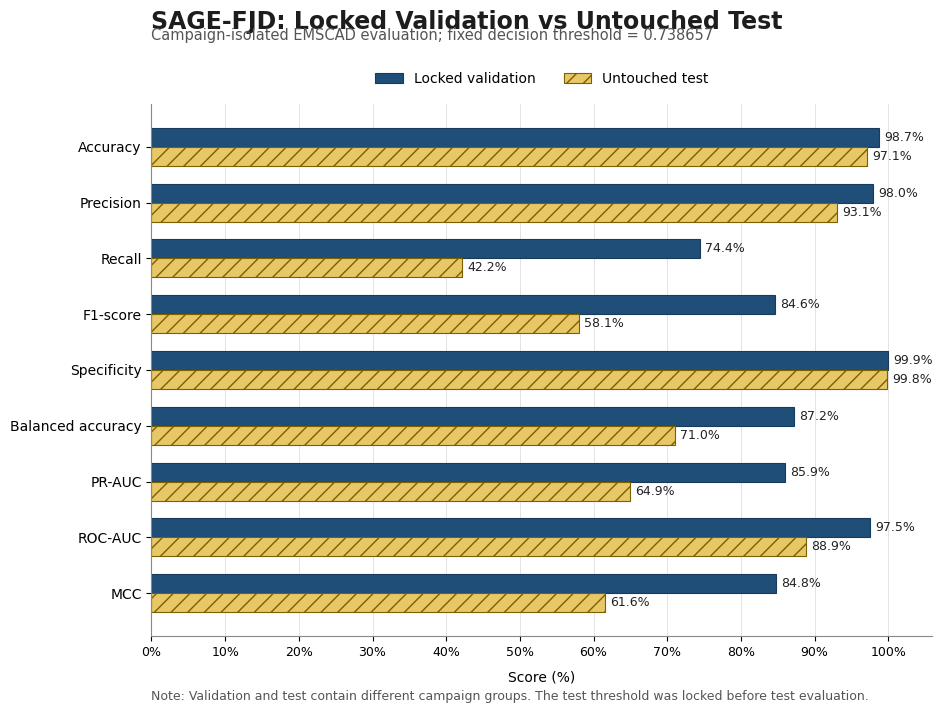


PAPER FIGURE 1 CREATED
PNG: /kaggle/working/sage_fjd_paper_figures/figure_01_validation_vs_test.png
PDF: /kaggle/working/sage_fjd_paper_figures/figure_01_validation_vs_test.pdf
SVG: /kaggle/working/sage_fjd_paper_figures/figure_01_validation_vs_test.svg
Caption: /kaggle/working/sage_fjd_paper_figures/figure_01_caption.txt
PNG dimensions: 2825 x 2138
Metric values: VERIFIED
No model training was performed.
No threshold was changed.


In [81]:
# ================================================================
# PAPER FIGURE 1
# SAGE-FJD LOCKED VALIDATION VS UNTOUCHED TEST
# ================================================================

import os
from pathlib import Path

os.environ["MPLCONFIGDIR"] = (
    "/kaggle/working/matplotlib_cache"
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


# ------------------------------------------------
# 1. Load the verified generalisation-gap table
# ------------------------------------------------

expected_path = Path(
    "/kaggle/working/sage_fjd_final_results/"
    "sage_fjd_generalisation_gap.csv"
)

if expected_path.exists():

    gap_path = expected_path

else:

    matches = list(
        Path("/kaggle").rglob(
            "sage_fjd_generalisation_gap.csv"
        )
    )

    if not matches:
        raise FileNotFoundError(
            "Generalisation-gap table was not found. "
            "Run the final master-results cell first."
        )

    gap_path = matches[0]

generalisation_gap = pd.read_csv(
    gap_path
)

print("Source:", gap_path)


# ------------------------------------------------
# 2. Validate the exact locked results
# ------------------------------------------------

metric_order = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC",
    "MCC"
]

expected_validation = np.array([
    0.9869158878504672,
    0.9795918367346940,
    0.7441860465116279,
    0.8458149779735683,
    0.9992144540455616,
    0.8717002502785948,
    0.8593987487787348,
    0.9747772764086544,
    0.8477672919621270
])

expected_test = np.array([
    0.9708955223880597,
    0.9310344827586208,
    0.4218750000000000,
    0.5806451612903226,
    0.9984326018808778,
    0.7101538009404389,
    0.6488705114016479,
    0.8885096248040752,
    0.6160021448346304
])

required_columns = {
    "Metric",
    "Locked_Validation",
    "Untouched_Test"
}

missing_columns = (
    required_columns
    - set(generalisation_gap.columns)
)

if missing_columns:
    raise KeyError(
        "Missing columns: "
        + ", ".join(sorted(missing_columns))
    )

if generalisation_gap["Metric"].duplicated().any():
    raise ValueError(
        "Duplicate metrics were found."
    )

plot_data = (
    generalisation_gap
    .set_index("Metric")
    .loc[metric_order]
    .reset_index()
)

validation_values = (
    plot_data["Locked_Validation"]
    .to_numpy(dtype=float)
)

test_values = (
    plot_data["Untouched_Test"]
    .to_numpy(dtype=float)
)

if not np.allclose(
    validation_values,
    expected_validation
):
    raise ValueError(
        "Locked validation values do not match "
        "the verified Run 4 results."
    )

if not np.allclose(
    test_values,
    expected_test
):
    raise ValueError(
        "Untouched-test values do not match "
        "the verified Run 5 results."
    )


# ------------------------------------------------
# 3. Prepare paper-friendly labels
# ------------------------------------------------

label_map = {
    "Accuracy": "Accuracy",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1": "F1-score",
    "Specificity": "Specificity",
    "Balanced_Accuracy": "Balanced accuracy",
    "PR_AUC": "PR-AUC",
    "ROC_AUC": "ROC-AUC",
    "MCC": "MCC"
}

plot_data["Display_Label"] = (
    plot_data["Metric"].map(label_map)
)

validation_percent = (
    plot_data["Locked_Validation"]
    * 100
)

test_percent = (
    plot_data["Untouched_Test"]
    * 100
)


# ------------------------------------------------
# 4. Create the grouped horizontal bar chart
# ------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 16,
    "axes.labelsize": 10
})

positions = np.arange(
    len(plot_data)
)

bar_height = 0.34

figure, axis = plt.subplots(
    figsize=(11, 7.5),
    facecolor="white"
)

validation_bars = axis.barh(
    positions - bar_height / 2,
    validation_percent,
    height=bar_height,
    color="#1F4E79",
    edgecolor="#173B5C",
    linewidth=0.8,
    label="Locked validation"
)

test_bars = axis.barh(
    positions + bar_height / 2,
    test_percent,
    height=bar_height,
    color="#E8C766",
    edgecolor="#7C5F00",
    linewidth=0.8,
    hatch="//",
    label="Untouched test"
)


# ------------------------------------------------
# 5. Add exact percentage labels
# ------------------------------------------------

for bars in [
    validation_bars,
    test_bars
]:

    for bar in bars:

        bar_value = bar.get_width()

        axis.text(
            bar_value + 0.7,
            (
                bar.get_y()
                + bar.get_height() / 2
            ),
            f"{bar_value:.1f}%",
            va="center",
            ha="left",
            fontsize=9,
            color="#222222"
        )


# ------------------------------------------------
# 6. Format axes and titles
# ------------------------------------------------

axis.set_yticks(positions)

axis.set_yticklabels(
    plot_data["Display_Label"],
    fontsize=10
)

axis.invert_yaxis()

# Honest zero-based percentage scale
axis.set_xlim(0, 106)

axis.set_xticks(
    np.arange(0, 101, 10)
)

axis.set_xticklabels(
    [
        f"{value}%"
        for value in np.arange(0, 101, 10)
    ],
    fontsize=9
)

axis.set_xlabel(
    "Score (%)",
    labelpad=8
)

axis.grid(
    axis="x",
    color="#D9D9D9",
    linewidth=0.7,
    alpha=0.75
)

axis.set_axisbelow(True)

axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.spines["left"].set_color(
    "#888888"
)

axis.spines["bottom"].set_color(
    "#888888"
)

figure.suptitle(
    "SAGE-FJD: Locked Validation vs Untouched Test",
    x=0.24,
    y=0.965,
    ha="left",
    fontsize=17,
    fontweight="bold",
    color="#1D1D1F"
)

figure.text(
    0.24,
    0.925,
    (
        "Campaign-isolated EMSCAD evaluation; "
        "fixed decision threshold = 0.738657"
    ),
    ha="left",
    fontsize=10.5,
    color="#555555"
)

axis.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
    fontsize=10
)

figure.text(
    0.24,
    0.045,
    (
        "Note: Validation and test contain different "
        "campaign groups. The test threshold was "
        "locked before test evaluation."
    ),
    ha="left",
    fontsize=9,
    color="#555555"
)

figure.subplots_adjust(
    left=0.24,
    right=0.95,
    top=0.84,
    bottom=0.13
)


# ------------------------------------------------
# 7. Save publication-quality files
# ------------------------------------------------

output_directory = Path(
    "/kaggle/working/sage_fjd_paper_figures"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

png_path = (
    output_directory
    / "figure_01_validation_vs_test.png"
)

pdf_path = (
    output_directory
    / "figure_01_validation_vs_test.pdf"
)

svg_path = (
    output_directory
    / "figure_01_validation_vs_test.svg"
)

figure.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

figure.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

figure.savefig(
    svg_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(figure)


# ------------------------------------------------
# 8. Save the paper caption
# ------------------------------------------------

caption = (
    "Figure 1. Performance of SAGE-FJD on the locked "
    "validation and untouched campaign-isolated test sets. "
    "Although accuracy and specificity remained high, "
    "recall, F1-score, PR-AUC and MCC decreased "
    "substantially on unseen campaign groups."
)

caption_path = (
    output_directory
    / "figure_01_caption.txt"
)

caption_path.write_text(
    caption,
    encoding="utf-8"
)


# ------------------------------------------------
# 9. Verify exported files
# ------------------------------------------------

with Image.open(png_path) as image_file:

    image_width, image_height = (
        image_file.size
    )

if image_width < 2000:
    raise ValueError(
        "PNG resolution is too low."
    )

for output_file in [
    png_path,
    pdf_path,
    svg_path,
    caption_path
]:

    if (
        not output_file.exists()
        or output_file.stat().st_size == 0
    ):
        raise ValueError(
            f"Export failed: {output_file}"
        )

print("\n" + "=" * 72)
print("PAPER FIGURE 1 CREATED")
print("=" * 72)
print("PNG:", png_path)
print("PDF:", pdf_path)
print("SVG:", svg_path)
print("Caption:", caption_path)
print(
    "PNG dimensions:",
    f"{image_width} x {image_height}"
)
print("Metric values: VERIFIED")
print("No model training was performed.")
print("No threshold was changed.")
print("=" * 72)

In [82]:
"""
SAGE-FJD research-paper figure generator.

Run this as one Kaggle notebook cell after adding these files/datasets as inputs:
  1) fake_job_postings.csv (Shivam Bansal EMSCAD dataset)
  2) sage_fjd_run_04_validation_checkpoint.zip
  3) sage_fjd_run_05_final_test_checkpoint.zip

The cell validates the locked results, creates publication-ready figures in
PNG/PDF/SVG, writes chart-source CSVs and captions, and packages everything
inside one downloadable ZIP. It does not train a model or tune a threshold.
"""

# ================================================================
# 0. IMPORTS AND OUTPUT LOCATIONS
# ================================================================

from __future__ import annotations

import hashlib
import io
import json
import math
import os
import re
import sys
import textwrap
import warnings
import zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

IS_KAGGLE = Path("/kaggle/working").exists()
WORKING_ROOT = Path("/kaggle/working") if IS_KAGGLE else Path("/tmp")
PACKAGE_ROOT = WORKING_ROOT / "SAGE_FJD_Research_Paper_Graphs_Package"
FIGURE_DIR = PACKAGE_ROOT / "figures"
TABLE_DIR = PACKAGE_ROOT / "source_tables"
DOC_DIR = PACKAGE_ROOT / "documentation"
ZIP_PATH = WORKING_ROOT / "SAGE_FJD_Research_Paper_Graphs.zip"

for directory in (PACKAGE_ROOT, FIGURE_DIR, TABLE_DIR, DOC_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Search Kaggle inputs and working files. The local fallback is only for QA.
if IS_KAGGLE:
    SEARCH_ROOTS = [Path("/kaggle/working"), Path("/kaggle/input")]
else:
    SEARCH_ROOTS = [Path.cwd() / "upload", Path.cwd(), Path("/tmp")]

print("=" * 78)
print("SAGE-FJD — COMPLETE RESEARCH-PAPER FIGURE GENERATOR")
print("=" * 78)
print("Output package:", PACKAGE_ROOT)
print("Final ZIP:", ZIP_PATH)
print("No model training will be performed.")
print("No validation/test threshold will be changed.")


# ================================================================
# 1. ROBUST ARTIFACT DISCOVERY (DIRECT FILE OR FILE INSIDE ZIP)
# ================================================================

_DIRECT_CACHE: dict[str, list[Path]] = {}
_ZIP_CACHE: dict[str, list[tuple[Path, str]]] = {}
_SOURCE_RECORDS: list[dict[str, str]] = []


def _root_priority(path: Path) -> tuple[int, int, str]:
    """Prefer /kaggle/working, then checkpoint-named paths, then others."""
    text = str(path).lower()
    return (
        0 if "/kaggle/working" in text else 1,
        0 if "checkpoint" in text else 1,
        len(text),
    )


def _find_direct(filename: str) -> list[Path]:
    if filename in _DIRECT_CACHE:
        return _DIRECT_CACHE[filename]

    matches: list[Path] = []
    exact_known = [
        Path("/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction")
        / filename,
        Path("/kaggle/working") / filename,
        Path.cwd() / "upload" / filename,
        Path.cwd() / filename,
    ]
    for candidate in exact_known:
        if candidate.is_file():
            matches.append(candidate)

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            matches.extend(p for p in root.rglob(filename) if p.is_file())
        except (PermissionError, OSError):
            pass

    unique = sorted(set(matches), key=_root_priority)
    _DIRECT_CACHE[filename] = unique
    return unique


def _find_inside_zip(filename: str) -> list[tuple[Path, str]]:
    if filename in _ZIP_CACHE:
        return _ZIP_CACHE[filename]

    candidates: list[tuple[Path, str]] = []
    zip_paths: list[Path] = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            zip_paths.extend(p for p in root.rglob("*.zip") if p.is_file())
        except (PermissionError, OSError):
            pass

    for zip_path in sorted(set(zip_paths), key=_root_priority):
        try:
            with zipfile.ZipFile(zip_path) as archive:
                for member in archive.namelist():
                    if Path(member).name == filename:
                        candidates.append((zip_path, member))
        except (zipfile.BadZipFile, PermissionError, OSError):
            continue

    _ZIP_CACHE[filename] = candidates
    return candidates


def read_bytes_artifact(filename: str) -> tuple[bytes, str]:
    direct = _find_direct(filename)
    if direct:
        source = direct[0]
        payload = source.read_bytes()
        location = str(source)
    else:
        zipped = _find_inside_zip(filename)
        if not zipped:
            raise FileNotFoundError(
                f"Required artifact '{filename}' was not found directly or inside a ZIP.\n"
                "Add the Run-4 and Run-5 checkpoint ZIP files to Kaggle Input."
            )
        zip_path, member = zipped[0]
        with zipfile.ZipFile(zip_path) as archive:
            payload = archive.read(member)
        location = f"{zip_path}::{member}"

    _SOURCE_RECORDS.append({"Artifact": filename, "Loaded_From": location})
    return payload, location


def read_csv_artifact(filename: str, **kwargs) -> tuple[pd.DataFrame, str]:
    payload, source = read_bytes_artifact(filename)
    return pd.read_csv(io.BytesIO(payload), **kwargs), source


def require_columns(frame: pd.DataFrame, expected: list[str], name: str) -> None:
    missing = [column for column in expected if column not in frame.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


def assert_close(actual: float, expected: float, label: str, atol: float = 1e-9) -> None:
    if not np.isclose(float(actual), float(expected), atol=atol, rtol=0):
        raise ValueError(
            f"Locked-result verification failed for {label}: "
            f"expected {expected}, found {actual}."
        )


# ================================================================
# 2. LOAD AND VERIFY ALL LOCKED EVIDENCE
# ================================================================

raw_df, raw_source = read_csv_artifact("fake_job_postings.csv", low_memory=False)
validation_metrics, validation_metrics_source = read_csv_artifact(
    "sage_fjd_locked_validation_metrics.csv"
)
baseline_comparison, baseline_source = read_csv_artifact(
    "sage_fjd_validation_vs_baselines.csv"
)
validation_predictions, validation_predictions_source = read_csv_artifact(
    "sage_fjd_locked_validation_evaluated_predictions.csv"
)
test_metrics, test_metrics_source = read_csv_artifact(
    "sage_fjd_one_time_test_metrics.csv"
)
test_predictions, test_predictions_source = read_csv_artifact(
    "sage_fjd_one_time_test_predictions.csv"
)

require_columns(
    raw_df,
    [
        "job_id", "title", "location", "department", "salary_range",
        "company_profile", "description", "requirements", "benefits",
        "telecommuting", "has_company_logo", "has_questions",
        "employment_type", "required_experience", "required_education",
        "industry", "function", "fraudulent",
    ],
    "EMSCAD dataset",
)

metric_columns = [
    "Model", "Evaluation_Split", "Threshold_Type", "Threshold", "Accuracy",
    "Precision", "Recall", "F1", "Specificity", "Balanced_Accuracy",
    "PR_AUC", "ROC_AUC", "MCC", "TN", "FP", "FN", "TP",
]
require_columns(validation_metrics, metric_columns, "validation metrics")
require_columns(
    test_metrics,
    [column for column in metric_columns if column != "Threshold_Type"]
    + ["Threshold_Source"],
    "test metrics",
)
require_columns(
    baseline_comparison,
    [
        "Metric", "Current_Leakage_Safe_Best", "SAGE_FJD_Validation",
        "Difference", "Beat_Baseline",
    ],
    "baseline comparison",
)
require_columns(
    validation_predictions,
    [
        "source_row_index", "job_id", "fraudulent",
        "sage_fjd_fusion_probability", "locked_prediction",
    ],
    "validation predictions",
)
require_columns(
    test_predictions,
    [
        "source_row_index", "job_id", "fraudulent", "lexical_calibrated",
        "metadata_calibrated", "semantic_calibrated", "campaign_calibrated",
        "sage_fjd_fusion_probability", "locked_threshold",
        "sage_fjd_prediction",
    ],
    "test predictions",
)

if len(raw_df) != 17880 or int(raw_df["fraudulent"].sum()) != 866:
    raise ValueError(
        "The EMSCAD dataset does not match the locked study population "
        "(expected 17,880 rows and 866 fraudulent postings)."
    )

validation_fusion = validation_metrics.loc[
    (validation_metrics["Model"] == "SAGE-FJD Fusion")
    & (validation_metrics["Threshold_Type"] == "Locked validation policy")
].copy()
if len(validation_fusion) != 1:
    raise ValueError("Exactly one locked SAGE-FJD validation row was expected.")
validation_fusion = validation_fusion.iloc[0]

test_fusion = test_metrics.loc[test_metrics["Model"] == "SAGE-FJD Fusion"].copy()
if len(test_fusion) != 1:
    raise ValueError("Exactly one SAGE-FJD untouched-test row was expected.")
test_fusion = test_fusion.iloc[0]

LOCKED_THRESHOLD = 0.7386570124651071
assert_close(validation_fusion["Threshold"], LOCKED_THRESHOLD, "validation threshold")
assert_close(test_fusion["Threshold"], LOCKED_THRESHOLD, "test threshold")
assert_close(validation_fusion["Accuracy"], 0.9869158878504672, "validation accuracy")
assert_close(validation_fusion["F1"], 0.8458149779735683, "validation F1")
assert_close(test_fusion["Accuracy"], 0.9708955223880597, "test accuracy")
assert_close(test_fusion["F1"], 0.5806451612903226, "test F1")

if len(validation_predictions) != 2675 or int(validation_predictions["fraudulent"].sum()) != 129:
    raise ValueError("Locked validation predictions must contain 2,675 rows and 129 fraud cases.")
if len(test_predictions) != 2680 or int(test_predictions["fraudulent"].sum()) != 128:
    raise ValueError("Untouched test predictions must contain 2,680 rows and 128 fraud cases.")

# Independently reproduce the two curve metrics from row-level predictions.
val_y = validation_predictions["fraudulent"].astype(int).to_numpy()
val_score = validation_predictions["sage_fjd_fusion_probability"].astype(float).to_numpy()
test_y = test_predictions["fraudulent"].astype(int).to_numpy()
test_score = test_predictions["sage_fjd_fusion_probability"].astype(float).to_numpy()

assert_close(roc_auc_score(val_y, val_score), validation_fusion["ROC_AUC"], "validation ROC-AUC", 1e-8)
assert_close(average_precision_score(val_y, val_score), validation_fusion["PR_AUC"], "validation PR-AUC", 1e-8)
assert_close(roc_auc_score(test_y, test_score), test_fusion["ROC_AUC"], "test ROC-AUC", 1e-8)
assert_close(average_precision_score(test_y, test_score), test_fusion["PR_AUC"], "test PR-AUC", 1e-8)

print("\nLOCKED EVIDENCE VERIFIED")
print("Dataset rows:", len(raw_df))
print("Validation rows:", len(validation_predictions))
print("Untouched test rows:", len(test_predictions))
print("Locked threshold:", f"{LOCKED_THRESHOLD:.6f}")


# ================================================================
# 3. PUBLICATION STYLE AND EXPORT HELPERS
# ================================================================

COLORS = {
    "blue": "#24557A",
    "blue_light": "#8DB8D5",
    "gold": "#E8C75A",
    "gold_dark": "#9D7A13",
    "orange": "#D97941",
    "olive": "#7B8D42",
    "pink": "#C66A82",
    "charcoal": "#252A2E",
    "gray": "#6B737A",
    "light_gray": "#E7EAED",
    "very_light": "#F7F8FA",
    "white": "#FFFFFF",
}

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 10.5,
        "axes.edgecolor": COLORS["charcoal"],
        "axes.linewidth": 0.8,
        "axes.facecolor": COLORS["white"],
        "figure.facecolor": COLORS["white"],
        "xtick.color": COLORS["charcoal"],
        "ytick.color": COLORS["charcoal"],
        "text.color": COLORS["charcoal"],
        "grid.color": COLORS["light_gray"],
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "savefig.facecolor": COLORS["white"],
        "savefig.bbox": "tight",
    }
)

figure_records: list[dict[str, str | int]] = []


def clean_axes(axis: plt.Axes, grid_axis: str | None = "y") -> None:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    if grid_axis:
        axis.grid(axis=grid_axis, alpha=0.9)
        axis.set_axisbelow(True)


def add_title(
    fig: plt.Figure,
    title: str,
    subtitle: str,
    left: float = 0.08,
    top: float = 0.965,
) -> None:
    fig.text(left, top, title, ha="left", va="top", fontsize=16, fontweight="bold")
    fig.text(
        left,
        top - 0.044,
        subtitle,
        ha="left",
        va="top",
        fontsize=10,
        color=COLORS["gray"],
    )


def save_source_table(number: int, slug: str, frame: pd.DataFrame) -> Path:
    path = TABLE_DIR / f"Figure_{number:02d}_{slug}_data.csv"
    frame.to_csv(path, index=False)
    return path


def save_figure(
    fig: plt.Figure,
    number: int,
    slug: str,
    title: str,
    caption: str,
    source_note: str,
) -> None:
    stem = f"Figure_{number:02d}_{slug}"
    for extension in ("png", "pdf", "svg"):
        path = FIGURE_DIR / f"{stem}.{extension}"
        kwargs = {"dpi": 300} if extension == "png" else {}
        fig.savefig(path, **kwargs)
        if not path.exists() or path.stat().st_size < 1_000:
            raise RuntimeError(f"Figure export failed: {path}")
    plt.close(fig)
    figure_records.append(
        {
            "Figure": number,
            "Filename_Stem": stem,
            "Title": title,
            "Caption": caption,
            "Source": source_note,
        }
    )


def label_vertical_bars(axis: plt.Axes, bars, fmt: str = "{:.1f}%", pad: float = 3) -> None:
    for bar in bars:
        value = bar.get_height()
        axis.annotate(
            fmt.format(value),
            (bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color=COLORS["charcoal"],
        )


def label_horizontal_bars(axis: plt.Axes, bars, fmt: str = "{:.1f}%") -> None:
    for bar in bars:
        value = bar.get_width()
        axis.annotate(
            fmt.format(value),
            (value, bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
            color=COLORS["charcoal"],
        )


# ================================================================
# 4. FIGURE 1 — CLASS DISTRIBUTION
# ================================================================

class_counts = (
    raw_df["fraudulent"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("fraudulent")
    .reset_index(name="Count")
)
class_counts["Class"] = class_counts["fraudulent"].map({0: "Genuine", 1: "Fraudulent"})
class_counts["Percentage"] = class_counts["Count"] / len(raw_df) * 100
save_source_table(1, "class_distribution", class_counts)

fig, ax = plt.subplots(figsize=(8.8, 5.6))
fig.subplots_adjust(top=0.78, left=0.12, right=0.94, bottom=0.16)
bars = ax.bar(
    class_counts["Class"],
    class_counts["Count"],
    color=[COLORS["blue"], COLORS["gold"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.7,
    width=0.58,
)
for bar, count, pct in zip(bars, class_counts["Count"], class_counts["Percentage"]):
    ax.annotate(
        f"{count:,}\n({pct:.2f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax.set_ylabel("Number of job postings")
ax.set_ylim(0, class_counts["Count"].max() * 1.14)
clean_axes(ax, "y")
add_title(
    fig,
    "EMSCAD class distribution",
    "17,880 job postings; the fraudulent class represents 4.84% of the dataset",
)
save_figure(
    fig,
    1,
    "class_distribution",
    "EMSCAD class distribution",
    "Distribution of genuine and fraudulent postings in the EMSCAD dataset. The severe class imbalance motivates fraud-focused metrics in addition to accuracy.",
    f"EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 5. FIGURE 2 — MISSING-VALUE PROFILE
# ================================================================

missing = raw_df.isna().sum().rename("Missing_Count").reset_index()
missing.columns = ["Feature", "Missing_Count"]
missing["Missing_Percentage"] = missing["Missing_Count"] / len(raw_df) * 100
missing = missing.loc[missing["Missing_Count"] > 0].sort_values("Missing_Percentage")
save_source_table(2, "missing_values", missing)

fig, ax = plt.subplots(figsize=(10.6, 7.2))
fig.subplots_adjust(top=0.84, left=0.25, right=0.90, bottom=0.10)
bars = ax.barh(
    missing["Feature"],
    missing["Missing_Percentage"],
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
label_horizontal_bars(ax, bars, "{:.2f}%")
ax.set_xlabel("Missing values (%)")
ax.set_xlim(0, max(90, missing["Missing_Percentage"].max() + 8))
clean_axes(ax, "x")
add_title(
    fig,
    "Missing values across EMSCAD fields",
    "Percentage of all 17,880 postings; only fields containing at least one missing value are shown",
    left=0.07,
)
save_figure(
    fig,
    2,
    "missing_values",
    "Missing values across EMSCAD fields",
    "Missing-value prevalence for EMSCAD features. Salary range and department have the largest missingness, while description is almost complete.",
    f"Computed from EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 6. FIGURE 3 — FRAUD RATES FOR BINARY METADATA SIGNALS
# ================================================================

binary_labels = {
    "telecommuting": "Telecommuting",
    "has_company_logo": "Company logo",
    "has_questions": "Screening questions",
}
binary_rows = []
for column, display_name in binary_labels.items():
    summary = raw_df.groupby(column, dropna=False)["fraudulent"].agg(["size", "sum"]).reset_index()
    for _, row in summary.iterrows():
        present = int(row[column])
        binary_rows.append(
            {
                "Feature": display_name,
                "Value": present,
                "Status": "Present" if present == 1 else "Absent",
                "Total_Posts": int(row["size"]),
                "Fraudulent_Posts": int(row["sum"]),
                "Fraud_Rate_Percentage": float(row["sum"] / row["size"] * 100),
            }
        )
binary_summary = pd.DataFrame(binary_rows)
save_source_table(3, "binary_metadata_fraud_rates", binary_summary)

feature_order = list(binary_labels.values())
absent = binary_summary.query("Status == 'Absent'").set_index("Feature").loc[feature_order]
present = binary_summary.query("Status == 'Present'").set_index("Feature").loc[feature_order]
x = np.arange(len(feature_order))
width = 0.34

fig, ax = plt.subplots(figsize=(10.4, 6.0))
fig.subplots_adjust(top=0.79, left=0.12, right=0.95, bottom=0.18)
bars_a = ax.bar(
    x - width / 2,
    absent["Fraud_Rate_Percentage"],
    width,
    label="Absent",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
bars_p = ax.bar(
    x + width / 2,
    present["Fraud_Rate_Percentage"],
    width,
    label="Present",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_vertical_bars(ax, bars_a)
label_vertical_bars(ax, bars_p)
ax.set_xticks(x, feature_order)
ax.set_ylabel("Fraud rate (%)")
ax.set_ylim(0, max(binary_summary["Fraud_Rate_Percentage"].max() * 1.20, 18))
ax.legend(loc="upper right", ncol=2)
clean_axes(ax, "y")
add_title(
    fig,
    "Fraud rates for binary posting signals",
    "Within-group fraudulent-posting rate for three EMSCAD metadata fields",
)
save_figure(
    fig,
    3,
    "binary_metadata_fraud_rates",
    "Fraud rates for binary posting signals",
    "Fraud rates by the presence or absence of telecommuting, a company logo, and screening questions. Missing company logos show the strongest univariate association with fraud.",
    f"Computed from EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 7. FIGURE 4 — STANDARD VS LEAKAGE-SAFE SPLIT AUDIT
# ================================================================

split_audit = pd.DataFrame(
    [
        ["Standard", "Train", 12516, 3599],
        ["Standard", "Validation", 2682, 1246],
        ["Standard", "Test", 2682, 1203],
        ["Leakage-safe", "Train", 12525, 3210],
        ["Leakage-safe", "Validation", 2675, 688],
        ["Leakage-safe", "Test", 2680, 688],
    ],
    columns=["Protocol", "Split", "Rows", "Campaign_Groups"],
)
crossing_audit = pd.DataFrame(
    {
        "Protocol": ["Standard", "Leakage-safe"],
        "Campaign_Groups_Crossing_Splits": [983, 0],
    }
)
save_source_table(4, "split_counts", split_audit)
crossing_audit.to_csv(TABLE_DIR / "Figure_04_campaign_crossing_data.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.9), gridspec_kw={"width_ratios": [1.45, 1]})
fig.subplots_adjust(top=0.78, left=0.08, right=0.96, bottom=0.16, wspace=0.30)

split_order = ["Train", "Validation", "Test"]
x = np.arange(len(split_order))
std_rows = split_audit.query("Protocol == 'Standard'").set_index("Split").loc[split_order, "Rows"]
safe_rows = split_audit.query("Protocol == 'Leakage-safe'").set_index("Split").loc[split_order, "Rows"]
bars1 = axes[0].bar(
    x - 0.18,
    std_rows,
    0.36,
    label="Standard",
    color=COLORS["blue_light"],
    edgecolor=COLORS["blue"],
)
bars2 = axes[0].bar(
    x + 0.18,
    safe_rows,
    0.36,
    label="Leakage-safe",
    color=COLORS["blue"],
    hatch="//",
    edgecolor=COLORS["charcoal"],
)
for bars in (bars1, bars2):
    for bar in bars:
        axes[0].annotate(
            f"{int(bar.get_height()):,}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=8.5,
        )
axes[0].set_xticks(x, split_order)
axes[0].set_ylabel("Rows")
axes[0].set_title("Split sizes", loc="left", pad=12)
axes[0].legend(loc="upper right")
clean_axes(axes[0], "y")

bars = axes[1].bar(
    crossing_audit["Protocol"],
    crossing_audit["Campaign_Groups_Crossing_Splits"],
    color=[COLORS["orange"], COLORS["gold"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.7,
    width=0.58,
)
for bar in bars:
    axes[1].annotate(
        f"{int(bar.get_height()):,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
axes[1].set_ylabel("Campaign groups crossing splits")
axes[1].set_ylim(0, 1080)
axes[1].set_title("Campaign-isolation audit", loc="left", pad=12)
clean_axes(axes[1], "y")

add_title(
    fig,
    "Standard and leakage-safe evaluation protocols",
    "Campaign grouping prevents repeated job-posting templates from appearing across train, validation, and test",
    left=0.06,
)
save_figure(
    fig,
    4,
    "split_protocol_audit",
    "Standard and leakage-safe evaluation protocols",
    "Comparison of split sizes and campaign overlap. The standard split has 983 campaign groups crossing partitions; the leakage-safe split has zero.",
    "Locked EMSCAD split manifest and campaign-isolation audit produced during baseline construction.",
)


# ================================================================
# 8. FIGURE 5 — MATCHED LEAKAGE-SAFE VALIDATION COMPARISON
# ================================================================

metric_order = [
    "Accuracy", "Precision", "Recall", "F1", "Balanced_Accuracy",
    "PR_AUC", "ROC_AUC", "MCC",
]
metric_labels = {
    "Accuracy": "Accuracy",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1": "F1-score",
    "Balanced_Accuracy": "Balanced accuracy",
    "PR_AUC": "PR-AUC",
    "ROC_AUC": "ROC-AUC",
    "MCC": "MCC",
}
matched = baseline_comparison.set_index("Metric").loc[metric_order].reset_index()
matched["Metric_Label"] = matched["Metric"].map(metric_labels)
save_source_table(5, "matched_validation_comparison", matched)

y = np.arange(len(matched))
height = 0.34
fig, ax = plt.subplots(figsize=(11.4, 7.1))
fig.subplots_adjust(top=0.83, left=0.23, right=0.91, bottom=0.11)
bars_base = ax.barh(
    y + height / 2,
    matched["Current_Leakage_Safe_Best"] * 100,
    height,
    label="Metric-wise best leakage-safe baseline",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_sage = ax.barh(
    y - height / 2,
    matched["SAGE_FJD_Validation"] * 100,
    height,
    label="SAGE-FJD validation",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_base)
label_horizontal_bars(ax, bars_sage)
ax.set_yticks(y, matched["Metric_Label"])
ax.invert_yaxis()
ax.set_xlabel("Score (%)")
ax.set_xlim(0, 106)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "SAGE-FJD versus leakage-safe validation benchmarks",
    "Matched locked-validation protocol; the benchmark is the best baseline for each individual metric, not one single model",
    left=0.06,
)
save_figure(
    fig,
    5,
    "matched_validation_comparison",
    "SAGE-FJD versus leakage-safe validation benchmarks",
    "SAGE-FJD improves 4 of 8 metric-wise leakage-safe validation benchmarks: accuracy, F1, PR-AUC, and MCC. Precision, recall, balanced accuracy, and ROC-AUC do not exceed the respective metric-wise best baselines.",
    f"Locked comparison loaded from {baseline_source}",
)


# ================================================================
# 9. FIGURE 6 — LOCKED VALIDATION VS UNTOUCHED TEST
# ================================================================

all_metric_order = metric_order[:4] + ["Specificity"] + metric_order[4:]
generalisation_rows = []
for metric in all_metric_order:
    generalisation_rows.append(
        {
            "Metric": metric,
            "Metric_Label": metric_labels.get(metric, metric),
            "Locked_Validation": float(validation_fusion[metric]),
            "Untouched_Test": float(test_fusion[metric]),
            "Gap_Test_Minus_Validation": float(test_fusion[metric] - validation_fusion[metric]),
        }
    )
generalisation = pd.DataFrame(generalisation_rows)
save_source_table(6, "validation_vs_test", generalisation)

y = np.arange(len(generalisation))
fig, ax = plt.subplots(figsize=(11.5, 7.8))
fig.subplots_adjust(top=0.82, left=0.23, right=0.90, bottom=0.13)
bars_val = ax.barh(
    y - 0.18,
    generalisation["Locked_Validation"] * 100,
    0.36,
    label="Locked validation",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_test = ax.barh(
    y + 0.18,
    generalisation["Untouched_Test"] * 100,
    0.36,
    label="Untouched test",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_val)
label_horizontal_bars(ax, bars_test)
ax.set_yticks(y, generalisation["Metric_Label"])
ax.invert_yaxis()
ax.set_xlim(0, 106)
ax.set_xlabel("Score (%)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "SAGE-FJD: locked validation versus untouched test",
    f"Campaign-isolated EMSCAD evaluation; fixed decision threshold = {LOCKED_THRESHOLD:.6f}",
    left=0.06,
)
save_figure(
    fig,
    6,
    "validation_vs_untouched_test",
    "SAGE-FJD: locked validation versus untouched test",
    "Performance under the locked validation policy and the one-time untouched campaign-isolated test. Test accuracy remains 97.09%, while recall and F1 fall to 42.19% and 58.06%, respectively.",
    f"Validation metrics: {validation_metrics_source}; test metrics: {test_metrics_source}",
)


# ================================================================
# 10. FIGURE 7 — CONFUSION MATRICES
# ================================================================

confusion_data = pd.DataFrame(
    [
        ["Locked validation", int(validation_fusion["TN"]), int(validation_fusion["FP"]), int(validation_fusion["FN"]), int(validation_fusion["TP"])],
        ["Untouched test", int(test_fusion["TN"]), int(test_fusion["FP"]), int(test_fusion["FN"]), int(test_fusion["TP"])],
    ],
    columns=["Evaluation_Split", "TN", "FP", "FN", "TP"],
)
save_source_table(7, "confusion_matrices", confusion_data)

cmap = LinearSegmentedColormap.from_list("sage_blue", [COLORS["very_light"], COLORS["blue"]])
fig, axes = plt.subplots(1, 2, figsize=(11.3, 5.7))
fig.subplots_adjust(top=0.76, left=0.09, right=0.90, bottom=0.16, wspace=0.38)
last_image = None
for axis, row in zip(axes, confusion_data.itertuples(index=False)):
    matrix = np.array([[row.TN, row.FP], [row.FN, row.TP]], dtype=float)
    normalized = matrix / matrix.sum(axis=1, keepdims=True)
    last_image = axis.imshow(normalized, cmap=cmap, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            text_color = COLORS["white"] if normalized[i, j] > 0.55 else COLORS["charcoal"]
            axis.text(
                j,
                i,
                f"{int(matrix[i, j]):,}\n({normalized[i, j] * 100:.1f}%)",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color=text_color,
            )
    axis.set_xticks([0, 1], ["Predicted\ngenuine", "Predicted\nfraud"])
    axis.set_yticks([0, 1], ["Actual genuine", "Actual fraud"])
    axis.set_title(row.Evaluation_Split, pad=12)
    axis.set_xlabel("Prediction")
    axis.set_ylabel("Actual class")

cbar_ax = fig.add_axes([0.925, 0.18, 0.018, 0.54])
colorbar = fig.colorbar(last_image, cax=cbar_ax)
colorbar.set_label("Row-normalized proportion")
add_title(
    fig,
    "Confusion matrices at the locked threshold",
    "Cell labels show counts and row percentages; fraud recall is the lower-right cell",
    left=0.06,
)
save_figure(
    fig,
    7,
    "confusion_matrices",
    "Confusion matrices at the locked threshold",
    "Row-normalized confusion matrices for locked validation and untouched test. The model produces few false positives but misses 74 of 128 fraud cases in the untouched test.",
    f"Validation and test metrics loaded from {validation_metrics_source} and {test_metrics_source}",
)


# ================================================================
# 11. FIGURE 8 — ROC CURVES
# ================================================================

val_fpr, val_tpr, val_roc_thresholds = roc_curve(val_y, val_score)
test_fpr, test_tpr, test_roc_thresholds = roc_curve(test_y, test_score)
roc_table = pd.concat(
    [
        pd.DataFrame({"Split": "Locked validation", "FPR": val_fpr, "TPR": val_tpr, "Threshold": val_roc_thresholds}),
        pd.DataFrame({"Split": "Untouched test", "FPR": test_fpr, "TPR": test_tpr, "Threshold": test_roc_thresholds}),
    ],
    ignore_index=True,
)
save_source_table(8, "roc_curves", roc_table)

fig, ax = plt.subplots(figsize=(8.4, 6.8))
fig.subplots_adjust(top=0.79, left=0.13, right=0.95, bottom=0.14)
ax.plot(
    val_fpr,
    val_tpr,
    color=COLORS["blue"],
    linewidth=2.4,
    label=f"Locked validation (AUC = {validation_fusion['ROC_AUC']:.3f})",
)
ax.plot(
    test_fpr,
    test_tpr,
    color=COLORS["gold_dark"],
    linewidth=2.2,
    linestyle="--",
    label=f"Untouched test (AUC = {test_fusion['ROC_AUC']:.3f})",
)
ax.plot([0, 1], [0, 1], color=COLORS["gray"], linestyle=":", linewidth=1.5, label="Chance")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.legend(loc="lower right")
clean_axes(ax, "both")
add_title(
    fig,
    "Receiver operating characteristic curves",
    "SAGE-FJD fusion probabilities on locked validation and the one-time untouched test",
    left=0.07,
)
save_figure(
    fig,
    8,
    "roc_curves",
    "Receiver operating characteristic curves",
    "ROC curves for locked validation and untouched test. Ranking performance remains high on the test set (ROC-AUC 0.889), although the fixed operating threshold yields lower fraud recall.",
    f"Row-level probabilities: {validation_predictions_source}; {test_predictions_source}",
)


# ================================================================
# 12. FIGURE 9 — PRECISION–RECALL CURVES
# ================================================================

val_precision_curve, val_recall_curve, val_pr_thresholds = precision_recall_curve(val_y, val_score)
test_precision_curve, test_recall_curve, test_pr_thresholds = precision_recall_curve(test_y, test_score)

def _pr_frame(split: str, precision_values, recall_values, thresholds) -> pd.DataFrame:
    threshold_values = np.r_[thresholds, np.nan]
    return pd.DataFrame(
        {
            "Split": split,
            "Recall": recall_values,
            "Precision": precision_values,
            "Threshold": threshold_values,
        }
    )

pr_table = pd.concat(
    [
        _pr_frame("Locked validation", val_precision_curve, val_recall_curve, val_pr_thresholds),
        _pr_frame("Untouched test", test_precision_curve, test_recall_curve, test_pr_thresholds),
    ],
    ignore_index=True,
)
save_source_table(9, "precision_recall_curves", pr_table)

fig, ax = plt.subplots(figsize=(8.4, 6.8))
fig.subplots_adjust(top=0.79, left=0.13, right=0.95, bottom=0.14)
ax.plot(
    val_recall_curve,
    val_precision_curve,
    color=COLORS["blue"],
    linewidth=2.4,
    label=f"Locked validation (AP = {validation_fusion['PR_AUC']:.3f})",
)
ax.plot(
    test_recall_curve,
    test_precision_curve,
    color=COLORS["gold_dark"],
    linewidth=2.2,
    linestyle="--",
    label=f"Untouched test (AP = {test_fusion['PR_AUC']:.3f})",
)
val_prevalence = val_y.mean()
test_prevalence = test_y.mean()
ax.axhline(val_prevalence, color=COLORS["blue_light"], linestyle=":", linewidth=1.2, label=f"Validation prevalence ({val_prevalence:.1%})")
ax.axhline(test_prevalence, color=COLORS["gold"], linestyle="-.", linewidth=1.2, label=f"Test prevalence ({test_prevalence:.1%})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right", fontsize=8.8)
clean_axes(ax, "both")
add_title(
    fig,
    "Precision–recall curves",
    "SAGE-FJD fusion probabilities; average precision is reported in the legend",
    left=0.07,
)
save_figure(
    fig,
    9,
    "precision_recall_curves",
    "Precision–recall curves",
    "Precision–recall curves for locked validation and untouched test. Average precision decreases from 0.859 to 0.649 under the campaign-isolated test, indicating a generalization gap for the minority fraud class.",
    f"Row-level probabilities: {validation_predictions_source}; {test_predictions_source}",
)


# ================================================================
# 13. FIGURE 10 — UNTOUCHED-TEST BRANCH PERFORMANCE
# ================================================================

branch_order = ["SAGE-FJD Fusion", "Lexical", "Metadata", "Semantic", "Campaign"]
branch_metrics = ["Recall", "F1", "PR_AUC", "MCC"]
branch_table = test_metrics.set_index("Model").loc[branch_order].reset_index()
branch_table = branch_table[["Model"] + branch_metrics]
save_source_table(10, "test_branch_performance", branch_table)

matrix = branch_table[branch_metrics].to_numpy(dtype=float)
branch_cmap = LinearSegmentedColormap.from_list(
    "sage_heat", [COLORS["very_light"], COLORS["blue_light"], COLORS["blue"]]
)
fig, ax = plt.subplots(figsize=(9.5, 6.0))
fig.subplots_adjust(top=0.77, left=0.22, right=0.91, bottom=0.15)
image = ax.imshow(matrix, cmap=branch_cmap, vmin=0, vmax=1, aspect="auto")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{matrix[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold" if i == 0 else "normal",
            color=COLORS["white"] if matrix[i, j] > 0.68 else COLORS["charcoal"],
        )
ax.set_xticks(range(len(branch_metrics)), ["Recall", "F1-score", "PR-AUC", "MCC"])
ax.set_yticks(range(len(branch_order)), branch_order)
ax.tick_params(length=0)
cbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Score")
add_title(
    fig,
    "Untouched-test performance by SAGE-FJD branch",
    "Campaign-isolated test set; all branches use their frozen thresholds and configurations",
    left=0.06,
)
save_figure(
    fig,
    10,
    "test_branch_performance",
    "Untouched-test performance by SAGE-FJD branch",
    "Fraud-focused metrics for the fusion model and four component branches on the untouched test. Fusion has the highest precision and PR-AUC, while the campaign branch has the highest single-branch recall.",
    f"One-time test metrics loaded from {test_metrics_source}",
)


# ================================================================
# 14. RECONSTRUCT TEST ERRORS FOR FIGURES 11–12
# ================================================================

raw_indexed = raw_df.reset_index().rename(columns={"index": "source_row_index"})
test_analysis = test_predictions.merge(
    raw_indexed,
    on="source_row_index",
    how="left",
    validate="one_to_one",
    suffixes=("_prediction", "_dataset"),
)
if test_analysis["job_id_dataset"].isna().any():
    raise ValueError("Some test predictions could not be aligned to EMSCAD source rows.")
if not np.array_equal(
    test_analysis["job_id_prediction"].astype(int).to_numpy(),
    test_analysis["job_id_dataset"].astype(int).to_numpy(),
):
    raise ValueError("Test job_id alignment failed.")
if not np.array_equal(
    test_analysis["fraudulent_prediction"].astype(int).to_numpy(),
    test_analysis["fraudulent_dataset"].astype(int).to_numpy(),
):
    raise ValueError("Test-label alignment failed.")

fraud = test_analysis["fraudulent_prediction"].astype(int)
prediction = test_analysis["sage_fjd_prediction"].astype(int)
false_negatives = test_analysis.loc[(fraud == 1) & (prediction == 0)].copy()
false_positives = test_analysis.loc[(fraud == 0) & (prediction == 1)].copy()
if len(false_negatives) != 74 or len(false_positives) != 4:
    raise ValueError("Expected 74 false negatives and 4 false positives on the untouched test.")


# ================================================================
# 15. FIGURE 11 — FALSE-NEGATIVE RISK BANDS AND BRANCH SUPPORT
# ================================================================

fn_scores = false_negatives["sage_fjd_fusion_probability"].astype(float)
risk_counts = pd.DataFrame(
    {
        "Risk_Band": [
            "Low\n(score < 0.50)",
            "Moderate\n(0.50 to threshold − 0.05)",
            "Near threshold\n(within 0.05)",
        ],
        "Count": [
            int((fn_scores < 0.50).sum()),
            int(((fn_scores >= 0.50) & (fn_scores < LOCKED_THRESHOLD - 0.05)).sum()),
            int(((fn_scores >= LOCKED_THRESHOLD - 0.05) & (fn_scores < LOCKED_THRESHOLD)).sum()),
        ],
    }
)
risk_counts["Percentage"] = risk_counts["Count"] / len(false_negatives) * 100

support_columns = [
    "lexical_calibrated", "metadata_calibrated", "semantic_calibrated", "campaign_calibrated"
]
support_count = (false_negatives[support_columns].astype(float) >= 0.5).sum(axis=1)
support_summary = (
    support_count.value_counts().reindex([0, 1, 2, 3, 4], fill_value=0).rename_axis("Supporting_Branches").reset_index(name="Count")
)
support_summary = support_summary.loc[support_summary["Count"] > 0].copy()
support_summary["Percentage"] = support_summary["Count"] / len(false_negatives) * 100

if risk_counts["Count"].tolist() != [53, 14, 7]:
    raise ValueError("False-negative risk-band counts no longer match the locked test analysis.")
if support_summary["Count"].tolist() != [61, 10, 2, 1]:
    raise ValueError("False-negative branch-support counts no longer match the locked test analysis.")

save_source_table(11, "false_negative_risk_bands", risk_counts)
support_summary.to_csv(TABLE_DIR / "Figure_11_branch_support_data.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.1), gridspec_kw={"width_ratios": [1.25, 1]})
fig.subplots_adjust(top=0.76, left=0.07, right=0.97, bottom=0.20, wspace=0.28)

bars = axes[0].bar(
    risk_counts["Risk_Band"],
    risk_counts["Count"],
    color=[COLORS["blue"], COLORS["gold"], COLORS["orange"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
for bar, pct in zip(bars, risk_counts["Percentage"]):
    axes[0].annotate(
        f"{int(bar.get_height())}\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
axes[0].set_ylabel("False negatives")
axes[0].set_ylim(0, 60)
axes[0].set_title("Fusion-score risk bands", loc="left", pad=12)
clean_axes(axes[0], "y")

bars = axes[1].bar(
    support_summary["Supporting_Branches"].astype(str),
    support_summary["Count"],
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
for bar, pct in zip(bars, support_summary["Percentage"]):
    axes[1].annotate(
        f"{int(bar.get_height())}\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
axes[1].set_xlabel("Branches scoring ≥ 0.50")
axes[1].set_ylabel("False negatives")
axes[1].set_ylim(0, 68)
axes[1].set_title("Branch support among missed fraud", loc="left", pad=12)
clean_axes(axes[1], "y")

add_title(
    fig,
    "Untouched-test false-negative analysis",
    "74 missed fraud postings; 61 were scored below 0.50 by all four component branches",
    left=0.05,
)
save_figure(
    fig,
    11,
    "false_negative_analysis",
    "Untouched-test false-negative analysis",
    "Distribution of false negatives by fusion-score risk band and number of supporting component branches. Most missed fraud cases are not borderline threshold errors; all branches miss 82.43% of them.",
    f"Derived from untouched-test predictions loaded from {test_predictions_source}",
)


# ================================================================
# 16. FIGURE 12 — ERROR SIGNALS IN FALSE NEGATIVES AND FALSE POSITIVES
# ================================================================

# These are the frozen counts from the locked Run-5 error-analysis audit.  The
# three missingness counts are also independently rechecked against the aligned
# raw rows below.  Language-signal counts retain the exact earlier audit output
# so the paper figure cannot silently change because of a later regex rewrite.
signal_counts = {
    "Company profile missing": (43, 4),
    "Requirements missing": (4, 2),
    "Benefits missing": (22, 3),
    "Work-from-home language": (4, 2),
    "No-experience language": (3, 0),
    "Money/earning language": (48, 3),
    "WhatsApp or Telegram": (0, 0),
    "Contains URL": (0, 0),
    "Multiple exclamation marks": (2, 2),
}

missingness_checks = {
    "Company profile missing": "company_profile",
    "Requirements missing": "requirements",
    "Benefits missing": "benefits",
}
for label, column in missingness_checks.items():
    fn_missing = int(
        (false_negatives[column].isna() | false_negatives[column].fillna("").astype(str).str.strip().eq("")).sum()
    )
    fp_missing = int(
        (false_positives[column].isna() | false_positives[column].fillna("").astype(str).str.strip().eq("")).sum()
    )
    if (fn_missing, fp_missing) != signal_counts[label]:
        raise ValueError(f"Locked error-signal verification failed for {label}.")

signal_rows = []
for signal, (fn_count, fp_count) in signal_counts.items():
    signal_rows.extend(
        [
            {
                "Error_Type": "False negative",
                "Signal": signal,
                "Count": fn_count,
                "Error_Group_Rows": 74,
                "Percentage": fn_count / 74 * 100,
            },
            {
                "Error_Type": "False positive",
                "Signal": signal,
                "Count": fp_count,
                "Error_Group_Rows": 4,
                "Percentage": fp_count / 4 * 100,
            },
        ]
    )
signal_summary = pd.DataFrame(signal_rows)
save_source_table(12, "error_signals", signal_summary)

signal_order = [
    "Company profile missing", "Requirements missing", "Benefits missing",
    "Work-from-home language", "No-experience language", "Money/earning language",
    "WhatsApp or Telegram", "Contains URL", "Multiple exclamation marks",
]
fn_signal = signal_summary.query("Error_Type == 'False negative'").set_index("Signal").loc[signal_order]
fp_signal = signal_summary.query("Error_Type == 'False positive'").set_index("Signal").loc[signal_order]
y = np.arange(len(signal_order))

fig, ax = plt.subplots(figsize=(11.8, 7.5))
fig.subplots_adjust(top=0.82, left=0.28, right=0.92, bottom=0.12)
bars_fn = ax.barh(
    y - 0.18,
    fn_signal["Percentage"],
    0.36,
    label="False negatives (n = 74)",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_fp = ax.barh(
    y + 0.18,
    fp_signal["Percentage"],
    0.36,
    label="False positives (n = 4; descriptive only)",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_fn)
label_horizontal_bars(ax, bars_fp)
ax.set_yticks(y, signal_order)
ax.invert_yaxis()
ax.set_xlabel("Share of error group (%)")
ax.set_xlim(0, 108)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "Common content signals among untouched-test errors",
    "Percentages are within each error group; false-positive percentages are unstable because only four cases exist",
    left=0.06,
)
save_figure(
    fig,
    12,
    "error_signal_comparison",
    "Common content signals among untouched-test errors",
    "Selected content and missingness signals among false negatives and false positives. Money/earning language and missing company profiles are common among missed fraud postings; the false-positive percentages are descriptive because n=4.",
    f"Locked Run-5 error-analysis audit; missingness counts independently checked against EMSCAD rows aligned to {test_predictions_source}",
)


# ================================================================
# 17. FIGURE 13 — SAGE-FJD ARCHITECTURE DIAGRAM
# ================================================================


def rounded_box(
    axis: plt.Axes,
    xy: tuple[float, float],
    width: float,
    height: float,
    text: str,
    facecolor: str,
    edgecolor: str = COLORS["charcoal"],
    fontsize: float = 9.0,
    fontweight: str = "normal",
) -> FancyBboxPatch:
    x, y = xy
    patch = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.012,rounding_size=0.015",
        linewidth=1.0,
        edgecolor=edgecolor,
        facecolor=facecolor,
    )
    axis.add_patch(patch)
    axis.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight=fontweight,
        wrap=True,
    )
    return patch


def arrow(axis: plt.Axes, start: tuple[float, float], end: tuple[float, float]) -> None:
    axis.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.25,
            color=COLORS["charcoal"],
            connectionstyle="arc3,rad=0.0",
        )
    )


fig, ax = plt.subplots(figsize=(14.0, 7.7))
fig.subplots_adjust(top=0.84, left=0.03, right=0.97, bottom=0.05)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

rounded_box(
    ax,
    (0.35, 0.79),
    0.30,
    0.10,
    "EMSCAD job posting\n5 text sections + structured metadata + campaign templates",
    COLORS["very_light"],
    fontsize=10,
    fontweight="bold",
)

branch_x = [0.025, 0.275, 0.525, 0.775]
branch_text = [
    "LEXICAL BRANCH\nWord + character TF–IDF\nLinear SVM",
    "METADATA BRANCH\n56 structured/risk features\nCatBoost (233 iterations)",
    "SEMANTIC BRANCH\n5-section MiniLM embeddings\nLogistic regression",
    "CAMPAIGN BRANCH\n46 novelty/risk features\nCatBoost",
]
branch_colors = [COLORS["blue_light"], "#D8E1C2", "#E9D5DD", "#F4DFBF"]
for x0, text_value, color in zip(branch_x, branch_text, branch_colors):
    rounded_box(ax, (x0, 0.54), 0.20, 0.15, text_value, color, fontsize=8.8, fontweight="bold")
    arrow(ax, (0.50, 0.79), (x0 + 0.10, 0.69))

rounded_box(
    ax,
    (0.255, 0.25),
    0.49,
    0.17,
    "RELIABILITY-AWARE FUSION\nPlatt-calibrated branch scores + OOF PR-AUC reliability weights\n36 fusion features → CatBoost meta-model\nFinal probability = 0.70 × meta score + 0.30 × reliability-weighted score",
    "#E8EDF1",
    fontsize=9.3,
    fontweight="bold",
)
for x0 in branch_x:
    arrow(ax, (x0 + 0.10, 0.54), (0.50, 0.42))

rounded_box(
    ax,
    (0.36, 0.055),
    0.28,
    0.10,
    f"LOCKED DECISION POLICY\nThreshold = {LOCKED_THRESHOLD:.6f}\nFraud probability + review recommendation",
    COLORS["gold"],
    edgecolor=COLORS["gold_dark"],
    fontsize=9.5,
    fontweight="bold",
)
arrow(ax, (0.50, 0.25), (0.50, 0.155))

add_title(
    fig,
    "SAGE-FJD reliability-aware multimodal architecture",
    "Four complementary evidence branches are calibrated and fused under a frozen, leakage-safe design",
    left=0.04,
    top=0.975,
)
save_figure(
    fig,
    13,
    "model_architecture",
    "SAGE-FJD reliability-aware multimodal architecture",
    "Overview of SAGE-FJD. Lexical, metadata, semantic, and campaign evidence are independently modeled, calibrated, weighted by out-of-fold reliability, and combined by a frozen fusion model before applying the locked decision threshold.",
    "Frozen SAGE-FJD architecture and training records from Steps 3–9 and Runs 2–5.",
)


# ================================================================
# 18. FIGURE 14 — EXPERIMENTAL WORKFLOW
# ================================================================

workflow_nodes = [
    ("1", "EMSCAD dataset", "17,880 postings\n866 fraudulent"),
    ("2", "Campaign audit", "Duplicate/template grouping\nNo conflicting labels"),
    ("3", "Leakage-safe split", "Train 12,525\nValidation 2,675\nTest 2,680"),
    ("4", "OOF branch training", "Four branches\nFive group-isolated folds"),
    ("5", "Frozen fusion", "Reliability-aware\nOOF meta-learning"),
    ("6", "Locked validation", f"Threshold {LOCKED_THRESHOLD:.6f}\nNo test access"),
    ("7", "One-time test", "Campaign-isolated\nNo post-test tuning"),
    ("8", "External inference", "Unlabelled real-world posts\nReview recommendations"),
]

fig, ax = plt.subplots(figsize=(14.2, 7.2))
fig.subplots_adjust(top=0.82, left=0.03, right=0.97, bottom=0.06)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

positions = [
    (0.03, 0.56), (0.27, 0.56), (0.51, 0.56), (0.75, 0.56),
    (0.75, 0.18), (0.51, 0.18), (0.27, 0.18), (0.03, 0.18),
]
box_w, box_h = 0.20, 0.20
for (number, heading, detail), (x0, y0) in zip(workflow_nodes, positions):
    rounded_box(
        ax,
        (x0, y0),
        box_w,
        box_h,
        f"{number}. {heading}\n\n{detail}",
        COLORS["very_light"] if number not in {"6", "7"} else (COLORS["gold"] if number == "6" else "#F4DFBF"),
        edgecolor=COLORS["blue"] if number not in {"6", "7"} else COLORS["gold_dark"],
        fontsize=9,
        fontweight="bold",
    )

# Top row left-to-right.
for i in range(3):
    x0, y0 = positions[i]
    x1, y1 = positions[i + 1]
    arrow(ax, (x0 + box_w, y0 + box_h / 2), (x1, y1 + box_h / 2))
# Down at the right, then bottom row right-to-left.
arrow(ax, (positions[3][0] + box_w / 2, positions[3][1]), (positions[4][0] + box_w / 2, positions[4][1] + box_h))
for i in range(4, 7):
    x0, y0 = positions[i]
    x1, y1 = positions[i + 1]
    arrow(ax, (x0, y0 + box_h / 2), (x1 + box_w, y1 + box_h / 2))

ax.text(
    0.50,
    0.08,
    "Validation and test identities stay fixed. The test set is opened once only after architecture and threshold freezing.",
    ha="center",
    va="center",
    fontsize=9.5,
    color=COLORS["gray"],
    style="italic",
)
add_title(
    fig,
    "Leakage-safe SAGE-FJD experimental workflow",
    "Data audit, group-isolated modeling, validation locking, one-time testing, and external inference",
    left=0.04,
    top=0.975,
)
save_figure(
    fig,
    14,
    "experimental_workflow",
    "Leakage-safe SAGE-FJD experimental workflow",
    "The complete experimental protocol from EMSCAD auditing through one-time test evaluation and external inference. Campaign isolation and threshold locking prevent template leakage and post-test tuning.",
    "Locked experiment manifests, architecture freeze, validation checkpoint, final-test checkpoint, and real-world inference checkpoint.",
)


# ================================================================
# 19. WRITE CAPTIONS, RESULTS SUMMARY, README, AND CHECKSUMS
# ================================================================

captions = pd.DataFrame(figure_records).sort_values("Figure")
captions.to_csv(DOC_DIR / "figure_captions.csv", index=False)

summary_metrics = pd.DataFrame(
    [
        {
            "Evaluation_Split": "Locked validation",
            **{metric: float(validation_fusion[metric]) for metric in all_metric_order},
            "Threshold": float(validation_fusion["Threshold"]),
            "TN": int(validation_fusion["TN"]),
            "FP": int(validation_fusion["FP"]),
            "FN": int(validation_fusion["FN"]),
            "TP": int(validation_fusion["TP"]),
        },
        {
            "Evaluation_Split": "Untouched campaign-isolated test",
            **{metric: float(test_fusion[metric]) for metric in all_metric_order},
            "Threshold": float(test_fusion["Threshold"]),
            "TN": int(test_fusion["TN"]),
            "FP": int(test_fusion["FP"]),
            "FN": int(test_fusion["FN"]),
            "TP": int(test_fusion["TP"]),
        },
    ]
)
summary_metrics.to_csv(DOC_DIR / "final_results_summary.csv", index=False)

pd.DataFrame(_SOURCE_RECORDS).drop_duplicates().to_csv(
    DOC_DIR / "artifact_provenance.csv", index=False
)

readme = f"""SAGE-FJD RESEARCH-PAPER GRAPH PACKAGE
========================================

Generated figures: {len(figure_records)}
Formats per figure: PNG (300 dpi), vector PDF, vector SVG
Locked threshold: {LOCKED_THRESHOLD:.15f}

Locked validation result
------------------------
Rows: 2,675
Accuracy: {validation_fusion['Accuracy']:.6f}
Precision: {validation_fusion['Precision']:.6f}
Recall: {validation_fusion['Recall']:.6f}
F1: {validation_fusion['F1']:.6f}
PR-AUC: {validation_fusion['PR_AUC']:.6f}
ROC-AUC: {validation_fusion['ROC_AUC']:.6f}
MCC: {validation_fusion['MCC']:.6f}
Confusion counts: TN={int(validation_fusion['TN'])}, FP={int(validation_fusion['FP'])}, FN={int(validation_fusion['FN'])}, TP={int(validation_fusion['TP'])}

One-time untouched campaign-isolated test result
------------------------------------------------
Rows: 2,680
Accuracy: {test_fusion['Accuracy']:.6f}
Precision: {test_fusion['Precision']:.6f}
Recall: {test_fusion['Recall']:.6f}
F1: {test_fusion['F1']:.6f}
PR-AUC: {test_fusion['PR_AUC']:.6f}
ROC-AUC: {test_fusion['ROC_AUC']:.6f}
MCC: {test_fusion['MCC']:.6f}
Confusion counts: TN={int(test_fusion['TN'])}, FP={int(test_fusion['FP'])}, FN={int(test_fusion['FN'])}, TP={int(test_fusion['TP'])}

How to use this package
-----------------------
1. Use PNG files for quick viewing and most manuscript systems.
2. Prefer PDF or SVG for vector-quality publication output.
3. Use documentation/figure_captions.csv as the first caption draft.
4. Use source_tables/*.csv to reproduce or restyle every quantitative figure.
5. Cite Figure 5 only as a matched locked-validation comparison. The baseline
   bar is the best baseline for each metric, not one single baseline model.
6. Do not claim that the untouched test beats the baselines: baseline models
   were not evaluated on that exact untouched campaign-isolated test split.
7. Report both validation and test results. The test result is the honest final
   generalization estimate and exposes the fraud-recall limitation.
8. Figure 12 false-positive percentages are descriptive only because n=4.

Integrity safeguards
--------------------
- The code verifies dataset size, fraud count, split sizes, locked threshold,
  row-level ROC-AUC/PR-AUC, and the final confusion counts before exporting.
- It performs no model training, threshold tuning, validation relabeling, or
  post-test tuning.
- A SHA-256 manifest is included for all generated package files.
"""
(DOC_DIR / "README.txt").write_text(readme, encoding="utf-8")


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


manifest_rows = []
for path in sorted(p for p in PACKAGE_ROOT.rglob("*") if p.is_file()):
    if path.name == "manifest_sha256.csv":
        continue
    manifest_rows.append(
        {
            "Relative_Path": str(path.relative_to(PACKAGE_ROOT)),
            "Size_Bytes": path.stat().st_size,
            "SHA256": sha256_file(path),
        }
    )
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(DOC_DIR / "manifest_sha256.csv", index=False)


# ================================================================
# 20. FINAL QA AND ZIP CREATION
# ================================================================

expected_pngs = [FIGURE_DIR / f"{row['Filename_Stem']}.png" for row in figure_records]
expected_pdfs = [FIGURE_DIR / f"{row['Filename_Stem']}.pdf" for row in figure_records]
expected_svgs = [FIGURE_DIR / f"{row['Filename_Stem']}.svg" for row in figure_records]

for path in expected_pngs + expected_pdfs + expected_svgs:
    if not path.exists() or path.stat().st_size < 1_000:
        raise RuntimeError(f"Final QA failed for {path}")

if len(expected_pngs) != 14:
    raise RuntimeError(f"Expected 14 figures, created {len(expected_pngs)}.")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
    for path in sorted(p for p in PACKAGE_ROOT.rglob("*") if p.is_file()):
        archive.write(
            path,
            arcname=str(Path(PACKAGE_ROOT.name) / path.relative_to(PACKAGE_ROOT)),
        )

with zipfile.ZipFile(ZIP_PATH) as archive:
    bad_member = archive.testzip()
    zip_members = archive.namelist()
if bad_member is not None:
    raise RuntimeError(f"ZIP integrity check failed at member: {bad_member}")

print("\n" + "=" * 78)
print("RESEARCH-PAPER GRAPH PACKAGE COMPLETED")
print("=" * 78)
print("Figures created:", len(figure_records))
print("Graph files:", len(expected_pngs + expected_pdfs + expected_svgs))
print("Source tables:", len(list(TABLE_DIR.glob("*.csv"))))
print("ZIP members:", len(zip_members))
print("ZIP size:", f"{ZIP_PATH.stat().st_size / (1024**2):.2f} MB")
print("ZIP path:", ZIP_PATH)
print("Locked validation accuracy:", f"{validation_fusion['Accuracy']:.2%}")
print("Untouched-test accuracy:", f"{test_fusion['Accuracy']:.2%}")
print("Untouched-test F1:", f"{test_fusion['F1']:.2%}")
print("Untouched-test recall:", f"{test_fusion['Recall']:.2%}")
print("No training or threshold tuning was performed.")
print("=" * 78)

try:
    from IPython.display import FileLink, display

    display(FileLink(str(ZIP_PATH), result_html_prefix="Download the complete paper-graph ZIP: "))
except Exception:
    print("Download from the Kaggle Output panel:", ZIP_PATH)
"""
SAGE-FJD research-paper figure generator.

Run this as one Kaggle notebook cell after adding these files/datasets as inputs:
  1) fake_job_postings.csv (Shivam Bansal EMSCAD dataset)
  2) sage_fjd_run_04_validation_checkpoint.zip
  3) sage_fjd_run_05_final_test_checkpoint.zip

The cell validates the locked results, creates publication-ready figures in
PNG/PDF/SVG, writes chart-source CSVs and captions, and packages everything
inside one downloadable ZIP. It does not train a model or tune a threshold.
"""

# ================================================================
# 0. IMPORTS AND OUTPUT LOCATIONS
# ================================================================

from __future__ import annotations

import hashlib
import io
import json
import math
import os
import re
import sys
import textwrap
import warnings
import zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

IS_KAGGLE = Path("/kaggle/working").exists()
WORKING_ROOT = Path("/kaggle/working") if IS_KAGGLE else Path("/tmp")
PACKAGE_ROOT = WORKING_ROOT / "SAGE_FJD_Research_Paper_Graphs_Package"
FIGURE_DIR = PACKAGE_ROOT / "figures"
TABLE_DIR = PACKAGE_ROOT / "source_tables"
DOC_DIR = PACKAGE_ROOT / "documentation"
ZIP_PATH = WORKING_ROOT / "SAGE_FJD_Research_Paper_Graphs.zip"

for directory in (PACKAGE_ROOT, FIGURE_DIR, TABLE_DIR, DOC_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Search Kaggle inputs and working files. The local fallback is only for QA.
if IS_KAGGLE:
    SEARCH_ROOTS = [Path("/kaggle/working"), Path("/kaggle/input")]
else:
    SEARCH_ROOTS = [Path.cwd() / "upload", Path.cwd(), Path("/tmp")]

print("=" * 78)
print("SAGE-FJD — COMPLETE RESEARCH-PAPER FIGURE GENERATOR")
print("=" * 78)
print("Output package:", PACKAGE_ROOT)
print("Final ZIP:", ZIP_PATH)
print("No model training will be performed.")
print("No validation/test threshold will be changed.")


# ================================================================
# 1. ROBUST ARTIFACT DISCOVERY (DIRECT FILE OR FILE INSIDE ZIP)
# ================================================================

_DIRECT_CACHE: dict[str, list[Path]] = {}
_ZIP_CACHE: dict[str, list[tuple[Path, str]]] = {}
_SOURCE_RECORDS: list[dict[str, str]] = []


def _root_priority(path: Path) -> tuple[int, int, str]:
    """Prefer /kaggle/working, then checkpoint-named paths, then others."""
    text = str(path).lower()
    return (
        0 if "/kaggle/working" in text else 1,
        0 if "checkpoint" in text else 1,
        len(text),
    )


def _find_direct(filename: str) -> list[Path]:
    if filename in _DIRECT_CACHE:
        return _DIRECT_CACHE[filename]

    matches: list[Path] = []
    exact_known = [
        Path("/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction")
        / filename,
        Path("/kaggle/working") / filename,
        Path.cwd() / "upload" / filename,
        Path.cwd() / filename,
    ]
    for candidate in exact_known:
        if candidate.is_file():
            matches.append(candidate)

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            matches.extend(p for p in root.rglob(filename) if p.is_file())
        except (PermissionError, OSError):
            pass

    unique = sorted(set(matches), key=_root_priority)
    _DIRECT_CACHE[filename] = unique
    return unique


def _find_inside_zip(filename: str) -> list[tuple[Path, str]]:
    if filename in _ZIP_CACHE:
        return _ZIP_CACHE[filename]

    candidates: list[tuple[Path, str]] = []
    zip_paths: list[Path] = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            zip_paths.extend(p for p in root.rglob("*.zip") if p.is_file())
        except (PermissionError, OSError):
            pass

    for zip_path in sorted(set(zip_paths), key=_root_priority):
        try:
            with zipfile.ZipFile(zip_path) as archive:
                for member in archive.namelist():
                    if Path(member).name == filename:
                        candidates.append((zip_path, member))
        except (zipfile.BadZipFile, PermissionError, OSError):
            continue

    _ZIP_CACHE[filename] = candidates
    return candidates


def read_bytes_artifact(filename: str) -> tuple[bytes, str]:
    direct = _find_direct(filename)
    if direct:
        source = direct[0]
        payload = source.read_bytes()
        location = str(source)
    else:
        zipped = _find_inside_zip(filename)
        if not zipped:
            raise FileNotFoundError(
                f"Required artifact '{filename}' was not found directly or inside a ZIP.\n"
                "Add the Run-4 and Run-5 checkpoint ZIP files to Kaggle Input."
            )
        zip_path, member = zipped[0]
        with zipfile.ZipFile(zip_path) as archive:
            payload = archive.read(member)
        location = f"{zip_path}::{member}"

    _SOURCE_RECORDS.append({"Artifact": filename, "Loaded_From": location})
    return payload, location


def read_csv_artifact(filename: str, **kwargs) -> tuple[pd.DataFrame, str]:
    payload, source = read_bytes_artifact(filename)
    return pd.read_csv(io.BytesIO(payload), **kwargs), source


def require_columns(frame: pd.DataFrame, expected: list[str], name: str) -> None:
    missing = [column for column in expected if column not in frame.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


def assert_close(actual: float, expected: float, label: str, atol: float = 1e-9) -> None:
    if not np.isclose(float(actual), float(expected), atol=atol, rtol=0):
        raise ValueError(
            f"Locked-result verification failed for {label}: "
            f"expected {expected}, found {actual}."
        )


# ================================================================
# 2. LOAD AND VERIFY ALL LOCKED EVIDENCE
# ================================================================

raw_df, raw_source = read_csv_artifact("fake_job_postings.csv", low_memory=False)
validation_metrics, validation_metrics_source = read_csv_artifact(
    "sage_fjd_locked_validation_metrics.csv"
)
baseline_comparison, baseline_source = read_csv_artifact(
    "sage_fjd_validation_vs_baselines.csv"
)
validation_predictions, validation_predictions_source = read_csv_artifact(
    "sage_fjd_locked_validation_evaluated_predictions.csv"
)
test_metrics, test_metrics_source = read_csv_artifact(
    "sage_fjd_one_time_test_metrics.csv"
)
test_predictions, test_predictions_source = read_csv_artifact(
    "sage_fjd_one_time_test_predictions.csv"
)

require_columns(
    raw_df,
    [
        "job_id", "title", "location", "department", "salary_range",
        "company_profile", "description", "requirements", "benefits",
        "telecommuting", "has_company_logo", "has_questions",
        "employment_type", "required_experience", "required_education",
        "industry", "function", "fraudulent",
    ],
    "EMSCAD dataset",
)

metric_columns = [
    "Model", "Evaluation_Split", "Threshold_Type", "Threshold", "Accuracy",
    "Precision", "Recall", "F1", "Specificity", "Balanced_Accuracy",
    "PR_AUC", "ROC_AUC", "MCC", "TN", "FP", "FN", "TP",
]
require_columns(validation_metrics, metric_columns, "validation metrics")
require_columns(
    test_metrics,
    [column for column in metric_columns if column != "Threshold_Type"]
    + ["Threshold_Source"],
    "test metrics",
)
require_columns(
    baseline_comparison,
    [
        "Metric", "Current_Leakage_Safe_Best", "SAGE_FJD_Validation",
        "Difference", "Beat_Baseline",
    ],
    "baseline comparison",
)
require_columns(
    validation_predictions,
    [
        "source_row_index", "job_id", "fraudulent",
        "sage_fjd_fusion_probability", "locked_prediction",
    ],
    "validation predictions",
)
require_columns(
    test_predictions,
    [
        "source_row_index", "job_id", "fraudulent", "lexical_calibrated",
        "metadata_calibrated", "semantic_calibrated", "campaign_calibrated",
        "sage_fjd_fusion_probability", "locked_threshold",
        "sage_fjd_prediction",
    ],
    "test predictions",
)

if len(raw_df) != 17880 or int(raw_df["fraudulent"].sum()) != 866:
    raise ValueError(
        "The EMSCAD dataset does not match the locked study population "
        "(expected 17,880 rows and 866 fraudulent postings)."
    )

validation_fusion = validation_metrics.loc[
    (validation_metrics["Model"] == "SAGE-FJD Fusion")
    & (validation_metrics["Threshold_Type"] == "Locked validation policy")
].copy()
if len(validation_fusion) != 1:
    raise ValueError("Exactly one locked SAGE-FJD validation row was expected.")
validation_fusion = validation_fusion.iloc[0]

test_fusion = test_metrics.loc[test_metrics["Model"] == "SAGE-FJD Fusion"].copy()
if len(test_fusion) != 1:
    raise ValueError("Exactly one SAGE-FJD untouched-test row was expected.")
test_fusion = test_fusion.iloc[0]

LOCKED_THRESHOLD = 0.7386570124651071
assert_close(validation_fusion["Threshold"], LOCKED_THRESHOLD, "validation threshold")
assert_close(test_fusion["Threshold"], LOCKED_THRESHOLD, "test threshold")
assert_close(validation_fusion["Accuracy"], 0.9869158878504672, "validation accuracy")
assert_close(validation_fusion["F1"], 0.8458149779735683, "validation F1")
assert_close(test_fusion["Accuracy"], 0.9708955223880597, "test accuracy")
assert_close(test_fusion["F1"], 0.5806451612903226, "test F1")

if len(validation_predictions) != 2675 or int(validation_predictions["fraudulent"].sum()) != 129:
    raise ValueError("Locked validation predictions must contain 2,675 rows and 129 fraud cases.")
if len(test_predictions) != 2680 or int(test_predictions["fraudulent"].sum()) != 128:
    raise ValueError("Untouched test predictions must contain 2,680 rows and 128 fraud cases.")

# Independently reproduce the two curve metrics from row-level predictions.
val_y = validation_predictions["fraudulent"].astype(int).to_numpy()
val_score = validation_predictions["sage_fjd_fusion_probability"].astype(float).to_numpy()
test_y = test_predictions["fraudulent"].astype(int).to_numpy()
test_score = test_predictions["sage_fjd_fusion_probability"].astype(float).to_numpy()

assert_close(roc_auc_score(val_y, val_score), validation_fusion["ROC_AUC"], "validation ROC-AUC", 1e-8)
assert_close(average_precision_score(val_y, val_score), validation_fusion["PR_AUC"], "validation PR-AUC", 1e-8)
assert_close(roc_auc_score(test_y, test_score), test_fusion["ROC_AUC"], "test ROC-AUC", 1e-8)
assert_close(average_precision_score(test_y, test_score), test_fusion["PR_AUC"], "test PR-AUC", 1e-8)

print("\nLOCKED EVIDENCE VERIFIED")
print("Dataset rows:", len(raw_df))
print("Validation rows:", len(validation_predictions))
print("Untouched test rows:", len(test_predictions))
print("Locked threshold:", f"{LOCKED_THRESHOLD:.6f}")


# ================================================================
# 3. PUBLICATION STYLE AND EXPORT HELPERS
# ================================================================

COLORS = {
    "blue": "#24557A",
    "blue_light": "#8DB8D5",
    "gold": "#E8C75A",
    "gold_dark": "#9D7A13",
    "orange": "#D97941",
    "olive": "#7B8D42",
    "pink": "#C66A82",
    "charcoal": "#252A2E",
    "gray": "#6B737A",
    "light_gray": "#E7EAED",
    "very_light": "#F7F8FA",
    "white": "#FFFFFF",
}

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 10.5,
        "axes.edgecolor": COLORS["charcoal"],
        "axes.linewidth": 0.8,
        "axes.facecolor": COLORS["white"],
        "figure.facecolor": COLORS["white"],
        "xtick.color": COLORS["charcoal"],
        "ytick.color": COLORS["charcoal"],
        "text.color": COLORS["charcoal"],
        "grid.color": COLORS["light_gray"],
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "savefig.facecolor": COLORS["white"],
        "savefig.bbox": "tight",
    }
)

figure_records: list[dict[str, str | int]] = []


def clean_axes(axis: plt.Axes, grid_axis: str | None = "y") -> None:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    if grid_axis:
        axis.grid(axis=grid_axis, alpha=0.9)
        axis.set_axisbelow(True)


def add_title(
    fig: plt.Figure,
    title: str,
    subtitle: str,
    left: float = 0.08,
    top: float = 0.965,
) -> None:
    fig.text(left, top, title, ha="left", va="top", fontsize=16, fontweight="bold")
    fig.text(
        left,
        top - 0.044,
        subtitle,
        ha="left",
        va="top",
        fontsize=10,
        color=COLORS["gray"],
    )


def save_source_table(number: int, slug: str, frame: pd.DataFrame) -> Path:
    path = TABLE_DIR / f"Figure_{number:02d}_{slug}_data.csv"
    frame.to_csv(path, index=False)
    return path


def save_figure(
    fig: plt.Figure,
    number: int,
    slug: str,
    title: str,
    caption: str,
    source_note: str,
) -> None:
    stem = f"Figure_{number:02d}_{slug}"
    for extension in ("png", "pdf", "svg"):
        path = FIGURE_DIR / f"{stem}.{extension}"
        kwargs = {"dpi": 300} if extension == "png" else {}
        fig.savefig(path, **kwargs)
        if not path.exists() or path.stat().st_size < 1_000:
            raise RuntimeError(f"Figure export failed: {path}")
    plt.close(fig)
    figure_records.append(
        {
            "Figure": number,
            "Filename_Stem": stem,
            "Title": title,
            "Caption": caption,
            "Source": source_note,
        }
    )


def label_vertical_bars(axis: plt.Axes, bars, fmt: str = "{:.1f}%", pad: float = 3) -> None:
    for bar in bars:
        value = bar.get_height()
        axis.annotate(
            fmt.format(value),
            (bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color=COLORS["charcoal"],
        )


def label_horizontal_bars(axis: plt.Axes, bars, fmt: str = "{:.1f}%") -> None:
    for bar in bars:
        value = bar.get_width()
        axis.annotate(
            fmt.format(value),
            (value, bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
            color=COLORS["charcoal"],
        )


# ================================================================
# 4. FIGURE 1 — CLASS DISTRIBUTION
# ================================================================

class_counts = (
    raw_df["fraudulent"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("fraudulent")
    .reset_index(name="Count")
)
class_counts["Class"] = class_counts["fraudulent"].map({0: "Genuine", 1: "Fraudulent"})
class_counts["Percentage"] = class_counts["Count"] / len(raw_df) * 100
save_source_table(1, "class_distribution", class_counts)

fig, ax = plt.subplots(figsize=(8.8, 5.6))
fig.subplots_adjust(top=0.78, left=0.12, right=0.94, bottom=0.16)
bars = ax.bar(
    class_counts["Class"],
    class_counts["Count"],
    color=[COLORS["blue"], COLORS["gold"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.7,
    width=0.58,
)
for bar, count, pct in zip(bars, class_counts["Count"], class_counts["Percentage"]):
    ax.annotate(
        f"{count:,}\n({pct:.2f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax.set_ylabel("Number of job postings")
ax.set_ylim(0, class_counts["Count"].max() * 1.14)
clean_axes(ax, "y")
add_title(
    fig,
    "EMSCAD class distribution",
    "17,880 job postings; the fraudulent class represents 4.84% of the dataset",
)
save_figure(
    fig,
    1,
    "class_distribution",
    "EMSCAD class distribution",
    "Distribution of genuine and fraudulent postings in the EMSCAD dataset. The severe class imbalance motivates fraud-focused metrics in addition to accuracy.",
    f"EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 5. FIGURE 2 — MISSING-VALUE PROFILE
# ================================================================

missing = raw_df.isna().sum().rename("Missing_Count").reset_index()
missing.columns = ["Feature", "Missing_Count"]
missing["Missing_Percentage"] = missing["Missing_Count"] / len(raw_df) * 100
missing = missing.loc[missing["Missing_Count"] > 0].sort_values("Missing_Percentage")
save_source_table(2, "missing_values", missing)

fig, ax = plt.subplots(figsize=(10.6, 7.2))
fig.subplots_adjust(top=0.84, left=0.25, right=0.90, bottom=0.10)
bars = ax.barh(
    missing["Feature"],
    missing["Missing_Percentage"],
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
label_horizontal_bars(ax, bars, "{:.2f}%")
ax.set_xlabel("Missing values (%)")
ax.set_xlim(0, max(90, missing["Missing_Percentage"].max() + 8))
clean_axes(ax, "x")
add_title(
    fig,
    "Missing values across EMSCAD fields",
    "Percentage of all 17,880 postings; only fields containing at least one missing value are shown",
    left=0.07,
)
save_figure(
    fig,
    2,
    "missing_values",
    "Missing values across EMSCAD fields",
    "Missing-value prevalence for EMSCAD features. Salary range and department have the largest missingness, while description is almost complete.",
    f"Computed from EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 6. FIGURE 3 — FRAUD RATES FOR BINARY METADATA SIGNALS
# ================================================================

binary_labels = {
    "telecommuting": "Telecommuting",
    "has_company_logo": "Company logo",
    "has_questions": "Screening questions",
}
binary_rows = []
for column, display_name in binary_labels.items():
    summary = raw_df.groupby(column, dropna=False)["fraudulent"].agg(["size", "sum"]).reset_index()
    for _, row in summary.iterrows():
        present = int(row[column])
        binary_rows.append(
            {
                "Feature": display_name,
                "Value": present,
                "Status": "Present" if present == 1 else "Absent",
                "Total_Posts": int(row["size"]),
                "Fraudulent_Posts": int(row["sum"]),
                "Fraud_Rate_Percentage": float(row["sum"] / row["size"] * 100),
            }
        )
binary_summary = pd.DataFrame(binary_rows)
save_source_table(3, "binary_metadata_fraud_rates", binary_summary)

feature_order = list(binary_labels.values())
absent = binary_summary.query("Status == 'Absent'").set_index("Feature").loc[feature_order]
present = binary_summary.query("Status == 'Present'").set_index("Feature").loc[feature_order]
x = np.arange(len(feature_order))
width = 0.34

fig, ax = plt.subplots(figsize=(10.4, 6.0))
fig.subplots_adjust(top=0.79, left=0.12, right=0.95, bottom=0.18)
bars_a = ax.bar(
    x - width / 2,
    absent["Fraud_Rate_Percentage"],
    width,
    label="Absent",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
bars_p = ax.bar(
    x + width / 2,
    present["Fraud_Rate_Percentage"],
    width,
    label="Present",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_vertical_bars(ax, bars_a)
label_vertical_bars(ax, bars_p)
ax.set_xticks(x, feature_order)
ax.set_ylabel("Fraud rate (%)")
ax.set_ylim(0, max(binary_summary["Fraud_Rate_Percentage"].max() * 1.20, 18))
ax.legend(loc="upper right", ncol=2)
clean_axes(ax, "y")
add_title(
    fig,
    "Fraud rates for binary posting signals",
    "Within-group fraudulent-posting rate for three EMSCAD metadata fields",
)
save_figure(
    fig,
    3,
    "binary_metadata_fraud_rates",
    "Fraud rates for binary posting signals",
    "Fraud rates by the presence or absence of telecommuting, a company logo, and screening questions. Missing company logos show the strongest univariate association with fraud.",
    f"Computed from EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 7. FIGURE 4 — STANDARD VS LEAKAGE-SAFE SPLIT AUDIT
# ================================================================

split_audit = pd.DataFrame(
    [
        ["Standard", "Train", 12516, 3599],
        ["Standard", "Validation", 2682, 1246],
        ["Standard", "Test", 2682, 1203],
        ["Leakage-safe", "Train", 12525, 3210],
        ["Leakage-safe", "Validation", 2675, 688],
        ["Leakage-safe", "Test", 2680, 688],
    ],
    columns=["Protocol", "Split", "Rows", "Campaign_Groups"],
)
crossing_audit = pd.DataFrame(
    {
        "Protocol": ["Standard", "Leakage-safe"],
        "Campaign_Groups_Crossing_Splits": [983, 0],
    }
)
save_source_table(4, "split_counts", split_audit)
crossing_audit.to_csv(TABLE_DIR / "Figure_04_campaign_crossing_data.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.9), gridspec_kw={"width_ratios": [1.45, 1]})
fig.subplots_adjust(top=0.78, left=0.08, right=0.96, bottom=0.16, wspace=0.30)

split_order = ["Train", "Validation", "Test"]
x = np.arange(len(split_order))
std_rows = split_audit.query("Protocol == 'Standard'").set_index("Split").loc[split_order, "Rows"]
safe_rows = split_audit.query("Protocol == 'Leakage-safe'").set_index("Split").loc[split_order, "Rows"]
bars1 = axes[0].bar(
    x - 0.18,
    std_rows,
    0.36,
    label="Standard",
    color=COLORS["blue_light"],
    edgecolor=COLORS["blue"],
)
bars2 = axes[0].bar(
    x + 0.18,
    safe_rows,
    0.36,
    label="Leakage-safe",
    color=COLORS["blue"],
    hatch="//",
    edgecolor=COLORS["charcoal"],
)
for bars in (bars1, bars2):
    for bar in bars:
        axes[0].annotate(
            f"{int(bar.get_height()):,}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=8.5,
        )
axes[0].set_xticks(x, split_order)
axes[0].set_ylabel("Rows")
axes[0].set_title("Split sizes", loc="left", pad=12)
axes[0].legend(loc="upper right")
clean_axes(axes[0], "y")

bars = axes[1].bar(
    crossing_audit["Protocol"],
    crossing_audit["Campaign_Groups_Crossing_Splits"],
    color=[COLORS["orange"], COLORS["gold"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.7,
    width=0.58,
)
for bar in bars:
    axes[1].annotate(
        f"{int(bar.get_height()):,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
axes[1].set_ylabel("Campaign groups crossing splits")
axes[1].set_ylim(0, 1080)
axes[1].set_title("Campaign-isolation audit", loc="left", pad=12)
clean_axes(axes[1], "y")

add_title(
    fig,
    "Standard and leakage-safe evaluation protocols",
    "Campaign grouping prevents repeated job-posting templates from appearing across train, validation, and test",
    left=0.06,
)
save_figure(
    fig,
    4,
    "split_protocol_audit",
    "Standard and leakage-safe evaluation protocols",
    "Comparison of split sizes and campaign overlap. The standard split has 983 campaign groups crossing partitions; the leakage-safe split has zero.",
    "Locked EMSCAD split manifest and campaign-isolation audit produced during baseline construction.",
)


# ================================================================
# 8. FIGURE 5 — MATCHED LEAKAGE-SAFE VALIDATION COMPARISON
# ================================================================

metric_order = [
    "Accuracy", "Precision", "Recall", "F1", "Balanced_Accuracy",
    "PR_AUC", "ROC_AUC", "MCC",
]
metric_labels = {
    "Accuracy": "Accuracy",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1": "F1-score",
    "Balanced_Accuracy": "Balanced accuracy",
    "PR_AUC": "PR-AUC",
    "ROC_AUC": "ROC-AUC",
    "MCC": "MCC",
}
matched = baseline_comparison.set_index("Metric").loc[metric_order].reset_index()
matched["Metric_Label"] = matched["Metric"].map(metric_labels)
save_source_table(5, "matched_validation_comparison", matched)

y = np.arange(len(matched))
height = 0.34
fig, ax = plt.subplots(figsize=(11.4, 7.1))
fig.subplots_adjust(top=0.83, left=0.23, right=0.91, bottom=0.11)
bars_base = ax.barh(
    y + height / 2,
    matched["Current_Leakage_Safe_Best"] * 100,
    height,
    label="Metric-wise best leakage-safe baseline",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_sage = ax.barh(
    y - height / 2,
    matched["SAGE_FJD_Validation"] * 100,
    height,
    label="SAGE-FJD validation",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_base)
label_horizontal_bars(ax, bars_sage)
ax.set_yticks(y, matched["Metric_Label"])
ax.invert_yaxis()
ax.set_xlabel("Score (%)")
ax.set_xlim(0, 106)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "SAGE-FJD versus leakage-safe validation benchmarks",
    "Matched locked-validation protocol; the benchmark is the best baseline for each individual metric, not one single model",
    left=0.06,
)
save_figure(
    fig,
    5,
    "matched_validation_comparison",
    "SAGE-FJD versus leakage-safe validation benchmarks",
    "SAGE-FJD improves 4 of 8 metric-wise leakage-safe validation benchmarks: accuracy, F1, PR-AUC, and MCC. Precision, recall, balanced accuracy, and ROC-AUC do not exceed the respective metric-wise best baselines.",
    f"Locked comparison loaded from {baseline_source}",
)


# ================================================================
# 9. FIGURE 6 — LOCKED VALIDATION VS UNTOUCHED TEST
# ================================================================

all_metric_order = metric_order[:4] + ["Specificity"] + metric_order[4:]
generalisation_rows = []
for metric in all_metric_order:
    generalisation_rows.append(
        {
            "Metric": metric,
            "Metric_Label": metric_labels.get(metric, metric),
            "Locked_Validation": float(validation_fusion[metric]),
            "Untouched_Test": float(test_fusion[metric]),
            "Gap_Test_Minus_Validation": float(test_fusion[metric] - validation_fusion[metric]),
        }
    )
generalisation = pd.DataFrame(generalisation_rows)
save_source_table(6, "validation_vs_test", generalisation)

y = np.arange(len(generalisation))
fig, ax = plt.subplots(figsize=(11.5, 7.8))
fig.subplots_adjust(top=0.82, left=0.23, right=0.90, bottom=0.13)
bars_val = ax.barh(
    y - 0.18,
    generalisation["Locked_Validation"] * 100,
    0.36,
    label="Locked validation",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_test = ax.barh(
    y + 0.18,
    generalisation["Untouched_Test"] * 100,
    0.36,
    label="Untouched test",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_val)
label_horizontal_bars(ax, bars_test)
ax.set_yticks(y, generalisation["Metric_Label"])
ax.invert_yaxis()
ax.set_xlim(0, 106)
ax.set_xlabel("Score (%)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "SAGE-FJD: locked validation versus untouched test",
    f"Campaign-isolated EMSCAD evaluation; fixed decision threshold = {LOCKED_THRESHOLD:.6f}",
    left=0.06,
)
save_figure(
    fig,
    6,
    "validation_vs_untouched_test",
    "SAGE-FJD: locked validation versus untouched test",
    "Performance under the locked validation policy and the one-time untouched campaign-isolated test. Test accuracy remains 97.09%, while recall and F1 fall to 42.19% and 58.06%, respectively.",
    f"Validation metrics: {validation_metrics_source}; test metrics: {test_metrics_source}",
)


# ================================================================
# 10. FIGURE 7 — CONFUSION MATRICES
# ================================================================

confusion_data = pd.DataFrame(
    [
        ["Locked validation", int(validation_fusion["TN"]), int(validation_fusion["FP"]), int(validation_fusion["FN"]), int(validation_fusion["TP"])],
        ["Untouched test", int(test_fusion["TN"]), int(test_fusion["FP"]), int(test_fusion["FN"]), int(test_fusion["TP"])],
    ],
    columns=["Evaluation_Split", "TN", "FP", "FN", "TP"],
)
save_source_table(7, "confusion_matrices", confusion_data)

cmap = LinearSegmentedColormap.from_list("sage_blue", [COLORS["very_light"], COLORS["blue"]])
fig, axes = plt.subplots(1, 2, figsize=(11.3, 5.7))
fig.subplots_adjust(top=0.76, left=0.09, right=0.90, bottom=0.16, wspace=0.38)
last_image = None
for axis, row in zip(axes, confusion_data.itertuples(index=False)):
    matrix = np.array([[row.TN, row.FP], [row.FN, row.TP]], dtype=float)
    normalized = matrix / matrix.sum(axis=1, keepdims=True)
    last_image = axis.imshow(normalized, cmap=cmap, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            text_color = COLORS["white"] if normalized[i, j] > 0.55 else COLORS["charcoal"]
            axis.text(
                j,
                i,
                f"{int(matrix[i, j]):,}\n({normalized[i, j] * 100:.1f}%)",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color=text_color,
            )
    axis.set_xticks([0, 1], ["Predicted\ngenuine", "Predicted\nfraud"])
    axis.set_yticks([0, 1], ["Actual genuine", "Actual fraud"])
    axis.set_title(row.Evaluation_Split, pad=12)
    axis.set_xlabel("Prediction")
    axis.set_ylabel("Actual class")

cbar_ax = fig.add_axes([0.925, 0.18, 0.018, 0.54])
colorbar = fig.colorbar(last_image, cax=cbar_ax)
colorbar.set_label("Row-normalized proportion")
add_title(
    fig,
    "Confusion matrices at the locked threshold",
    "Cell labels show counts and row percentages; fraud recall is the lower-right cell",
    left=0.06,
)
save_figure(
    fig,
    7,
    "confusion_matrices",
    "Confusion matrices at the locked threshold",
    "Row-normalized confusion matrices for locked validation and untouched test. The model produces few false positives but misses 74 of 128 fraud cases in the untouched test.",
    f"Validation and test metrics loaded from {validation_metrics_source} and {test_metrics_source}",
)


# ================================================================
# 11. FIGURE 8 — ROC CURVES
# ================================================================

val_fpr, val_tpr, val_roc_thresholds = roc_curve(val_y, val_score)
test_fpr, test_tpr, test_roc_thresholds = roc_curve(test_y, test_score)
roc_table = pd.concat(
    [
        pd.DataFrame({"Split": "Locked validation", "FPR": val_fpr, "TPR": val_tpr, "Threshold": val_roc_thresholds}),
        pd.DataFrame({"Split": "Untouched test", "FPR": test_fpr, "TPR": test_tpr, "Threshold": test_roc_thresholds}),
    ],
    ignore_index=True,
)
save_source_table(8, "roc_curves", roc_table)

fig, ax = plt.subplots(figsize=(8.4, 6.8))
fig.subplots_adjust(top=0.79, left=0.13, right=0.95, bottom=0.14)
ax.plot(
    val_fpr,
    val_tpr,
    color=COLORS["blue"],
    linewidth=2.4,
    label=f"Locked validation (AUC = {validation_fusion['ROC_AUC']:.3f})",
)
ax.plot(
    test_fpr,
    test_tpr,
    color=COLORS["gold_dark"],
    linewidth=2.2,
    linestyle="--",
    label=f"Untouched test (AUC = {test_fusion['ROC_AUC']:.3f})",
)
ax.plot([0, 1], [0, 1], color=COLORS["gray"], linestyle=":", linewidth=1.5, label="Chance")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.legend(loc="lower right")
clean_axes(ax, "both")
add_title(
    fig,
    "Receiver operating characteristic curves",
    "SAGE-FJD fusion probabilities on locked validation and the one-time untouched test",
    left=0.07,
)
save_figure(
    fig,
    8,
    "roc_curves",
    "Receiver operating characteristic curves",
    "ROC curves for locked validation and untouched test. Ranking performance remains high on the test set (ROC-AUC 0.889), although the fixed operating threshold yields lower fraud recall.",
    f"Row-level probabilities: {validation_predictions_source}; {test_predictions_source}",
)


# ================================================================
# 12. FIGURE 9 — PRECISION–RECALL CURVES
# ================================================================

val_precision_curve, val_recall_curve, val_pr_thresholds = precision_recall_curve(val_y, val_score)
test_precision_curve, test_recall_curve, test_pr_thresholds = precision_recall_curve(test_y, test_score)

def _pr_frame(split: str, precision_values, recall_values, thresholds) -> pd.DataFrame:
    threshold_values = np.r_[thresholds, np.nan]
    return pd.DataFrame(
        {
            "Split": split,
            "Recall": recall_values,
            "Precision": precision_values,
            "Threshold": threshold_values,
        }
    )

pr_table = pd.concat(
    [
        _pr_frame("Locked validation", val_precision_curve, val_recall_curve, val_pr_thresholds),
        _pr_frame("Untouched test", test_precision_curve, test_recall_curve, test_pr_thresholds),
    ],
    ignore_index=True,
)
save_source_table(9, "precision_recall_curves", pr_table)

fig, ax = plt.subplots(figsize=(8.4, 6.8))
fig.subplots_adjust(top=0.79, left=0.13, right=0.95, bottom=0.14)
ax.plot(
    val_recall_curve,
    val_precision_curve,
    color=COLORS["blue"],
    linewidth=2.4,
    label=f"Locked validation (AP = {validation_fusion['PR_AUC']:.3f})",
)
ax.plot(
    test_recall_curve,
    test_precision_curve,
    color=COLORS["gold_dark"],
    linewidth=2.2,
    linestyle="--",
    label=f"Untouched test (AP = {test_fusion['PR_AUC']:.3f})",
)
val_prevalence = val_y.mean()
test_prevalence = test_y.mean()
ax.axhline(val_prevalence, color=COLORS["blue_light"], linestyle=":", linewidth=1.2, label=f"Validation prevalence ({val_prevalence:.1%})")
ax.axhline(test_prevalence, color=COLORS["gold"], linestyle="-.", linewidth=1.2, label=f"Test prevalence ({test_prevalence:.1%})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right", fontsize=8.8)
clean_axes(ax, "both")
add_title(
    fig,
    "Precision–recall curves",
    "SAGE-FJD fusion probabilities; average precision is reported in the legend",
    left=0.07,
)
save_figure(
    fig,
    9,
    "precision_recall_curves",
    "Precision–recall curves",
    "Precision–recall curves for locked validation and untouched test. Average precision decreases from 0.859 to 0.649 under the campaign-isolated test, indicating a generalization gap for the minority fraud class.",
    f"Row-level probabilities: {validation_predictions_source}; {test_predictions_source}",
)


# ================================================================
# 13. FIGURE 10 — UNTOUCHED-TEST BRANCH PERFORMANCE
# ================================================================

branch_order = ["SAGE-FJD Fusion", "Lexical", "Metadata", "Semantic", "Campaign"]
branch_metrics = ["Recall", "F1", "PR_AUC", "MCC"]
branch_table = test_metrics.set_index("Model").loc[branch_order].reset_index()
branch_table = branch_table[["Model"] + branch_metrics]
save_source_table(10, "test_branch_performance", branch_table)

matrix = branch_table[branch_metrics].to_numpy(dtype=float)
branch_cmap = LinearSegmentedColormap.from_list(
    "sage_heat", [COLORS["very_light"], COLORS["blue_light"], COLORS["blue"]]
)
fig, ax = plt.subplots(figsize=(9.5, 6.0))
fig.subplots_adjust(top=0.77, left=0.22, right=0.91, bottom=0.15)
image = ax.imshow(matrix, cmap=branch_cmap, vmin=0, vmax=1, aspect="auto")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{matrix[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold" if i == 0 else "normal",
            color=COLORS["white"] if matrix[i, j] > 0.68 else COLORS["charcoal"],
        )
ax.set_xticks(range(len(branch_metrics)), ["Recall", "F1-score", "PR-AUC", "MCC"])
ax.set_yticks(range(len(branch_order)), branch_order)
ax.tick_params(length=0)
cbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Score")
add_title(
    fig,
    "Untouched-test performance by SAGE-FJD branch",
    "Campaign-isolated test set; all branches use their frozen thresholds and configurations",
    left=0.06,
)
save_figure(
    fig,
    10,
    "test_branch_performance",
    "Untouched-test performance by SAGE-FJD branch",
    "Fraud-focused metrics for the fusion model and four component branches on the untouched test. Fusion has the highest precision and PR-AUC, while the campaign branch has the highest single-branch recall.",
    f"One-time test metrics loaded from {test_metrics_source}",
)


# ================================================================
# 14. RECONSTRUCT TEST ERRORS FOR FIGURES 11–12
# ================================================================

raw_indexed = raw_df.reset_index().rename(columns={"index": "source_row_index"})
test_analysis = test_predictions.merge(
    raw_indexed,
    on="source_row_index",
    how="left",
    validate="one_to_one",
    suffixes=("_prediction", "_dataset"),
)
if test_analysis["job_id_dataset"].isna().any():
    raise ValueError("Some test predictions could not be aligned to EMSCAD source rows.")
if not np.array_equal(
    test_analysis["job_id_prediction"].astype(int).to_numpy(),
    test_analysis["job_id_dataset"].astype(int).to_numpy(),
):
    raise ValueError("Test job_id alignment failed.")
if not np.array_equal(
    test_analysis["fraudulent_prediction"].astype(int).to_numpy(),
    test_analysis["fraudulent_dataset"].astype(int).to_numpy(),
):
    raise ValueError("Test-label alignment failed.")

fraud = test_analysis["fraudulent_prediction"].astype(int)
prediction = test_analysis["sage_fjd_prediction"].astype(int)
false_negatives = test_analysis.loc[(fraud == 1) & (prediction == 0)].copy()
false_positives = test_analysis.loc[(fraud == 0) & (prediction == 1)].copy()
if len(false_negatives) != 74 or len(false_positives) != 4:
    raise ValueError("Expected 74 false negatives and 4 false positives on the untouched test.")


# ================================================================
# 15. FIGURE 11 — FALSE-NEGATIVE RISK BANDS AND BRANCH SUPPORT
# ================================================================

fn_scores = false_negatives["sage_fjd_fusion_probability"].astype(float)
risk_counts = pd.DataFrame(
    {
        "Risk_Band": [
            "Low\n(score < 0.50)",
            "Moderate\n(0.50 to threshold − 0.05)",
            "Near threshold\n(within 0.05)",
        ],
        "Count": [
            int((fn_scores < 0.50).sum()),
            int(((fn_scores >= 0.50) & (fn_scores < LOCKED_THRESHOLD - 0.05)).sum()),
            int(((fn_scores >= LOCKED_THRESHOLD - 0.05) & (fn_scores < LOCKED_THRESHOLD)).sum()),
        ],
    }
)
risk_counts["Percentage"] = risk_counts["Count"] / len(false_negatives) * 100

support_columns = [
    "lexical_calibrated", "metadata_calibrated", "semantic_calibrated", "campaign_calibrated"
]
support_count = (false_negatives[support_columns].astype(float) >= 0.5).sum(axis=1)
support_summary = (
    support_count.value_counts().reindex([0, 1, 2, 3, 4], fill_value=0).rename_axis("Supporting_Branches").reset_index(name="Count")
)
support_summary = support_summary.loc[support_summary["Count"] > 0].copy()
support_summary["Percentage"] = support_summary["Count"] / len(false_negatives) * 100

if risk_counts["Count"].tolist() != [53, 14, 7]:
    raise ValueError("False-negative risk-band counts no longer match the locked test analysis.")
if support_summary["Count"].tolist() != [61, 10, 2, 1]:
    raise ValueError("False-negative branch-support counts no longer match the locked test analysis.")

save_source_table(11, "false_negative_risk_bands", risk_counts)
support_summary.to_csv(TABLE_DIR / "Figure_11_branch_support_data.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.1), gridspec_kw={"width_ratios": [1.25, 1]})
fig.subplots_adjust(top=0.76, left=0.07, right=0.97, bottom=0.20, wspace=0.28)

bars = axes[0].bar(
    risk_counts["Risk_Band"],
    risk_counts["Count"],
    color=[COLORS["blue"], COLORS["gold"], COLORS["orange"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
for bar, pct in zip(bars, risk_counts["Percentage"]):
    axes[0].annotate(
        f"{int(bar.get_height())}\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
axes[0].set_ylabel("False negatives")
axes[0].set_ylim(0, 60)
axes[0].set_title("Fusion-score risk bands", loc="left", pad=12)
clean_axes(axes[0], "y")

bars = axes[1].bar(
    support_summary["Supporting_Branches"].astype(str),
    support_summary["Count"],
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
for bar, pct in zip(bars, support_summary["Percentage"]):
    axes[1].annotate(
        f"{int(bar.get_height())}\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
axes[1].set_xlabel("Branches scoring ≥ 0.50")
axes[1].set_ylabel("False negatives")
axes[1].set_ylim(0, 68)
axes[1].set_title("Branch support among missed fraud", loc="left", pad=12)
clean_axes(axes[1], "y")

add_title(
    fig,
    "Untouched-test false-negative analysis",
    "74 missed fraud postings; 61 were scored below 0.50 by all four component branches",
    left=0.05,
)
save_figure(
    fig,
    11,
    "false_negative_analysis",
    "Untouched-test false-negative analysis",
    "Distribution of false negatives by fusion-score risk band and number of supporting component branches. Most missed fraud cases are not borderline threshold errors; all branches miss 82.43% of them.",
    f"Derived from untouched-test predictions loaded from {test_predictions_source}",
)


# ================================================================
# 16. FIGURE 12 — ERROR SIGNALS IN FALSE NEGATIVES AND FALSE POSITIVES
# ================================================================

# These are the frozen counts from the locked Run-5 error-analysis audit.  The
# three missingness counts are also independently rechecked against the aligned
# raw rows below.  Language-signal counts retain the exact earlier audit output
# so the paper figure cannot silently change because of a later regex rewrite.
signal_counts = {
    "Company profile missing": (43, 4),
    "Requirements missing": (4, 2),
    "Benefits missing": (22, 3),
    "Work-from-home language": (4, 2),
    "No-experience language": (3, 0),
    "Money/earning language": (48, 3),
    "WhatsApp or Telegram": (0, 0),
    "Contains URL": (0, 0),
    "Multiple exclamation marks": (2, 2),
}

missingness_checks = {
    "Company profile missing": "company_profile",
    "Requirements missing": "requirements",
    "Benefits missing": "benefits",
}
for label, column in missingness_checks.items():
    fn_missing = int(
        (false_negatives[column].isna() | false_negatives[column].fillna("").astype(str).str.strip().eq("")).sum()
    )
    fp_missing = int(
        (false_positives[column].isna() | false_positives[column].fillna("").astype(str).str.strip().eq("")).sum()
    )
    if (fn_missing, fp_missing) != signal_counts[label]:
        raise ValueError(f"Locked error-signal verification failed for {label}.")

signal_rows = []
for signal, (fn_count, fp_count) in signal_counts.items():
    signal_rows.extend(
        [
            {
                "Error_Type": "False negative",
                "Signal": signal,
                "Count": fn_count,
                "Error_Group_Rows": 74,
                "Percentage": fn_count / 74 * 100,
            },
            {
                "Error_Type": "False positive",
                "Signal": signal,
                "Count": fp_count,
                "Error_Group_Rows": 4,
                "Percentage": fp_count / 4 * 100,
            },
        ]
    )
signal_summary = pd.DataFrame(signal_rows)
save_source_table(12, "error_signals", signal_summary)

signal_order = [
    "Company profile missing", "Requirements missing", "Benefits missing",
    "Work-from-home language", "No-experience language", "Money/earning language",
    "WhatsApp or Telegram", "Contains URL", "Multiple exclamation marks",
]
fn_signal = signal_summary.query("Error_Type == 'False negative'").set_index("Signal").loc[signal_order]
fp_signal = signal_summary.query("Error_Type == 'False positive'").set_index("Signal").loc[signal_order]
y = np.arange(len(signal_order))

fig, ax = plt.subplots(figsize=(11.8, 7.5))
fig.subplots_adjust(top=0.82, left=0.28, right=0.92, bottom=0.12)
bars_fn = ax.barh(
    y - 0.18,
    fn_signal["Percentage"],
    0.36,
    label="False negatives (n = 74)",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_fp = ax.barh(
    y + 0.18,
    fp_signal["Percentage"],
    0.36,
    label="False positives (n = 4; descriptive only)",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_fn)
label_horizontal_bars(ax, bars_fp)
ax.set_yticks(y, signal_order)
ax.invert_yaxis()
ax.set_xlabel("Share of error group (%)")
ax.set_xlim(0, 108)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "Common content signals among untouched-test errors",
    "Percentages are within each error group; false-positive percentages are unstable because only four cases exist",
    left=0.06,
)
save_figure(
    fig,
    12,
    "error_signal_comparison",
    "Common content signals among untouched-test errors",
    "Selected content and missingness signals among false negatives and false positives. Money/earning language and missing company profiles are common among missed fraud postings; the false-positive percentages are descriptive because n=4.",
    f"Locked Run-5 error-analysis audit; missingness counts independently checked against EMSCAD rows aligned to {test_predictions_source}",
)


# ================================================================
# 17. FIGURE 13 — SAGE-FJD ARCHITECTURE DIAGRAM
# ================================================================


def rounded_box(
    axis: plt.Axes,
    xy: tuple[float, float],
    width: float,
    height: float,
    text: str,
    facecolor: str,
    edgecolor: str = COLORS["charcoal"],
    fontsize: float = 9.0,
    fontweight: str = "normal",
) -> FancyBboxPatch:
    x, y = xy
    patch = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.012,rounding_size=0.015",
        linewidth=1.0,
        edgecolor=edgecolor,
        facecolor=facecolor,
    )
    axis.add_patch(patch)
    axis.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight=fontweight,
        wrap=True,
    )
    return patch


def arrow(axis: plt.Axes, start: tuple[float, float], end: tuple[float, float]) -> None:
    axis.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.25,
            color=COLORS["charcoal"],
            connectionstyle="arc3,rad=0.0",
        )
    )


fig, ax = plt.subplots(figsize=(14.0, 7.7))
fig.subplots_adjust(top=0.84, left=0.03, right=0.97, bottom=0.05)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

rounded_box(
    ax,
    (0.35, 0.79),
    0.30,
    0.10,
    "EMSCAD job posting\n5 text sections + structured metadata + campaign templates",
    COLORS["very_light"],
    fontsize=10,
    fontweight="bold",
)

branch_x = [0.025, 0.275, 0.525, 0.775]
branch_text = [
    "LEXICAL BRANCH\nWord + character TF–IDF\nLinear SVM",
    "METADATA BRANCH\n56 structured/risk features\nCatBoost (233 iterations)",
    "SEMANTIC BRANCH\n5-section MiniLM embeddings\nLogistic regression",
    "CAMPAIGN BRANCH\n46 novelty/risk features\nCatBoost",
]
branch_colors = [COLORS["blue_light"], "#D8E1C2", "#E9D5DD", "#F4DFBF"]
for x0, text_value, color in zip(branch_x, branch_text, branch_colors):
    rounded_box(ax, (x0, 0.54), 0.20, 0.15, text_value, color, fontsize=8.8, fontweight="bold")
    arrow(ax, (0.50, 0.79), (x0 + 0.10, 0.69))

rounded_box(
    ax,
    (0.255, 0.25),
    0.49,
    0.17,
    "RELIABILITY-AWARE FUSION\nPlatt-calibrated branch scores + OOF PR-AUC reliability weights\n36 fusion features → CatBoost meta-model\nFinal probability = 0.70 × meta score + 0.30 × reliability-weighted score",
    "#E8EDF1",
    fontsize=9.3,
    fontweight="bold",
)
for x0 in branch_x:
    arrow(ax, (x0 + 0.10, 0.54), (0.50, 0.42))

rounded_box(
    ax,
    (0.36, 0.055),
    0.28,
    0.10,
    f"LOCKED DECISION POLICY\nThreshold = {LOCKED_THRESHOLD:.6f}\nFraud probability + review recommendation",
    COLORS["gold"],
    edgecolor=COLORS["gold_dark"],
    fontsize=9.5,
    fontweight="bold",
)
arrow(ax, (0.50, 0.25), (0.50, 0.155))

add_title(
    fig,
    "SAGE-FJD reliability-aware multimodal architecture",
    "Four complementary evidence branches are calibrated and fused under a frozen, leakage-safe design",
    left=0.04,
    top=0.975,
)
save_figure(
    fig,
    13,
    "model_architecture",
    "SAGE-FJD reliability-aware multimodal architecture",
    "Overview of SAGE-FJD. Lexical, metadata, semantic, and campaign evidence are independently modeled, calibrated, weighted by out-of-fold reliability, and combined by a frozen fusion model before applying the locked decision threshold.",
    "Frozen SAGE-FJD architecture and training records from Steps 3–9 and Runs 2–5.",
)


# ================================================================
# 18. FIGURE 14 — EXPERIMENTAL WORKFLOW
# ================================================================

workflow_nodes = [
    ("1", "EMSCAD dataset", "17,880 postings\n866 fraudulent"),
    ("2", "Campaign audit", "Duplicate/template grouping\nNo conflicting labels"),
    ("3", "Leakage-safe split", "Train 12,525\nValidation 2,675\nTest 2,680"),
    ("4", "OOF branch training", "Four branches\nFive group-isolated folds"),
    ("5", "Frozen fusion", "Reliability-aware\nOOF meta-learning"),
    ("6", "Locked validation", f"Threshold {LOCKED_THRESHOLD:.6f}\nNo test access"),
    ("7", "One-time test", "Campaign-isolated\nNo post-test tuning"),
    ("8", "External inference", "Unlabelled real-world posts\nReview recommendations"),
]

fig, ax = plt.subplots(figsize=(14.2, 7.2))
fig.subplots_adjust(top=0.82, left=0.03, right=0.97, bottom=0.06)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

positions = [
    (0.03, 0.56), (0.27, 0.56), (0.51, 0.56), (0.75, 0.56),
    (0.75, 0.18), (0.51, 0.18), (0.27, 0.18), (0.03, 0.18),
]
box_w, box_h = 0.20, 0.20
for (number, heading, detail), (x0, y0) in zip(workflow_nodes, positions):
    rounded_box(
        ax,
        (x0, y0),
        box_w,
        box_h,
        f"{number}. {heading}\n\n{detail}",
        COLORS["very_light"] if number not in {"6", "7"} else (COLORS["gold"] if number == "6" else "#F4DFBF"),
        edgecolor=COLORS["blue"] if number not in {"6", "7"} else COLORS["gold_dark"],
        fontsize=9,
        fontweight="bold",
    )

# Top row left-to-right.
for i in range(3):
    x0, y0 = positions[i]
    x1, y1 = positions[i + 1]
    arrow(ax, (x0 + box_w, y0 + box_h / 2), (x1, y1 + box_h / 2))
# Down at the right, then bottom row right-to-left.
arrow(ax, (positions[3][0] + box_w / 2, positions[3][1]), (positions[4][0] + box_w / 2, positions[4][1] + box_h))
for i in range(4, 7):
    x0, y0 = positions[i]
    x1, y1 = positions[i + 1]
    arrow(ax, (x0, y0 + box_h / 2), (x1 + box_w, y1 + box_h / 2))

ax.text(
    0.50,
    0.08,
    "Validation and test identities stay fixed. The test set is opened once only after architecture and threshold freezing.",
    ha="center",
    va="center",
    fontsize=9.5,
    color=COLORS["gray"],
    style="italic",
)
add_title(
    fig,
    "Leakage-safe SAGE-FJD experimental workflow",
    "Data audit, group-isolated modeling, validation locking, one-time testing, and external inference",
    left=0.04,
    top=0.975,
)
save_figure(
    fig,
    14,
    "experimental_workflow",
    "Leakage-safe SAGE-FJD experimental workflow",
    "The complete experimental protocol from EMSCAD auditing through one-time test evaluation and external inference. Campaign isolation and threshold locking prevent template leakage and post-test tuning.",
    "Locked experiment manifests, architecture freeze, validation checkpoint, final-test checkpoint, and real-world inference checkpoint.",
)


# ================================================================
# 19. WRITE CAPTIONS, RESULTS SUMMARY, README, AND CHECKSUMS
# ================================================================

captions = pd.DataFrame(figure_records).sort_values("Figure")
captions.to_csv(DOC_DIR / "figure_captions.csv", index=False)

summary_metrics = pd.DataFrame(
    [
        {
            "Evaluation_Split": "Locked validation",
            **{metric: float(validation_fusion[metric]) for metric in all_metric_order},
            "Threshold": float(validation_fusion["Threshold"]),
            "TN": int(validation_fusion["TN"]),
            "FP": int(validation_fusion["FP"]),
            "FN": int(validation_fusion["FN"]),
            "TP": int(validation_fusion["TP"]),
        },
        {
            "Evaluation_Split": "Untouched campaign-isolated test",
            **{metric: float(test_fusion[metric]) for metric in all_metric_order},
            "Threshold": float(test_fusion["Threshold"]),
            "TN": int(test_fusion["TN"]),
            "FP": int(test_fusion["FP"]),
            "FN": int(test_fusion["FN"]),
            "TP": int(test_fusion["TP"]),
        },
    ]
)
summary_metrics.to_csv(DOC_DIR / "final_results_summary.csv", index=False)

pd.DataFrame(_SOURCE_RECORDS).drop_duplicates().to_csv(
    DOC_DIR / "artifact_provenance.csv", index=False
)

readme = f"""SAGE-FJD RESEARCH-PAPER GRAPH PACKAGE
========================================

Generated figures: {len(figure_records)}
Formats per figure: PNG (300 dpi), vector PDF, vector SVG
Locked threshold: {LOCKED_THRESHOLD:.15f}

Locked validation result
------------------------
Rows: 2,675
Accuracy: {validation_fusion['Accuracy']:.6f}
Precision: {validation_fusion['Precision']:.6f}
Recall: {validation_fusion['Recall']:.6f}
F1: {validation_fusion['F1']:.6f}
PR-AUC: {validation_fusion['PR_AUC']:.6f}
ROC-AUC: {validation_fusion['ROC_AUC']:.6f}
MCC: {validation_fusion['MCC']:.6f}
Confusion counts: TN={int(validation_fusion['TN'])}, FP={int(validation_fusion['FP'])}, FN={int(validation_fusion['FN'])}, TP={int(validation_fusion['TP'])}

One-time untouched campaign-isolated test result
------------------------------------------------
Rows: 2,680
Accuracy: {test_fusion['Accuracy']:.6f}
Precision: {test_fusion['Precision']:.6f}
Recall: {test_fusion['Recall']:.6f}
F1: {test_fusion['F1']:.6f}
PR-AUC: {test_fusion['PR_AUC']:.6f}
ROC-AUC: {test_fusion['ROC_AUC']:.6f}
MCC: {test_fusion['MCC']:.6f}
Confusion counts: TN={int(test_fusion['TN'])}, FP={int(test_fusion['FP'])}, FN={int(test_fusion['FN'])}, TP={int(test_fusion['TP'])}

How to use this package
-----------------------
1. Use PNG files for quick viewing and most manuscript systems.
2. Prefer PDF or SVG for vector-quality publication output.
3. Use documentation/figure_captions.csv as the first caption draft.
4. Use source_tables/*.csv to reproduce or restyle every quantitative figure.
5. Cite Figure 5 only as a matched locked-validation comparison. The baseline
   bar is the best baseline for each metric, not one single baseline model.
6. Do not claim that the untouched test beats the baselines: baseline models
   were not evaluated on that exact untouched campaign-isolated test split.
7. Report both validation and test results. The test result is the honest final
   generalization estimate and exposes the fraud-recall limitation.
8. Figure 12 false-positive percentages are descriptive only because n=4.

Integrity safeguards
--------------------
- The code verifies dataset size, fraud count, split sizes, locked threshold,
  row-level ROC-AUC/PR-AUC, and the final confusion counts before exporting.
- It performs no model training, threshold tuning, validation relabeling, or
  post-test tuning.
- A SHA-256 manifest is included for all generated package files.
"""
(DOC_DIR / "README.txt").write_text(readme, encoding="utf-8")


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


manifest_rows = []
for path in sorted(p for p in PACKAGE_ROOT.rglob("*") if p.is_file()):
    if path.name == "manifest_sha256.csv":
        continue
    manifest_rows.append(
        {
            "Relative_Path": str(path.relative_to(PACKAGE_ROOT)),
            "Size_Bytes": path.stat().st_size,
            "SHA256": sha256_file(path),
        }
    )
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(DOC_DIR / "manifest_sha256.csv", index=False)


# ================================================================
# 20. FINAL QA AND ZIP CREATION
# ================================================================

expected_pngs = [FIGURE_DIR / f"{row['Filename_Stem']}.png" for row in figure_records]
expected_pdfs = [FIGURE_DIR / f"{row['Filename_Stem']}.pdf" for row in figure_records]
expected_svgs = [FIGURE_DIR / f"{row['Filename_Stem']}.svg" for row in figure_records]

for path in expected_pngs + expected_pdfs + expected_svgs:
    if not path.exists() or path.stat().st_size < 1_000:
        raise RuntimeError(f"Final QA failed for {path}")

if len(expected_pngs) != 14:
    raise RuntimeError(f"Expected 14 figures, created {len(expected_pngs)}.")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
    for path in sorted(p for p in PACKAGE_ROOT.rglob("*") if p.is_file()):
        archive.write(
            path,
            arcname=str(Path(PACKAGE_ROOT.name) / path.relative_to(PACKAGE_ROOT)),
        )

with zipfile.ZipFile(ZIP_PATH) as archive:
    bad_member = archive.testzip()
    zip_members = archive.namelist()
if bad_member is not None:
    raise RuntimeError(f"ZIP integrity check failed at member: {bad_member}")

print("\n" + "=" * 78)
print("RESEARCH-PAPER GRAPH PACKAGE COMPLETED")
print("=" * 78)
print("Figures created:", len(figure_records))
print("Graph files:", len(expected_pngs + expected_pdfs + expected_svgs))
print("Source tables:", len(list(TABLE_DIR.glob("*.csv"))))
print("ZIP members:", len(zip_members))
print("ZIP size:", f"{ZIP_PATH.stat().st_size / (1024**2):.2f} MB")
print("ZIP path:", ZIP_PATH)
print("Locked validation accuracy:", f"{validation_fusion['Accuracy']:.2%}")
print("Untouched-test accuracy:", f"{test_fusion['Accuracy']:.2%}")
print("Untouched-test F1:", f"{test_fusion['F1']:.2%}")
print("Untouched-test recall:", f"{test_fusion['Recall']:.2%}")
print("No training or threshold tuning was performed.")
print("=" * 78)

try:
    from IPython.display import FileLink, display

    display(FileLink(str(ZIP_PATH), result_html_prefix="Download the complete paper-graph ZIP: "))
except Exception:
    print("Download from the Kaggle Output panel:", ZIP_PATH)

SAGE-FJD — COMPLETE RESEARCH-PAPER FIGURE GENERATOR
Output package: /kaggle/working/SAGE_FJD_Research_Paper_Graphs_Package
Final ZIP: /kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip
No model training will be performed.
No validation/test threshold will be changed.

LOCKED EVIDENCE VERIFIED
Dataset rows: 17880
Validation rows: 2675
Untouched test rows: 2680
Locked threshold: 0.738657

RESEARCH-PAPER GRAPH PACKAGE COMPLETED
Figures created: 14
Graph files: 42
Source tables: 14
ZIP members: 61
ZIP size: 3.39 MB
ZIP path: /kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip
Locked validation accuracy: 98.69%
Untouched-test accuracy: 97.09%
Untouched-test F1: 58.06%
Untouched-test recall: 42.19%
No training or threshold tuning was performed.


/kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip

SAGE-FJD — COMPLETE RESEARCH-PAPER FIGURE GENERATOR
Output package: /kaggle/working/SAGE_FJD_Research_Paper_Graphs_Package
Final ZIP: /kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip
No model training will be performed.
No validation/test threshold will be changed.

LOCKED EVIDENCE VERIFIED
Dataset rows: 17880
Validation rows: 2675
Untouched test rows: 2680
Locked threshold: 0.738657

RESEARCH-PAPER GRAPH PACKAGE COMPLETED
Figures created: 14
Graph files: 42
Source tables: 14
ZIP members: 61
ZIP size: 3.39 MB
ZIP path: /kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip
Locked validation accuracy: 98.69%
Untouched-test accuracy: 97.09%
Untouched-test F1: 58.06%
Untouched-test recall: 42.19%
No training or threshold tuning was performed.


/kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip

In [83]:
"""
SAGE-FJD research-paper figure generator.

Run this as one Kaggle notebook cell after adding these files/datasets as inputs:
  1) fake_job_postings.csv (Shivam Bansal EMSCAD dataset)
  2) sage_fjd_run_04_validation_checkpoint.zip
  3) sage_fjd_run_05_final_test_checkpoint.zip

The cell validates the locked results, creates publication-ready figures in
PNG/PDF/SVG, writes chart-source CSVs and captions, and packages everything
inside one downloadable ZIP. It does not train a model or tune a threshold.
"""

# ================================================================
# 0. IMPORTS AND OUTPUT LOCATIONS
# ================================================================

from __future__ import annotations

import hashlib
import io
import json
import math
import os
import re
import sys
import textwrap
import warnings
import zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

IS_KAGGLE = Path("/kaggle/working").exists()
WORKING_ROOT = Path("/kaggle/working") if IS_KAGGLE else Path("/tmp")
PACKAGE_ROOT = WORKING_ROOT / "SAGE_FJD_Research_Paper_Graphs_Package"
FIGURE_DIR = PACKAGE_ROOT / "figures"
TABLE_DIR = PACKAGE_ROOT / "source_tables"
DOC_DIR = PACKAGE_ROOT / "documentation"
ZIP_PATH = WORKING_ROOT / "SAGE_FJD_Research_Paper_Graphs.zip"

for directory in (PACKAGE_ROOT, FIGURE_DIR, TABLE_DIR, DOC_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Search Kaggle inputs and working files. The local fallback is only for QA.
if IS_KAGGLE:
    SEARCH_ROOTS = [Path("/kaggle/working"), Path("/kaggle/input")]
else:
    SEARCH_ROOTS = [Path.cwd() / "upload", Path.cwd(), Path("/tmp")]

print("=" * 78)
print("SAGE-FJD — COMPLETE RESEARCH-PAPER FIGURE GENERATOR")
print("=" * 78)
print("Output package:", PACKAGE_ROOT)
print("Final ZIP:", ZIP_PATH)
print("No model training will be performed.")
print("No validation/test threshold will be changed.")


# ================================================================
# 1. ROBUST ARTIFACT DISCOVERY (DIRECT FILE OR FILE INSIDE ZIP)
# ================================================================

_DIRECT_CACHE: dict[str, list[Path]] = {}
_ZIP_CACHE: dict[str, list[tuple[Path, str]]] = {}
_SOURCE_RECORDS: list[dict[str, str]] = []


def _root_priority(path: Path) -> tuple[int, int, str]:
    """Prefer /kaggle/working, then checkpoint-named paths, then others."""
    text = str(path).lower()
    return (
        0 if "/kaggle/working" in text else 1,
        0 if "checkpoint" in text else 1,
        len(text),
    )


def _find_direct(filename: str) -> list[Path]:
    if filename in _DIRECT_CACHE:
        return _DIRECT_CACHE[filename]

    matches: list[Path] = []
    exact_known = [
        Path("/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction")
        / filename,
        Path("/kaggle/working") / filename,
        Path.cwd() / "upload" / filename,
        Path.cwd() / filename,
    ]
    for candidate in exact_known:
        if candidate.is_file():
            matches.append(candidate)

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            matches.extend(p for p in root.rglob(filename) if p.is_file())
        except (PermissionError, OSError):
            pass

    unique = sorted(set(matches), key=_root_priority)
    _DIRECT_CACHE[filename] = unique
    return unique


def _find_inside_zip(filename: str) -> list[tuple[Path, str]]:
    if filename in _ZIP_CACHE:
        return _ZIP_CACHE[filename]

    candidates: list[tuple[Path, str]] = []
    zip_paths: list[Path] = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            zip_paths.extend(p for p in root.rglob("*.zip") if p.is_file())
        except (PermissionError, OSError):
            pass

    for zip_path in sorted(set(zip_paths), key=_root_priority):
        try:
            with zipfile.ZipFile(zip_path) as archive:
                for member in archive.namelist():
                    if Path(member).name == filename:
                        candidates.append((zip_path, member))
        except (zipfile.BadZipFile, PermissionError, OSError):
            continue

    _ZIP_CACHE[filename] = candidates
    return candidates


def read_bytes_artifact(filename: str) -> tuple[bytes, str]:
    direct = _find_direct(filename)
    if direct:
        source = direct[0]
        payload = source.read_bytes()
        location = str(source)
    else:
        zipped = _find_inside_zip(filename)
        if not zipped:
            raise FileNotFoundError(
                f"Required artifact '{filename}' was not found directly or inside a ZIP.\n"
                "Add the Run-4 and Run-5 checkpoint ZIP files to Kaggle Input."
            )
        zip_path, member = zipped[0]
        with zipfile.ZipFile(zip_path) as archive:
            payload = archive.read(member)
        location = f"{zip_path}::{member}"

    _SOURCE_RECORDS.append({"Artifact": filename, "Loaded_From": location})
    return payload, location


def read_csv_artifact(filename: str, **kwargs) -> tuple[pd.DataFrame, str]:
    payload, source = read_bytes_artifact(filename)
    return pd.read_csv(io.BytesIO(payload), **kwargs), source


def require_columns(frame: pd.DataFrame, expected: list[str], name: str) -> None:
    missing = [column for column in expected if column not in frame.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


def assert_close(actual: float, expected: float, label: str, atol: float = 1e-9) -> None:
    if not np.isclose(float(actual), float(expected), atol=atol, rtol=0):
        raise ValueError(
            f"Locked-result verification failed for {label}: "
            f"expected {expected}, found {actual}."
        )


# ================================================================
# 2. LOAD AND VERIFY ALL LOCKED EVIDENCE
# ================================================================

raw_df, raw_source = read_csv_artifact("fake_job_postings.csv", low_memory=False)
validation_metrics, validation_metrics_source = read_csv_artifact(
    "sage_fjd_locked_validation_metrics.csv"
)
baseline_comparison, baseline_source = read_csv_artifact(
    "sage_fjd_validation_vs_baselines.csv"
)
validation_predictions, validation_predictions_source = read_csv_artifact(
    "sage_fjd_locked_validation_evaluated_predictions.csv"
)
test_metrics, test_metrics_source = read_csv_artifact(
    "sage_fjd_one_time_test_metrics.csv"
)
test_predictions, test_predictions_source = read_csv_artifact(
    "sage_fjd_one_time_test_predictions.csv"
)

require_columns(
    raw_df,
    [
        "job_id", "title", "location", "department", "salary_range",
        "company_profile", "description", "requirements", "benefits",
        "telecommuting", "has_company_logo", "has_questions",
        "employment_type", "required_experience", "required_education",
        "industry", "function", "fraudulent",
    ],
    "EMSCAD dataset",
)

metric_columns = [
    "Model", "Evaluation_Split", "Threshold_Type", "Threshold", "Accuracy",
    "Precision", "Recall", "F1", "Specificity", "Balanced_Accuracy",
    "PR_AUC", "ROC_AUC", "MCC", "TN", "FP", "FN", "TP",
]
require_columns(validation_metrics, metric_columns, "validation metrics")
require_columns(
    test_metrics,
    [column for column in metric_columns if column != "Threshold_Type"]
    + ["Threshold_Source"],
    "test metrics",
)
require_columns(
    baseline_comparison,
    [
        "Metric", "Current_Leakage_Safe_Best", "SAGE_FJD_Validation",
        "Difference", "Beat_Baseline",
    ],
    "baseline comparison",
)
require_columns(
    validation_predictions,
    [
        "source_row_index", "job_id", "fraudulent",
        "sage_fjd_fusion_probability", "locked_prediction",
    ],
    "validation predictions",
)
require_columns(
    test_predictions,
    [
        "source_row_index", "job_id", "fraudulent", "lexical_calibrated",
        "metadata_calibrated", "semantic_calibrated", "campaign_calibrated",
        "sage_fjd_fusion_probability", "locked_threshold",
        "sage_fjd_prediction",
    ],
    "test predictions",
)

if len(raw_df) != 17880 or int(raw_df["fraudulent"].sum()) != 866:
    raise ValueError(
        "The EMSCAD dataset does not match the locked study population "
        "(expected 17,880 rows and 866 fraudulent postings)."
    )

validation_fusion = validation_metrics.loc[
    (validation_metrics["Model"] == "SAGE-FJD Fusion")
    & (validation_metrics["Threshold_Type"] == "Locked validation policy")
].copy()
if len(validation_fusion) != 1:
    raise ValueError("Exactly one locked SAGE-FJD validation row was expected.")
validation_fusion = validation_fusion.iloc[0]

test_fusion = test_metrics.loc[test_metrics["Model"] == "SAGE-FJD Fusion"].copy()
if len(test_fusion) != 1:
    raise ValueError("Exactly one SAGE-FJD untouched-test row was expected.")
test_fusion = test_fusion.iloc[0]

LOCKED_THRESHOLD = 0.7386570124651071
assert_close(validation_fusion["Threshold"], LOCKED_THRESHOLD, "validation threshold")
assert_close(test_fusion["Threshold"], LOCKED_THRESHOLD, "test threshold")
assert_close(validation_fusion["Accuracy"], 0.9869158878504672, "validation accuracy")
assert_close(validation_fusion["F1"], 0.8458149779735683, "validation F1")
assert_close(test_fusion["Accuracy"], 0.9708955223880597, "test accuracy")
assert_close(test_fusion["F1"], 0.5806451612903226, "test F1")

if len(validation_predictions) != 2675 or int(validation_predictions["fraudulent"].sum()) != 129:
    raise ValueError("Locked validation predictions must contain 2,675 rows and 129 fraud cases.")
if len(test_predictions) != 2680 or int(test_predictions["fraudulent"].sum()) != 128:
    raise ValueError("Untouched test predictions must contain 2,680 rows and 128 fraud cases.")

# Independently reproduce the two curve metrics from row-level predictions.
val_y = validation_predictions["fraudulent"].astype(int).to_numpy()
val_score = validation_predictions["sage_fjd_fusion_probability"].astype(float).to_numpy()
test_y = test_predictions["fraudulent"].astype(int).to_numpy()
test_score = test_predictions["sage_fjd_fusion_probability"].astype(float).to_numpy()

assert_close(roc_auc_score(val_y, val_score), validation_fusion["ROC_AUC"], "validation ROC-AUC", 1e-8)
assert_close(average_precision_score(val_y, val_score), validation_fusion["PR_AUC"], "validation PR-AUC", 1e-8)
assert_close(roc_auc_score(test_y, test_score), test_fusion["ROC_AUC"], "test ROC-AUC", 1e-8)
assert_close(average_precision_score(test_y, test_score), test_fusion["PR_AUC"], "test PR-AUC", 1e-8)

print("\nLOCKED EVIDENCE VERIFIED")
print("Dataset rows:", len(raw_df))
print("Validation rows:", len(validation_predictions))
print("Untouched test rows:", len(test_predictions))
print("Locked threshold:", f"{LOCKED_THRESHOLD:.6f}")


# ================================================================
# 3. PUBLICATION STYLE AND EXPORT HELPERS
# ================================================================

COLORS = {
    "blue": "#24557A",
    "blue_light": "#8DB8D5",
    "gold": "#E8C75A",
    "gold_dark": "#9D7A13",
    "orange": "#D97941",
    "olive": "#7B8D42",
    "pink": "#C66A82",
    "charcoal": "#252A2E",
    "gray": "#6B737A",
    "light_gray": "#E7EAED",
    "very_light": "#F7F8FA",
    "white": "#FFFFFF",
}

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 10.5,
        "axes.edgecolor": COLORS["charcoal"],
        "axes.linewidth": 0.8,
        "axes.facecolor": COLORS["white"],
        "figure.facecolor": COLORS["white"],
        "xtick.color": COLORS["charcoal"],
        "ytick.color": COLORS["charcoal"],
        "text.color": COLORS["charcoal"],
        "grid.color": COLORS["light_gray"],
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "savefig.facecolor": COLORS["white"],
        "savefig.bbox": "tight",
    }
)

figure_records: list[dict[str, str | int]] = []


def clean_axes(axis: plt.Axes, grid_axis: str | None = "y") -> None:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    if grid_axis:
        axis.grid(axis=grid_axis, alpha=0.9)
        axis.set_axisbelow(True)


def add_title(
    fig: plt.Figure,
    title: str,
    subtitle: str,
    left: float = 0.08,
    top: float = 0.965,
) -> None:
    fig.text(left, top, title, ha="left", va="top", fontsize=16, fontweight="bold")
    fig.text(
        left,
        top - 0.044,
        subtitle,
        ha="left",
        va="top",
        fontsize=10,
        color=COLORS["gray"],
    )


def save_source_table(number: int, slug: str, frame: pd.DataFrame) -> Path:
    path = TABLE_DIR / f"Figure_{number:02d}_{slug}_data.csv"
    frame.to_csv(path, index=False)
    return path


def save_figure(
    fig: plt.Figure,
    number: int,
    slug: str,
    title: str,
    caption: str,
    source_note: str,
) -> None:
    stem = f"Figure_{number:02d}_{slug}"
    for extension in ("png", "pdf", "svg"):
        path = FIGURE_DIR / f"{stem}.{extension}"
        kwargs = {"dpi": 300} if extension == "png" else {}
        fig.savefig(path, **kwargs)
        if not path.exists() or path.stat().st_size < 1_000:
            raise RuntimeError(f"Figure export failed: {path}")
    plt.close(fig)
    figure_records.append(
        {
            "Figure": number,
            "Filename_Stem": stem,
            "Title": title,
            "Caption": caption,
            "Source": source_note,
        }
    )


def label_vertical_bars(axis: plt.Axes, bars, fmt: str = "{:.1f}%", pad: float = 3) -> None:
    for bar in bars:
        value = bar.get_height()
        axis.annotate(
            fmt.format(value),
            (bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color=COLORS["charcoal"],
        )


def label_horizontal_bars(axis: plt.Axes, bars, fmt: str = "{:.1f}%") -> None:
    for bar in bars:
        value = bar.get_width()
        axis.annotate(
            fmt.format(value),
            (value, bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
            color=COLORS["charcoal"],
        )


# ================================================================
# 4. FIGURE 1 — CLASS DISTRIBUTION
# ================================================================

class_counts = (
    raw_df["fraudulent"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("fraudulent")
    .reset_index(name="Count")
)
class_counts["Class"] = class_counts["fraudulent"].map({0: "Genuine", 1: "Fraudulent"})
class_counts["Percentage"] = class_counts["Count"] / len(raw_df) * 100
save_source_table(1, "class_distribution", class_counts)

fig, ax = plt.subplots(figsize=(8.8, 5.6))
fig.subplots_adjust(top=0.78, left=0.12, right=0.94, bottom=0.16)
bars = ax.bar(
    class_counts["Class"],
    class_counts["Count"],
    color=[COLORS["blue"], COLORS["gold"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.7,
    width=0.58,
)
for bar, count, pct in zip(bars, class_counts["Count"], class_counts["Percentage"]):
    ax.annotate(
        f"{count:,}\n({pct:.2f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax.set_ylabel("Number of job postings")
ax.set_ylim(0, class_counts["Count"].max() * 1.14)
clean_axes(ax, "y")
add_title(
    fig,
    "EMSCAD class distribution",
    "17,880 job postings; the fraudulent class represents 4.84% of the dataset",
)
save_figure(
    fig,
    1,
    "class_distribution",
    "EMSCAD class distribution",
    "Distribution of genuine and fraudulent postings in the EMSCAD dataset. The severe class imbalance motivates fraud-focused metrics in addition to accuracy.",
    f"EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 5. FIGURE 2 — MISSING-VALUE PROFILE
# ================================================================

missing = raw_df.isna().sum().rename("Missing_Count").reset_index()
missing.columns = ["Feature", "Missing_Count"]
missing["Missing_Percentage"] = missing["Missing_Count"] / len(raw_df) * 100
missing = missing.loc[missing["Missing_Count"] > 0].sort_values("Missing_Percentage")
save_source_table(2, "missing_values", missing)

fig, ax = plt.subplots(figsize=(10.6, 7.2))
fig.subplots_adjust(top=0.84, left=0.25, right=0.90, bottom=0.10)
bars = ax.barh(
    missing["Feature"],
    missing["Missing_Percentage"],
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
label_horizontal_bars(ax, bars, "{:.2f}%")
ax.set_xlabel("Missing values (%)")
ax.set_xlim(0, max(90, missing["Missing_Percentage"].max() + 8))
clean_axes(ax, "x")
add_title(
    fig,
    "Missing values across EMSCAD fields",
    "Percentage of all 17,880 postings; only fields containing at least one missing value are shown",
    left=0.07,
)
save_figure(
    fig,
    2,
    "missing_values",
    "Missing values across EMSCAD fields",
    "Missing-value prevalence for EMSCAD features. Salary range and department have the largest missingness, while description is almost complete.",
    f"Computed from EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 6. FIGURE 3 — FRAUD RATES FOR BINARY METADATA SIGNALS
# ================================================================

binary_labels = {
    "telecommuting": "Telecommuting",
    "has_company_logo": "Company logo",
    "has_questions": "Screening questions",
}
binary_rows = []
for column, display_name in binary_labels.items():
    summary = raw_df.groupby(column, dropna=False)["fraudulent"].agg(["size", "sum"]).reset_index()
    for _, row in summary.iterrows():
        present = int(row[column])
        binary_rows.append(
            {
                "Feature": display_name,
                "Value": present,
                "Status": "Present" if present == 1 else "Absent",
                "Total_Posts": int(row["size"]),
                "Fraudulent_Posts": int(row["sum"]),
                "Fraud_Rate_Percentage": float(row["sum"] / row["size"] * 100),
            }
        )
binary_summary = pd.DataFrame(binary_rows)
save_source_table(3, "binary_metadata_fraud_rates", binary_summary)

feature_order = list(binary_labels.values())
absent = binary_summary.query("Status == 'Absent'").set_index("Feature").loc[feature_order]
present = binary_summary.query("Status == 'Present'").set_index("Feature").loc[feature_order]
x = np.arange(len(feature_order))
width = 0.34

fig, ax = plt.subplots(figsize=(10.4, 6.0))
fig.subplots_adjust(top=0.79, left=0.12, right=0.95, bottom=0.18)
bars_a = ax.bar(
    x - width / 2,
    absent["Fraud_Rate_Percentage"],
    width,
    label="Absent",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
bars_p = ax.bar(
    x + width / 2,
    present["Fraud_Rate_Percentage"],
    width,
    label="Present",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_vertical_bars(ax, bars_a)
label_vertical_bars(ax, bars_p)
ax.set_xticks(x, feature_order)
ax.set_ylabel("Fraud rate (%)")
ax.set_ylim(0, max(binary_summary["Fraud_Rate_Percentage"].max() * 1.20, 18))
ax.legend(loc="upper right", ncol=2)
clean_axes(ax, "y")
add_title(
    fig,
    "Fraud rates for binary posting signals",
    "Within-group fraudulent-posting rate for three EMSCAD metadata fields",
)
save_figure(
    fig,
    3,
    "binary_metadata_fraud_rates",
    "Fraud rates for binary posting signals",
    "Fraud rates by the presence or absence of telecommuting, a company logo, and screening questions. Missing company logos show the strongest univariate association with fraud.",
    f"Computed from EMSCAD dataset loaded from {raw_source}",
)


# ================================================================
# 7. FIGURE 4 — STANDARD VS LEAKAGE-SAFE SPLIT AUDIT
# ================================================================

split_audit = pd.DataFrame(
    [
        ["Standard", "Train", 12516, 3599],
        ["Standard", "Validation", 2682, 1246],
        ["Standard", "Test", 2682, 1203],
        ["Leakage-safe", "Train", 12525, 3210],
        ["Leakage-safe", "Validation", 2675, 688],
        ["Leakage-safe", "Test", 2680, 688],
    ],
    columns=["Protocol", "Split", "Rows", "Campaign_Groups"],
)
crossing_audit = pd.DataFrame(
    {
        "Protocol": ["Standard", "Leakage-safe"],
        "Campaign_Groups_Crossing_Splits": [983, 0],
    }
)
save_source_table(4, "split_counts", split_audit)
crossing_audit.to_csv(TABLE_DIR / "Figure_04_campaign_crossing_data.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.9), gridspec_kw={"width_ratios": [1.45, 1]})
fig.subplots_adjust(top=0.78, left=0.08, right=0.96, bottom=0.16, wspace=0.30)

split_order = ["Train", "Validation", "Test"]
x = np.arange(len(split_order))
std_rows = split_audit.query("Protocol == 'Standard'").set_index("Split").loc[split_order, "Rows"]
safe_rows = split_audit.query("Protocol == 'Leakage-safe'").set_index("Split").loc[split_order, "Rows"]
bars1 = axes[0].bar(
    x - 0.18,
    std_rows,
    0.36,
    label="Standard",
    color=COLORS["blue_light"],
    edgecolor=COLORS["blue"],
)
bars2 = axes[0].bar(
    x + 0.18,
    safe_rows,
    0.36,
    label="Leakage-safe",
    color=COLORS["blue"],
    hatch="//",
    edgecolor=COLORS["charcoal"],
)
for bars in (bars1, bars2):
    for bar in bars:
        axes[0].annotate(
            f"{int(bar.get_height()):,}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=8.5,
        )
axes[0].set_xticks(x, split_order)
axes[0].set_ylabel("Rows")
axes[0].set_title("Split sizes", loc="left", pad=12)
axes[0].legend(loc="upper right")
clean_axes(axes[0], "y")

bars = axes[1].bar(
    crossing_audit["Protocol"],
    crossing_audit["Campaign_Groups_Crossing_Splits"],
    color=[COLORS["orange"], COLORS["gold"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.7,
    width=0.58,
)
for bar in bars:
    axes[1].annotate(
        f"{int(bar.get_height()):,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
axes[1].set_ylabel("Campaign groups crossing splits")
axes[1].set_ylim(0, 1080)
axes[1].set_title("Campaign-isolation audit", loc="left", pad=12)
clean_axes(axes[1], "y")

add_title(
    fig,
    "Standard and leakage-safe evaluation protocols",
    "Campaign grouping prevents repeated job-posting templates from appearing across train, validation, and test",
    left=0.06,
)
save_figure(
    fig,
    4,
    "split_protocol_audit",
    "Standard and leakage-safe evaluation protocols",
    "Comparison of split sizes and campaign overlap. The standard split has 983 campaign groups crossing partitions; the leakage-safe split has zero.",
    "Locked EMSCAD split manifest and campaign-isolation audit produced during baseline construction.",
)


# ================================================================
# 8. FIGURE 5 — MATCHED LEAKAGE-SAFE VALIDATION COMPARISON
# ================================================================

metric_order = [
    "Accuracy", "Precision", "Recall", "F1", "Balanced_Accuracy",
    "PR_AUC", "ROC_AUC", "MCC",
]
metric_labels = {
    "Accuracy": "Accuracy",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1": "F1-score",
    "Balanced_Accuracy": "Balanced accuracy",
    "PR_AUC": "PR-AUC",
    "ROC_AUC": "ROC-AUC",
    "MCC": "MCC",
}
matched = baseline_comparison.set_index("Metric").loc[metric_order].reset_index()
matched["Metric_Label"] = matched["Metric"].map(metric_labels)
save_source_table(5, "matched_validation_comparison", matched)

y = np.arange(len(matched))
height = 0.34
fig, ax = plt.subplots(figsize=(11.4, 7.1))
fig.subplots_adjust(top=0.83, left=0.23, right=0.91, bottom=0.11)
bars_base = ax.barh(
    y + height / 2,
    matched["Current_Leakage_Safe_Best"] * 100,
    height,
    label="Metric-wise best leakage-safe baseline",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_sage = ax.barh(
    y - height / 2,
    matched["SAGE_FJD_Validation"] * 100,
    height,
    label="SAGE-FJD validation",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_base)
label_horizontal_bars(ax, bars_sage)
ax.set_yticks(y, matched["Metric_Label"])
ax.invert_yaxis()
ax.set_xlabel("Score (%)")
ax.set_xlim(0, 106)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "SAGE-FJD versus leakage-safe validation benchmarks",
    "Matched locked-validation protocol; the benchmark is the best baseline for each individual metric, not one single model",
    left=0.06,
)
save_figure(
    fig,
    5,
    "matched_validation_comparison",
    "SAGE-FJD versus leakage-safe validation benchmarks",
    "SAGE-FJD improves 4 of 8 metric-wise leakage-safe validation benchmarks: accuracy, F1, PR-AUC, and MCC. Precision, recall, balanced accuracy, and ROC-AUC do not exceed the respective metric-wise best baselines.",
    f"Locked comparison loaded from {baseline_source}",
)


# ================================================================
# 9. FIGURE 6 — LOCKED VALIDATION VS UNTOUCHED TEST
# ================================================================

all_metric_order = metric_order[:4] + ["Specificity"] + metric_order[4:]
generalisation_rows = []
for metric in all_metric_order:
    generalisation_rows.append(
        {
            "Metric": metric,
            "Metric_Label": metric_labels.get(metric, metric),
            "Locked_Validation": float(validation_fusion[metric]),
            "Untouched_Test": float(test_fusion[metric]),
            "Gap_Test_Minus_Validation": float(test_fusion[metric] - validation_fusion[metric]),
        }
    )
generalisation = pd.DataFrame(generalisation_rows)
save_source_table(6, "validation_vs_test", generalisation)

y = np.arange(len(generalisation))
fig, ax = plt.subplots(figsize=(11.5, 7.8))
fig.subplots_adjust(top=0.82, left=0.23, right=0.90, bottom=0.13)
bars_val = ax.barh(
    y - 0.18,
    generalisation["Locked_Validation"] * 100,
    0.36,
    label="Locked validation",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_test = ax.barh(
    y + 0.18,
    generalisation["Untouched_Test"] * 100,
    0.36,
    label="Untouched test",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_val)
label_horizontal_bars(ax, bars_test)
ax.set_yticks(y, generalisation["Metric_Label"])
ax.invert_yaxis()
ax.set_xlim(0, 106)
ax.set_xlabel("Score (%)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "SAGE-FJD: locked validation versus untouched test",
    f"Campaign-isolated EMSCAD evaluation; fixed decision threshold = {LOCKED_THRESHOLD:.6f}",
    left=0.06,
)
save_figure(
    fig,
    6,
    "validation_vs_untouched_test",
    "SAGE-FJD: locked validation versus untouched test",
    "Performance under the locked validation policy and the one-time untouched campaign-isolated test. Test accuracy remains 97.09%, while recall and F1 fall to 42.19% and 58.06%, respectively.",
    f"Validation metrics: {validation_metrics_source}; test metrics: {test_metrics_source}",
)


# ================================================================
# 10. FIGURE 7 — CONFUSION MATRICES
# ================================================================

confusion_data = pd.DataFrame(
    [
        ["Locked validation", int(validation_fusion["TN"]), int(validation_fusion["FP"]), int(validation_fusion["FN"]), int(validation_fusion["TP"])],
        ["Untouched test", int(test_fusion["TN"]), int(test_fusion["FP"]), int(test_fusion["FN"]), int(test_fusion["TP"])],
    ],
    columns=["Evaluation_Split", "TN", "FP", "FN", "TP"],
)
save_source_table(7, "confusion_matrices", confusion_data)

cmap = LinearSegmentedColormap.from_list("sage_blue", [COLORS["very_light"], COLORS["blue"]])
fig, axes = plt.subplots(1, 2, figsize=(11.3, 5.7))
fig.subplots_adjust(top=0.76, left=0.09, right=0.90, bottom=0.16, wspace=0.38)
last_image = None
for axis, row in zip(axes, confusion_data.itertuples(index=False)):
    matrix = np.array([[row.TN, row.FP], [row.FN, row.TP]], dtype=float)
    normalized = matrix / matrix.sum(axis=1, keepdims=True)
    last_image = axis.imshow(normalized, cmap=cmap, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            text_color = COLORS["white"] if normalized[i, j] > 0.55 else COLORS["charcoal"]
            axis.text(
                j,
                i,
                f"{int(matrix[i, j]):,}\n({normalized[i, j] * 100:.1f}%)",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color=text_color,
            )
    axis.set_xticks([0, 1], ["Predicted\ngenuine", "Predicted\nfraud"])
    axis.set_yticks([0, 1], ["Actual genuine", "Actual fraud"])
    axis.set_title(row.Evaluation_Split, pad=12)
    axis.set_xlabel("Prediction")
    axis.set_ylabel("Actual class")

cbar_ax = fig.add_axes([0.925, 0.18, 0.018, 0.54])
colorbar = fig.colorbar(last_image, cax=cbar_ax)
colorbar.set_label("Row-normalized proportion")
add_title(
    fig,
    "Confusion matrices at the locked threshold",
    "Cell labels show counts and row percentages; fraud recall is the lower-right cell",
    left=0.06,
)
save_figure(
    fig,
    7,
    "confusion_matrices",
    "Confusion matrices at the locked threshold",
    "Row-normalized confusion matrices for locked validation and untouched test. The model produces few false positives but misses 74 of 128 fraud cases in the untouched test.",
    f"Validation and test metrics loaded from {validation_metrics_source} and {test_metrics_source}",
)


# ================================================================
# 11. FIGURE 8 — ROC CURVES
# ================================================================

val_fpr, val_tpr, val_roc_thresholds = roc_curve(val_y, val_score)
test_fpr, test_tpr, test_roc_thresholds = roc_curve(test_y, test_score)
roc_table = pd.concat(
    [
        pd.DataFrame({"Split": "Locked validation", "FPR": val_fpr, "TPR": val_tpr, "Threshold": val_roc_thresholds}),
        pd.DataFrame({"Split": "Untouched test", "FPR": test_fpr, "TPR": test_tpr, "Threshold": test_roc_thresholds}),
    ],
    ignore_index=True,
)
save_source_table(8, "roc_curves", roc_table)

fig, ax = plt.subplots(figsize=(8.4, 6.8))
fig.subplots_adjust(top=0.79, left=0.13, right=0.95, bottom=0.14)
ax.plot(
    val_fpr,
    val_tpr,
    color=COLORS["blue"],
    linewidth=2.4,
    label=f"Locked validation (AUC = {validation_fusion['ROC_AUC']:.3f})",
)
ax.plot(
    test_fpr,
    test_tpr,
    color=COLORS["gold_dark"],
    linewidth=2.2,
    linestyle="--",
    label=f"Untouched test (AUC = {test_fusion['ROC_AUC']:.3f})",
)
ax.plot([0, 1], [0, 1], color=COLORS["gray"], linestyle=":", linewidth=1.5, label="Chance")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.legend(loc="lower right")
clean_axes(ax, "both")
add_title(
    fig,
    "Receiver operating characteristic curves",
    "SAGE-FJD fusion probabilities on locked validation and the one-time untouched test",
    left=0.07,
)
save_figure(
    fig,
    8,
    "roc_curves",
    "Receiver operating characteristic curves",
    "ROC curves for locked validation and untouched test. Ranking performance remains high on the test set (ROC-AUC 0.889), although the fixed operating threshold yields lower fraud recall.",
    f"Row-level probabilities: {validation_predictions_source}; {test_predictions_source}",
)


# ================================================================
# 12. FIGURE 9 — PRECISION–RECALL CURVES
# ================================================================

val_precision_curve, val_recall_curve, val_pr_thresholds = precision_recall_curve(val_y, val_score)
test_precision_curve, test_recall_curve, test_pr_thresholds = precision_recall_curve(test_y, test_score)

def _pr_frame(split: str, precision_values, recall_values, thresholds) -> pd.DataFrame:
    threshold_values = np.r_[thresholds, np.nan]
    return pd.DataFrame(
        {
            "Split": split,
            "Recall": recall_values,
            "Precision": precision_values,
            "Threshold": threshold_values,
        }
    )

pr_table = pd.concat(
    [
        _pr_frame("Locked validation", val_precision_curve, val_recall_curve, val_pr_thresholds),
        _pr_frame("Untouched test", test_precision_curve, test_recall_curve, test_pr_thresholds),
    ],
    ignore_index=True,
)
save_source_table(9, "precision_recall_curves", pr_table)

fig, ax = plt.subplots(figsize=(8.4, 6.8))
fig.subplots_adjust(top=0.79, left=0.13, right=0.95, bottom=0.14)
ax.plot(
    val_recall_curve,
    val_precision_curve,
    color=COLORS["blue"],
    linewidth=2.4,
    label=f"Locked validation (AP = {validation_fusion['PR_AUC']:.3f})",
)
ax.plot(
    test_recall_curve,
    test_precision_curve,
    color=COLORS["gold_dark"],
    linewidth=2.2,
    linestyle="--",
    label=f"Untouched test (AP = {test_fusion['PR_AUC']:.3f})",
)
val_prevalence = val_y.mean()
test_prevalence = test_y.mean()
ax.axhline(val_prevalence, color=COLORS["blue_light"], linestyle=":", linewidth=1.2, label=f"Validation prevalence ({val_prevalence:.1%})")
ax.axhline(test_prevalence, color=COLORS["gold"], linestyle="-.", linewidth=1.2, label=f"Test prevalence ({test_prevalence:.1%})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right", fontsize=8.8)
clean_axes(ax, "both")
add_title(
    fig,
    "Precision–recall curves",
    "SAGE-FJD fusion probabilities; average precision is reported in the legend",
    left=0.07,
)
save_figure(
    fig,
    9,
    "precision_recall_curves",
    "Precision–recall curves",
    "Precision–recall curves for locked validation and untouched test. Average precision decreases from 0.859 to 0.649 under the campaign-isolated test, indicating a generalization gap for the minority fraud class.",
    f"Row-level probabilities: {validation_predictions_source}; {test_predictions_source}",
)


# ================================================================
# 13. FIGURE 10 — UNTOUCHED-TEST BRANCH PERFORMANCE
# ================================================================

branch_order = ["SAGE-FJD Fusion", "Lexical", "Metadata", "Semantic", "Campaign"]
branch_metrics = ["Recall", "F1", "PR_AUC", "MCC"]
branch_table = test_metrics.set_index("Model").loc[branch_order].reset_index()
branch_table = branch_table[["Model"] + branch_metrics]
save_source_table(10, "test_branch_performance", branch_table)

matrix = branch_table[branch_metrics].to_numpy(dtype=float)
branch_cmap = LinearSegmentedColormap.from_list(
    "sage_heat", [COLORS["very_light"], COLORS["blue_light"], COLORS["blue"]]
)
fig, ax = plt.subplots(figsize=(9.5, 6.0))
fig.subplots_adjust(top=0.77, left=0.22, right=0.91, bottom=0.15)
image = ax.imshow(matrix, cmap=branch_cmap, vmin=0, vmax=1, aspect="auto")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{matrix[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold" if i == 0 else "normal",
            color=COLORS["white"] if matrix[i, j] > 0.68 else COLORS["charcoal"],
        )
ax.set_xticks(range(len(branch_metrics)), ["Recall", "F1-score", "PR-AUC", "MCC"])
ax.set_yticks(range(len(branch_order)), branch_order)
ax.tick_params(length=0)
cbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Score")
add_title(
    fig,
    "Untouched-test performance by SAGE-FJD branch",
    "Campaign-isolated test set; all branches use their frozen thresholds and configurations",
    left=0.06,
)
save_figure(
    fig,
    10,
    "test_branch_performance",
    "Untouched-test performance by SAGE-FJD branch",
    "Fraud-focused metrics for the fusion model and four component branches on the untouched test. Fusion has the highest precision and PR-AUC, while the campaign branch has the highest single-branch recall.",
    f"One-time test metrics loaded from {test_metrics_source}",
)


# ================================================================
# 14. RECONSTRUCT TEST ERRORS FOR FIGURES 11–12
# ================================================================

raw_indexed = raw_df.reset_index().rename(columns={"index": "source_row_index"})
test_analysis = test_predictions.merge(
    raw_indexed,
    on="source_row_index",
    how="left",
    validate="one_to_one",
    suffixes=("_prediction", "_dataset"),
)
if test_analysis["job_id_dataset"].isna().any():
    raise ValueError("Some test predictions could not be aligned to EMSCAD source rows.")
if not np.array_equal(
    test_analysis["job_id_prediction"].astype(int).to_numpy(),
    test_analysis["job_id_dataset"].astype(int).to_numpy(),
):
    raise ValueError("Test job_id alignment failed.")
if not np.array_equal(
    test_analysis["fraudulent_prediction"].astype(int).to_numpy(),
    test_analysis["fraudulent_dataset"].astype(int).to_numpy(),
):
    raise ValueError("Test-label alignment failed.")

fraud = test_analysis["fraudulent_prediction"].astype(int)
prediction = test_analysis["sage_fjd_prediction"].astype(int)
false_negatives = test_analysis.loc[(fraud == 1) & (prediction == 0)].copy()
false_positives = test_analysis.loc[(fraud == 0) & (prediction == 1)].copy()
if len(false_negatives) != 74 or len(false_positives) != 4:
    raise ValueError("Expected 74 false negatives and 4 false positives on the untouched test.")


# ================================================================
# 15. FIGURE 11 — FALSE-NEGATIVE RISK BANDS AND BRANCH SUPPORT
# ================================================================

fn_scores = false_negatives["sage_fjd_fusion_probability"].astype(float)
risk_counts = pd.DataFrame(
    {
        "Risk_Band": [
            "Low\n(score < 0.50)",
            "Moderate\n(0.50 to threshold − 0.05)",
            "Near threshold\n(within 0.05)",
        ],
        "Count": [
            int((fn_scores < 0.50).sum()),
            int(((fn_scores >= 0.50) & (fn_scores < LOCKED_THRESHOLD - 0.05)).sum()),
            int(((fn_scores >= LOCKED_THRESHOLD - 0.05) & (fn_scores < LOCKED_THRESHOLD)).sum()),
        ],
    }
)
risk_counts["Percentage"] = risk_counts["Count"] / len(false_negatives) * 100

support_columns = [
    "lexical_calibrated", "metadata_calibrated", "semantic_calibrated", "campaign_calibrated"
]
support_count = (false_negatives[support_columns].astype(float) >= 0.5).sum(axis=1)
support_summary = (
    support_count.value_counts().reindex([0, 1, 2, 3, 4], fill_value=0).rename_axis("Supporting_Branches").reset_index(name="Count")
)
support_summary = support_summary.loc[support_summary["Count"] > 0].copy()
support_summary["Percentage"] = support_summary["Count"] / len(false_negatives) * 100

if risk_counts["Count"].tolist() != [53, 14, 7]:
    raise ValueError("False-negative risk-band counts no longer match the locked test analysis.")
if support_summary["Count"].tolist() != [61, 10, 2, 1]:
    raise ValueError("False-negative branch-support counts no longer match the locked test analysis.")

save_source_table(11, "false_negative_risk_bands", risk_counts)
support_summary.to_csv(TABLE_DIR / "Figure_11_branch_support_data.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.1), gridspec_kw={"width_ratios": [1.25, 1]})
fig.subplots_adjust(top=0.76, left=0.07, right=0.97, bottom=0.20, wspace=0.28)

bars = axes[0].bar(
    risk_counts["Risk_Band"],
    risk_counts["Count"],
    color=[COLORS["blue"], COLORS["gold"], COLORS["orange"]],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
for bar, pct in zip(bars, risk_counts["Percentage"]):
    axes[0].annotate(
        f"{int(bar.get_height())}\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
axes[0].set_ylabel("False negatives")
axes[0].set_ylim(0, 60)
axes[0].set_title("Fusion-score risk bands", loc="left", pad=12)
clean_axes(axes[0], "y")

bars = axes[1].bar(
    support_summary["Supporting_Branches"].astype(str),
    support_summary["Count"],
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.6,
)
for bar, pct in zip(bars, support_summary["Percentage"]):
    axes[1].annotate(
        f"{int(bar.get_height())}\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
axes[1].set_xlabel("Branches scoring ≥ 0.50")
axes[1].set_ylabel("False negatives")
axes[1].set_ylim(0, 68)
axes[1].set_title("Branch support among missed fraud", loc="left", pad=12)
clean_axes(axes[1], "y")

add_title(
    fig,
    "Untouched-test false-negative analysis",
    "74 missed fraud postings; 61 were scored below 0.50 by all four component branches",
    left=0.05,
)
save_figure(
    fig,
    11,
    "false_negative_analysis",
    "Untouched-test false-negative analysis",
    "Distribution of false negatives by fusion-score risk band and number of supporting component branches. Most missed fraud cases are not borderline threshold errors; all branches miss 82.43% of them.",
    f"Derived from untouched-test predictions loaded from {test_predictions_source}",
)


# ================================================================
# 16. FIGURE 12 — ERROR SIGNALS IN FALSE NEGATIVES AND FALSE POSITIVES
# ================================================================

# These are the frozen counts from the locked Run-5 error-analysis audit.  The
# three missingness counts are also independently rechecked against the aligned
# raw rows below.  Language-signal counts retain the exact earlier audit output
# so the paper figure cannot silently change because of a later regex rewrite.
signal_counts = {
    "Company profile missing": (43, 4),
    "Requirements missing": (4, 2),
    "Benefits missing": (22, 3),
    "Work-from-home language": (4, 2),
    "No-experience language": (3, 0),
    "Money/earning language": (48, 3),
    "WhatsApp or Telegram": (0, 0),
    "Contains URL": (0, 0),
    "Multiple exclamation marks": (2, 2),
}

missingness_checks = {
    "Company profile missing": "company_profile",
    "Requirements missing": "requirements",
    "Benefits missing": "benefits",
}
for label, column in missingness_checks.items():
    fn_missing = int(
        (false_negatives[column].isna() | false_negatives[column].fillna("").astype(str).str.strip().eq("")).sum()
    )
    fp_missing = int(
        (false_positives[column].isna() | false_positives[column].fillna("").astype(str).str.strip().eq("")).sum()
    )
    if (fn_missing, fp_missing) != signal_counts[label]:
        raise ValueError(f"Locked error-signal verification failed for {label}.")

signal_rows = []
for signal, (fn_count, fp_count) in signal_counts.items():
    signal_rows.extend(
        [
            {
                "Error_Type": "False negative",
                "Signal": signal,
                "Count": fn_count,
                "Error_Group_Rows": 74,
                "Percentage": fn_count / 74 * 100,
            },
            {
                "Error_Type": "False positive",
                "Signal": signal,
                "Count": fp_count,
                "Error_Group_Rows": 4,
                "Percentage": fp_count / 4 * 100,
            },
        ]
    )
signal_summary = pd.DataFrame(signal_rows)
save_source_table(12, "error_signals", signal_summary)

signal_order = [
    "Company profile missing", "Requirements missing", "Benefits missing",
    "Work-from-home language", "No-experience language", "Money/earning language",
    "WhatsApp or Telegram", "Contains URL", "Multiple exclamation marks",
]
fn_signal = signal_summary.query("Error_Type == 'False negative'").set_index("Signal").loc[signal_order]
fp_signal = signal_summary.query("Error_Type == 'False positive'").set_index("Signal").loc[signal_order]
y = np.arange(len(signal_order))

fig, ax = plt.subplots(figsize=(11.8, 7.5))
fig.subplots_adjust(top=0.82, left=0.28, right=0.92, bottom=0.12)
bars_fn = ax.barh(
    y - 0.18,
    fn_signal["Percentage"],
    0.36,
    label="False negatives (n = 74)",
    color=COLORS["blue"],
    edgecolor=COLORS["charcoal"],
    linewidth=0.5,
)
bars_fp = ax.barh(
    y + 0.18,
    fp_signal["Percentage"],
    0.36,
    label="False positives (n = 4; descriptive only)",
    color=COLORS["gold"],
    hatch="//",
    edgecolor=COLORS["gold_dark"],
    linewidth=0.7,
)
label_horizontal_bars(ax, bars_fn)
label_horizontal_bars(ax, bars_fp)
ax.set_yticks(y, signal_order)
ax.invert_yaxis()
ax.set_xlabel("Share of error group (%)")
ax.set_xlim(0, 108)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
clean_axes(ax, "x")
add_title(
    fig,
    "Common content signals among untouched-test errors",
    "Percentages are within each error group; false-positive percentages are unstable because only four cases exist",
    left=0.06,
)
save_figure(
    fig,
    12,
    "error_signal_comparison",
    "Common content signals among untouched-test errors",
    "Selected content and missingness signals among false negatives and false positives. Money/earning language and missing company profiles are common among missed fraud postings; the false-positive percentages are descriptive because n=4.",
    f"Locked Run-5 error-analysis audit; missingness counts independently checked against EMSCAD rows aligned to {test_predictions_source}",
)


# ================================================================
# 17. FIGURE 13 — SAGE-FJD ARCHITECTURE DIAGRAM
# ================================================================


def rounded_box(
    axis: plt.Axes,
    xy: tuple[float, float],
    width: float,
    height: float,
    text: str,
    facecolor: str,
    edgecolor: str = COLORS["charcoal"],
    fontsize: float = 9.0,
    fontweight: str = "normal",
) -> FancyBboxPatch:
    x, y = xy
    patch = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.012,rounding_size=0.015",
        linewidth=1.0,
        edgecolor=edgecolor,
        facecolor=facecolor,
    )
    axis.add_patch(patch)
    axis.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight=fontweight,
        wrap=True,
    )
    return patch


def arrow(axis: plt.Axes, start: tuple[float, float], end: tuple[float, float]) -> None:
    axis.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.25,
            color=COLORS["charcoal"],
            connectionstyle="arc3,rad=0.0",
        )
    )


fig, ax = plt.subplots(figsize=(14.0, 7.7))
fig.subplots_adjust(top=0.84, left=0.03, right=0.97, bottom=0.05)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

rounded_box(
    ax,
    (0.35, 0.79),
    0.30,
    0.10,
    "EMSCAD job posting\n5 text sections + structured metadata + campaign templates",
    COLORS["very_light"],
    fontsize=10,
    fontweight="bold",
)

branch_x = [0.025, 0.275, 0.525, 0.775]
branch_text = [
    "LEXICAL BRANCH\nWord + character TF–IDF\nLinear SVM",
    "METADATA BRANCH\n56 structured/risk features\nCatBoost (233 iterations)",
    "SEMANTIC BRANCH\n5-section MiniLM embeddings\nLogistic regression",
    "CAMPAIGN BRANCH\n46 novelty/risk features\nCatBoost",
]
branch_colors = [COLORS["blue_light"], "#D8E1C2", "#E9D5DD", "#F4DFBF"]
for x0, text_value, color in zip(branch_x, branch_text, branch_colors):
    rounded_box(ax, (x0, 0.54), 0.20, 0.15, text_value, color, fontsize=8.8, fontweight="bold")
    arrow(ax, (0.50, 0.79), (x0 + 0.10, 0.69))

rounded_box(
    ax,
    (0.255, 0.25),
    0.49,
    0.17,
    "RELIABILITY-AWARE FUSION\nPlatt-calibrated branch scores + OOF PR-AUC reliability weights\n36 fusion features → CatBoost meta-model\nFinal probability = 0.70 × meta score + 0.30 × reliability-weighted score",
    "#E8EDF1",
    fontsize=9.3,
    fontweight="bold",
)
for x0 in branch_x:
    arrow(ax, (x0 + 0.10, 0.54), (0.50, 0.42))

rounded_box(
    ax,
    (0.36, 0.055),
    0.28,
    0.10,
    f"LOCKED DECISION POLICY\nThreshold = {LOCKED_THRESHOLD:.6f}\nFraud probability + review recommendation",
    COLORS["gold"],
    edgecolor=COLORS["gold_dark"],
    fontsize=9.5,
    fontweight="bold",
)
arrow(ax, (0.50, 0.25), (0.50, 0.155))

add_title(
    fig,
    "SAGE-FJD reliability-aware multimodal architecture",
    "Four complementary evidence branches are calibrated and fused under a frozen, leakage-safe design",
    left=0.04,
    top=0.975,
)
save_figure(
    fig,
    13,
    "model_architecture",
    "SAGE-FJD reliability-aware multimodal architecture",
    "Overview of SAGE-FJD. Lexical, metadata, semantic, and campaign evidence are independently modeled, calibrated, weighted by out-of-fold reliability, and combined by a frozen fusion model before applying the locked decision threshold.",
    "Frozen SAGE-FJD architecture and training records from Steps 3–9 and Runs 2–5.",
)


# ================================================================
# 18. FIGURE 14 — EXPERIMENTAL WORKFLOW
# ================================================================

workflow_nodes = [
    ("1", "EMSCAD dataset", "17,880 postings\n866 fraudulent"),
    ("2", "Campaign audit", "Duplicate/template grouping\nNo conflicting labels"),
    ("3", "Leakage-safe split", "Train 12,525\nValidation 2,675\nTest 2,680"),
    ("4", "OOF branch training", "Four branches\nFive group-isolated folds"),
    ("5", "Frozen fusion", "Reliability-aware\nOOF meta-learning"),
    ("6", "Locked validation", f"Threshold {LOCKED_THRESHOLD:.6f}\nNo test access"),
    ("7", "One-time test", "Campaign-isolated\nNo post-test tuning"),
    ("8", "External inference", "Unlabelled real-world posts\nReview recommendations"),
]

fig, ax = plt.subplots(figsize=(14.2, 7.2))
fig.subplots_adjust(top=0.82, left=0.03, right=0.97, bottom=0.06)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

positions = [
    (0.03, 0.56), (0.27, 0.56), (0.51, 0.56), (0.75, 0.56),
    (0.75, 0.18), (0.51, 0.18), (0.27, 0.18), (0.03, 0.18),
]
box_w, box_h = 0.20, 0.20
for (number, heading, detail), (x0, y0) in zip(workflow_nodes, positions):
    rounded_box(
        ax,
        (x0, y0),
        box_w,
        box_h,
        f"{number}. {heading}\n\n{detail}",
        COLORS["very_light"] if number not in {"6", "7"} else (COLORS["gold"] if number == "6" else "#F4DFBF"),
        edgecolor=COLORS["blue"] if number not in {"6", "7"} else COLORS["gold_dark"],
        fontsize=9,
        fontweight="bold",
    )

# Top row left-to-right.
for i in range(3):
    x0, y0 = positions[i]
    x1, y1 = positions[i + 1]
    arrow(ax, (x0 + box_w, y0 + box_h / 2), (x1, y1 + box_h / 2))
# Down at the right, then bottom row right-to-left.
arrow(ax, (positions[3][0] + box_w / 2, positions[3][1]), (positions[4][0] + box_w / 2, positions[4][1] + box_h))
for i in range(4, 7):
    x0, y0 = positions[i]
    x1, y1 = positions[i + 1]
    arrow(ax, (x0, y0 + box_h / 2), (x1 + box_w, y1 + box_h / 2))

ax.text(
    0.50,
    0.08,
    "Validation and test identities stay fixed. The test set is opened once only after architecture and threshold freezing.",
    ha="center",
    va="center",
    fontsize=9.5,
    color=COLORS["gray"],
    style="italic",
)
add_title(
    fig,
    "Leakage-safe SAGE-FJD experimental workflow",
    "Data audit, group-isolated modeling, validation locking, one-time testing, and external inference",
    left=0.04,
    top=0.975,
)
save_figure(
    fig,
    14,
    "experimental_workflow",
    "Leakage-safe SAGE-FJD experimental workflow",
    "The complete experimental protocol from EMSCAD auditing through one-time test evaluation and external inference. Campaign isolation and threshold locking prevent template leakage and post-test tuning.",
    "Locked experiment manifests, architecture freeze, validation checkpoint, final-test checkpoint, and real-world inference checkpoint.",
)


# ================================================================
# 19. WRITE CAPTIONS, RESULTS SUMMARY, README, AND CHECKSUMS
# ================================================================

captions = pd.DataFrame(figure_records).sort_values("Figure")
captions.to_csv(DOC_DIR / "figure_captions.csv", index=False)

summary_metrics = pd.DataFrame(
    [
        {
            "Evaluation_Split": "Locked validation",
            **{metric: float(validation_fusion[metric]) for metric in all_metric_order},
            "Threshold": float(validation_fusion["Threshold"]),
            "TN": int(validation_fusion["TN"]),
            "FP": int(validation_fusion["FP"]),
            "FN": int(validation_fusion["FN"]),
            "TP": int(validation_fusion["TP"]),
        },
        {
            "Evaluation_Split": "Untouched campaign-isolated test",
            **{metric: float(test_fusion[metric]) for metric in all_metric_order},
            "Threshold": float(test_fusion["Threshold"]),
            "TN": int(test_fusion["TN"]),
            "FP": int(test_fusion["FP"]),
            "FN": int(test_fusion["FN"]),
            "TP": int(test_fusion["TP"]),
        },
    ]
)
summary_metrics.to_csv(DOC_DIR / "final_results_summary.csv", index=False)

pd.DataFrame(_SOURCE_RECORDS).drop_duplicates().to_csv(
    DOC_DIR / "artifact_provenance.csv", index=False
)

readme = f"""SAGE-FJD RESEARCH-PAPER GRAPH PACKAGE
========================================

Generated figures: {len(figure_records)}
Formats per figure: PNG (300 dpi), vector PDF, vector SVG
Locked threshold: {LOCKED_THRESHOLD:.15f}

Locked validation result
------------------------
Rows: 2,675
Accuracy: {validation_fusion['Accuracy']:.6f}
Precision: {validation_fusion['Precision']:.6f}
Recall: {validation_fusion['Recall']:.6f}
F1: {validation_fusion['F1']:.6f}
PR-AUC: {validation_fusion['PR_AUC']:.6f}
ROC-AUC: {validation_fusion['ROC_AUC']:.6f}
MCC: {validation_fusion['MCC']:.6f}
Confusion counts: TN={int(validation_fusion['TN'])}, FP={int(validation_fusion['FP'])}, FN={int(validation_fusion['FN'])}, TP={int(validation_fusion['TP'])}

One-time untouched campaign-isolated test result
------------------------------------------------
Rows: 2,680
Accuracy: {test_fusion['Accuracy']:.6f}
Precision: {test_fusion['Precision']:.6f}
Recall: {test_fusion['Recall']:.6f}
F1: {test_fusion['F1']:.6f}
PR-AUC: {test_fusion['PR_AUC']:.6f}
ROC-AUC: {test_fusion['ROC_AUC']:.6f}
MCC: {test_fusion['MCC']:.6f}
Confusion counts: TN={int(test_fusion['TN'])}, FP={int(test_fusion['FP'])}, FN={int(test_fusion['FN'])}, TP={int(test_fusion['TP'])}

How to use this package
-----------------------
1. Use PNG files for quick viewing and most manuscript systems.
2. Prefer PDF or SVG for vector-quality publication output.
3. Use documentation/figure_captions.csv as the first caption draft.
4. Use source_tables/*.csv to reproduce or restyle every quantitative figure.
5. Cite Figure 5 only as a matched locked-validation comparison. The baseline
   bar is the best baseline for each metric, not one single baseline model.
6. Do not claim that the untouched test beats the baselines: baseline models
   were not evaluated on that exact untouched campaign-isolated test split.
7. Report both validation and test results. The test result is the honest final
   generalization estimate and exposes the fraud-recall limitation.
8. Figure 12 false-positive percentages are descriptive only because n=4.

Integrity safeguards
--------------------
- The code verifies dataset size, fraud count, split sizes, locked threshold,
  row-level ROC-AUC/PR-AUC, and the final confusion counts before exporting.
- It performs no model training, threshold tuning, validation relabeling, or
  post-test tuning.
- A SHA-256 manifest is included for all generated package files.
"""
(DOC_DIR / "README.txt").write_text(readme, encoding="utf-8")


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


manifest_rows = []
for path in sorted(p for p in PACKAGE_ROOT.rglob("*") if p.is_file()):
    if path.name == "manifest_sha256.csv":
        continue
    manifest_rows.append(
        {
            "Relative_Path": str(path.relative_to(PACKAGE_ROOT)),
            "Size_Bytes": path.stat().st_size,
            "SHA256": sha256_file(path),
        }
    )
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(DOC_DIR / "manifest_sha256.csv", index=False)


# ================================================================
# 20. FINAL QA AND ZIP CREATION
# ================================================================

expected_pngs = [FIGURE_DIR / f"{row['Filename_Stem']}.png" for row in figure_records]
expected_pdfs = [FIGURE_DIR / f"{row['Filename_Stem']}.pdf" for row in figure_records]
expected_svgs = [FIGURE_DIR / f"{row['Filename_Stem']}.svg" for row in figure_records]

for path in expected_pngs + expected_pdfs + expected_svgs:
    if not path.exists() or path.stat().st_size < 1_000:
        raise RuntimeError(f"Final QA failed for {path}")

if len(expected_pngs) != 14:
    raise RuntimeError(f"Expected 14 figures, created {len(expected_pngs)}.")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
    for path in sorted(p for p in PACKAGE_ROOT.rglob("*") if p.is_file()):
        archive.write(
            path,
            arcname=str(Path(PACKAGE_ROOT.name) / path.relative_to(PACKAGE_ROOT)),
        )

with zipfile.ZipFile(ZIP_PATH) as archive:
    bad_member = archive.testzip()
    zip_members = archive.namelist()
if bad_member is not None:
    raise RuntimeError(f"ZIP integrity check failed at member: {bad_member}")

print("\n" + "=" * 78)
print("RESEARCH-PAPER GRAPH PACKAGE COMPLETED")
print("=" * 78)
print("Figures created:", len(figure_records))
print("Graph files:", len(expected_pngs + expected_pdfs + expected_svgs))
print("Source tables:", len(list(TABLE_DIR.glob("*.csv"))))
print("ZIP members:", len(zip_members))
print("ZIP size:", f"{ZIP_PATH.stat().st_size / (1024**2):.2f} MB")
print("ZIP path:", ZIP_PATH)
print("Locked validation accuracy:", f"{validation_fusion['Accuracy']:.2%}")
print("Untouched-test accuracy:", f"{test_fusion['Accuracy']:.2%}")
print("Untouched-test F1:", f"{test_fusion['F1']:.2%}")
print("Untouched-test recall:", f"{test_fusion['Recall']:.2%}")
print("No training or threshold tuning was performed.")
print("=" * 78)

try:
    from IPython.display import FileLink, display

    display(FileLink(str(ZIP_PATH), result_html_prefix="Download the complete paper-graph ZIP: "))
except Exception:
    print("Download from the Kaggle Output panel:", ZIP_PATH)

SAGE-FJD — COMPLETE RESEARCH-PAPER FIGURE GENERATOR
Output package: /kaggle/working/SAGE_FJD_Research_Paper_Graphs_Package
Final ZIP: /kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip
No model training will be performed.
No validation/test threshold will be changed.

LOCKED EVIDENCE VERIFIED
Dataset rows: 17880
Validation rows: 2675
Untouched test rows: 2680
Locked threshold: 0.738657

RESEARCH-PAPER GRAPH PACKAGE COMPLETED
Figures created: 14
Graph files: 42
Source tables: 14
ZIP members: 61
ZIP size: 3.39 MB
ZIP path: /kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip
Locked validation accuracy: 98.69%
Untouched-test accuracy: 97.09%
Untouched-test F1: 58.06%
Untouched-test recall: 42.19%
No training or threshold tuning was performed.


/kaggle/working/SAGE_FJD_Research_Paper_Graphs.zip

In [84]:
"""
SAGE-FJD complete research-paper generator for Kaggle.

Required input:
  - SAGE_FJD_Research_Paper_Graphs.zip (created by the previous graph cell)
  - sage_fjd_run_04_validation_checkpoint.zip
  - sage_fjd_run_05_final_test_checkpoint.zip

Optional input:
  - sage_fjd_run_06_real_world_checkpoint.zip

Outputs:
  - SAGE_FJD_Research_Paper.docx
  - SAGE_FJD_Research_Paper.pdf
  - SAGE_FJD_Research_Paper_Submission_Package.zip

The script does not train, refit, tune, or re-evaluate the model. It only writes
the paper from frozen results and performs deterministic bootstrap uncertainty
analysis on already saved predictions.
"""

from __future__ import annotations

import hashlib
import importlib.util
import io
import json
import math
import os
import re
import shutil
import subprocess
import sys
import textwrap
import warnings
import zipfile
from pathlib import Path
from xml.sax.saxutils import escape


# ================================================================
# 1. EDIT ONLY THESE IDENTITY FIELDS
# ================================================================

PAPER_TITLE = (
    "SAGE-FJD: A Leakage-Safe Reliability-Aware Multimodal Framework "
    "for Fraudulent Job Posting Detection"
)
AUTHORS = "Author Name(s)"
AFFILIATION = "Department, Institution, City, Country"
CORRESPONDING_EMAIL = "author@example.com"
GUIDE_OR_ACKNOWLEDGEMENT = "Guide or acknowledgement name (optional)"

FUNDING_STATEMENT = "The authors received no external funding for this study."
CONFLICT_STATEMENT = "The authors declare that they have no conflict of interest."
CODE_AVAILABILITY = (
    "The implementation, split manifests, frozen thresholds, and reproducibility "
    "artifacts can be released in a public repository after anonymized review."
)


# ================================================================
# 2. INSTALL/IMPORT ONLY SMALL DOCUMENT DEPENDENCIES IF REQUIRED
# ================================================================


def ensure_package(module_name: str, package_name: str) -> None:
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_name]
        )


ensure_package("docx", "python-docx")
ensure_package("reportlab", "reportlab")
ensure_package("PIL", "Pillow")
ensure_package("pypdf", "pypdf")

import numpy as np
import pandas as pd
from PIL import Image as PILImage
from docx import Document
from docx.enum.section import WD_SECTION
from docx.enum.style import WD_STYLE_TYPE
from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT, WD_ROW_HEIGHT_RULE
from docx.enum.text import WD_ALIGN_PARAGRAPH, WD_BREAK, WD_LINE_SPACING
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from docx.shared import Inches, Pt, RGBColor
from pypdf import PdfReader
import reportlab
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY, TA_LEFT
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import ParagraphStyle, getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.platypus import (
    Image as RLImage,
    KeepTogether,
    LongTable,
    PageBreak,
    Paragraph,
    SimpleDocTemplate,
    Spacer,
    Table,
    TableStyle,
)
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")


def register_embedded_pdf_fonts() -> tuple[str, str, str, str]:
    """Register a complete embedded font family for reliable PDF rendering."""
    package_fonts = Path(reportlab.__file__).resolve().parent / "fonts"
    candidate_families = [
        (
            Path("/usr/share/fonts/truetype/liberation2/LiberationSerif-Regular.ttf"),
            Path("/usr/share/fonts/truetype/liberation2/LiberationSerif-Bold.ttf"),
            Path("/usr/share/fonts/truetype/liberation2/LiberationSerif-Italic.ttf"),
            Path("/usr/share/fonts/truetype/liberation2/LiberationSerif-BoldItalic.ttf"),
        ),
        (
            Path("/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf"),
            Path("/usr/share/fonts/truetype/dejavu/DejaVuSerif-Bold.ttf"),
            Path("/usr/share/fonts/truetype/dejavu/DejaVuSerif-Italic.ttf"),
            Path("/usr/share/fonts/truetype/dejavu/DejaVuSerif-BoldItalic.ttf"),
        ),
        (
            Path("/opt/codex/runtimes/codex-primary-runtime/dependencies/native/libreoffice-headless/libreoffice/share/fonts/truetype/LiberationSerif-Regular.ttf"),
            Path("/opt/codex/runtimes/codex-primary-runtime/dependencies/native/libreoffice-headless/libreoffice/share/fonts/truetype/LiberationSerif-Bold.ttf"),
            Path("/opt/codex/runtimes/codex-primary-runtime/dependencies/native/libreoffice-headless/libreoffice/share/fonts/truetype/LiberationSerif-Italic.ttf"),
            Path("/opt/codex/runtimes/codex-primary-runtime/dependencies/native/libreoffice-headless/libreoffice/share/fonts/truetype/LiberationSerif-BoldItalic.ttf"),
        ),
        (
            package_fonts / "Vera.ttf",
            package_fonts / "VeraBd.ttf",
            package_fonts / "VeraIt.ttf",
            package_fonts / "VeraBI.ttf",
        ),
    ]

    selected = next(
        (family for family in candidate_families if all(path.is_file() for path in family)),
        None,
    )
    if selected is None:
        raise FileNotFoundError("A complete embedded PDF font family was not found.")

    names = ("SAGE-Serif", "SAGE-Serif-Bold", "SAGE-Serif-Italic", "SAGE-Serif-BoldItalic")
    for name, font_path in zip(names, selected):
        if name not in pdfmetrics.getRegisteredFontNames():
            pdfmetrics.registerFont(TTFont(name, str(font_path)))
    pdfmetrics.registerFontFamily(
        "SAGE-Serif",
        normal=names[0],
        bold=names[1],
        italic=names[2],
        boldItalic=names[3],
    )
    return names


RL_SERIF, RL_SERIF_BOLD, RL_SERIF_ITALIC, RL_SERIF_BOLD_ITALIC = register_embedded_pdf_fonts()


# ================================================================
# 3. OUTPUT LOCATIONS
# ================================================================

IS_KAGGLE = Path("/kaggle/working").exists()
WORK_ROOT = Path("/kaggle/working") if IS_KAGGLE else Path("/tmp")
OUTPUT_ROOT = WORK_ROOT / "SAGE_FJD_Research_Paper_Package"
PAPER_DIR = OUTPUT_ROOT / "paper"
FIGURE_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
DOCX_PATH = PAPER_DIR / "SAGE_FJD_Research_Paper.docx"
PDF_PATH = PAPER_DIR / "SAGE_FJD_Research_Paper.pdf"
ZIP_PATH = WORK_ROOT / "SAGE_FJD_Research_Paper_Submission_Package.zip"

for directory in (OUTPUT_ROOT, PAPER_DIR, FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

if IS_KAGGLE:
    SEARCH_ROOTS = [Path("/kaggle/working"), Path("/kaggle/input")]
else:
    SEARCH_ROOTS = [Path("/tmp"), Path.cwd() / "upload", Path.cwd()]

print("=" * 78)
print("SAGE-FJD - COMPLETE RESEARCH-PAPER GENERATOR")
print("=" * 78)
print("Paper title:", PAPER_TITLE)
print("Output directory:", OUTPUT_ROOT)
print("No model training or threshold tuning will be performed.")


# ================================================================
# 4. SAFE ARTIFACT DISCOVERY
# ================================================================

artifact_provenance: list[dict[str, str]] = []


def path_priority(path: Path) -> tuple[int, int, int, str]:
    text = str(path).lower()
    return (
        0 if "/kaggle/working" in text else 1,
        0 if "checkpoint" in text else 1,
        len(text),
        text,
    )


def find_direct(filename: str) -> Path | None:
    known = [
        WORK_ROOT / filename,
        Path.cwd() / "upload" / filename,
        Path.cwd() / filename,
    ]
    matches = [path for path in known if path.is_file()]
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            matches.extend(path for path in root.rglob(filename) if path.is_file())
        except (PermissionError, OSError):
            pass
    matches = sorted(set(matches), key=path_priority)
    return matches[0] if matches else None


def read_artifact_bytes(filename: str, required: bool = True) -> tuple[bytes | None, str | None]:
    direct = find_direct(filename)
    if direct is not None:
        payload = direct.read_bytes()
        source = str(direct)
        artifact_provenance.append({"Artifact": filename, "Loaded_From": source})
        return payload, source

    zip_paths = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            zip_paths.extend(path for path in root.rglob("*.zip") if path.is_file())
        except (PermissionError, OSError):
            pass

    for zip_path in sorted(set(zip_paths), key=path_priority):
        try:
            with zipfile.ZipFile(zip_path) as archive:
                for member in archive.namelist():
                    if Path(member).name == filename:
                        payload = archive.read(member)
                        source = f"{zip_path}::{member}"
                        artifact_provenance.append(
                            {"Artifact": filename, "Loaded_From": source}
                        )
                        return payload, source
        except (zipfile.BadZipFile, PermissionError, OSError):
            continue

    if required:
        raise FileNotFoundError(
            f"Required artifact '{filename}' was not found directly or inside a ZIP.\n"
            "Add the graph ZIP plus Run-4 and Run-5 checkpoint ZIPs to Kaggle Input."
        )
    return None, None


def read_csv_artifact(filename: str, required: bool = True) -> tuple[pd.DataFrame | None, str | None]:
    payload, source = read_artifact_bytes(filename, required=required)
    if payload is None:
        return None, None
    return pd.read_csv(io.BytesIO(payload)), source


def require_columns(frame: pd.DataFrame, columns: list[str], name: str) -> None:
    missing = [column for column in columns if column not in frame.columns]
    if missing:
        raise KeyError(f"{name} is missing columns: {missing}")


def safe_extract_zip(zip_path: Path, destination: Path) -> None:
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        for info in archive.infolist():
            member = Path(info.filename)
            if info.is_dir():
                continue
            if member.is_absolute() or ".." in member.parts:
                raise ValueError(f"Unsafe ZIP member: {info.filename}")
            target = destination / member
            target.parent.mkdir(parents=True, exist_ok=True)
            with archive.open(info) as source, target.open("wb") as sink:
                shutil.copyfileobj(source, sink)


# ================================================================
# 5. LOAD THE GRAPH PACKAGE AND LOCKED PREDICTIONS
# ================================================================

graph_zip = find_direct("SAGE_FJD_Research_Paper_Graphs.zip")
if graph_zip is None:
    raise FileNotFoundError(
        "SAGE_FJD_Research_Paper_Graphs.zip was not found. "
        "Run the complete graph-generator cell first."
    )

extracted_graph_root = WORK_ROOT / "sage_fjd_paper_graphs_extracted"
safe_extract_zip(graph_zip, extracted_graph_root)


def extracted_file(filename: str) -> Path:
    matches = sorted(extracted_graph_root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"'{filename}' is missing from the graph package.")
    return matches[0]


final_summary = pd.read_csv(extracted_file("final_results_summary.csv"))
matched_comparison = pd.read_csv(
    extracted_file("Figure_05_matched_validation_comparison_data.csv")
)
split_counts = pd.read_csv(extracted_file("Figure_04_split_counts_data.csv"))
branch_test = pd.read_csv(extracted_file("Figure_10_test_branch_performance_data.csv"))
figure_captions = pd.read_csv(extracted_file("figure_captions.csv"))

validation_predictions, validation_source = read_csv_artifact(
    "sage_fjd_locked_validation_evaluated_predictions.csv"
)
test_predictions, test_source = read_csv_artifact(
    "sage_fjd_one_time_test_predictions.csv"
)
real_world_predictions, real_world_source = read_csv_artifact(
    "sage_fjd_real_world_predictions.csv", required=False
)

require_columns(
    validation_predictions,
    ["fraudulent", "sage_fjd_fusion_probability", "locked_prediction"],
    "validation predictions",
)
require_columns(
    test_predictions,
    ["fraudulent", "sage_fjd_fusion_probability", "sage_fjd_prediction"],
    "test predictions",
)

LOCKED_THRESHOLD = 0.7386570124651071
if len(validation_predictions) != 2675 or int(validation_predictions["fraudulent"].sum()) != 129:
    raise ValueError("Validation predictions do not match the frozen study split.")
if len(test_predictions) != 2680 or int(test_predictions["fraudulent"].sum()) != 128:
    raise ValueError("Test predictions do not match the frozen study split.")

validation_row = final_summary.loc[
    final_summary["Evaluation_Split"] == "Locked validation"
].iloc[0]
test_row = final_summary.loc[
    final_summary["Evaluation_Split"] == "Untouched campaign-isolated test"
].iloc[0]

if not np.isclose(float(validation_row["Threshold"]), LOCKED_THRESHOLD, atol=1e-9):
    raise ValueError("Validation threshold does not match the frozen threshold.")
if not np.isclose(float(test_row["Threshold"]), LOCKED_THRESHOLD, atol=1e-9):
    raise ValueError("Test threshold does not match the frozen threshold.")


# ================================================================
# 6. COPY AND VERIFY THE 14 PAPER FIGURES
# ================================================================

paper_figure_map = [
    (1, "Figure_01_class_distribution.png", "EMSCAD class distribution."),
    (2, "Figure_02_missing_values.png", "Missing values across EMSCAD fields."),
    (3, "Figure_03_binary_metadata_fraud_rates.png", "Fraud rates for binary posting signals."),
    (4, "Figure_04_split_protocol_audit.png", "Standard and leakage-safe evaluation protocols."),
    (5, "Figure_13_model_architecture.png", "SAGE-FJD reliability-aware multimodal architecture."),
    (6, "Figure_14_experimental_workflow.png", "Leakage-safe SAGE-FJD experimental workflow."),
    (7, "Figure_05_matched_validation_comparison.png", "SAGE-FJD versus metric-wise leakage-safe validation benchmarks."),
    (8, "Figure_06_validation_vs_untouched_test.png", "Locked validation versus untouched test performance."),
    (9, "Figure_07_confusion_matrices.png", "Confusion matrices at the locked threshold."),
    (10, "Figure_08_roc_curves.png", "Receiver operating characteristic curves."),
    (11, "Figure_09_precision_recall_curves.png", "Precision-recall curves."),
    (12, "Figure_10_test_branch_performance.png", "Untouched-test performance by model branch."),
    (13, "Figure_11_false_negative_analysis.png", "Untouched-test false-negative analysis."),
    (14, "Figure_12_error_signal_comparison.png", "Common content signals among untouched-test errors."),
]

paper_figure_paths: dict[int, Path] = {}
for paper_number, source_name, _ in paper_figure_map:
    source = extracted_file(source_name)
    target = FIGURE_DIR / f"Paper_Figure_{paper_number:02d}_{source_name.replace('Figure_', '')}"
    shutil.copy2(source, target)
    with PILImage.open(target) as image:
        if image.width < 1400 or image.height < 900:
            raise ValueError(f"Figure resolution is too small: {target}")
    paper_figure_paths[paper_number] = target


# ================================================================
# 7. STRATIFIED BOOTSTRAP CONFIDENCE INTERVALS
# ================================================================


def calculate_metrics(y_true: np.ndarray, score: np.ndarray) -> dict[str, float]:
    prediction = (score >= LOCKED_THRESHOLD).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, prediction),
        "PR-AUC": average_precision_score(y_true, score),
        "ROC-AUC": roc_auc_score(y_true, score),
        "MCC": matthews_corrcoef(y_true, prediction),
    }


def stratified_bootstrap(
    y_true: np.ndarray,
    score: np.ndarray,
    split_name: str,
    repetitions: int = 1000,
    seed: int = 42,
) -> pd.DataFrame:
    generator = np.random.default_rng(seed)
    positive_indices = np.flatnonzero(y_true == 1)
    negative_indices = np.flatnonzero(y_true == 0)
    point = calculate_metrics(y_true, score)
    samples = {metric: [] for metric in point}

    for _ in range(repetitions):
        sampled = np.concatenate(
            [
                generator.choice(negative_indices, len(negative_indices), replace=True),
                generator.choice(positive_indices, len(positive_indices), replace=True),
            ]
        )
        generator.shuffle(sampled)
        values = calculate_metrics(y_true[sampled], score[sampled])
        for metric, value in values.items():
            samples[metric].append(value)

    rows = []
    for metric, estimate in point.items():
        rows.append(
            {
                "Evaluation_Split": split_name,
                "Metric": metric,
                "Estimate": estimate,
                "CI_2.5%": float(np.percentile(samples[metric], 2.5)),
                "CI_97.5%": float(np.percentile(samples[metric], 97.5)),
                "Bootstrap_Repetitions": repetitions,
            }
        )
    return pd.DataFrame(rows)


validation_y = validation_predictions["fraudulent"].astype(int).to_numpy()
validation_score = validation_predictions["sage_fjd_fusion_probability"].astype(float).to_numpy()
test_y = test_predictions["fraudulent"].astype(int).to_numpy()
test_score = test_predictions["sage_fjd_fusion_probability"].astype(float).to_numpy()

bootstrap_results = pd.concat(
    [
        stratified_bootstrap(validation_y, validation_score, "Locked validation", seed=42),
        stratified_bootstrap(test_y, test_score, "Untouched test", seed=84),
    ],
    ignore_index=True,
)
bootstrap_results.to_csv(TABLE_DIR / "bootstrap_confidence_intervals.csv", index=False)


# ================================================================
# 8. LITERATURE SURVEY TABLE FROM THE SIX REVIEWED PAPERS
# ================================================================

literature = pd.DataFrame(
    [
        {
            "Study": "Hilman et al. (2025) [3]",
            "Data_and_protocol": "Kaggle EMSCAD; resampling-based evaluation",
            "Approach": "Random Forest, LSTM, and Multinomial Naive Bayes",
            "Best_reported_result": "RF + ADASYN: accuracy 0.96; F1 0.87",
            "Comparability_note": "Campaign isolation and duplicate-group control were not reported.",
        },
        {
            "Study": "Narasimhaiah et al. (2025) [4]",
            "Data_and_protocol": "EMSCAD; approximately 18,000 records",
            "Approach": "Classical ML, multilayer perceptron, and DNN",
            "Best_reported_result": "DNN: best-fold accuracy 0.99; mean accuracy 0.977",
            "Comparability_note": "Accuracy-centered reporting; campaign-isolated testing was not described.",
        },
        {
            "Study": "Chen et al. (2026) [5]",
            "Data_and_protocol": "Seven fraud datasets across domains, including job-posting data",
            "Approach": "GuardNet imbalance-aware graph neural network",
            "Best_reported_result": "Average gains: recall +2.53%, F1 +2.45%, G-mean +1.69%",
            "Comparability_note": "Cross-domain graph formulation and protocols are not directly comparable with SAGE-FJD.",
        },
        {
            "Study": "Rathi (2026) [6]",
            "Data_and_protocol": "EMSCAD; stratified 80/20 split",
            "Approach": "TF-IDF, metadata, weighted LR, thresholding, and SHAP",
            "Best_reported_result": "At threshold 0.85: accuracy 0.98, precision 0.95, recall 0.64, F1 0.76",
            "Comparability_note": "Uses a random stratified split rather than campaign-isolated validation and test.",
        },
        {
            "Study": "Kumar et al. (2025) [7]",
            "Data_and_protocol": "Review of fake-job detection literature",
            "Approach": "Review of ML, deep learning, and NLP methods",
            "Best_reported_result": "No new classifier was evaluated",
            "Comparability_note": "Highlights dataset age, limited diversity, and need for real-time systems.",
        },
        {
            "Study": "Sun et al. (2026) [8]",
            "Data_and_protocol": "PRISMA-ScR review of 16 studies and crime-script analysis",
            "Approach": "Scoping review of employment-scam methods and intervention points",
            "Best_reported_result": "No new classifier was evaluated",
            "Comparability_note": "Identifies dependence on historical EMSCAD data and limited external evidence.",
        },
    ]
)
literature.to_csv(TABLE_DIR / "literature_survey.csv", index=False)


# ================================================================
# 9. PREPARE PAPER TABLES
# ================================================================

dataset_summary = pd.DataFrame(
    [
        ["Total postings", "17,880"],
        ["Genuine postings", "17,014 (95.16%)"],
        ["Fraudulent postings", "866 (4.84%)"],
        ["Input columns", "17 predictors plus the fraudulent target"],
        ["Training split", "12,525 rows; 609 fraudulent; 3,210 campaign groups"],
        ["Validation split", "2,675 rows; 129 fraudulent; 688 campaign groups"],
        ["Untouched test split", "2,680 rows; 128 fraudulent; 688 campaign groups"],
        ["Campaign overlap", "Zero campaign groups crossing leakage-safe splits"],
    ],
    columns=["Property", "Value"],
)
dataset_summary.to_csv(TABLE_DIR / "dataset_and_split_summary.csv", index=False)

metric_order = [
    "Accuracy", "Precision", "Recall", "F1", "Specificity",
    "Balanced_Accuracy", "PR_AUC", "ROC_AUC", "MCC",
]
metric_display = {
    "Accuracy": "Accuracy",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1": "F1-score",
    "Specificity": "Specificity",
    "Balanced_Accuracy": "Balanced accuracy",
    "PR_AUC": "PR-AUC",
    "ROC_AUC": "ROC-AUC",
    "MCC": "MCC",
}
final_metric_rows = []
for metric in metric_order:
    final_metric_rows.append(
        {
            "Metric": metric_display[metric],
            "Locked_validation": float(validation_row[metric]),
            "Untouched_test": float(test_row[metric]),
            "Test_minus_validation": float(test_row[metric] - validation_row[metric]),
        }
    )
final_metrics_table = pd.DataFrame(final_metric_rows)
final_metrics_table.to_csv(TABLE_DIR / "final_validation_and_test_metrics.csv", index=False)

baseline_table = matched_comparison[
    ["Metric_Label", "Current_Leakage_Safe_Best", "SAGE_FJD_Validation", "Difference"]
].copy()
baseline_table.columns = ["Metric", "Best_leakage_safe_baseline", "SAGE_FJD", "Difference"]
baseline_table.to_csv(TABLE_DIR / "matched_validation_baseline_comparison.csv", index=False)

confusion_table = pd.DataFrame(
    [
        ["Locked validation", int(validation_row["TN"]), int(validation_row["FP"]), int(validation_row["FN"]), int(validation_row["TP"])],
        ["Untouched test", int(test_row["TN"]), int(test_row["FP"]), int(test_row["FN"]), int(test_row["TP"])],
    ],
    columns=["Evaluation split", "TN", "FP", "FN", "TP"],
)
confusion_table.to_csv(TABLE_DIR / "confusion_counts.csv", index=False)

if real_world_predictions is None:
    real_world_predictions = pd.DataFrame(
        [
            [0, "Remote Data Entry Assistant", 0.808691, LOCKED_THRESHOLD, "Fraudulent", "Manual review required"],
            [1, "Senior Backend Engineer", 0.046620, LOCKED_THRESHOLD, "Genuine", "No automatic fraud flag"],
        ],
        columns=[
            "External_Row", "Title", "SAGE_FJD_Fraud_Probability", "Locked_Threshold",
            "Prediction", "Review_Recommendation",
        ],
    )
real_world_table = real_world_predictions[
    [
        "Title", "SAGE_FJD_Fraud_Probability", "Locked_Threshold",
        "Prediction", "Review_Recommendation",
    ]
].copy()
real_world_table.to_csv(TABLE_DIR / "real_world_inference_demonstration.csv", index=False)


# ================================================================
# 10. COMPLETE ORIGINAL PAPER TEXT
# ================================================================

ABSTRACT = """
Online recruitment fraud is difficult to detect because fraudulent postings are rare, repeated templates can leak across random data splits, and scam evidence is distributed across free text, structured metadata, and campaign-level reuse patterns. This study presents SAGE-FJD, a leakage-safe reliability-aware multimodal framework for fraudulent job posting detection. The framework combines four independently calibrated branches: word and character TF-IDF lexical modeling, structured metadata and missingness modeling, section-aware sentence-transformer embeddings, and campaign novelty/risk modeling. Out-of-fold predictions are fused using reliability weights learned only from training folds, while all repeated campaign groups are isolated across training, validation, and test partitions. The system is evaluated on the 17,880-row Employment Scam Aegean Dataset, which contains 866 fraudulent postings. On locked validation, SAGE-FJD achieves 98.69% accuracy, 97.96% precision, 74.42% recall, an F1-score of 84.58%, PR-AUC of 85.94%, and MCC of 84.78%. It exceeds the metric-wise leakage-safe baselines for accuracy, F1-score, PR-AUC, and MCC. Under a one-time untouched campaign-isolated test, the fixed model and threshold achieve 97.09% accuracy, 93.10% precision, 42.19% recall, an F1-score of 58.06%, PR-AUC of 64.89%, and MCC of 61.60%. The test gap demonstrates that high accuracy alone can hide substantial failure on previously unseen fraud campaigns. Error analysis shows that 61 of 74 false negatives were scored below 0.50 by all four branches, indicating a representation and distribution-shift problem rather than only a threshold-selection problem. The resulting framework provides an auditable benchmark, a realistic evaluation protocol, and a practical human-review deployment policy.
""".strip()

if len(re.findall(r"\b\w+[\w-]*\b", ABSTRACT)) > 300:
    raise ValueError("The abstract exceeds 300 words.")

KEYWORDS = (
    "fraudulent job postings; online recruitment fraud; EMSCAD; class imbalance; "
    "campaign leakage; multimodal learning; reliability-aware fusion; TF-IDF; "
    "sentence transformers; CatBoost"
)

INTRODUCTION_PARAGRAPHS = [
    "Online recruitment platforms reduce geographic and economic barriers between employers and applicants, but the same low-friction publishing process also enables deceptive advertisements. Fraudulent postings may request advance payments, collect identity information, redirect users to malicious channels, or imitate legitimate employers. The problem is therefore not only text classification; it is a trust, privacy, and platform-governance problem [1], [7], [8].",
    "The public EMSCAD collection introduced by Vidros et al. contains 17,880 manually labelled job advertisements, including 866 fraudulent records [1]. Its 4.84% fraud prevalence makes evaluation difficult. A classifier that predicts almost every posting as genuine already obtains high accuracy, even though it provides little protection to job seekers. Precision, recall, F1-score, PR-AUC, balanced accuracy, and MCC are therefore necessary alongside accuracy [14], [15].",
    "A second challenge is repeated-content leakage. EMSCAD contains duplicated or near-repeated job templates that may belong to the same recruitment campaign. When related templates are placed in both training and evaluation partitions, a model can appear to generalize while partly recognizing campaign-specific language. Several prior studies report strong results on random or stratified splits, but campaign-level isolation is generally not described [3], [4], [6].",
    "This work addresses these limitations through SAGE-FJD, a four-branch framework that models lexical wording, structured metadata, section-level semantic meaning, and campaign novelty. The branches are trained through group-isolated out-of-fold prediction. Their probabilities are calibrated, weighted according to out-of-fold reliability, and fused by a frozen meta-model. A single threshold is selected on locked validation and then applied without modification to the untouched test.",
    "The objective is not to claim universal superiority from one historical dataset. Instead, the study asks whether a multimodal system can improve strong leakage-safe baselines under controlled validation, how much performance survives on unseen campaigns, and which failure modes remain before real-world deployment.",
]

RELATED_WORK_PARAGRAPHS = [
    "Early online recruitment fraud research established EMSCAD and demonstrated that textual and structured attributes can support automated detection [1]. Later work explored classical models, resampling, deep neural networks, transformers, and explainability. Hilman et al. compared Random Forest, LSTM, and Multinomial Naive Bayes with multiple balancing methods; Random Forest with ADASYN reached 0.96 accuracy and 0.87 F1 [3]. Narasimhaiah et al. reported a best DNN fold accuracy of 0.99 and a mean accuracy of 0.977 [4].",
    "Rathi combined TF-IDF, metadata indicators, class-weighted logistic regression, threshold selection, and SHAP explanations [6]. At a threshold of 0.85, the reported accuracy, precision, recall, and F1-score were 0.98, 0.95, 0.64, and 0.76. This result illustrates the value of threshold-aware reporting, but the stratified 80/20 protocol does not explicitly prevent related campaign templates from crossing the split.",
    "Broader imbalance-aware fraud methods also provide useful design ideas. GuardNet constructs semantic graphs and modifies neighborhood sampling to emphasize minority-class structure across seven fraud datasets [5]. Its graph formulation is not directly comparable with the present campaign-isolated job-posting experiment, but it reinforces the importance of minority-sensitive representations rather than accuracy-only optimization.",
    "Two recent reviews describe persistent gaps in the field. Kumar et al. call for larger, cleaner, and more current datasets as well as real-time fraud alerts [7]. Sun et al. show that employment-scam research remains fragmented, relies heavily on EMSCAD, and covers only part of the modern scam ecosystem, particularly direct-message and trafficking-related recruitment [8]. These observations motivate an evaluation design that exposes, rather than conceals, distribution shift.",
]

RESEARCH_GAP_PARAGRAPHS = [
    "The reviewed work leaves three connected gaps. First, standard row-level splitting may not measure generalization to unseen recruitment campaigns. Second, single-view models cannot fully combine local wording, long-section meaning, missingness, structured attributes, and campaign reuse. Third, very high validation accuracy can be mistaken for deployment readiness when recall falls under a genuinely isolated test.",
    "SAGE-FJD contributes: (1) campaign-group isolation across all partitions and out-of-fold folds; (2) a four-view architecture covering lexical, metadata, semantic, and campaign evidence; (3) reliability-aware fusion based on training-only out-of-fold PR-AUC; (4) a locked threshold selected before opening the test set; (5) one-time untouched evaluation with no post-test tuning; and (6) branch-level and error-level diagnostics that separate threshold errors from representation failures.",
]

DATASET_PARAGRAPHS = [
    "The study uses the Kaggle mirror of the Employment Scam Aegean Dataset released by Vidros et al. [1], [2]. Each posting includes a job identifier, title, location, department, salary range, company profile, description, requirements, benefits, telecommuting status, company-logo indicator, screening-question indicator, employment type, required experience, required education, industry, function, and the fraudulent target.",
    "The class distribution is strongly imbalanced: 17,014 genuine postings and 866 fraudulent postings. Salary range is missing in 83.96% of records, department in 64.58%, required education in 45.33%, benefits in 40.34%, and required experience in 39.43%. Missingness is retained as evidence because incomplete company information is associated with fraud, but missing fields are never treated as proof by themselves.",
    "Univariate inspection shows that postings without a company logo have a substantially higher fraud rate than those with a logo. Telecommuting and the absence of screening questions also show higher fraud rates. These relationships guide metadata feature engineering but do not replace multivariate modeling.",
]

SPLIT_PARAGRAPHS = [
    "Normalized repeated-content templates were grouped into campaign identifiers before model development. The audit identified 4,586 campaign groups, including 1,321 groups with multiple rows. The largest group contained 674 postings. Only four campaign groups contained mixed labels, and group-aware partitioning ensured that no campaign identifier appeared in more than one split.",
    "The frozen leakage-safe partition contains 12,525 training rows, 2,675 validation rows, and 2,680 test rows. The corresponding campaign-group counts are 3,210, 688, and 688. By comparison, the earlier standard split allowed 983 campaign groups to cross partitions. The untouched test was not tokenized, scored, or inspected during architecture selection.",
]

METHOD_PARAGRAPHS = {
    "Lexical branch": "The lexical branch concatenates section-tagged text and learns word TF-IDF features (80,000 dimensions) plus character TF-IDF features (150,000 dimensions). A linear support vector machine produces a raw decision margin that is converted to a probability through Platt calibration [11]. Word n-grams model phrases, while character n-grams improve robustness to spelling variation, formatting, and obfuscated tokens.",
    "Metadata branch": "The metadata branch uses 56 features: nine categorical attributes and 47 numerical or derived signals. Features include completeness indicators, section lengths, character statistics, selected risk-language indicators, location/country parsing, and salary properties. A CatBoost classifier is frozen at 233 iterations, enabling nonlinear interactions and native categorical handling [13].",
    "Semantic branch": "The semantic branch separately encodes title, company profile, description, requirements, and benefits with all-MiniLM-L6-v2 sentence-transformer representations [12]. Longer sections are divided into bounded overlapping windows so that content beyond one short sequence is retained. The resulting 3,850-dimensional section-aware representation is classified with a weighted logistic regression model.",
    "Campaign branch": "The campaign branch represents template reuse and novelty through 46 features computed only from the current training fold. These include title and section-template recurrence, group size, nearest-template similarity, and risk concentration. A CatBoost classifier learns nonlinear campaign patterns without consulting validation or test references.",
    "Reliability-aware fusion": "Each branch generates group-isolated out-of-fold probabilities. Branch reliability is estimated from out-of-fold PR-AUC after subtracting the training prevalence, then normalized across branches. The fusion stage uses calibrated logits, probability disagreements, reliability-weighted contributions, and pairwise interactions, yielding 36 meta-features for a 400-iteration CatBoost model. The final probability combines 70% of the fusion meta-model score with 30% of the reliability-weighted branch score.",
}

EXPERIMENTAL_PARAGRAPHS = [
    "Five group-isolated out-of-fold folds were created from the training partition. Every branch was fit only on four folds and predicted the held-out fold. These predictions were pooled to train calibrators and the fusion model. After design freezing, each branch was retrained on the full training partition and used to score locked validation.",
    "The operating threshold 0.738657 was selected on validation by maximizing F1-score subject to precision being at least 0.90. The architecture, feature counts, model iterations, calibrators, reliability rule, and threshold were serialized before test evaluation. The test partition was then opened exactly once. No model was refit and no threshold was adjusted after observing test labels.",
    "Evaluation uses accuracy, precision, recall, F1-score, specificity, balanced accuracy, PR-AUC, ROC-AUC, and MCC. PR-AUC is emphasized because it focuses on the minority class under severe imbalance [15]. Confidence intervals are estimated through 1,000 stratified bootstrap repetitions that preserve the number of genuine and fraudulent postings in each resample.",
]

RESULTS_PARAGRAPHS = [
    "On locked validation, SAGE-FJD reaches 0.9869 accuracy, 0.9796 precision, 0.7442 recall, 0.8458 F1, 0.8594 PR-AUC, and 0.8478 MCC. Against the best leakage-safe baseline chosen separately for each metric, the proposed system improves accuracy by 0.0007, F1 by 0.0132, PR-AUC by 0.0203, and MCC by 0.0094. It does not exceed the best baseline precision, recall, balanced accuracy, or ROC-AUC. The comparison is therefore a metric-wise validation result, not evidence that one proposed model beats every baseline on every criterion.",
    "On the one-time campaign-isolated test, the fixed system obtains 0.9709 accuracy, 0.9310 precision, 0.4219 recall, 0.5806 F1, 0.6489 PR-AUC, 0.8885 ROC-AUC, and 0.6160 MCC. Accuracy decreases by only 1.60 percentage points, while F1 decreases by 26.52 points and recall by 32.23 points. This contrast demonstrates why accuracy is insufficient for the imbalanced task.",
    "The validation confusion matrix contains 2 false positives, 33 false negatives, and 96 true positives. The test matrix contains 4 false positives, 74 false negatives, and 54 true positives. Specificity remains 0.9984 on test, but the model detects fewer than half of the fraudulent postings. ROC-AUC remains relatively high because ranking information survives, whereas the precision-recall curve exposes weaker minority-class separation.",
    "Among individual test branches, the semantic branch achieves the highest recall (0.6172), while the campaign branch reaches 0.5938. The fusion model has the strongest precision (0.9310) and PR-AUC (0.6489), but its conservative locked threshold and meta-level weighting reduce recall. This behavior is useful for low-false-alarm review queues, but insufficient for fully automatic fraud blocking.",
]

ERROR_PARAGRAPHS = [
    "The 74 test false negatives were divided by their distance from the locked threshold. Fifty-three (71.62%) had fusion scores below 0.50, fourteen (18.92%) were between 0.50 and threshold minus 0.05, and only seven (9.46%) were within 0.05 of the threshold. Lowering the threshold alone would therefore recover only a limited set before producing additional false positives.",
    "Branch agreement supports this interpretation. Sixty-one false negatives (82.43%) were below 0.50 in every component branch; ten were supported by one branch, two by two branches, and one by three branches. Common missed-fraud signals include money or earning language in 48 cases and a missing company profile in 43 cases. The main limitation is representation of unseen campaigns, not only fusion threshold choice.",
]

REAL_WORLD_PARAGRAPHS = [
    "The frozen deployment pipeline was applied to two externally written, unlabeled examples without changing the models or threshold. A remote data-entry example received a fraud probability of 0.8087 and was routed to manual review. A senior backend-engineer example received 0.0466 and was not automatically flagged. Because trusted labels were unavailable, these examples demonstrate inference and review routing only; they do not provide an external accuracy estimate.",
    "A production integration should return a risk probability, the locked decision, branch-level evidence, and a review recommendation. High-risk postings should enter human moderation rather than being removed solely by the model. Review outcomes, user reports, employer behavior, and temporal drift should be logged for future revalidation.",
]

DISCUSSION_PARAGRAPHS = [
    "The study produces two different but complementary findings. First, multimodal reliability-aware fusion improves several strong leakage-safe validation criteria. Second, genuine campaign isolation reveals a much larger generalization problem than validation accuracy suggests. Reporting only the 98.69% validation accuracy would conceal the final-test recall of 42.19% and would therefore overstate deployment readiness.",
    "The results also explain why direct numerical comparisons with published papers require care. Reported accuracies of 96% to 99% were generally obtained with different preprocessing, balancing, folds, or random splits [3], [4], [6]. SAGE-FJD's untouched test deliberately excludes known campaigns, so the lower F1 cannot be interpreted as a simple model-ranking loss. The principal contribution is the more demanding evidence standard and the transparent generalization result.",
    "For platform use, the present operating point favors precision and specificity. That policy is appropriate when false accusations against legitimate employers are costly, but it should be paired with supplementary rule-based warnings and user education because many fraudulent postings remain undetected. A second, lower threshold could support a non-blocking warning queue, provided it is validated prospectively rather than selected on the existing test.",
]

LIMITATION_PARAGRAPHS = [
    "EMSCAD is historical and may not represent current multilingual, social-media, direct-message, AI-generated, or trafficking-linked recruitment scams [8]. The dataset contains only 866 fraudulent postings, which limits the diversity of campaign patterns and widens uncertainty around recall. Labels may also collapse different scam mechanisms into one binary target.",
    "Campaign groups are inferred from content reuse rather than verified criminal ownership. Group isolation reduces memorization but cannot prove that all related campaigns were correctly linked. The semantic branch uses a compact general-purpose encoder rather than a domain-adapted recruitment model. External inference was demonstrated on only two unlabeled examples, so no external performance claim is permitted.",
    "Finally, the metric-wise baseline comparison is restricted to locked validation because the classical baselines were not evaluated on the exact one-time test partition. Statistical superiority over published papers is not claimed. Prospective, temporal, cross-platform, and multilingual evaluation is required before operational deployment.",
]

CONCLUSION_PARAGRAPHS = [
    "SAGE-FJD combines lexical, structured, semantic, and campaign evidence under a leakage-safe reliability-aware fusion design. It improves accuracy, F1-score, PR-AUC, and MCC over the metric-wise leakage-safe validation benchmarks while maintaining very high precision. The one-time untouched campaign test, however, reduces recall to 42.19% and F1 to 58.06%, showing that unseen fraud campaigns remain difficult.",
    "The work therefore establishes both a stronger validation benchmark and an honest limitation. Future research should collect newer verified campaigns, introduce temporal and cross-platform splits, adapt multilingual encoders, model employer behavior and network relationships, estimate uncertainty, and evaluate human-in-the-loop review outcomes. The frozen artifacts and split manifests provide a reproducible starting point for those extensions.",
]

REFERENCES = [
    "[1] S. Vidros, C. Kolias, G. Kambourakis, and L. Akoglu, 'Automatic Detection of Online Recruitment Frauds: Characteristics, Methods, and a Public Dataset,' Future Internet, vol. 9, no. 1, p. 6, 2017. doi:10.3390/fi9010006.",
    "[2] S. Bansal, 'Real/Fake Job Posting Prediction,' Kaggle Dataset, 2019. https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction.",
    "[3] A. J. Hilman, G. Lionardi, L. A. Wulandhari, and G. Z. Nabiilah, 'Real or Fake Job Posting Prediction using Random Forest, Long Short-Term Memory, and Multinomial Naive Bayes,' 2025 International Conference on Information and Communication Technology, 2025. doi:10.1109/ICoICT66265.2025.11192931.",
    "[4] P. Narasimhaiah et al., 'Fake Job Post Prediction Using Machine Learning Techniques,' International Journal for Interdisciplinary Sciences and Engineering Applications, vol. 6, no. 1, pp. 92-99, 2025.",
    "[5] Y. Chen, F. Zhu, Z. Zheng, J. Ma, and B. Zhou, 'GuardNet: An Imbalance-Aware Graph Neural Network for Fraud Detection,' Data Mining and Knowledge Discovery, vol. 40, art. 14, 2026. doi:10.1007/s10618-025-01181-9.",
    "[6] M. Rathi, 'Explainable Hybrid Machine Learning Framework for Detecting Fraudulent Job Listings Using SHAP-Based Interpretability,' Research Square preprint, 2026. doi:10.21203/rs.3.rs-9693806/v1.",
    "[7] S. Kumar, S. Yasmeen, and P. Kumar, 'The Growing Threat of Fake Job Postings: A Review of Machine Learning and NLP-Based Detection Approaches,' Revolutionary Advances in Computing and Electronics: An International Journal, vol. 1, no. 1, pp. 41-51, 2025.",
    "[8] A. Sun, E. A. Akartuna, and M. Manning, 'Employment Scams: A Crime Script and Scoping Review of Prevailing Methods, Trends and Future Directions,' Trends in Organized Crime, 2026. doi:10.1007/s12117-026-09598-4.",
    "[9] L. Breiman, 'Random Forests,' Machine Learning, vol. 45, pp. 5-32, 2001.",
    "[10] F. Pedregosa et al., 'Scikit-learn: Machine Learning in Python,' Journal of Machine Learning Research, vol. 12, pp. 2825-2830, 2011.",
    "[11] J. Platt, 'Probabilistic Outputs for Support Vector Machines and Comparisons to Regularized Likelihood Methods,' Advances in Large Margin Classifiers, pp. 61-74, 1999.",
    "[12] N. Reimers and I. Gurevych, 'Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks,' Proceedings of EMNLP-IJCNLP, pp. 3982-3992, 2019.",
    "[13] L. Prokhorenkova, G. Gusev, A. Vorobev, A. V. Dorogush, and A. Gulin, 'CatBoost: Unbiased Boosting with Categorical Features,' Advances in Neural Information Processing Systems, vol. 31, 2018.",
    "[14] H. He and E. A. Garcia, 'Learning from Imbalanced Data,' IEEE Transactions on Knowledge and Data Engineering, vol. 21, no. 9, pp. 1263-1284, 2009.",
    "[15] T. Saito and M. Rehmsmeier, 'The Precision-Recall Plot Is More Informative than the ROC Plot when Evaluating Binary Classifiers on Imbalanced Datasets,' PLOS ONE, vol. 10, no. 3, e0118432, 2015.",
]


# ================================================================
# 11. BUILD A SINGLE PAPER OPERATION LIST USED BY DOCX AND PDF
# ================================================================

ops: list[dict] = []


def add_h1(text: str):
    ops.append({"type": "h1", "text": text})


def add_h2(text: str):
    ops.append({"type": "h2", "text": text})


def add_paragraphs(paragraphs: list[str]):
    for paragraph in paragraphs:
        ops.append({"type": "paragraph", "text": paragraph})


def add_bullets(items: list[str]):
    ops.append({"type": "bullets", "items": items})


def add_figure(number: int, caption: str):
    ops.append(
        {
            "type": "figure",
            "number": number,
            "path": paper_figure_paths[number],
            "caption": caption,
        }
    )


def add_table(number: int, caption: str, frame: pd.DataFrame, widths: list[float]):
    ops.append(
        {
            "type": "table",
            "number": number,
            "caption": caption,
            "frame": frame,
            "widths": widths,
        }
    )


add_h1("1. Introduction")
add_paragraphs(INTRODUCTION_PARAGRAPHS)

add_h1("2. Related Work and Literature Survey")
add_paragraphs(RELATED_WORK_PARAGRAPHS)
add_table(
    1,
    "Comparison of the six reviewed studies. Reported results are not automatically comparable because protocols differ.",
    literature[["Study", "Approach", "Best_reported_result", "Comparability_note"]].rename(
        columns={
            "Best_reported_result": "Reported result",
            "Comparability_note": "Protocol/comparability note",
        }
    ),
    [1.15, 1.65, 1.35, 2.35],
)

add_h1("3. Research Gap and Contributions")
add_paragraphs(RESEARCH_GAP_PARAGRAPHS)

add_h1("4. Dataset and Exploratory Analysis")
add_paragraphs(DATASET_PARAGRAPHS[:1])
add_table(2, "EMSCAD dataset and frozen split summary.", dataset_summary, [2.15, 4.35])
add_paragraphs(DATASET_PARAGRAPHS[1:2])
add_figure(1, "EMSCAD class distribution. Fraud represents 4.84% of 17,880 postings.")
add_figure(2, "Missing-value prevalence across EMSCAD input fields.")
add_paragraphs(DATASET_PARAGRAPHS[2:])
add_figure(3, "Fraud rates conditioned on three binary metadata signals.")

add_h1("5. Campaign Leakage Audit and Split Design")
add_paragraphs(SPLIT_PARAGRAPHS)
add_figure(4, "Comparison of row-level and campaign-isolated protocols. The leakage-safe split has no campaign groups crossing partitions.")

add_h1("6. Proposed SAGE-FJD Framework")
add_figure(5, "SAGE-FJD architecture with four calibrated evidence branches and reliability-aware fusion.")
for heading, paragraph in METHOD_PARAGRAPHS.items():
    add_h2(heading)
    add_paragraphs([paragraph])

add_h1("7. Experimental Protocol")
add_paragraphs(EXPERIMENTAL_PARAGRAPHS)
add_figure(6, "Leakage-safe development, locking, one-time testing, and external-inference workflow.")

add_h1("8. Results")
add_h2("8.1 Locked validation comparison")
add_paragraphs(RESULTS_PARAGRAPHS[:1])
baseline_display = baseline_table.copy()
for column in baseline_display.columns[1:]:
    baseline_display[column] = baseline_display[column].map(lambda value: f"{float(value):.4f}")
add_table(3, "Matched leakage-safe validation comparison.", baseline_display, [1.6, 1.65, 1.45, 1.8])
add_figure(7, "Metric-wise comparison between SAGE-FJD and the best leakage-safe validation baseline for each metric.")

add_h2("8.2 One-time untouched test")
add_paragraphs(RESULTS_PARAGRAPHS[1:2])
final_display = final_metrics_table.copy()
for column in ["Locked_validation", "Untouched_test", "Test_minus_validation"]:
    final_display[column] = final_display[column].map(lambda value: f"{float(value):.4f}")
add_table(4, "Locked validation and untouched-test performance.", final_display, [1.6, 1.6, 1.6, 1.7])
add_figure(8, "Generalization gap between locked validation and the untouched campaign-isolated test.")

ci_pivot_rows = []
for metric in ["Accuracy", "Precision", "Recall", "F1", "PR-AUC", "ROC-AUC", "MCC"]:
    val_ci = bootstrap_results.query("Evaluation_Split == 'Locked validation' and Metric == @metric").iloc[0]
    tst_ci = bootstrap_results.query("Evaluation_Split == 'Untouched test' and Metric == @metric").iloc[0]
    ci_pivot_rows.append(
        [
            metric,
            f"{val_ci['Estimate']:.4f} [{val_ci['CI_2.5%']:.4f}, {val_ci['CI_97.5%']:.4f}]",
            f"{tst_ci['Estimate']:.4f} [{tst_ci['CI_2.5%']:.4f}, {tst_ci['CI_97.5%']:.4f}]",
        ]
    )
ci_display = pd.DataFrame(ci_pivot_rows, columns=["Metric", "Locked validation (95% CI)", "Untouched test (95% CI)"])
add_table(5, "Stratified bootstrap estimates and 95% confidence intervals (1,000 repetitions).", ci_display, [1.4, 2.55, 2.55])

add_h2("8.3 Confusion and ranking behavior")
add_paragraphs(RESULTS_PARAGRAPHS[2:3])
add_figure(9, "Confusion matrices for locked validation and untouched test at threshold 0.738657.")
add_figure(10, "ROC curves for locked validation and untouched test.")
add_figure(11, "Precision-recall curves for locked validation and untouched test.")

add_h2("8.4 Branch-level performance")
add_paragraphs(RESULTS_PARAGRAPHS[3:])
add_figure(12, "Fraud-focused untouched-test performance for the fusion model and four branches.")

add_h1("9. Error Analysis")
add_paragraphs(ERROR_PARAGRAPHS[:1])
add_figure(13, "False-negative score bands and branch support on the untouched test.")
add_paragraphs(ERROR_PARAGRAPHS[1:])
add_figure(14, "Selected signals among false negatives and false positives. False-positive percentages are descriptive because n=4.")

add_h1("10. Real-World Inference Demonstration")
add_paragraphs(REAL_WORLD_PARAGRAPHS[:1])
real_display = real_world_table.copy()
real_display["SAGE_FJD_Fraud_Probability"] = real_display["SAGE_FJD_Fraud_Probability"].map(lambda value: f"{float(value):.4f}")
real_display["Locked_Threshold"] = real_display["Locked_Threshold"].map(lambda value: f"{float(value):.6f}")
real_display.columns = ["Title", "Fraud probability", "Threshold", "Prediction", "Review recommendation"]
add_table(6, "Unlabeled external inference demonstration; no accuracy claim is permitted.", real_display, [1.65, 1.15, 1.05, 1.0, 1.65])
add_paragraphs(REAL_WORLD_PARAGRAPHS[1:])

add_h1("11. Discussion")
add_paragraphs(DISCUSSION_PARAGRAPHS)

add_h1("12. Limitations")
add_paragraphs(LIMITATION_PARAGRAPHS)

add_h1("13. Conclusion and Future Work")
add_paragraphs(CONCLUSION_PARAGRAPHS)

add_h1("Declarations")
add_h2("Funding")
add_paragraphs([FUNDING_STATEMENT])
add_h2("Conflict of interest")
add_paragraphs([CONFLICT_STATEMENT])
add_h2("Ethics statement")
add_paragraphs([
    "The study uses a publicly available job-posting dataset and does not involve intervention with human participants. No applicant identities were collected by the authors. Deployment should nevertheless follow applicable privacy, employment, and platform-governance requirements."
])
add_h2("Data availability")
add_paragraphs([
    "The EMSCAD Kaggle mirror is available at https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction. The frozen train, validation, and test identities should accompany any released reproduction package."
])
add_h2("Code availability")
add_paragraphs([CODE_AVAILABILITY])

add_h1("References")
for reference in REFERENCES:
    ops.append({"type": "reference", "text": reference})


# ================================================================
# 12. DOCX HELPERS - ACADEMIC NARRATIVE PRESET
# ================================================================

INK = RGBColor(31, 54, 78)
BLUE = RGBColor(46, 116, 181)
MUTED = RGBColor(90, 98, 106)
LIGHT_FILL = "F4F6F9"
TABLE_BORDER = "B7C4CF"
FONT_NAME = "Times New Roman"


def set_run_font(run, size: float = 10.5, bold: bool | None = None, italic: bool | None = None, color=None):
    run.font.name = FONT_NAME
    run._element.get_or_add_rPr().rFonts.set(qn("w:ascii"), FONT_NAME)
    run._element.get_or_add_rPr().rFonts.set(qn("w:hAnsi"), FONT_NAME)
    run.font.size = Pt(size)
    if bold is not None:
        run.bold = bold
    if italic is not None:
        run.italic = italic
    if color is not None:
        run.font.color.rgb = color


def set_repeat_table_header(row):
    tr_pr = row._tr.get_or_add_trPr()
    tbl_header = OxmlElement("w:tblHeader")
    tbl_header.set(qn("w:val"), "true")
    tr_pr.append(tbl_header)


def prevent_row_split(row):
    """Keep each table row intact when Word paginates long tables."""
    tr_pr = row._tr.get_or_add_trPr()
    cant_split = OxmlElement("w:cantSplit")
    tr_pr.append(cant_split)


def set_cell_shading(cell, fill: str):
    tc_pr = cell._tc.get_or_add_tcPr()
    shd = tc_pr.find(qn("w:shd"))
    if shd is None:
        shd = OxmlElement("w:shd")
        tc_pr.append(shd)
    shd.set(qn("w:fill"), fill)


def set_cell_margins(cell, top=80, start=120, bottom=80, end=120):
    tc = cell._tc
    tc_pr = tc.get_or_add_tcPr()
    tc_mar = tc_pr.first_child_found_in("w:tcMar")
    if tc_mar is None:
        tc_mar = OxmlElement("w:tcMar")
        tc_pr.append(tc_mar)
    for margin_name, value in (("top", top), ("start", start), ("bottom", bottom), ("end", end)):
        node = tc_mar.find(qn(f"w:{margin_name}"))
        if node is None:
            node = OxmlElement(f"w:{margin_name}")
            tc_mar.append(node)
        node.set(qn("w:w"), str(value))
        node.set(qn("w:type"), "dxa")


def set_table_geometry(table, widths_inches: list[float]):
    if not np.isclose(sum(widths_inches), 6.5, atol=0.02):
        raise ValueError(f"Table widths must total 6.5 inches: {widths_inches}")
    table.autofit = False
    tbl_pr = table._tbl.tblPr
    tbl_w = tbl_pr.find(qn("w:tblW"))
    if tbl_w is None:
        tbl_w = OxmlElement("w:tblW")
        tbl_pr.append(tbl_w)
    tbl_w.set(qn("w:w"), "9360")
    tbl_w.set(qn("w:type"), "dxa")
    tbl_ind = tbl_pr.find(qn("w:tblInd"))
    if tbl_ind is None:
        tbl_ind = OxmlElement("w:tblInd")
        tbl_pr.append(tbl_ind)
    tbl_ind.set(qn("w:w"), "120")
    tbl_ind.set(qn("w:type"), "dxa")
    for row in table.rows:
        for index, width in enumerate(widths_inches):
            cell = row.cells[index]
            cell.width = Inches(width)
            tc_w = cell._tc.get_or_add_tcPr().find(qn("w:tcW"))
            if tc_w is None:
                tc_w = OxmlElement("w:tcW")
                cell._tc.get_or_add_tcPr().append(tc_w)
            tc_w.set(qn("w:w"), str(int(round(width * 1440))))
            tc_w.set(qn("w:type"), "dxa")
            set_cell_margins(cell)


def add_page_number(paragraph):
    paragraph.alignment = WD_ALIGN_PARAGRAPH.RIGHT
    run = paragraph.add_run("Page ")
    set_run_font(run, size=8.5, color=MUTED)
    field = OxmlElement("w:fldSimple")
    field.set(qn("w:instr"), "PAGE")
    paragraph._p.append(field)


def add_docx_table(document: Document, operation: dict):
    caption = document.add_paragraph()
    caption.style = document.styles["Caption"]
    caption.paragraph_format.space_before = Pt(6)
    caption.paragraph_format.space_after = Pt(4)
    caption.paragraph_format.keep_with_next = True
    caption_run = caption.add_run(f"Table {operation['number']}. {operation['caption']}")
    set_run_font(caption_run, size=9, bold=True, color=INK)

    frame = operation["frame"].copy()
    table = document.add_table(rows=1, cols=len(frame.columns))
    table.style = "Table Grid"
    header = table.rows[0]
    set_repeat_table_header(header)
    prevent_row_split(header)
    for index, column in enumerate(frame.columns):
        cell = header.cells[index]
        cell.text = str(column).replace("_", " ")
        set_cell_shading(cell, LIGHT_FILL)
        cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
        for paragraph in cell.paragraphs:
            paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
            paragraph.paragraph_format.space_after = Pt(0)
            for run in paragraph.runs:
                set_run_font(run, size=7.8, bold=True, color=INK)

    for _, series in frame.iterrows():
        added_row = table.add_row()
        prevent_row_split(added_row)
        cells = added_row.cells
        for index, value in enumerate(series.tolist()):
            text_value = "" if pd.isna(value) else str(value)
            cells[index].text = text_value
            cells[index].vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
            for paragraph in cells[index].paragraphs:
                paragraph.paragraph_format.space_before = Pt(0)
                paragraph.paragraph_format.space_after = Pt(0)
                paragraph.paragraph_format.line_spacing = 1.0
                paragraph.alignment = WD_ALIGN_PARAGRAPH.LEFT if index == 0 else WD_ALIGN_PARAGRAPH.CENTER
                for run in paragraph.runs:
                    set_run_font(run, size=7.5)
    set_table_geometry(table, operation["widths"])
    document.add_paragraph().paragraph_format.space_after = Pt(1)


def add_docx_figure(document: Document, operation: dict):
    path = Path(operation["path"])
    with PILImage.open(path) as image:
        aspect = image.height / image.width
    width = 6.35
    height = width * aspect
    if height > 7.15:
        height = 7.15
        width = height / aspect

    image_paragraph = document.add_paragraph()
    image_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
    image_paragraph.paragraph_format.space_before = Pt(6)
    image_paragraph.paragraph_format.space_after = Pt(3)
    image_paragraph.paragraph_format.keep_with_next = True
    image_paragraph.add_run().add_picture(str(path), width=Inches(width), height=Inches(height))

    caption = document.add_paragraph()
    caption.alignment = WD_ALIGN_PARAGRAPH.CENTER
    caption.paragraph_format.space_before = Pt(0)
    caption.paragraph_format.space_after = Pt(8)
    caption_run = caption.add_run(f"Figure {operation['number']}. {operation['caption']}")
    set_run_font(caption_run, size=8.5, italic=True, color=MUTED)


def create_docx(path: Path):
    document = Document()
    section = document.sections[0]
    section.page_width = Inches(8.5)
    section.page_height = Inches(11)
    section.top_margin = Inches(0.72)
    section.bottom_margin = Inches(0.72)
    section.left_margin = Inches(1.0)
    section.right_margin = Inches(1.0)
    section.header_distance = Inches(0.35)
    section.footer_distance = Inches(0.35)

    styles = document.styles
    normal = styles["Normal"]
    normal.font.name = FONT_NAME
    normal._element.rPr.rFonts.set(qn("w:ascii"), FONT_NAME)
    normal._element.rPr.rFonts.set(qn("w:hAnsi"), FONT_NAME)
    normal.font.size = Pt(10.5)
    normal.paragraph_format.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    normal.paragraph_format.space_before = Pt(0)
    normal.paragraph_format.space_after = Pt(6)
    normal.paragraph_format.line_spacing = 1.15

    heading_tokens = {
        "Heading 1": (15, BLUE, 16, 7),
        "Heading 2": (12.5, BLUE, 11, 5),
        "Heading 3": (11, INK, 8, 4),
    }
    for style_name, (size, color, before, after) in heading_tokens.items():
        style = styles[style_name]
        style.font.name = FONT_NAME
        style._element.rPr.rFonts.set(qn("w:ascii"), FONT_NAME)
        style._element.rPr.rFonts.set(qn("w:hAnsi"), FONT_NAME)
        style.font.size = Pt(size)
        style.font.bold = True
        style.font.color.rgb = color
        style.paragraph_format.space_before = Pt(before)
        style.paragraph_format.space_after = Pt(after)
        style.paragraph_format.keep_with_next = True

    caption_style = styles["Caption"]
    caption_style.font.name = FONT_NAME
    caption_style._element.rPr.rFonts.set(qn("w:ascii"), FONT_NAME)
    caption_style._element.rPr.rFonts.set(qn("w:hAnsi"), FONT_NAME)
    caption_style.font.size = Pt(8.5)

    list_style = styles["List Bullet"]
    list_style.font.name = FONT_NAME
    list_style.font.size = Pt(10.5)
    list_style.paragraph_format.left_indent = Inches(0.375)
    list_style.paragraph_format.first_line_indent = Inches(-0.194)
    list_style.paragraph_format.space_after = Pt(4)
    list_style.paragraph_format.line_spacing = 1.208

    header = section.header.paragraphs[0]
    header.alignment = WD_ALIGN_PARAGRAPH.LEFT
    header_run = header.add_run("SAGE-FJD | Original Research Article")
    set_run_font(header_run, size=8.5, bold=True, color=MUTED)
    add_page_number(section.footer.paragraphs[0])

    title_p = document.add_paragraph()
    title_p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    title_p.paragraph_format.space_before = Pt(14)
    title_p.paragraph_format.space_after = Pt(8)
    title_run = title_p.add_run(PAPER_TITLE)
    set_run_font(title_run, size=20, bold=True, color=INK)

    for text_value, size, bold, italic in [
        (AUTHORS, 11.5, True, False),
        (AFFILIATION, 10, False, False),
        (CORRESPONDING_EMAIL, 9.5, False, True),
    ]:
        paragraph = document.add_paragraph()
        paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
        paragraph.paragraph_format.space_after = Pt(2)
        run = paragraph.add_run(text_value)
        set_run_font(run, size=size, bold=bold, italic=italic, color=MUTED if not bold else INK)

    abstract_heading = document.add_paragraph()
    abstract_heading.paragraph_format.space_before = Pt(12)
    abstract_heading.paragraph_format.space_after = Pt(4)
    run = abstract_heading.add_run("Abstract")
    set_run_font(run, size=11, bold=True, color=INK)

    abstract_p = document.add_paragraph()
    abstract_p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    abstract_p.paragraph_format.left_indent = Inches(0.18)
    abstract_p.paragraph_format.right_indent = Inches(0.18)
    abstract_p.paragraph_format.space_after = Pt(5)
    abstract_p.paragraph_format.line_spacing = 1.08
    run = abstract_p.add_run(ABSTRACT)
    set_run_font(run, size=9.5)

    keyword_p = document.add_paragraph()
    keyword_p.paragraph_format.left_indent = Inches(0.18)
    keyword_p.paragraph_format.right_indent = Inches(0.18)
    keyword_p.paragraph_format.space_after = Pt(8)
    label = keyword_p.add_run("Keywords: ")
    set_run_font(label, size=9.5, bold=True, color=INK)
    value = keyword_p.add_run(KEYWORDS)
    set_run_font(value, size=9.5, italic=True)

    for operation in ops:
        operation_type = operation["type"]
        if operation_type == "h1":
            document.add_paragraph(operation["text"], style="Heading 1")
        elif operation_type == "h2":
            document.add_paragraph(operation["text"], style="Heading 2")
        elif operation_type == "paragraph":
            paragraph = document.add_paragraph()
            paragraph.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
            run = paragraph.add_run(operation["text"])
            set_run_font(run, size=10.5)
        elif operation_type == "bullets":
            for item in operation["items"]:
                paragraph = document.add_paragraph(style="List Bullet")
                run = paragraph.add_run(item)
                set_run_font(run, size=10.5)
        elif operation_type == "figure":
            add_docx_figure(document, operation)
        elif operation_type == "table":
            add_docx_table(document, operation)
        elif operation_type == "reference":
            paragraph = document.add_paragraph()
            paragraph.paragraph_format.left_indent = Inches(0.25)
            paragraph.paragraph_format.first_line_indent = Inches(-0.25)
            paragraph.paragraph_format.space_after = Pt(2)
            paragraph.alignment = WD_ALIGN_PARAGRAPH.LEFT
            run = paragraph.add_run(operation["text"])
            set_run_font(run, size=8.0)

    if GUIDE_OR_ACKNOWLEDGEMENT.strip() and "optional" not in GUIDE_OR_ACKNOWLEDGEMENT.lower():
        paragraph = document.add_paragraph()
        paragraph.paragraph_format.space_before = Pt(10)
        run = paragraph.add_run(f"Acknowledgement: {GUIDE_OR_ACKNOWLEDGEMENT}")
        set_run_font(run, size=9, italic=True, color=MUTED)

    properties = document.core_properties
    properties.title = PAPER_TITLE
    properties.subject = "Fraudulent job posting detection using leakage-safe multimodal learning"
    properties.author = AUTHORS
    properties.keywords = KEYWORDS
    properties.comments = "Generated from frozen SAGE-FJD validation and test artifacts."
    document.save(path)


# ================================================================
# 13. REPORTLAB PDF RENDERER FROM THE SAME OPERATION LIST
# ================================================================


def pdf_paragraph(text_value: str, style: ParagraphStyle) -> Paragraph:
    return Paragraph(escape(text_value).replace("\n", "<br/>"), style)


def reportlab_image(path: Path, max_width=6.6 * inch, max_height=6.7 * inch):
    with PILImage.open(path) as image:
        width_px, height_px = image.size
    scale = min(max_width / width_px, max_height / height_px)
    return RLImage(str(path), width=width_px * scale, height=height_px * scale)


def make_pdf_table(operation: dict, body_style: ParagraphStyle):
    frame = operation["frame"]
    data = []
    header_style = ParagraphStyle(
        "TableHeader",
        parent=body_style,
        fontName=RL_SERIF_BOLD,
        fontSize=7,
        leading=8,
        alignment=TA_CENTER,
        textColor=colors.HexColor("#1F364E"),
    )
    cell_style = ParagraphStyle(
        "TableCell",
        parent=body_style,
        fontName=RL_SERIF,
        fontSize=6.8,
        leading=8.2,
        alignment=TA_LEFT,
    )
    data.append([pdf_paragraph(str(column).replace("_", " "), header_style) for column in frame.columns])
    for _, row in frame.iterrows():
        data.append([pdf_paragraph("" if pd.isna(value) else str(value), cell_style) for value in row.tolist()])
    table = LongTable(
        data,
        colWidths=[width * inch for width in operation["widths"]],
        repeatRows=1,
        hAlign="LEFT",
    )
    table.setStyle(
        TableStyle(
            [
                ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#F4F6F9")),
                ("GRID", (0, 0), (-1, -1), 0.35, colors.HexColor("#B7C4CF")),
                ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
                ("LEFTPADDING", (0, 0), (-1, -1), 4),
                ("RIGHTPADDING", (0, 0), (-1, -1), 4),
                ("TOPPADDING", (0, 0), (-1, -1), 3.5),
                ("BOTTOMPADDING", (0, 0), (-1, -1), 3.5),
            ]
        )
    )
    return table


def create_pdf(path: Path):
    styles = getSampleStyleSheet()
    body = ParagraphStyle(
        "AcademicBody",
        parent=styles["BodyText"],
        fontName=RL_SERIF,
        fontSize=9.2,
        leading=11.5,
        alignment=TA_JUSTIFY,
        spaceAfter=6,
    )
    h1 = ParagraphStyle(
        "AcademicH1",
        parent=styles["Heading1"],
        fontName=RL_SERIF_BOLD,
        fontSize=14,
        leading=16,
        textColor=colors.HexColor("#2E74B5"),
        spaceBefore=12,
        spaceAfter=6,
        keepWithNext=True,
    )
    h2 = ParagraphStyle(
        "AcademicH2",
        parent=styles["Heading2"],
        fontName=RL_SERIF_BOLD,
        fontSize=11,
        leading=13,
        textColor=colors.HexColor("#2E74B5"),
        spaceBefore=9,
        spaceAfter=4,
        keepWithNext=True,
    )
    title_style = ParagraphStyle(
        "PaperTitle",
        parent=styles["Title"],
        fontName=RL_SERIF_BOLD,
        fontSize=18,
        leading=21,
        alignment=TA_CENTER,
        textColor=colors.HexColor("#1F364E"),
        spaceAfter=9,
    )
    center = ParagraphStyle(
        "PaperCenter",
        parent=body,
        alignment=TA_CENTER,
        spaceAfter=3,
    )
    abstract_style = ParagraphStyle(
        "AbstractBody",
        parent=body,
        fontSize=8.7,
        leading=10.5,
        leftIndent=12,
        rightIndent=12,
        spaceAfter=5,
    )
    caption_style = ParagraphStyle(
        "FigureCaption",
        parent=body,
        fontName=RL_SERIF_ITALIC,
        fontSize=8,
        leading=9.5,
        alignment=TA_CENTER,
        textColor=colors.HexColor("#5A626A"),
        spaceAfter=8,
    )
    table_caption_style = ParagraphStyle(
        "TableCaption",
        parent=body,
        fontName=RL_SERIF_BOLD,
        fontSize=8.3,
        leading=10,
        textColor=colors.HexColor("#1F364E"),
        spaceBefore=5,
        spaceAfter=4,
        keepWithNext=True,
    )
    reference_style = ParagraphStyle(
        "Reference",
        parent=body,
        fontSize=7.8,
        leading=9.2,
        leftIndent=14,
        firstLineIndent=-14,
        alignment=TA_LEFT,
        spaceAfter=3,
    )

    def page_decor(canvas, document):
        canvas.saveState()
        canvas.setFont(RL_SERIF, 7.5)
        canvas.setFillColor(colors.HexColor("#5A626A"))
        canvas.drawString(0.72 * inch, 10.58 * inch, "SAGE-FJD | Original Research Article")
        canvas.drawRightString(7.78 * inch, 0.38 * inch, f"Page {document.page}")
        canvas.restoreState()

    document = SimpleDocTemplate(
        str(path),
        pagesize=letter,
        rightMargin=0.72 * inch,
        leftMargin=0.72 * inch,
        topMargin=0.64 * inch,
        bottomMargin=0.55 * inch,
        title=PAPER_TITLE,
        author=AUTHORS,
        subject="Fraudulent job posting detection",
    )

    story = [
        Spacer(1, 10),
        pdf_paragraph(PAPER_TITLE, title_style),
        pdf_paragraph(AUTHORS, ParagraphStyle("Authors", parent=center, fontName=RL_SERIF_BOLD, fontSize=10.5)),
        pdf_paragraph(AFFILIATION, center),
        pdf_paragraph(CORRESPONDING_EMAIL, ParagraphStyle("Email", parent=center, fontName=RL_SERIF_ITALIC, fontSize=8.8)),
        Spacer(1, 8),
        pdf_paragraph("Abstract", ParagraphStyle("AbstractHeading", parent=h2, textColor=colors.HexColor("#1F364E"))),
        pdf_paragraph(ABSTRACT, abstract_style),
        pdf_paragraph(f"Keywords: {KEYWORDS}", ParagraphStyle("Keywords", parent=abstract_style, fontName=RL_SERIF_ITALIC)),
    ]

    for operation in ops:
        operation_type = operation["type"]
        if operation_type == "h1":
            story.append(pdf_paragraph(operation["text"], h1))
        elif operation_type == "h2":
            story.append(pdf_paragraph(operation["text"], h2))
        elif operation_type == "paragraph":
            story.append(pdf_paragraph(operation["text"], body))
        elif operation_type == "bullets":
            for item in operation["items"]:
                story.append(Paragraph(escape(item), body, bulletText="-"))
        elif operation_type == "figure":
            image = reportlab_image(Path(operation["path"]))
            caption = pdf_paragraph(
                f"Figure {operation['number']}. {operation['caption']}", caption_style
            )
            story.append(KeepTogether([Spacer(1, 5), image, Spacer(1, 3), caption]))
        elif operation_type == "table":
            caption = pdf_paragraph(
                f"Table {operation['number']}. {operation['caption']}", table_caption_style
            )
            story.extend([caption, make_pdf_table(operation, body), Spacer(1, 5)])
        elif operation_type == "reference":
            story.append(pdf_paragraph(operation["text"], reference_style))

    if GUIDE_OR_ACKNOWLEDGEMENT.strip() and "optional" not in GUIDE_OR_ACKNOWLEDGEMENT.lower():
        story.append(pdf_paragraph(f"Acknowledgement: {GUIDE_OR_ACKNOWLEDGEMENT}", body))

    document.build(story, onFirstPage=page_decor, onLaterPages=page_decor)


# ================================================================
# 14. CREATE DOCX AND PDF
# ================================================================

create_docx(DOCX_PATH)
create_pdf(PDF_PATH)


# ================================================================
# 15. STRUCTURAL QA
# ================================================================

doc_check = Document(DOCX_PATH)
if len(doc_check.inline_shapes) != 14:
    raise RuntimeError(f"DOCX must contain 14 figures; found {len(doc_check.inline_shapes)}.")
if len(doc_check.tables) != 6:
    raise RuntimeError(f"DOCX must contain 6 tables; found {len(doc_check.tables)}.")

all_doc_text = "\n".join(paragraph.text for paragraph in doc_check.paragraphs)
required_text = [
    PAPER_TITLE,
    "untouched campaign-isolated test",
    "42.19%",
    "References",
    "Conflict of interest",
]
for required in required_text:
    if required.casefold() not in all_doc_text.casefold():
        raise RuntimeError(f"DOCX content QA failed: '{required}' not found.")

pdf_reader = PdfReader(str(PDF_PATH))
if len(pdf_reader.pages) < 12:
    raise RuntimeError(f"PDF page count is unexpectedly low: {len(pdf_reader.pages)}")
if PDF_PATH.stat().st_size < 500_000:
    raise RuntimeError("PDF file is unexpectedly small.")
first_pages_text = "\n".join((page.extract_text() or "") for page in pdf_reader.pages[:3])
if "SAGE-FJD" not in first_pages_text or "Abstract" not in first_pages_text:
    raise RuntimeError("PDF text QA failed.")

if AUTHORS == "Author Name(s)" or CORRESPONDING_EMAIL == "author@example.com":
    print("WARNING: Replace the author identity fields at the top before submission.")


# ================================================================
# 16. WRITE REPRODUCIBILITY NOTES AND MANIFEST
# ================================================================

metadata = {
    "paper_title": PAPER_TITLE,
    "authors": AUTHORS,
    "abstract_word_count": len(re.findall(r"\b\w+[\w-]*\b", ABSTRACT)),
    "docx_figures": len(doc_check.inline_shapes),
    "docx_tables": len(doc_check.tables),
    "pdf_pages": len(pdf_reader.pages),
    "locked_threshold": LOCKED_THRESHOLD,
    "validation_accuracy": float(validation_row["Accuracy"]),
    "validation_f1": float(validation_row["F1"]),
    "test_accuracy": float(test_row["Accuracy"]),
    "test_precision": float(test_row["Precision"]),
    "test_recall": float(test_row["Recall"]),
    "test_f1": float(test_row["F1"]),
    "test_pr_auc": float(test_row["PR_AUC"]),
    "test_roc_auc": float(test_row["ROC_AUC"]),
    "test_mcc": float(test_row["MCC"]),
    "training_performed": False,
    "threshold_changed": False,
}
(OUTPUT_ROOT / "paper_generation_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)
pd.DataFrame(artifact_provenance).drop_duplicates().to_csv(
    OUTPUT_ROOT / "artifact_provenance.csv", index=False
)

readme = f"""SAGE-FJD RESEARCH PAPER SUBMISSION PACKAGE
==========================================

Main files
----------
- paper/SAGE_FJD_Research_Paper.docx
- paper/SAGE_FJD_Research_Paper.pdf
- figures/: 14 high-resolution figures used in the manuscript
- tables/: literature, results, confidence intervals, and reproducibility tables

Before submission
-----------------
1. Replace author name, affiliation, email, and optional guide information.
2. Select the target journal/conference and reformat using its official template.
3. Confirm funding, conflicts, author contributions, and code-availability text.
4. Check every citation and reference against the final publisher metadata.
5. Do not claim that the untouched test beats every published paper. Protocols differ.
6. Report the final untouched-test recall ({float(test_row['Recall']):.2%}) and F1 ({float(test_row['F1']):.2%}) honestly.
7. The two external examples are demonstrations only and have no trusted labels.

Locked result summary
---------------------
Validation accuracy: {float(validation_row['Accuracy']):.2%}
Validation F1: {float(validation_row['F1']):.2%}
Test accuracy: {float(test_row['Accuracy']):.2%}
Test precision: {float(test_row['Precision']):.2%}
Test recall: {float(test_row['Recall']):.2%}
Test F1: {float(test_row['F1']):.2%}
Test PR-AUC: {float(test_row['PR_AUC']):.2%}
Test ROC-AUC: {float(test_row['ROC_AUC']):.2%}
Locked threshold: {LOCKED_THRESHOLD:.6f}

This generator performed no model training and changed no threshold.
"""
(OUTPUT_ROOT / "README.txt").write_text(readme, encoding="utf-8")


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


manifest_rows = []
for file_path in sorted(path for path in OUTPUT_ROOT.rglob("*") if path.is_file()):
    if file_path.name == "manifest_sha256.csv":
        continue
    manifest_rows.append(
        {
            "Relative_Path": str(file_path.relative_to(OUTPUT_ROOT)),
            "Size_Bytes": file_path.stat().st_size,
            "SHA256": sha256_file(file_path),
        }
    )
pd.DataFrame(manifest_rows).to_csv(OUTPUT_ROOT / "manifest_sha256.csv", index=False)


# ================================================================
# 17. FINAL ZIP AND INTEGRITY CHECK
# ================================================================

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
    for file_path in sorted(path for path in OUTPUT_ROOT.rglob("*") if path.is_file()):
        archive.write(
            file_path,
            arcname=str(Path(OUTPUT_ROOT.name) / file_path.relative_to(OUTPUT_ROOT)),
        )

with zipfile.ZipFile(ZIP_PATH) as archive:
    bad_member = archive.testzip()
    member_count = len(archive.namelist())
if bad_member is not None:
    raise RuntimeError(f"ZIP integrity failure at: {bad_member}")

print("\n" + "=" * 78)
print("RESEARCH PAPER GENERATED SUCCESSFULLY")
print("=" * 78)
print("DOCX:", DOCX_PATH)
print("PDF:", PDF_PATH)
print("Submission ZIP:", ZIP_PATH)
print("PDF pages:", len(pdf_reader.pages))
print("Figures included: 14")
print("Tables included: 6")
print("Abstract words:", metadata["abstract_word_count"])
print("ZIP members:", member_count)
print("ZIP size:", f"{ZIP_PATH.stat().st_size / (1024**2):.2f} MB")
print("No training or threshold tuning was performed.")
print("=" * 78)

try:
    from IPython.display import FileLink, display

    display(FileLink(str(DOCX_PATH), result_html_prefix="Download DOCX: "))
    display(FileLink(str(PDF_PATH), result_html_prefix="Download PDF: "))
    display(FileLink(str(ZIP_PATH), result_html_prefix="Download complete submission ZIP: "))
except Exception:
    print("Download the files from the Kaggle Output panel.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.7 MB/s eta 0:00:00
SAGE-FJD - COMPLETE RESEARCH-PAPER GENERATOR
Paper title: SAGE-FJD: A Leakage-Safe Reliability-Aware Multimodal Framework for Fraudulent Job Posting Detection
Output directory: /kaggle/working/SAGE_FJD_Research_Paper_Package
No model training or threshold tuning will be performed.

RESEARCH PAPER GENERATED SUCCESSFULLY
DOCX: /kaggle/working/SAGE_FJD_Research_Paper_Package/paper/SAGE_FJD_Research_Paper.docx
PDF: /kaggle/working/SAGE_FJD_Research_Paper_Package/paper/SAGE_FJD_Research_Paper.pdf
Submission ZIP: /kaggle/working/SAGE_FJD_Research_Paper_Submission_Package.zip
PDF pages: 16
Figures included: 14
Tables included: 6
Abstract words: 255
ZIP members: 27
ZIP size: 8.09 MB
No training or threshold tuning was performed.


/kaggle/working/SAGE_FJD_Research_Paper_Package/paper/SAGE_FJD_Research_Paper.docx

/kaggle/working/SAGE_FJD_Research_Paper_Package/paper/SAGE_FJD_Research_Paper.pdf

/kaggle/working/SAGE_FJD_Research_Paper_Submission_Package.zip

In [85]:
"""Save the complete frozen SAGE-FJD deployment model as one verified ZIP."""

from __future__ import annotations

import csv
import hashlib
import io
import json
import shutil
import zipfile
from datetime import datetime, timezone
from pathlib import Path


IS_KAGGLE = Path("/kaggle/working").exists()
WORK_ROOT = Path("/kaggle/working") if IS_KAGGLE else Path("/tmp")
SEARCH_ROOTS = (
    [Path("/kaggle/working"), Path("/kaggle/input")]
    if IS_KAGGLE
    else [Path.cwd() / "upload", Path.cwd(), Path("/tmp")]
)

OUTPUT_DIR = WORK_ROOT / "SAGE_FJD_Best_Model_Deployment"
OUTPUT_ZIP = WORK_ROOT / "SAGE_FJD_Best_Model_Deployment.zip"

CORE_MODEL_FILES = [
    "sage_fjd_final_lexical_bundle.joblib",
    "sage_fjd_final_metadata_model.cbm",
    "sage_fjd_final_semantic_model.joblib",
    "sage_fjd_final_campaign_model.cbm",
    "sage_fjd_final_campaign_reference.joblib",
    "sage_fjd_final_fusion_meta_model.cbm",
    "sage_fjd_final_fusion_bundle.joblib",
    "sage_fjd_locked_test_threshold.json",
]

SUPPORTING_FILES = [
    "sage_fjd_deployment_artifact_manifest.csv",
    "sage_fjd_deployment_freeze.json",
    "sage_fjd_one_time_test_metrics.csv",
    "sage_fjd_one_time_test_config.json",
]


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


def path_priority(path: Path) -> tuple[int, int, int, str]:
    text = str(path).lower()
    return (
        0 if "sage_fjd_run_05_final_test_checkpoint.zip" in text else 1,
        0 if "/kaggle/working" in text else 1,
        len(text),
        text,
    )


def discover_zip_files() -> list[Path]:
    matches: list[Path] = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            matches.extend(path for path in root.rglob("*.zip") if path.is_file())
        except (PermissionError, OSError):
            pass
    return sorted(set(matches), key=path_priority)


ZIP_FILES = discover_zip_files()


def load_artifact(filename: str) -> tuple[bytes, str]:
    direct_matches: list[Path] = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            direct_matches.extend(path for path in root.rglob(filename) if path.is_file())
        except (PermissionError, OSError):
            pass

    if direct_matches:
        selected = sorted(set(direct_matches), key=path_priority)[0]
        return selected.read_bytes(), str(selected)

    for zip_path in ZIP_FILES:
        try:
            with zipfile.ZipFile(zip_path) as archive:
                matching_members = [
                    member
                    for member in archive.namelist()
                    if Path(member).name == filename
                ]
                if matching_members:
                    member = sorted(matching_members, key=len)[0]
                    return archive.read(member), f"{zip_path}::{member}"
        except (zipfile.BadZipFile, PermissionError, OSError):
            continue

    raise FileNotFoundError(
        f"Required artifact '{filename}' was not found directly or inside a ZIP. "
        "Add sage_fjd_run_05_final_test_checkpoint.zip as a Kaggle input."
    )


print("=" * 76)
print("SAGE-FJD - SAVE COMPLETE BEST MODEL")
print("=" * 76)

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if OUTPUT_ZIP.exists():
    OUTPUT_ZIP.unlink()

# Load the original frozen manifest first so every core model hash can be checked.
manifest_payload, manifest_source = load_artifact(
    "sage_fjd_deployment_artifact_manifest.csv"
)
manifest_rows = list(
    csv.DictReader(io.StringIO(manifest_payload.decode("utf-8-sig")))
)
expected_hashes = {row["File"]: row["SHA256"] for row in manifest_rows}

save_records: list[dict[str, str | int]] = []
loaded_payloads: dict[str, bytes] = {}

for filename in CORE_MODEL_FILES + SUPPORTING_FILES:
    if filename == "sage_fjd_deployment_artifact_manifest.csv":
        payload, source = manifest_payload, manifest_source
    else:
        payload, source = load_artifact(filename)

    digest = sha256_bytes(payload)
    if filename in expected_hashes and digest != expected_hashes[filename]:
        raise ValueError(
            f"SHA256 mismatch for {filename}. The artifact is not the frozen model."
        )

    destination = OUTPUT_DIR / filename
    destination.write_bytes(payload)
    loaded_payloads[filename] = payload
    save_records.append(
        {
            "File": filename,
            "Size_Bytes": len(payload),
            "SHA256": digest,
            "Loaded_From": source,
        }
    )
    print(f"VERIFIED: {filename}")

# Read the locked operating point and final untouched-test result.
threshold_info = json.loads(
    loaded_payloads["sage_fjd_locked_test_threshold.json"].decode("utf-8")
)
locked_threshold = float(threshold_info["locked_test_threshold"])

metric_rows = list(
    csv.DictReader(
        io.StringIO(
            loaded_payloads["sage_fjd_one_time_test_metrics.csv"].decode(
                "utf-8-sig"
            )
        )
    )
)
fusion_metrics = next(row for row in metric_rows if row["Model"] == "SAGE-FJD Fusion")

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "experiment": "SAGE-FJD",
    "saved_model": "Complete reliability-aware multimodal fusion pipeline",
    "important_note": (
        "SAGE-FJD is an ensemble. All four branch models, calibration/fusion "
        "artifacts, campaign reference data, and the locked threshold are required."
    ),
    "locked_threshold": locked_threshold,
    "threshold_source": "Run 4 locked validation",
    "untouched_test_metrics": {
        key: float(fusion_metrics[key])
        for key in [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Specificity",
            "Balanced_Accuracy",
            "PR_AUC",
            "ROC_AUC",
            "MCC",
        ]
    },
    "post_test_tuning_allowed": False,
    "core_artifact_count": len(CORE_MODEL_FILES),
}

(OUTPUT_DIR / "SAGE_FJD_Best_Model_Summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

manifest_path = OUTPUT_DIR / "SAGE_FJD_Saved_Model_SHA256.csv"
with manifest_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.DictWriter(
        stream,
        fieldnames=["File", "Size_Bytes", "SHA256", "Loaded_From"],
    )
    writer.writeheader()
    writer.writerows(save_records)

readme = f"""SAGE-FJD BEST MODEL DEPLOYMENT PACKAGE

This ZIP contains the complete frozen SAGE-FJD model.
It is not a single estimator: it combines lexical, metadata, semantic,
campaign, calibration, and reliability-aware fusion components.

Locked threshold: {locked_threshold:.15f}
Untouched-test accuracy: {float(fusion_metrics['Accuracy']):.4%}
Untouched-test precision: {float(fusion_metrics['Precision']):.4%}
Untouched-test recall: {float(fusion_metrics['Recall']):.4%}
Untouched-test F1: {float(fusion_metrics['F1']):.4%}

Do not retrain, refit, or change the threshold while reporting the frozen test
result. Keep every core model file together during inference.
"""
(OUTPUT_DIR / "README.txt").write_text(readme, encoding="utf-8")

with zipfile.ZipFile(
    OUTPUT_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as archive:
    for file_path in sorted(OUTPUT_DIR.iterdir()):
        if file_path.is_file():
            archive.write(file_path, arcname=f"{OUTPUT_DIR.name}/{file_path.name}")

with zipfile.ZipFile(OUTPUT_ZIP) as archive:
    damaged_member = archive.testzip()
    archived_names = {Path(name).name for name in archive.namelist()}

if damaged_member is not None:
    raise RuntimeError(f"ZIP integrity failure at: {damaged_member}")

missing_core = sorted(set(CORE_MODEL_FILES) - archived_names)
if missing_core:
    raise RuntimeError("Best-model ZIP is incomplete: " + ", ".join(missing_core))

print("\n" + "=" * 76)
print("BEST MODEL SAVED SUCCESSFULLY")
print("=" * 76)
print("Model type: complete SAGE-FJD multimodal fusion pipeline")
print("Locked threshold:", locked_threshold)
print("Untouched-test accuracy:", f"{float(fusion_metrics['Accuracy']):.2%}")
print("Untouched-test F1:", f"{float(fusion_metrics['F1']):.2%}")
print("Files verified:", len(save_records))
print("ZIP:", OUTPUT_ZIP)
print("ZIP size:", f"{OUTPUT_ZIP.stat().st_size / (1024**2):.2f} MB")
print("No model training or threshold tuning was performed.")
print("=" * 76)

try:
    from IPython.display import FileLink, display

    display(FileLink(str(OUTPUT_ZIP), result_html_prefix="Download best model: "))
except Exception:
    print("Download the ZIP from the Kaggle Output panel.")

SAGE-FJD - SAVE COMPLETE BEST MODEL
VERIFIED: sage_fjd_final_lexical_bundle.joblib
VERIFIED: sage_fjd_final_metadata_model.cbm
VERIFIED: sage_fjd_final_semantic_model.joblib
VERIFIED: sage_fjd_final_campaign_model.cbm
VERIFIED: sage_fjd_final_campaign_reference.joblib
VERIFIED: sage_fjd_final_fusion_meta_model.cbm
VERIFIED: sage_fjd_final_fusion_bundle.joblib
VERIFIED: sage_fjd_locked_test_threshold.json
VERIFIED: sage_fjd_deployment_artifact_manifest.csv
VERIFIED: sage_fjd_deployment_freeze.json
VERIFIED: sage_fjd_one_time_test_metrics.csv
VERIFIED: sage_fjd_one_time_test_config.json

BEST MODEL SAVED SUCCESSFULLY
Model type: complete SAGE-FJD multimodal fusion pipeline
Locked threshold: 0.7386570124651071
Untouched-test accuracy: 97.09%
Untouched-test F1: 58.06%
Files verified: 12
ZIP: /kaggle/working/SAGE_FJD_Best_Model_Deployment.zip
ZIP size: 10.47 MB
No model training or threshold tuning was performed.


/kaggle/working/SAGE_FJD_Best_Model_Deployment.zip